# Calculating properties of potential medicines

The material in this section is adapted from the excellent [TeachOpenCADD course](https://github.com/volkamerlab/teachopencadd) from the Volkamer lab at the University of Saarland.

Most medicines today are small organic molecules, that were at some point designed, synthesised and tested by scientists. To be effective medicines a molecule typically has to bind to a protein somewhere in the body, and reach that protein in the body in high enough concentration for long enough to work.

The binding of a molecule to a protein is typically measured in a relatively simple experiment in a lab where you have an isolated sample of protein and varying concentrations of the molecule. A value is measured called an 'pIC50' which is higher the tighter the molecule binds to the protein.

All the processes between taking a pill and it reaching the protein target are very difficult to model computationally. However scientists have developed simple rules to make initial estimates of how likely a molecule is to do this, which can be calculated using tools like RDKit, that we learnt to use in earlier lessons.

In this Lesson we will see how to calculate these properties and prioritise a list of molecules that could become medicines.

In [1]:
!pip install rdkit

In [3]:
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem.rdMolDescriptors import CalcExactMolWt, CalcMolFormula
from rdkit.Chem import Draw
from rdkit.Chem import Descriptors
import numpy as np
from scipy import stats
import pandas as pd
import io


## Load binding data

We start by loading a set of data of ~5000K compounds with measured binding to the EGFR protein. This is a type of protein called a kinase, and binding to it can help treat some cancers.

Data from ChEMBL database, extracted by TeachOpenCADD project

In [5]:
# @title Load data

csv_data = """
,molecule_chembl_id,IC50,units,smiles,pIC50
0,CHEMBL63786,0.003,nM,Brc1cccc(Nc2ncnc3cc4ccccc4cc23)c1,11.522878745280336
1,CHEMBL35820,0.006,nM,CCOc1cc2ncnc(Nc3cccc(Br)c3)c2cc1OCC,11.221848749616356
2,CHEMBL53711,0.006,nM,CN(C)c1cc2c(Nc3cccc(Br)c3)ncnc2cn1,11.221848749616356
3,CHEMBL66031,0.008,nM,Brc1cccc(Nc2ncnc3cc4[nH]cnc4cc23)c1,11.096910013008056
4,CHEMBL53753,0.008,nM,CNc1cc2c(Nc3cccc(Br)c3)ncnc2cn1,11.096910013008056
5,CHEMBL176582,0.01,nM,Cn1cnc2cc3ncnc(Nc4cccc(Br)c4)c3cc21,11.0
6,CHEMBL29197,0.025,nM,COc1cc2ncnc(Nc3cccc(Br)c3)c2cc1OC,10.602059991327964
7,CHEMBL174426,0.025,nM,Cn1cnc2cc3c(Nc4cccc(Br)c4)ncnc3cc21,10.602059991327964
8,CHEMBL1243316,0.03,nM,C#CCNC/C=C/C(=O)Nc1cc2c(Nc3ccc(F)c(Cl)c3)c(C#N)cnc2cc1OCC,10.522878745280336
9,CHEMBL363815,0.037,nM,C=CC(=O)Nc1ccc2ncnc(Nc3cc(Cl)c(Cl)cc3F)c2c1,10.431798275933003
10,CHEMBL3613702,0.037,nM,C=CC(=O)Nc1ccc2ncnc(Nc3cc(F)c(Cl)c(Cl)c3)c2c1,10.431798275933003
11,CHEMBL275762,0.07,nM,O=C(CCl)Nc1ccc2ncnc(Nc3cc(Cl)c(Cl)cc3F)c2c1,10.154901959985745
12,CHEMBL327307,0.072,nM,COc1cc2ncnc(Nc3ccc(Br)c(Br)c3)c2cc1OC,10.142667503568733
13,CHEMBL180022,0.08,nM,CCOc1cc2ncc(C#N)c(Nc3ccc(OCc4ccccn4)c(Cl)c3)c2cc1NC(=O)/C=C/CN(C)C,10.096910013008056
14,CHEMBL53428,0.09,nM,CN(C)c1cc2ncnc(Nc3cccc(Br)c3)c2cn1,10.045757490560677
15,CHEMBL420624,0.1,nM,Nc1ccc2c(Nc3cccc(Br)c3)ncnc2c1,10.0
16,CHEMBL55729,0.1,nM,Nc1ccc2cncnc2c1,10.0
17,CHEMBL190094,0.11,nM,CN(C)C/C=C/C(=O)Nc1ccc2ncnc(Nc3cc(Cl)c(Cl)cc3F)c2c1,9.958607314841776
18,CHEMBL328216,0.12,nM,Nc1cc2ncnc(Nc3cccc(Br)c3)c2cc1N,9.920818753952377
19,CHEMBL193160,0.12,nM,O=C(CCl)Nc1ccc2ncnc(Nc3cccc(I)c3)c2c1,9.920818753952377
20,CHEMBL3930620,0.12,nM,O=C(CCCCCCn1cc(-c2ccc3ncnc(Nc4cccc(Cl)c4F)c3c2)nn1)NO,9.920818753952377
21,CHEMBL51853,0.13,nM,Nc1cc2c(Nc3cccc(Br)c3)ncnc2cn1,9.886056647693165
22,CHEMBL54400,0.13,nM,CNc1cc2ncnc(Nc3cccc(Br)c3)c2cn1,9.886056647693165
23,CHEMBL3892310,0.13,nM,CN(C)C/C=C/C(=O)Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cc1OCC1C2COCC21,9.886056647693165
24,CHEMBL417478,0.16,nM,C=CC(=O)Nc1nc2c(Nc3ccc(F)c(Cl)c3)ncnc2cc1/C=C/CCN1CCOCC1,9.795880017344077
25,CHEMBL418967,0.17,nM,CCCOc1cc2ncnc(Nc3cccc(Br)c3)c2cc1OCCC,9.769551078621726
26,CHEMBL592617,0.17,nM,N#CCC(=O)Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1,9.769551078621726
27,CHEMBL93032,0.17,nM,Oc1cc2ncnc(Nc3cccc(Br)c3)c2cc1O,9.769551078621726
28,CHEMBL166093,0.18,nM,OCC(O)CNc1cc2c(Nc3cccc(Br)c3)ncnc2cn1,9.744727494896694
29,CHEMBL2031302,0.18,nM,C=CC(=O)Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cc1OCC,9.744727494896694
30,CHEMBL166154,0.19,nM,CNc1cc2c(Nc3cccc(Cl)c3)ncnc2cn1,9.721246399047171
31,CHEMBL165864,0.19,nM,OCCNc1cc2c(Nc3cccc(Br)c3)ncnc2cn1,9.721246399047171
32,CHEMBL3753235,0.2,nM,C=CC(=O)Nc1cccc(-n2c(=O)c(-c3ccccc3)cc3cnc(Nc4ccc(N5CCN(C)CC5)cc4OC)nc32)c1,9.69897000433602
33,CHEMBL437879,0.208,nM,COc1cc2ncnc(Nc3cc(Cl)c(Cl)cc3F)c2cc1OC,9.681936665037238
34,CHEMBL161956,0.22,nM,CN(CCO)c1cc2c(Nc3cccc(Br)c3)ncnc2cn1,9.657577319177792
35,CHEMBL2031300,0.23,nM,CN1CCN(CCC(=O)Nc2ccc3ncnc(Nc4cccc(Br)c4)c3c2)CC1,9.638272163982409
36,CHEMBL127041,0.24,nM,OCCNc1cc2ncnc(Nc3cccc(Br)c3)c2cn1,9.619788758288394
37,CHEMBL316064,0.24,nM,COc1cc2ncnc(Nc3cccc(C(F)(F)F)c3)c2cc1OC,9.619788758288394
38,CHEMBL52913,0.25,nM,C=CC(=O)Nc1ccc2c(Nc3cccc(Cl)c3)ncnc2c1,9.602059991327964
39,CHEMBL328955,0.25,nM,Nc1ccc2c(Nc3cccc(Cl)c3)ncnc2c1,9.602059991327964
40,CHEMBL3360608,0.26,nM,C#Cc1cccc(Nc2ncnc3cc(OCCCCn4ccnc4[N+](=O)[O-])c(OC)cc23)c1,9.585026652029182
41,CHEMBL152905,0.27,nM,Nc1ccc2sc3c(Nc4cccc(Br)c4)ncnc3c2c1,9.568636235841012
42,CHEMBL3929484,0.27,nM,O=C(CCCCCn1cc(-c2ccc3ncnc(Nc4cccc(Cl)c4F)c3c2)nn1)NO,9.568636235841012
43,CHEMBL2031303,0.27,nM,CCOc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1NC(=O)CCN(C)C,9.568636235841012
44,CHEMBL2031298,0.27,nM,O=C(CCN1CCCCC1)Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1,9.568636235841012
45,CHEMBL128468,0.28,nM,O=C(O)CCCNc1cc2ncnc(Nc3cccc(Br)c3)c2cn1,9.55284196865778
46,CHEMBL355816,0.28,nM,O=C(O)CNc1cc2c(Nc3cccc(Br)c3)ncnc2cn1,9.55284196865778
47,CHEMBL2031297,0.28,nM,CN(C)CCC(=O)Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1,9.55284196865778
48,CHEMBL426580,0.29,nM,Cc1nc2cc3c(Nc4cccc(Br)c4)ncnc3cc2[nH]1,9.537602002101044
49,CHEMBL2029438,0.29,nM,C=CC(=O)Nc1cccc(N2C(=O)N(Cc3ccccc3)Cc3cnc(Nc4ccc(N5CCN(C)CC5)cc4OC)nc32)c1,9.537602002101044
50,CHEMBL2031305,0.29,nM,CCOc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1NC(=O)CCN1CCOCC1,9.537602002101044
51,CHEMBL4290812,0.3,nM,C=C=CC(=O)Nc1cc(Nc2nccc(-c3cn(C)c4ccccc34)n2)c(OC)cc1N1CCN(C)CC1,9.522878745280336
52,CHEMBL3623290,0.3,nM,COc1cc2ncnc(Nc3cccc(Cl)c3F)c2cc1OC(=O)N1CCN(C)C[C@H]1C,9.522878745280336
53,CHEMBL3357644,0.3,nM,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1NC(=O)/C(F)=C\CN1CCOCC1,9.522878745280336
54,CHEMBL203644,0.3,nM,CC#CC(=O)Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cn1,9.522878745280336
55,CHEMBL4078431,0.3,nM,COc1cc2ncnc(Nc3cccc(Br)c3)c2cc1OCCCOP(N)(=O)N(CCCl)CCCl,9.522878745280336
56,CHEMBL4127317,0.3,nM,C=CC(=O)Nc1cccc(-n2c(=O)n(C(C)C)c(=O)c3cnc(Nc4ccc(N5CCN(C)CC5)cc4OC)nc32)c1,9.522878745280336
57,CHEMBL2029436,0.3,nM,C=CC(=O)Nc1cccc(N2C(=O)N(c3ccccc3)Cc3cnc(Nc4ccc(N5CCN(C)CC5)cc4OC)nc32)c1,9.522878745280336
58,CHEMBL3360603,0.31,nM,COc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cc1OCCCCn1ccnc1[N+](=O)[O-],9.508638306165729
59,CHEMBL3355877,0.32,nM,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCCCCCn1ccnc1[N+](=O)[O-],9.494850021680094
60,CHEMBL3360606,0.32,nM,COc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cc1OCCOCCn1ccnc1[N+](=O)[O-],9.494850021680094
61,CHEMBL3360619,0.33,nM,COc1cc2c(Nc3cccc(Br)c3)ncnc2cc1OCCCCCn1ccnc1[N+](=O)[O-],9.481486060122112
62,CHEMBL366580,0.34,nM,Brc1cccc(Nc2ncnc3cc4c[nH]nc4cc23)c1,9.468521082957745
63,CHEMBL163369,0.35,nM,OCCN(CCO)CCCNc1cc2c(Nc3cccc(Br)c3)ncnc2cn1,9.455931955649724
64,CHEMBL91980,0.35,nM,Nc1ccc2c(Nc3cccc(I)c3)ncnc2c1,9.455931955649724
65,CHEMBL603266,0.36,nM,O=C(Cn1sccc1=O)Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1,9.443697499232712
66,CHEMBL39320,0.37,nM,Cn1ncc2cc3c(Nc4cccc(Br)c4)ncnc3cc21,9.431798275933003
67,CHEMBL3360618,0.37,nM,COc1cc2c(Nc3cccc(Br)c3)ncnc2cc1OCCCCn1ccnc1[N+](=O)[O-],9.431798275933003
68,CHEMBL599863,0.37,nM,O=C(CNC(=O)Oc1ccccc1)Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1,9.431798275933003
69,CHEMBL3895468,0.37,nM,CN(C)C/C=C/C(=O)Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cc1OCC12COCC1C2,9.431798275933003
70,CHEMBL2029434,0.38,nM,C=CC(=O)Nc1cccc(N2C(=O)N(C(C)C)Cc3cnc(Nc4ccc(N5CCN(C)CC5)cc4OC)nc32)c1,9.42021640338319
71,CHEMBL2447950,0.38,nM,CCOc1cc2ncnc(Nc3cccc(Cl)c3)c2cc1OCC.Cl,9.42021640338319
72,CHEMBL4282543,0.4,nM,C=C=CC(=O)Nc1cc(Nc2nccc(-c3cn(C)c4ccccc34)n2)c(OC)cc1OCCN1CCN(C)CC1,9.397940008672036
73,CHEMBL51741,0.4,nM,C=CC(=O)Nc1ccc2ncnc(N3CCc4ccc(Br)cc43)c2c1,9.397940008672036
74,CHEMBL3901622,0.4,nM,C[C@@H](Nc1ncnc2oc(-c3ccc(NCCN(C)C)cc3)cc12)c1ccccc1,9.397940008672036
75,CHEMBL3759317,0.4,nM,COc1cc(C(=O)NCCN(C)C)cc(OC)c1-c1cc2c(N[C@H](C)c3ccccc3)ncnc2s1,9.397940008672036
76,CHEMBL4112924,0.4,nM,CO[C@@H]1COC2C1OC[C@H]2Oc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1NC(=O)/C=C/CN(C)C,9.397940008672036
77,CHEMBL4129646,0.4,nM,C=CC(=O)Nc1cccc(-n2c(=O)n(CCC)c(=O)c3cnc(Nc4ccc(N5CCC(N(C)C)CC5)cc4OC)nc32)c1,9.397940008672036
78,CHEMBL1204199,0.41,nM,CCOc1cc2ncnc(Nc3cccc(Br)c3)c2cc1OCC.Cl,9.387216143280265
79,CHEMBL2029429,0.41,nM,C=CC(=O)Nc1cccc(N2C(=O)N(C)Cc3cnc(Nc4ccc(N5CCN(C)CC5)c(OC)c4)nc32)c1,9.387216143280265
80,CHEMBL31815,0.42,nM,C=CC(=O)Nc1ccc2ncnc(Nc3cccc(C)c3)c2c1,9.3767507096021
81,CHEMBL188762,0.43,nM,CCC(=O)Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1,9.366531544420411
82,CHEMBL2029428,0.43,nM,C=CC(=O)Nc1cccc(N2C(=O)N(C)Cc3cnc(Nc4ccc(N5CCN(C)CC5)cc4)nc32)c1,9.366531544420411
83,CHEMBL351629,0.44,nM,CN(CC(=O)O)c1cc2c(Nc3cccc(Br)c3)ncnc2cn1,9.356547323513812
84,CHEMBL39337,0.44,nM,Brc1cccc(Nc2ncnc3cc4[nH]ncc4cc23)c1,9.356547323513812
85,CHEMBL40734,0.44,nM,Brc1cccc(Nc2ncnc3cc4[nH]ccc4cc23)c1,9.356547323513812
86,CHEMBL443523,0.45,nM,C=CC(=O)Nc1ccc2c(Nc3cccc(Br)c3)ncnc2c1,9.346787486224656
87,CHEMBL304271,0.45,nM,CCN(CC)CC(O)CNC(=O)c1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)c32)[nH]1,9.346787486224656
88,CHEMBL162821,0.45,nM,CNc1cc2c(Nc3cccc(C)c3)ncnc2cn1,9.346787486224656
89,CHEMBL3360609,0.47,nM,C#Cc1cccc(Nc2ncnc3cc(OCCCCCn4ccnc4[N+](=O)[O-])c(OC)cc23)c1,9.327902142064282
90,CHEMBL3818015,0.47,nM,COc1cc2ncnc(Nc3cccc(Br)c3)c2cc1NC(=O)[C@@H]1COC(=O)N1,9.327902142064282
91,CHEMBL539822,0.47,nM,Cl.Nc1ccc2c(c1)sc1c(Nc3cccc(Br)c3)ncnc12,9.327902142064282
92,CHEMBL3355875,0.47,nM,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCCCn1ccnc1[N+](=O)[O-],9.327902142064282
93,CHEMBL54088,0.48,nM,C=CC(=O)Nc1cc2c(Nc3cccc(C)c3)ncnc2cn1,9.318758762624412
94,CHEMBL3360617,0.49,nM,COc1cc2c(Nc3cccc(Br)c3)ncnc2cc1OCCCn1ccnc1[N+](=O)[O-],9.309803919971486
95,CHEMBL2021576,0.49,nM,O=C(O)[C@H]1O[C@@H]1C(=O)Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1,9.309803919971486
96,CHEMBL3355881,0.49,nM,C#Cc1cccc(Nc2ncnc3cc(OC)c(OCCCCCn4ccnc4[N+](=O)[O-])cc23)c1,9.309803919971486
97,CHEMBL3355882,0.5,nM,C#Cc1cccc(Nc2ncnc3cc(OC)c(OCCCCCCn4ccnc4[N+](=O)[O-])cc23)c1,9.30102999566398
98,CHEMBL3633145,0.5,nM,C=CC(=O)Nc1cccc(-n2c(=O)c(Cc3ccccc3)cc3cnc(Nc4ccc(N5CCN(C)CC5)cc4OC)nc32)c1,9.30102999566398
99,CHEMBL4071474,0.5,nM,C=CC(=O)N1CC[C@H](N2C(=O)N(c3ccccc3Cl)Cc3cnc(Nc4ccc(N5CCN(C)CC5)c(C)c4)nc32)C1,9.30102999566398
100,CHEMBL203599,0.5,nM,CN1CCN(CCC#CC(=O)Nc2cc3c(Nc4ccc(F)c(Cl)c4)ncnc3cn2)CC1,9.30102999566398
101,CHEMBL2347958,0.5,nM,CN(C)C/C=C/C(=O)Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cc1O[C@@H]1CCOC1,9.30102999566398
102,CHEMBL3758770,0.5,nM,COc1cc(C(=O)NCCN(C)C)ccc1-c1cc2c(N[C@H](C)c3ccccc3)ncnc2s1,9.30102999566398
103,CHEMBL2021575,0.5,nM,O=C(O)[C@@H]1O[C@H]1C(=O)Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1,9.30102999566398
104,CHEMBL4080720,0.5,nM,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCCOP(N)(=O)N(CCCl)CCCl,9.30102999566398
105,CHEMBL3758582,0.5,nM,COc1ccc(C(=O)NCCN(C)C)cc1-c1cc2c(N[C@H](C)c3ccccc3)ncnc2s1,9.30102999566398
106,CHEMBL3901296,0.51,nM,CN(C)C/C=C/C(=O)Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cc1OC[C@@]12COC[C@@H]1C2,9.292429823902063
107,CHEMBL2031299,0.51,nM,O=C(CCN1CCOCC1)Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1,9.292429823902063
108,CHEMBL3355876,0.51,nM,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCCCCn1ccnc1[N+](=O)[O-],9.292429823902063
109,CHEMBL2031304,0.51,nM,CCOc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1NC(=O)CCN1CCCCC1,9.292429823902063
110,CHEMBL126791,0.51,nM,Brc1cccc(Nc2ncnc3cc(NCCCn4ccnc4)ncc23)c1,9.292429823902063
111,CHEMBL3360604,0.52,nM,COc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cc1OCCCCCn1ccnc1[N+](=O)[O-],9.2839966563652
112,CHEMBL3355889,0.53,nM,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCCCn1c([N+](=O)[O-])cnc1C,9.275724130399212
113,CHEMBL49986,0.54,nM,C=CC(=O)Nc1cc2ncnc(Nc3cccc(Br)c3)c2cn1,9.267606240177033
114,CHEMBL4110258,0.54,nM,CN(C)CC/C=C/C(=O)Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cc1OC[C@]12COC[C@H]1C2,9.267606240177033
115,CHEMBL3360611,0.54,nM,C#Cc1cccc(Nc2ncnc3cc(OCCOCCn4ccnc4[N+](=O)[O-])c(OC)cc23)c1,9.267606240177033
116,CHEMBL165547,0.56,nM,CN(CC(O)CO)c1cc2c(Nc3cccc(Br)c3)ncnc2cn1,9.2518119729938
117,CHEMBL3355880,0.56,nM,C#Cc1cccc(Nc2ncnc3cc(OC)c(OCCCCn4ccnc4[N+](=O)[O-])cc23)c1,9.2518119729938
118,CHEMBL1243254,0.57,nM,CCOc1cc2ncc(C#N)c(Nc3ccc(F)c(Cl)c3)c2cc1NC(=O)/C=C/CN(C)Cc1ccc(F)cc1,9.244125144327509
119,CHEMBL3360610,0.57,nM,C#Cc1cccc(Nc2ncnc3cc(OCCCCCCn4ccnc4[N+](=O)[O-])c(OC)cc23)c1,9.244125144327509
120,CHEMBL2029435,0.58,nM,C=CC(=O)Nc1cccc(N2C(=O)N(C3CC3)Cc3cnc(Nc4ccc(N5CCN(C)CC5)cc4OC)nc32)c1,9.236572006437065
121,CHEMBL4282954,0.6,nM,C=C=CC(=O)Nc1cc(Nc2nccc(-c3cn(C)c4ccccc34)n2)c(OC)cc1N1CCOCC1,9.221848749616356
122,CHEMBL4105621,0.6,nM,C=CC(=O)Nc1cc(Cl)cc(-n2c(=O)cc(C)c3cnc(Nc4ccc(N5CCN(C)CC5)cc4OC)nc32)c1,9.221848749616356
123,CHEMBL3891846,0.6,nM,C[C@@H](Nc1ncnc2oc(-c3ccc(NCCN4CCCCC4)cc3)cc12)c1ccccc1,9.221848749616356
124,CHEMBL378144,0.6,nM,C#CC(=O)Nc1cc2c(Nc3cccc(Br)c3)ncnc2cn1,9.221848749616356
125,CHEMBL127086,0.61,nM,O=C(O)CCNc1cc2ncnc(Nc3cccc(Br)c3)c2cn1,9.214670164989233
126,CHEMBL1204262,0.64,nM,CCOc1cc2ncnc(Nc3cccc(I)c3)c2cc1OCC.Cl,9.193820026016112
127,CHEMBL3920583,0.65,nM,O=C(CCCCCn1cc(-c2ccc3ncnc(Nc4ccc(F)c(Cl)c4)c3c2)nn1)NO,9.187086643357144
128,CHEMBL162622,0.65,nM,Brc1cccc(Nc2ncnc3cnc(NCCN4CCOCC4)cc23)c1,9.187086643357144
129,CHEMBL3360607,0.65,nM,C#Cc1cccc(Nc2ncnc3cc(OCCCn4ccnc4[N+](=O)[O-])c(OC)cc23)c1,9.187086643357144
130,CHEMBL3355878,0.66,nM,COc1cc2ncnc(Nc3cccc(Br)c3)c2cc1OCCCn1ccnc1[N+](=O)[O-],9.18045606445813
131,CHEMBL1204168,0.66,nM,COc1cc2ncnc(Nc3cccc(Br)c3)c2cc1OC.Cl,9.18045606445813
132,CHEMBL3814257,0.662,nM,CC(=O)Nc1ccc2ncnc(Nc3ccc(F)c(Cl)c3)c2c1,9.1791420105603
133,CHEMBL3357636,0.67,nM,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1NC(=O)/C(F)=C\CN1CCCCC1,9.173925197299171
134,CHEMBL317925,0.67,nM,COc1cc2ncnc(Nc3cccc(Br)c3)c2c(OC)c1OC,9.173925197299171
135,CHEMBL2437462,0.677,nM,C=CC(=O)Nc1cccc(-n2c(=O)cnc3cnc(Nc4ccc(N5CCN(C)CC5)cc4)nc32)c1,9.169411331314857
136,CHEMBL2031307,0.68,nM,CCOc1cc2ncc(C#N)c(Nc3ccc(F)c(Cl)c3)c2cc1NC(=O)CCN(C)C,9.167491087293763
137,CHEMBL92937,0.69,nM,CNc1cc2ncnc(Nc3cccc(Br)c3)c2cc1N,9.161150909262744
138,CHEMBL3957055,0.69,nM,O=C(CCCCCCn1cc(-c2ccc3ncnc(Nc4ccc(F)c(Cl)c4)c3c2)nn1)NO,9.161150909262744
139,CHEMBL280757,0.69,nM,C=CC(=O)Nc1ccc2ncnc(Nc3ccc(F)c(Br)c3)c2c1,9.161150909262744
140,CHEMBL3909201,0.7,nM,C=CC(=O)N1CC(Oc2cc3c(Nc4ccc(F)c(Cl)c4F)ncnc3cc2OC)C1,9.154901959985745
141,CHEMBL3940089,0.7,nM,C=CC(=O)N1CCC(Oc2cc3c(Nc4ccc(F)c(Cl)c4F)ncnc3cc2OCCC)CC1,9.154901959985745
142,CHEMBL4279016,0.7,nM,C=C=CC(=O)Nc1cc(Nc2nccc(-c3cn(C)c4ccccc34)n2)c(OC)cc1N1CCC(N2CCN(C)CC2)CC1,9.154901959985745
143,CHEMBL4287401,0.7,nM,C=C=CC(=O)Nc1cc(Nc2nccc(-c3cn(C)c4ccccc34)n2)c(OC)cc1OCCN1CCOCC1,9.154901959985745
144,CHEMBL4293145,0.7,nM,C=C=CC(=O)Nc1cc(Nc2nccc(-c3cn(C)c4ccccc34)n2)c(OC)cc1O[C@H]1CCOC1,9.154901959985745
145,CHEMBL4294211,0.7,nM,C=C=CC(=O)Nc1cc(Nc2nccc(-c3cn(C)c4ccccc34)n2)c(OC)cc1N1CCC(N2CCOCC2)CC1,9.154901959985745
146,CHEMBL4284071,0.71,nM,C=CC(=O)Nc1cccc(Nc2nc(Nc3ccc(CN4CCOCC4)cc3)ncc2Cl)c1,9.148741651280924
147,CHEMBL289213,0.72,nM,CN(CC(=O)O)Cc1c[nH]c2cc3ncnc(Nc4cccc(Br)c4)c3cc12,9.142667503568733
148,CHEMBL54091,0.72,nM,C=CC(=O)Nc1cc2c(Nc3ccc(F)c(Br)c3)ncnc2cn1,9.142667503568733
149,CHEMBL339416,0.74,nM,[O-][N+]1(CCCNc2cc3ncnc(Nc4cccc(Br)c4)c3cn2)CCOCC1,9.130768280269024
150,CHEMBL31373,0.75,nM,C=CC(=O)Nc1ccc2ncnc(Nc3ccc(F)c(Cl)c3)c2c1,9.1249387366083
151,CHEMBL28418,0.75,nM,C=CC(=O)Nc1ccc2ncnc(Nc3ccc(F)c(Cl)c3)c2n1,9.1249387366083
152,CHEMBL53555,0.77,nM,C=CC(=O)Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cn1,9.113509274827518
153,CHEMBL3360602,0.77,nM,COc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cc1OCCCn1ccnc1[N+](=O)[O-],9.113509274827518
154,CHEMBL3814882,0.772,nM,O=C(NCCN1CCCCC1)Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1,9.112382699664265
155,CHEMBL3352899,0.78,nM,COc1cc2c(Nc3cccc(Br)c3)ncnc2cc1OCCCCCCn1ccnc1[N+](=O)[O-],9.10790539730952
156,CHEMBL31326,0.78,nM,C=CC(=O)Nc1cc2c(Nc3cccc(Br)c3)ncnc2cc1SCCCN(CC)CC,9.10790539730952
157,CHEMBL162142,0.78,nM,Brc1cccc(Nc2ncnc3cnc(NCCc4c[nH]cn4)cc23)c1,9.10790539730952
158,CHEMBL53300,0.79,nM,Nc1ccc2ncncc2c1,9.102372908709558
159,CHEMBL2029437,0.8,nM,C=CC(=O)Nc1cccc(N2C(=O)N(c3ccc4ccccc4c3)Cc3cnc(Nc4ccc(N5CCN(C)CC5)cc4OC)nc32)c1,9.096910013008056
160,CHEMBL36727,0.8,nM,Cn1ccc2cc3c(Nc4cccc(Br)c4)ncnc3cc21,9.096910013008056
161,CHEMBL4129781,0.8,nM,C=CC(=O)Nc1cccc(-n2c(=O)n(C(C)C)c(=O)c3cnc(Nc4ccc(N5CCC(N(C)C)CC5)cc4OC)nc32)c1,9.096910013008056
162,CHEMBL4277911,0.8,nM,C=C=CC(=O)Nc1cc(Nc2nccc(-c3cn(C)c4ccccc34)n2)c(OC)cc1N(CC)CCN(C)C,9.096910013008056
163,CHEMBL4087740,0.8,nM,C=CC(=O)Nc1cc(F)cc(-n2c(=O)cc(C)c3cnc(Nc4ccc(N5CCN(C)CC5)cc4OC)nc32)c1,9.096910013008056
164,CHEMBL1243345,0.8,nM,CCOc1cc2ncc(C#N)c(Nc3ccc(F)c(Cl)c3)c2cc1NC(=O)/C=C/CN(C)CCF,9.096910013008056
165,CHEMBL3814959,0.803,nM,NC(=O)Nc1ccc2ncnc(Nc3ccc(Br)cc3)c2c1,9.09528445472132
166,CHEMBL3360620,0.82,nM,COc1cc2c(Nc3cccc(Br)c3)ncnc2cc1OCCOCCn1ccnc1[N+](=O)[O-],9.086186147616283
167,CHEMBL599047,0.85,nM,O=C(Cn1sc2ccccc2c1=O)Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1,9.070581074285707
168,CHEMBL3814211,0.854,nM,NC(=O)Nc1ccc2ncnc(Nc3ccc(F)c(Cl)c3)c2c1,9.068542129310996
169,CHEMBL3355874,0.89,nM,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCCn1ccnc1[N+](=O)[O-],9.050609993355089
170,CHEMBL3357638,0.89,nM,CCOc1cc2ncnc(Nc3ccc(OCc4ccccn4)c(Cl)c3)c2cc1NC(=O)/C(F)=C\CN(C)C,9.050609993355089
171,CHEMBL96065,0.89,nM,COc1cc2ncnc(Nc3cccc(I)c3)c2cc1OC,9.050609993355089
172,CHEMBL3233785,0.9,nM,O=C(/C=C/CN1CC2CCC1C(=O)C2)Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2s1,9.045757490560677
173,CHEMBL3759199,0.9,nM,COc1cccc(OC)c1-c1cc2c(N[C@H](CO)c3ccccc3)ncnc2s1,9.045757490560677
174,CHEMBL3946096,0.9,nM,C=CC(=O)N1CC[C@@H](Oc2cc3c(Nc4ccc(F)c(Cl)c4F)ncnc3cc2OC)C[C@@H]1C(=O)NC,9.045757490560677
175,CHEMBL205059,0.9,nM,O=C(C#CCCN1CCCCC1)Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cn1,9.045757490560677
176,CHEMBL3759369,0.9,nM,C[C@@H](Nc1ncnc2sc(-c3cccc(C(=O)NCCN(C)C)c3)cc12)c1ccccc1,9.045757490560677
177,CHEMBL3622664,0.9,nM,CCOc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1NC(=O)/C=C/CNC1CC1,9.045757490560677
178,CHEMBL53690,0.91,nM,C=CC(=O)Nc1ccc2ncnc(Nc3cccc(C(F)(F)F)c3)c2c1,9.040958607678906
179,CHEMBL338114,0.91,nM,Brc1cccc(Nc2ncnc3cc(NCCc4c[nH]cn4)ncc23)c1,9.040958607678906
180,CHEMBL126372,0.92,nM,OCC(O)CNc1cc2ncnc(Nc3cccc(Br)c3)c2cn1,9.036212172654444
181,CHEMBL165630,0.93,nM,OCCN(CCO)CCNc1cc2c(Nc3cccc(Br)c3)ncnc2cn1,9.031517051446064
182,CHEMBL189779,0.94,nM,CN(C)C/C=C/C(=O)Nc1ccc2ncnc(Nc3cccc(I)c3)c2c1,9.0268721464003
183,CHEMBL31816,0.95,nM,C=CC(=O)Nc1nc2c(Nc3ccc(F)c(Cl)c3)ncnc2cc1OC,9.022276394711152
184,CHEMBL328106,0.96,nM,COc1cc2ncnc(Nc3ccc(Br)cc3)c2cc1OC,9.017728766960431
185,CHEMBL31570,0.97,nM,C=CC(=O)Nc1nc2c(Nc3ccc(F)c(Cl)c3)ncnc2cc1OCCOC,9.013228265733757
186,CHEMBL3655342,1.0,nM,CN(C)C(=O)N1CCN(C/C=C/C(=O)N2CCc3c(sc4ncnc(Nc5ccc(F)c(Cl)c5)c34)C2)CC1,9.0
187,CHEMBL4128567,1.0,nM,C=CC(=O)Nc1cccc(-n2c(=O)n(CCc3ccccc3)c(=O)c3cnc(Nc4ccc(N5CCC(N(C)C)CC5)cc4OC)nc32)c1,9.0
188,CHEMBL121954,1.0,nM,Oc1cccc(Nc2[nH]nc3ncnc(Nc4cccc(Cl)c4)c23)c1,9.0
189,CHEMBL3678946,1.0,nM,CC(C)n1c(Nc2ccccc2)nc2cnc(Nc3ccc(C(=O)NC4CCN(C)CC4)cc3)nc21,9.0
190,CHEMBL3741490,1.0,nM,C#Cc1cccc(Nc2ncnc3cc(OCCO)c(OCCOC)cc23)c1,9.0
191,CHEMBL3655352,1.0,nM,O=C(/C=C/CN1CCCOCC1)N1CCCc2c(sc3ncnc(Nc4ccc(Cl)c(Cl)c4)c23)C1,9.0
192,CHEMBL3655351,1.0,nM,CN(C/C=C/C(=O)N1CCc2c(sc3ncnc(Nc4cc(O)c(Cl)c(Cl)c4)c23)C1)C(C)(C)C,9.0
193,CHEMBL3655350,1.0,nM,CC(C)C(C)C/C=C/C(=O)N1CCc2c(sc3ncnc(Nc4cc(O)cc(Cl)c4)c23)C1,9.0
194,CHEMBL3655340,1.0,nM,CN1CCC[C@H]1/C=C/C(=O)N1CCc2c(sc3ncnc(Nc4ccc(F)c(Cl)c4)c23)C1,9.0
195,CHEMBL3655341,1.0,nM,COCCN(C/C=C/C(=O)N1CCc2c(sc3ncnc(Nc4ccc(F)c(Cl)c4)c23)C1)CCOC,9.0
196,CHEMBL3674150,1.0,nM,CC(C)n1c(Nc2ccccc2)nc2cnc(Nc3ccc(C(=O)NN4CCN(C)CC4)cc3F)nc21,9.0
197,CHEMBL3655349,1.0,nM,O=C(/C=C/CNC12CC3CC(CC(C3)C1)C2)N1CCc2c(sc3ncnc(Nc4ccc(Cl)c(Cl)c4)c23)C1,9.0
198,CHEMBL153573,1.0,nM,Nc1cc2sc3c(Nc4cccc(Br)c4)ncnc3c2cc1F,9.0
199,CHEMBL3655347,1.0,nM,CC(C)N(C)C/C=C/C(=O)N1CCc2c(oc3ncnc(Nc4ccc(F)c(Cl)c4)c23)C1,9.0
200,CHEMBL271705,1.0,nM,Clc1cc(Nc2ncnc3[nH]nc(OCCN4CCOCC4)c23)ccc1OCc1ccccn1,9.0
201,CHEMBL3416592,1.0,nM,COc1ccccc1-c1cc2c(N[C@H](CO)c3ccccc3)ncnc2s1,9.0
202,CHEMBL4126630,1.0,nM,C=CC(=O)Nc1cccc(-n2c(=O)n(C(C)C)c(=O)c3cnc(Nc4ccc(N5CCN(C)CC5)c(C)c4)nc32)c1,9.0
203,CHEMBL3655338,1.0,nM,CC(C)(CN1CCOCC1)NC/C=C/C(=O)N1CCc2c(sc3ncnc(Nc4ccc(F)c(Cl)c4)c23)C1,9.0
204,CHEMBL415738,1.0,nM,Cc1cccc(Nc2cc(NCCO)ncn2)c1,9.0
205,CHEMBL310853,1.0,nM,c1csc(-c2cc3nccc(Nc4ccc5[nH]ccc5c4)c3s2)c1,9.0
206,CHEMBL475768,1.0,nM,CS(=O)(=O)CCNCc1ccc(-c2cc3ncnc(Nc4ccc(OCc5cccc(F)c5)c(Cl)c4)c3s2)o1,9.0
207,CHEMBL431977,1.0,nM,NC(=O)C1CCN(Cc2ccc(-c3cc4nccc(Nc5ccc6[nH]ccc6c5)c4s3)cc2)CC1,9.0
208,CHEMBL76751,1.0,nM,c1csc(-c2cc3ncnc(Nc4ccc5[nH]ccc5c4)c3s2)c1,9.0
209,CHEMBL308498,1.0,nM,CC(C)(CO)NCc1ccc(-c2cc3ncnc(Nc4ccc5[nH]ccc5c4)c3s2)cc1,9.0
210,CHEMBL3968039,1.0,nM,COc1cc2c(Nc3ccc(NC(=O)Nc4ccc(C)c(C)c4)c(Cl)c3)ncnc2cc1OCCCN1CCN(C)CC1,9.0
211,CHEMBL165574,1.0,nM,Brc1cccc(Nc2ncnc3cnc(NCCCN4CCOCC4)cc23)c1,9.0
212,CHEMBL30432,1.0,nM,CN(C)c1cc2c(Nc3ccc4c(cnn4Cc4ccccc4)c3)ncnc2cn1,9.0
213,CHEMBL4095447,1.0,nM,C=CC(=O)N1CCC[C@@H](n2nc(-c3cccc4ccccc34)c3c(N)ncnc32)C1,9.0
214,CHEMBL4293734,1.0,nM,C=C=CC(=O)Nc1cc(Nc2nccc(-c3cn(C)c4ccccc34)n2)c(OC)cc1N1CCC(N(C)C)CC1,9.0
215,CHEMBL3655336,1.0,nM,O=C(/C=C/CN1CCCOCC1)N1CCc2c(sc3ncnc(Nc4ccc(F)c(Cl)c4)c23)C1,9.0
216,CHEMBL312753,1.0,nM,OCc1ccc(-c2cc3ncnc(Nc4ccc5[nH]ccc5c4)c3s2)cc1,9.0
217,CHEMBL3962233,1.0,nM,COc1cc2c(Nc3ccc(NC(=O)Nc4ccc(Cl)cc4)c(Cl)c3)ncnc2cc1OCCCN1CCN(C)CC1,9.0
218,CHEMBL213007,1.0,nM,COc1cc2ncnc(Nc3cc(Cl)ccc3F)c2cc1OC1CCN(S(C)(=O)=O)CC1,9.0
219,CHEMBL4090601,1.0,nM,C=CC(=O)N1CCC[C@@H](n2nc(-c3ccc4ccccc4c3)c3c(N)ncnc32)C1,9.0
220,CHEMBL79215,1.0,nM,c1ccc(NCCN(c2cc3ncnc(Nc4ccc5[nH]ccc5c4)c3s2)n2cccc2)cc1,9.0
221,CHEMBL2031296,1.01,nM,CC(=O)Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1,8.995678626217357
222,CHEMBL1204305,1.05,nM,COc1cc2ncnc(Nc3cccc(I)c3)c2cc1OC.Cl,8.978810700930062
223,CHEMBL3814956,1.06,nM,O=C(NCCN1CCCCC1)Nc1ccc2ncnc(Nc3ccc(F)c(Cl)c3)c2c1,8.97469413473523
224,CHEMBL3818547,1.06,nM,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1NC(=O)[C@@H]1COC(=O)N1,8.97469413473523
225,CHEMBL2437469,1.07,nM,C=CC(=O)Nc1cccc(-n2c(=O)cnc3cnc(Nc4ccc(N5CCN(C)CC5)cc4OC)nc32)c1,8.97061622231479
226,CHEMBL3355879,1.08,nM,C#Cc1cccc(Nc2ncnc3cc(OC)c(OCCCn4ccnc4[N+](=O)[O-])cc23)c1,8.96657624451305
227,CHEMBL4099329,1.1,nM,COc1ccc(N(C)c2nc(N)nc3c(Cc4ccccc4)c[nH]c23)cc1,8.958607314841775
228,CHEMBL4209019,1.1,nM,CN(C)C1CCN(c2ccc(Nc3cc4c(N5CCC(CO)CC5)nc(Nc5ccc(F)cc5)nc4cn3)nc2)CC1,8.958607314841775
229,CHEMBL3960853,1.1,nM,C[C@@H](Nc1ncnc2oc(-c3ccc(NCCN4CCOCC4)cc3)cc12)c1ccccc1,8.958607314841775
230,CHEMBL4096980,1.1,nM,C=CC(=O)Nc1ccc(OC)c(Nc2cc(-c3[nH]c(SC)nc3-c3ccc4ccccc4c3)ccn2)c1,8.958607314841775
231,CHEMBL3970231,1.1,nM,C=CC(=O)N1CCC(Oc2cc3c(Nc4ccc(F)c(Cl)c4F)ncnc3cc2OC)CC1,8.958607314841775
232,CHEMBL165788,1.1,nM,CNc1cc2c(Nc3cccc(C(F)(F)F)c3)ncnc2cn1,8.958607314841775
233,CHEMBL264382,1.1,nM,Cc1cc(C(=O)NCCN2CCOCC2)[nH]c1/C=C1\C(=O)Nc2ncnc(Nc3ccc4c(ccn4Cc4ccccc4)c3)c21,8.958607314841775
234,CHEMBL437890,1.1,nM,CN1CCN(CCC#CC(=O)Nc2cc3c(Nc4ccc(F)c(Br)c4)ncnc3cn2)CC1,8.958607314841775
235,CHEMBL162034,1.1,nM,CN(C)CCNc1cc2c(Nc3cccc(Br)c3)ncnc2cn1,8.958607314841775
236,CHEMBL358934,1.1,nM,CCO.CNc1ccc2sc3c(Nc4cccc(Br)c4)ncnc3c2c1,8.958607314841775
237,CHEMBL4206716,1.1,nM,CN1CCN(c2ccc(Nc3cc4c(N5CCCCC5)nc(Nc5ccccc5)nc4cn3)nc2)CC1,8.958607314841775
238,CHEMBL3655337,1.1,nM,O=C(/C=C/CN1C2CCC1CC2)N1CCc2c(sc3ncnc(Nc4ccc(F)c(Cl)c4)c23)C1,8.958607314841775
239,CHEMBL296168,1.1,nM,C=CC(=O)Nc1ccc2ncnc(Nc3cccc(Br)c3)c2n1,8.958607314841775
240,CHEMBL3663925,1.1,nM,C=CC(=O)N1CCC(c2nc(Nc3ccc(N4CCC(N5CCN(C)CC5)CC4)c(C)c3)c(C(N)=O)nc2CC)CC1,8.958607314841775
241,CHEMBL4089863,1.1,nM,C=CC(=O)Nc1cc(Nc2n[nH]c3ccc(-c4ccc5ccccc5c4)cc23)c(OC)cc1N(C)CCN(C)C,8.958607314841775
242,CHEMBL3663926,1.1,nM,C=CC(=O)Nc1cccc(Oc2cnc(C(N)=O)c(Nc3ccc(N4CCN(C)CC4)cc3)n2)c1,8.958607314841775
243,CHEMBL2032376,1.16,nM,C=CC(=O)Nc1cccc(N2C(=O)N(C)Cc3cnc(Nc4ccc(N5CCN(C)CC5)cc4OC)nc32)c1,8.935542010773082
244,CHEMBL3355890,1.18,nM,COc1cc2ncnc(Nc3cccc(Br)c3)c2cc1OCCCn1c([N+](=O)[O-])cnc1C,8.928117992693874
245,CHEMBL3663934,1.2,nM,CCC(=O)N1CC[C@@H](Oc2nc(Nc3ccc(N4CCN(C)CC4)cc3)c(C(N)=O)nc2CC)C1,8.920818753952375
246,CHEMBL166358,1.2,nM,CN(C)CCCNc1cc2c(Nc3cccc(Br)c3)ncnc2cn1,8.920818753952375
247,CHEMBL69358,1.2,nM,CCN(CC)CCNC(=O)c1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)c32)[nH]1,8.920818753952375
248,CHEMBL3663927,1.2,nM,C=CC(=O)Nc1cccc(Oc2nc(Nc3ccc(OC)c(N4CCN(C)CC4)c3)c(C(N)=O)nc2CC)c1,8.920818753952375
249,CHEMBL3622639,1.2,nM,COCCOc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1NC(=O)/C=C/CN(C)C,8.920818753952375
250,CHEMBL153206,1.2,nM,COc1ccc2[nH]c3ncnc(Nc4cccc(Br)c4)c3c2c1,8.920818753952375
251,CHEMBL3663923,1.2,nM,C=CC(=O)Nc1cccc(Oc2nc(Nc3ccc(N4CCN(C)CC4)cc3)c(C(N)=O)nc2CC)c1C,8.920818753952375
252,CHEMBL162223,1.2,nM,Brc1cccc(Nc2ncnc3cnc(NCCc4ccccn4)cc23)c1,8.920818753952375
253,CHEMBL53665,1.2,nM,C=CC(=O)Nc1ccc2ncnc(Nc3ccc(F)c(Br)c3)c2n1,8.920818753952375
254,CHEMBL4288246,1.2,nM,C=C=CC(=O)Nc1cc(Nc2nccc(-c3cn(C)c4ccccc34)n2)c(OC)cc1N(C)CCN1CCOCC1,8.920818753952375
255,CHEMBL3663936,1.2,nM,C=CC(=O)N1CCC[C@@H](Oc2nc(Nc3ccc(N4CCC(N5CCN(C)CC5)CC4)c(C)c3)c(C(N)=O)nc2CC)C1,8.920818753952375
256,CHEMBL3622645,1.2,nM,C#Cc1cccc(Nc2ncnc3cc(O[C@H]4CCOC4)c(NC(=O)/C=C/CN(C)C)cc23)c1,8.920818753952375
257,CHEMBL3622632,1.2,nM,C#Cc1cccc(Nc2ncnc3cc(OCCOC)c(NC(=O)/C=C/CN(C)C)cc23)c1,8.920818753952375
258,CHEMBL127058,1.2,nM,OCCN(CCO)CCCNc1cc2ncnc(Nc3cccc(Br)c3)c2cn1,8.920818753952375
259,CHEMBL4091276,1.2,nM,C=CC(=O)Nc1cccc(-n2c(=O)cc(C)c3cnc(Nc4ccc(N5CCN(C)C(C)C5)cc4OC)nc32)c1,8.920818753952375
260,CHEMBL598007,1.24,nM,O=C(Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1)[C@@H]1O[C@H]1CN1CCCCC1,8.906578314837764
261,CHEMBL153525,1.24,nM,Brc1cccc(Nc2ncnc3ccc4cc[nH]c4c23)c1,8.906578314837764
262,CHEMBL2441568,1.29,nM,Fc1ccc(Nc2ncnc3cc4c(cc23)NCCO4)cc1Cl,8.88941028970075
263,CHEMBL161895,1.3,nM,Cc1cccc(Nc2ncnc3cnc(NCCc4c[nH]cn4)cc23)c1,8.886056647693163
264,CHEMBL3545154,1.3,nM,C=CC(=O)N1CCC(Oc2cc3c(Nc4ccc(Cl)c(Cl)c4F)ncnc3cc2OC)CC1,8.886056647693163
265,CHEMBL3752363,1.3,nM,C=CC(=O)Nc1cccc(-n2c(=O)c(C)cc3cnc(Nc4ccc(N5CCN(C)CC5)cc4OC)nc32)c1,8.886056647693163
266,CHEMBL3663930,1.3,nM,C=CC(=O)Nc1cccc(Oc2nc(Nc3cnn(C4CCN(C)CC4)c3)c(C(N)=O)nc2C(C)C)c1,8.886056647693163
267,CHEMBL3916927,1.3,nM,C=CC(=O)N1CC(Oc2cc3c(Nc4ccc(F)c(Cl)c4)ncnc3cc2OC)C1,8.886056647693163
268,CHEMBL3663921,1.3,nM,C=CC(=O)Nc1cccc(Oc2nc(Nc3ccc(N4CCN(C)CC4)cc3)c(C(N)=O)nc2CC)c1,8.886056647693163
269,CHEMBL3352869,1.3,nM,COc1cc2ncnc(Nc3ccc(OCc4cccc(F)c4)c(Cl)c3)c2cc1NC(=O)/C(F)=C\CN(C)C,8.886056647693163
270,CHEMBL3663933,1.3,nM,C=CC(=O)N1CCC(c2nc(Nc3ccc(N4CCC(N5CCN(C)CC5)CC4)cc3)c(C(N)=O)nc2CC)CC1,8.886056647693163
271,CHEMBL203661,1.3,nM,O=C(C#CCCN1CCOCC1)Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cn1,8.886056647693163
272,CHEMBL3663935,1.3,nM,C=CC(=O)N1CCC[C@@H](Oc2nc(Nc3ccc(N4CCC(N5CCN(C)CC5)CC4)cc3)c(C(N)=O)nc2CC)C1,8.886056647693163
273,CHEMBL176891,1.32,nM,CN(C)CCn1cnc2cc3ncnc(Nc4cccc(Br)c4)c3cc21,8.87942606879415
274,CHEMBL3818115,1.34,nM,CCOc1cc2ncnc(Nc3ccc(OCc4cccc(F)c4)c(Cl)c3)c2cc1NC(=O)[C@@H]1COC(=O)N1,8.872895201635192
275,CHEMBL3972316,1.39,nM,C=CC(=O)N1CCCC[C@@H](n2c(NC(=O)c3cccc(C(F)(F)F)c3)nc3cccc(C)c32)C1,8.856985199745905
276,CHEMBL4286318,1.4,nM,C=C=CC(=O)Nc1cc(Nc2nccc(-c3cn(C)c4ccccc34)n2)c(OC)cc1N(C)CCN(C)C,8.853871964321762
277,CHEMBL3663922,1.4,nM,CCc1nc(C(N)=O)c(Nc2ccc(N3CCN(C)CC3)cc2)nc1Oc1cccc(NC(=O)/C=C/CN(C)C)c1,8.853871964321762
278,CHEMBL3663928,1.4,nM,C=CC(=O)Nc1cccc(Oc2nc(Nc3ccc(N4CCN(CC)CC4)cc3)c(C(N)=O)nc2CC)c1,8.853871964321762
279,CHEMBL127082,1.4,nM,CNc1cc2ncnc(Nc3cccc(C)c3)c2cn1,8.853871964321762
280,CHEMBL202411,1.4,nM,O=C(C#CCO)Nc1ccc2ncnc(Nc3ccc(F)c(Cl)c3)c2c1,8.853871964321762
281,CHEMBL128467,1.4,nM,O=S(=O)(O)CCNc1cc2ncnc(Nc3cccc(Br)c3)c2cn1,8.853871964321762
282,CHEMBL2138625,1.4,nM,C=CC(=O)Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cc1C#CC(C)(C)N1CCN(C)CC1,8.853871964321762
283,CHEMBL4086000,1.4,nM,C=CC(=O)Nc1cccc(-n2c(=O)cc(C)c3cnc(Nc4ccc(N5CCN(C)CC5)nc4)nc32)c1,8.853871964321762
284,CHEMBL3929060,1.4,nM,C=CC(=O)N1CC[C@H](Oc2cc3c(Nc4ccc(F)c(Cl)c4F)ncnc3cc2OC)C[C@H]1C(N)=O,8.853871964321762
285,CHEMBL3655344,1.4,nM,CC(C)N(C)C/C=C/C(=O)N1Cc2sc3ncnc(Nc4ccc(Cl)c(Cl)c4)c3c2C1,8.853871964321762
286,CHEMBL1916891,1.4,nM,Cc1ccccc1Nc1nc2cc(F)c(N(C)C(=O)/C=C/CN(C)C)cc2n2cncc12,8.853871964321762
287,CHEMBL4130016,1.4,nM,C=CC(=O)Nc1cccc(-n2c(=O)n(CCCc3ccccc3)c(=O)c3cnc(Nc4ccc(N5CCC(N(C)C)CC5)cc4OC)nc32)c1,8.853871964321762
288,CHEMBL3932784,1.4,nM,C=CC(=O)N1CC[C@H](Oc2cc3c(Nc4ccc(F)c(Cl)c4F)ncnc3cc2OC)C[C@H]1C(=O)NCCSC,8.853871964321762
289,CHEMBL2029439,1.41,nM,C=CC(=O)Nc1cccc(N2C(=O)N(c3ccc(-c4ccccc4)cc3)Cc3cnc(Nc4ccc(N5CCN(C)CC5)cc4OC)nc32)c1,8.85078088734462
290,CHEMBL3814320,1.43,nM,O=C(NCCN1CCOCC1)Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1,8.844663962534938
291,CHEMBL3360605,1.44,nM,COc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cc1OCCCCCCn1ccnc1[N+](=O)[O-],8.84163750790475
292,CHEMBL2031306,1.46,nM,C=CC(=O)Nc1cc2c(Nc3ccc(F)c(Cl)c3)c(C#N)cnc2cc1OCC,8.835647144215564
293,CHEMBL2032380,1.47,nM,C=CC(=O)Nc1cccc(N2C(=O)N(C)Cc3cnc(Nc4ccc(N5CCCN(C)CC5)cc4OC)nc32)c1,8.832682665251824
294,CHEMBL3759359,1.5,nM,COc1c(CO)cccc1-c1cc2c(N[C@H](C)c3ccccc3)ncnc2s1,8.823908740944319
295,CHEMBL3663924,1.5,nM,C=CC(=O)Nc1cccc(Oc2nc(Nc3ccc(N4CCN(C)CC4)cc3)c(C(N)=O)nc2C(C)C)c1,8.823908740944319
296,CHEMBL3663937,1.5,nM,C=CC(=O)Nc1ccc(F)c(Oc2nc(Nc3ccc(N4CCN(C)CC4)cc3)c(C(N)=O)nc2CC)c1,8.823908740944319
297,CHEMBL3814812,1.5,nM,Fc1cccc(COc2ccc(Nc3ncnc4ccc(NC(=S)NCCCN5CCOCC5)cc34)cc2Cl)c1,8.823908740944319
298,CHEMBL338175,1.5,nM,O=C(O)CNc1cc2ncnc(Nc3cccc(Br)c3)c2cn1,8.823908740944319
299,CHEMBL165508,1.5,nM,Brc1cccc(Nc2ncnc3cnc(NCc4cccnc4)cc23)c1,8.823908740944319
300,CHEMBL204638,1.5,nM,O=C(C#CCCN1CCOCC1)Nc1cc2c(Nc3ccc(F)c(Br)c3)ncnc2cn1,8.823908740944319
301,CHEMBL3919609,1.5,nM,C[C@@H](Nc1ncnc2oc(-c3ccc(O)cc3)cc12)c1ccccc1,8.823908740944319
302,CHEMBL3759480,1.5,nM,COc1cc(C(N)=O)ccc1-c1cc2c(N[C@H](CO)c3ccccc3)ncnc2s1,8.823908740944319
303,CHEMBL31656,1.5,nM,C=CC(=O)Nc1nc2c(Nc3ccc(F)c(Cl)c3)ncnc2cc1OCCCN1CCOCC1,8.823908740944319
304,CHEMBL27688,1.5,nM,C=CC(=O)Nc1cc2c(Nc3cccc(C)c3)ncnc2cc1OCCCN1CCOCC1,8.823908740944319
305,CHEMBL165731,1.5,nM,Cc1cccc(Nc2ncnc3cnc(NCCN4CCOCC4)cc23)c1,8.823908740944319
306,CHEMBL3939913,1.51,nM,Cc1cccc2nc(NC(=O)c3ccnc(C(F)(F)F)c3)n([C@@H]3CCCCN(C(=O)/C=C/CN(C)C)C3)c12,8.821023052706831
307,CHEMBL4071827,1.52,nM,C=CC(=O)Nc1cccc(-c2c[nH]c3nccc(-c4[nH]c(CCCO)nc4-c4ccc(F)cc4)c23)c1,8.818156412055227
308,CHEMBL2029440,1.52,nM,C=CC(=O)Nc1cccc(N2C(=O)N(c3ccc(Oc4ccccc4)cc3)Cc3cnc(Nc4ccc(N5CCN(C)CC5)cc4OC)nc32)c1,8.818156412055227
309,CHEMBL202360,1.6,nM,C#CC(=O)Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1,8.795880017344075
310,CHEMBL4085842,1.6,nM,C=CC(=O)Nc1cc(Nc2cc(-c3cn(C)c4ccccc34)ncn2)c(OC)cc1N(C)CCN(C)C,8.795880017344075
311,CHEMBL4103194,1.6,nM,C=CC(=O)Nc1cc(-n2c(=O)cc(C)c3cnc(Nc4ccc(N5CCN(C)C(C)C5)cc4OC)nc32)cc(C(F)(F)F)c1,8.795880017344075
312,CHEMBL3898690,1.6,nM,C=CC(=O)N1CC(Oc2cc3c(Nc4cccc(Cl)c4)ncnc3cc2OC)C1,8.795880017344075
313,CHEMBL3753011,1.6,nM,C=CC(=O)Nc1cccc(-n2c(=O)c(-c3ccccc3)c(C)c3cnc(Nc4ccc(N5CCN(C)CC5)cc4OC)nc32)c1,8.795880017344075
314,CHEMBL416611,1.6,nM,OCC(O)Cn1ccc2cc3c(Nc4cccc(Br)c4)ncnc3cc21,8.795880017344075
315,CHEMBL4212884,1.6,nM,CN(C)C1CCN(c2ccc(Nc3cc4c(N5CCCC5)nc(Nc5ccccc5)nc4cn3)nc2)CC1,8.795880017344075
316,CHEMBL53637,1.6,nM,C=CC(=O)Nc1ccc2ncnc(Nc3cccc(Cl)c3)c2c1,8.795880017344075
317,CHEMBL297968,1.6,nM,C=CC(=O)Nc1ccc2c(Nc3cccc(C)c3)ncnc2c1,8.795880017344075
318,CHEMBL516979,1.66,nM,COC[C@H]1Oc2cc3ncnc(Nc4cccc(I)c4)c3cc2O[C@@H]1COC,8.779891911959945
319,CHEMBL2029441,1.67,nM,C=CC(=O)Nc1cccc(N2C(=O)N(c3ccc(OCc4ccccc4)cc3)Cc3cnc(Nc4ccc(N5CCN(C)CC5)cc4OC)nc32)c1,8.777283528852417
320,CHEMBL3663932,1.7,nM,C=CC(=O)Nc1cccc(Oc2nc(Nc3ccc(N4CCN(C)[C@H](C)C4)cc3)c(C(N)=O)nc2CC)c1,8.769551078621726
321,CHEMBL32079,1.7,nM,C=CC(=O)Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cc1OCCOCCCCO,8.769551078621726
322,CHEMBL1089524,1.7,nM,CN(C)CCCC(=O)Nc1ccc2nccc(Nc3cccc(Br)c3)c2c1,8.769551078621726
323,CHEMBL32844,1.7,nM,C=CC(=O)Nc1cc2c(Nc3cccc(Br)c3)ncnc2cc1OCCCN1CCN(C)CC1,8.769551078621726
324,CHEMBL173498,1.7,nM,Brc1cccc(Nc2ncnc3cc4nccnc4cc23)c1,8.769551078621726
325,CHEMBL4126810,1.7,nM,CN1CCN(c2ccc(Nc3cc4c(N[C@H]5CCCN(C)C5)nc(Nc5ccccc5)nc4cn3)nc2)CC1,8.769551078621726
326,CHEMBL162981,1.7,nM,Brc1cccc(Nc2ncnc3cnc(NCCCn4ccnc4)cc23)c1,8.769551078621726
327,CHEMBL203645,1.7,nM,CCCC#CC(=O)Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cn1,8.769551078621726
328,CHEMBL204085,1.7,nM,O=C(C#CCCN1CCOCC1)Nc1ccc2ncnc(Nc3ccc(F)c(Cl)c3)c2c1,8.769551078621726
329,CHEMBL166255,1.7,nM,CN(CCO)CCNc1cc2c(Nc3cccc(Br)c3)ncnc2cn1,8.769551078621726
330,CHEMBL4086056,1.79,nM,COc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cc1OCCCN1C[C@H](O)[C@@H](O)[C@H](O)[C@H]1CO,8.747146969020108
331,CHEMBL3663931,1.8,nM,C=CC(=O)Nc1cccc(Oc2nc(Nc3ccc(N4CCN(C)[C@@H](C)C4)cc3)c(C(N)=O)nc2CC)c1,8.744727494896694
332,CHEMBL67003,1.8,nM,Cc1cc(C(=O)N2CCOCC2)[nH]c1/C=C1\C(=O)Nc2ncnc(Nc3ccc4c(cnn4Cc4ccccc4)c3)c21,8.744727494896694
333,CHEMBL4078120,1.8,nM,C=CC(=O)Nc1cc(C)cc(-n2c(=O)cc(C)c3cnc(Nc4ccc(N5CCN(C)CC5)cc4OC)nc32)c1,8.744727494896694
334,CHEMBL4064475,1.8,nM,C=CC(=O)Nc1cccc(-n2c(=O)cc(C)c3cnc(Nc4cnn(C5CCN(C)CC5)c4)nc32)c1,8.744727494896694
335,CHEMBL4095439,1.8,nM,C=CC(=O)Nc1cc(Br)cc(-n2c(=O)cc(C)c3cnc(Nc4ccc(N5CCN(C)CC5)cc4OC)nc32)c1,8.744727494896694
336,CHEMBL356850,1.8,nM,Brc1cccc(Nc2ncnc3c2sc2ccccc23)c1,8.744727494896694
337,CHEMBL3985465,1.8,nM,C=CC(=O)N1CC[C@H](Oc2cc3c(Nc4ccc(F)c(Cl)c4F)ncnc3cc2OC)C[C@H]1C(=O)NCCO,8.744727494896694
338,CHEMBL251125,1.8,nM,CCOc1cc2ncnc(C#Cc3c[nH]nc3-c3ccc(F)cc3)c2cc1OCC,8.744727494896694
339,CHEMBL3622617,1.8,nM,C#Cc1cccc(Nc2ncnc3cc(OCCOC)c(NC(=O)C=C)cc23)c1,8.744727494896694
340,CHEMBL349070,1.8,nM,CN(C)CCCCNc1cc2c(Nc3cccc(Br)c3)ncnc2cn1,8.744727494896694
341,CHEMBL162508,1.8,nM,Cc1cccc(Nc2ncnc3cnc(NCCCN4CCOCC4)cc23)c1,8.744727494896694
342,CHEMBL382073,1.8,nM,CCN(CC)CCC#CC(=O)Nc1ccc2ncnc(Nc3ccc(F)c(Cl)c3)c2c1,8.744727494896694
343,CHEMBL27685,1.8,nM,C=CC(=O)Nc1cc2c(Nc3ccc(F)c(Br)c3)ncnc2cc1OCCCN1CCOCC1,8.744727494896694
344,CHEMBL1243283,1.81,nM,CCOc1cc2ncc(C#N)c(Nc3ccc(F)c(Cl)c3)c2cc1NC(=O)/C=C/CNCc1cn(CCF)nn1,8.742321425130816
345,CHEMBL3815163,1.81,nM,S=C(NCCN1CCOCC1)Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1,8.742321425130816
346,CHEMBL2048903,1.9,nM,OCCn1ccc2ncnc(Nc3ccc(Oc4cccc5[nH]ncc45)c(Cl)c3)c21,8.721246399047171
347,CHEMBL4128415,1.9,nM,C=CC(=O)Nc1cccc(-n2c(=O)n(Cc3ccccc3)c(=O)c3cnc(Nc4ccc(N5CCC(N(C)C)CC5)cc4OC)nc32)c1,8.721246399047171
348,CHEMBL3964033,1.9,nM,O=C(CCCCCn1cc(-c2ccc3ncnc(Nc4ccc(OCc5cccc(F)c5)c(Cl)c4)c3c2)nn1)NO,8.721246399047171
349,CHEMBL126623,1.9,nM,Brc1cccc(Nc2ncnc3cc(NCCCN4CCOCC4)ncc23)c1,8.721246399047171
350,CHEMBL31276,1.9,nM,CN(C)C/C=C/C(=O)Nc1cc2c(Nc3cccc(Br)c3)c(C#N)cnc2cn1,8.721246399047171
351,CHEMBL2029432,1.95,nM,C=CC(=O)Nc1cccc(N2C(=O)N(C)Cc3cnc(Nc4ccc(N5CCN(C)CC5)cc4C)nc32)c1,8.709965388637482
352,CHEMBL596754,1.99,nM,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1SCCCCCCC(=O)NO,8.701146923590294
353,CHEMBL218677,2.0,nM,COc1cc2ncnc(Nc3cccc(Cl)c3F)c2cc1OC1CCN(CC(N)=O)CC1,8.698970004336019
354,CHEMBL31622,2.0,nM,C=CC(=O)Nc1cc2c(Nc3cccc(C)c3)ncnc2cc1OCCCN1CCN(C)CC1,8.698970004336019
355,CHEMBL3758351,2.0,nM,COc1cc(CO)ccc1-c1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2s1,8.698970004336019
356,CHEMBL418909,2.0,nM,CC(=O)NCCNCc1ccc(-c2cc3nccc(Nc4ccc5[nH]ccc5c4)c3s2)cc1,8.698970004336019
357,CHEMBL387265,2.0,nM,COc1cc2ncnc(Nc3cccc(Cl)c3F)c2cc1OC1CCN(S(C)(=O)=O)CC1,8.698970004336019
358,CHEMBL4094959,2.0,nM,C=CC(=O)N1CCC[C@@H](n2nc(-c3cn(C)c4ccccc34)c3c(N)ncnc32)C1,8.698970004336019
359,CHEMBL3647422,2.0,nM,COCCOc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1NC(=O)/C=C/[C@H]1CCCN1C,8.698970004336019
360,CHEMBL4103201,2.0,nM,C=CC(=O)N1CCC[C@@H](n2nc(-c3cnc4[nH]ccc4c3)c3c(N)ncnc32)C1,8.698970004336019
361,CHEMBL3674148,2.0,nM,CC(C)n1c(Nc2ccc(F)c(Cl)c2)nc2cnc(Nc3ccc(C(=O)NN4CCN(C)CC4)cc3)nc21,8.698970004336019
362,CHEMBL126192,2.0,nM,CCOc1cc2ncnc(Nc3cccc(-c4nccs4)c3)c2cc1OCC,8.698970004336019
363,CHEMBL3040861,2.0,nM,c1ccc(-c2cccc(Nc3ncnc4cc5c(cc34)OCO5)c2)cc1,8.698970004336019
364,CHEMBL3950549,2.0,nM,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1NC(=O)/C=C/CN(C(C)C)C(C)C,8.698970004336019
365,CHEMBL93966,2.0,nM,Nc1ccc2c(Nc3cccc(F)c3)ncnc2c1,8.698970004336019
366,CHEMBL3758278,2.0,nM,COc1cc(C(N)=O)ccc1-c1cc2c(N[C@H](C)c3ccccc3)ncnc2s1,8.698970004336019
367,CHEMBL3758376,2.0,nM,CN(C)CCNC(=O)c1ccc(-c2cc3c(N[C@H](CO)c4ccccc4)ncnc3s2)cc1,8.698970004336019
368,CHEMBL3758800,2.0,nM,C[C@@H](Nc1ncnc2sc(-c3ccc(C(=O)NCCN(C)C)cc3)cc12)c1ccccc1,8.698970004336019
369,CHEMBL3759961,2.0,nM,COc1cccc(OC)c1-c1cc2c(N[C@H](C)c3ccccc3)ncnc2s1,8.698970004336019
370,CHEMBL56936,2.0,nM,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCNCCN(C)C,8.698970004336019
371,CHEMBL3968417,2.0,nM,CN(C)C/C=C/C(=O)Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cn1,8.698970004336019
372,CHEMBL310740,2.0,nM,OCCNCc1ccc(-c2cc3nccc(Nc4ccc5[nH]ccc5c4)c3s2)cc1,8.698970004336019
373,CHEMBL3233795,2.0,nM,O=C(/C=C/CN1CCC2(CC1)OCCO2)Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2s1,8.698970004336019
374,CHEMBL94062,2.0,nM,O=C(C#CCO)Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1,8.698970004336019
375,CHEMBL250132,2.0,nM,C[C@H](CN(C)C(=O)CO)Oc1cccc2ncnc(Nc3ccc(OCc4ccccn4)c(Cl)c3)c12,8.698970004336019
376,CHEMBL3952953,2.0,nM,COCCOc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1NC(=O)/C=C/[C@@H]1CCCN1C,8.698970004336019
377,CHEMBL4097594,2.0,nM,C=CC(=O)Nc1cc(Nc2n[nH]c3ccc(-c4ccc(F)cc4)cc23)c(OC)cc1N(C)CCN(C)C,8.698970004336019
378,CHEMBL3961553,2.0,nM,OC[C@@H](Nc1ncnc2oc(-c3ccc(O)cc3)cc12)c1ccccc1,8.698970004336019
379,CHEMBL3233779,2.0,nM,COC(CN(C)C/C=C/C(=O)Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2s1)OC,8.698970004336019
380,CHEMBL4068047,2.0,nM,C=CC(=O)Nc1cc(-n2c(=O)cc(C)c3cnc(Nc4ccc(N5CCN(C)CC5)cc4OC)nc32)cc(C(F)(F)F)c1,8.698970004336019
381,CHEMBL3928512,2.0,nM,C[C@@H](Nc1ncnc2oc(-c3ccccc3O)cc12)c1ccccc1,8.698970004336019
382,CHEMBL3655339,2.0,nM,O=C(/C=C/[C@@H]1CCCN1)N1CCc2c(sc3ncnc(Nc4ccc(F)c(Cl)c4)c23)C1,8.698970004336019
383,CHEMBL3898077,2.0,nM,C=C(CN(C)C)C(=O)N1CC(Oc2cc3c(Nc4ccc(F)c(Cl)c4F)ncnc3cc2OC)C1,8.698970004336019
384,CHEMBL213874,2.0,nM,COc1cc2ncnc(Nc3cccc(Cl)c3F)c2cc1OCC1CCN(C)CC1,8.698970004336019
385,CHEMBL587723,2.0,nM,CCN1CCN(Cc2ccc(-c3cc4c(N[C@H](C)c5ccccc5)ncnc4[nH]3)cc2)CC1,8.698970004336019
386,CHEMBL2087360,2.0,nM,Fc1ccc(Nc2ncnc3cc4c(cc23)OCCOCCOCCO4)cc1Cl,8.698970004336019
387,CHEMBL3545308,2.0,nM,C=CC(=O)Nc1cccc(Nc2nc(Nc3ccc(N4CCN(C(C)=O)CC4)cc3OC)ncc2C(F)(F)F)c1,8.698970004336019
388,CHEMBL2087361,2.0,nM,C#Cc1cccc(Nc2ncnc3cc4c(cc23)OCCOCCOCCO4)c1,8.698970004336019
389,CHEMBL3604943,2.0,nM,C=CC(=O)Nc1cc(Nc2nccc(-c3cn(C)c4ccccc34)n2)c(OC)cc1N1CCN(C)CC1,8.698970004336019
390,CHEMBL475594,2.0,nM,CN(C)Cc1ccc(-c2cc3ncnc(Nc4ccc(OCc5cccc(F)c5)c(Cl)c4)c3s2)o1,8.698970004336019
391,CHEMBL3671486,2.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCCCNC(=O)CN(C)C,8.698970004336019
392,CHEMBL3671496,2.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCCNC(=O)NCC,8.698970004336019
393,CHEMBL3671498,2.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCCNC(=O)CN(C)C,8.698970004336019
394,CHEMBL3678960,2.0,nM,C=CC(=O)Nc1cccc(Nc2ncc3nc(Nc4ccccc4)n(C(C)C)c3n2)c1,8.698970004336019
395,CHEMBL2419760,2.0,nM,Cl.c1ccc(-c2cccc(Nc3ncnc4cc5c(cc34)OCO5)c2)cc1,8.698970004336019
396,CHEMBL332906,2.0,nM,Nc1ccc(-c2[nH]nc3ncnc(Nc4cccc(Cl)c4)c23)cc1,8.698970004336019
397,CHEMBL4293051,2.0,nM,C=CC(=O)Nc1cccc(-n2c(=O)c(=O)n(C(C)C)c3cnc(Nc4ccc(N5CCN(C)CC5)cc4OC)nc32)c1,8.698970004336019
398,CHEMBL3806248,2.0,nM,CCOc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2c2c1OCCO2,8.698970004336019
399,CHEMBL3671491,2.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCCNC(C)=O,8.698970004336019
400,CHEMBL593860,2.0,nM,COc1cc2c(Nc3ccc(-c4nc5ccccc5s4)c(OC)c3)ncnc2cc1OCCCN1CCN(C)CC1,8.698970004336019
401,CHEMBL2087358,2.0,nM,Clc1cccc(Nc2ncnc3cc4c(cc23)OCCOCCOCCO4)c1,8.698970004336019
402,CHEMBL214798,2.0,nM,COc1cc2ncnc(Nc3cccc(Cl)c3F)c2cc1OC1CCN(C)CC1,8.698970004336019
403,CHEMBL3930316,2.0,nM,CCC(=O)Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cc1OC,8.698970004336019
404,CHEMBL2031309,2.02,nM,CCOc1cc2ncc(C#N)c(Nc3ccc(F)c(Cl)c3)c2cc1NC(=O)CCN1CCOCC1,8.694648630553376
405,CHEMBL3815074,2.04,nM,C#Cc1cccc(Nc2ncnc3ccc(NC(C)=O)cc23)c1,8.6903698325741
406,CHEMBL155278,2.1,nM,Cc1cccc(Nc2ncnc3c2sc2ccc(N)cc23)c1,8.67778070526608
407,CHEMBL597773,2.1,nM,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1NC(=O)CCCCCCC(=O)NO,8.67778070526608
408,CHEMBL3622665,2.1,nM,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1NC(=O)/C=C/CNC1CC1,8.67778070526608
409,CHEMBL4206288,2.1,nM,CN1CCN(c2ccc(Nc3cc4c(N5CCOCC5)nc(Nc5ccccc5)nc4cn3)nc2)CC1,8.67778070526608
410,CHEMBL4215080,2.1,nM,CN(C)C1CCN(c2ccc(Nc3cc4c(N5CCOCC5)nc(Nc5ccc(F)cc5F)nc4cn3)nc2)CC1,8.67778070526608
411,CHEMBL3357649,2.1,nM,COc1cc2ncnc(Nc3ccc(OCc4cccc(F)c4)c(Cl)c3)c2cc1NC(=O)/C(F)=C/CN(C)C,8.67778070526608
412,CHEMBL3622651,2.1,nM,COCCOc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1NC(=O)/C=C/CN1CCCCC1,8.67778070526608
413,CHEMBL3960167,2.11,nM,Cc1cc(C(=O)Nc2nc3cccc(C)c3n2[C@@H]2CCCCN(C(=O)/C=C/CN(C)C)C2)ccn1,8.675717544702307
414,CHEMBL3951434,2.18,nM,Cc1cccc2nc(NC(=O)c3cccc(C(F)(F)F)c3)n([C@@H]3CCCCN(C(=O)/C=C/CN(C)C)C3)c12,8.661543506395395
415,CHEMBL1630118,2.2,nM,O=C(NO)c1ccc(-c2ccc3ncnc(Nc4ccc(OCc5cccc(F)c5)c(Cl)c4)c3c2)s1,8.657577319177793
416,CHEMBL2031308,2.21,nM,CCOc1cc2ncc(C#N)c(Nc3ccc(F)c(Cl)c3)c2cc1NC(=O)CCN1CCCCC1,8.655607726314889
417,CHEMBL3814447,2.22,nM,C#Cc1cccc(Nc2ncnc3ccc(NC(N)=O)cc23)c1,8.653647025549361
418,CHEMBL3814445,2.25,nM,Fc1ccc(Nc2ncnc3ccc(NC(=S)NCCN4CCOCC4)cc23)cc1Cl,8.647817481888637
419,CHEMBL3813728,2.26,nM,Fc1cccc(COc2ccc(Nc3ncnc4ccc(NC(=S)NCCN5CCOCC5)cc34)cc2Cl)c1,8.645891560852599
420,CHEMBL3910496,2.298,nM,C=CC(=O)N1CCC[C@H]1Cn1nc(-c2ccc(Oc3ccccc3)cc2)c2c(N)ncnc21,8.638649975647734
421,CHEMBL4209801,2.3,nM,CN1CCN(c2ccc(Nc3cc4c(N5CCCC5)nc(Nc5ccccc5)nc4cn3)nc2)CC1,8.638272163982407
422,CHEMBL4225166,2.3,nM,C=CC(=O)Nc1cc(Nc2ncc3ncn(-c4ccc(F)c(Br)c4)c3n2)c(OC)cc1N(C)CCN(C)C,8.638272163982407
423,CHEMBL4083486,2.3,nM,C=CC(=O)Nc1cc(-n2c(=O)cc(C)c3cnc(Nc4ccc(N5CCN(C)CC5)cc4OC)nc32)ccc1C,8.638272163982407
424,CHEMBL4060320,2.3,nM,NP(=O)(OCCCCCOc1ccc2ncnc(Nc3cccc(Br)c3)c2c1)N(CCCl)CCCl,8.638272163982407
425,CHEMBL4060996,2.3,nM,COc1ccc(N(C)c2nc(C)nc3c(Cc4ccccc4)cn(C)c23)cc1.Cl,8.638272163982407
426,CHEMBL53299,2.3,nM,COc1ccc(CNc2cc3c(Nc4cccc(Br)c4)ncnc3cn2)cc1,8.638272163982407
427,CHEMBL598797,2.4,nM,C#Cc1cccc(Nc2ncnc3cc(OC)c(OCCCCCCC(=O)NO)cc23)c1,8.619788758288394
428,CHEMBL4207750,2.4,nM,CCS(=O)(=O)Nc1cc(-c2ccc3ncnc(Nc4ccc(F)c(Cl)c4)c3c2)cnc1OC,8.619788758288394
429,CHEMBL3622675,2.4,nM,C#Cc1cccc(Nc2ncnc3cc(OCC)c(NC(=O)/C=C/CN(C)C4CC4)cc23)c1,8.619788758288394
430,CHEMBL139095,2.4,nM,C=CS(=O)(=O)Nc1cc2c(Nc3cccc(Br)c3)ncnc2cn1,8.619788758288394
431,CHEMBL4079861,2.4,nM,C=CC(=O)Nc1cc(C(C)C)cc(-n2c(=O)cc(C)c3cnc(Nc4ccc(N5CCN(C)CC5)cc4OC)nc32)c1,8.619788758288394
432,CHEMBL3219127,2.45,nM,C=CC(=O)Nc1cccc(N2C(=O)C3CCCCN3C(=O)c3cnc(Nc4ccc(N5CCN(C)CC5)cc4OC)nc32)c1,8.610833915635467
433,CHEMBL4215076,2.5,nM,CN(C)C1CCN(c2ccc(Nc3cc4c(N5CCOCC5)nc(Nc5ccc(F)cc5)nc4cn3)nc2)CC1,8.602059991327963
434,CHEMBL1630107,2.5,nM,O=C(/C=C/c1ccc(-c2ccc3ncnc(Nc4ccc(OCc5cccc(F)c5)c(Cl)c4)c3c2)o1)NO,8.602059991327963
435,CHEMBL4079393,2.5,nM,C=CC(=O)Nc1cccc(Nc2cc(-c3[nH]c(SCCNC(=O)CC)nc3-c3ccccc3)ccn2)c1,8.602059991327963
436,CHEMBL4063421,2.5,nM,C=CC(=O)Nc1cccc(-n2c(=O)cc(C)c3cnc(Nc4nc5c(s4)CN(C)CC5)nc32)c1,8.602059991327963
437,CHEMBL4126358,2.5,nM,C=CC(=O)Nc1cccc(-n2c(=O)n(CC)c(=O)c3cnc(Nc4ccc(N5CCC(N(C)C)CC5)cc4OC)nc32)c1,8.602059991327963
438,CHEMBL592216,2.53,nM,C#CCCCOc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cc1OC,8.596879478824182
439,CHEMBL3357646,2.55,nM,O=C(Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cc1O[C@H]1CCOC1)/C(F)=C\CN1CCCCC1,8.593459819566045
440,CHEMBL4099682,2.6,nM,COc1ccc(Nc2nc(C)nc3c(Cc4ccccc4)cn(C)c23)cc1.Cl,8.585026652029182
441,CHEMBL2048912,2.6,nM,CC(C)(N)C(=O)NCCn1ccc2ncnc(Nc3ccc(Oc4cccc5sncc45)c(Cl)c3)c21,8.585026652029182
442,CHEMBL341319,2.6,nM,CN(CCO)c1cc2ncnc(Nc3cccc(Br)c3)c2cn1,8.585026652029182
443,CHEMBL4096021,2.6,nM,C=CC(=O)Nc1cc(Nc2cc(-c3cn4c5c(cccc35)CCC4)ncn2)c(OC)cc1N(C)CCN(C)C,8.585026652029182
444,CHEMBL287007,2.6,nM,CN(C)Cc1c[nH]c2cc3ncnc(Nc4cccc(Br)c4)c3cc12,8.585026652029182
445,CHEMBL4104658,2.6,nM,C=CC(=O)Nc1cc(Nc2nccc(-c3cn4c5c(cccc35)CCC4)n2)c(OC)cc1N(C)CCN(C)C,8.585026652029182
446,CHEMBL53062,2.6,nM,COc1cc2c(Nc3cccc(Br)c3)ncnc2cn1,8.585026652029182
447,CHEMBL4171764,2.61,nM,Brc1cccc(Nc2ncnc3sc4c(c23)CCCC4)c1,8.58335949266172
448,CHEMBL4227201,2.7,nM,C=CC(=O)Nc1cc(Nc2ncc3nc(Nc4ccccc4)n(C)c3n2)c(OC)cc1N(C)CCN(C)C,8.568636235841012
449,CHEMBL285063,2.7,nM,C=CC(=O)Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1,8.568636235841012
450,CHEMBL4079566,2.7,nM,C=CC(=O)Nc1cc(Nc2n[nH]c3ccc(-c4cccc5ccccc45)cc23)c(OC)cc1N(C)CCN(C)C,8.568636235841012
451,CHEMBL151593,2.7,nM,CO.Nc1cccc2c1sc1c(Nc3cccc(Br)c3)ncnc12,8.568636235841012
452,CHEMBL136511,2.7,nM,C=CS(=O)(=O)Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1,8.568636235841012
453,CHEMBL3622672,2.7,nM,C#Cc1cccc(Nc2ncnc3cc(OC)c(NC(=O)/C=C/CN4CCCCC4)cc23)c1,8.568636235841012
454,CHEMBL3952157,2.7,nM,COc1ccc(-c2cc3c(N[C@H](CO)c4ccccc4)ncnc3o2)cc1,8.568636235841012
455,CHEMBL281543,2.7,nM,C=CC(=O)Nc1nc2c(Nc3ccc(F)c(Cl)c3)ncnc2cc1CCCCN1CCOCC1,8.568636235841012
456,CHEMBL3040566,2.71,nM,NS(=O)(=O)CCNCc1ccc(-c2ccc3ncnc(Nc4ccc(OCc5cccc(F)c5)c(Cl)c4)c3c2)o1,8.567030709125595
457,CHEMBL305246,2.8,nM,Cc1cc(C(=O)N2CCN(C)CC2)[nH]c1/C=C1\C(=O)Nc2ncnc(Nc3ccc(F)c(Cl)c3)c21,8.55284196865778
458,CHEMBL2048795,2.8,nM,O=C1Cc2cccc(Oc3ccc(Nc4ncnc5ccn(CCO)c45)cc3Cl)c2N1,8.55284196865778
459,CHEMBL163188,2.8,nM,Cc1cccc(Nc2ncnc3cnc(N(C)C)cc23)c1,8.55284196865778
460,CHEMBL1630112,2.8,nM,Nc1ccccc1NC(=O)c1ccc(-c2ccc3ncnc(Nc4ccc(OCc5cccc(F)c5)c(Cl)c4)c3c2)s1,8.55284196865778
461,CHEMBL2437460,2.86,nM,C=CC(=O)Nc1cccc(-n2c(=O)cnc3cnc(Nc4ccc(N5CCOCC5)cc4)nc32)c1,8.543633966870956
462,CHEMBL2048906,2.9,nM,CC(=O)NCCn1ccc2ncnc(Nc3ccc(Oc4cccc5sncc45)c(Cl)c3)c21,8.537602002101044
463,CHEMBL3633146,2.9,nM,C=CC(=O)Nc1cccc(-n2c(=O)cc(C)c3cnc(Nc4ccc(N5CCN(C)CC5)cc4)nc32)c1,8.537602002101044
464,CHEMBL1630111,2.9,nM,Nc1ccccc1NC(=O)c1ccc(-c2ccc3ncnc(Nc4ccc(OCc5cccc(F)c5)c(Cl)c4)c3c2)o1,8.537602002101044
465,CHEMBL3815161,2.92,nM,O=C(NCCN1CCOCC1)Nc1ccc2ncnc(Nc3ccc(F)c(Cl)c3)c2c1,8.534617148551582
466,CHEMBL1336,2.96,nM,CNC(=O)c1cc(Oc2ccc(NC(=O)Nc3ccc(Cl)c(C(F)(F)F)c3)cc2)ccn1,8.528708288941061
467,CHEMBL3828269,2.97,nM,Cn1cc(-c2ccc3ncnc(Nc4ccc(F)c(Cl)c4)c3c2)cn1,8.527243550682787
468,CHEMBL2048796,3.0,nM,O=C1Cc2c(cccc2Oc2ccc(Nc3ncnc4ccn(CCO)c34)cc2Cl)N1,8.522878745280337
469,CHEMBL2048911,3.0,nM,Cl.O=C(NCCn1ccc2ncnc(Nc3ccc(Oc4cccc5sncc45)c(Cl)c3)c21)[C@@H]1CCCN1,8.522878745280337
470,CHEMBL3114690,3.0,nM,C#Cc1cccc(Nc2ncnc3cc4c(cc23)N(C(=O)/C=C/CN(C)C)CCO4)c1,8.522878745280337
471,CHEMBL3935492,3.0,nM,C=CC(=O)N1CC[C@H](Oc2cc3c(Nc4ccc(F)c(Cl)c4F)ncnc3cc2OC)C[C@H]1C(=O)NCCS(C)(=O)=O,8.522878745280337
472,CHEMBL3633929,3.0,nM,CC(=O)Nc1ccc2ncnc(Nc3ccc(OCc4ccccn4)c(Cl)c3)c2c1,8.522878745280337
473,CHEMBL3633142,3.0,nM,C=CC(=O)Nc1cccc(-n2c(=O)ccc3cnc(Nc4ccc(N5CCN(C)CC5)cc4OC)nc32)c1,8.522878745280337
474,CHEMBL3671490,3.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCCCNC,8.522878745280337
475,CHEMBL215786,3.0,nM,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCC1CCN(C)CC1,8.522878745280337
476,CHEMBL258270,3.0,nM,CC(=O)N1CCN(CCOc2n[nH]c3ncnc(Nc4ccc(OCc5ccccn5)c(Cl)c4)c23)CC1,8.522878745280337
477,CHEMBL3233773,3.0,nM,CS(=O)(=O)CCNC/C=C/C(=O)Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2s1,8.522878745280337
478,CHEMBL4072299,3.0,nM,C=CC(=O)N1CCC[C@@H](n2nc(-c3ccc(O)cc3)c3c(N)ncnc32)C1,8.522878745280337
479,CHEMBL3759986,3.0,nM,OCc1cccc(-c2cc3c(N[C@H](CO)c4ccccc4)ncnc3s2)c1,8.522878745280337
480,CHEMBL3961848,3.0,nM,C=CC(=O)N1CCC(Oc2cc3c(Nc4cccc(C=C)c4)ncnc3cc2OC)CC1,8.522878745280337
481,CHEMBL4060919,3.0,nM,C=CC(=O)N1CCC[C@@H](n2nc(Cc3ccccc3)c3c(N)ncnc32)C1,8.522878745280337
482,CHEMBL79206,3.0,nM,CN(CCO)Cc1ccc(-c2cc3nccc(Nc4ccc5[nH]ccc5c4)c3s2)cc1,8.522878745280337
483,CHEMBL125086,3.0,nM,CCOc1cc2ncnc(Nc3cccc(-c4ccco4)c3)c2cc1OCC,8.522878745280337
484,CHEMBL250130,3.0,nM,C[C@H](COc1cccc2ncnc(Nc3ccc(OCc4ccccn4)c(Cl)c3)c12)N(C)C(=O)CO,8.522878745280337
485,CHEMBL4214567,3.0,nM,O=C(Nc1nccs1)C(c1cc(F)ccc1O)N1Cc2ccccc2C1=O,8.522878745280337
486,CHEMBL203725,3.0,nM,CN1CCC(Oc2cccc3ncnc(Nc4ccc(F)c(Cl)c4)c23)CC1,8.522878745280337
487,CHEMBL474431,3.0,nM,CS(=O)(=O)CCNCc1cc(-c2cc3ncnc(Nc4ccc(OCc5cccc(F)c5)c(Cl)c4)c3s2)cs1,8.522878745280337
488,CHEMBL3678950,3.0,nM,CC(C)n1c(Nc2ccc(Br)cc2)nc2cnc(Nc3ccc(N4CCN(C)CC4)cc3)nc21,8.522878745280337
489,CHEMBL3965391,3.0,nM,C=CC(=O)N1CC[C@H](Oc2cc3c(Nc4ccc(F)c(Cl)c4F)ncnc3cc2OC)C1,8.522878745280337
490,CHEMBL3759725,3.0,nM,COc1c(C(=O)NCCN(C)C)cccc1-c1cc2c(N[C@H](C)c3ccccc3)ncnc2s1,8.522878745280337
491,CHEMBL473429,3.0,nM,N#CCNCc1ccc(-c2cc3ncnc(Nc4ccc(OCc5cccc(F)c5)c(Cl)c4)c3s2)o1,8.522878745280337
492,CHEMBL80540,3.0,nM,c1cc(Nc2ccc3[nH]ccc3c2)c2sc(-c3ccc(CNCCN4CCNCC4)cc3)cc2n1,8.522878745280337
493,CHEMBL3233792,3.0,nM,O=C(/C=C/CN1CCOCC1)Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2s1,8.522878745280337
494,CHEMBL4069003,3.0,nM,NP(=O)(OCCCOc1ccc2ncnc(Nc3cccc(Br)c3)c2c1)N(CCCl)CCCl,8.522878745280337
495,CHEMBL4113919,3.0,nM,CC(C)n1c(Nc2ccccc2)nc2cnc(Nc3ccc(C(=O)N[N+]4=CCN(C)CC4)cc3)nc21,8.522878745280337
496,CHEMBL3671475,3.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCC1CCN(C(C)=O)CC1,8.522878745280337
497,CHEMBL3678951,3.0,nM,CC(C)n1c(Nc2cccc(C(F)(F)F)c2)nc2cnc(Nc3ccc(N4CCN(C)CC4)cc3)nc21,8.522878745280337
498,CHEMBL3622640,3.0,nM,COCCOc1cc2ncnc(Nc3ccc(Br)cc3F)c2cc1NC(=O)/C=C/CN(C)C,8.522878745280337
499,CHEMBL3085376,3.0,nM,CCN(CC)[C@@](C)(C#Cc1ncnc2cc(OC)c(OC)cc12)Cc1ccccc1,8.522878745280337
500,CHEMBL3671479,3.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCC1CCN(C(=O)C=C)CC1,8.522878745280337
501,CHEMBL3760082,3.0,nM,COc1ccc(C=O)cc1-c1cc2c(N[C@H](C)c3ccccc3)ncnc2s1,8.522878745280337
502,CHEMBL258940,3.0,nM,CN1CCC(Nc2ncc3ncnc(Nc4ccc(F)c(Cl)c4)c3n2)CC1,8.522878745280337
503,CHEMBL3671500,3.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCCNCC(C)=O,8.522878745280337
504,CHEMBL286343,3.0,nM,C=CC(=O)Nc1cc2c(Nc3cccc(Br)c3)ncnc2cc1OCCCn1ccnc1,8.522878745280337
505,CHEMBL3114700,3.0,nM,C#Cc1cccc(Nc2ncnc3cc4c(cc23)N(C(=O)/C=C/CN2CCCC2)CCO4)c1,8.522878745280337
506,CHEMBL1934623,3.0,nM,Cc1ncnc(Nc2ccc(OCc3cccc(F)c3)c(Cl)c2)c1C#Cc1ccc(CNC(C)C)cc1,8.522878745280337
507,CHEMBL473428,3.0,nM,OCc1ccc(-c2cc3ncnc(Nc4ccc(OCc5cccc(F)c5)c(Cl)c4)c3s2)o1,8.522878745280337
508,CHEMBL4165894,3.0,nM,COc1cc2ncnc(N3CCc4ccccc43)c2cc1NC(=O)/C=C/CN1CCCC1,8.522878745280337
509,CHEMBL1683967,3.0,nM,Cc1ncnc(Nc2ccc(OCc3cccc(F)c3)c(Cl)c2)c1/C=C(\F)C(=O)NCCN1CCCC1,8.522878745280337
510,CHEMBL214857,3.0,nM,COCCN1CCC(Oc2cc3c(Nc4cccc(Cl)c4F)ncnc3cc2OC)CC1,8.522878745280337
511,CHEMBL3355873,3.05,nM,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCn1ccnc1[N+](=O)[O-],8.515700160653214
512,CHEMBL165495,3.1,nM,Cc1cccc(Nc2ncnc3cnc(N)cc23)c1,8.508638306165727
513,CHEMBL4100777,3.1,nM,C=CC(=O)Nc1cccc(Nc2cc(-c3[nH]c(SC)nc3-c3ccc(F)cc3)ccn2)n1,8.508638306165727
514,CHEMBL2048797,3.1,nM,OCCn1ccc2ncnc(Nc3ccc(Oc4cccc5[nH]ccc45)c(Cl)c3)c21,8.508638306165727
515,CHEMBL53156,3.1,nM,CNc1ccc2ncnc(Nc3cccc(Br)c3)c2n1,8.508638306165727
516,CHEMBL4245415,3.1,nM,Cc1coc2ncnc(N(C)c3ccc(N(C)C)cc3)c12,8.508638306165727
517,CHEMBL373207,3.1,nM,CCN(CC)CC#CC(=O)Nc1ccc2ncnc(Nc3ccc(F)c(Cl)c3)c2c1,8.508638306165727
518,CHEMBL202556,3.1,nM,O=C(C#CCN1CCOCC1)Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cn1,8.508638306165727
519,CHEMBL52882,3.1,nM,CNC1=CC2N=CN(C)/C(=N\c3cccc(Br)c3)C2C=N1,8.508638306165727
520,CHEMBL4105329,3.1,nM,Cc1n[nH]c2ccc(-c3cc(N[C@@H](CO)c4ccccc4)cnc3-c3cc(Cl)ccc3O)cc12,8.508638306165727
521,CHEMBL598377,3.1,nM,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCCCCCC(=O)NO,8.508638306165727
522,CHEMBL591038,3.16,nM,C=C=CCCCOc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cc1O,8.500312917381596
523,CHEMBL128987,3.2,nM,Brc1cccc(Nc2ncnc3cc(NCCN4CCOCC4)ncc23)c1,8.494850021680094
524,CHEMBL127611,3.2,nM,CN(CC(O)C(O)C(O)C(O)CO)c1cc2ncnc(Nc3cccc(Br)c3)c2cn1,8.494850021680094
525,CHEMBL4279227,3.2,nM,C=C=CC(=O)Nc1cc(Nc2nccc(-c3c[nH]c4ccccc34)n2)c(OC)cc1N(C)CCN(C)C,8.494850021680094
526,CHEMBL4206166,3.2,nM,CN(C)C1CCN(c2ccc(Nc3cc4c(N5CCC(CO)CC5)nc(Nc5ccccc5)nc4cn3)nc2)CC1,8.494850021680094
527,CHEMBL4127809,3.2,nM,C=CC(=O)N[C@H]1CCN(c2nc(Nc3ccccc3)nc3cnc(Nc4ccc(N5CCN(C)CC5)cn4)cc23)C1,8.494850021680094
528,CHEMBL4071058,3.2,nM,CC(C)(C)OC(=O)NCC(=O)Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1,8.494850021680094
529,CHEMBL4225863,3.2,nM,C=CC(=O)Nc1cc(Nc2ncc3ncn(-c4ccc(F)cc4)c3n2)c(OC)cc1N(C)CCN(C)C,8.494850021680094
530,CHEMBL340700,3.2,nM,CN(CC(O)CO)c1cc2ncnc(Nc3cccc(Br)c3)c2cn1,8.494850021680094
531,CHEMBL1914461,3.3,nM,Br.Oc1ccc(-c2cc3c(NCc4ccccc4)ncnc3[nH]2)cc1,8.481486060122112
532,CHEMBL105053,3.3,nM,C[C@@H](Nc1[nH]cnc2nc(-c3ccccc3)cc1-2)c1ccccc1,8.481486060122112
533,CHEMBL2035810,3.3,nM,C=CC(=O)NCc1coc(-c2c(N)ncnc2Nc2ccc(OCc3ccccn3)c(Cl)c2)n1,8.481486060122112
534,CHEMBL4072048,3.3,nM,C=CC(=O)Nc1cccc(-n2c(=O)cc(C)c3cnc(Nc4ccc(N5CC(C)N(C)C(C)C5)cc4OC)nc32)c1,8.481486060122112
535,CHEMBL3967512,3.3,nM,C=CC(=O)Nc1cccc(Nc2nc(Nc3ccc(Cn4ccnc4)cc3)ncc2Cl)c1,8.481486060122112
536,CHEMBL4087268,3.3,nM,C=CC(=O)Nc1cccc(Nc2cc(-c3[nH]c(SC)nc3-c3ccc(F)cc3)ccn2)c1,8.481486060122112
537,CHEMBL433205,3.3,nM,Nc1ccc2c(Nc3cccc(C(F)(F)F)c3)ncnc2c1,8.481486060122112
538,CHEMBL4070053,3.3,nM,NP(=O)(OCCCC(=O)Oc1ccc2ncnc(Nc3cccc(Br)c3)c2c1)N(CCCl)CCCl,8.481486060122112
539,CHEMBL3622674,3.3,nM,C#Cc1cccc(Nc2ncnc3cc(OC)c(NC(=O)/C=C/CN(C)C4CC4)cc23)c1,8.481486060122112
540,CHEMBL4078914,3.3,nM,C=CC(=O)Nc1cc(-n2c(=O)cc(C)c3cnc(Nc4ccc(N5CC(C)N(C)C(C)C5)cc4OC)nc32)cc(C(F)(F)F)c1,8.481486060122112
541,CHEMBL1916897,3.35,nM,Cc1ccc(F)cc1Nc1nc2cc(Cl)c(N(C)C(=O)/C=C/CN(C)C)cc2n2cncc12,8.474955192963154
542,CHEMBL51659,3.4,nM,C=CC(=O)Nc1cc2c(Nc3cccc(Br)c3)ncnc2cn1,8.468521082957745
543,CHEMBL3403517,3.4,nM,COc1ccc2c(c1)CCCN2c1nc(C)nc2oc(C)cc12,8.468521082957745
544,CHEMBL598163,3.4,nM,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCCCCC(=O)NO,8.468521082957745
545,CHEMBL4102389,3.4,nM,C=CC(=O)Nc1cc(CC)cc(-n2c(=O)cc(C)c3cnc(Nc4ccc(N5CCN(C)CC5)cc4OC)nc32)c1,8.468521082957745
546,CHEMBL39715,3.4,nM,COC(=O)CN(C)Cc1c[nH]c2cc3ncnc(Nc4cccc(Br)c4)c3cc12,8.468521082957745
547,CHEMBL3355888,3.43,nM,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCCn1c([N+](=O)[O-])cnc1C,8.46470587995723
548,CHEMBL36164,3.5,nM,OCCN(CCO)Cc1c[nH]c2cc3ncnc(Nc4cccc(Br)c4)c3cc12,8.455931955649724
549,CHEMBL340898,3.5,nM,Cc1cccc(Nc2ncnc3cc(NCCCn4ccnc4)ncc23)c1,8.455931955649724
550,CHEMBL4227091,3.5,nM,C=CC(=O)Nc1cc(Nc2ncc3ncn(-c4ccc(I)cc4)c3n2)c(OC)cc1N(C)CCN(C)C,8.455931955649724
551,CHEMBL3357652,3.5,nM,CCOc1cc2ncnc(Nc3ccc(OCC4CC4)c(Cl)c3)c2cc1NC(=O)/C(F)=C/CN(C)C,8.455931955649724
552,CHEMBL2029425,3.52,nM,C=CC(=O)Nc1cccc(N2C(=O)N(C)Cc3cnc(Nc4ccc(N5CCC(N(C)C)CC5)cc4OC)nc32)c1,8.453457336521868
553,CHEMBL3828021,3.58,nM,C#Cc1cccc(Nc2ncnc3ccc(-c4cnn(C)c4)cc23)c1,8.446116973356126
554,CHEMBL430571,3.6,nM,C=CC(=O)Nc1ccc2ncnc(Nc3ccc(OCc4ccccc4)cc3)c2c1,8.443697499232712
555,CHEMBL3763790,3.6,nM,COc1ccc(/C=C/C(=O)Nc2cc3c(Nc4ccc(F)c(Cl)c4)ncnc3cc2O[C@H]2CCOC2)c(OC)c1OC,8.443697499232712
556,CHEMBL4159909,3.6,nM,C=CC(=O)Nc1cc(Nc2ncc(Cl)c(Nc3ccccc3S(=O)(=O)C(C)C)n2)c(OC)cc1N1CCCN(C)CC1,8.443697499232712
557,CHEMBL3805859,3.6,nM,CCOc1cc2ncnc(Nc3ccc(C)cc3)c2c2c1OCCO2,8.443697499232712
558,CHEMBL3902778,3.6,nM,O=C(CCCCCCn1cc(-c2ccc3ncnc(Nc4ccc(OCc5nccs5)c(Cl)c4)c3c2)nn1)NO,8.443697499232712
559,CHEMBL31419,3.6,nM,C=CC(=O)Nc1cc2c(Nc3cccc(Br)c3)ncnc2cc1OCCCN1CCOCC1,8.443697499232712
560,CHEMBL4168235,3.62,nM,COc1cc2c(Nc3ccc(C#N)cc3)ncnc2cc1OCCCN1CCC(c2ccccc2)CC1,8.441291429466835
561,CHEMBL40130,3.7,nM,Brc1cccc(Nc2ncnc3cc4c(ccn4CCN4CCOCC4)cc23)c1,8.431798275933005
562,CHEMBL1914653,3.7,nM,Br.C[C@@H](Nc1ncnc2[nH]c(-c3ccc(O)cc3)cc12)c1ccccc1,8.431798275933005
563,CHEMBL3814694,3.7,nM,Fc1ccc(Nc2ncnc3ccc(NC(=S)NCCN4CCCCC4)cc23)cc1Cl,8.431798275933005
564,CHEMBL38199,3.7,nM,Brc1cccc(Nc2ncnc3cc4c(cnn4CCN4CCOCC4)cc23)c1,8.431798275933005
565,CHEMBL3357637,3.77,nM,CCOc1cc2ncnc(Nc3ccc(OCc4ccccn4)c(Cl)c3)c2cc1NC(=O)/C(F)=C/CN(C)C,8.423658649794207
566,CHEMBL96780,3.8,nM,COc1cc2ncnc(Nc3cccc(Br)c3)c2cc1N,8.42021640338319
567,CHEMBL3980793,3.8,nM,C=CC(=O)N1CC[C@H](Oc2cc3c(Nc4ccc(F)c(Cl)c4F)ncnc3cc2OC)C[C@H]1C(=O)NCCOC,8.42021640338319
568,CHEMBL1914654,3.8,nM,Br.C[C@@H](Nc1ncnc2[nH]c(-c3ccc(O)cc3)cc12)c1ccc(F)cc1,8.42021640338319
569,CHEMBL94431,3.8,nM,COc1cc2ncnc(Nc3cccc(F)c3)c2cc1OC,8.42021640338319
570,CHEMBL3892567,3.9,nM,OC[C@@H](Nc1ncnc2oc(-c3ccccc3)cc12)c1ccccc1,8.4089353929735
571,CHEMBL166307,3.9,nM,CN1CCN(NCCCNc2cc3c(Nc4cccc(Br)c4)ncnc3cn2)CC1,8.4089353929735
572,CHEMBL4217992,3.9,nM,CN(C)C1CCN(c2ccc(Nc3cc4c(N5CCOCC5)nc(Nc5ccccc5)nc4cn3)nc2)CC1,8.4089353929735
573,CHEMBL4228672,3.9,nM,C=CC(=O)Nc1cc(Nc2ncc3ncn(-c4ccc(Cl)cc4)c3n2)c(OC)cc1N(C)CCN(C)C,8.4089353929735
574,CHEMBL31588,3.9,nM,C=CC(=O)Nc1cc2c(Nc3cccc(Br)c3)ncnc2cc1OCCCCN(C)C,8.4089353929735
575,CHEMBL1630117,3.9,nM,O=C(NO)c1ccc(-c2ccc3ncnc(Nc4ccc(OCc5cccc(F)c5)c(Cl)c4)c3c2)o1,8.4089353929735
576,CHEMBL3814846,3.96,nM,CC(=O)Nc1ccc2ncnc(Nc3ccc(OCc4cccc(F)c4)c(Cl)c3)c2c1,8.402304814074487
577,CHEMBL2437467,3.97,nM,C=CC(=O)Nc1cccc(-n2c(=O)cnc3cnc(Nc4ccc(C(N)=O)cc4)nc32)c1,8.401209493236886
578,CHEMBL421326,4.0,nM,OCCOCCNCc1ccc(-c2cc3nccc(Nc4ccc5[nH]ccc5c4)c3s2)cc1,8.397940008672037
579,CHEMBL78018,4.0,nM,NCc1ccc(-c2cc3ncnc(Nc4ccc5[nH]ccc5c4)c3s2)cc1,8.397940008672037
580,CHEMBL3895411,4.0,nM,C=C(CN1CCOCC1)C(=O)N1CC(Oc2cc3c(Nc4ccc(F)c(Cl)c4F)ncnc3cc2OC)C1,8.397940008672037
581,CHEMBL3233786,4.0,nM,O=C(/C=C/CN1CCC(F)CC1)Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2s1,8.397940008672037
582,CHEMBL250923,4.0,nM,COc1cc2ncnc(/C=C/CCc3ccccc3)c2cc1OC,8.397940008672037
583,CHEMBL3961961,4.0,nM,COc1ccc(-c2cc3c(N[C@H](CCO)c4ccccc4)ncnc3o2)cc1,8.397940008672037
584,CHEMBL3676357,4.0,nM,C=CC(=O)Nc1cc2c(Nc3cc(Cl)c(Cl)cc3F)ncnc2cc1OCCNCC(C)=O,8.397940008672037
585,CHEMBL3678952,4.0,nM,COc1cccc(Nc2nc3cnc(Nc4ccc(N5CCN(C)CC5)cc4)nc3n2C(C)C)c1,8.397940008672037
586,CHEMBL3633152,4.0,nM,C=CC(=O)Nc1cccc(-n2c(=O)cc(C)c3cnc(Nc4ccc(OCCN(C)C)cc4OC)nc32)c1,8.397940008672037
587,CHEMBL92812,4.0,nM,CNc1ccc2c(Nc3cccc(Br)c3)ncnc2c1,8.397940008672037
588,CHEMBL3678948,4.0,nM,C#Cc1cccc(Nc2nc3cnc(Nc4ccc(N5CCN(C)CC5)cc4)nc3n2C(C)C)c1,8.397940008672037
589,CHEMBL3674151,4.0,nM,CC(C)n1c(Nc2ccc(F)c(Cl)c2)nc2cnc(Nc3ccc(C(=O)NN4CCN(C)CC4)cc3F)nc21,8.397940008672037
590,CHEMBL1614725,4.0,nM,CC(C)(O)CC(=O)NCCn1ccc2ncnc(Nc3ccc(Oc4cccc(C(F)(F)F)c4)c(Cl)c3)c21,8.397940008672037
591,CHEMBL3678949,4.0,nM,CC(C)n1c(Nc2ccc(F)c(Cl)c2)nc2cnc(Nc3ccc(N4CCN(C)CC4)cc3)nc21,8.397940008672037
592,CHEMBL3671487,4.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCCCNC(C)=O,8.397940008672037
593,CHEMBL209343,4.0,nM,CNc1ccc2ncnc(Nc3cccc(Cl)c3)c2c1,8.397940008672037
594,CHEMBL295961,4.0,nM,CNc1ccc2cncnc2c1,8.397940008672037
595,CHEMBL545541,4.0,nM,COc1cc2ncnc(NCc3ccccc3)c2cc1OC.Cl,8.397940008672037
596,CHEMBL3671502,4.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCCN,8.397940008672037
597,CHEMBL3671497,4.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCCNC(N)=O,8.397940008672037
598,CHEMBL3633143,4.0,nM,C=CC(=O)Nc1cccc(-n2c(=O)cc(C)c3cnc(Nc4ccc(N5CCN(C)CC5)cc4OC)nc32)c1,8.397940008672037
599,CHEMBL50344,4.0,nM,CNc1ccc2ncnc(Nc3cccc(Br)c3)c2c1,8.397940008672037
600,CHEMBL475769,4.0,nM,CS(=O)(=O)CCNCc1cc(-c2cc3ncnc(Nc4ccc(OCc5cccc(F)c5)c(Cl)c4)c3s2)co1,8.397940008672037
601,CHEMBL3787662,4.0,nM,C=CC(=O)Nc1cccc(Oc2nc(Nc3ccc(N4CCN(C)CC4)cc3)nc3[nH]ccc23)c1,8.397940008672037
602,CHEMBL4098967,4.0,nM,C=CC(=O)Nc1cc(Nc2nccc(-c3cn4c5c(cccc35)CCC4)n2)c(OC)cc1N1CCC(CN(C)C)C1,8.397940008672037
603,CHEMBL470219,4.0,nM,Fc1ccc(Nc2ncnc3nc(Nc4ccc(CN5CCCC5)cc4)sc23)cc1Cl,8.397940008672037
604,CHEMBL473437,4.0,nM,CN(C)Cc1ccc(-c2cc3ncnc(Nc4ccc(OCc5cccc(F)c5)c(Cl)c4)c3s2)[nH]1,8.397940008672037
605,CHEMBL3633774,4.0,nM,NC(=O)Nc1ccc2ncnc(Nc3ccc(Oc4cccc(C(F)(F)F)c4)c(Cl)c3)c2c1,8.397940008672037
606,CHEMBL3959632,4.0,nM,C=CC(=O)Nc1cccc(-n2c(NC(=O)c3cccc(C(F)(F)F)c3)nc3cc(C)ccc32)c1,8.397940008672037
607,CHEMBL1914665,4.0,nM,Br.CC[C@@H](Nc1ncnc2[nH]c(-c3ccc(O)cc3)cc12)c1ccccc1,8.397940008672037
608,CHEMBL3947406,4.0,nM,COc1ccccc1-c1cc2c(N[C@H](C)c3ccccc3)ncnc2o1,8.397940008672037
609,CHEMBL3760071,4.0,nM,COC(=O)c1cc(OC)c(-c2cc3c(N[C@H](C)c4ccccc4)ncnc3s2)c(OC)c1,8.397940008672037
610,CHEMBL3647421,4.0,nM,CCOc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1NC(=O)/C=C/[C@@H]1CCCN1C,8.397940008672037
611,CHEMBL3953221,4.0,nM,C=CC(=O)N[C@H]1CCC[C@@H](n2c(NC(=O)c3cccc(C(F)(F)F)c3)nc3cc(C)ccc32)C1,8.397940008672037
612,CHEMBL4242522,4.0,nM,CCc1ccc(N(C)c2ncnc3occ(C)c23)cc1,8.397940008672037
613,CHEMBL3114688,4.0,nM,C#Cc1cccc(Nc2ncnc3cc4c(cc23)N(C(=O)/C=C/CN2CCCCC2)CCO4)c1,8.397940008672037
614,CHEMBL65250,4.0,nM,C#Cc1cc(Nc2ncnc3cc(OC)c(OC)cc23)ccc1F,8.397940008672037
615,CHEMBL4172718,4.0,nM,COc1cc2ncnc(N3CCc4ccccc43)c2cc1NC(=O)/C=C/CN1CCC(CO)CC1,8.397940008672037
616,CHEMBL1243346,4.05,nM,CCOc1cc2ncc(C#N)c(Nc3ccc(F)c(Cl)c3)c2cc1NC(=O)/C=C/c1cn(CCF)nn1,8.39254497678533
617,CHEMBL2048905,4.1,nM,OCCn1ccc2ncnc(Nc3ccc(Oc4cccc5sncc45)c(Cl)c3)c21,8.387216143280265
618,CHEMBL3915508,4.1,nM,N#Cc1ccc(Nc2nncc3ccccc23)cc1,8.387216143280265
619,CHEMBL3344216,4.1,nM,CN(C)[C@H](CS(C)(=O)=O)c1ccc(-c2ccc3ncnc(Nc4ccc(OCc5cccc(F)c5)c(Cl)c4)c3c2)o1,8.387216143280265
620,CHEMBL4175045,4.1,nM,C=CC(=O)Nc1cc(Nc2nccc(Nc3ccccc3-c3ccn(C)n3)n2)c(OC)cc1N(C)CCN(C)C,8.387216143280265
621,CHEMBL172652,4.1,nM,Brc1cccc(Nc2ncnc3cc4[nH]nnc4cc23)c1,8.387216143280265
622,CHEMBL3740910,4.1,nM,O=C(Nc1ccc(CN2CCCC2)cc1)Nc1ccc2ncnc(Nc3cccc(C(F)(F)F)c3)c2c1,8.387216143280265
623,CHEMBL4166609,4.1,nM,C=CC(=O)Nc1cc(Nc2nccc(Nc3ccccc3-n3cccn3)n2)c(OC)cc1N(C)CCN(C)C,8.387216143280265
624,CHEMBL428741,4.1,nM,CCOc1cc2ncnc(NC3=CC(=O)C(OCc4cccc(F)c4)=CC3=O)c2cc1NC(=O)/C=C/CN(C)C,8.387216143280265
625,CHEMBL3958624,4.1,nM,C=CC(=O)N1CC[C@@H](Oc2cc3c(Nc4ccc(F)c(Cl)c4F)ncnc3cc2OC)C[C@@H]1C(N)=O,8.387216143280265
626,CHEMBL4227210,4.2,nM,C=CC(=O)Nc1cc(Nc2ncc3ncn(-c4ccc(C(C)C)cc4)c3n2)c(OC)cc1N(C)CCN(C)C,8.3767507096021
627,CHEMBL4067871,4.2,nM,OC[C@H](Nc1cnc(-c2cc(Cl)ccc2O)c(-c2ccc3cnccc3c2)c1)c1ccccc1,8.3767507096021
628,CHEMBL399373,4.2,nM,CCOc1cc2ncnc(C#C[C@@](C)(Cc3ccccc3)N3CCC(C(=O)O)CC3)c2cc1OCC,8.3767507096021
629,CHEMBL380669,4.2,nM,CC(C)N(CC#CC(=O)Nc1ccc2ncnc(Nc3ccc(F)c(Cl)c3)c2c1)C(C)C,8.3767507096021
630,CHEMBL4082515,4.2,nM,C=CC(=O)Nc1cccc(-n2c(=O)cc(C)c3cnc(Nc4cnn(CCN(C)C)c4)nc32)c1,8.3767507096021
631,CHEMBL3622678,4.2,nM,C#Cc1cccc(Nc2ncnc3cc(OCC)c(NC(=O)/C=C/CNC4CC4)cc23)c1,8.3767507096021
632,CHEMBL3932286,4.2,nM,C=CC(=O)N1CCC(Oc2cc3c(Nc4cccc(Cl)c4)ncnc3cc2OC)CC1,8.3767507096021
633,CHEMBL3911796,4.2,nM,O=C(CCCCCCn1cc(-c2ccc3ncnc(Nc4ccc(OCc5cccc(F)c5)c(Cl)c4)c3c2)nn1)NO,8.3767507096021
634,CHEMBL4084847,4.3,nM,NP(=O)(OCCOc1ccc2ncnc(Nc3cccc(Br)c3)c2c1)N(CCCl)CCCl,8.366531544420413
635,CHEMBL50519,4.3,nM,COc1ccc2ncnc(Nc3cccc(Br)c3)c2n1,8.366531544420413
636,CHEMBL4060039,4.3,nM,C=CC(=O)Nc1cc(Nc2n[nH]c3cc(-c4cccc5ccccc45)ccc23)c(OC)cc1N(C)CCN(C)C,8.366531544420413
637,CHEMBL3655353,4.3,nM,N#Cc1cnc2sc3c(c2c1Nc1ccc(Cl)c(Cl)c1)CCN(C(=O)/C=C/CN1CCCOCC1)C3,8.366531544420413
638,CHEMBL3906533,4.4,nM,CCOC(=O)c1ccc(Nc2nncc3ccccc23)cc1,8.356547323513812
639,CHEMBL3972168,4.4,nM,C=CC(=O)N1CC[C@@H](Oc2cc3c(Nc4ccc(F)c(Cl)c4F)ncnc3cc2OC)C[C@@H]1C(=O)OC,8.356547323513812
640,CHEMBL225928,4.4,nM,CN(CCCl)CCN/N=N/c1ccc2ncnc(Nc3cccc(Cl)c3)c2c1,8.356547323513812
641,CHEMBL3805774,4.4,nM,CCOc1cc2ncnc(Nc3cccc(OC)c3)c2c2c1OCCO2,8.356547323513812
642,CHEMBL2029430,4.41,nM,C=CC(=O)Nc1cccc(N2C(=O)N(C)Cc3cnc(Nc4ccc(N5CCN(C)CC5)cc4OCC)nc32)c1,8.355561410532161
643,CHEMBL590559,4.45,nM,C=C=CCCCCCOc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cc1O,8.351639989019068
644,CHEMBL67057,4.5,nM,Cc1cc(C(=O)N2CCOCC2)[nH]c1/C=C1\C(=O)Nc2ncnc(Nc3ccc4c(ccn4Cc4ccccc4)c3)c21,8.346787486224656
645,CHEMBL4129138,4.5,nM,CN1CCN(c2ccc(Nc3cc4c(N[C@@H]5CCCN(C)C5)nc(Nc5ccccc5)nc4cn3)nc2)CC1,8.346787486224656
646,CHEMBL4082362,4.5,nM,C=CC(=O)Nc1ccc(OC)c(Nc2cc(-c3[nH]c(SC)nc3C3CCCC3)ccn2)c1,8.346787486224656
647,CHEMBL2437466,4.53,nM,C=CC(=O)Nc1cccc(-n2c(=O)cnc3cnc(Nc4ccc(NC(C)=O)cc4)nc32)c1,8.343901797987169
648,CHEMBL4073595,4.53,nM,COc1cc2c(Nc3ccc(OCc4cccc(F)c4)c(Cl)c3)ncnc2cc1OCCCN1C[C@H](O)[C@@H](O)[C@H](O)[C@H]1CO,8.343901797987169
649,CHEMBL3818289,4.54,nM,O=C1N[C@H](C(=O)Nc2cc3c(Nc4ccc(F)c(Cl)c4)ncnc3cc2OCCCN2CCOCC2)CO1,8.342944147142896
650,CHEMBL4127897,4.6,nM,C=CC(=O)N1CC[C@@H](Nc2nc(Nc3ccccc3)nc3cnc(Nc4ccc(N5CCN(C)CC5)cn4)cc23)C1,8.337242168318426
651,CHEMBL3956112,4.6,nM,C[C@@H](Nc1ncnc2oc(-c3cccc(O)c3)cc12)c1ccccc1,8.337242168318426
652,CHEMBL598164,4.6,nM,C#Cc1cccc(Nc2ncnc3cc(OC)c(OCCCCCC(=O)NO)cc23)c1,8.337242168318426
653,CHEMBL2322329,4.6,nM,CN(C)C/C=C/C(=O)NCCn1ccc2ncnc(Nc3ccc(Oc4cccc(C(F)(F)F)c4)c(Cl)c3)c21,8.337242168318426
654,CHEMBL433520,4.6,nM,CCN(CC)CC(O)CNc1cc2c(Nc3cccc(Br)c3)ncnc2cn1,8.337242168318426
655,CHEMBL3900264,4.6,nM,Clc1ccc(/C=C/C(=N/Nc2nncc3ccccc23)c2ccccc2)cc1,8.337242168318426
656,CHEMBL3763405,4.62,nM,COc1cc2ncnc(Nc3ccc(C(=O)NC45CC6CC(CC(C6)C4)C5)c(Cl)c3)c2cc1OCCCN1CCOCC1,8.335358024443874
657,CHEMBL3219133,4.68,nM,C=CC(=O)Nc1cccc(N2C(=O)C(Cc3ccccc3)N(C)C(=O)c3cnc(Nc4ccc(N5CCN(C)CC5)cc4OC)nc32)c1,8.329754146925875
658,CHEMBL4125764,4.7,nM,C=CC(=O)N[C@@H]1CCN(c2nc(Nc3ccccc3)nc3cnc(Nc4ccc(N5CCN(C)CC5)cn4)cc23)C1,8.327902142064282
659,CHEMBL308645,4.7,nM,Cc1cc(CCC(=O)O)[nH]c1/C=C1\C(=O)Nc2ncnc(Nc3ccc(F)c(Cl)c3)c21,8.327902142064282
660,CHEMBL93302,4.7,nM,Oc1ccc2c(Nc3cccc(Br)c3)ncnc2c1,8.327902142064282
661,CHEMBL4062877,4.7,nM,Cc1n[nH]c2ccc(-c3cc(N[C@@H](CO)c4ccccc4)cnc3-c3cc(F)ccc3O)cc12,8.327902142064282
662,CHEMBL1914667,4.7,nM,COc1ccc(-c2cc3c(N[C@H](C)c4ccccc4)ncnc3[nH]2)cc1,8.327902142064282
663,CHEMBL2437465,4.72,nM,C=CC(=O)Nc1cccc(-n2c(=O)cnc3cnc(Nc4ccc(N(CC)CC)cc4)nc32)c1,8.326058001365912
664,CHEMBL1630108,4.8,nM,O=C(/C=C/c1ccc(-c2ccc3ncnc(Nc4ccc(OCc5cccc(F)c5)c(Cl)c4)c3c2)s1)NO,8.318758762624412
665,CHEMBL36967,4.8,nM,Brc1cccc(Nc2ncnc3cc4[nH]cc(CN5CCOCC5)c4cc23)c1,8.318758762624412
666,CHEMBL129579,4.8,nM,OCC(O)C(O)C(O)C(O)CNc1cc2ncnc(Nc3cccc(Br)c3)c2cn1,8.318758762624412
667,CHEMBL4098444,4.8,nM,C=CC(=O)Nc1cc(Nc2n[nH]c3cc(-c4cn(C)c5ccccc45)ccc23)c(OC)cc1N(C)CCN(C)C,8.318758762624412
668,CHEMBL4102886,4.87,nM,C#Cc1cccc(Nc2ncnc3cc(OCCCN4C[C@H](O)[C@@H](O)[C@H](O)[C@H]4CO)c(OC)cc23)c1,8.312471038785366
669,CHEMBL3355887,4.9,nM,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCn1c([N+](=O)[O-])cnc1C,8.309803919971486
670,CHEMBL4203016,4.9,nM,CN(C)C1CCN(c2ccc(Nc3cc4c(N5CCCCC5)nc(Nc5ccccc5)nc4cn3)nc2)CC1,8.309803919971486
671,CHEMBL4089279,4.9,nM,C=CC(=O)NCc1cccc(Nc2cc(-c3[nH]c(SC)nc3-c3ccc(F)cc3)ccn2)c1,8.309803919971486
672,CHEMBL4104515,4.9,nM,COc1ccc2c(c1)CCCN2c1nc(C)nc2c(Cc3ccccc3)cn(C)c12.Cl,8.309803919971486
673,CHEMBL4103912,4.9,nM,C=CC(=O)Nc1cc(Nc2nccc(-c3cn(C)c4ccc(F)cc34)n2)c(OC)cc1N(C)CCN(C)C,8.309803919971486
674,CHEMBL340484,4.9,nM,CN1CCN(CCCNc2cc3ncnc(Nc4cccc(Br)c4)c3cn2)CC1,8.309803919971486
675,CHEMBL2437488,4.94,nM,C=CC(=O)Nc1cccc(-n2c(=O)cnc3cnc(Nc4ccccc4)nc32)c1,8.306273051076353
676,CHEMBL2437464,4.96,nM,C=CC(=O)Nc1cccc(-n2c(=O)cnc3cnc(Nc4ccc(N5CCCC5)cc4)nc32)c1,8.304518323509802
677,CHEMBL2032377,4.99,nM,C=CC(=O)Nc1cccc(N2C(=O)N(C)Cc3cnc(Nc4ccc(N(C)C)cc4OC)nc32)c1,8.30189945437661
678,CHEMBL2087356,5.0,nM,Brc1cccc(Nc2ncnc3cc4c(cc23)OCCOCOCOCCO4)c1,8.301029995663981
679,CHEMBL3678954,5.0,nM,CC(C)n1c(Nc2ccc(OCc3cccc(F)c3)c(Cl)c2)nc2cnc(Nc3ccc(N4CCN(C)CC4)cc3)nc21,8.301029995663981
680,CHEMBL3758868,5.0,nM,COc1ccc(-c2cc3c(N[C@H](C)c4ccccc4)ncnc3s2)c(OC)c1,8.301029995663981
681,CHEMBL2087355,5.0,nM,Brc1cccc(Nc2ncnc3cc4c(cc23)OCCOCCOCCO4)c1,8.301029995663981
682,CHEMBL56802,5.0,nM,COc1cc2ncnc(Nc3cccc(C)c3)c2cc1OC,8.301029995663981
683,CHEMBL3741473,5.0,nM,O=C(Nc1ccc(CN2CCCCC2)cc1)Nc1ccc2ncnc(Nc3cccc(C(F)(F)F)c3)c2c1,8.301029995663981
684,CHEMBL3741424,5.0,nM,C#Cc1cccc(Nc2ncnc3cc(OCCOC(=O)c4ccccc4OC(C)=O)c(OCCOC)cc23)c1,8.301029995663981
685,CHEMBL3676341,5.0,nM,C=CC(=O)Nc1cc2c(Nc3cc(Cl)c(Cl)cc3F)ncnc2cc1OCCNC(C)=O,8.301029995663981
686,CHEMBL4094927,5.0,nM,CCC(=O)Nc1ccc(OC)c(Nc2cc(-c3[nH]c(SC)nc3-c3ccc(F)cc3)ccn2)c1,8.301029995663981
687,CHEMBL77782,5.0,nM,CN(C)CCc1ccc(-c2cc3ncnc(Nc4ccc5[nH]ccc5c4)c3s2)cc1,8.301029995663981
688,CHEMBL258282,5.0,nM,CN1CCN(CCOc2n[nH]c3ncnc(Nc4ccc(OCc5ccccn5)c(Cl)c4)c23)CC1,8.301029995663981
689,CHEMBL3759280,5.0,nM,COc1cc(C=O)ccc1-c1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2s1,8.301029995663981
690,CHEMBL2178351,5.0,nM,CC(C)n1c(Nc2ccccc2)nc2cnc(Nc3ccc(N4CCN(C)CC4)cc3)nc21,8.301029995663981
691,CHEMBL3671495,5.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCCNC(=O)C(F)F,8.301029995663981
692,CHEMBL3671499,5.0,nM,C=CC(=O)NCCOc1cc2ncnc(Nc3ccc(Br)cc3F)c2cc1NC(=O)C=C,8.301029995663981
693,CHEMBL475761,5.0,nM,CN1CCN(Cc2ccc(-c3cc4ncnc(Nc5ccc(OCc6cccc(F)c6)c(Cl)c5)c4s3)o2)CC1,8.301029995663981
694,CHEMBL3759929,5.0,nM,COc1ccc(CO)cc1-c1cc2c(N[C@H](C)c3ccccc3)ncnc2s1,8.301029995663981
695,CHEMBL3967836,5.0,nM,C=CC(=O)Nc1cccc(Nc2nc(Nc3ccc(NC4CN(C(=O)OC(C)(C)C)C4)cc3OC)ncc2C(F)(F)F)c1,8.301029995663981
696,CHEMBL1201179,5.0,nM,CS(=O)(=O)CCNCc1ccc(-c2ccc3ncnc(Nc4ccc(OCc5cccc(F)c5)c(Cl)c4)c3c2)o1.Cc1ccc(S(=O)(=O)O)cc1.Cc1ccc(S(=O)(=O)O)cc1.O,8.301029995663981
697,CHEMBL3962343,5.0,nM,C=CC(=O)Nc1cccc(Nc2nc(Nc3ccc(NC(C)C)cc3OC)ncc2Cl)c1,8.301029995663981
698,CHEMBL402294,5.0,nM,CCO/N=C/c1c(N)ncnc1Nc1ccc2c(cnn2Cc2cccc(F)c2)c1,8.301029995663981
699,CHEMBL332882,5.0,nM,Nc1cccc(-c2[nH]nc3ncnc(Nc4cccc(Cl)c4)c23)c1,8.301029995663981
700,CHEMBL3758939,5.0,nM,C[C@@H](Nc1ncnc2sc(-c3cccc(C(N)=O)c3)cc12)c1ccccc1,8.301029995663981
701,CHEMBL444619,5.0,nM,COc1cc(ON2CCC(C)CC2)c2c(Nc3ccc(OCc4ccccn4)c(Cl)c3)ncnc2c1,8.301029995663981
702,CHEMBL3922182,5.0,nM,C=CC(=O)N1CC[C@H](Oc2cc3c(Nc4ccc(OCc5ccccn5)c(Cl)c4)ncnc3cc2OC)C1,8.301029995663981
703,CHEMBL3655345,5.0,nM,CN(C)C/C=C/C(=O)N1Cc2sc3ncnc(Nc4ccc(OCc5cccc(F)c5)c(Cl)c4)c3c2C1,8.301029995663981
704,CHEMBL310827,5.0,nM,Cc1c[nH]c2ccc(Nc3ncnc4cc(-c5ccccc5)sc34)cc12,8.301029995663981
705,CHEMBL248392,5.0,nM,COc1cc2c(N[C@@H]3C[C@H]3c3ccccc3)c(C#N)cnc2cc1OCCCN1CCOCC1,8.301029995663981
706,CHEMBL3357655,5.0,nM,COc1cc2ncnc(Nc3cccc(Br)c3)c2cc1NC(=O)/C(F)=C\CN(C)C,8.301029995663981
707,CHEMBL80809,5.0,nM,CC(=O)NCCNCc1ccc(-c2cc3ncnc(Nc4ccc5[nH]ccc5c4)c3s2)cc1,8.301029995663981
708,CHEMBL312818,5.0,nM,c1ccc(CCCN(c2cc3ncnc(Nc4ccc5[nH]ccc5c4)c3s2)n2ccnc2)cc1,8.301029995663981
709,CHEMBL4071463,5.0,nM,C=CC(=O)Nc1cc(Nc2n[nH]c3cc(-c4cccc(F)c4)ccc23)c(OC)cc1N(C)CCN(C)C,8.301029995663981
710,CHEMBL4079501,5.0,nM,C=CC(=O)Nc1cc(Nc2n[nH]c3cc(-c4ccncc4)ccc23)c(OC)cc1N(C)CCN(C)C,8.301029995663981
711,CHEMBL4216679,5.0,nM,C=CC(=O)N[C@@H]1CN(c2nc(Nc3cn(C)nc3OC)c3ncn(C(C)C)c3n2)C[C@H]1F,8.301029995663981
712,CHEMBL197640,5.0,nM,CN1CCC(Oc2cccc3ncnc(Nc4ccc(OCc5cccc(F)c5)c(Cl)c4)c23)CC1,8.301029995663981
713,CHEMBL399371,5.0,nM,CCOc1cc2ncnc(/C=C/CCc3ccccc3)c2cc1OCC,8.301029995663981
714,CHEMBL4168254,5.0,nM,CN(C)C/C=C/C(=O)Nc1cc2c(N3CCc4ccccc43)ncnc2cc1O[C@@H]1CCOC1,8.301029995663981
715,CHEMBL3758802,5.0,nM,C#Cc1cccc(Nc2ncnc3sc(-c4ccc(CO)cc4OC)cc23)c1,8.301029995663981
716,CHEMBL299893,5.0,nM,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCC(O)CN(CCO)CCO,8.301029995663981
717,CHEMBL56266,5.0,nM,CNCC(O)COc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cc1OC,8.301029995663981
718,CHEMBL3114701,5.0,nM,C#Cc1cccc(Nc2ncnc3cc4c(cc23)N(C(=O)/C=C/CN2CCC(C)CC2)CCO4)c1,8.301029995663981
719,CHEMBL3114686,5.0,nM,C#Cc1cccc(Nc2ncnc3cc4c(cc23)N(C(=O)/C=C/CN2CCCCC2C)CCO4)c1,8.301029995663981
720,CHEMBL3759022,5.0,nM,COc1cc(CO)ccc1-c1cc2c(NCc3ccccc3)ncnc2s1,8.301029995663981
721,CHEMBL3114687,5.0,nM,C#Cc1cccc(Nc2ncnc3cc4c(cc23)N(C(=O)/C=C/CN(CC)CC)CCO4)c1,8.301029995663981
722,CHEMBL332612,5.0,nM,Nc1ccc(Nc2[nH]nc3ncnc(Nc4cccc(Cl)c4)c23)cc1,8.301029995663981
723,CHEMBL3416625,5.0,nM,COc1ccccc1-c1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2s1,8.301029995663981
724,CHEMBL3814816,5.06,nM,S=C(NCCN1CCOCC1)Nc1ccc2ncnc(Nc3ccc(Cl)cc3)c2c1,8.2958494831602
725,CHEMBL3542268,5.06,nM,OCc1ccc(-c2ccc3ncnc(Nc4ccc(OCc5cccc(F)c5)c(Cl)c4)c3c2)o1,8.2958494831602
726,CHEMBL289162,5.1,nM,O=C(O)Cn1ccc2cc3c(Nc4cccc(Br)c4)ncnc3cc21,8.292429823902063
727,CHEMBL4227701,5.1,nM,C=CC(=O)Nc1cc(Nc2ncc3nc(Nc4ccccc4)n(C(C)C)c3n2)c(OC)cc1N(C)CCN(C)C,8.292429823902063
728,CHEMBL2437463,5.12,nM,C=CC(=O)Nc1cccc(-n2c(=O)cnc3cnc(Nc4ccc(N5CCCCC5)cc4)nc32)c1,8.290730039024169
729,CHEMBL4290568,5.2,nM,C=C=CC(=O)Nc1cc(Nc2ncc(C)c(-c3cn(C)c4ccccc34)n2)c(OC)cc1N(C)CCN(C)C,8.2839966563652
730,CHEMBL3622671,5.3,nM,C#Cc1cccc(Nc2ncnc3cc(O[C@H]4CCOC4)c(NC(=O)/C=C/CN4CCCCC4)cc23)c1,8.275724130399212
731,CHEMBL4068839,5.3,nM,C=CC(=O)N1CCC[C@@H](n2nc(-c3ccc(OCc4ccccn4)c(Cl)c3)c3c(N)ncnc32)C1,8.275724130399212
732,CHEMBL3933539,5.3,nM,COc1ccc(-c2cc3c(N[C@H](C)c4ccccc4)ncnc3o2)cc1,8.275724130399212
733,CHEMBL3622650,5.3,nM,O=C(/C=C/CN1CCCCC1)Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cc1O[C@H]1CCOC1,8.275724130399212
734,CHEMBL1243255,5.35,nM,CCOc1cc2ncc(C#N)c(Nc3ccc(F)c(Cl)c3)c2cc1NC(=O)/C=C/CNC,8.271646217978772
735,CHEMBL3622637,5.4,nM,COCCOc1cc2ncnc(Nc3ccc(OCc4ccccn4)c(Cl)c3)c2cc1NC(=O)/C=C/CN(C)C,8.267606240177031
736,CHEMBL3897723,5.4,nM,COc1ccc(/C=C/C(=N/Nc2nncc3ccccc23)c2ccc(Cl)cc2)cc1,8.267606240177031
737,CHEMBL3218346,5.4,nM,C=CC(=O)Nc1cccc(Nc2cc(Nc3cccc(Br)c3)ncn2)c1,8.267606240177031
738,CHEMBL126384,5.4,nM,Brc1cccc(Nc2ncnc3cc(NCCCCN4CCOCC4)ncc23)c1,8.267606240177031
739,CHEMBL3763627,5.4,nM,COc1cc2ncnc(Nc3ccc(C(=O)NC45CC6CC(CC(C6)C4)C5)cc3)c2cc1OCCCN1CCOCC1,8.267606240177031
740,CHEMBL338215,5.4,nM,Cc1cccc(Nc2ncnc3cc(NCCCCN(C)C)ncc23)c1,8.267606240177031
741,CHEMBL3699581,5.5,nM,C=CC(=O)Nc1cccc(Oc2nc(Nc3ccc(N4CCOCC4)cc3OC)ncc2C(F)(F)F)c1,8.259637310505756
742,CHEMBL3622655,5.5,nM,CCOc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1NC(=O)/C=C/CN(C)C1CC1,8.259637310505756
743,CHEMBL3699611,5.5,nM,C=CC(=O)Nc1cccc(Oc2nc(Nc3ccc(N4CCCOCC4)cc3OC)ncc2Cl)c1,8.259637310505756
744,CHEMBL3699622,5.5,nM,C=CC(=O)Nc1cccc(Nc2nc(Nc3ccc(N4CCS(=O)(=O)CC4)cc3OC)ncc2C(F)(F)F)c1,8.259637310505756
745,CHEMBL3699615,5.5,nM,C=CC(=O)Nc1cccc(Nc2nc(Nc3ccc(N4CCN(S(C)(=O)=O)CC4)cc3OC)ncc2Cl)c1,8.259637310505756
746,CHEMBL3699586,5.5,nM,C=CC(=O)Nc1cccc(Nc2nc(Nc3ccc(N4CCN(C(C)=O)CC4)cc3OC)ncc2Cl)c1,8.259637310505756
747,CHEMBL3699587,5.5,nM,C=CC(=O)Nc1cccc(Oc2nc(Nc3ccc(N4CCN(C(C)=O)CC4)cc3OC)ncc2Cl)c1,8.259637310505756
748,CHEMBL3699603,5.5,nM,C=CC(=O)Nc1cccc(Nc2nc(Nc3ccc(N4CCN(C(=O)NC)CC4)cc3OC)ncc2C(F)(F)F)c1,8.259637310505756
749,CHEMBL3699583,5.5,nM,C=CC(=O)Nc1cccc(Oc2nc(Nc3ccc(N4CCN(C(=O)CO)CC4)cc3OC)ncc2Cl)c1,8.259637310505756
750,CHEMBL1643971,5.5,nM,C=CC(=O)Nc1cccc(Oc2nc(Nc3ccc(N4CCOCC4)cc3OC)ncc2Cl)c1,8.259637310505756
751,CHEMBL3699584,5.5,nM,C=CC(=O)Nc1cccc(Nc2nc(Nc3ccc(N4CCN(C(=O)CO)CC4)cc3OC)ncc2C(F)(F)F)c1,8.259637310505756
752,CHEMBL3699607,5.5,nM,C=CC(=O)Nc1cccc(Nc2nc(Nc3ccc(N4CCN(C(C)=O)CC4)cc3OC(F)(F)F)ncc2C(F)(F)F)c1,8.259637310505756
753,CHEMBL3699617,5.5,nM,C=CC(=O)Nc1cccc(Oc2nc(Nc3ccc(N4CCCN(C(=O)OC(C)(C)C)CC4)cc3OC)ncc2Cl)c1,8.259637310505756
754,CHEMBL3699613,5.5,nM,C=CC(=O)Nc1cccc(Nc2nc(Nc3ccc(N4CCCN(C(=O)OC(C)(C)C)CC4)cc3OC)ncc2C(F)(F)F)c1,8.259637310505756
755,CHEMBL3699596,5.5,nM,C=CC(=O)Nc1cccc(Oc2nc(Nc3ccc(N4CCN(C(=O)OC)CC4)cc3OC)ncc2C(F)(F)F)c1,8.259637310505756
756,CHEMBL3699602,5.5,nM,C=CC(=O)Nc1cccc(Oc2nc(Nc3ccc(N4CCN(S(N)(=O)=O)CC4)cc3OC)ncc2C(F)(F)F)c1,8.259637310505756
757,CHEMBL3699609,5.5,nM,C=CC(=O)Nc1cccc(Nc2nc(Nc3ccc(N4CCN(C(=O)CC)CC4)cc3OC)ncc2C(F)(F)F)c1,8.259637310505756
758,CHEMBL3699588,5.5,nM,C=CC(=O)Nc1cccc(Oc2nc(Nc3ccc(N4CCN(C(C)=O)CC4)cc3OC)ncc2C(F)(F)F)c1,8.259637310505756
759,CHEMBL2048909,5.5,nM,CC(C)(C(=O)NCCn1ccc2ncnc(Nc3ccc(Oc4cccc5sncc45)c(Cl)c3)c21)S(C)(=O)=O,8.259637310505756
760,CHEMBL3699595,5.5,nM,C=CC(=O)Nc1cccc(Nc2nc(Nc3ccc(N4CCCN(C(=O)C(F)(F)F)CC4)cc3OC)ncc2C(F)(F)F)c1,8.259637310505756
761,CHEMBL3818563,5.52,nM,CCOc1cc2ncnc(N[C@@H](C)c3ccccc3)c2cc1NC(=O)[C@@H]1COC(=O)N1,8.2580609222708
762,CHEMBL3357641,5.52,nM,CN(C)C/C=C(\F)C(=O)Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cc1O[C@H]1CCOC1,8.2580609222708
763,CHEMBL1928291,5.54,nM,O=C(c1cc2ccccc2[nH]1)c1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2s1,8.25649023527157
764,CHEMBL2437479,5.6,nM,C=CC(=O)Nc1cccc(-n2c(=O)cnc3cnc(Nc4ccc(OC)cc4)nc32)c1,8.2518119729938
766,CHEMBL3622676,5.6,nM,C#Cc1cccc(Nc2ncnc3cc(O[C@H]4CCOC4)c(NC(=O)/C=C/CNC4CC4)cc23)c1,8.2518119729938
767,CHEMBL1873475,5.6,nM,C=CC(=O)N1CCC[C@@H](n2nc(-c3ccc(Oc4ccccc4)cc3)c3c(N)ncnc32)C1,8.2518119729938
768,CHEMBL4076854,5.6,nM,C=CC(=O)Nc1ccc(OC)c(Nc2cc(-c3cnc(SC)[nH]3)ccn2)c1,8.2518119729938
769,CHEMBL341522,5.6,nM,Cc1cccc(Nc2ncnc3cc(NCCCN4CCN(C)CC4)ncc23)c1,8.2518119729938
770,CHEMBL4097795,5.7,nM,NP(=O)(OCCCOc1ccc2ncnc(Nc3ccc(F)c(Cl)c3)c2c1)N(CCCl)CCCl,8.244125144327509
771,CHEMBL248393,5.7,nM,COc1cc2c(N[C@@H]3C[C@H]3c3ccccc3)c(C#N)cnc2cc1OCCCN1CCN(C)CC1,8.244125144327509
772,CHEMBL3765425,5.71,nM,COc1cc2ncnc(Nc3ccc(C(=O)NC45CC6CC(CC(C6)C4)C5)c(C#N)c3)c2cc1OCCCN1CCOCC1,8.243363891754152
773,CHEMBL3219347,5.78,nM,C=CC(=O)Nc1cccc(N2C(=O)C(Cc3ccc(F)cc3)N(C)C(=O)c3cnc(Nc4ccc(N5CCN(C)CC5)cc4OC)nc32)c1,8.23807216157947
774,CHEMBL4294743,5.8,nM,CCC(=O)N[C@H]1CC[C@H](N2C(=O)N(c3ccccc3Cl)Cc3cnc(Nc4ccc(N5CCN(C)CC5)c(C)c4)nc32)CC1,8.236572006437063
775,CHEMBL3622629,5.8,nM,C=CC(=O)Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cc1O[C@H]1CCOC1,8.236572006437063
776,CHEMBL53203,5.8,nM,C=CC(=O)Nc1ccc2ncnc(Nc3ccc(Oc4ccccc4)cc3)c2c1,8.236572006437063
777,CHEMBL3921816,5.8,nM,COc1cc(Nc2ncnc3ccc(-c4cn(CCCCCC(=O)NO)nn4)cc23)ccc1Oc1ccccc1,8.236572006437063
778,CHEMBL69071,5.9,nM,Cc1cc(C(=O)N2CC(C)NC(C)C2)[nH]c1/C=C1\C(=O)Nc2ncnc(Nc3ccc(F)c(Cl)c3)c21,8.229147988357855
779,CHEMBL1928312,5.93,nM,COc1ccc2[nH]c(C(=O)c3cc4c(Nc5ccc(F)c(Cl)c5)ncnc4s3)cc2c1,8.226945306635738
780,CHEMBL3622648,6.0,nM,C#Cc1cccc(Nc2ncnc3cc(OC4CCOCC4)c(NC(=O)/C=C/CN(C)C)cc23)c1,8.221848749616356
781,CHEMBL3932176,6.0,nM,CCOc1cc2ncnc(Nc3ccc4c(cnn4Cc4ccccc4)c3)c2cc1NC(=O)/C=C/CN(C)C,8.221848749616356
782,CHEMBL4088277,6.0,nM,C=CC(=O)Nc1cc(Nc2n[nH]c3cc(-c4cncc5ccccc45)ccc23)c(OC)cc1N(C)CCN(C)C,8.221848749616356
783,CHEMBL206955,6.0,nM,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1CN1CCC[C@@H]1C(N)=O,8.221848749616356
784,CHEMBL461795,6.0,nM,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1CN1CC[C@@H](C(N)=O)C1,8.221848749616356
785,CHEMBL3926558,6.0,nM,C=CC(=O)N1CC(Oc2cc3c(N[C@H](C)c4ccccc4)ncnc3cc2OC)C1,8.221848749616356
786,CHEMBL3954587,6.0,nM,C=CC(=O)N1CC(Oc2cc3c(Nc4cccc(Cl)c4F)ncnc3cc2OC)C1,8.221848749616356
787,CHEMBL3914159,6.0,nM,C=CC(=O)N1CC(Oc2cc3c(Nc4ccc(Cl)c(Cl)c4F)ncnc3cc2OC)C1,8.221848749616356
788,CHEMBL306315,6.0,nM,Clc1cccc(Nc2ncnc3[nH]c4ccccc4c23)c1,8.221848749616356
789,CHEMBL3758471,6.0,nM,C[C@@H](Nc1ncnc2sc(-c3cccc(C=O)c3)cc12)c1ccccc1,8.221848749616356
790,CHEMBL2105719,6.0,nM,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1NC(=O)/C=C/CN1CCCCC1.O,8.221848749616356
791,CHEMBL3898447,6.0,nM,C=CC(=O)N1CCC(Oc2cc3c(Nc4cccc(Cl)c4F)ncnc3cc2OC)CC1,8.221848749616356
792,CHEMBL7917,6.0,nM,COc1cc2ncnc(Nc3cccc(Cl)c3)c2cc1OC,8.221848749616356
793,CHEMBL1173655,6.0,nM,CN(C)C/C=C/C(=O)Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cc1O[C@H]1CCOC1,8.221848749616356
794,CHEMBL118130,6.0,nM,Oc1ccc(-c2[nH]nc3ncnc(Nc4cccc(Cl)c4)c23)cc1,8.221848749616356
795,CHEMBL3759780,6.0,nM,COc1cc(F)ccc1-c1cc2c(N[C@H](C)c3ccccc3)ncnc2s1,8.221848749616356
796,CHEMBL3608434,6.0,nM,C=CC(=O)N[C@@H]1CN(c2nc(Nc3cn(CC)nc3OC)c3ncn(C)c3n2)C[C@H]1F,8.221848749616356
797,CHEMBL3671484,6.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCC1CCN(C(=O)CN(C)C)CC1,8.221848749616356
798,CHEMBL56502,6.0,nM,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCC(O)CN,8.221848749616356
799,CHEMBL3608433,6.0,nM,C=CC(=O)N[C@@H]1CN(c2nc(Nc3cn(C4CCN(C)C4)nc3OC)c3ncn(C(C)C)c3n2)C[C@H]1F,8.221848749616356
800,CHEMBL3647418,6.0,nM,CCOc1cc2ncc(C#N)c(Nc3ccc(OCc4ccccn4)c(Cl)c3)c2cc1NC(=O)/C=C/[C@@H]1CCCN1,8.221848749616356
801,CHEMBL207815,6.0,nM,COCCN1CC(C(N)=O)(N(C)Cc2cc3c(Nc4cccc(Cl)c4F)ncnc3cc2OC)C1,8.221848749616356
802,CHEMBL3759900,6.0,nM,COc1cc(C=O)ccc1-c1cc2c(NCc3ccccc3)ncnc2s1,8.221848749616356
803,CHEMBL4087646,6.0,nM,NP(=O)(OCCCCOc1ccc2ncnc(Nc3ccc(F)c(Cl)c3)c2c1)N(CCCl)CCCl,8.221848749616356
804,CHEMBL3234750,6.0,nM,Cc1ccc(C(=O)Nc2ccc(CN3CCN(C)CC3)c(C(F)(F)F)c2)cc1NC(=O)c1cnc(Nc2ccccc2)nc1,8.221848749616356
805,CHEMBL3633151,6.0,nM,C=CC(=O)Nc1cccc(-n2c(=O)cc(C)c3cnc(Nc4ccc(N(C)CCN(C)C)cc4OC)nc32)c1,8.221848749616356
806,CHEMBL1645474,6.0,nM,NC1CCN(Cc2ccn3ncnc(Nc4cccc(Br)c4)c23)CC1,8.221848749616356
807,CHEMBL3979610,6.0,nM,Fc1ccc(Nc2nncc3ccccc23)cc1,8.221848749616356
808,CHEMBL329856,6.0,nM,CN(C)CC#CC(=O)Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1,8.221848749616356
809,CHEMBL471058,6.0,nM,CCc1nccn1Cc1ccc(Nc2nc3ncnc(Nc4ccc(F)c(Cl)c4)c3s2)cc1,8.221848749616356
810,CHEMBL473438,6.0,nM,CCNCc1ccc(-c2cc3ncnc(Nc4ccc(OCc5cccc(F)c5)c(Cl)c4)c3s2)[nH]1,8.221848749616356
811,CHEMBL3963723,6.0,nM,CCC(=O)Nc1cc2c(Nc3ccc4[nH]ccc4c3)ncnc2cc1OC,8.221848749616356
812,CHEMBL4087538,6.0,nM,C=CC(=O)Nc1cc(Nc2nccc(-c3cn(C)c4c(F)cccc34)n2)c(OC)cc1N(C)CCN(C)C,8.221848749616356
813,CHEMBL3765815,6.02,nM,COCCOc1cc2ncnc(Nc3ccc(C(=O)NC45CC6CC(CC(C6)C4)C5)cc3)c2cc1OCCOC,8.220403508742175
814,CHEMBL3622673,6.1,nM,C#Cc1cccc(Nc2ncnc3cc(OCC)c(NC(=O)/C=C/CN4CCCCC4)cc23)c1,8.214670164989233
815,CHEMBL4063301,6.13,nM,O=C(Nc1ccc2ncnc(Nc3cccc(Cl)c3)c2c1)C1CCCCC1,8.212539525481585
816,CHEMBL1229592,6.18,nM,C=CC(=O)Nc1cccc(Oc2nc(Nc3ccc(N4CCN(C)CC4)cc3OC)ncc2Cl)c1,8.209011524911183
817,CHEMBL3937949,6.2,nM,O=C(O)c1ccc(Nc2nncc3ccccc23)cc1,8.207608310501746
818,CHEMBL3219348,6.26,nM,C=CC(=O)Nc1cccc(N2C(=O)CN(Cc3ccccc3)C(=O)c3cnc(Nc4ccc(N5CCN(C)CC5)cc4OC)nc32)c1,8.20342566678957
819,CHEMBL590878,6.27,nM,Oc1cc(O)c2cc(O)c(-c3cc(O)c(O)c(O)c3)[o+]c2c1.[Cl-],8.202732459169283
821,CHEMBL4282688,6.3,nM,C=C=CC(=O)Nc1cc(Nc2ncc(OC)c(-c3cn(C)c4ccccc34)n2)c(OC)cc1N(C)CCN(C)C,8.200659450546418
822,CHEMBL162719,6.4,nM,CN1CCN(c2cc3c(Nc4cccc(Br)c4)ncnc3cn2)CC1,8.193820026016112
823,CHEMBL3622679,6.4,nM,C#Cc1cccc(Nc2ncnc3cc(O[C@H]4CCOC4)c(NC(=O)/C=C/CNC(C)C)cc23)c1,8.193820026016112
824,CHEMBL3655354,6.4,nM,CC(C)N(C)C/C=C/C(=O)N1CCc2c(sc3ncc(C#N)c(Nc4ccc5c(cnn5Cc5cccc(F)c5)c4)c23)C1,8.193820026016112
825,CHEMBL3930762,6.4,nM,Cc1ccc(Oc2ccc(Nc3ncnc4ccc(-c5cn(CCCCCC(=O)NO)nn5)cc34)cc2C)cn1,8.193820026016112
826,CHEMBL329867,6.4,nM,COc1cc2ncnc(Nc3cncc4ccccc34)c2cc1OC,8.193820026016112
827,CHEMBL4250210,6.4,nM,CNc1ccc(N(C)c2ncnc3occ(C)c23)cc1,8.193820026016112
828,CHEMBL4079658,6.4,nM,C=CC(=O)Nc1cc(Nc2nccc(-c3cn(C)c4ccccc34)n2)c(OC)cc1N(C)CC[N+](C)(C)[O-],8.193820026016112
829,CHEMBL3680373,6.44,nM,O=C(/C=C/CN1CCCCC1)Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cc1OCCF,8.191114132640188
830,CHEMBL4101719,6.47,nM,OCCCc1nc(-c2ccc(F)cc2)c(-c2ccnc3[nH]c(-c4ccccc4)cc23)[nH]1,8.1890957193313
832,CHEMBL3622666,6.5,nM,O=C(/C=C/CNC1CC1)Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cc1O[C@H]1CCOC1,8.187086643357144
833,CHEMBL63469,6.5,nM,Nc1cc2c(Nc3cccc(Br)c3)ncnc2cc1Cl,8.187086643357144
834,CHEMBL69629,6.5,nM,Cc1cc(C(=O)NCCN2CCOCC2)[nH]c1/C=C1\C(=O)Nc2ncnc(Nc3ccc(F)c(Cl)c3)c21,8.187086643357144
835,CHEMBL4129209,6.5,nM,C=CC(=O)N[C@@H]1CCCN(c2nc(Nc3ccccc3)nc3cnc(Nc4ccc(N5CCN(C)CC5)cn4)cc23)C1,8.187086643357144
836,CHEMBL1914668,6.6,nM,C[C@@H](Nc1ncnc2[nH]c(-c3ccc(F)cc3)cc12)c1ccccc1,8.18045606445813
837,CHEMBL3979366,6.6,nM,C=CC(=O)N1CC[C@H](Oc2cc3c(Nc4ccc(F)c(Cl)c4F)ncnc3cc2OC)C[C@H]1C(=O)NCCN(C)C,8.18045606445813
838,CHEMBL284326,6.6,nM,C=CC(=O)Nc1nc2c(Nc3ccc(F)c(Cl)c3)ncnc2cc1OCCCN1CCN(C)CC1,8.18045606445813
839,CHEMBL3357634,6.67,nM,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1NC(=O)/C(F)=C/CN(C)C,8.175874166083451
840,CHEMBL3950630,6.7,nM,Cc1cc(C)nc(NS(=O)(=O)c2ccc(Nc3nncc4ccccc34)cc2)n1,8.173925197299173
841,CHEMBL2148050,6.7,nM,CS(=O)(=O)CC(=O)NCCn1ccc2ncnc(Nc3ccc(Oc4cccc(Cl)c4)c(Cl)c3)c21,8.173925197299173
842,CHEMBL3804868,6.7,nM,CCOc1cc2ncnc(Nc3ccc(C)c(Cl)c3)c2c2c1OCCO2,8.173925197299173
843,CHEMBL3751976,6.7,nM,C=CC(=O)Nc1cccc(-n2c(=O)cc(CC)c3cnc(Nc4ccc(N5CCN(C)CC5)cc4OC)nc32)c1,8.173925197299173
844,CHEMBL3344208,6.8,nM,CN(C)C(CS(C)(=O)=O)c1ccc(-c2ccc3ncnc(Nc4ccc(OCc5cccc(F)c5)c(Cl)c4)c3c2)o1,8.167491087293763
845,CHEMBL4100377,6.8,nM,C=CC(=O)Nc1ccc(OC)c(Nc2cc(-c3[nH]c(SC)nc3C3CCC3)ccn2)c1,8.167491087293763
846,CHEMBL4105442,6.8,nM,C=CC(=O)Nc1cccc(Nc2nc(Nc3ccc(/C=C/c4ccc(C)cc4C)cc3)ncc2Cl)c1,8.167491087293763
847,CHEMBL4125940,6.8,nM,C=CC(=O)Nc1cccc(-n2c(=O)n(C(C)C)c(=O)c3cnc(Nc4ccc(N5CCN(C)CC5)c(OC)c4)nc32)c1,8.167491087293763
848,CHEMBL4102577,6.8,nM,CCC(=O)Nc1cccc(Nc2cc(-c3[nH]c(SC)nc3-c3ccc(F)cc3)ccn2)c1,8.167491087293763
849,CHEMBL3622668,6.9,nM,O=C(/C=C/CNC1CC1)Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cc1OCC(F)(F)F,8.161150909262744
850,CHEMBL2322330,6.9,nM,O=C(Nc1cccc(Oc2ccc(Nc3ncnc4ccn(CCOCCO)c34)cc2Cl)c1)NC1CCCCC1,8.161150909262744
851,CHEMBL3939771,6.9,nM,O=C(CCCCCn1cc(-c2ccc3ncnc(Nc4ccc(OCc5nccs5)c(Cl)c4)c3c2)nn1)NO,8.161150909262744
852,CHEMBL3963403,6.9,nM,Fc1ccc(/C=C/C(=N/Nc2nncc3ccccc23)c2ccccc2)cc1,8.161150909262744
853,CHEMBL2029426,6.95,nM,C=CC(=O)Nc1cccc(N2C(=O)N(C)Cc3cnc(Nc4ccccc4)nc32)c1,8.158015195409886
854,CHEMBL3219132,6.99,nM,C=CC(=O)Nc1cccc(N2C(=O)CN(c3ccccc3)C(=O)c3cnc(Nc4ccc(N5CCN(C)CC5)cc4OC)nc32)c1,8.15552282425432
855,CHEMBL2048907,7.0,nM,CC(C)(O)C(=O)NCCn1ccc2ncnc(Nc3ccc(Oc4cccc5sncc45)c(Cl)c3)c21.CS(=O)(=O)O,8.154901959985743
856,CHEMBL2048908,7.0,nM,CC(C)(CO)C(=O)NCCn1ccc2ncnc(Nc3ccc(Oc4cccc5sncc45)c(Cl)c3)c21,8.154901959985743
857,CHEMBL3883534,7.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cc1OC,8.154901959985743
858,CHEMBL3946232,7.0,nM,O=C(Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cc1OCCCN1CCOCC1)C1=CCCC1,8.154901959985743
859,CHEMBL3608429,7.0,nM,C=CC(=O)N[C@@H]1CN(c2nc(Nc3cnn(C)c3)c3ncn(C(C)C)c3n2)C[C@H]1F,8.154901959985743
860,CHEMBL4218154,7.0,nM,C=CC(=O)N[C@@H]1CN(c2nc(Nc3cn(C)nc3CC)c3ncn(C(C)C)c3n2)C[C@H]1F,8.154901959985743
861,CHEMBL3946396,7.0,nM,COc1cccc(-c2cc3c(N[C@H](C)c4ccccc4)ncnc3o2)c1,8.154901959985743
862,CHEMBL3676364,7.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)c(Cl)c3F)ncnc2cc1OCCNC(=O)CCN(CC)CC,8.154901959985743
863,CHEMBL4161938,7.0,nM,Fc1cccc(COc2ccc(Nc3ncnc4cc(OCCCN5CCOCC5)c(OCCCN5CCOCC5)cc34)cc2Cl)c1,8.154901959985743
864,CHEMBL255170,7.0,nM,Cc1ccc(Oc2ccc(Nc3ncnc4[nH]nc(OCCN5CCC(O)CC5)c34)cc2Cl)cn1,8.154901959985743
865,CHEMBL1172843,7.0,nM,C=CC(=O)Nc1cccc(-c2c(-c3ccccc3)oc3ncnc(N[C@H](CO)c4ccccc4)c23)c1,8.154901959985743
866,CHEMBL598610,7.0,nM,COc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cc1OCCCCCCC(=O)NO,8.154901959985743
867,CHEMBL3787386,7.0,nM,C#CCOc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1NC(=O)C=C,8.154901959985743
868,CHEMBL3678947,7.0,nM,CC(C)n1c(Nc2cccc(Br)c2)nc2cnc(Nc3ccc(N4CCN(C)CC4)cc3)nc21,8.154901959985743
869,CHEMBL311109,7.0,nM,NC(=O)C1CCN(Cc2ccc(-c3cc4ncnc(Nc5ccc6[nH]ccc6c5)c4s3)cc2)CC1,8.154901959985743
870,CHEMBL2087357,7.0,nM,Brc1cccc(Nc2ncnc3cc4c(cc23)OCCSCCO4)c1,8.154901959985743
871,CHEMBL475446,7.0,nM,CS(=O)(=O)CCNCc1ccc(-c2cc3ncnc(Nc4ccc(OCc5cccc(F)c5)c(Cl)c4)c3s2)[nH]1,8.154901959985743
872,CHEMBL3758762,7.0,nM,C[C@@H](Nc1ncnc2sc(-c3ccc(C(N)=O)cc3)cc12)c1ccccc1,8.154901959985743
873,CHEMBL3968784,7.0,nM,C=CC(=O)N1CC[C@H](Oc2cc3c(Nc4ccc(Cl)c(Cl)c4F)ncnc3cc2OC)C1,8.154901959985743
874,CHEMBL3758758,7.0,nM,COC(=O)c1ccc(OC)c(-c2cc3c(N[C@H](C)c4ccccc4)ncnc3s2)c1,8.154901959985743
875,CHEMBL3416628,7.0,nM,O=C(Nc1ccc(CN2CCCC2)cc1)c1sc2ncnc3c2c1[nH]c(=O)n3-c1ccc(F)c(Cl)c1,8.154901959985743
876,CHEMBL3923228,7.0,nM,CCOc1cc2ncnc(Nc3ccc4c(cnn4Cc4ccccc4)c3)c2cc1NC(=O)/C=C/CN1CCCC1,8.154901959985743
877,CHEMBL3674152,7.0,nM,COc1cc(C(=O)NN2CCN(C)CC2)ccc1Nc1ncc2nc(Nc3ccccc3)n(C(C)C)c2n1,8.154901959985743
878,CHEMBL122245,7.0,nM,COc1ccc(CNc2[nH]nc3ncnc(Nc4cccc(Cl)c4)c23)cc1,8.154901959985743
879,CHEMBL121796,7.0,nM,Clc1cccc(Nc2[nH]cnc3nnc(NCc4ccccc4)c2-3)c1,8.154901959985743
880,CHEMBL1934625,7.0,nM,Cc1ncnc(Nc2ccc(OCc3cccc(F)c3)c(Cl)c2)c1C#Cc1ccc(CN(C)C)cc1,8.154901959985743
881,CHEMBL2103842,7.0,nM,C[C@@H]1COC(Nc2ccc3ncnc(Nc4ccc(OCc5nccs5)c(Cl)c4)c3c2)=N1,8.154901959985743
882,CHEMBL513418,7.0,nM,NS(=O)(=O)c1ccc(Nc2nc3ncnc(Nc4cccc(Cl)c4)c3s2)cc1,8.154901959985743
883,CHEMBL3290148,7.0,nM,C=CC(=O)NCC(=O)Nc1cccc(Nc2ncc(NC(=O)c3cc(NC(=O)c4cccc(C(F)(F)F)c4)ccc3C)cn2)c1,8.154901959985743
884,CHEMBL3233787,7.0,nM,O=C(/C=C/CN1CCC(F)(F)CC1)Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2s1,8.154901959985743
885,CHEMBL2178350,7.0,nM,CN1CCN(c2ccc(Nc3ncc4nc(Nc5ccccc5)n(C5CC5)c4n3)cc2)CC1,8.154901959985743
886,CHEMBL4062178,7.0,nM,Cc1cc(Nc2ncc3c(n2)N([C@H]2CCN(C(=O)CO)C2)C(=O)N(c2ccccc2Cl)C3)ccc1N1CCN(C)CC1,8.154901959985743
887,CHEMBL496174,7.0,nM,Fc1cccc(COc2ccc(Nc3ncnc4cc(C#C[C@H]5CCCN5)sc34)cc2Cl)c1,8.154901959985743
888,CHEMBL3959248,7.0,nM,COCCOc1cc2ncnc(Nc3ccc4c(cnn4Cc4ccccc4)c3)c2cc1NC(=O)/C=C/CN(C)C,8.154901959985743
889,CHEMBL53850,7.0,nM,CNc1ccc2ncncc2c1,8.154901959985743
890,CHEMBL3233020,7.0,nM,O=C(/C=C/CN1CC2(COC2)C1)Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2s1,8.154901959985743
891,CHEMBL3671570,7.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCCNC(=O)CN1CCCCC1,8.154901959985743
892,CHEMBL57759,7.0,nM,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCN(C)C,8.154901959985743
893,CHEMBL3622670,7.0,nM,CC(C)NC/C=C/C(=O)Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cc1O[C@H]1CCOC1,8.154901959985743
894,CHEMBL3357650,7.1,nM,CCOc1cc2ncnc(Nc3ccc(Oc4ccc(C)nc4)c(Cl)c3)c2cc1NC(=O)/C(F)=C/CN(C)C,8.148741651280925
895,CHEMBL4237916,7.1,nM,CCCN(c1ccc(OC)cc1)c1ncnc2occ(C)c12,8.148741651280925
896,CHEMBL597551,7.1,nM,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCC(=O)NO,8.148741651280925
897,CHEMBL3935007,7.1,nM,C=CC(=O)N1CCC(Oc2cc3c(Nc4cccc(Br)c4)ncnc3cc2OC)CC1,8.148741651280925
898,CHEMBL340508,7.1,nM,NNc1cc2ncnc(Nc3cccc(Br)c3)c2cn1,8.148741651280925
899,CHEMBL340399,7.2,nM,Cc1cccc(Nc2ncnc3cc(NCCc4c[nH]cn4)ncc23)c1,8.142667503568731
900,CHEMBL3086106,7.2,nM,C=CC(=O)N1CC[C@H](N2C(=O)N(c3ccccc3)Cc3cnc(Nc4ccc(N5CCN(C)CC5)c(OC)c4)nc32)C1,8.142667503568731
901,CHEMBL4239716,7.2,nM,CSc1ccc(N(C)c2ncnc3occ(C)c23)cc1,8.142667503568731
902,CHEMBL4079768,7.2,nM,C#Cc1cccc(Nc2ncnc3ccc(OCCCOP(N)(=O)N(CCCl)CCCl)cc23)c1,8.142667503568731
903,CHEMBL3612587,7.3,nM,CCOC(=O)CCCn1c(=O)oc2cc3ncnc(Nc4cc(C(=O)OCC)ccc4O)c3cc21,8.136677139879545
904,CHEMBL4105526,7.4,nM,C=CC(=O)Nc1ccc(OC)c(Nc2cc(-c3[nH]c(SC)nc3C3CC3)ccn2)c1,8.130768280269024
905,CHEMBL129825,7.4,nM,CN(C)CCCCNc1cc2ncnc(Nc3cccc(Br)c3)c2cn1,8.130768280269024
906,CHEMBL4090083,7.4,nM,NP(=O)(OCCCCOc1ccc2ncnc(Nc3cccc(Br)c3)c2c1)N(CCCl)CCCl,8.130768280269024
907,CHEMBL545315,7.4,nM,C=CC(=O)Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cc1OCCCN1CCOCC1.Cl.Cl,8.130768280269024
908,CHEMBL4090582,7.41,nM,CN(C)C/C=C/C(=O)NCc1cccc(-c2nc(-c3ccc(F)cc3)c(-c3ccnc4[nH]c(-c5ccccc5)cc34)[nH]2)c1,8.130181792020672
909,CHEMBL39811,7.5,nM,CN(C)CCN(C)Cc1c[nH]c2cc3ncnc(Nc4cccc(Br)c4)c3cc12,8.1249387366083
910,CHEMBL4089951,7.6,nM,CCC(=O)N1CC[C@H](N2C(=O)N(c3ccccc3C)Cc3cnc(Nc4ccc(N5CCN(C)CC5)c(C)c4)nc32)C1,8.119186407719209
911,CHEMBL300217,7.6,nM,Nc1ccc2ncnc(Nc3cccc(Br)c3)c2n1,8.119186407719209
912,CHEMBL3910915,7.6,nM,C=CC(=O)N1CCC(Oc2cc3c(Nc4ccc(Br)c(C)c4)ncnc3cc2OC)CC1,8.119186407719209
913,CHEMBL136404,7.7,nM,C/C=C/C(=O)Nc1cc2c(Nc3cccc(Br)c3)ncnc2cn1,8.113509274827518
914,CHEMBL4175782,7.7,nM,C=CC(=O)Nc1cc(Nc2nccc(Nc3ccccc3-c3ncn(C)n3)n2)c(OC)cc1N(C)CCN(C)C,8.113509274827518
915,CHEMBL2048789,7.8,nM,O=C1NCc2ccc(Oc3ccc(Nc4ncnc5ccn(CCO)c45)cc3Cl)cc21,8.10790539730952
916,CHEMBL597752,7.8,nM,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCCC(=O)NO,8.10790539730952
917,CHEMBL4072874,7.8,nM,C=CC(=O)Nc1cccc(-c2c[nH]c3nccc(-c4[nH]c(-c5ccccc5)nc4-c4ccc(F)cc4)c23)c1,8.10790539730952
918,CHEMBL3622677,7.9,nM,C#Cc1cccc(Nc2ncnc3cc(OC)c(NC(=O)/C=C/CNC4CC4)cc23)c1,8.102372908709558
919,CHEMBL357570,7.9,nM,CCNc1cc2sc3c(Nc4cccc(Br)c4)ncnc3c2cc1F.CCO,8.102372908709558
920,CHEMBL255871,8.0,nM,CO/N=C/c1c(N)ncnc1Nc1ccc2c(cnn2Cc2cccc(F)c2)c1,8.096910013008056
921,CHEMBL3671494,8.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCCNC(=O)C1CC1,8.096910013008056
922,CHEMBL461968,8.0,nM,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1CN(C)[C@@H](C)C(N)=O,8.096910013008056
923,CHEMBL2087359,8.0,nM,Brc1cccc(Nc2ncnc3cc4c(cc23)OCCCSCCCO4)c1,8.096910013008056
924,CHEMBL3233778,8.0,nM,CCN(CC)C/C=C/C(=O)Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2s1,8.096910013008056
925,CHEMBL123189,8.0,nM,COc1cccc(CNc2[nH]nc3ncnc(Nc4cccc(Cl)c4)c23)c1,8.096910013008056
926,CHEMBL266995,8.0,nM,Oc1cc(O)c2c(O)c(-c3cccc(Cl)c3)cnc2c1,8.096910013008056
927,CHEMBL120979,8.0,nM,COc1cccc(Nc2[nH]nc3ncnc(Nc4cccc(Cl)c4)c23)c1,8.096910013008056
928,CHEMBL3759356,8.0,nM,C[C@@H](Nc1ncnc2sc(-c3cccc(C(=O)O)c3)cc12)c1ccccc1,8.096910013008056
929,CHEMBL3416594,8.0,nM,COc1ccccc1-c1cc2c(NC(CO)c3ccccc3)ncnc2s1,8.096910013008056
930,CHEMBL461967,8.0,nM,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1CNC(=O)[C@H]1CCCCN1C,8.096910013008056
931,CHEMBL3965087,8.0,nM,C=CC(=O)N1CC[C@H](Oc2ccc3ncnc(Nc4ccc(OCc5cccc(F)c5)c(Cl)c4)c3c2)C1,8.096910013008056
932,CHEMBL3942228,8.0,nM,CCOc1cc2ncnc(Nc3ccc4c(cnn4Cc4ccccc4)c3)c2cc1NC(=O)/C=C/CN1CCCCC1,8.096910013008056
933,CHEMBL2347963,8.0,nM,CN(C)CCC(=O)Nc1cccc(-c2c(-c3ccccc3)oc3ncnc(N[C@H](CO)c4ccccc4)c23)c1,8.096910013008056
934,CHEMBL3676384,8.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)c(Cl)c3F)ncnc2cc1OCCNC(=O)NCC,8.096910013008056
935,CHEMBL122182,8.0,nM,Oc1ccc(Nc2[nH]nc3ncnc(Nc4cccc(Cl)c4)c23)cc1,8.096910013008056
936,CHEMBL3786523,8.0,nM,C=CC(=O)N1C[C@H](COC)[C@@H](COc2nc(Nc3cnn(C)c3)nc3[nH]cc(Cl)c23)C1,8.096910013008056
937,CHEMBL293090,8.0,nM,CNCCOc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cc1OC,8.096910013008056
938,CHEMBL91867,8.0,nM,CC#CC(=O)Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1,8.096910013008056
939,CHEMBL1914658,8.0,nM,Br.C[C@@H](Nc1ncnc2[nH]c(-c3ccc(O)cc3)cc12)c1ccccc1F,8.096910013008056
940,CHEMBL257430,8.0,nM,Clc1cc(Nc2ncnc3[nH]nc(OCCN4CCNCC4)c23)ccc1OCc1ccccn1,8.096910013008056
941,CHEMBL402553,8.0,nM,Clc1cc(Nc2ncnc3[nH]nc(OCCN4CCCC4)c23)ccc1OCc1ccccn1,8.096910013008056
942,CHEMBL3647423,8.0,nM,CCOc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1NC(=O)/C=C/[C@H]1CCCN1C,8.096910013008056
943,CHEMBL1272061,8.0,nM,C=CC(=O)N1CCc2c(sc3ncnc(N[C@H](CO)c4ccccc4)c23)C1,8.096910013008056
944,CHEMBL4205392,8.0,nM,C=CC(=O)N[C@@H]1CN(c2nc(Nc3cn(C)nc3OC)c3ncn(CC)c3n2)C[C@H]1F,8.096910013008056
945,CHEMBL160846,8.0,nM,CS(=O)(=O)CCNc1nc(-c2ccc3ncnc(Nc4ccc(OCc5ccccc5)c(Cl)c4)c3c2)cs1,8.096910013008056
946,CHEMBL60826,8.0,nM,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCC(O)Cn1ccnc1,8.096910013008056
947,CHEMBL497459,8.0,nM,CN(C)/N=C/c1c(N)ncnc1Nc1ccc2c(cnn2Cc2cccc(F)c2)c1,8.096910013008056
948,CHEMBL3897363,8.0,nM,CN1CCN(c2ccc(Nc3ncnc4cc5oc(=O)n(CCOC(=O)CBr)c5cc34)cc2Cl)CC1,8.096910013008056
949,CHEMBL3663929,8.0,nM,C=CC(=O)N1CC[C@@H](Oc2nc(Nc3ccc(N4CCC(N5CCN(C)CC5)CC4)cc3)c(C(N)=O)nc2CC)C1,8.096910013008056
950,CHEMBL3786802,8.0,nM,C=CC(=O)N1C[C@H](COc2nc(Nc3cnn(C)c3)nc3[nH]cc(Cl)c23)[C@@H](C(F)(F)F)C1,8.096910013008056
951,CHEMBL56912,8.0,nM,COCCNCCOc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cc1OC,8.096910013008056
952,CHEMBL3234752,8.0,nM,Cc1ccc(C(=O)Nc2ccc(CN3CCN(C)CC3)c(C(F)(F)F)c2)cc1NC(=O)c1cnc2[nH]ccc2c1,8.096910013008056
953,CHEMBL473427,8.0,nM,Fc1cccc(COc2ccc(Nc3ncnc4cc(-c5cccs5)sc34)cc2Cl)c1,8.096910013008056
954,CHEMBL207687,8.0,nM,COc1cc2ncnc(Nc3cccc(Cl)c3F)c2cc1CN(C)[C@@H](C)C(N)=O,8.096910013008056
955,CHEMBL3233776,8.0,nM,O=C(/C=C/CNCc1ncccn1)Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2s1,8.096910013008056
956,CHEMBL3758951,8.0,nM,C[C@@H](Nc1ncnc2sc(-c3ccc(F)c(C=O)c3)cc12)c1ccccc1,8.096910013008056
957,CHEMBL206783,8.0,nM,COc1cc2ncnc(Nc3cccc(Cl)c3F)c2cc1CN1CCCC[C@@H]1C(N)=O,8.096910013008056
958,CHEMBL3622643,8.1,nM,CN(C)C/C=C/C(=O)Nc1cc2c(Nc3ccc(OCc4ccccn4)c(Cl)c3)ncnc2cc1O[C@H]1CCOC1,8.09151498112135
959,CHEMBL162053,8.1,nM,CN(C)CCN(C)c1cc2c(Nc3cccc(Br)c3)ncnc2cn1,8.09151498112135
960,CHEMBL3622649,8.1,nM,C#Cc1cccc(Nc2ncnc3cc(OC4CCN(C)CC4)c(NC(=O)/C=C/CN(C)C)cc23)c1,8.09151498112135
961,CHEMBL4095271,8.1,nM,C=CC(=O)Nc1cccc(Nc2nc(Nc3ccc(/C=C/c4ccc(C)cc4C)cc3)ncc2F)c1,8.09151498112135
962,CHEMBL4075917,8.1,nM,Cc1n[nH]c2ccc(-c3cc(N[C@@H](CO)c4ccccc4)cnc3-c3ccc(F)cc3O)cc12,8.09151498112135
963,CHEMBL1243284,8.12,nM,CNC/C=C/C(=O)Nc1cc2c(Nc3ccc(F)c(Cl)c3)c(C#N)cnc2cc1OCCF,8.090443970758825
964,CHEMBL1204261,8.17,nM,CCOc1cc2ncnc(Nc3cccc(F)c3)c2cc1OCC.Cl,8.087777943467584
965,CHEMBL598611,8.2,nM,C#Cc1cccc(Nc2ncnc3cc(OCCCCCCC(=O)NO)c(OC)cc23)c1,8.086186147616283
966,CHEMBL3357654,8.3,nM,COc1cc2ncnc(Nc3cccc(Br)c3)c2cc1NC(=O)/C(F)=C/CN(C)C,8.080921907623926
967,CHEMBL4089892,8.39,nM,OCCCCc1nc(-c2ccc(F)cc2)c(-c2ccnc3[nH]c(-c4ccccc4)cc23)[nH]1,8.0762380391713
968,CHEMBL129824,8.4,nM,CN(C)CCCCCNc1cc2ncnc(Nc3cccc(Br)c3)c2cn1,8.075720713938118
969,CHEMBL3740144,8.4,nM,CN1CCN(Cc2ccc(NC(=O)Nc3ccc4ncnc(Nc5ccc(OCc6cccc(F)c6)c(Cl)c5)c4c3)cc2)CC1,8.075720713938118
970,CHEMBL4097369,8.4,nM,O=C(Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1)c1ccco1,8.075720713938118
971,CHEMBL597200,8.43,nM,O=C(COc1ccc(F)cc1)Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1,8.074172425375258
972,CHEMBL4095063,8.5,nM,Cc1cc(Nc2ncc3c(n2)N([C@H]2CCN(C(=O)C(C)C)C2)C(=O)N(c2ccccc2Cl)C3)ccc1N1CCN(C)CC1,8.070581074285707
973,CHEMBL460736,8.6,nM,CN(N)C/C=C/C(=O)Nc1cc2c(Nc3cccc(Br)c3)ccnc2cn1,8.065501548756432
974,CHEMBL93464,8.7,nM,C/C=C/C(=O)Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1,8.060480747381382
975,CHEMBL4097245,8.7,nM,NP(=O)(OCCCC(=O)Oc1ccc2ncnc(Nc3ccc(F)c(Cl)c3)c2c1)N(CCCl)CCCl,8.060480747381382
976,CHEMBL4171543,8.7,nM,C=CC(=O)Nc1ccc(-c2ccc(NC(=O)Nc3cccc(Cl)c3)cc2)cn1,8.060480747381382
977,CHEMBL3612595,8.7,nM,CCOC(=O)CCCn1c(=O)oc2cc3ncnc(Nc4cccc(O)c4)c3cc21,8.060480747381382
978,CHEMBL3087205,8.8,nM,C=CC(=O)N1CC[C@H](N2C(=O)N(Cc3ccccc3)Cc3cnc(Nc4ccc(N5CCN(C)CC5)cc4OC)nc32)C1,8.05551732784983
979,CHEMBL126893,8.8,nM,CN(C)CCCNc1cc2ncnc(Nc3cccc(Br)c3)c2cn1,8.05551732784983
980,CHEMBL2048798,8.8,nM,OCCn1ccc2ncnc(Nc3ccc(Oc4cccc5sccc45)c(Cl)c3)c21,8.05551732784983
981,CHEMBL39355,8.8,nM,Brc1cccc(Nc2ncnc3cc4c(cnn4CCCN4CCOCC4)cc23)c1,8.05551732784983
982,CHEMBL136058,8.8,nM,O=C(/C=C/C(=O)Nc1cc2c(Nc3cccc(Br)c3)ncnc2cn1)NCCCN1CCOCC1,8.05551732784983
983,CHEMBL2029431,8.81,nM,C=CC(=O)Nc1cccc(N2C(=O)N(C)Cc3cnc(Nc4ccc(N5CCN(C)CC5)cc4OC(C)C)nc32)c1,8.055024091587953
984,CHEMBL3622654,8.9,nM,COCCOc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1NC(=O)/C=C/CN(C)C1CC1,8.050609993355087
985,CHEMBL4103464,8.9,nM,O=C(NCc1ccccc1)Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1,8.050609993355087
986,CHEMBL4075530,8.9,nM,Oc1ccc(NC(=S)Nc2ccc3ncnc(Nc4cccc(Br)c4)c3c2)cc1,8.050609993355087
987,CHEMBL4211835,8.9,nM,COc1ccc(-c2c3c4cc(OCCCN(C)C)c(OCCCN(C)C)cc4oc(=O)c3n3ccc4cc(O)c(OC)cc4c23)cc1O.O=C(O)C(F)(F)F.O=C(O)C(F)(F)F,8.050609993355087
988,CHEMBL1203935,8.95,nM,CCOc1cc2ncnc(Nc3cc(F)cc(C(F)(F)F)c3)c2cc1OCC.Cl,8.048176964684089
989,CHEMBL385471,9.0,nM,COc1cc2ncnc(Nc3cc(Cl)ccc3F)c2cc1OCC1CCN(C)CC1,8.045757490560675
990,CHEMBL3633940,9.0,nM,NC(=O)Nc1ccc(C(=O)Nc2ccc3ncnc(Nc4ccc(F)c(Cl)c4)c3c2)cc1,8.045757490560675
991,CHEMBL514566,9.0,nM,Nc1ncnc(Nc2ccc3c(cnn3Cc3cccc(F)c3)c2)c1/C=N/N1CCN(CCO)CC1,8.045757490560675
992,CHEMBL3957801,9.0,nM,CCC(=O)Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cc1OCCCN1CCOCC1,8.045757490560675
993,CHEMBL4280817,9.0,nM,O=C1CSC(N2N=C(c3ccncc3)CC2c2ccc(Br)cc2)=N1,8.045757490560675
994,CHEMBL208118,9.0,nM,COc1cc2ncnc(Nc3cccc(Cl)c3F)c2cc1CN(C)[C@H](C)C(N)=O,8.045757490560675
995,CHEMBL503418,9.0,nM,CN1CCN(Cc2ccc(Nc3nc4ncnc(Nc5ccc(OCc6cccc(F)c6)c(Cl)c5)c4s3)cc2)CC1,8.045757490560675
996,CHEMBL3671533,9.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCCNC(=O)CCN(C)C,8.045757490560675
997,CHEMBL469355,9.0,nM,NS(=O)(=O)c1ccc(Nc2nc3ncnc(Nc4ccc(F)c(Cl)c4)c3s2)cc1,8.045757490560675
998,CHEMBL3671492,9.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCCN(C)C,8.045757490560675
999,CHEMBL506414,9.0,nM,Fc1cccc(COc2ccc(Nc3ncnc4sc(-c5cccs5)cc34)cc2Cl)c1,8.045757490560675
1000,CHEMBL517130,9.0,nM,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1CN(C)[C@H](C)C(N)=O,8.045757490560675
1001,CHEMBL3622644,9.0,nM,CN(C)C/C=C/C(=O)Nc1cc2c(Nc3ccc(OCc4ccccn4)cc3)ncnc2cc1O[C@H]1CCOC1,8.045757490560675
1002,CHEMBL3940909,9.0,nM,C=CC(=O)N1CC[C@H](Oc2ccc3ncnc(Nc4ccc(F)c(Cl)c4F)c3c2)C1,8.045757490560675
1003,CHEMBL1934624,9.0,nM,Cc1ncnc(Nc2ccc(OCc3cccc(F)c3)c(Cl)c2)c1C#Cc1ccc(CN2CCCC2)cc1,8.045757490560675
1004,CHEMBL569880,9.0,nM,C=CC(=O)N1CCC[C@H]1C(=O)Nc1cc2c(Nc3ccc(F)c(Cl)c3F)ncnc2cc1OCCOC,8.045757490560675
1005,CHEMBL1914660,9.0,nM,Br.C[C@@H](Nc1ncnc2[nH]c(-c3ccc(O)cc3)cc12)c1cccc(F)c1,8.045757490560675
1006,CHEMBL425601,9.0,nM,COc1cc2ncnc(Nc3cccc(Cl)c3F)c2cc1CN(C)C1(C(N)=O)CN(C(C)C)C1,8.045757490560675
1007,CHEMBL207130,9.0,nM,COc1cc2ncnc(Nc3cccc(Cl)c3F)c2cc1CN(C)C1(C(N)=O)CCN(C)CC1,8.045757490560675
1008,CHEMBL3416447,9.0,nM,COc1ccccc1-c1cc2c(N[C@H](C)c3ccccc3)ncnc2s1,8.045757490560675
1009,CHEMBL3787220,9.0,nM,C=CC(=O)N1C[C@H](F)[C@@H](COc2nc(Nc3cnn(C)c3)nc3[nH]cc(Cl)c23)C1,8.045757490560675
1010,CHEMBL1272324,9.0,nM,CCN(CC)C/C=C/C(=O)N1CCc2c(sc3ncnc(N[C@H](CO)c4ccccc4)c23)C1,8.045757490560675
1011,CHEMBL3759478,9.0,nM,OC[C@@H](Nc1ncnc2sc(-c3ccccc3)cc12)c1ccccc1,8.045757490560675
1012,CHEMBL1645473,9.0,nM,NC1CCN(Cc2ccn3ncnc(Nc4cccc(Cl)c4)c23)CC1,8.045757490560675
1013,CHEMBL3676355,9.0,nM,C=CC(=O)Nc1cc2c(Nc3cc(Cl)c(Br)cc3F)ncnc2cc1OCCNC(=O)CN(C)C,8.045757490560675
1014,CHEMBL301018,9.0,nM,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OC,8.045757490560675
1015,CHEMBL3676360,9.0,nM,C=CC(=O)Nc1cc2c(Nc3cc(Cl)c(Cl)cc3F)ncnc2cc1OCCNC(=O)CN(C)C,8.045757490560675
1016,CHEMBL3085374,9.0,nM,COc1cc2ncnc(C#C[C@](C)(O)Cc3ccccc3)c2cc1OC,8.045757490560675
1017,CHEMBL53940,9.0,nM,CNc1cc2c(Nc3ccccc3)ncnc2cn1,8.045757490560675
1018,CHEMBL3741026,9.0,nM,C#Cc1cccc(Nc2ncnc3cc(OCCOC(=O)C(C)c4ccc(CC(C)C)cc4)c(OCCOC)cc23)c1,8.045757490560675
1019,CHEMBL3930539,9.0,nM,C=CC(=O)Nc1cccc(Nc2nc(Nc3ccc(Cn4ccnc4)cc3)ncc2F)c1,8.045757490560675
1020,CHEMBL257860,9.0,nM,OC1CCN(CCCOc2n[nH]c3ncnc(Nc4ccc(OCc5ccccn5)c(Cl)c4)c23)CC1,8.045757490560675
1021,CHEMBL3758990,9.0,nM,COC(=O)c1cccc(-c2cc3c(N[C@H](C)c4ccccc4)ncnc3s2)c1OC,8.045757490560675
1022,CHEMBL77452,9.0,nM,OCCCNCc1ccc(-c2cc3nccc(Nc4ccc5[nH]ccc5c4)c3s2)cc1,8.045757490560675
1023,CHEMBL91009,9.0,nM,COCC#CC(=O)Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1,8.045757490560675
1024,CHEMBL81712,9.0,nM,O=C(c1ccccc1)c1cc2ncnc(Nc3ccc4[nH]ccc4c3)c2s1,8.045757490560675
1025,CHEMBL3233784,9.0,nM,O=C(/C=C/CN1CCCCC1)Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2s1,8.045757490560675
1026,CHEMBL1683974,9.0,nM,CCN1CCN(CCCC#Cc2c(C)ncnc2Nc2ccc(OCc3cccc(F)c3)c(Cl)c2)CC1,8.045757490560675
1027,CHEMBL214478,9.0,nM,COc1cc2ncnc(Nc3cc(Cl)ccc3F)c2cc1OC1CCN(CC(N)=O)CC1,8.045757490560675
1028,CHEMBL3814182,9.05,nM,S=C(NCCN1CCOCC1)Nc1ccc2ncnc(Nc3ccc(Cl)c(Cl)c3)c2c1,8.043351420794796
1029,CHEMBL598799,9.08,nM,COc1cc2ncnc(Nc3ccc(OCc4cccc(F)c4)c(Cl)c3)c2cc1OCCCCCCC(=O)NO,8.041914151478915
1030,CHEMBL3956430,9.1,nM,C=CC(=O)Nc1cccc(Nc2nc(Nc3ccc(OCCn4ccnc4)cc3)ncc2F)c1,8.040958607678906
1031,CHEMBL4092951,9.1,nM,CNC(=S)Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1,8.040958607678906
1032,CHEMBL3763360,9.1,nM,COc1ccc(/C=C/C(=O)Nc2cc3c(Nc4ccc(F)c(Cl)c4)ncnc3cc2O[C@H]2CCOC2)cc1,8.040958607678906
1033,CHEMBL3219125,9.14,nM,C=CC(=O)Nc1cccc(N2C(=O)CN(C)C(=O)c3cnc(Nc4ccc(N5CCN(C)CC5)cc4OC)nc32)c1,8.03905380426617
1034,CHEMBL4077956,9.2,nM,NP(=O)(Oc1ccc2ncnc(Nc3cccc(Br)c3)c2c1)N(CCCl)CCCl,8.036212172654444
1035,CHEMBL435993,9.2,nM,OCCN(CCO)CCNc1cc2ncnc(Nc3cccc(Br)c3)c2cn1,8.036212172654444
1036,CHEMBL3639542,9.2,nM,CC(C)N(C)C/C=C/C(=O)N1CCc2sc3ncnc(Nc4ccc(Cl)c(Cl)c4)c3c2C1,8.036212172654444
1037,CHEMBL3805039,9.2,nM,C#Cc1cccc(Nc2ncnc3cc(OCC)c4c(c23)OCCO4)c1,8.036212172654444
1038,CHEMBL604914,9.25,nM,O=C(COc1ccccc1)Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1,8.033858267260968
1039,CHEMBL129509,9.3,nM,Cc1cccc(Nc2ncnc3cc(NCCCN4CCOCC4)ncc23)c1,8.031517051446064
1040,CHEMBL3971939,9.3,nM,C=CC(=O)N1CCC(Oc2cc3c(Nc4cccc(C)c4)ncnc3cc2OC)CC1,8.031517051446064
1041,CHEMBL1203939,9.31,nM,CCOc1cc2ncnc(Nc3ccccc3F)c2cc1OCC.Cl,8.031050319018657
1042,CHEMBL596736,9.4,nM,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCCCC(=O)NO,8.0268721464003
1043,CHEMBL357367,9.4,nM,CCO.Nc1ccc2sc3c(Nc4ccccc4)ncnc3c2c1,8.0268721464003
1044,CHEMBL4075103,9.5,nM,NS(=O)(=O)c1ccc(NC(=S)Nc2ccc3ncnc(Nc4cccc(Br)c4)c3c2)cc1,8.022276394711152
1045,CHEMBL3357651,9.5,nM,CCOc1cc2ncnc(Nc3ccc(Oc4ccc(C)nc4)c(Cl)c3)c2cc1NC(=O)/C(F)=C\CN(C)C,8.022276394711152
1046,CHEMBL3752204,9.5,nM,CN(C)/C=C/C(=O)Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cc1O[C@H]1CCOC1,8.022276394711152
1047,CHEMBL3622667,9.6,nM,O=C(/C=C/CNC1CC1)Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cc1OC(F)F,8.017728766960431
1048,CHEMBL53796,9.6,nM,CN(C)c1ccc2ncnc(Nc3cccc(Br)c3)c2n1,8.017728766960431
1049,CHEMBL3805238,9.7,nM,CCOc1cc2ncnc(Nc3cccc([N+](=O)[O-])c3)c2c2c1OCCO2,8.013228265733755
1050,CHEMBL4290869,9.8,nM,CC(C)(O)CC(=O)NCCc1ccc2ncnc(Nc3ccc(Oc4cccc(C(F)(F)F)c4)c(Cl)c3)c2c1,8.008773924307505
1051,CHEMBL2148051,9.8,nM,CC(C(=O)NCCn1ccc2ncnc(Nc3ccc(Oc4cccc(Cl)c4)c(Cl)c3)c21)S(C)(=O)=O,8.008773924307505
1052,CHEMBL3680374,9.87,nM,O=C(/C=C/CN1CCCCC1)Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cc1OCC(F)F,8.005682847330363
1053,CHEMBL419137,10.0,nM,COc1cc2ncnc(NC3CC3c3ccccc3)c2cc1OC,8.0
1054,CHEMBL3086102,10.0,nM,C=CC(=O)N1CC[C@H](N2C(=O)N(c3ccccc3)Cc3cnc(Nc4ccc(N5CCN(C)CC5)c(C)c4)nc32)C1,8.0
1055,CHEMBL93181,10.0,nM,COc1ccc2c(Nc3cccc(Br)c3)ncnc2c1,8.0
1056,CHEMBL382823,10.0,nM,COCCN(Cc1cc2c(Nc3cccc(Cl)c3F)ncnc2cc1OC)[C@@H](C)C(N)=O,8.0
1057,CHEMBL207445,10.0,nM,COCC[C@@H](C(N)=O)N(C)Cc1cc2c(Nc3cccc(Cl)c3F)ncnc2cc1OC,8.0
1058,CHEMBL325245,10.0,nM,COc1cc2ncnc(NCc3ccccc3)c2cc1OC,8.0
1059,CHEMBL311129,10.0,nM,Cc1c(-c2ccccc2)[nH]c2ncnc(Nc3cccc(Cl)c3)c12,8.0
1060,CHEMBL14699,10.0,nM,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCN1CCOCC1,8.0
1061,CHEMBL155761,10.0,nM,CS(=O)(=O)CCNc1nc(-c2ccc3ncnc(Nc4ccc(OCc5cccc(F)c5)c(Cl)c4)c3c2)cs1,8.0
1062,CHEMBL300791,10.0,nM,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCN1CCN(C)CC1,8.0
1063,CHEMBL3786343,10.0,nM,C=CC(=O)Nc1cccc(Oc2nc(Nc3ccc(N4CCN(C)CC4)cc3)nc3ccsc23)c1,8.0
1064,CHEMBL3655348,10.0,nM,CN(C)C/C=C/C(=O)N1CCc2c(sc3ncc(C#N)c(Nc4ccc(F)c(Cl)c4)c23)C1,8.0
1065,CHEMBL4086878,10.0,nM,C=CC(=O)Nc1ccc(OC)c(Nc2cc(-c3[nH]c(SC)nc3C)ccn2)c1,8.0
1066,CHEMBL489058,10.0,nM,CCN1CCN(CC/C=C/c2ccc3c(Nc4ccc(Sc5nccn5C)c(Cl)c4)c(C#N)cnc3c2)CC1,8.0
1067,CHEMBL135902,10.0,nM,COc1cc2ncnc(Sc3cccc(Cl)c3)c2cc1OC,8.0
1068,CHEMBL3890186,10.0,nM,COCCOc1cc2ncnc(Nc3ccc4c(cnn4Cc4ccccc4)c3)c2cc1NC(=O)/C=C/CN1CCCC1,8.0
1069,CHEMBL3671493,10.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCCCCNC(C)=O,8.0
1070,CHEMBL181617,10.0,nM,ClCCNc1ccc2ncnc(Nc3cccc(Br)c3)c2c1,8.0
1071,CHEMBL554,10.0,nM,CS(=O)(=O)CCNCc1ccc(-c2ccc3ncnc(Nc4ccc(OCc5cccc(F)c5)c(Cl)c4)c3c2)o1,8.0
1072,CHEMBL3752448,10.0,nM,C=CC(=O)Nc1cccc(-n2c(=O)cc(C3CC3)c3cnc(Nc4ccc(N5CCN(C)CC5)cc4OC)nc32)c1,8.0
1073,CHEMBL251124,10.0,nM,CCOc1cc2ncnc(C#Cc3[nH]ccc3-c3ccccc3)c2cc1OCC,8.0
1074,CHEMBL3622638,10.0,nM,COCCOc1cc2ncnc(Nc3ccc(OCc4ccccn4)cc3)c2cc1NC(=O)/C=C/CN(C)C,8.0
1075,CHEMBL469354,10.0,nM,NS(=O)(=O)c1ccc(Nc2nc3ncnc(Nc4cccc(Br)c4)c3s2)cc1,8.0
1076,CHEMBL52076,10.0,nM,Nc1cc2ncnc(Nc3cccc(Br)c3)c2cn1,8.0
1077,CHEMBL3965948,10.0,nM,O=C(CBr)OCCn1c(=O)oc2cc3ncnc(Nc4ccc(N5CCOCC5)c(Cl)c4)c3cc21,8.0
1078,CHEMBL4100655,10.0,nM,C=CC(=O)N1CCC[C@@H](n2nc(-c3cccc(F)c3)c3c(N)ncnc32)C1,8.0
1079,CHEMBL1645466,10.0,nM,C#Cc1cccc(Nc2ncnn3ccc(CN4CCC(N)CC4)c23)c1,8.0
1080,CHEMBL3233774,10.0,nM,O=C(/C=C/CNCC1COC1)Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2s1,8.0
1081,CHEMBL205149,10.0,nM,COc1cc(OC2CCNCC2)c2c(Nc3ccc(F)c(Cl)c3)ncnc2c1,8.0
1082,CHEMBL300491,10.0,nM,COc1ccc2cncnc2c1,8.0
1083,CHEMBL276154,10.0,nM,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OC1CCN(C)CC1,8.0
1084,CHEMBL1645476,10.0,nM,NC1CCN(Cc2ccn3ncnc(Nc4ccc(F)c(Cl)c4)c23)CC1,8.0
1085,CHEMBL4099713,10.0,nM,C=CC(=O)N1CCC[C@@H](n2nc(-c3ccccc3)c3c(N)ncnc32)C1,8.0
1086,CHEMBL470011,10.0,nM,Fc1ccc(Nc2ncnc3nc(Nc4ccc(CN5CCCCC5)cc4)sc23)cc1Cl,8.0
1087,CHEMBL3904966,10.0,nM,C=CC(=O)N1CC[C@H](Oc2cc3c(Nc4ccc(Br)c(Cl)c4F)ncnc3cc2OC)C1,8.0
1088,CHEMBL208292,10.0,nM,COc1cc2ncnc(Nc3cccc(Cl)c3F)c2cc1CN1CCC[C@@H]1C(N)=O,8.0
1089,CHEMBL207235,10.0,nM,COc1cc2ncnc(Nc3cccc(Cl)c3F)c2cc1CN1C[C@H](OC)C[C@@H]1C(N)=O,8.0
1090,CHEMBL4060103,10.0,nM,C=CC(=O)Nc1cc(Nc2n[nH]c3cc(-c4ccc(F)cc4)ccc23)c(OC)cc1N(C)CCN(C)C,8.0
1091,CHEMBL3893822,10.0,nM,Cc1ccc(Oc2ccc(Nc3ncnc4ccc(-c5cn(CCCCCCC(=O)NO)nn5)cc34)cc2C)cn1,8.0
1092,CHEMBL479800,10.0,nM,Fc1cccc(COc2ccc(Nc3ncnc4cc(-c5ccco5)sc34)cc2Cl)c1,8.0
1093,CHEMBL461792,10.08,nM,COC[C@H]1Oc2cc3ncnc(Nc4cccc(Cl)c4)c3cc2O[C@@H]1COC,7.996539467890494
1094,CHEMBL4250273,10.1,nM,COc1ccc(N(c2ncnc3occ(C)c23)C(C)C)cc1,7.995678626217357
1095,CHEMBL3219130,10.18,nM,C=CC(=O)Nc1cccc(N2C(=O)C(C(C)CC)N(C)C(=O)c3cnc(Nc4ccc(N5CCN(C)CC5)cc4OC)nc32)c1,7.99225222199926
1096,CHEMBL4065288,10.2,nM,S=C(Nc1cccnc1)Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1,7.991399828238082
1097,CHEMBL4066170,10.2,nM,C=CC(=O)Nc1cc(Nc2nccc(-c3cn(C)c4ccc(F)cc34)n2)c(OC)cc1N(C)CC[N+](C)(C)[O-],7.991399828238082
1098,CHEMBL597569,10.4,nM,COCCOc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCCCCCC(=O)NO,7.982966660701219
1099,CHEMBL3763796,10.4,nM,COCCOc1cc2ncnc(Nc3ccc(NC(=O)C45CC6CC(CC(C6)C4)C5)c(C#N)c3)c2cc1OCCOC,7.982966660701219
1100,CHEMBL4287141,10.5,nM,C=C=CC(=O)Nc1cc(Nc2nccc(-c3cn(C)c4cc(F)ccc34)n2)c(OC)cc1N(C)CCN(C)C,7.978810700930062
1101,CHEMBL4079553,10.71,nM,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCCN1C[C@H](O)[C@@H](O)[C@H](O)[C@H]1CO,7.970210529168144
1102,CHEMBL3436356,10.8,nM,Cc1ccc(S(=O)(=O)O)cc1.Fc1cccc(COc2ccc(Nc3ncnc4ccc(-c5ccc(CN6CCNCC6)o5)cc34)cc2Cl)c1,7.966576244513051
1103,CHEMBL3344215,10.8,nM,CS(=O)(=O)C[C@@H](N)c1ccc(-c2ccc3ncnc(Nc4ccc(OCc5cccc(F)c5)c(Cl)c4)c3c2)o1,7.966576244513051
1104,CHEMBL4125840,10.8,nM,C=CC(=O)N1CC[C@H](Nc2nc(Nc3ccccc3)nc3cnc(Nc4ccc(N5CCN(C)CC5)cn4)cc23)C1,7.966576244513051
1105,CHEMBL3763757,10.8,nM,COCCOc1cc2ncnc(Nc3ccc(NC(=O)C45CC6CC(CC(C6)C4)C5)c(OC)c3)c2cc1OCCOC,7.966576244513051
1106,CHEMBL2437226,10.8,nM,Cc1ccc(S(=O)(=O)O)cc1.NS(=O)(=O)CCNCc1ccc(-c2ccc3ncnc(Nc4ccc(OCc5cccc(F)c5)c(Cl)c4)c3c2)o1,7.966576244513051
1107,CHEMBL1928315,10.8,nM,O=C(c1cc2ccccc2s1)c1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2s1,7.966576244513051
1108,CHEMBL4082763,10.9,nM,C=CC(=O)Nc1cc(Nc2cc(-c3cn(C)c4ccccc34)nc(OC)n2)c(OC)cc1N(C)CCN(C)C,7.962573502059376
1109,CHEMBL3805236,10.9,nM,C#Cc1cccc(Nc2ncnc3cc(OC)c4c(c23)OCCO4)c1,7.962573502059376
1110,CHEMBL3754564,11.0,nM,C=CC(=O)Nc1cccc(-n2c(=O)cc(C)c3cnc(Nc4ccc(N5CCN(C)CC5)cc4OCC)nc32)c1,7.958607314841775
1111,CHEMBL517907,11.0,nM,C#Cc1cccc(Nc2ncnc3ccc(OCCCCNCCS(C)(=O)=O)cc23)c1,7.958607314841775
1112,CHEMBL2110732,11.0,nM,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1NC(=O)/C=C/CN1CCCCC1,7.958607314841775
1113,CHEMBL511990,11.0,nM,OC[C@@H]1CCCN1Cc1ccc(Nc2nc3ncnc(Nc4ccc(F)c(Cl)c4)c3s2)cc1,7.958607314841775
1114,CHEMBL3678955,11.0,nM,CC(C)n1c(Nc2ccc(NC(=O)Nc3ccc(F)c(Cl)c3)cc2)nc2cnc(Nc3ccc(N4CCN(C)CC4)cc3)nc21,7.958607314841775
1115,CHEMBL90013,11.0,nM,CN(C)c1ccc2c(Nc3cccc(Br)c3)ncnc2c1,7.958607314841775
1116,CHEMBL52784,11.0,nM,CN(C)c1ccc2cncnc2c1,7.958607314841775
1117,CHEMBL94061,11.0,nM,CN(C)C/C=C/C(=O)Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1,7.958607314841775
1118,CHEMBL4091626,11.0,nM,C#Cc1cccc(Nc2ncnc3ccc(OCCCCOP(N)(=O)N(CCCl)CCCl)cc23)c1,7.958607314841775
1119,CHEMBL3671489,11.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCCCNC(=O)NCC,7.958607314841775
1120,CHEMBL544867,11.0,nM,Cc1cccc(Nc2ncnc3c2sc2ccc([N+](=O)[O-])cc23)c1.Cl,7.958607314841775
1121,CHEMBL208594,11.0,nM,CNc1ccc2ncnc(Nc3cccc(C)c3)c2c1,7.958607314841775
1122,CHEMBL3290142,11.0,nM,C=CC(=O)Nc1cccc(Nc2ncc(NC(=O)c3cc(NC(=O)c4cccc(C(F)(F)F)c4)ccc3C)cn2)c1,7.958607314841775
1123,CHEMBL134312,11.0,nM,CN(C)/N=N/c1ccc2ncnc(Nc3cccc(Br)c3)c2c1,7.958607314841775
1124,CHEMBL2148052,11.0,nM,CC(C)(C(=O)NCCn1ccc2ncnc(Nc3ccc(Oc4cccc(Cl)c4)c(Cl)c3)c21)S(C)(=O)=O,7.958607314841775
1125,CHEMBL2148053,11.0,nM,CC(C)(C(=O)NCCn1ccc2ncnc(Nc3ccc(Oc4cccc(Cl)c4)c(Cl)c3)c21)S(C)(=O)=O.Cc1ccc(S(=O)(=O)O)cc1,7.958607314841775
1126,CHEMBL345294,11.0,nM,Brc1cccc(Nc2ncnc3ccsc23)c1,7.958607314841775
1127,CHEMBL125920,11.0,nM,CCOc1cc2ncnc(Nc3cccc(-c4cc[nH]n4)c3)c2cc1OCC,7.958607314841775
1128,CHEMBL340862,11.0,nM,CCOc1cc2ncnc(Nc3cccc(-c4cncs4)c3)c2cc1OCC,7.958607314841775
1129,CHEMBL1683973,11.0,nM,Cc1ncnc(Nc2ccc(OCc3cccc(F)c3)c(Cl)c2)c1C#CCCCN1CCCC1,7.958607314841775
1130,CHEMBL3908303,11.0,nM,C[C@@H](Nc1ncnc2oc(-c3ccccc3)cc12)c1ccccc1,7.958607314841775
1131,CHEMBL4087570,11.0,nM,C=CC(=O)Nc1cccc(Nc2nc(Nc3ccc(/C=C/c4cc(C)cc(C)c4)cc3)ncc2F)c1,7.958607314841775
1132,CHEMBL4070454,11.2,nM,Oc1ccc(-c2nc(-c3ccccc3)c(-c3ccnc4[nH]c(-c5ccccc5)cc34)[nH]2)cc1,7.950781977329818
1133,CHEMBL3357653,11.2,nM,CCOc1cc2ncnc(Nc3ccc(OCC4CC4)c(Cl)c3)c2cc1NC(=O)/C(F)=C\CN(C)C,7.950781977329818
1134,CHEMBL4067855,11.3,nM,C=CC(=O)Nc1cccc(Nc2nc(Nc3ccc(/C=C/c4cc(Cl)cc(Cl)c4)cc3)ncc2Cl)c1,7.94692155651658
1135,CHEMBL3680375,11.35,nM,O=C(/C=C/CN1CCCCC1)Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cc1OCCCN1CCOCC1,7.945004138470859
1136,CHEMBL4091921,11.4,nM,S=C(NCc1ccccc1)Nc1ccc2ncnc(Nc3cccc(Cl)c3)c2c1,7.943095148663527
1137,CHEMBL3436359,11.4,nM,CC(=O)N1CCN(Cc2ccc(-c3ccc4ncnc(Nc5ccc(OCc6cccc(F)c6)c(Cl)c5)c4c3)o2)CC1.Cc1ccc(S(=O)(=O)O)cc1,7.943095148663527
1138,CHEMBL4100647,11.42,nM,CC1(C)OOC2(CCC(C(=O)Nc3ccc4ncnc(Nc5cccc(Cl)c5)c4c3)CC2)OO1,7.942333896090171
1139,CHEMBL3765263,11.5,nM,COc1cc2ncnc(Nc3cccc(C(=O)NC45CC6CC(CC(C6)C4)C5)c3)c2cc1OCCCN1CCOCC1,7.939302159646388
1140,CHEMBL4080008,11.6,nM,C=CC(=O)Nc1cc(Nc2nccc(-c3cn4c5c(cccc35)CCC4)n2)c(OC)cc1N1CC(CN(C)C)C1,7.935542010773082
1141,CHEMBL3982710,11.6,nM,COc1cc(Nc2ncnc3ccc(-c4cn(CCCCCCC(=O)NO)nn4)cc23)ccc1Oc1ccccc1,7.935542010773082
1142,CHEMBL251314,11.7,nM,CCOc1cc2ncnc(C#CC(C)(Cc3ccccc3)N3CCC(C(=O)O)CC3)c2cc1OCC,7.931814138253838
1143,CHEMBL3360613,11.9,nM,COc1cc2c(Nc3ccc(OCc4cccc(F)c4)c(Cl)c3)ncnc2cc1OCCCCn1ccnc1[N+](=O)[O-],7.924453038607469
1144,CHEMBL328691,12.0,nM,COC(=O)Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1,7.920818753952375
1145,CHEMBL3114699,12.0,nM,C#Cc1cccc(Nc2ncnc3cc4c(cc23)N(C(=O)/C=C/CN2CCOCC2)CCO4)c1,7.920818753952375
1146,CHEMBL511637,12.0,nM,Fc1ccc(Nc2ncnc3nc(Nc4ccc(CN5CCOCC5)cc4)sc23)cc1Cl,7.920818753952375
1147,CHEMBL513208,12.0,nM,CN(C)Cc1ccc(Nc2nc3ncnc(Nc4ccc(F)c(Cl)c4)c3s2)cc1,7.920818753952375
1148,CHEMBL3989970,12.0,nM,C=CC(=O)N[C@@H]1CN(c2nc(Nc3cn(C)nc3OC)c3ncn(C)c3n2)C[C@H]1F,7.920818753952375
1149,CHEMBL205798,12.0,nM,CC(=O)Nc1cccc(C#Cc2cncnc2Nc2ccc(OCc3cccc(F)c3)c(Cl)c2)c1,7.920818753952375
1150,CHEMBL256297,12.0,nM,CO/N=C/c1c(N)ncnc1Nc1ccc(OCc2cccc(F)c2)c(Cl)c1,7.920818753952375
1151,CHEMBL3676367,12.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)c(Cl)c3F)ncnc2cc1OCCNC(=O)CCN1CCCCC1,7.920818753952375
1152,CHEMBL328704,12.0,nM,CCN(CC)CC#CC(=O)Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1,7.920818753952375
1153,CHEMBL212965,12.0,nM,[O-][S+]1CCN(Cc2ccc(-c3ccc4ncnc(Nc5ccc(OCc6ccccc6)c(Cl)c5)c4c3)o2)CC1,7.920818753952375
1154,CHEMBL2408045,12.0,nM,CNC(=O)CN1CCC(Oc2cc3c(Nc4cccc(Cl)c4F)ncnc3cc2OC)CC1,7.920818753952375
1155,CHEMBL2178349,12.0,nM,CN1CCN(c2ccc(Nc3ncc4nc(Nc5ccccc5)n(C)c4n3)cc2)CC1,7.920818753952375
1156,CHEMBL3919447,12.0,nM,C=CC(=O)N1CC[C@H](Oc2cc3c(N[C@H](C)c4ccccc4)ncnc3cc2OC)C1,7.920818753952375
1157,CHEMBL3958006,12.0,nM,O=C(/C=C/CN1CCOCC1)Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cn1,7.920818753952375
1158,CHEMBL3671571,12.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCCNC(=O)CN1CCN(C)CC1,7.920818753952375
1159,CHEMBL4076363,12.0,nM,NCCCSc1nc(-c2ccc(F)cc2)c(-c2ccnc(Nc3ccccc3)c2)[nH]1,7.920818753952375
1160,CHEMBL399372,12.0,nM,CCOc1cc2ncnc(C#Cc3nccn3-c3ccccc3)c2cc1OCC,7.920818753952375
1161,CHEMBL497697,12.0,nM,CN/N=C/c1c(N)ncnc1Nc1ccc2c(cnn2Cc2cccc(F)c2)c1,7.920818753952375
1162,CHEMBL1271561,12.0,nM,C[C@@H](Nc1ncnc2sc3c(c12)CCN(C(=O)/C=C/CN(C)C)C3)c1ccccc1,7.920818753952375
1163,CHEMBL480349,12.0,nM,CS(=O)(=O)CCNCc1ccc(-c2cc3c(Nc4ccc(OCc5cccc(F)c5)c(Cl)c4)ncnc3s2)o1,7.920818753952375
1164,CHEMBL1271562,12.0,nM,CC[C@@H](Nc1ncnc2sc3c(c12)CCN(C(=O)/C=C/CN(C)C)C3)c1ccccc1,7.920818753952375
1165,CHEMBL3671580,12.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cc1OCCNC(C)=O,7.920818753952375
1166,CHEMBL4098412,12.0,nM,CSc1nc(-c2ccc(F)cc2)c(-c2ccnc(Nc3cc(N4CCN(C)CC4)cc([N+](=O)[O-])c3)c2)[nH]1,7.920818753952375
1167,CHEMBL3639752,12.0,nM,C=CC(=O)Nc1cc2c(Nc3cc(F)c(Br)cc3F)ncnc2cc1OCCNC(C)=O,7.920818753952375
1168,CHEMBL3655343,12.0,nM,CN(C)C/C=C/C(=O)N1Cc2sc3ncnc(Nc4ccc(F)c(Cl)c4)c3c2C1,7.920818753952375
1169,CHEMBL1914670,12.0,nM,C[C@@H](Nc1ncnc2[nH]c(-c3ccc(C#N)cc3)cc12)c1ccccc1,7.920818753952375
1170,CHEMBL256295,12.0,nM,Nc1ncnc(Nc2ccc3c(cnn3Cc3cccc(F)c3)c2)c1/C=N/O,7.920818753952375
1171,CHEMBL128759,12.0,nM,OCCN(CCO)c1cc2ncnc(Nc3cccc(Br)c3)c2cn1,7.920818753952375
1172,CHEMBL37543,12.0,nM,OCC(O)Cn1ncc2cc3c(Nc4cccc(Br)c4)ncnc3cc21,7.920818753952375
1173,CHEMBL420254,12.0,nM,CCNc1ccc2c(Nc3cccc(Br)c3)ncnc2c1,7.920818753952375
1174,CHEMBL4074601,12.1,nM,CC(=O)N1CC[C@H](N2C(=O)N(c3ccccc3Cl)Cc3cnc(Nc4ccc(N5CCN(C)CC5)c(C)c4)nc32)C1,7.91721462968355
1175,CHEMBL2334002,12.1,nM,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCNCCN,7.91721462968355
1176,CHEMBL3680378,12.13,nM,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1NC(=O)/C=C/CN1CCCCCC1,7.916139199133427
1177,CHEMBL243837,12.2,nM,CCOc1cc2ncnc(NC3=CC(=O)C(OCc4cccc(Cl)c4)=CC3=O)c2cc1NC(=O)/C=C/CN(C)C,7.913640169325252
1178,CHEMBL553351,12.3,nM,Cl.O=[N+]([O-])c1ccc2sc3c(Nc4cccc(Br)c4)ncnc3c2c1,7.910094888560602
1179,CHEMBL4061829,12.5,nM,OCCc1nc(-c2ccc(F)cc2)c(-c2ccnc3[nH]c(-c4ccccc4)cc23)[nH]1,7.903089986991944
1180,CHEMBL2031311,12.5,nM,CCOc1cc2ncc(C#N)c(Nc3ccc(OCc4ccccn4)c(Cl)c3)c2cc1NC(=O)CCN(C)C,7.903089986991944
1181,CHEMBL3436355,12.5,nM,CN1CCN(Cc2ccc(-c3ccc4ncnc(Nc5ccc(OCc6cccc(F)c6)c(Cl)c5)c4c3)o2)CC1.Cc1ccc(S(=O)(=O)O)cc1,7.903089986991944
1182,CHEMBL555921,12.6,nM,COc1cccc2c1sc1c(Nc3cccc(Br)c3)ncnc12.Cl,7.899629454882437
1183,CHEMBL605976,12.8,nM,COc1cc2ncnc(N[C@H](C)c3ccccc3)c2cc1OCCCCCCC(=O)NO,7.892790030352131
1184,CHEMBL2437471,13.0,nM,C=CC(=O)Nc1cccc(-n2c(=O)c(C)nc3cnc(Nc4ccc(OC)cc4)nc32)c1,7.886056647693163
1185,CHEMBL3759815,13.0,nM,C[C@@H](Nc1ncnc2sc(-c3ccc(CO)cc3F)cc12)c1ccccc1,7.886056647693163
1186,CHEMBL4094086,13.0,nM,C=CC(=O)Nc1cc(Nc2nc(OC)cc(-c3cn(C)c4ccccc34)n2)c(OC)cc1N(C)CCN(C)C,7.886056647693163
1187,CHEMBL3676361,13.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)c(Cl)c3F)ncnc2cc1OCCNC(C)=O,7.886056647693163
1188,CHEMBL3759963,13.0,nM,COc1cccc(-c2cc3c(N[C@H](C)c4ccccc4)ncnc3s2)c1OC,7.886056647693163
1189,CHEMBL470218,13.0,nM,CN(C)CCc1ccc(Nc2nc3ncnc(Nc4ccc(F)c(Cl)c4)c3s2)cc1,7.886056647693163
1190,CHEMBL3786098,13.0,nM,C=CC(=O)N1C[C@H](COc2nc(Nc3cnn(C)c3)nc3[nH]cc(Cl)c23)[C@@H](OC)C1,7.886056647693163
1191,CHEMBL402339,13.0,nM,COc1cc(Nc2ncnc3[nH]nc(OCCN4CCC(O)CC4)c23)ccc1OCc1cccc(F)c1,7.886056647693163
1192,CHEMBL404405,13.0,nM,OC1CCN(CCOc2n[nH]c3ncnc(Nc4ccc(OCc5ccccn5)c(Cl)c4)c23)CC1,7.886056647693163
1193,CHEMBL4100759,13.0,nM,C=CC(=O)NCc1cccc(-c2nc(-c3ccc(F)cc3)c(-c3ccnc4[nH]c(-c5ccccc5)cc34)[nH]2)c1,7.886056647693163
1194,CHEMBL3671482,13.0,nM,C=CC(=O)Nc1cc2c(Nc3c(F)cc(Br)cc3F)ncnc2cc1OCC1CCN(C(C)=O)CC1,7.886056647693163
1195,CHEMBL257816,13.0,nM,CO/N=C/c1c(N)ncnc1Nc1ccc2c(ccn2Cc2cccc(F)c2)c1,7.886056647693163
1196,CHEMBL1683970,13.0,nM,Cc1ncnc(Nc2ccc(OCc3cccc(F)c3)c(Cl)c2)c1C#CCCN1CCOCC1,7.886056647693163
1197,CHEMBL3967219,13.0,nM,C[C@@H](Nc1ncnc2oc(-c3ccc(F)cc3)cc12)c1ccccc1,7.886056647693163
1198,CHEMBL2437224,13.0,nM,C[S+]([O-])CCNCc1ccc(-c2ccc3ncnc(Nc4ccc(OCc5cccc(F)c5)c(Cl)c4)c3c2)o1.Cc1ccc(S(=O)(=O)O)cc1,7.886056647693163
1199,CHEMBL3676354,13.0,nM,C=CC(=O)Nc1cc2c(Nc3cc(Cl)c(Br)cc3F)ncnc2cc1OCCNCC(C)=O,7.886056647693163
1200,CHEMBL66570,13.0,nM,CCN1CCN(C(=O)c2cc(C)c(/C=C3\C(=O)Nc4ncnc(Nc5ccc(F)c(Cl)c5)c43)[nH]2)CC1,7.886056647693163
1201,CHEMBL571040,13.0,nM,C=CC(=O)N1CCC[C@H]1C(=O)Nc1cc2c(Nc3cccc(Cl)c3F)ncnc2cc1OCCOC,7.886056647693163
1202,CHEMBL399953,13.0,nM,COc1cc2ncnc(C#CC(C)(C)Cc3ccccc3)c2cc1OC,7.886056647693163
1203,CHEMBL3786962,13.0,nM,C=CC(=O)Nc1cccc(Oc2nc(Nc3cnn(C)c3)nc3[nH]ccc23)c1,7.886056647693163
1204,CHEMBL3671566,13.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCCNC(=O)N1CCN(C)CC1,7.886056647693163
1205,CHEMBL51707,13.0,nM,Fc1cc2ncnc(Nc3cccc(Br)c3)c2cn1,7.886056647693163
1206,CHEMBL3806110,13.1,nM,COCCOc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2c2c1OCCO2,7.882728704344236
1207,CHEMBL4288080,13.4,nM,C=CC(=O)Nc1ccccc1Nc1nc(Nc2ccc(OCCN3CCOCC3)cc2)ncc1Cl,7.872895201635192
1208,CHEMBL3344220,13.5,nM,CS(=O)(=O)C[C@H](N)c1ccc(-c2ccc3ncnc(Nc4ccc(OCc5cccc(F)c5)c(Cl)c4)c3c2)o1,7.8696662315049934
1209,CHEMBL2425735,13.5,nM,O=C(CCCN1CCCCC1)Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1,7.8696662315049934
1210,CHEMBL2334003,13.6,nM,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCCNCCN,7.866461091629782
1211,CHEMBL4097141,13.6,nM,C=CC(=O)Nc1cc(Nc2nccc(-c3cn4c5c(cccc35)CCC4)n2)c(OC)cc1N1CC(N(C)C)C1,7.866461091629782
1212,CHEMBL3671517,14.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCCNC(=O)COC,7.853871964321762
1213,CHEMBL3671573,14.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCCNC(=O)CCN1CCCCC1,7.853871964321762
1214,CHEMBL93783,14.0,nM,CN(C/C=C/C(=O)Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1)CCO,7.853871964321762
1215,CHEMBL3943438,14.0,nM,COC[C@@H](Nc1ncnc2oc(-c3ccc(OC)cc3)cc12)c1ccccc1,7.853871964321762
1216,CHEMBL513362,14.0,nM,Cc1cccc(Nc2ncnc3nc(Nc4ccc(S(N)(=O)=O)cc4)sc23)c1,7.853871964321762
1217,CHEMBL125568,14.0,nM,OCC(CO)Nc1cc2ncnc(Nc3cccc(Br)c3)c2cn1,7.853871964321762
1218,CHEMBL136491,14.0,nM,CN(C)/N=N/c1ccc2ncnc(Nc3cccc(Cl)c3)c2c1,7.853871964321762
1219,CHEMBL3979264,14.0,nM,COc1cc2c(Nc3ccc(NC(=O)Nc4ccccc4)c(Cl)c3)ncnc2cc1OCCCN1CCN(C)CC1,7.853871964321762
1220,CHEMBL3758768,14.0,nM,COc1cc(CO)ccc1-c1cc2c(Nc3ccccc3)ncnc2s1,7.853871964321762
1221,CHEMBL250318,14.0,nM,COc1cc2ncnc(C#CCCc3ccccc3)c2cc1OC,7.853871964321762
1222,CHEMBL3671485,14.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCC1CCN(C(=O)NC(C)(C)C)CC1,7.853871964321762
1223,CHEMBL3676382,14.0,nM,C=CC(=O)Nc1cc2c(Nc3cc(OC)c(Cl)cc3OC)ncnc2cc1OCCNC(=O)CN(C)C,7.853871964321762
1224,CHEMBL272935,14.0,nM,CN1CCN(CCCOc2n[nH]c3ncnc(Nc4ccc(OCc5ccccn5)c(Cl)c4)c23)CC1,7.853871964321762
1225,CHEMBL497804,14.0,nM,O[C@H]1CN[C@H](C#Cc2cc3ncnc(Nc4ccc(OCc5cccc(F)c5)c(Cl)c4)c3s2)C1,7.853871964321762
1226,CHEMBL138940,14.0,nM,O=C(/C=C/C(=O)Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cn1)NCCCN1CCOCC1,7.853871964321762
1227,CHEMBL3676339,14.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(F)c(F)c3F)ncnc2cc1OCCNC(C)=O,7.853871964321762
1228,CHEMBL4129607,14.0,nM,C=CC(=O)Nc1cccc(-n2c(=O)n(C(C)C)c(=O)c3cnc(Nc4ccc(N5CCC(N6CCN(C)CC6)CC5)cc4OC)nc32)c1,7.853871964321762
1229,CHEMBL3608430,14.0,nM,C=CC(=O)N1C[C@@H]2CN(c3nc(Nc4ccc(N5CCN(C)CC5)cc4)c4ncn(C(C)C)c4n3)C[C@@H]2C1,7.853871964321762
1230,CHEMBL3676362,14.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)c(Cl)c3F)ncnc2cc1OCCNCC(C)=O,7.853871964321762
1231,CHEMBL342828,14.0,nM,O=C(/C=C/C(=O)Nc1cc2c(Nc3cccc(Br)c3)ncnc2cn1)NCCCn1ccnc1,7.853871964321762
1232,CHEMBL1914674,14.0,nM,C[C@@H](Nc1ncnc2[nH]c(-c3ccc(C#N)cc3)cc12)c1ccc(F)cc1,7.853871964321762
1233,CHEMBL402293,14.0,nM,CC(C)O/N=C/c1c(N)ncnc1Nc1ccc2c(cnn2Cc2cccc(F)c2)c1,7.853871964321762
1234,CHEMBL255237,14.0,nM,COCCO/N=C/c1c(N)ncnc1Nc1ccc2c(cnn2Cc2cccc(F)c2)c1,7.853871964321762
1235,CHEMBL3930506,14.0,nM,O=C(/C=C/CN1CCCCC1)Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cn1,7.853871964321762
1236,CHEMBL249919,14.1,nM,OCC#Cc1ccc2ncnc(Nc3ccc(F)c(Cl)c3)c2c1,7.85078088734462
1237,CHEMBL2425736,14.1,nM,Brc1cccc(Nc2ncnc3ccc(NCCCN4CCCCC4)cc23)c1,7.85078088734462
1238,CHEMBL4129287,14.2,nM,C=CC(=O)N[C@H]1CCCN(c2nc(Nc3ccccc3)nc3cnc(Nc4ccc(N5CCN(C)CC5)cn4)cc23)C1,7.847711655616943
1239,CHEMBL4059772,14.2,nM,C=CC(=O)Nc1cccc(Nc2nc(Nc3ccc(/C=C/c4cc(Cl)cc(Cl)c4)cc3)ncc2F)c1,7.847711655616943
1240,CHEMBL3764603,14.5,nM,COCCOc1cc2ncnc(Nc3cccc(NC(=O)C45CC6CC(CC(C6)C4)C5)c3)c2cc1OCCOC,7.838631997765026
1241,CHEMBL4080934,14.5,nM,C=CC(=O)Nc1cc(Nc2nccc(-c3cn4c5c(cccc35)CCC4)n2)c(OC)cc1N1CC(CCN(C)C)C1,7.838631997765026
1242,CHEMBL3357635,14.5,nM,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1NC(=O)/C(F)=C/CN1CCCCC1,7.838631997765026
1243,CHEMBL3040543,14.61,nM,O=S(=O)(CCNCc1ccc(-c2ccc3ncnc(Nc4ccc(OCc5cccc(F)c5)c(Cl)c4)c3c2)o1)CC(F)(F)F,7.835349784065704
1244,CHEMBL3344211,14.7,nM,CCNC(CS(C)(=O)=O)c1ccc(-c2ccc3ncnc(Nc4ccc(OCc5cccc(F)c5)c(Cl)c4)c3c2)o1,7.832682665251823
1245,CHEMBL4293126,14.7,nM,C=C=CC(=O)Nc1cc(Nc2nccc(-c3cn(C)c4ccccc34)n2)c(OCC)cc1N(C)CCN(C)C,7.832682665251823
1246,CHEMBL597949,14.8,nM,C#CCOc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cc1OC,7.829738284605042
1247,CHEMBL3752008,14.83,nM,O=C(Nc1ccncc1)Nc1cc(-c2cncnc2)cc(C(F)(F)F)c1,7.828858848971618
1248,CHEMBL3938494,15.0,nM,COc1cc2c(Nc3ccc(NC(=O)Nc4ccccc4C)c(Cl)c3)ncnc2cc1OCCCN1CCN(C)CC1,7.823908740944319
1249,CHEMBL206029,15.0,nM,CS(=O)(=O)CCNC(=O)NCc1cccc(C#Cc2cncnc2Nc2ccc(OCc3cccc(F)c3)c(Cl)c2)n1,7.823908740944319
1250,CHEMBL2425086,15.0,nM,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCCN1CCC2(COC2)C1,7.823908740944319
1251,CHEMBL3671478,15.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCC1CCN(C(N)=O)CC1,7.823908740944319
1252,CHEMBL3676353,15.0,nM,C=CC(=O)Nc1cc2c(Nc3cc(Cl)c(Br)cc3F)ncnc2cc1OCCNC(C)=O,7.823908740944319
1253,CHEMBL1630116,15.0,nM,Nc1ccccc1NC(=O)CCc1ccc(-c2ccc3ncnc(Nc4ccc(OCc5cccc(F)c5)c(Cl)c4)c3c2)cc1,7.823908740944319
1254,CHEMBL202425,15.0,nM,CCN(CC)CC#CC(=O)Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cn1,7.823908740944319
1255,CHEMBL4206501,15.0,nM,C=CC(=O)Nc1cc(Nc2ccnc(-c3cn(C)c4ccccc34)n2)c(OC)cc1N(C)CCN(C)C,7.823908740944319
1256,CHEMBL470012,15.0,nM,Fc1ccc(Nc2ncnc3nc(Nc4ccc(CCN5CCOCC5)cc4)sc23)cc1Cl,7.823908740944319
1257,CHEMBL93051,15.0,nM,Brc1cccc(Nc2ncnc3cc4c(cc23)OCO4)c1,7.823908740944319
1258,CHEMBL202424,15.0,nM,CCCCC#CC(=O)Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cn1,7.823908740944319
1259,CHEMBL250523,15.0,nM,COc1cc2ncnc(C#CCOc3ccccc3)c2cc1OC,7.823908740944319
1260,CHEMBL2148044,15.0,nM,CS(=O)(=O)CC(=O)NCCn1ccc2ncnc(Nc3ccc(Oc4cccc(C(F)(F)F)c4)c(Cl)c3)c21,7.823908740944319
1261,CHEMBL3950966,15.0,nM,CCOc1cc2ncnc(Nc3ccc4c(cnn4Cc4ccccc4)c3)c2cc1NC(=O)/C=C/CN(C(C)C)C(C)C,7.823908740944319
1262,CHEMBL65038,15.0,nM,COc1cc2ncnc(Nc3cccc(Br)c3)c2cc1[N+](=O)[O-],7.823908740944319
1263,CHEMBL514938,15.0,nM,Fc1cccc(COc2ccc(Nc3ncnc4sc(-c5ccco5)cc34)cc2Cl)c1,7.823908740944319
1264,CHEMBL250925,15.0,nM,CCOc1cc2ncnc(/C=C/c3ccccc3)c2cc1OCC,7.823908740944319
1265,CHEMBL3808884,15.0,nM,COC(=O)c1cc2cc(NCc3cc(NC(=O)c4cc(-n5cnc(C)c5)cc(C(F)(F)F)c4)ccc3C)cnc2[nH]1,7.823908740944319
1266,CHEMBL4080424,15.0,nM,C=CC(=O)Nc1cc(Nc2n[nH]c3cc(-c4cccnc4)ccc23)c(OC)cc1N(C)CCN(C)C,7.823908740944319
1267,CHEMBL593911,15.0,nM,COc1cc2ncnc(Nc3ccc(-c4nc5ccccc5s4)c(OC)c3)c2cc1OCCCN1CCN(C)CC1,7.823908740944319
1268,CHEMBL599398,15.0,nM,C#Cc1cccc(Nc2ncnc3cc(OC)c(OCCCCC(=O)NO)cc23)c1,7.823908740944319
1269,CHEMBL3678959,15.0,nM,CC(C)n1c(NC2CCCCC2)nc2cnc(Nc3ccc(N4CCN(C)CC4)cc3)nc21,7.823908740944319
1270,CHEMBL3633141,15.0,nM,C=CC(=O)Nc1cc(Nc2cncc(-c3cn(C)c4ccccc34)n2)c(OC)cc1N(C)CCN(C)C,7.823908740944319
1271,CHEMBL1947124,15.0,nM,CC1(C)CC(C(=O)Nc2ccc3ncnc(Nc4ccc(F)c(Cl)c4)c3c2)CC(C)(C)N1[O],7.823908740944319
1272,CHEMBL3355886,15.1,nM,COc1cc2ncnc(Nc3ccc(OCc4cccc(F)c4)c(Cl)c3)c2cc1OCCCCCCn1ccnc1[N+](=O)[O-],7.82102305270683
1273,CHEMBL3087198,15.2,nM,C=CC(=O)N1CC[C@H](N2C(=O)N(c3ccccc3)Cc3cnc(Nc4ccc(N5CCN(C)CC5)cc4OC)nc32)C1,7.818156412055227
1274,CHEMBL4280174,15.3,nM,C=CC(=O)Nc1ccccc1Nc1nc(Nc2ccc(CN3CCOCC3)cc2)ncc1Cl,7.815308569182401
1275,CHEMBL596755,15.4,nM,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1S(=O)(=O)CCCCCCC(=O)NO,7.812479279163536
1276,CHEMBL4066951,15.4,nM,Nc1cccc(-c2cc3c(-c4[nH]c(-c5ccccc5)nc4-c4ccc(F)cc4)ccnc3[nH]2)c1,7.812479279163536
1277,CHEMBL4250191,15.5,nM,COc1ccc(N(C)c2ncnc3occ(C)c23)cc1,7.809668301829708
1278,CHEMBL3040597,15.54,nM,CS(=O)(=O)NCCNCc1ccc(-c2ccc3ncnc(Nc4ccc(OCc5cccc(F)c5)c(Cl)c4)c3c2)o1,7.808548985535104
1279,CHEMBL4089347,15.69,nM,C#Cc1cccc(Nc2ncnc3ccc(-c4ccc(CO)o4)cc23)c1,7.804377056413063
1280,CHEMBL4093954,15.7,nM,C=CC(=O)Nc1cccc(Nc2nc(Nc3ccc(/C=C/c4cc(OC)cc(OC)c4)cc3)ncc2Cl)c1,7.804100347590766
1281,CHEMBL4098507,15.7,nM,CCC(=O)N1CC[C@H](N2C(=O)N(c3ccccc3Cl)Cc3cnc(Nc4ccc(N5CCN(C)CC5)c(C)c4)nc32)C1,7.804100347590766
1282,CHEMBL4076434,15.8,nM,S=C(Nc1ccccc1)Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1,7.801342913045577
1283,CHEMBL4102455,15.8,nM,S=C(Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1)Nc1ccccc1Cl,7.801342913045577
1284,CHEMBL257815,16.0,nM,CO/N=C/c1c(N)ncnc1Nc1ccc(OCc2ccccc2)c(Cl)c1,7.795880017344075
1285,CHEMBL498133,16.0,nM,Nc1ncnc(Nc2ccc3c(cnn3Cc3cccc(F)c3)c2)c1/C=N/N1CCOCC1,7.795880017344075
1286,CHEMBL498134,16.0,nM,CN1CCN(/N=C/c2c(N)ncnc2Nc2ccc3c(cnn3Cc3cccc(F)c3)c2)CC1,7.795880017344075
1287,CHEMBL1203940,16.0,nM,CCOc1cc2ncnc(Nc3ccc(F)cc3)c2cc1OCC.Cl,7.795880017344075
1288,CHEMBL593274,16.0,nM,COc1cc2c(Nc3ccc(-c4nc5ccccc5s4)c(Cl)c3)ncnc2cc1OCCCN1CCN(C)CC1,7.795880017344075
1289,CHEMBL3970330,16.0,nM,COCCOc1cc2ncnc(Nc3ccc4c(cnn4Cc4ccccc4)c3)c2cc1NC(=O)/C=C/CN1CCN(C)CC1,7.795880017344075
1290,CHEMBL1092382,16.0,nM,CCC(=O)Nc1ccc2nccc(Nc3cccc(Br)c3)c2c1,7.795880017344075
1291,CHEMBL257861,16.0,nM,OCCOc1n[nH]c2ncnc(Nc3ccc(OCc4ccccn4)c(Cl)c3)c12,7.795880017344075
1292,CHEMBL257859,16.0,nM,Clc1cc(Nc2ncnc3[nH]nc(OCCCN4CCOCC4)c23)ccc1OCc1ccccn1,7.795880017344075
1293,CHEMBL215716,16.0,nM,[O-][S+]1CCN(Cc2ccc(-c3ccc4ncnc(Nc5ccc(OCc6ccccc6)c(F)c5)c4c3)o2)CC1,7.795880017344075
1294,CHEMBL3786812,16.0,nM,C#CCCn1cc(Nc2nc(OC[C@H]3CN(C(=O)C=C)C[C@@H]3OC)c3c(Cl)c[nH]c3n2)cn1,7.795880017344075
1295,CHEMBL126903,16.0,nM,CN(CC(=O)O)c1cc2ncnc(Nc3cccc(Br)c3)c2cn1,7.795880017344075
1296,CHEMBL4129902,16.0,nM,C=CC(=O)Nc1cccc(-n2c(=O)n(C(C)C)c(=O)c3cnc(Nc4ccc(N(C)CCN(C)C)cc4OC)nc32)c1,7.795880017344075
1297,CHEMBL2425087,16.0,nM,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCN1CC2(COC2)C1,7.795880017344075
1298,CHEMBL92086,16.0,nM,C=C(C)C(=O)Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1,7.795880017344075
1299,CHEMBL3233767,16.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2s1,7.795880017344075
1300,CHEMBL3671526,16.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCCNC(=O)/C=C/CN(C)C,7.795880017344075
1301,CHEMBL4082884,16.0,nM,C=CC(=O)Nc1ccc(OC)c(Nc2cc(-c3[nH]c(SC)nc3C(C)(C)C)ccn2)c1,7.795880017344075
1302,CHEMBL3114689,16.0,nM,C#Cc1cccc(Nc2ncnc3cc4c(cc23)N(C(=O)/C=C/CN2CCN(C)CC2)CCO4)c1,7.795880017344075
1303,CHEMBL3676369,16.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)c(Cl)c3F)ncnc2cc1OCCNC(=O)CO,7.795880017344075
1304,CHEMBL3978740,16.2,nM,C=CC(=O)N1CCC(Oc2cc3c(Nc4cccc(C(F)(F)F)c4)ncnc3cc2OC)CC1,7.790484985457369
1305,CHEMBL3087193,16.2,nM,C=CC(=O)N1CC[C@H](N2C(=O)N(c3ccccc3)Cc3cnc(Nc4ccc(C5CCN(C)CC5)cc4)nc32)C1,7.790484985457369
1306,CHEMBL4164396,16.4,nM,C=CC(=O)Nc1cc(Nc2nccc(Nc3ccccc3-c3ccn(C)n3)n2)c(OC)cc1OCCN(C)C,7.785156151952302
1307,CHEMBL3357645,16.4,nM,O=C(Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cc1O[C@H]1CCOC1)/C(F)=C/CN1CCCCC1,7.785156151952302
1308,CHEMBL2032379,16.4,nM,C=CC(=O)Nc1cccc(N2C(=O)N(C)Cc3cnc(Nc4ccc(N5CCOCC5)cc4OC)nc32)c1,7.785156151952302
1309,CHEMBL3764312,16.5,nM,COCCOc1cc2ncnc(Nc3ccc(NC(=O)C45CC6CC(CC(C6)C4)C5)cc3C)c2cc1OCCOC,7.782516055786093
1310,CHEMBL3360614,16.6,nM,COc1cc2c(Nc3ccc(OCc4cccc(F)c4)c(Cl)c3)ncnc2cc1OCCCCCn1ccnc1[N+](=O)[O-],7.779891911959945
1311,CHEMBL3806170,16.7,nM,C#Cc1cccc(Nc2ncnc3cc(OC4CCOC4)c4c(c23)OCCO4)c1,7.777283528852417
1312,CHEMBL4092990,16.8,nM,C=CC(=O)Nc1ccc(CN(C(=O)Nc2c(Cl)c(OC)cc(OC)c2Cl)c2cc(Nc3ccc(N4CCN(C)CC4)cc3)ncn2)cc1,7.774690718274137
1313,CHEMBL609321,16.9,nM,C=C=CCOc1cc2c(Nc3cccc(Cl)c3)ncnc2cc1O,7.772113295386326
1314,CHEMBL265367,17.0,nM,Cn1ccnc1S(=O)(=O)CCNCc1ccc(-c2ccc3ncnc(Nc4ccc(OCc5cccc(F)c5)c(C(F)(F)F)c4)c3c2)o1,7.769551078621726
1315,CHEMBL3948084,17.0,nM,CCC(=O)Nc1cc2c(Nc3ccc4c(cnn4Cc4ccccc4)c3)ncnc2cc1OC,7.769551078621726
1316,CHEMBL3941823,17.0,nM,CCOc1cc2ncnc(Nc3ccc4c(cnn4Cc4ccccc4)c3)c2cc1NC(=O)/C=C/CN1C[C@H](C)N[C@H](C)C1,7.769551078621726
1317,CHEMBL338049,17.0,nM,CN[C@H]1C[C@@H]2O[C@](C)([C@H]1OC)n1c3ccccc3c3c4c(c5c6ccccc6n2c5c31)C(=O)N[C@@H]4O,7.769551078621726
1318,CHEMBL255135,17.0,nM,CNCCOc1n[nH]c2ncnc(Nc3ccc(OCc4ccccn4)c(Cl)c3)c12,7.769551078621726
1319,CHEMBL205045,17.0,nM,Fc1cccc(COc2ccc(Nc3ncncc3C#Cc3ccccn3)cc2Cl)c1,7.769551078621726
1320,CHEMBL3416446,17.0,nM,COc1ccccc1-c1cc2c(NCc3ccccc3)ncnc2s1,7.769551078621726
1321,CHEMBL4162882,17.0,nM,CC/C=C/C(=O)Nc1cc2c(N3CCc4ccccc43)ncnc2cc1OC,7.769551078621726
1322,CHEMBL4098587,17.0,nM,CC(C)(C)OC(=O)NCC(=O)Nc1ccc2ncnc(Nc3ccc(F)c(Cl)c3)c2c1,7.769551078621726
1323,CHEMBL3957025,17.0,nM,COc1cc2c(Nc3ccc(NC(=O)Nc4ccc(Cl)cc4)c(Cl)c3)ncnc2cc1OCCCN1CCOCC1,7.769551078621726
1324,CHEMBL1914659,17.0,nM,Br.Cc1ccccc1C(C)Nc1ncnc2[nH]c(-c3ccc(O)cc3)cc12,7.769551078621726
1325,CHEMBL4292351,17.0,nM,C=CC(=O)Nc1cccc(Nc2nc(Nc3ccc(CN4CCOCC4)cc3OC)ncc2Cl)c1,7.769551078621726
1326,CHEMBL1683955,17.0,nM,Cc1ncnc(Nc2ccc(OCc3cccc(F)c3)c(Cl)c2)c1C,7.769551078621726
1327,CHEMBL4208829,17.0,nM,C=CC(=O)N[C@@H]1CN(c2nc(Nc3cn(C)nc3OC)c3ncn(C(C)(C)C)c3n2)C[C@H]1F,7.769551078621726
1328,CHEMBL4218431,17.0,nM,N#Cc1ccc(O)c(-c2nc(NCc3cnccn3)c3ccccc3n2)c1,7.769551078621726
1329,CHEMBL202421,17.0,nM,CCCCN(CC#CC(=O)Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cn1)CCCC,7.769551078621726
1330,CHEMBL4228473,17.0,nM,C=CC(=O)Nc1cccc(NC(=O)Nc2ccnc(Nc3ccc(N4CCN(C)CC4)cc3OC)n2)c1,7.769551078621726
1331,CHEMBL3671561,17.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCC1CNC(=O)O1,7.769551078621726
1332,CHEMBL1203937,17.0,nM,CCOc1cc2ncnc(NCc3ccc(F)cc3)c2cc1OCC.Cl,7.769551078621726
1333,CHEMBL3086105,17.1,nM,C=CC(=O)N1CC[C@H](N2C(=O)N(c3ccccc3)Cc3cnc(Nc4ccc(N5CCN(C)CC5)c(F)c4)nc32)C1,7.767003889607846
1334,CHEMBL4088718,17.2,nM,S=C(NCc1ccccc1)Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1,7.764471553092451
1335,CHEMBL2031301,17.4,nM,CN(C)CCC(=O)N(C)c1ccc2ncnc(Nc3cccc(Br)c3)c2c1,7.7594507517174
1336,CHEMBL4060198,17.6,nM,CCC(=O)N1CC[C@H](N2C(=O)N(c3ccccc3F)Cc3cnc(Nc4ccc(N5CCN(C)CC5)c(C)c4)nc32)C1,7.75448733218585
1337,CHEMBL3344209,17.6,nM,CS(=O)(=O)CC(N)c1ccc(-c2ccc3ncnc(Nc4ccc(OCc5cccc(F)c5)c(Cl)c4)c3c2)o1,7.75448733218585
1338,CHEMBL2437458,17.6,nM,C=CC(=O)Nc1cccc(-n2c(=O)cnc3cnc(Nc4ccc(Cl)cc4)nc32)c1,7.75448733218585
1339,CHEMBL592713,17.7,nM,C#CCCCOc1cc2c(Nc3cccc(Cl)c3)ncnc2cc1OC,7.752026733638194
1340,CHEMBL4097883,17.7,nM,C=CC(=O)Nc1cc(-n2c(=O)cc(C)c3cnc(Nc4ccc(N5CCN(C)CC5)cc4OC)nc32)cc(C(C)(C)C)c1,7.752026733638194
1341,CHEMBL4072620,17.8,nM,C=CC(=O)Nc1cc(Nc2nccc(-c3cn(C)c4c(F)cccc34)n2)c(OC)cc1N(C)CC[N+](C)(C)[O-],7.7495799976911055
1342,CHEMBL3753874,17.8,nM,C=CC(=O)Nc1cccc(-n2c(=O)cc(CCC)c3cnc(Nc4ccc(N5CCN(C)CC5)cc4OC)nc32)c1,7.7495799976911055
1343,CHEMBL3233788,18.0,nM,CSC1CCN(C/C=C/C(=O)Nc2cc3c(Nc4ccc(F)c(Cl)c4)ncnc3s2)CC1,7.744727494896693
1344,CHEMBL403435,18.0,nM,Cc1cc(Nc2ncnc3[nH]nc(OCCN4CCC(O)CC4)c23)ccc1OCc1ccccn1,7.744727494896693
1345,CHEMBL385479,18.0,nM,COc1cc2ncnc(Nc3cccc(Cl)c3F)c2cc1OCCCN1CCOCC1,7.744727494896693
1346,CHEMBL3676344,18.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)c(F)c3F)ncnc2cc1OCCNC(=O)CN(C)C,7.744727494896693
1347,CHEMBL3671581,18.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Cl)cc3F)ncnc2cc1OCCNC(C)=O,7.744727494896693
1348,CHEMBL207009,18.0,nM,O=C(NCCCl)Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1,7.744727494896693
1349,CHEMBL1683965,18.0,nM,Cc1ncnc(Nc2ccc(OCc3cccc(F)c3)c(Cl)c2)c1/C=C(\F)C(=O)NCCN1CCOCC1,7.744727494896693
1350,CHEMBL214487,18.0,nM,CC(C)S(=O)(=O)CCNCc1ccc(-c2ccc3ncnc(Nc4ccc(OCc5cccc(F)c5)c(Cl)c4)c3c2)o1,7.744727494896693
1351,CHEMBL1630110,18.0,nM,O=C(/C=C/c1ccc(-c2ccc3ncnc(Nc4ccc(OCc5cccc(F)c5)c(Cl)c4)c3c2)cc1)NO,7.744727494896693
1352,CHEMBL380247,18.0,nM,CS(=O)(=O)CCNCc1ccc(-c2ccc3ncnc(Nc4ccc(OCc5ccccc5)c(Cl)c4)c3c2)o1,7.744727494896693
1353,CHEMBL127223,18.0,nM,CCOc1cc2ncnc(Nc3cccc(-c4cscn4)c3)c2cc1OCC,7.744727494896693
1354,CHEMBL4071180,18.0,nM,CN(C)C/C=C/C(=O)NCCSc1nc(-c2ccc(F)cc2)c(-c2ccnc(Nc3ccccc3)c2)[nH]1,7.744727494896693
1355,CHEMBL291496,18.0,nM,Clc1ccc2ncnc(Nc3cccc(Br)c3)c2n1,7.744727494896693
1356,CHEMBL1630109,18.0,nM,O=C(/C=C/c1cccc(-c2ccc3ncnc(Nc4ccc(OCc5cccc(F)c5)c(Cl)c4)c3c2)c1)NO,7.744727494896693
1357,CHEMBL3676389,18.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCCNC(=O)C(C)N,7.744727494896693
1358,CHEMBL3416626,18.0,nM,C#Cc1cccc(Nc2ncnc3sc(-c4ccccc4OC)cc23)c1,7.744727494896693
1359,CHEMBL4226907,18.0,nM,O=C(N/N=C/c1ccc(F)cc1Cl)N1CCc2ncnc(Nc3cccc(Br)c3)c2C1,7.744727494896693
1360,CHEMBL2148048,18.0,nM,CC(C(=O)NCCn1ccc2ncnc(Nc3ccc(Oc4cccc(C(F)(F)F)c4)c(Cl)c3)c21)S(C)(=O)=O,7.744727494896693
1361,CHEMBL69966,18.0,nM,C#Cc1cccc(Nc2ncnc3c2/C(=C/c2[nH]c(C(=O)NCCN4CCOCC4)cc2C)C(=O)N3)c1,7.744727494896693
1362,CHEMBL3752370,18.04,nM,O=C(Nc1ccncc1)Nc1cc(-c2cncnc2)ccc1OC(F)(F)F,7.743763466794077
1363,CHEMBL3680377,18.08,nM,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1NC(=O)/C=C/CN1CCC(F)CC1,7.742801573860655
1364,CHEMBL2333999,18.1,nM,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCBr,7.742321425130815
1365,CHEMBL3806143,18.48,nM,Brc1cccc(Nc2ncnc3cc(OCCCN4CCOCC4)c4c(c23)OCCO4)c1,7.733298033115912
1366,CHEMBL1928301,18.5,nM,O=C(c1cc2ccccc2[nH]1)c1cc2c(Nc3ccc(OCc4cccc(F)c4)cc3Cl)ncnc2s1,7.732828271596986
1367,CHEMBL1928293,18.7,nM,C#Cc1cccc(Nc2ncnc3sc(C(=O)c4cc5ccccc5[nH]4)cc23)c1,7.7281583934635005
1368,CHEMBL2437225,18.7,nM,CS(=O)(=O)NCCNCc1ccc(-c2ccc3ncnc(Nc4ccc(OCc5cccc(F)c5)c(Cl)c4)c3c2)o1.Cc1ccc(S(=O)(=O)O)cc1,7.7281583934635005
1369,CHEMBL4077917,18.7,nM,CCC(=O)Nc1cccc(-c2cc3c(-c4[nH]c(-c5ccccc5)nc4-c4ccc(F)cc4)ccnc3[nH]2)c1,7.7281583934635005
1370,CHEMBL243629,18.7,nM,CCOc1cc2ncnc(NC3=CC(=O)C(OCc4ccccc4)=CC3=O)c2cc1NC(=O)/C=C/CN(C)C,7.7281583934635005
1371,CHEMBL4109796,18.75,nM,C=CC(=O)N1CCC[C@@H]1Cn1nc(-c2ccc(Oc3ccccc3)cc2)c2c(N)ncnc21,7.726998727936262
1372,CHEMBL3903870,18.85,nM,CN(C)C/C=C/C(=O)N1CCCC1Cn1nc(-c2ccc(Oc3ccccc3)cc2)c2c(N)ncnc21,7.724688645458189
1373,CHEMBL4107818,18.85,nM,Cc1ncnc2c1c(-c1ccc(Oc3ccccc3)cc1)nn2C[C@H]1CCCN1C(=O)/C=C/CN(C)C,7.724688645458189
1374,CHEMBL4279057,18.9,nM,C=C=CC(=O)Nc1cc(Nc2nccc(-c3cn(C)c4ccccc34)n2)c(OC)cc1N1CCC(N(C)C)C1,7.723538195826756
1375,CHEMBL3655346,19.0,nM,CN(C)C/C=C/C(=O)N1Cc2sc3ncnc(Nc4ccc(OCc5ccccn5)c(Cl)c4)c3c2C1,7.721246399047171
1376,CHEMBL3982289,19.0,nM,O=C(CCl)OCCn1c(=O)oc2cc3ncnc(Nc4ccc(N5CCOCC5)c(Cl)c4)c3cc21,7.721246399047171
1377,CHEMBL2408828,19.0,nM,COc1cc(N2CCN(C)CC2)ccc1Nc1ncc(Cl)c(Oc2cccc(COc3no[n+]([O-])c3S(=O)(=O)c3ccccc3)c2)n1,7.721246399047171
1378,CHEMBL119977,19.0,nM,Clc1cccc(Nc2[nH]cnc3nnc(-c4ccccc4)c2-3)c1,7.721246399047171
1379,CHEMBL3754213,19.0,nM,C=CC(=O)Nc1cccc(-n2c(=O)cc(C)c3cnc(Nc4ccc(N5CCN(C)CC5)cc4OCCC)nc32)c1,7.721246399047171
1380,CHEMBL248114,19.0,nM,Cc1cncc(Cn2ncc3cc(Nc4ncnn5ccc(CN6CCC(N)CC6)c45)ccc32)c1,7.721246399047171
1381,CHEMBL567197,19.0,nM,CCC1=C2C(Nc3ccc4c(cnn4Cc4ccccc4)c3)=NC=NC2N=C1NC(=O)O[C@H]1CC[C@@](C)(N)CC1,7.721246399047171
1382,CHEMBL1683968,19.0,nM,Cc1ncnc(Nc2ccc(OCc3cccc(F)c3)c(Cl)c2)c1/C=C(\F)C(=O)NCCS(C)(=O)=O,7.721246399047171
1383,CHEMBL3921555,19.0,nM,CN1CCN(C/C=C/C(=O)Nc2cc3c(Nc4ccc(F)c(Cl)c4)ncnc3cn2)CC1,7.721246399047171
1384,CHEMBL335648,19.0,nM,CO[C@H]1[C@@H]([N+](C)(C)C)C[C@@H]2O[C@@]1(C)n1c3ccccc3c3c4c(c5c6ccccc6n2c5c31)C(=O)NC4,7.721246399047171
1385,CHEMBL214023,19.0,nM,O=S(=O)(CCNCc1ccc(-c2ccc3ncnc(Nc4ccc(OCc5cccc(F)c5)c(C(F)(F)F)c4)c3c2)o1)c1ccccn1,7.721246399047171
1386,CHEMBL3759980,19.0,nM,C[C@@H](Nc1ncnc2sc(-c3ccc(C(=O)O)cc3)cc12)c1ccccc1,7.721246399047171
1387,CHEMBL4208811,19.0,nM,C=CC(=O)N[C@H]1CCN(c2nc(Nc3ccc(N4CCN(C)CC4)cc3)c3ncn(C(C)C)c3n2)C1,7.721246399047171
1388,CHEMBL1794063,19.0,nM,O=S(=O)(CCNCc1ccc(-c2ccc3ncnc(Nc4ccc(OCc5cccc(F)c5)c(Cl)c4)c3c2)o1)c1ccccc1,7.721246399047171
1389,CHEMBL3676345,19.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)c(F)c3F)ncnc2cc1OCCNC(=O)CCN(CC)CC,7.721246399047171
1390,CHEMBL3671523,19.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCCNC(=O)/C=C/C,7.721246399047171
1391,CHEMBL3676363,19.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)c(Cl)c3F)ncnc2cc1OCCNC(=O)CN(C)C,7.721246399047171
1392,CHEMBL1092250,19.0,nM,C#Cc1cccc(Nc2ccnc3cc(OC)c(OC)cc23)c1,7.721246399047171
1393,CHEMBL3671513,19.0,nM,C=CCNC(=O)NCCOc1cc2ncnc(Nc3ccc(Br)cc3F)c2cc1NC(=O)C=C,7.721246399047171
1394,CHEMBL3416591,19.0,nM,COc1ccccc1-c1cc2c(NC(C)c3ccccc3)ncnc2s1,7.721246399047171
1395,CHEMBL4089588,19.3,nM,O=C(Nc1ccc(Cl)cc1)Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1,7.714442690992226
1396,CHEMBL4097862,19.5,nM,S=C(Nc1ccc(Cl)cc1)Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1,7.709965388637482
1397,CHEMBL153739,19.8,nM,CN(C)c1ccc2sc3c(Nc4cccc(Br)c4)ncnc3c2c1,7.703334809738469
1398,CHEMBL1203936,20.0,nM,COc1cc2ncnc(Nc3cc(F)cc(C(F)(F)F)c3)c2cc1OC.Cl,7.698970004336019
1399,CHEMBL3699592,20.0,nM,C=CC(=O)Nc1cccc(Nc2nc(Nc3ccc(N4CCOCC4)cc3OC(F)F)ncc2C(F)(F)F)c1,7.698970004336019
1400,CHEMBL1645470,20.0,nM,Cc1cccc(Nc2ncnn3ccc(CN4CCC(N)CC4)c23)c1,7.698970004336019
1401,CHEMBL3953921,20.0,nM,C=CC(=O)N1CCCC(n2c(NC(=O)c3cccc(C(F)(F)F)c3)nc3cc(C)ccc32)C1,7.698970004336019
1402,CHEMBL3676387,20.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCC1CCN(C(=O)NCC)CC1,7.698970004336019
1403,CHEMBL196438,20.0,nM,CCc1c(C(=O)O)cn2ncnc(Nc3ccc4c(cnn4Cc4ccccc4)c3)c12,7.698970004336019
1404,CHEMBL3956465,20.0,nM,C=CC(=O)Nc1cccc(Nc2nc(Nc3ccc(OC)c(OC)c3OC)ncc2C(F)(F)F)c1,7.698970004336019
1405,CHEMBL3699590,20.0,nM,C=CC(=O)Nc1cccc(Nc2nc(Nc3ccc(N4CCN(C(=O)CO)CC4)cc3OC)ncc2Cl)c1,7.698970004336019
1406,CHEMBL3699604,20.0,nM,C=CC(=O)Nc1cccc(Nc2nc(Nc3ccc(N4CCN(C(=O)OC)CC4)cc3OC)ncc2C(F)(F)F)c1,7.698970004336019
1407,CHEMBL3233775,20.0,nM,O=C(/C=C/CNC1CCOCC1)Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2s1,7.698970004336019
1408,CHEMBL3930810,20.0,nM,C=CC(=O)Nc1cccc(Oc2nc(Nc3cccc(OC)c3OC)ncc2C(F)(F)F)c1,7.698970004336019
1409,CHEMBL31630,20.0,nM,C=CC(=O)N(C)c1nc2c(Nc3ccc(F)c(Cl)c3)ncnc2cc1OCCCN1CCOCC1,7.698970004336019
1410,CHEMBL344177,20.0,nM,O=C(/C=C/Cl)Nc1cc2c(Nc3cccc(Br)c3)ncnc2cn1,7.698970004336019
1411,CHEMBL3612594,20.0,nM,CCOC(=O)CCCn1c(=O)oc2cc3ncnc(Nc4ccc(O)cc4)c3cc21,7.698970004336019
1412,CHEMBL1272222,20.0,nM,C=CC(=O)N1CCc2c(sc3ncnc(N[C@H](C)c4ccccc4)c23)C1,7.698970004336019
1413,CHEMBL3954684,20.0,nM,C=CC(=O)Nc1cccc(Nc2nc(Nc3ccc(OC)cc3OC)ncc2C(F)(F)F)c1,7.698970004336019
1414,CHEMBL3699597,20.0,nM,C=CC(=O)Nc1cccc(Oc2nc(Nc3ccc(N4CCN(C(=O)NC)CC4)cc3OC)ncc2C(F)(F)F)c1,7.698970004336019
1415,CHEMBL93386,20.0,nM,O=C(C#CCN1CCOCC1)Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1,7.698970004336019
1416,CHEMBL3944027,20.0,nM,C=CC(=O)Nc1cccc(Oc2nc(Nc3ccc(OC)c(OC)c3OC)ncc2Cl)c1,7.698970004336019
1417,CHEMBL460731,20.0,nM,CS(=O)(=O)CCNCCCCOc1ccc2ncnc(Nc3ccc(F)c(Cl)c3)c2c1,7.698970004336019
1418,CHEMBL3759733,20.0,nM,COc1cc(C=O)ccc1-c1cc2c(Nc3ccccc3)ncnc2s1,7.698970004336019
1419,CHEMBL3699610,20.0,nM,C=CC(=O)Nc1cccc(Oc2nc(Nc3ccc(N4CCOCC4)cc3OC(F)F)ncc2Cl)c1,7.698970004336019
1420,CHEMBL255865,20.0,nM,CO/N=C/c1c(N)ncnc1Nc1ccc2c(cnn2Cc2cccc(C#N)c2)c1,7.698970004336019
1421,CHEMBL4064361,20.0,nM,COc1cc(Br)c(/C=C2\CN(C)CC(=C\c3nc(C)c(C)nc3C)/C2=N\O)cc1OC,7.698970004336019
1422,CHEMBL3699585,20.0,nM,C=CC(=O)Nc1cccc(Nc2nc(Nc3ccc(N4CCCN(C(C)=O)CC4)cc3OC)ncc2C(F)(F)F)c1,7.698970004336019
1423,CHEMBL3676358,20.0,nM,C=CC(=O)Nc1cc2c(Nc3cc(Cl)c(Cl)cc3F)ncnc2cc1OCCNC(=O)COC,7.698970004336019
1424,CHEMBL208286,20.0,nM,COc1cc2ncnc(Nc3cccc(Cl)c3F)c2cc1CN(C)[C@@H](CO)C(N)=O,7.698970004336019
1425,CHEMBL382638,20.0,nM,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1CN1CCC[C@H]1C(N)=O,7.698970004336019
1426,CHEMBL3759459,20.0,nM,COC(=O)c1ccc(-c2cc3c(N[C@H](C)c4ccccc4)ncnc3s2)c(OC)c1,7.698970004336019
1427,CHEMBL4091966,20.0,nM,C=CC(=O)N1CCC[C@@H](n2nc(I)c3c(N)ncnc32)C1,7.698970004336019
1428,CHEMBL3699621,20.0,nM,C=CC(=O)Nc1cccc(Nc2nc(Nc3ccc(N4CCN(C(C)=O)[C@H](C(=O)OC)C4)cc3OC)ncc2C(F)(F)F)c1,7.698970004336019
1429,CHEMBL3699582,20.0,nM,C=CC(=O)Nc1cccc(Nc2nc(Nc3ccc(N4CCOCC4)cc3OC)ncc2C(F)(F)F)c1,7.698970004336019
1430,CHEMBL542755,20.0,nM,COc1cccc2sc3c(Nc4cccc(Br)c4)ncnc3c12.Cl,7.698970004336019
1431,CHEMBL3699593,20.0,nM,C=CC(=O)Nc1cccc(Nc2nc(Nc3ccc(N4CCN(S(C)(=O)=O)CC4)cc3OC)ncc2C(F)(F)F)c1,7.698970004336019
1432,CHEMBL378370,20.0,nM,COc1cc2ncnc(Nc3cccc(Cl)c3F)c2cc1CN(C)C1CCNC1=O,7.698970004336019
1433,CHEMBL379601,20.0,nM,COc1cc2ncnc(Nc3cccc(Cl)c3F)c2cc1CN(C)CC(N)=O,7.698970004336019
1434,CHEMBL4073960,20.0,nM,C=CC(=O)N1CCC[C@@H](n2nc(-c3ccc(F)c4ccccc34)c3c(N)ncnc32)C1,7.698970004336019
1435,CHEMBL3699594,20.0,nM,C=CC(=O)Nc1cccc(Oc2nc(Nc3ccc(N4CCN(C(=O)OC(C)(C)C)CC4)cc3OCC)ncc2Cl)c1,7.698970004336019
1436,CHEMBL3699601,20.0,nM,C=CC(=O)Nc1cccc(Oc2nc(Nc3ccc(N4CCN(S(C)(=O)=O)CC4)cc3OC)ncc2Cl)c1,7.698970004336019
1437,CHEMBL3699612,20.0,nM,C=CC(=O)Nc1cccc(Nc2nc(Nc3ccc(N4CCCOCC4)cc3OC)ncc2C(F)(F)F)c1,7.698970004336019
1438,CHEMBL135853,20.0,nM,COc1cc2ncnc(Oc3cccc(Cl)c3)c2cc1OC,7.698970004336019
1439,CHEMBL3699614,20.0,nM,C=CC(=O)Nc1cccc(Nc2nc(Nc3ccc(N4CCN(C(C)=O)CC4)cc3OC)ncc2Br)c1,7.698970004336019
1440,CHEMBL4078023,20.0,nM,Cc1nc(C)c(/C=C2\CN(C)C/C(=C\c3nc(C)c(C)nc3C)C2=NO)nc1C,7.698970004336019
1441,CHEMBL3699589,20.0,nM,C=CC(=O)Nc1cccc(Oc2nc(Nc3ccc(N4CCN(C(=O)CO)CC4)cc3OC)ncc2C(F)(F)F)c1,7.698970004336019
1442,CHEMBL3759190,20.0,nM,COc1cc2c(Nc3ccc(NC(=O)c4ccccc4Cl)cc3)ncnc2cc1OCCCN1CCN(C)CC1,7.698970004336019
1443,CHEMBL3699620,20.0,nM,C=CC(=O)Nc1cccc(Oc2nc(Nc3ccc(N4CCN(C(=O)OC(C)(C)C)CC4)cc3OC(F)(F)F)ncc2Cl)c1,7.698970004336019
1444,CHEMBL207718,20.0,nM,COc1cc2ncnc(Nc3cccc(Cl)c3F)c2cc1CN(C)C1(C(N)=O)CN(C)C1,7.698970004336019
1445,CHEMBL3921302,20.0,nM,CN1CCN(c2ccc(Nc3ncnc4cc5oc(=O)n(CCOC(=O)CCl)c5cc34)cc2Cl)CC1,7.698970004336019
1446,CHEMBL3671511,20.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCCNC(=O)NC(C)CC,7.698970004336019
1447,CHEMBL3360616,20.1,nM,COc1cc2c(Nc3ccc(OCc4cccc(F)c4)c(Cl)c3)ncnc2cc1OCCOCCn1ccnc1[N+](=O)[O-],7.696803942579511
1448,CHEMBL3805782,20.5,nM,Fc1ccc(Nc2ncnc3cc(OC4CCOC4)c4c(c23)OCCO4)cc1Cl,7.688246138944246
1449,CHEMBL4078182,20.6,nM,S=C(Nc1cccc(Cl)c1)Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1,7.686132779630847
1450,CHEMBL3647967,20.6,nM,C=CC(=O)N[C@H]1CC[C@@H](n2nc(-c3ccc(Oc4ccccc4)cc3)c3c(N)ncnc32)CC1,7.686132779630847
1451,CHEMBL4173696,20.7,nM,C/C=C/c1ccc(Nc2ncnc3cc(OCCCN4CCOCC4)c(OCCCN4CCOCC4)cc23)cc1,7.684029654543082
1452,CHEMBL3753305,21.0,nM,C=CC(=O)Nc1cccc(-n2c(=O)cc(-c3ccccc3)c3cnc(Nc4ccc(N5CCN(C)CC5)cc4OC)nc32)c1,7.67778070526608
1453,CHEMBL2048794,21.0,nM,O=C1NCc2cccc(Oc3ccc(Nc4ncnc5ccn(CCO)c45)cc3Cl)c21,7.67778070526608
1454,CHEMBL3676370,21.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)c(Cl)c3F)ncnc2cc1OCCNC(=O)CCOC,7.67778070526608
1455,CHEMBL3974571,21.0,nM,C=C(C)C(=O)Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cc1OCCCN1CCOCC1,7.67778070526608
1456,CHEMBL1272325,21.0,nM,O=C(/C=C/CN1CCOCC1)N1CCc2c(sc3ncnc(N[C@H](CO)c4ccccc4)c23)C1,7.67778070526608
1457,CHEMBL3759257,21.0,nM,OCc1ccc(-c2cc3c(Nc4ccccc4)ncnc3s2)cc1,7.67778070526608
1458,CHEMBL565714,21.0,nM,CCC1=C2C(Nc3ccc4c(cnn4Cc4ccccc4)c3)=NC=NC2N=C1NC(=O)OCCN1CCNCC1,7.67778070526608
1459,CHEMBL3986103,21.0,nM,CCOc1cc2ncnc(Nc3ccc(NS(=O)(=O)c4ccccc4)cc3)c2cc1NC(=O)/C=C/CN1CCCC1,7.67778070526608
1460,CHEMBL3805461,21.0,nM,C#Cc1cccc(Nc2ncnc3cc(OCCOC)c4c(c23)OCCO4)c1,7.67778070526608
1461,CHEMBL434827,21.0,nM,CCN(CC)CCCNC(=O)/C=C/C(=O)Nc1cc2c(Nc3cccc(Br)c3)ncnc2cn1,7.67778070526608
1462,CHEMBL2048910,21.0,nM,CC(C)(C)C(=O)NCCn1ccc2ncnc(Nc3ccc(Oc4cccc5sncc45)c(Cl)c3)c21.CS(=O)(=O)O,7.67778070526608
1463,CHEMBL3977326,21.0,nM,CCC(=O)Nc1cc2c(Nc3ccc4c(ccn4Cc4ccccc4)c3)ncnc2cc1OC,7.67778070526608
1464,CHEMBL3758761,21.0,nM,COc1c(C=O)cccc1-c1cc2c(N[C@H](C)c3ccccc3)ncnc2s1,7.67778070526608
1465,CHEMBL4103440,21.0,nM,COc1ccc(-c2nnc(-n3c(-c4ccccc4)nc4cc(Cl)ccc4c3=O)s2)cc1,7.67778070526608
1466,CHEMBL287289,21.0,nM,CN(C)CCCn1ccc2cc3c(Nc4cccc(Br)c4)ncnc3cc21,7.67778070526608
1467,CHEMBL383965,21.0,nM,CCCS(=O)(=O)CCNCc1ccc(-c2ccc3ncnc(Nc4ccc(OCc5cccc(F)c5)c(Cl)c4)c3c2)o1,7.67778070526608
1468,CHEMBL206003,21.0,nM,NCc1cccc(C#Cc2cncnc2Nc2ccc(OCc3cccc(F)c3)c(Cl)c2)n1,7.67778070526608
1469,CHEMBL203295,21.0,nM,COc1cc(OC2CCN(C)CC2)c2c(Nc3ccc(F)c(Cl)c3)ncnc2c1,7.67778070526608
1470,CHEMBL3671538,21.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCCNC(=O)CCCN(C)C,7.67778070526608
1471,CHEMBL387187,21.0,nM,O=C(Nc1cccc(Nc2cc(Nc3cccc(C(F)(F)F)c3)ncn2)c1)C1CC1,7.67778070526608
1472,CHEMBL2437227,21.1,nM,Cc1ccc(S(=O)(=O)O)cc1.O=S(=O)(CCNCc1ccc(-c2ccc3ncnc(Nc4ccc(OCc5cccc(F)c5)c(Cl)c4)c3c2)o1)CC(F)(F)F,7.675717544702307
1473,CHEMBL3357639,21.3,nM,O=C(Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cc1O[C@H]1CCOC1)/C(F)=C/CN1CCOCC1,7.671620396561262
1474,CHEMBL4278886,21.4,nM,Nc1ccc(-c2cc3c(Nc4ccc(Oc5cccc(C(F)(F)F)c5)c(Cl)c4)ncnc3s2)cc1,7.669586226650809
1475,CHEMBL4276744,21.5,nM,C=CC(=O)Nc1ccccc1Nc1nc(Nc2ccc(OCCCN3CCOCC3)cc2)ncc1Cl,7.667561540084394
1476,CHEMBL4278226,21.7,nM,C=CC(=O)Nc1ccccc1Nc1nc(Nc2ccc(NC(=O)CN3CCOCC3)cc2)ncc1Cl,7.66354026615147
1477,CHEMBL3805681,21.95,nM,Clc1cccc(Nc2ncnc3cc(OCCCN4CCOCC4)c4c(c23)OCCO4)c1,7.6585654754218595
1478,CHEMBL175101,22.0,nM,CN(C)CCn1cnc2cc3c(Nc4cccc(Br)c4)ncnc3cc21,7.657577319177793
1479,CHEMBL3918330,22.0,nM,C/C=C/C(=O)Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cc1OCCCN1CCOCC1,7.657577319177793
1480,CHEMBL4103757,22.0,nM,C=CC(=O)Nc1cc(Nc2n[nH]c3cc(-c4cccc(N(C)C)c4)ccc23)c(OC)cc1N(C)CCN(C)C,7.657577319177793
1481,CHEMBL4104950,22.0,nM,COc1cc2ncnc(Nc3ccc(OCc4cccc(F)c4)c(Cl)c3)c2cc1OCCCOP(N)(=O)N(CCCl)CCCl,7.657577319177793
1482,CHEMBL3972981,22.0,nM,CC[C@@H](Nc1ncnc2oc(-c3ccc(OC)cc3)cc12)c1ccccc1,7.657577319177793
1483,CHEMBL3934461,22.0,nM,COc1ccc(-c2cc3c(NC(CC(N)=O)c4ccccc4)ncnc3o2)cc1,7.657577319177793
1484,CHEMBL4077973,22.0,nM,C=CC(=O)Nc1cc(Nc2cc(-c3cn4c5c(cccc35)CCC4)nc(OC)n2)c(OC)cc1N(C)CCN(C)C,7.657577319177793
1485,CHEMBL448929,22.0,nM,CCc1cc(Nc2nccc(-c3c(-c4cccc(C(=O)Nc5c(F)cccc5F)c4)nc4ccccn34)n2)c(OC)cc1N1CCC(N2CCN(S(C)(=O)=O)CC2)CC1,7.657577319177793
1486,CHEMBL302552,22.0,nM,O=C1Nc2ncnc(Nc3ccc(F)c(Cl)c3)c2/C1=C/c1ccc(C(=O)NCCN2CCOCC2)[nH]1,7.657577319177793
1487,CHEMBL1934622,22.0,nM,Cc1ncnc(Nc2ccc(OCc3cccc(F)c3)c(Cl)c2)c1C#Cc1ccc(CNCCS(C)(=O)=O)cc1,7.657577319177793
1488,CHEMBL210444,22.0,nM,O=C(NCCCl)Nc1ccc2ncnc(Nc3cccc(Cl)c3)c2c1,7.657577319177793
1489,CHEMBL4101774,22.0,nM,O=S(=O)(Nc1nccs1)c1ccc(NC(=S)Nc2ccc3ncnc(Nc4cccc(Br)c4)c3c2)cc1,7.657577319177793
1490,CHEMBL3676340,22.0,nM,C=CC(=O)Nc1cc2c(Nc3c(F)cc(Br)cc3F)ncnc2cc1OCCNC(C)=O,7.657577319177793
1491,CHEMBL428777,22.0,nM,C[C@@H](Oc1cccc2ncnc(Nc3ccc(OCc4ccccn4)c(Cl)c3)c12)C(=O)N(C)C,7.657577319177793
1492,CHEMBL4089601,22.0,nM,C=CC(=O)NCCCSc1nc(-c2ccc(F)cc2)c(-c2ccnc(Nc3ccccc3)c2)[nH]1,7.657577319177793
1493,CHEMBL3219128,22.12,nM,C=CC(=O)Nc1cccc(N2C(=O)C(C)N(C)C(=O)c3cnc(Nc4ccc(N5CCN(C)CC5)cc4OC)nc32)c1,7.65521487736734
1494,CHEMBL4087375,22.2,nM,Cc1cc(Nc2ncc3c(n2)N([C@H]2CCN(C(=O)CC(C)C)C2)C(=O)N(c2ccccc2Cl)C3)ccc1N1CCN(C)CC1,7.653647025549361
1495,CHEMBL4081703,22.4,nM,C=CC(=O)Nc1cccc(Oc2nc(Nc3ccc(/C=C/c4cc(C)cc(C)c4)cc3)ncc2Cl)c1,7.649751981665837
1496,CHEMBL4278815,22.4,nM,C=C=CC(=O)Nc1cc(Nc2nccc(-c3cnn4ccccc34)n2)c(OC)cc1N(C)CCN(C)C,7.649751981665837
1497,CHEMBL3806292,22.5,nM,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2c2c1OCCO2,7.647817481888637
1498,CHEMBL3980550,22.53,nM,CN(C)C/C=C/C(=O)NC1CCC(n2nc(-c3ccc(Oc4ccccc4)cc3)c3c(N)ncnc32)CC1,7.647238808276169
1499,CHEMBL3893004,22.53,nM,CN(C)C/C=C/C(=O)N[C@H]1CC[C@H](n2nc(-c3ccc(Oc4ccccc4)cc3)c3c(N)ncnc32)CC1,7.647238808276169
1500,CHEMBL4282523,22.8,nM,C=C=CC(=O)Nc1cc(Nc2nccc(-c3cn(C)c4ccccc34)n2)ccc1N(C)CCN(C)C,7.642065152999546
1501,CHEMBL3409483,23.0,nM,[O-][S+]1CCN(Cc2ccc(-c3cc4c(Nc5ccc(OCc6cccc(F)c6)cc5)ncnc4cn3)o2)CC1,7.638272163982407
1502,CHEMBL255656,23.0,nM,CO/N=C/c1c(N)ncnc1Nc1ccc2c(cnn2Cc2cccc(Cl)c2)c1,7.638272163982407
1503,CHEMBL3416595,23.0,nM,COC[C@@H](Nc1ncnc2sc(-c3ccccc3OC)cc12)c1ccccc1,7.638272163982407
1504,CHEMBL3921129,23.0,nM,CCOc1cc2ncnc(Nc3ccc4c(cnn4Cc4ccccc4)c3)c2cc1NC(=O)/C=C/CN1CCN(C)CC1,7.638272163982407
1505,CHEMBL329672,23.0,nM,Clc1cccc(Nc2ncnc3ccccc23)c1,7.638272163982407
1506,CHEMBL3939985,23.0,nM,CCOc1cc2ncnc(Nc3ccc(OCc4cccc(F)c4)c(Cl)c3)c2cc1NC(=O)/C=C/CN1CCN(C)CC1,7.638272163982407
1507,CHEMBL3633934,23.0,nM,CCOC(=O)C(=CNc1ccc2ncnc(Nc3ccc(Oc4cccc(C(F)(F)F)c4)c(Cl)c3)c2c1)C(=O)OCC,7.638272163982407
1508,CHEMBL255438,23.0,nM,Nc1ncnc(Nc2ccc3c(cnn3Cc3cccc(F)c3)c2)c1/C=N/OCc1ccccc1,7.638272163982407
1509,CHEMBL3416439,23.0,nM,C#Cc1cccc(Nc2ncnc3sc(Br)cc23)c1,7.638272163982407
1510,CHEMBL3921710,23.0,nM,CCCCN1C(=O)CS/C1=N/Nc1nncc2ccccc12,7.638272163982407
1511,CHEMBL4282506,23.0,nM,N#CCC(=O)N/N=C1\C(=O)Nc2ccc(S(=O)(=O)N3CCOCC3)cc21,7.638272163982407
1512,CHEMBL565467,23.0,nM,CCC1=C2C(Nc3ccc4c(cnn4Cc4ccccc4)c3)=NC=NC2N=C1NC(=O)O[C@H]1CC[C@H](N)CC1,7.638272163982407
1513,CHEMBL380078,23.0,nM,CNC(=O)NCc1cccc(C#Cc2cncnc2Nc2ccc(OCc3cccc(F)c3)c(Cl)c2)n1,7.638272163982407
1514,CHEMBL3676378,23.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCC(CC)NC(=O)CN(C)C,7.638272163982407
1515,CHEMBL583403,23.0,nM,CCC1=C2C(Nc3ccc4c(cnn4Cc4cccc(F)c4)c3)=NC=NC2N=C1NC(=O)OC[C@@H]1COCCN1,7.638272163982407
1516,CHEMBL4207984,23.0,nM,N#Cc1ccc(O)c(-c2nc(NCc3cccnc3)c3ccccc3n2)c1,7.638272163982407
1517,CHEMBL3671501,23.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCCNC(=O)C(F)(F)F,7.638272163982407
1518,CHEMBL3676376,23.1,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)c(Cl)c3F)ncnc2cc1OC[C@H](C)NC(=O)CN(C)C,7.636388020107855
1519,CHEMBL4098591,23.4,nM,CCC(=O)N1CC[C@@H](N2C(=O)N(c3ccccc3Cl)Cc3cnc(Nc4ccc(N5CCN(C)CC5)c(C)c4)nc32)C1,7.6307841425898575
1520,CHEMBL3754803,23.5,nM,C=CC(=O)Nc1cccc(-n2c(=O)cc(C)c3cnc(Nc4ccc(N5CCN(C)CC5)cc4C)nc32)c1,7.628932137728263
1521,CHEMBL597402,23.6,nM,O=C(COc1c(F)c(F)c(F)c(F)c1F)Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1,7.627087997029893
1522,CHEMBL4097627,23.6,nM,Oc1cccc(-c2nc(-c3ccc(F)cc3)c(-c3ccnc4[nH]c(-c5ccccc5)cc34)[nH]2)c1,7.627087997029893
1523,CHEMBL3805509,23.7,nM,C#Cc1cccc(Nc2ncnc3cc(OC(C)C)c4c(c23)OCCO4)c1,7.625251653989896
1524,CHEMBL597950,23.8,nM,C=C=CCOc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cc1O,7.623423042943488
1525,CHEMBL4066845,23.99,nM,CS(=O)(=O)CCNCc1ccc(-c2ccc3ncnc(Nc4ccc(F)c(Cl)c4)c3c2)o1,7.619969752032169
1526,CHEMBL213818,24.0,nM,CS(=O)(=O)CCNCc1ccc(-c2ccc3ncnc(Nc4ccc(OCc5cccc(F)c5)cc4)c3c2)o1,7.619788758288394
1527,CHEMBL3925584,24.0,nM,COc1ccc(-c2cc3c(N[C@H](C)c4ccccc4F)ncnc3o2)cc1,7.619788758288394
1528,CHEMBL3671520,24.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCCNC(=O)CS(C)(=O)=O,7.619788758288394
1529,CHEMBL402149,24.0,nM,CO/N=C/c1c(N)ncnc1Nc1cccc(Br)c1,7.619788758288394
1530,CHEMBL493428,24.0,nM,CS(=O)(=O)CCNCCCCOc1ccc2ncnc(Nc3ccc4c(cnn4Cc4cccc(F)c4)c3)c2c1,7.619788758288394
1531,CHEMBL133023,24.0,nM,Cc1cccc(Nc2ncnc3ccc(/N=N/N(C)C)cc23)c1,7.619788758288394
1532,CHEMBL2425083,24.0,nM,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCCN1CC2(C1)CS(=O)(=O)C2,7.619788758288394
1533,CHEMBL3676374,24.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCC(C)NC(=O)CCN(CC)CC,7.619788758288394
1534,CHEMBL3953210,24.0,nM,COc1ccc(-c2cc3c(N[C@H](C)c4cccc(F)c4)ncnc3o2)cc1,7.619788758288394
1535,CHEMBL3092313,24.0,nM,CN(C)CCCNC(=O)Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cc1O[C@H]1CCOC1,7.619788758288394
1536,CHEMBL1934632,24.0,nM,Cc1ncnc(Nc2ccc(OCc3cccc(F)c3)c(Cl)c2)c1/C=C/c1ccc(CNC(C)C)cc1,7.619788758288394
1537,CHEMBL4284413,24.0,nM,O=C(Nc1nccs1)C(c1ccccc1)N1Cc2ccccc2C1=O,7.619788758288394
1538,CHEMBL3233777,24.0,nM,CN(C)C/C=C/C(=O)Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2s1,7.619788758288394
1539,CHEMBL3806213,24.1,nM,Fc1ccc(Nc2ncnc3cc(OCC4CCCO4)c4c(c23)OCCO4)cc1Cl,7.617982957425132
1540,CHEMBL2179119,24.1,nM,Oc1ccc(-c2nc(-c3ccc(F)cc3)c(-c3ccnc4[nH]c(-c5ccccc5)cc34)[nH]2)cc1,7.617982957425132
1541,CHEMBL4227281,24.2,nM,Cc1ccc(/C=N/NC(=O)N2CCc3ncnc(Nc4cccc(C(F)(F)F)c4)c3C2)cc1,7.616184634019569
1542,CHEMBL4088971,24.4,nM,OCCCc1nc(-c2ccc(F)cc2)c(-c2ccnc3[nH]ccc23)[nH]1,7.61261017366127
1543,CHEMBL4204983,24.7,nM,CN(C)CCN(C)c1nc(Nc2ccc(F)cc2)nc2cnc(Nc3ccc(N4CCC(N(C)C)CC4)cn3)cc12,7.607303046740334
1544,CHEMBL2031312,24.8,nM,CCOc1cc2ncc(C#N)c(Nc3ccc(OCc4ccccn4)c(Cl)c3)c2cc1NC(=O)CCN1CCCCC1,7.605548319173783
1545,CHEMBL4284684,24.8,nM,C=CC(=O)Nc1ccccc1Nc1nc(Nc2ccc(OCC(=O)N3CCOCC3)cc2)ncc1Cl,7.605548319173783
1546,CHEMBL3753532,24.81,nM,COc1cc(NC(=O)Nc2ccccn2)cc(-c2c[nH]cn2)c1OC,7.605373235727791
1547,CHEMBL3219129,24.83,nM,C=CC(=O)Nc1cccc(N2C(=O)C(C(C)C)N(C)C(=O)c3cnc(Nc4ccc(N5CCN(C)CC5)cc4OC)nc32)c1,7.605023280445436
1548,CHEMBL241919,24.9,nM,CCOc1cc2ncnc(NC3=CC(=O)C(OCc4cccc(C)c4)=CC3=O)c2cc1NC(=O)/C=C/CN(C)C,7.603800652904264
1549,CHEMBL4102822,24.9,nM,Cc1cc(Nc2ncc3c(n2)N([C@H]2CCN(C(=O)C4CCCCC4)C2)C(=O)N(c2ccccc2Cl)C3)ccc1N1CCN(C)CC1,7.603800652904264
1550,CHEMBL214689,25.0,nM,CS(=O)(=O)CCNCc1ccc(-c2ccc3ncnc(Nc4ccc(OCc5ccccc5)c(Br)c4)c3c2)o1,7.602059991327962
1551,CHEMBL383246,25.0,nM,COc1cc2ncnc(Nc3cccc(Cl)c3F)c2cc1CN(C)C1(C(N)=O)CCN(C(C)C)CC1,7.602059991327962
1552,CHEMBL3671505,25.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCCOC,7.602059991327962
1553,CHEMBL66409,25.0,nM,O=[N+]([O-])c1cc2c(Nc3cccc(Br)c3)ncnc2cc1Cl,7.602059991327962
1554,CHEMBL3409484,25.0,nM,CS(=O)(=O)CCNCc1ccc(-c2cc3c(Nc4ccc(OCc5ccccc5)cc4)ncnc3cn2)o1,7.602059991327962
1555,CHEMBL212250,25.0,nM,O=S(=O)(CCOCc1ccc(-c2ccc3ncnc(Nc4ccc(OCc5cccc(F)c5)c(Cl)c4)c3c2)o1)c1ccccc1,7.602059991327962
1556,CHEMBL3981551,25.0,nM,CN(C)C/C=C/C(=O)Nc1cc2c(Nc3ccc(OCc4cccc(F)c4)c(Cl)c3)ncnc2cn1,7.602059991327962
1557,CHEMBL541586,25.0,nM,COc1cc2ncnc(Nc3cccc(F)c3)c2cc1OC.Cl,7.602059991327962
1558,CHEMBL3671574,25.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCCNC(=O)C1CCCN1C(C)=O,7.602059991327962
1559,CHEMBL424093,25.0,nM,Brc1cccc(Nc2ncnc3ccc(N/N=N/Cc4ccccc4)cc23)c1,7.602059991327962
1560,CHEMBL470010,25.0,nM,COCCN(CCOC)S(=O)(=O)c1ccc(Nc2nc3ncnc(Nc4ccc(F)c(Cl)c4)c3s2)cc1,7.602059991327962
1561,CHEMBL3787344,25.0,nM,Cc1cc(C(=O)Nc2nc3cccc(Cl)c3n2[C@@H]2CCCCN(C(=O)/C=C/CN(C)C)C2)ccn1,7.602059991327962
1562,CHEMBL74722,25.0,nM,Cc1[nH]c2ncnc(Nc3cccc(Br)c3)c2c1C,7.602059991327962
1563,CHEMBL2425084,25.0,nM,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCCN1CC(O)C1,7.602059991327962
1564,CHEMBL4111809,25.0,nM,CC(=O)Nc1cccc(Nc2nc3cnc(Nc4ccc(C(=O)N[N+]5=CCN(C)CC5)cc4F)nc3n2C(C)C)c1,7.602059991327962
1565,CHEMBL3671506,25.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCCNS(C)(=O)=O,7.602059991327962
1566,CHEMBL2437223,25.1,nM,CSCCNCc1ccc(-c2ccc3ncnc(Nc4ccc(OCc5cccc(F)c5)c(Cl)c4)c3c2)o1.Cc1ccc(S(=O)(=O)O)cc1,7.600326278518962
1567,CHEMBL4066504,25.3,nM,Fc1ccc(NC(=S)Nc2ccc3ncnc(Nc4cccc(Br)c4)c3c2)cc1Cl,7.596879478824182
1568,CHEMBL4084868,25.5,nM,Cc1cc(Nc2ncc3c(n2)N([C@H]2CCN(C(=O)C4CCCC4)C2)C(=O)N(c2ccccc2Cl)C3)ccc1N1CCN(C)CC1,7.5934598195660445
1569,CHEMBL3819120,25.53,nM,O=C1N[C@H](C(=O)Nc2cc3c(Nc4ccc(F)c(Cl)c4)ncnc3cc2OCCN2CCCCC2)CO1,7.592949185195749
1570,CHEMBL3357642,25.8,nM,CN(C)C/C=C(/F)C(=O)Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cc1O[C@H]1CCOC1,7.58838029403677
1571,CHEMBL3805218,25.86,nM,Fc1ccc(Nc2ncnc3cc(OCCCN4CCOCC4)c4c(c23)OCCO4)cc1Cl,7.587371479455625
1572,CHEMBL597948,25.9,nM,C#CCOc1cc2c(Nc3cccc(Cl)c3)ncnc2cc1OC,7.586700235918748
1573,CHEMBL3671477,26.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCC1CCN(C(=O)CS(C)(=O)=O)CC1,7.585026652029182
1574,CHEMBL250924,26.0,nM,COc1cc2ncnc(C#Cc3ccccc3-c3ccccc3)c2cc1OC,7.585026652029182
1575,CHEMBL215171,26.0,nM,CS(=O)(=O)CCOCc1ccc(-c2ccc3ncnc(Nc4ccc(OCc5cccc(F)c5)c(Cl)c4)c3c2)o1,7.585026652029182
1576,CHEMBL1914662,26.0,nM,Br.Oc1ccc(-c2cc3c(NCc4ccc(F)cc4)ncnc3[nH]2)cc1,7.585026652029182
1577,CHEMBL233325,26.0,nM,O[C@H]1CNCCN(Cc2ccn3ncnc(Nc4ccc5c(cnn5Cc5cccc(F)c5)c4)c23)C1,7.585026652029182
1578,CHEMBL4288300,26.0,nM,COc1cccc(Nc2cc(Nc3cc(OC)ccc3OC)ncn2)c1,7.585026652029182
1579,CHEMBL3612563,26.0,nM,COCCn1c(=O)oc2cc3ncnc(Nc4ccc(F)c(F)c4)c3cc21,7.585026652029182
1580,CHEMBL3416629,26.0,nM,C#Cc1cccc(-n2c(=O)[nH]c3c(C(=O)Nc4ccc(CN5CCCC5)cc4)sc4ncnc2c43)c1,7.585026652029182
1581,CHEMBL2425090,26.0,nM,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCN1CC(O)C1,7.585026652029182
1582,CHEMBL179451,26.0,nM,ClCCNc1ccc2ncnc(Nc3cccc(Cl)c3)c2c1,7.585026652029182
1583,CHEMBL331906,26.0,nM,Oc1cccc(-c2[nH]nc3ncnc(Nc4cccc(Cl)c4)c23)c1,7.585026652029182
1584,CHEMBL333231,26.0,nM,Clc1cccc(CNc2[nH]nc3ncnc(Nc4cccc(Cl)c4)c23)c1,7.585026652029182
1585,CHEMBL3671554,26.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCCCNCC(C)=O,7.585026652029182
1586,CHEMBL3671507,26.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCCNC(=O)NCCC,7.585026652029182
1587,CHEMBL456758,26.0,nM,COC[C@@H]1CCCN1/N=C/c1c(N)ncnc1Nc1ccc2c(cnn2Cc2cccc(F)c2)c1,7.585026652029182
1588,CHEMBL3671481,26.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(F)c(F)c3F)ncnc2cc1OCC1CCN(C(C)=O)CC1,7.585026652029182
1589,CHEMBL1630113,26.0,nM,Nc1ccccc1NC(=O)/C=C/c1ccc(-c2ccc3ncnc(Nc4ccc(OCc5cccc(F)c5)c(Cl)c4)c3c2)o1,7.585026652029182
1590,CHEMBL3760023,26.0,nM,C[C@@H](Nc1ncnc2sc(-c3cccc(S(C)(=O)=O)c3)cc12)c1ccccc1,7.585026652029182
1591,CHEMBL4061382,26.0,nM,NP(=O)(OCCCC(=O)Oc1ccc2ncnc(Nc3ccc(OCc4cccc(F)c4)c(Cl)c3)c2c1)N(CCCl)CCCl,7.585026652029182
1592,CHEMBL3676383,26.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCCNC(=O)CN(CC)CC,7.585026652029182
1593,CHEMBL3907533,26.0,nM,CCOc1cc2ncnc(Nc3ccc4c(cnn4Cc4ccccc4)c3)c2cc1NC(=O)/C=C/CN1CCOCC1,7.585026652029182
1594,CHEMBL3676385,26.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)c(Cl)c3F)ncnc2cc1OCCNC(=O)NCCC,7.585026652029182
1595,CHEMBL3436354,26.0,nM,Cc1ccc(S(=O)(=O)O)cc1.Fc1cccc(COc2ccc(Nc3ncnc4ccc(-c5ccc(CN6CCOCC6)o5)cc34)cc2Cl)c1,7.585026652029182
1596,CHEMBL4073278,26.5,nM,C=CC(=O)Nc1cccc(Nc2nc(Nc3ccc(/C=C/c4cc(C)cc(C)c4)cc3)ncc2Cl)c1,7.576754126063192
1597,CHEMBL3754057,26.56,nM,O=C(Nc1ccccn1)Nc1cc(-c2cncnc2)ccc1OC(F)(F)F,7.57577192930402
1598,CHEMBL4083904,26.6,nM,Cc1cc(Nc2ncc3c(n2)N([C@H]2CCN(C(=O)CN(C)C)C2)C(=O)N(c2ccccc2Cl)C3)ccc1N1CCN(C)CC1,7.575118363368933
1599,CHEMBL3622653,26.9,nM,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1NC(=O)/C=C/CN(C)C1CC1,7.570247719997592
1600,CHEMBL4062528,26.9,nM,S=C(Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1)N1CCOCC1,7.570247719997592
1601,CHEMBL1914672,27.0,nM,C[C@@H](Nc1ncnc2[nH]c(-c3ccc(F)cc3)cc12)c1ccc(F)cc1,7.568636235841012
1602,CHEMBL290096,27.0,nM,Brc1cccc(Nc2ncnc3ccccc23)c1,7.568636235841012
1603,CHEMBL139044,27.0,nM,C=C/C=C/C(=O)Nc1cc2c(Nc3cccc(Br)c3)ncnc2cn1,7.568636235841012
1604,CHEMBL500591,27.0,nM,N#Cc1c(N)ncnc1Nc1ccc(OCc2ccccc2)c(Cl)c1,7.568636235841012
1605,CHEMBL514436,27.0,nM,CS(=O)(=O)CCNCCCCOc1ccc2ncnc(Nc3ccc(OCc4cccc(F)c4)c(Cl)c3)c2c1,7.568636235841012
1606,CHEMBL384407,27.0,nM,CS(=O)(=O)CCN(CC#N)Cc1ccc(-c2ccc3ncnc(Nc4ccc(OCc5cccc(F)c5)c(Cl)c4)c3c2)o1,7.568636235841012
1607,CHEMBL3786453,27.0,nM,C=CC(=O)Nc1cccc(Oc2nc(Nc3ccn(C)n3)nc3[nH]ccc23)c1,7.568636235841012
1608,CHEMBL2419762,27.0,nM,Cl.c1ccc(-c2cccc(Nc3ncnc4cc5c(cc34)OCCCO5)c2)cc1,7.568636235841012
1609,CHEMBL3416596,27.0,nM,COc1ccccc1-c1cc2c(N[C@H](C)c3ccc(F)cc3)ncnc2s1,7.568636235841012
1610,CHEMBL4282460,27.0,nM,O=C(O)CCCC(=O)Nc1cc(Nc2cccc(Cl)c2)ncn1,7.568636235841012
1611,CHEMBL3040910,27.0,nM,c1ccc(-c2cccc(Nc3ncnc4cc5c(cc34)OCCCO5)c2)cc1,7.568636235841012
1612,CHEMBL213342,27.0,nM,CS(=O)(=O)CCNCc1ccc(-c2ccc3ncnc(Nc4ccc(OCc5ccccc5)cc4)c3c2)o1,7.568636235841012
1613,CHEMBL3092322,27.0,nM,O=C(NCCO)Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cc1O[C@H]1CCOC1,7.568636235841012
1614,CHEMBL3739527,27.0,nM,C#Cc1cccc(Nc2ncnc3cc(OCCOC(=O)CC4=C(C)/C(=C/c5ccc([S+](C)[O-])cc5)c5ccc(F)cc54)c(OCCOC(=O)CC4=C(C)/C(=C/c5ccc([S+](C)[O-])cc5)c5ccc(F)cc54)cc23)c1,7.568636235841012
1615,CHEMBL163168,27.0,nM,O=C(O)CCNc1cc2c(Nc3cccc(Br)c3)ncnc2cn1,7.568636235841012
1616,CHEMBL4105530,27.0,nM,NP(=O)(OCCCCOc1ccc2ncnc(Nc3ccc(OCc4cccc(F)c4)c(Cl)c3)c2c1)N(CCCl)CCCl,7.568636235841012
1617,CHEMBL4283061,27.0,nM,CCOC(=O)CCCC(=O)Nc1cc(Nc2cccc(Cl)c2)ncn1,7.568636235841012
1618,CHEMBL3973601,27.0,nM,COc1ccc(-c2cc3c(N[C@H](C)c4ccc(F)cc4)ncnc3o2)cc1,7.568636235841012
1619,CHEMBL470003,27.0,nM,Clc1cccc(Nc2ncnc3nc(Nc4ccccc4)sc23)c1,7.568636235841012
1620,CHEMBL91484,27.0,nM,COc1cc2ncnc(NC3CC3c3ccccc3)c2cc1OCCCN(C)C,7.568636235841012
1621,CHEMBL3740595,27.0,nM,C#Cc1cccc(Nc2ncnc3cc(OCCOC(=O)Cc4c(C)n(C(=O)c5ccc(Cl)cc5)c5ccc(OC)cc45)c(OCCOC)cc23)c1,7.568636235841012
1622,CHEMBL301359,27.0,nM,c1ccc2ncncc2c1,7.568636235841012
1623,CHEMBL31369,27.0,nM,C=CC(=O)Nc1ccc2ncnc(Nc3ccc(OCCN(C)C)c(Br)c3)c2c1,7.568636235841012
1624,CHEMBL3805325,27.3,nM,C#Cc1cccc(Nc2ncnc3cc(OCC4CCCO4)c4c(c23)OCCO4)c1,7.5638373529592435
1625,CHEMBL4070640,27.4,nM,CCC(=O)N1CC[C@H](N2C(=O)N(c3ccccc3OC)Cc3cnc(Nc4ccc(N5CCN(C)CC5)c(C)c4)nc32)C1,7.562249437179612
1626,CHEMBL212954,28.0,nM,[O-][S+]1CCN(Cc2ccc(-c3ccc4ncnc(Nc5ccc(OCc6cccc(F)c6)c(Cl)c5)c4c3)o2)CC1,7.552841968657781
1627,CHEMBL3676368,28.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)c(Cl)c3F)ncnc2cc1OCCNC(=O)CCCN(C)C,7.552841968657781
1628,CHEMBL3233783,28.0,nM,O=C(/C=C/CN1CCC(F)(F)C1)Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2s1,7.552841968657781
1629,CHEMBL1683963,28.0,nM,C/C(=C\c1c(C)ncnc1Nc1ccc(OCc2cccc(F)c2)c(Cl)c1)C(=O)NCCN1CCOCC1,7.552841968657781
1630,CHEMBL3952877,28.0,nM,COC[C@@H](Nc1ncnc2oc(-c3ccccc3)cc12)c1ccccc1,7.552841968657781
1631,CHEMBL3436357,28.0,nM,CCOC(=O)N1CCN(Cc2ccc(-c3ccc4ncnc(Nc5ccc(OCc6cccc(F)c6)c(Cl)c5)c4c3)o2)CC1.Cc1ccc(S(=O)(=O)O)cc1,7.552841968657781
1632,CHEMBL517123,28.0,nM,CN(C)C(=O)O[C@H]1CN[C@H](C#Cc2cc3ncnc(Nc4ccc(OCc5cccc(F)c5)c(Cl)c4)c3s2)C1,7.552841968657781
1633,CHEMBL93734,28.0,nM,CC(=O)Nc1cc2ncnc(Nc3cccc(Br)c3)c2cc1[N+](=O)[O-],7.552841968657781
1634,CHEMBL411897,28.0,nM,COC1CCN(CCOc2n[nH]c3ncnc(Nc4ccc(OCc5ccccn5)c(Cl)c4)c23)CC1,7.552841968657781
1635,CHEMBL3827349,28.2,nM,c1cnc2ccc(Nc3ncnc4ccc(-c5cnn(C6CCNCC6)c5)cc34)cc2c1,7.549750891680639
1636,CHEMBL3921017,28.22,nM,C=CC(=O)N(C)CCn1nc(-c2ccc(Oc3ccccc3)cc2)c2c(N)ncnc21,7.549442990581671
1637,CHEMBL4071170,28.3,nM,S=C(NCc1ccc(Cl)cc1)Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1,7.548213564475709
1638,CHEMBL3355884,28.5,nM,COc1cc2ncnc(Nc3ccc(OCc4cccc(F)c4)c(Cl)c3)c2cc1OCCCCn1ccnc1[N+](=O)[O-],7.54515513999149
1639,CHEMBL592215,28.5,nM,C=C=CCCCOc1cc2c(Nc3cccc(Cl)c3)ncnc2cc1O,7.54515513999149
1640,CHEMBL3344214,28.7,nM,CS(=O)(=O)CCNC(CS(C)(=O)=O)c1ccc(-c2ccc3ncnc(Nc4ccc(OCc5cccc(F)c5)c(Cl)c4)c3c2)o1,7.542118103266008
1641,CHEMBL4064937,28.7,nM,Cc1cc(Nc2ncc3c(n2)N([C@H]2CCN(C(=O)C4CC4)C2)C(=O)N(c2ccccc2Cl)C3)ccc1N1CCN(C)CC1,7.542118103266008
1642,CHEMBL598798,28.8,nM,C#Cc1cc(Nc2ncnc3cc(OC)c(OCCCCCCC(=O)NO)cc23)ccc1F,7.540607512240769
1643,CHEMBL304929,28.8,nM,C#Cc1cccc(Nc2ncnc3cc(OC)c(OC)cc23)c1,7.540607512240769
1644,CHEMBL4065970,28.9,nM,CCCC(=O)N1CC[C@H](N2C(=O)N(c3ccccc3Cl)Cc3cnc(Nc4ccc(N5CCN(C)CC5)c(C)c4)nc32)C1,7.539102157243452
1645,CHEMBL3671512,29.0,nM,C=CNC(=O)NCCOc1cc2ncnc(Nc3ccc(Br)cc3F)c2cc1NC(=O)C=C,7.537602002101044
1646,CHEMBL242541,29.0,nM,Nc1ccc2ncnc(Nc3ccc(F)c(Cl)c3)c2c1,7.537602002101044
1647,CHEMBL4062543,29.0,nM,C=CC(=O)NCCSc1nc(-c2ccccc2)c(-c2ccnc(Nc3ccccc3)c2)[nH]1,7.537602002101044
1648,CHEMBL75177,29.0,nM,Clc1cccc(Nc2ncnc3[nH]c4c(c23)CCCC4)c1,7.537602002101044
1649,CHEMBL3671555,29.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCC(C)NC(=O)NCCC,7.537602002101044
1650,CHEMBL3671552,29.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OC[C@@H](C)NC(C)=O,7.537602002101044
1651,CHEMBL2178368,29.0,nM,CN1CCN(c2ccc(Nc3ncc4nc(Nc5ccccc5)[nH]c4n3)cc2)CC1,7.537602002101044
1652,CHEMBL332765,29.0,nM,CN(C)c1ccc(Nc2[nH]nc3ncnc(Nc4cccc(Cl)c4)c23)cc1,7.537602002101044
1653,CHEMBL1914673,29.0,nM,C[C@@H](Nc1ncnc2[nH]c(-c3ccc(Br)cc3)cc12)c1ccc(F)cc1,7.537602002101044
1654,CHEMBL4165267,29.0,nM,C/C=C/C(=O)Nc1cc2c(N3CCc4ccccc43)ncnc2cc1O[C@@H]1CCOC1,7.537602002101044
1655,CHEMBL153170,29.0,nM,Brc1cccc(Nc2ncnc3ccc4[nH]cnc4c23)c1,7.537602002101044
1656,CHEMBL3929584,29.0,nM,C=Cc1ccc(-c2cc3c(N[C@H](C)c4ccccc4)ncnc3o2)cc1,7.537602002101044
1657,CHEMBL2347960,29.0,nM,CN(C)CCCC(=O)Nc1cccc(-c2c(-c3ccccc3)oc3ncnc(N[C@H](CO)c4ccccc4)c23)c1,7.537602002101044
1658,CHEMBL3233793,29.0,nM,O=C(/C=C/CN1CCS(=O)(=O)CC1)Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2s1,7.537602002101044
1659,CHEMBL4206312,29.0,nM,C=CC(=O)N1CC[C@@H](Nc2nc(Nc3ccc(N4CCN(C)CC4)cc3)c3ncn(C(C)C)c3n2)C1,7.537602002101044
1660,CHEMBL94191,29.0,nM,COc1cc2ncnc(Nc3ccccc3)c2cc1OC,7.537602002101044
1661,CHEMBL1630115,29.0,nM,Nc1ccccc1NC(=O)/C=C/c1ccc(-c2ccc3ncnc(Nc4ccc(OCc5cccc(F)c5)c(Cl)c4)c3c2)cc1,7.537602002101044
1662,CHEMBL305194,29.0,nM,Cc1cc(C(=O)O)[nH]c1/C=C1\C(=O)Nc2ncnc(Nc3ccc(F)c(Cl)c3)c21,7.537602002101044
1663,CHEMBL4081860,29.0,nM,NCCSc1nc(-c2ccc(F)cc2)c(-c2ccnc(Nc3ccccc3)c2)[nH]1,7.537602002101044
1664,CHEMBL3633930,29.0,nM,CCNC(=O)Nc1ccc2ncnc(Nc3ccc(Oc4cccc(C(F)(F)F)c4)c(Cl)c3)c2c1,7.537602002101044
1665,CHEMBL52418,29.0,nM,CC(=O)Nc1cc2ncnc(Nc3cccc(Br)c3)c2cn1,7.537602002101044
1666,CHEMBL3087196,29.1,nM,C=CC(=O)N1CC[C@H](N2C(=O)N(c3ccccc3)Cc3cnc(Nc4ccc(N5CCN(C)CC5)cc4)nc32)C1,7.536107011014092
1667,CHEMBL3805283,29.1,nM,CC(C)Oc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2c2c1OCCO2,7.536107011014092
1668,CHEMBL4092632,29.4,nM,Cc1cc(Nc2ncc3c(n2)N([C@H]2CCN(C(=O)C(C)(C)C)C2)C(=O)N(c2ccccc2Cl)C3)ccc1N1CCN(C)CC1,7.531652669587842
1669,CHEMBL2032378,29.5,nM,C=CC(=O)Nc1cccc(N2C(=O)N(C)Cc3cnc(Nc4ccc(N5CCCCC5)cc4OC)nc32)c1,7.530177984021837
1670,CHEMBL4280993,29.9,nM,C=C=CC(=O)Nc1cc(Nc2nccc(-c3cn(C)c4ccccc34)n2)c(C)cc1N(C)CCN(C)C,7.52432881167557
1671,CHEMBL211003,30.0,nM,CNC(=O)[C@@H](C)N(C)Cc1cc2c(Nc3cccc(Cl)c3F)ncnc2cc1OC,7.522878745280337
1672,CHEMBL4129387,30.0,nM,C=CC(=O)Nc1cccc(-n2c(=O)n(C)c(=O)c3cnc(Nc4ccc(N5CCC(N(C)C)CC5)cc4OC)nc32)c1,7.522878745280337
1673,CHEMBL1934628,30.0,nM,Cc1ncnc(Nc2ccc(OCc3cccc(F)c3)c(Cl)c2)c1C#Cc1ccc(CN2CCCC2)s1,7.522878745280337
1674,CHEMBL472545,30.0,nM,Nc1ncnc(Nc2ccc(OCc3ccccc3)c(Cl)c2)c1-c1nnc(CCN2CCOCC2)o1,7.522878745280337
1675,CHEMBL394057,30.0,nM,O=C(O)COCc1ccn2ncnc(Nc3ccc4c(cnn4Cc4cccc(F)c4)c3)c12,7.522878745280337
1676,CHEMBL510845,30.0,nM,O=C(O[C@H]1CN[C@H](C#Cc2cc3ncnc(Nc4ccc5c(cnn5Cc5cccc(F)c5)c4)c3s2)C1)N1CCOCC1,7.522878745280337
1677,CHEMBL220037,30.0,nM,N#Cc1cnc2ccc(NCc3c[nH]cn3)cc2c1Nc1ccc(F)c(Cl)c1,7.522878745280337
1678,CHEMBL122411,30.0,nM,COc1ccc(Nc2[nH]nc3ncnc(Nc4cccc(Cl)c4)c23)cc1,7.522878745280337
1679,CHEMBL111197,30.0,nM,COc1cccc(Nc2ncc3cc(-c4c(Cl)cccc4Cl)c(=O)n(C)c3n2)c1,7.522878745280337
1680,CHEMBL524457,30.0,nM,Nc1ncnc(Nc2ccc3c(cnn3Cc3cccc(F)c3)c2)c1/C=N/N1CCCCC1,7.522878745280337
1681,CHEMBL3678953,30.0,nM,COc1ccc(Nc2nc3cnc(Nc4ccc(N5CCN(C)CC5)cc4)nc3n2C(C)C)cc1,7.522878745280337
1682,CHEMBL205966,30.0,nM,Nc1ccc(C#Cc2cncnc2Nc2ccc(OCc3cccc(F)c3)c(Cl)c2)cc1,7.522878745280337
1683,CHEMBL583218,30.0,nM,CCC1=C2C(Nc3ccc4c(cnn4Cc4ccccc4)c3)=NC=NC2N=C1NC(=O)OCC1CCNCC1,7.522878745280337
1684,CHEMBL1089203,30.0,nM,C#Cc1cccc(Nc2ccnc3cc(OCCOC)c(OCCOC)cc23)c1,7.522878745280337
1685,CHEMBL3297892,30.0,nM,C#Cc1cccc(Nc2nc(C)nc3oc(C)cc23)c1,7.522878745280337
1686,CHEMBL379905,30.0,nM,COC[C@@H](C(N)=O)N(C)Cc1cc2c(Nc3cccc(Cl)c3F)ncnc2cc1OC,7.522878745280337
1687,CHEMBL540068,30.0,nM,COc1cc2ncnc(Nc3cccc(Cl)c3)c2cc1OC.Cl,7.522878745280337
1688,CHEMBL3234753,30.0,nM,Cc1ccc(C(=O)Nc2ccc(CN3CCN(C)CC3)c(C(F)(F)F)c2)cc1NC(=O)c1cnc2[nH]ncc2c1,7.522878745280337
1689,CHEMBL2180204,30.0,nM,C=CC(=O)N1CCC[C@@H](n2nc(-c3cccc(C(F)(F)F)c3)c3c(N)ncnc32)C1,7.522878745280337
1690,CHEMBL4062509,30.0,nM,C=CC(=O)N1CCC[C@@H](n2nc(-c3ccc(F)cc3)c3c(N)ncnc32)C1,7.522878745280337
1691,CHEMBL204420,30.0,nM,COc1cc2ncnc(Nc3cccc(Cl)c3F)c2cc1CN1CCN(C)CC1C(N)=O,7.522878745280337
1692,CHEMBL207584,30.0,nM,COc1cc2ncnc(Nc3cccc(Cl)c3F)c2cc1CN1CCC[C@H]1C(N)=O,7.522878745280337
1693,CHEMBL312482,30.0,nM,c1cc(Nc2ccc3[nH]ccc3c2)c2sc(-c3ccc(CN4CCOCC4)cc3)cc2n1,7.522878745280337
1694,CHEMBL52472,30.0,nM,COc1ccc2ncncc2c1,7.522878745280337
1695,CHEMBL1688539,30.0,nM,Fc1ccc(Nc2ncnc3ccccc23)cc1Cl,7.522878745280337
1696,CHEMBL3297894,30.2,nM,Cc1nc(Nc2ccc(F)c(Cl)c2)c2cc(C)oc2n1,7.51999305704285
1697,CHEMBL3344221,30.4,nM,CN(C)[C@@H](CS(C)(=O)=O)c1ccc(-c2ccc3ncnc(Nc4ccc(OCc5cccc(F)c5)c(Cl)c4)c3c2)o1,7.517126416391246
1698,CHEMBL3360612,30.5,nM,COc1cc2c(Nc3ccc(OCc4cccc(F)c4)c(Cl)c3)ncnc2cc1OCCCn1ccnc1[N+](=O)[O-],7.515700160653214
1699,CHEMBL4289490,30.6,nM,C=C=CC(=O)Nc1cc(Nc2nccc(-c3cn(C)c4cc(Cl)ccc34)n2)c(OC)cc1N(C)CCN(C)C,7.514278573518419
1700,CHEMBL2148045,31.0,nM,CCS(=O)(=O)CC(=O)NCCn1ccc2ncnc(Nc3ccc(Oc4cccc(C(F)(F)F)c4)c(Cl)c3)c21,7.508638306165727
1701,CHEMBL206782,31.0,nM,COC(=O)CCCC(=O)Nc1cccc(C#Cc2cncnc2Nc2ccc(OCc3cccc(F)c3)c(Cl)c2)c1,7.508638306165727
1702,CHEMBL3633941,31.0,nM,CCNC(=O)Nc1ccc(C(=O)Nc2ccc3ncnc(Nc4ccc(F)c(Cl)c4)c3c2)cc1,7.508638306165727
1703,CHEMBL132348,31.0,nM,CO[C@H]1[C@@H](N(C)CC(=O)O)C[C@@H]2O[C@@]1(C)n1c3ccccc3c3c4c(c5c6ccccc6n2c5c31)C(=O)NC4,7.508638306165727
1704,CHEMBL1946926,31.0,nM,CC1(C)CC(C(=O)Nc2ccc3ncnc(Nc4cccc(Br)c4)c3c2)CC(C)(C)N1[O],7.508638306165727
1705,CHEMBL3742059,31.0,nM,C#Cc1cccc(Nc2ncnc3cc(OCCOC(=O)CC4=C(C)/C(=C\c5ccc([S+](C)[O-])cc5)c5ccc(F)cc54)c(OCCOC)cc23)c1,7.508638306165727
1706,CHEMBL423224,31.0,nM,Brc1cccc(Nc2[nH]cnc3nc4ccccc4c2-3)c1,7.508638306165727
1707,CHEMBL3678958,31.0,nM,CC(C)n1c(Nc2cccnc2)nc2cnc(Nc3ccc(N4CCN(C)CC4)cc3)nc21,7.508638306165727
1708,CHEMBL515664,31.0,nM,COC[C@H]1CCCN1/N=C/c1c(N)ncnc1Nc1ccc2c(cnn2Cc2cccc(F)c2)c1,7.508638306165727
1709,CHEMBL2437483,31.3,nM,COc1ccc(Nc2ncc3ncc(=O)n(-c4ccc(NC(=O)/C=C/CN(C)C)cc4)c3n2)cc1,7.504455662453552
1710,CHEMBL3828092,31.9,nM,Fc1ccc(Nc2ncnc3ccc(-c4cnn(C5CCNCC5)c4)cc23)cc1Cl,7.496209316942819
1711,CHEMBL466174,32.0,nM,CCNC(=O)O[C@H]1CN[C@@H](C#Cc2cc3ncnc(Nc4ccc(OCc5cccc(F)c5)c(Cl)c4)c3s2)C1,7.494850021680094
1712,CHEMBL182254,32.0,nM,Fc1cccc(COc2ccc(Nc3ncnc4nn5ccccc5c34)cc2Cl)c1,7.494850021680094
1713,CHEMBL193159,32.0,nM,O=C(CCl)Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1,7.494850021680094
1714,CHEMBL4169489,32.0,nM,CN1CCN(CC(=O)Nc2ccc3ncnc(Nc4cccc(Br)c4)c3c2)CC1,7.494850021680094
1715,CHEMBL430031,32.0,nM,CC(C)CO/N=C/c1c(N)ncnc1Nc1ccc2c(cnn2Cc2cccc(F)c2)c1,7.494850021680094
1716,CHEMBL512076,32.0,nM,CCNC(=O)O[C@H]1CN[C@H](C#Cc2cc3ncnc(Nc4ccc(OCc5cccc(F)c5)c(Cl)c4)c3s2)C1,7.494850021680094
1717,CHEMBL4167162,32.0,nM,O=C(CN1CCCC1)Nc1ccc2ncnc(Nc3ccc(Cl)cc3)c2c1,7.494850021680094
1718,CHEMBL381604,32.0,nM,Nc1nccc(C#Cc2cncnc2Nc2ccc(OCc3cccc(F)c3)c(Cl)c2)n1,7.494850021680094
1719,CHEMBL3671572,32.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCCNC(=O)CN1CCOCC1,7.494850021680094
1720,CHEMBL3671524,32.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCCNC(=O)CCC,7.494850021680094
1721,CHEMBL1645462,32.0,nM,Cc1c(NC(=O)OC[C@@H]2COCCN2)cn2ncnc(Nc3ccc4c(cnn4Cc4cccc(F)c4)c3)c12,7.494850021680094
1722,CHEMBL3092314,32.0,nM,CCN(CC)CCCNC(=O)Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cc1O[C@H]1CCOC1,7.494850021680094
1723,CHEMBL596087,32.0,nM,COc1cc2c(Nc3ccc(-c4nc5ccccc5s4)c(C)c3)ncnc2cc1OCCCN1CCN(C)CC1,7.494850021680094
1724,CHEMBL3671518,32.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCCNC(=O)CO,7.494850021680094
1725,CHEMBL3741304,32.0,nM,C#Cc1cccc(Nc2ncnc3cc(OCCOC(=O)c4ccc(C(=O)Nc5ccc6c(c5)C(C)(C)CCC6(C)C)cc4)c(OCCOC)cc23)c1,7.494850021680094
1726,CHEMBL248321,32.0,nM,NC1CCN(Cc2ccn3ncnc(Nc4ccc(OCc5cnccn5)c(Cl)c4)c23)CC1,7.494850021680094
1727,CHEMBL1645472,32.0,nM,NC1CCN(Cc2ccn3ncnc(Nc4cccc(F)c4)c23)CC1,7.494850021680094
1728,CHEMBL3671577,32.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCCNC(=O)CN1CC=CC1,7.494850021680094
1729,CHEMBL4094438,32.1,nM,C=CC(=O)Nc1cccc(-c2cc3c(-c4[nH]c(-c5ccccc5)nc4-c4ccc(F)cc4)ccnc3[nH]2)c1,7.493494967595128
1730,CHEMBL1204360,32.2,nM,COc1cc2ncnc(Nc3ccccc3F)c2cc1OC.Cl,7.492144128304169
1731,CHEMBL3622625,32.2,nM,C#Cc1cccc(Nc2ncnc3cc(O[C@H]4CCOC4)c(NC(=O)C=C)cc23)c1,7.492144128304169
1732,CHEMBL4094823,32.35,nM,O=C(Nc1ccc2ncnc(Nc3cccc(Cl)c3)c2c1)C1CCC2(CC1)OOC1(O2)C2CC3CC(C2)CC1C3,7.490125714995281
1733,CHEMBL3666714,32.4,nM,O=S(=O)(NCc1ccc(-c2ccc3ncnc(Nc4ccc(OCc5cccc(F)c5)c(Cl)c4)c3c2)o1)C(F)(F)F,7.489454989793388
1734,CHEMBL589826,32.6,nM,C=CCCCCOc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cc1OC,7.486782399932061
1735,CHEMBL3763701,32.7,nM,COc1cc2ncnc(Nc3cc(C(=O)NC45CC6CC(CC(C6)C4)C5)ccc3C)c2cc1OCCCN1CCOCC1,7.485452247339714
1736,CHEMBL590558,32.7,nM,C#CCCCCCOc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cc1OC,7.485452247339714
1737,CHEMBL3739771,33.0,nM,C#Cc1cccc(Nc2ncnc3cc(OCCOC(=O)Cc4c(C)n(C(=O)c5ccc(Cl)cc5)c5ccc(OC)cc45)c(OCCOC(=O)Cc4c(C)n(C(=O)c5ccc(Cl)cc5)c5ccc(OC)cc45)cc23)c1,7.481486060122112
1738,CHEMBL3085375,33.0,nM,COc1cc2ncnc(C#C[C@@](C)(Cc3ccccc3)N3CCC(C(=O)O)CC3)c2cc1OC,7.481486060122112
1739,CHEMBL4162530,33.0,nM,CCC/C=C/C(=O)Nc1cc2c(N3CCCc4ccccc43)ncnc2cc1OC,7.481486060122112
1740,CHEMBL500072,33.0,nM,O=C(O[C@H]1CN[C@H](C#Cc2cc3ncnc(Nc4ccc5c(cnn5Cc5cc(F)ccc5F)c4)c3s2)C1)N1CCOCC1,7.481486060122112
1741,CHEMBL392273,33.0,nM,Fc1cccc(Cn2ncc3cc(Nc4ncnn5ccc(CN6CCCNCC6)c45)ccc32)c1,7.481486060122112
1742,CHEMBL3217993,33.0,nM,Nc1ccccc1NC(=O)c1ccc(COc2ccc3ncnc(Nc4cccc(Br)c4)c3c2)cc1,7.481486060122112
1743,CHEMBL256529,33.0,nM,CO/N=C/c1c(N)ncnc1Nc1ccc(OCc2cc(F)cc(F)c2)c(Cl)c1,7.481486060122112
1744,CHEMBL3234748,33.0,nM,Cc1ccc(C(=O)Nc2ccc(CN3CCN(C)CC3)c(C(F)(F)F)c2)cc1NC(=O)c1cnc(NC2CCCC2)nc1,7.481486060122112
1745,CHEMBL1241487,33.0,nM,Nc1ccc(-c2nn(C3CCCC3)c3ncnc(N)c23)cc1O,7.481486060122112
1746,CHEMBL204467,33.0,nM,OCc1ccc(C#Cc2cncnc2Nc2ccc(OCc3cccc(F)c3)c(Cl)c2)o1,7.481486060122112
1747,CHEMBL2048788,33.0,nM,CC(C)(C)NC(=O)c1cccc(Oc2ccc(Nc3ncnc4ccn(CCO)c34)cc2Cl)c1,7.481486060122112
1748,CHEMBL1914671,33.0,nM,C[C@@H](Nc1ncnc2[nH]c(-c3ccccc3)cc12)c1ccc(F)cc1,7.481486060122112
1749,CHEMBL567873,33.0,nM,CCC1=C2C(Nc3ccc4c(cnn4Cc4ccccc4)c3)=NC=NC2N=C1NC(=O)OC[C@@H]1COCCN1,7.481486060122112
1750,CHEMBL4162767,33.1,nM,C=CC(=O)Nc1cc(Nc2nccc(Nc3ccccc3-n3nccn3)n2)c(OC)cc1N(C)CCN(C)C,7.480172006224281
1751,CHEMBL4069672,33.6,nM,COc1ccc2c(c1)CCCN2c1nc(C)nc2c(Cc3ccccc3)c[nH]c12.Cl,7.4736607226101555
1752,CHEMBL3219134,33.95,nM,C=CC(=O)Nc1cccc(N2C(=O)C(Cc3ccc(OC)cc3)N(C)C(=O)c3cnc(Nc4ccc(N5CCN(C)CC5)cc4OC)nc32)c1,7.469160221383479
1753,CHEMBL3741399,34.0,nM,C#Cc1cccc(Nc2ncnc3cc(OCCOC(=O)c4ccccc4OC(C)=O)c(OCCOC(=O)c4ccccc4OC(C)=O)cc23)c1,7.468521082957745
1754,CHEMBL1923007,34.0,nM,OCCn1ccc2ncnc(Nc3ccc(Oc4cccc(C(F)(F)F)c4)c(Cl)c3)c21,7.468521082957745
1755,CHEMBL54805,34.0,nM,Brc1cccc(Nc2ncnc3cccnc23)c1,7.468521082957745
1756,CHEMBL2347961,34.0,nM,CN(C)CCCCC(=O)Nc1cccc(-c2c(-c3ccccc3)oc3ncnc(N[C@H](CO)c4ccccc4)c23)c1,7.468521082957745
1757,CHEMBL3233791,34.0,nM,CC(C)N1CCN(C/C=C/C(=O)Nc2cc3c(Nc4ccc(F)c(Cl)c4)ncnc3s2)CC1,7.468521082957745
1758,CHEMBL1683961,34.0,nM,Cc1ncnc(Nc2ccc(OCc3cccc(F)c3)c(Cl)c2)c1C#CCCCN1CCOCC1,7.468521082957745
1759,CHEMBL2425085,34.0,nM,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCCN1CC(OC)C1,7.468521082957745
1760,CHEMBL3678957,34.0,nM,CC(C)n1c(Nc2ccc(C(F)(F)F)cc2)nc2cnc(Nc3ccc(N4CCN(C)CC4)cc3)nc21,7.468521082957745
1761,CHEMBL4088135,34.16,nM,C#Cc1cccc(Nc2ncnc3ccc(-c4ccc(CNCCS(C)(=O)=O)o4)cc23)c1,7.466482137983032
1762,CHEMBL4102179,34.2,nM,C=CC(=O)NCc1cccc(-c2cc3c(-c4[nH]c(-c5ccccc5)nc4-c4ccc(F)cc4)ccnc3[nH]2)c1,7.465973893943865
1763,CHEMBL4208673,34.8,nM,CN1CCN(c2nc(Nc3ccc(F)cc3)nc3cnc(Nc4ccc(N5CCC(N(C)C)CC5)cn4)cc23)CC1,7.458420756053419
1764,CHEMBL3344210,34.8,nM,CNC(CS(C)(=O)=O)c1ccc(-c2ccc3ncnc(Nc4ccc(OCc5cccc(F)c5)c(Cl)c4)c3c2)o1,7.458420756053419
1765,CHEMBL4087243,34.8,nM,C=CC(=O)Nc1cc(Nc2nccc(-c3cn4c5c(cccc35)CCC4)n2)c(OC)cc1N(C)CCO,7.458420756053419
1766,CHEMBL3671514,35.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)c(Cl)c3F)ncnc2cc1OCCNC(=O)N1CCOCC1,7.455931955649724
1767,CHEMBL135142,35.0,nM,O=C(/C=C/C(F)(F)F)Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1,7.455931955649724
1768,CHEMBL3633932,35.0,nM,CCNC(=O)Nc1ccc2ncnc(Nc3ccc(OCc4cccc(F)c4)c(Cl)c3)c2c1,7.455931955649724
1769,CHEMBL355982,35.0,nM,Brc1cccc(Nc2ncnc3sccc23)c1,7.455931955649724
1770,CHEMBL249928,35.0,nM,CN(CCOc1cccc2ncnc(Nc3ccc(OCc4ccccn4)c(Cl)c3)c12)C(=O)CO,7.455931955649724
1771,CHEMBL601625,35.0,nM,CCCCCCCCCCCCCCCCNC(=O)COc1cc(O)c2c(=O)cc(-c3ccccc3)oc2c1,7.455931955649724
1772,CHEMBL56505,35.0,nM,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCN(CCO)CCO,7.455931955649724
1773,CHEMBL391778,35.0,nM,NCC1CCN(Cc2ccn3ncnc(Nc4ccc5c(cnn5Cc5cccc(F)c5)c4)c23)CC1,7.455931955649724
1774,CHEMBL52665,35.0,nM,Brc1cccc(Nc2ncnc3ccncc23)c1,7.455931955649724
1775,CHEMBL3233790,35.0,nM,CCN1CCN(C/C=C/C(=O)Nc2cc3c(Nc4ccc(F)c(Cl)c4)ncnc3s2)CC1,7.455931955649724
1776,CHEMBL157084,35.0,nM,CS(=O)(=O)CCNc1nc(-c2ccc3ncnc(Nc4ccc(F)c(Cl)c4)c3c2)cs1,7.455931955649724
1777,CHEMBL248108,35.0,nM,NC1CCN(Cc2ccn3ncnc(Nc4ccc5c(cnn5Cc5cccc(F)c5)c4)c23)CC1,7.455931955649724
1778,CHEMBL4088760,35.4,nM,S=C(Nc1ccc(Br)cc1)Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1,7.450996737974212
1779,CHEMBL3360615,35.5,nM,COc1cc2c(Nc3ccc(OCc4cccc(F)c4)c(Cl)c3)ncnc2cc1OCCCCCCn1ccnc1[N+](=O)[O-],7.449771646944906
1780,CHEMBL3086104,35.6,nM,C=CC(=O)N1CC[C@H](N2C(=O)N(c3ccccc3)Cc3cnc(Nc4ccc(N5CCN(C)CC5)c(Cl)c4)nc32)C1,7.448550002027124
1781,CHEMBL4070404,35.8,nM,CCC(=O)N1CC[C@H](N2C(=O)N(c3cccc(F)c3)Cc3cnc(Nc4ccc(N5CCN(C)CC5)c(C)c4)nc32)C1,7.446116973356125
1782,CHEMBL3671510,36.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCCNC(=O)NC(C)C,7.443697499232712
1783,CHEMBL3647419,36.0,nM,CCOc1cc2ncc(C#N)c(Nc3ccc(OCc4ccccn4)c(Cl)c3)c2cc1NC(=O)/C=C/[C@@H]1C[C@@H](O)CN1C,7.443697499232712
1784,CHEMBL3671550,36.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OC(C)CNC(C)=O,7.443697499232712
1785,CHEMBL248116,36.0,nM,NC1CCN(Cc2ccn3ncnc(Nc4ccc(OCc5ccccn5)c(Cl)c4)c23)CC1,7.443697499232712
1786,CHEMBL2425093,36.0,nM,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCCN1CC2(CCO2)C1,7.443697499232712
1787,CHEMBL2048904,36.0,nM,Cn1ncc2c(Oc3ccc(Nc4ncnc5ccn(CCO)c45)cc3Cl)cccc21,7.443697499232712
1788,CHEMBL3974626,36.0,nM,COc1ccc(N2C(=O)CS/C2=N/Nc2nncc3ccccc23)cc1,7.443697499232712
1789,CHEMBL3671563,36.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCCNC(=O)N1CCOCC1,7.443697499232712
1790,CHEMBL4228176,36.0,nM,C=CC(=O)Nc1cccc(NC(=O)Nc2ccnc(Nc3ccc(N4CCC(N(CC)CC)CC4)cc3OC)n2)c1,7.443697499232712
1791,CHEMBL2348417,36.0,nM,O=C(NCCO)C1=Cc2c(ncnc2Nc2ccc(Oc3cccc4sccc34)c(Cl)c2)NCC1,7.443697499232712
1792,CHEMBL3132872,36.0,nM,C=CC(=O)Nc1ccc2ncnc(Nc3ccc(Br)cc3F)c2c1,7.443697499232712
1793,CHEMBL3671525,36.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCCNC(=O)/C=C/CC,7.443697499232712
1794,CHEMBL3416603,36.0,nM,OC[C@@H](Nc1ncnc2sc(Br)cc12)c1ccccc1,7.443697499232712
1795,CHEMBL3890751,36.0,nM,CCOc1cc2ncnc(Nc3ccc4c(ccn4S(=O)(=O)c4ccccc4)c3)c2cc1NC(=O)/C=C/CN1CCCC1,7.443697499232712
1796,CHEMBL3934034,36.0,nM,CCC(=O)Nc1cc2c(Nc3ccc(OCc4ccccc4)cc3)ncnc2cc1OC,7.443697499232712
1797,CHEMBL3409482,36.0,nM,CN(CCO)c1cc2c(Nc3ccc4c(cnn4Cc4ccccc4)c3)ncnc2cn1,7.443697499232712
1798,CHEMBL3671483,36.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCC1CCN(C(=O)NCCC)CC1,7.443697499232712
1799,CHEMBL3806200,36.2,nM,COCCOc1cc2ncnc(Nc3ccc(Cl)c([N+](=O)[O-])c3)c2c2c1OCCO2,7.441291429466834
1800,CHEMBL4072769,36.8,nM,Cc1cccc(Nc2ncnc3ccc(NC(=S)NCc4ccccc4)cc23)c1,7.434152181326482
1801,CHEMBL1928947,37.0,nM,C=CC(=O)Nc1cccc(Oc2cc(Nc3ccc(OCc4cccc(F)c4)c(Cl)c3)ncn2)c1,7.431798275933005
1802,CHEMBL3904257,37.0,nM,O=C(/C=C/CN1CCCC1)Nc1cc2c(Nc3ccc(OCc4cccc(F)c4)c(Cl)c3)ncnc2cn1,7.431798275933005
1803,CHEMBL4166069,37.0,nM,O=C(CN1CCCCC1)Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1,7.431798275933005
1804,CHEMBL225720,37.0,nM,CN(C)CCN/N=N/c1ccc2ncnc(Nc3cccc(Cl)c3)c2c1,7.431798275933005
1805,CHEMBL4294156,37.0,nM,COc1cccc(Nc2cc(NC(=O)CCCC(=O)O)ncn2)c1,7.431798275933005
1806,CHEMBL3219135,37.37,nM,C=CC(=O)Nc1cccc(N2C(=O)C(Cc3ccc(Cl)cc3)N(C)C(=O)c3cnc(Nc4ccc(N5CCN(C)CC5)cc4OC)nc32)c1,7.427476902150362
1807,CHEMBL2031313,37.5,nM,CCOc1cc2ncc(C#N)c(Nc3ccc(OCc4ccccn4)c(Cl)c3)c2cc1NC(=O)CCN1CCOCC1,7.425968732272281
1808,CHEMBL3818970,37.81,nM,CCOc1cc2ncnc(Nc3ccc(OCC4CC4)c(Cl)c3)c2cc1NC(=O)[C@@H]1COC(=O)N1,7.422393322637465
1809,CHEMBL3357647,37.9,nM,CCOc1cc2ncnc(Nc3ccc(Oc4ccc(C)nc4)c(Cl)c3)c2cc1NC(=O)/C(F)=C/CN1CCCCC1,7.421360790031928
1810,CHEMBL247710,38.0,nM,NC1CCN(Cc2ccn3ncnc(Nc4ccc(OCc5cccc(F)c5)c(Cl)c4)c23)CC1,7.42021640338319
1811,CHEMBL4071012,38.0,nM,C=CC(=O)NCCSc1nc(-c2ccc(F)cc2)c(-c2ccnc(Nc3ccccc3)c2)[nH]1,7.42021640338319
1812,CHEMBL440453,38.0,nM,COc1cc(O)c2c(O)c(-c3cccc(Cl)c3)cnc2c1,7.42021640338319
1813,CHEMBL4082000,38.0,nM,C=CC(=O)Nc1cc(Nc2n[nH]c3cc(-c4cccc(C(F)(F)F)c4)ccc23)c(OC)cc1N(C)CCN(C)C,7.42021640338319
1814,CHEMBL3899132,38.0,nM,CCOc1cc2ncnc(Nc3ccc4c(ccn4S(=O)(=O)c4ccccc4)c3)c2cc1NC(=O)/C=C/CN(C)C,7.42021640338319
1815,CHEMBL3233782,38.0,nM,O=C(/C=C/CN1CC(O)C1)Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2s1,7.42021640338319
1816,CHEMBL137534,38.0,nM,CN(C)CC/N=N/Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1,7.42021640338319
1817,CHEMBL1683972,38.0,nM,Cc1ncnc(Nc2ccc(OCc3cccc(F)c3)c(Cl)c2)c1C#C/C=N/OCCN1CCOCC1,7.42021640338319
1818,CHEMBL2348414,38.0,nM,O=C(NCCO)C1=Cc2c(ncnc2Nc2ccc(Oc3cccc(C(F)(F)F)c3)c(Cl)c2)NCC1,7.42021640338319
1819,CHEMBL584714,38.0,nM,CCC1=C2C(Nc3ccc4c(cnn4Cc4ccccc4)c3)=NC=NC2N=C1NC(=O)OCC1CCCNC1,7.42021640338319
1820,CHEMBL3416600,38.0,nM,C[C@@H](Nc1ncnc2sc(Br)cc12)c1ccccc1,7.42021640338319
1821,CHEMBL566350,38.0,nM,CCC1=C2C(Nc3ccc4c(cnn4Cc4ccccc4)c3)=NC=NC2N=C1NC(=O)OCCN1CCCCC1,7.42021640338319
1822,CHEMBL3545311,38.3,nM,COc1cc(N2CCC(N3CCN(C)CC3)CC2)ccc1Nc1ncc(Cl)c(Nc2ccccc2P(C)(C)=O)n1,7.416801226031377
1823,CHEMBL3355883,38.3,nM,COc1cc2ncnc(Nc3ccc(OCc4cccc(F)c4)c(Cl)c3)c2cc1OCCCn1ccnc1[N+](=O)[O-],7.416801226031377
1824,CHEMBL2425737,38.4,nM,O=C(CCOc1ccccc1)Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1,7.415668775632469
1825,CHEMBL4159404,38.5,nM,C=CC(=O)Nc1cc(Nc2nccc(Nc3ccccc3-c3ccn(C)n3)n2)c(OC)cc1N1CCC(N(C)C)CC1,7.414539270491499
1826,CHEMBL3798128,38.8,nM,C=CC(=O)Nc1cccc(Oc2nc(Nc3ccc(N4CCN(C(C)=O)CC4)cc3OC(F)F)ncc2SC)c1,7.411168274405792
1827,CHEMBL137617,39.0,nM,C/N=N/Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1,7.4089353929735005
1828,CHEMBL3753228,39.0,nM,C=CC(=O)Nc1cccc(-n2c(=O)cc(C(F)(F)F)c3cnc(Nc4ccc(N5CCN(C)CC5)cc4OC)nc32)c1,7.4089353929735005
1829,CHEMBL4215397,39.0,nM,COc1ccc(-c2c3c4cc(OC)c(OCCCNC(=N)N)cc4oc(=O)c3n3ccc4cc(O)c(OC)cc4c23)cc1O.O=C(O)C(F)(F)F,7.4089353929735005
1830,CHEMBL53375,39.0,nM,COc1cc2ncnc(Nc3cccc(Br)c3)c2cn1,7.4089353929735005
1831,CHEMBL3671519,39.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCCNC(=O)CSC,7.4089353929735005
1832,CHEMBL2381516,39.0,nM,C=CC(=O)Nc1cccc(Oc2nc(Nc3ccc(N4CCN(CC(=O)N5CCN(CCOc6no[n+]([O-])c6S(=O)(=O)c6ccccc6)CC5)CC4)cc3OC)ncc2Cl)c1,7.4089353929735005
1833,CHEMBL3357648,39.2,nM,CCOc1cc2ncnc(Nc3ccc(Oc4ccc(C)nc4)c(Cl)c3)c2cc1NC(=O)/C(F)=C\CN1CCCCC1,7.406713932979542
1834,CHEMBL3344213,39.2,nM,CC(C)NC(CS(C)(=O)=O)c1ccc(-c2ccc3ncnc(Nc4ccc(OCc5cccc(F)c5)c(Cl)c4)c3c2)o1,7.406713932979542
1835,CHEMBL2437486,39.7,nM,CN(C)C/C=C/C(=O)Nc1cccc(-n2c(=O)cnc3cnc(Nc4ccccc4)nc32)c1,7.401209493236885
1836,CHEMBL3233770,40.0,nM,O=C(CCl)Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2s1,7.397940008672037
1837,CHEMBL93461,40.0,nM,CC(=O)Nc1ccc2c(Nc3cccc(Br)c3)ncnc2c1,7.397940008672037
1838,CHEMBL1645467,40.0,nM,NC1CCN(Cc2ccn3ncnc(Nc4ccccc4)c23)CC1,7.397940008672037
1839,CHEMBL3671557,40.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCCCNCCC=O,7.397940008672037
1840,CHEMBL391181,40.0,nM,COc1cn2ncnc(Nc3ccc4c(cnn4Cc4cccc(F)c4)c3)c2c1CN1CCC(N)CC1,7.397940008672037
1841,CHEMBL4083642,40.0,nM,Cc1nc(C)c(/C=C2\CN(C)C/C(=C\c3nc(C)c(C)nc3C)C2=O)nc1C,7.397940008672037
1842,CHEMBL484270,40.0,nM,CCN1CCN(Cc2ccc(-c3cc4c(N[C@@H](C)c5ccccc5)ncnc4[nH]3)cc2)CC1,7.397940008672037
1843,CHEMBL504034,40.0,nM,CS(=O)(=O)CCNC(=O)O[C@H]1CN[C@H](C#Cc2cc3ncnc(Nc4ccc(OCc5cccc(F)c5)c(Cl)c4)c3s2)C1,7.397940008672037
1844,CHEMBL204570,40.0,nM,OCc1cccc(C#Cc2cncnc2Nc2ccc(OCc3cccc(F)c3)c(Cl)c2)n1,7.397940008672037
1845,CHEMBL287832,40.0,nM,CN(C)CCn1ncc2cc3c(Nc4cccc(Br)c4)ncnc3cc21,7.397940008672037
1846,CHEMBL566337,40.0,nM,CCC1=C2C(Nc3ccc4c(cnn4Cc4ccccc4)c3)=NC=NC2N=C1NC(=O)OCCn1ccnc1,7.397940008672037
1847,CHEMBL450109,40.0,nM,O=C(O[C@@H]1CN[C@@H](C#Cc2cc3ncnc(Nc4ccc(OCc5cccc(F)c5)c(Cl)c4)c3s2)C1)N1CCOCC1,7.397940008672037
1848,CHEMBL466412,40.0,nM,CN(C)C(=O)O[C@@H]1CN[C@@H](C#Cc2cc3ncnc(Nc4ccc(OCc5cccc(F)c5)c(Cl)c4)c3s2)C1,7.397940008672037
1849,CHEMBL193681,40.0,nM,CCc1c(C(=O)NCCCn2ccnc2)cn2ncnc(Nc3ccc4c(cnn4Cc4ccccc4)c3)c12,7.397940008672037
1850,CHEMBL412367,40.0,nM,CCc1c(NC(=O)OCCn2ccnc2)cn2ncnc(Nc3ccc4c(cnn4Cc4ccccc4)c3)c12,7.397940008672037
1851,CHEMBL3676359,40.0,nM,C=CC(=O)Nc1cc2c(Nc3cc(Cl)c(Cl)cc3F)ncnc2cc1OCCNC(=O)CS(C)(=O)=O,7.397940008672037
1852,CHEMBL461426,40.0,nM,NC(=O)O[C@H]1CN[C@H](C#Cc2cc3ncnc(Nc4ccc(OCc5cccc(F)c5)c(Cl)c4)c3s2)C1,7.397940008672037
1853,CHEMBL126137,40.0,nM,CN(C)CCN(C)c1cc2ncnc(Nc3cccc(Br)c3)c2cn1,7.397940008672037
1854,CHEMBL380006,40.0,nM,COc1cc2ncnc(Nc3cccc(Cl)c3F)c2cc1CN(C)[C@H](C)C(=O)N(C)C,7.397940008672037
1855,CHEMBL346863,40.0,nM,Brc1cccc(Nc2ncnc3c2sc2ncsc23)c1.CO,7.397940008672037
1856,CHEMBL4081732,40.0,nM,N#CCCSc1nc(-c2ccc(F)cc2)c(-c2ccnc(Nc3ccccc3)c2)[nH]1,7.397940008672037
1857,CHEMBL296377,40.0,nM,Clc1cc2c(Nc3cccc(Br)c3)ncnc2cn1,7.397940008672037
1858,CHEMBL202398,40.0,nM,CCCCN(CC#CC(=O)Nc1ccc2ncnc(Nc3ccc(F)c(Cl)c3)c2c1)CCCC,7.397940008672037
1859,CHEMBL3818062,40.16,nM,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1NC(=O)[C@H]1NC(=O)O[C@@H]1C,7.396206295863037
1860,CHEMBL3087206,40.3,nM,C=CC(=O)N1CCC[C@@H](N2C(=O)N(Cc3ccccc3)Cc3cnc(Nc4ccc(N5CCN(C)CC5)cc4OC)nc32)C1,7.394694953858891
1861,CHEMBL3953593,40.6,nM,C=CC(=O)Nc1cccc(Nc2nc(Nc3ccc(OCCCn4ccnc4)cc3)ncc2[N+](=O)[O-])c1,7.391473966422806
1862,CHEMBL3758889,41.0,nM,C[C@@H](Nc1ncnc2sc(-c3ccc(S(C)(=O)=O)cc3)cc12)c1ccccc1,7.387216143280264
1863,CHEMBL3092324,41.0,nM,CS(=O)(=O)CCNC(=O)Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cc1O[C@H]1CCOC1,7.387216143280264
1864,CHEMBL68920,41.0,nM,Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)c32)[nH]1,7.387216143280264
1865,CHEMBL3949347,41.0,nM,CN(C)C/C=C/C(=O)Nc1cc2c(Nc3ccc4c(cnn4Cc4ccccc4)c3)ncnc2cn1,7.387216143280264
1866,CHEMBL3676365,41.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)c(Cl)c3F)ncnc2cc1OCCNC(=O)CCO,7.387216143280264
1867,CHEMBL37373,41.0,nM,CN(C)CCn1ccc2cc3c(Nc4cccc(Br)c4)ncnc3cc21,7.387216143280264
1868,CHEMBL512391,41.0,nM,Nc1ncnc(Nc2ccc(OCc3ccccc3)c(Cl)c2)c1C(=O)O,7.387216143280264
1869,CHEMBL3087194,41.3,nM,C=CC(=O)N1CC[C@H](N2C(=O)N(c3ccccc3)Cc3cnc(Nc4ccc(CCN5CCN(C)CC5)cc4)nc32)C1,7.384049948343599
1870,CHEMBL2381504,42.0,nM,C=CC(=O)Nc1cccc(Oc2nc(Nc3ccc(N4CCN(CC(=O)N5CCC(Oc6no[n+]([O-])c6S(=O)(=O)c6ccccc6)CC5)CC4)cc3OC)ncc2Cl)c1,7.376750709602099
1871,CHEMBL205235,42.0,nM,Nc1cccc(C#Cc2cncnc2Nc2ccc(OCc3cccc(F)c3)c(Cl)c2)c1,7.376750709602099
1872,CHEMBL3040806,42.0,nM,c1ccc(-c2cccc(Nc3ncnc4cc5c(cc34)OCCO5)c2)cc1,7.376750709602099
1873,CHEMBL205284,42.0,nM,Fc1cccc(COc2ccc(Nc3ncncc3C#Cc3cc[nH]n3)cc2Cl)c1,7.376750709602099
1874,CHEMBL3676352,42.0,nM,C=CC(=O)Nc1cc2c(Nc3cc(OC)c(Cl)cc3Cl)ncnc2cc1OCCNC(C)=O,7.376750709602099
1875,CHEMBL3671584,42.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)cc3Cl)ncnc2cc1OCCNC(C)=O,7.376750709602099
1876,CHEMBL3912723,42.0,nM,O=C1CS/C(=N/Nc2nncc3ccccc23)N1c1ccc(Cl)cc1,7.376750709602099
1877,CHEMBL3297897,42.2,nM,COc1ccc(Nc2nc(C)nc3oc(C)cc23)cc1,7.374687549038326
1878,CHEMBL4228120,42.3,nM,O=C(N/N=C/c1cc(F)c(F)cc1Cl)N1CCc2ncnc(Nc3ccc(F)c(Cl)c3)c2C1,7.373659632624958
1879,CHEMBL3357640,42.9,nM,O=C(Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cc1O[C@H]1CCOC1)/C(F)=C\CN1CCOCC1,7.367542707815276
1880,CHEMBL3087200,42.9,nM,C=CC(=O)N1CC[C@H](N2C(=O)N(C3CCCCC3)Cc3cnc(Nc4ccc(N5CCN(C)CC5)cc4OC)nc32)C1,7.367542707815276
1881,CHEMBL340611,43.0,nM,CC[N+](C)(C)[C@H]1C[C@@H]2O[C@](C)([C@H]1OC)n1c3ccccc3c3c4c(c5c6ccccc6n2c5c31)C(=O)NC4,7.366531544420413
1882,CHEMBL3234742,43.0,nM,Cc1ccc(C(=O)Nc2ccc(CN3CCN(C)CC3)c(C(F)(F)F)c2)cc1NC(=O)c1cnc(N)nc1,7.366531544420413
1883,CHEMBL470391,43.0,nM,C#Cc1cccc(Nc2ncnc3nc(Nc4ccc(CN5CCOCC5)cc4)sc23)c1,7.366531544420413
1884,CHEMBL384711,43.0,nM,CS(=O)(=O)CCNCc1ccc(-c2ccc3ncnc(Nc4ccc(OCc5cccc(Br)c5)cc4)c3c2)o1,7.366531544420413
1885,CHEMBL3234746,43.0,nM,Cc1ccc(C(=O)Nc2ccc(CN3CCN(C)CC3)c(C(F)(F)F)c2)cc1NC(=O)c1cnc(NC(C)C)nc1,7.366531544420413
1886,CHEMBL1928310,43.7,nM,O=C(c1cc2ccccc2[nH]1)c1cc2c(Nc3ccc(F)cc3)ncnc2s1,7.359518563029578
1887,CHEMBL3805333,43.8,nM,COCCOc1cc2ncnc(Nc3ccc(F)c([N+](=O)[O-])c3)c2c2c1OCCO2,7.3585258894959
1888,CHEMBL138363,44.0,nM,C=C(C)C(=O)Nc1cc2c(Nc3cccc(Br)c3)ncnc2cn1,7.356547323513812
1889,CHEMBL402113,44.0,nM,CO/N=C/c1c(N)ncnc1Nc1ccc2c(cnn2Cc2ccccc2)c1,7.356547323513812
1890,CHEMBL604893,44.0,nM,COc1cc2ncnc(Nc3ccc(-c4nc5ccccc5s4)c(Cl)c3)c2cc1OCCCN1CCN(C)CC1,7.356547323513812
1891,CHEMBL3234747,44.0,nM,Cc1ccc(C(=O)Nc2ccc(CN3CCN(C)CC3)c(C(F)(F)F)c2)cc1NC(=O)c1cnc(NC2CC2)nc1,7.356547323513812
1892,CHEMBL578044,44.0,nM,CCC1=C2C(Nc3ccc4c(cnn4Cc4ccccc4)c3)=NC=NC2N=C1NC(=O)OCCC1CCNCC1,7.356547323513812
1893,CHEMBL383499,44.0,nM,CC(C)N(CC#CC(=O)Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cn1)C(C)C,7.356547323513812
1894,CHEMBL177053,44.0,nM,Brc1cccc(Nc2ncnc3cc4ncsc4cc23)c1,7.356547323513812
1895,CHEMBL54788,44.0,nM,Fc1ccc2ncnc(Nc3cccc(Br)c3)c2n1,7.356547323513812
1896,CHEMBL3671531,44.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCCNC(=O)CCN(CC)CC,7.356547323513812
1897,CHEMBL3975699,44.0,nM,C[C@@H](Nc1ncnc2oc(-c3ccc(C#N)cc3)cc12)c1ccccc1,7.356547323513812
1898,CHEMBL52765,44.0,nM,Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1,7.356547323513812
1899,CHEMBL2348416,44.0,nM,COC(=O)C1=Cc2c(ncnc2Nc2ccc(Oc3cccc4sccc34)c(Cl)c2)NCC1,7.356547323513812
1900,CHEMBL3828079,44.1,nM,Cn1cc(-c2ccc3ncnc(Nc4ccc5ncccc5c4)c3c2)cn1,7.355561410532161
1901,CHEMBL3912266,44.5,nM,C=CC(=O)N[C@H]1CC[C@H](n2nc(-c3ccc(Oc4ccccc4)cc3)c3c(N)ncnc32)CC1,7.351639989019068
1902,CHEMBL3671527,45.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)c(Cl)c3F)ncnc2cc1OCCNC(=O)NC(C)(C)C,7.346787486224656
1903,CHEMBL1914663,45.0,nM,Br.Oc1ccc(-c2cc3c(NCc4ccccc4F)ncnc3[nH]2)cc1,7.346787486224656
1904,CHEMBL3982619,45.0,nM,O=C1CS/C(=N/Nc2nncc3ccccc23)N1c1ccccc1,7.346787486224656
1905,CHEMBL3786858,45.0,nM,C=CC(=O)N1CC[C@@H](COc2nc(Nc3cnn(C)c3)nc3[nH]cc(Cl)c23)C1,7.346787486224656
1906,CHEMBL283201,45.0,nM,C=CC(=O)Nc1ccc2ncnc(Nc3ccc(CN(C)C)c(Br)c3)c2c1,7.346787486224656
1907,CHEMBL2385960,45.0,nM,Cc1ncnc(Nc2ccc(OCc3cccc(F)c3)c(Cl)c2)c1C#Cc1ccc(CNCCS(C)(=O)=O)o1,7.346787486224656
1908,CHEMBL2408830,45.0,nM,C=CC(=O)N1CCN(c2ccc(Nc3ncc(Cl)c(Oc4cccc(COc5no[n+]([O-])c5S(=O)(=O)c5ccccc5)c4)n3)c(OC)c2)CC1,7.346787486224656
1909,CHEMBL128432,45.0,nM,CN(C)CCNc1cc2ncnc(Nc3cccc(Br)c3)c2cn1,7.346787486224656
1910,CHEMBL391321,45.0,nM,OCCNCc1ccn2ncnc(Nc3ccc4c(cnn4Cc4cccc(F)c4)c3)c12,7.346787486224656
1911,CHEMBL3671576,45.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCCNC(=O)CN1CCCC1,7.346787486224656
1912,CHEMBL3647420,45.0,nM,CCOc1cc2ncc(C#N)c(Nc3ccc(OCc4ccccn4)c(Cl)c3)c2cc1NC(=O)/C=C/[C@H]1CCCN1C,7.346787486224656
1913,CHEMBL566559,45.0,nM,CCC1=C2C(Nc3ccc4c(cnn4Cc4ccccc4)c3)=NC=NC2N=C1NC(=O)OCC1CCCCN1,7.346787486224656
1914,CHEMBL4225191,45.0,nM,C=CC(=O)Nc1cccc(NC(=O)Nc2ccnc(Nc3ccc(N4CCC(N(C)C)CC4)cc3OC)n2)c1,7.346787486224656
1915,CHEMBL3680376,45.34,nM,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1NC(=O)/C=C/CN1CCCC(F)C1,7.343518484209501
1916,CHEMBL4161396,45.4,nM,COc1cc2ncnc(N3CCc4ccccc43)c2cc1NC(=O)/C=C/CN1CCCCC1,7.342944147142896
1917,CHEMBL72393,46.0,nM,Brc1cccc(Nc2ncnc3[nH]c4c(c23)CCCC4)c1,7.337242168318426
1918,CHEMBL4126797,46.0,nM,C=CC(=O)Nc1cccc(-n2c(=O)n(C)c(=O)c3cnc(Nc4ccc(N5CCN(C(C)=O)CC5)cc4OC)nc32)c1,7.337242168318426
1919,CHEMBL595615,46.0,nM,COc1cc2c(Nc3ccc(-c4nc5ccccc5s4)cc3)ncnc2cc1OCCCN1CCN(C)CC1,7.337242168318426
1920,CHEMBL4068092,46.0,nM,C=CC(=O)NCc1cn(Cc2cccc(Nc3cc(-c4[nH]c(SC)nc4-c4ccc(F)cc4)ccn3)c2)nn1,7.337242168318426
1921,CHEMBL4214588,46.0,nM,COC(=O)c1ccc(O)c(-c2nc(NCc3cccnc3)c3ccccc3n2)c1,7.337242168318426
1922,CHEMBL4281426,46.0,nM,O=C1Nc2ccc(S(=O)(=O)N3CCOCC3)cc2/C1=N/Nc1ccccc1,7.337242168318426
1923,CHEMBL1272223,46.0,nM,C=CC(=O)N1CCc2c(sc3ncnc(N[C@H](CC)c4ccccc4)c23)C1,7.337242168318426
1924,CHEMBL3799428,46.4,nM,C=CC(=O)Nc1cccc(Oc2nc(Nc3ccc(N4CCN(C(=O)CC)CC4)cc3OC(F)F)ncc2SC)c1,7.333482019445119
1925,CHEMBL3234749,47.0,nM,Cc1ccc(C(=O)Nc2ccc(CN3CCN(C)CC3)c(C(F)(F)F)c2)cc1NC(=O)c1cnc(NC2CCCCC2)nc1,7.327902142064282
1926,CHEMBL255236,47.0,nM,COc1ccccc1CO/N=C/c1c(N)ncnc1Nc1ccc2c(cnn2Cc2cccc(F)c2)c1,7.327902142064282
1927,CHEMBL3893698,47.0,nM,CCN1C(=O)CS/C1=N/Nc1nncc2ccccc12,7.327902142064282
1928,CHEMBL2148049,47.0,nM,CC(C)(C(=O)NCCn1ccc2ncnc(Nc3ccc(Oc4cccc(C(F)(F)F)c4)c(Cl)c3)c21)S(C)(=O)=O,7.327902142064282
1929,CHEMBL210660,47.0,nM,O=NN(CCCl)C(=O)Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1,7.327902142064282
1930,CHEMBL2348418,47.0,nM,CS(=O)(=O)CCNC(=O)C1=Cc2c(ncnc2Nc2ccc(Oc3cccc4sccc34)c(Cl)c2)NCC1,7.327902142064282
1931,CHEMBL247914,47.0,nM,NC1CCN(Cc2ccn3ncnc(Nc4ccc5c(cnn5Cc5ccccn5)c4)c23)CC1,7.327902142064282
1932,CHEMBL347282,47.0,nM,Nc1ccc2sc3c(Nc4cccc(C(F)(F)F)c4)ncnc3c2c1,7.327902142064282
1933,CHEMBL3671476,47.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCC1CCN(C(=O)C(F)(F)F)CC1,7.327902142064282
1934,CHEMBL3785393,47.0,nM,C=CC(=O)N1C[C@H](COc2nc(Nc3cnn(C)c3)nc3[nH]ccc23)[C@@H](C(F)(F)F)C1,7.327902142064282
1935,CHEMBL3671562,47.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCCNC(=O)c1cccs1,7.327902142064282
1936,CHEMBL4072383,47.1,nM,COc1ccc2c(c1)CCCN2c1nc(N)nc2c(Cc3ccccc3)c[nH]c12,7.326979092871104
1937,CHEMBL4280835,47.1,nM,CS(=O)(=O)Nc1ccc(-c2cc3c(Nc4ccc(Oc5cccc(C(F)(F)F)c5)c(Cl)c4)ncnc3s2)cc1,7.326979092871104
1938,CHEMBL243839,47.5,nM,CCOc1cc2ncnc(NC3=CC(=O)C(OCc4cccs4)=CC3=O)c2cc1NC(=O)/C=C/CN(C)C,7.323306390375134
1939,CHEMBL4291471,47.7,nM,CC(=O)Nc1ccc(-c2cc3c(Nc4ccc(Oc5cccc(C(F)(F)F)c5)c(Cl)c4)ncnc3s2)cc1,7.3214816209598865
1940,CHEMBL1203938,47.7,nM,COc1cc2ncnc(NCc3ccc(F)cc3)c2cc1OC.Cl,7.3214816209598865
1941,CHEMBL402316,48.0,nM,CO/N=C/c1c(N)ncnc1Nc1ccc2[nH]c(Cc3cccc(F)c3)nc2c1,7.318758762624412
1942,CHEMBL3758946,48.0,nM,OCc1ccc(-c2cc3c(NCc4ccccc4)ncnc3s2)cc1,7.318758762624412
1943,CHEMBL2425094,48.0,nM,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCCN1CC2(CSC2)C1,7.318758762624412
1944,CHEMBL247104,48.0,nM,OCCNC1CCN(Cc2ccn3ncnc(Nc4ccc5c(cnn5Cc5cccc(F)c5)c4)c23)CC1,7.318758762624412
1945,CHEMBL247709,48.0,nM,Fc1cccc(COc2ccc(Nc3ncnn4ccc(CN5CCCNCC5)c34)cc2Cl)c1,7.318758762624412
1946,CHEMBL540590,48.0,nM,Cl.O=[N+]([O-])c1ccc2c(c1)sc1c(Nc3cccc(Br)c3)ncnc12,7.318758762624412
1947,CHEMBL3647417,48.0,nM,CCOc1cc2ncc(C#N)c(Nc3ccc(OCc4ccccn4)c(Cl)c3)c2cc1NC(=O)/C=C/[C@@H]1CCCN1C,7.318758762624412
1948,CHEMBL2347966,48.0,nM,CN(C)CC(=O)Nc1cccc(-c2c(-c3ccccc3)oc3ncnc(N[C@H](CO)c4ccccc4)c23)c1,7.318758762624412
1949,CHEMBL1928950,48.0,nM,N#CCC(=O)Nc1cccc(Oc2cc(Nc3ccc(OCc4cccc(F)c4)c(Cl)c3)ncn2)c1,7.318758762624412
1950,CHEMBL4290750,48.0,nM,CCOC(=O)c1ccc(Nc2cc(NC(=O)CCCC(=O)O)ncn2)cc1,7.318758762624412
1951,CHEMBL598307,48.0,nM,CCCCCCCCCCCCCCCCOC(=O)COc1cc(O)c2c(=O)cc(-c3ccccc3)oc2c1,7.318758762624412
1952,CHEMBL3647970,48.8,nM,CN(C)C/C=C/C(=O)N1CCC[C@@H](n2nc(-c3ccc(Oc4ccccc4)cc3)c3c(N)ncnc32)C1,7.311580177997289
1953,CHEMBL3752074,48.81,nM,COc1cc(NC(=O)Nc2ccccn2)cc(-c2cccnc2)c1OC,7.311491192343478
1954,CHEMBL4067514,48.9,nM,S=C(Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1)Nc1ccc(Cl)cc1Cl,7.310691140876379
1955,CHEMBL4207951,49.0,nM,C=CC(=O)N1C[C@@H]2CN(c3nc(Nc4cnn(C)c4)c4ncn(C(C)C)c4n3)C[C@@H]2C1,7.309803919971486
1956,CHEMBL1630114,49.0,nM,Nc1ccccc1NC(=O)/C=C/c1cccc(-c2ccc3ncnc(Nc4ccc(OCc5cccc(F)c5)c(Cl)c4)c3c2)c1,7.309803919971486
1957,CHEMBL3671582,49.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Cl)cc3Cl)ncnc2cc1OCCNC(C)=O,7.309803919971486
1958,CHEMBL57990,49.0,nM,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCCN(C)C,7.309803919971486
1959,CHEMBL4225255,49.0,nM,C=CC(=O)Nc1cccc(NC(=O)Nc2ccnc(Nc3ccc(N(C)CCN(C)C)cc3OC)n2)c1,7.309803919971486
1960,CHEMBL525725,49.0,nM,COc1ccc(/N=C/c2c(N)ncnc2Nc2ccc3c(cnn3Cc3cccc(F)c3)c2)cc1,7.309803919971486
1961,CHEMBL2325101,50.0,nM,Clc1ccc(C2=NN(c3ccccc3)C(c3ccc4ccccc4c3)C2)cc1Cl,7.301029995663981
1962,CHEMBL383760,50.0,nM,CNC(=O)[C@H]1CCCN1Cc1cc2c(Nc3cccc(Cl)c3F)ncnc2cc1OC,7.301029995663981
1963,CHEMBL212201,50.0,nM,O=S(=O)(CCCCNCc1ccc(-c2ccc3ncnc(Nc4ccc(OCc5ccccc5)c(Cl)c4)c3c2)o1)c1ccccc1,7.301029995663981
1964,CHEMBL1090358,50.0,nM,CCN1CCN(c2ccc(Nc3nccc(-c4c(-c5cccc(NC(=O)c6c(F)cccc6F)c5)nc5sccn45)n3)cc2)CC1,7.301029995663981
1965,CHEMBL207674,50.0,nM,COc1cc2ncnc(Nc3cccc(Cl)c3F)c2cc1CN1CCOCC1C(N)=O,7.301029995663981
1966,CHEMBL504117,50.0,nM,O=C(O[C@H]1CN[C@H](C#Cc2cc3ncnc(Nc4ccc(OCc5ccccn5)c(Cl)c4)c3s2)C1)N1CCOCC1,7.301029995663981
1967,CHEMBL501705,50.0,nM,CCS(=O)(=O)N[C@H]1CN[C@H](C#Cc2cc3ncnc(Nc4ccc(OCc5cccc(F)c5)c(Cl)c4)c3s2)C1,7.301029995663981
1968,CHEMBL246687,50.0,nM,N[C@H]1CCN(Cc2ccn3ncnc(Nc4ccc5c(cnn5Cc5cccc(F)c5)c4)c23)C1,7.301029995663981
1969,CHEMBL207037,50.0,nM,COc1cc2ncnc(Nc3cccc(Cl)c3F)c2cc1CN1CC(C(N)=O)C1,7.301029995663981
1970,CHEMBL381080,50.0,nM,CS(=O)(=O)CCC(=O)Nc1cccc(C#Cc2cncnc2Nc2ccc(OCc3cccc(F)c3)c(Cl)c2)c1,7.301029995663981
1971,CHEMBL3951099,50.0,nM,COc1cc2c(Nc3ccc(Cl)c(Cl)c3)ncnc2cc1OCc1nc(-c2ccc(C(C)(C)C)cc2)no1,7.301029995663981
1972,CHEMBL1645471,50.0,nM,Cc1ccc(Nc2ncnn3ccc(CN4CCC(N)CC4)c23)cc1,7.301029995663981
1973,CHEMBL3914599,50.0,nM,CCCN1CCCOC(COc2cc3ncnc(Nc4ccc(Cl)c(Cl)c4)c3cc2OC)C1,7.301029995663981
1974,CHEMBL3815045,50.0,nM,CCn1c(-c2nc(-c3cnn(C4CCN(C)CC4)c3)cnc2N)nc2ccccc21,7.301029995663981
1975,CHEMBL542484,50.0,nM,COc1cc2ncnc(Nc3ccccc3)c2cc1OC.Cl,7.301029995663981
1976,CHEMBL3963620,50.0,nM,COc1cc2c(Nc3ccc(Cl)c(Cl)c3)ncnc2cc1OCc1csc(-c2ccc(Cl)cc2)n1,7.301029995663981
1977,CHEMBL517585,50.0,nM,CCN(C)C(=O)O[C@H]1CN[C@H](C#Cc2cc3ncnc(Nc4ccc(OCc5cccc(F)c5)c(Cl)c4)c3s2)C1,7.301029995663981
1978,CHEMBL466586,50.0,nM,CNC(=O)O[C@H]1CN[C@H](C#Cc2cc3ncnc(Nc4ccc(OCc5cccc(F)c5)c(Cl)c4)c3s2)C1,7.301029995663981
1979,CHEMBL3893128,50.0,nM,COc1cc2c(Nc3ccc(Cl)c(Cl)c3)ncnc2cc1OCc1c(-c2c(Cl)cccc2Cl)noc1C,7.301029995663981
1980,CHEMBL181742,50.0,nM,Clc1cc(Nc2ncnc3nn4ccccc4c23)ccc1OCc1ccccc1,7.301029995663981
1981,CHEMBL3961982,50.0,nM,COc1cc2c(Nc3ccc(Cl)c(Cl)c3)ncnc2cc1OCc1cc(Br)cc(Br)c1,7.301029995663981
1982,CHEMBL461869,50.0,nM,CCNC(=O)O[C@@H]1CN[C@@H](C#Cc2cc3ncnc(Nc4ccc(OCc5cccc(F)c5)c(Cl)c4)c3s2)C1,7.301029995663981
1983,CHEMBL372112,50.0,nM,CCOC(=O)c1cn2ncnc(Nc3ccc4[nH]ncc4c3)c2c1CC,7.301029995663981
1984,CHEMBL555321,50.0,nM,Cl.Clc1cccc(Nc2ncnc3ccccc23)c1,7.301029995663981
1985,CHEMBL3948661,50.0,nM,COc1cc2c(Nc3ccc(Cl)c(Cl)c3)ncnc2cc1OCc1ccc2nc(C(F)(F)F)cc(Cl)c2c1,7.301029995663981
1986,CHEMBL3929002,50.0,nM,COc1cc2c(Nc3ccc(Cl)c(Cl)c3)ncnc2cc1OCc1csc2ccc(Cl)cc12,7.301029995663981
1987,CHEMBL450396,50.0,nM,O=C(O[C@H]1CN[C@@H](C#Cc2cc3ncnc(Nc4ccc(OCc5cccc(F)c5)c(Cl)c4)c3s2)C1)N1CCOCC1,7.301029995663981
1988,CHEMBL393264,50.0,nM,CC1(N)CCN(Cc2ccn3ncnc(Nc4ccc5c(cnn5Cc5cccc(F)c5)c4)c23)CC1,7.301029995663981
1989,CHEMBL380889,50.0,nM,COc1cc2ncnc(Nc3cccc(Cl)c3F)c2cc1CN(C)[C@@H](CN(C)C)C(N)=O,7.301029995663981
1990,CHEMBL3944702,50.0,nM,COc1cc(Nc2ncnc3cc(OCC4CN(C)CCO4)c(OC)cc23)c(OC)cc1Cl,7.301029995663981
1991,CHEMBL3966111,50.0,nM,C=CC(=O)NCCCn1c(NC(=O)c2cccc(C(F)(F)F)c2)nc2cc(C)ccc21,7.301029995663981
1992,CHEMBL3983201,50.0,nM,COc1cc2c(Nc3ccc(Cl)c(Cl)c3)ncnc2cc1OCc1csc(-c2ccc(C(F)(F)F)cc2)n1,7.301029995663981
1993,CHEMBL251498,50.3,nM,Fc1ccc(Nc2ncnc3ccc(C#CCN4CCOCC4)cc23)cc1Cl,7.298432014944073
1994,CHEMBL2031310,50.7,nM,C=CC(=O)Nc1cc2c(Nc3ccc(OCc4ccccn4)c(Cl)c3)c(C#N)cnc2cc1OCC,7.294992040666663
1995,CHEMBL384699,51.0,nM,COc1cc2ncnc(Nc3cc(Cl)ccc3F)c2cc1OCCCN1CCOCC1,7.292429823902063
1996,CHEMBL2381514,51.0,nM,C=CC(=O)Nc1cccc(Oc2nc(Nc3ccc(N4CCN(CC(=O)NCCOc5no[n+]([O-])c5S(=O)(=O)c5ccccc5)CC4)cc3OC)ncc2Cl)c1,7.292429823902063
1997,CHEMBL1203934,51.0,nM,COc1cc2ncnc(Nc3ccc(F)cc3)c2cc1OC.Cl,7.292429823902063
1998,CHEMBL51265,51.0,nM,Brc1cccc(Nc2ncnc3cnccc23)c1,7.292429823902063
1999,CHEMBL3938794,51.0,nM,O=C1CS/C(=N/Nc2nncc3ccccc23)N1,7.292429823902063
2000,CHEMBL422292,51.0,nM,CCOC(=O)/C=C/C(=O)Nc1cc2c(Nc3cccc(Br)c3)ncnc2cn1,7.292429823902063
2001,CHEMBL3920551,51.0,nM,COc1cc2c(Nc3ccc(NC(=O)Nc4ccc(C)c(C)c4)c(Cl)c3)ncnc2cc1OCCCN1CCOCC1,7.292429823902063
2002,CHEMBL3355885,51.2,nM,COc1cc2ncnc(Nc3ccc(OCc4cccc(F)c4)c(Cl)c3)c2cc1OCCCCCn1ccnc1[N+](=O)[O-],7.290730039024169
2003,CHEMBL4203001,51.3,nM,CN(CCO)c1nc(Nc2ccccc2)nc2cnc(Nc3ccc(N4CCC(N(C)C)CC4)cn3)cc12,7.289882634888183
2004,CHEMBL4204139,51.9,nM,CN(CCCO)c1nc(Nc2ccc(F)cc2)nc2cnc(Nc3ccc(N4CCC(N(C)C)CC4)cn3)cc12,7.284832642151542
2005,CHEMBL3905411,52.0,nM,CCCCNC(=S)NNc1nncc2ccccc12,7.2839966563652
2006,CHEMBL2381509,52.0,nM,C=CC(=O)Nc1cccc(Oc2nc(Nc3ccc(N4CCN(CC(=O)OCC#CCOc5no[n+]([O-])c5S(=O)(=O)c5ccccc5)CC4)cc3OC)ncc2Cl)c1,7.2839966563652
2007,CHEMBL1914664,52.0,nM,Br.Oc1ccc(-c2cc3c(NCc4cccc(F)c4)ncnc3[nH]2)cc1,7.2839966563652
2008,CHEMBL4212326,52.0,nM,C=CC(=O)N[C@H]1CCN(c2nc(Nc3cnn(C)c3)c3ncn(C(C)C)c3n2)C1,7.2839966563652
2009,CHEMBL497863,52.0,nM,Nc1ncnc(Nc2ccc3c(cnn3Cc3cccc(F)c3)c2)c1/C=N/NCC(F)(F)F,7.2839966563652
2010,CHEMBL4102224,52.0,nM,CCC(=O)NCCSc1nc(-c2ccc(F)cc2)c(-c2ccnc(Nc3ccccc3)c2)[nH]1,7.2839966563652
2011,CHEMBL2425089,52.0,nM,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCN1CC2(CSC2)C1,7.2839966563652
2012,CHEMBL298637,52.0,nM,CNc1ccc2c(Nc3cccc(Br)c3)ncnc2n1,7.2839966563652
2013,CHEMBL3040548,52.67,nM,C[S+]([O-])CCNCc1ccc(-c2ccc3ncnc(Nc4ccc(OCc5cccc(F)c5)c(Cl)c4)c3c2)o1,7.278436681642519
2014,CHEMBL401251,52.8,nM,COCCOc1cc2ncc(C#N)c(N[C@@H]3C[C@H]3c3ccccc3)c2cc1OC,7.277366077466188
2015,CHEMBL4062830,52.8,nM,CCCN1CC[C@H](N2C(=O)N(c3ccccc3Cl)Cc3cnc(Nc4ccc(N5CCN(C)CC5)c(C)c4)nc32)C1,7.277366077466188
2016,CHEMBL288441,53.0,nM,COc1cc(Nc2c(C#N)cnc3cc(OCCCN4CCN(C)CC4)c(OC)cc23)c(Cl)cc1Cl,7.275724130399211
2017,CHEMBL4283970,53.0,nM,O=C(O)CCCC(=O)Nc1cc(N2CCOCC2)ncn1,7.275724130399211
2018,CHEMBL3612593,53.0,nM,CCOC(=O)CCCn1c(=O)oc2cc3ncnc(Nc4ccc(OCc5ccc(Cl)cc5)c(Cl)c4)c3cc21,7.275724130399211
2019,CHEMBL3927914,53.0,nM,COc1ccc(NC(=S)NNc2nncc3ccccc23)cc1,7.275724130399211
2020,CHEMBL3416438,53.0,nM,Fc1ccc(Nc2ncnc3sc(Br)cc23)cc1Cl,7.275724130399211
2021,CHEMBL93545,53.0,nM,Nc1cc2ncnc(Nc3cccc(Br)c3)c2cc1[N+](=O)[O-],7.275724130399211
2022,CHEMBL2148046,53.0,nM,CC(C)S(=O)(=O)CC(=O)NCCn1ccc2ncnc(Nc3ccc(Oc4cccc(C(F)(F)F)c4)c(Cl)c3)c21,7.275724130399211
2023,CHEMBL36819,53.0,nM,O=C(O)Cn1ncc2cc3c(Nc4cccc(Br)c4)ncnc3cc21,7.275724130399211
2024,CHEMBL519757,54.0,nM,Fc1cccc(COc2ccc(Nc3ncnc4sc(-c5ccc(CNCc6ccccc6)o5)cc34)cc2Cl)c1,7.267606240177031
2025,CHEMBL449093,54.0,nM,O=C(O)c1ccc(S(=O)(=O)Oc2ccc(/C=C/[N+](=O)[O-])cc2)cc1O,7.267606240177031
2026,CHEMBL516487,54.0,nM,COC(=O)c1c(N)ncnc1Nc1ccc(OCc2ccccc2)c(Cl)c1,7.267606240177031
2027,CHEMBL3416623,55.0,nM,COc1ccccc1-c1cc2c(N[C@H](C)c3cccs3)ncnc2s1,7.259637310505756
2028,CHEMBL4062722,55.0,nM,CSc1nc(-c2ccc(F)cc2)c(-c2ccnc(Nc3cc(F)cc([N+](=O)[O-])c3)c2)[nH]1,7.259637310505756
2029,CHEMBL328879,55.0,nM,COc1ccc2ncnc(Nc3ccccc3)c2c1,7.259637310505756
2030,CHEMBL1933083,55.0,nM,Cc1ncnc(Nc2ccc(OCc3cccc(F)c3)c(Cl)c2)c1C#Cc1cccc(CN(C)C)c1,7.259637310505756
2031,CHEMBL2087353,55.0,nM,Brc1cccc(Nc2ncnc3cc4c(cc23)OCCOCCO4)c1,7.259637310505756
2032,CHEMBL3086103,55.5,nM,C=CC(=O)N1CC[C@H](N2C(=O)N(c3ccccc3)Cc3cnc(Nc4ccc(N5CCN(C)CC5)c(C(F)(F)F)c4)nc32)C1,7.255707016877324
2033,CHEMBL4092966,55.5,nM,S=C(Nc1cncc(Cl)c1)Nc1ccc2ncnc(Nc3cccc(Cl)c3)c2c1,7.255707016877324
2034,CHEMBL4061283,55.5,nM,CC[C@H](C)[C@@H](NC(=O)OC(C)(C)C)C(=O)Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1,7.255707016877324
2035,CHEMBL115745,56.0,nM,COc1cc2ncnc(NCc3ccccc3)c2cc1O,7.251811972993799
2036,CHEMBL4064776,56.0,nM,O=C(N/N=C/c1ccc(O)cc1)Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cc1O[C@H]1CCOC1,7.251811972993799
2037,CHEMBL3937527,56.0,nM,C[C@@H](Nc1ncnc2oc(-c3ccc(Br)cc3)cc12)c1ccccc1,7.251811972993799
2038,CHEMBL2425092,56.0,nM,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCCN1CC2(COC2)C1,7.251811972993799
2039,CHEMBL3671480,56.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCc1ccncc1,7.251811972993799
2040,CHEMBL92985,56.0,nM,Fc1cccc(Nc2ncnc3ccccc23)c1,7.251811972993799
2041,CHEMBL2148047,56.0,nM,CC(C)(C)S(=O)(=O)CC(=O)NCCn1ccc2ncnc(Nc3ccc(Oc4cccc(C(F)(F)F)c4)c(Cl)c3)c21,7.251811972993799
2042,CHEMBL3040455,56.24,nM,CSCCNCc1ccc(-c2ccc3ncnc(Nc4ccc(OCc5cccc(F)c5)c(Cl)c4)c3c2)o1,7.249954687988232
2043,CHEMBL90595,57.0,nM,O=C(C#CCN1CCCCC1)Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1,7.244125144327507
2044,CHEMBL55425,57.0,nM,CCN(CC)CCCOc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cc1OC,7.244125144327507
2045,CHEMBL257814,57.0,nM,CO/N=C/c1c(N)ncnc1Nc1ccc2c(c1)CCN2Cc1cccc(F)c1,7.244125144327507
2046,CHEMBL507714,57.0,nM,COc1cc(N2CCC(N3CCN(S(C)(=O)=O)CC3)CC2)ccc1Nc1nccc(-c2c(-c3cccc(C(=O)Nc4c(F)cccc4F)c3)nc3ccccn23)n1,7.244125144327507
2047,CHEMBL3676379,57.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCCNC(=O)C(COC)N(C)C,7.244125144327507
2048,CHEMBL334801,57.0,nM,CN(C)CCCNC(=O)/C=C/C(=O)Nc1cc2c(Nc3cccc(Br)c3)ncnc2cn1,7.244125144327507
2049,CHEMBL3948267,57.0,nM,O=C(/C=C/CN1CCCC1)Nc1cc2c(Nc3ccc4c(cnn4Cc4ccccc4)c3)ncnc2cn1,7.244125144327507
2050,CHEMBL3806145,57.8,nM,C#Cc1cccc(Nc2ncnc3cc(OC4CCOCC4)c4c(c23)OCCO4)c1,7.2380721615794705
2051,CHEMBL2374457,58.0,nM,COCCCN1CCC([C@H]2CC[C@H](n3nc(-c4ccc5nc(Cc6ccccc6Cl)[nH]c5c4)c4c(N)ncnc43)CC2)CC1,7.236572006437063
2052,CHEMBL495734,58.0,nM,CC(=O)N1CCC[C@@H]1C#Cc1cc2ncnc(Nc3ccc(OCc4cccc(F)c4)c(Cl)c3)c2s1,7.236572006437063
2053,CHEMBL2374458,58.0,nM,COc1ccccc1Cc1nc2ccc(-c3nn([C@H]4CC[C@H](C5CCN(C)CC5)CC4)c4ncnc(N)c34)cc2[nH]1,7.236572006437063
2054,CHEMBL544868,58.0,nM,Cl.O=[N+]([O-])c1ccc2sc3c(Nc4ccccc4)ncnc3c2c1,7.236572006437063
2055,CHEMBL332333,58.0,nM,c1ccc(Nc2nc[nH]c3nnc(Nc4ccccc4)c2-3)cc1,7.236572006437063
2056,CHEMBL326596,58.0,nM,COc1ccc2c(NCc3ccccc3)ncnc2c1,7.236572006437063
2057,CHEMBL3676371,58.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)c(Cl)c3F)ncnc2cc1OCCNC(=O)CN(CC)CC,7.236572006437063
2058,CHEMBL3087199,58.7,nM,C=CC(=O)N1CC[C@H](N2C(=O)N(C3CCCC3)Cc3cnc(Nc4ccc(N5CCN(C)CC5)cc4OC)nc32)C1,7.231361898752386
2059,CHEMBL3806222,58.8,nM,Fc1ccc(Nc2ncnc3cc(OC4CCOCC4)c4c(c23)OCCO4)cc1Cl,7.230622673923861
2060,CHEMBL3671488,59.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCCCNC(=O)C(F)(F)F,7.229147988357855
2061,CHEMBL93049,59.0,nM,COCOCC#CC(=O)Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1,7.229147988357855
2062,CHEMBL3941626,59.0,nM,CCOc1cc2[nH]cc(C#N)c(=Nc3ccc(OCc4ccccn4)c(Cl)c3)c2cc1NC(=O)/C=C/[C@H]1C[C@H](O)CN1C,7.229147988357855
2063,CHEMBL3759649,59.0,nM,C[C@@H](Nc1ncnc2sc(-c3ccc(C=O)cc3F)cc12)c1ccccc1,7.229147988357855
2064,CHEMBL469997,59.0,nM,Fc1ccc(Nc2ncnc3nc(Nc4ccccc4)sc23)cc1Cl,7.229147988357855
2065,CHEMBL345109,59.0,nM,CN(C)CCCNC(=O)/C=C/C(=O)Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1,7.229147988357855
2066,CHEMBL2381506,59.0,nM,C=CC(=O)Nc1cccc(Oc2nc(Nc3ccc(N4CCN(CC(=O)OCCOc5no[n+]([O-])c5S(=O)(=O)c5ccccc5)CC4)cc3OC)ncc2Cl)c1,7.229147988357855
2067,CHEMBL371888,59.0,nM,COc1cc2ncnc(Nc3ccc(OCc4ccccn4)c(C)c3)c2cc1OC,7.229147988357855
2068,CHEMBL3671515,59.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCCN(C)C(C)=O,7.229147988357855
2069,CHEMBL2381515,59.0,nM,C=CC(=O)Nc1cccc(Oc2nc(Nc3ccc(N4CCN(CC(=O)NCCCOc5no[n+]([O-])c5S(=O)(=O)c5ccccc5)CC4)cc3OC)ncc2Cl)c1,7.229147988357855
2070,CHEMBL2437482,59.1,nM,C=CC(=O)Oc1ccc(-n2c(=O)cnc3cnc(Nc4ccc(OC)cc4)nc32)cc1,7.228412519118745
2071,CHEMBL3357643,59.8,nM,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1NC(=O)/C(F)=C/CN1CCOCC1,7.223298816011589
2072,CHEMBL3436358,59.9,nM,CS(=O)(=O)N1CCN(Cc2ccc(-c3ccc4ncnc(Nc5ccc(OCc6cccc(F)c6)c(Cl)c5)c4c3)o2)CC1.Cc1ccc(S(=O)(=O)O)cc1,7.222573177610688
2073,CHEMBL217536,60.0,nM,O=C(Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1)C1CCSS1,7.221848749616356
2074,CHEMBL4063890,60.0,nM,COc1cc(Br)c(/C=C2\CN(C)C/C(=C\c3nc(C)c(C)nc3C)C2=O)cc1OC,7.221848749616356
2075,CHEMBL393848,60.0,nM,N[C@@H]1CCN(Cc2ccn3ncnc(Nc4ccc5c(cnn5Cc5cccc(F)c5)c4)c23)C1,7.221848749616356
2076,CHEMBL370934,60.0,nM,CCOC(=O)c1cn2ncnc(Nc3cccc(Br)c3)c2c1CC,7.221848749616356
2077,CHEMBL1821869,60.0,nM,Cc1ccc(C2=NN(c3nc(-c4ccc(Cl)cc4)cs3)C(c3ccc(F)cc3)C2)cc1C,7.221848749616356
2078,CHEMBL2325100,60.0,nM,Cc1ccc(C2=NN(c3ccccc3)C(c3ccc4ccccc4c3)C2)cc1,7.221848749616356
2079,CHEMBL4286031,60.0,nM,Fc1cc(F)cc(NC(=S)Nc2ccc3ncnc(Nc4cccc(Br)c4)c3c2)c1,7.221848749616356
2080,CHEMBL3962365,60.0,nM,CCOc1cc2ncnc(Nc3ccc(OCc4cccc(F)c4)c(Cl)c3)c2cc1NC(=O)/C=C/CN1CCCC1,7.221848749616356
2081,CHEMBL3973973,60.0,nM,C=CC(=O)N[C@@H]1CCC[C@@H](n2c(NC(=O)c3cccc(C(F)(F)F)c3)nc3cc(C)ccc32)C1,7.221848749616356
2082,CHEMBL4176629,60.0,nM,NS(=O)(=O)c1ccc(-n2c(SCC(=O)Nc3ccc([N+](=O)[O-])cc3[N+](=O)[O-])nc3cc4ccccc4cc3c2=O)cc1,7.221848749616356
2083,CHEMBL525805,60.0,nM,CCOC(=O)N[C@H]1CN[C@H](C#Cc2cc3ncnc(Nc4ccc(OCc5cccc(F)c5)c(Cl)c4)c3s2)C1,7.221848749616356
2084,CHEMBL207247,60.0,nM,CC(=O)NCc1cccc(C#Cc2cncnc2Nc2ccc(OCc3cccc(F)c3)c(Cl)c2)c1,7.221848749616356
2085,CHEMBL4082783,60.0,nM,C=CC(=O)N1CCC[C@@H](n2nc(C#CC3CCCC3)c3c(N)ncnc32)C1,7.221848749616356
2086,CHEMBL2180203,60.0,nM,C=CC(=O)N1CCC[C@@H](n2nc(-c3ccc(C(F)(F)F)cc3)c3c(N)ncnc32)C1,7.221848749616356
2087,CHEMBL4065300,60.1,nM,Fc1cc(F)cc(NC(=S)Nc2ccc3ncnc(Nc4cccc(Cl)c4)c3c2)c1,7.221125527997261
2088,CHEMBL4066569,60.6,nM,C=CC(=O)Nc1cc(Nc2cc(-c3cn(C)c4ccccc34)nc(C)n2)c(OC)cc1N(C)CCN(C)C,7.217527375833714
2089,CHEMBL4085352,60.7,nM,FC(F)(F)c1cccc(NC(=S)Nc2ccc3ncnc(Nc4cccc(Br)c4)c3c2)c1,7.2168113089247425
2090,CHEMBL3647973,60.9,nM,C=CC(=O)N1CCC(n2nc(-c3ccc(Oc4ccccc4)cc3)c3c(N)ncnc32)CC1,7.215382707367125
2091,CHEMBL246284,61.0,nM,Fc1cccc(Cn2ncc3cc(Nc4ncnn5ccc(COC[C@@H]6CNCCO6)c45)ccc32)c1,7.214670164989233
2092,CHEMBL294395,61.0,nM,COCCN(CCOC)CCOc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cc1OC,7.214670164989233
2093,CHEMBL1928952,61.0,nM,Nc1cc(Nc2cccc(Oc3cc(Nc4ccc(OCc5cccc(F)c5)c(Cl)c4)ncn3)c2)ncn1,7.214670164989233
2094,CHEMBL3968839,61.0,nM,CCC(=O)Nc1cc2c(Nc3ccc4c(ccn4Cc4ccccn4)c3)ncnc2cc1OC,7.214670164989233
2095,CHEMBL2347231,61.0,nM,NC(=O)Nc1ccc2ncnc(Nc3ccc(Cl)cc3)c2c1,7.214670164989233
2096,CHEMBL2064395,61.0,nM,O=c1oc2cc3ncnc(Nc4ccc(OCc5ccc(Cl)cc5)c(Cl)c4)c3cc2n1CCCN1CCOCC1,7.214670164989233
2097,CHEMBL328245,62.0,nM,CCCN(CC#CC(=O)Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1)CCC,7.207608310501746
2098,CHEMBL442754,62.0,nM,COCCN(C)C/C=C/C(=O)Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1,7.207608310501746
2099,CHEMBL1914655,62.0,nM,Br.C[C@@H](Nc1ncnc2[nH]c(-c3ccc(O)cc3)cc12)c1ccc(Br)cc1,7.207608310501746
2100,CHEMBL4229213,62.5,nM,O=C(N/N=C/c1cccs1)N1CCc2ncnc(Nc3ccc(F)c(Cl)c3)c2C1,7.204119982655925
2101,CHEMBL391779,63.0,nM,CNC1CCN(Cc2ccn3ncnc(Nc4ccc5c(cnn5Cc5cccc(F)c5)c4)c23)CC1,7.200659450546418
2102,CHEMBL473553,63.0,nM,COc1cc2ncnc(Nc3ccc(-c4nc5ccccc5s4)c(OC)c3)c2cc1OC,7.200659450546418
2103,CHEMBL596059,63.0,nM,COc1cc(-c2nc3ccccc3s2)ccc1Nc1ncnc2cc(OC)c(OC)cc12,7.200659450546418
2104,CHEMBL204625,63.0,nM,Nc1ccccc1C#Cc1cncnc1Nc1ccc(OCc2cccc(F)c2)c(Cl)c1,7.200659450546418
2105,CHEMBL499534,63.0,nM,O=C(O[C@H]1CN[C@H](C#Cc2cc3ncnc(Nc4ccc(OCc5cccc(F)c5)c(Cl)c4)c3s2)C1)N1CCNCC1,7.200659450546418
2106,CHEMBL500381,63.0,nM,CCC(=O)O[C@H]1CN[C@H](C#Cc2cc3ncnc(Nc4ccc(OCc5cccc(F)c5)c(Cl)c4)c3s2)C1,7.200659450546418
2107,CHEMBL505626,63.0,nM,CCN(CC)C(=O)O[C@H]1CN[C@H](C#Cc2cc3ncnc(Nc4ccc(OCc5cccc(F)c5)c(Cl)c4)c3s2)C1,7.200659450546418
2108,CHEMBL1914669,63.0,nM,C[C@@H](Nc1ncnc2[nH]c(-c3ccc(Br)cc3)cc12)c1ccccc1,7.200659450546418
2109,CHEMBL3774947,63.1,nM,O=C1COc2cc3ncnc(Nc4cccc(Cl)c4)c3cc2N1CCCN1CCOCC1,7.199970640755866
2110,CHEMBL2334001,63.4,nM,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCO,7.197910742118268
2111,CHEMBL4080711,63.6,nM,Oc1cccc(Nc2ncnc3ccc(NC(=S)NCc4ccccc4)cc23)c1,7.196542884351587
2112,CHEMBL4099008,63.8,nM,C=CC(=O)N1CCC(Cn2c(=O)cc(C)c3cnc(Nc4ccc(N5CCN(C)CC5)cc4OC)nc32)C1,7.195179321278838
2113,CHEMBL3896476,64.0,nM,S=C(NNc1nncc2ccccc12)Nc1ccc(Cl)cc1,7.1938200260161125
2114,CHEMBL344486,64.0,nM,CCOC(=O)/C=C/C(=O)Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1,7.1938200260161125
2115,CHEMBL137364,64.0,nM,Brc1cccc(Nc2ncnc3ccc(N/N=N/CCN4CCOCC4)cc23)c1,7.1938200260161125
2116,CHEMBL7866,64.0,nM,COC(=O)Cn1cc(-c2cccc(Cl)c2)c(=O)c2c(O)cc(OC)cc21,7.1938200260161125
2117,CHEMBL245667,64.0,nM,NCCCOCc1ccn2ncnc(Nc3ccc4c(cnn4Cc4cccc(F)c4)c3)c12,7.1938200260161125
2118,CHEMBL4099445,64.3,nM,C=CC(=O)Nc1cc(Nc2nccc(-c3cn4c5c(cccc35)CCC4)n2)c(OC)cc1N1CCN(C)CC1,7.191789027075778
2119,CHEMBL3973862,65.0,nM,C=CC(=O)Nc1cccc(Oc2nc(Nc3ccc(OC)c(OC)c3OC)ncc2Br)c1,7.187086643357144
2120,CHEMBL3699608,65.0,nM,C=CC(=O)Nc1cccc(Nc2nc(Nc3ccc(N4CCN(C(=O)C(C)(C)C)CC4)cc3OC)ncc2C(F)(F)F)c1,7.187086643357144
2121,CHEMBL3970738,65.0,nM,CCC(=O)Nc1cc2c(Nc3ccc(NS(=O)(=O)c4ccccc4)cc3)ncnc2cc1OC,7.187086643357144
2122,CHEMBL3954273,65.0,nM,C=CC(=O)Nc1cccc(Nc2nc(Nc3ccc(OC)c(OC)c3OC)ncc2Br)c1,7.187086643357144
2123,CHEMBL3985134,65.0,nM,C=CC(=O)Nc1cccc(Oc2nc(Nc3ccc(OC)c(OC)c3OC)ncc2C(F)(F)F)c1,7.187086643357144
2124,CHEMBL3639984,65.0,nM,C=CC(=O)Nc1cccc(Nc2nc(Nc3ccc(N4CCN(C(=O)CO)CC4)cc3OC(F)(F)F)ncc2C(F)(F)F)c1,7.187086643357144
2125,CHEMBL3904778,65.0,nM,C=CC(=O)Nc1cccc(Oc2nc(Nc3ccc(OC)cc3OC)ncc2Br)c1,7.187086643357144
2126,CHEMBL3910422,65.0,nM,C=CC(=O)Nc1cccc(Nc2nc(Nc3ccc(OC)cc3OC)ncc2Br)c1,7.187086643357144
2127,CHEMBL3699598,65.0,nM,C=CC(=O)Nc1cccc(Oc2nc(Nc3ccc(N4CCN(S(C)(=O)=O)CC4)cc3OC)ncc2C(F)(F)F)c1,7.187086643357144
2128,CHEMBL3943512,65.0,nM,CCC(=O)Nc1cc2c(Nc3ccc(Oc4ccccc4)cc3)ncnc2cc1OC,7.187086643357144
2129,CHEMBL1683959,65.0,nM,Cc1ncnc(Nc2ccc(OCc3cccc(F)c3)c(Cl)c2)c1/C=N/OCCCN1CCOCC1,7.187086643357144
2130,CHEMBL3699591,65.0,nM,C=CC(=O)Nc1cccc(Oc2nc(Nc3ccc(N4CCOCC4)cc3OC(F)F)ncc2C(F)(F)F)c1,7.187086643357144
2131,CHEMBL3699618,65.0,nM,C=CC(=O)Nc1cccc(Nc2nc(Nc3ccc(N4CCN(C(=O)CC(C)(C)C)CC4)cc3OC)ncc2C(F)(F)F)c1,7.187086643357144
2132,CHEMBL3986363,65.0,nM,C=CC(=O)Nc1cccc(Nc2nc(Nc3ccc(OC)c(OC)c3OC)ncc2Cl)c1,7.187086643357144
2133,CHEMBL1928955,65.0,nM,O=C(COc1ccccc1)Nc1cccc(Oc2cc(Nc3ccc(OCc4cccc(F)c4)c(Cl)c3)ncn2)c1,7.187086643357144
2134,CHEMBL93784,65.0,nM,COCC1CCCN1CC#CC(=O)Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1,7.187086643357144
2135,CHEMBL92356,65.0,nM,CCN1CCN(CC#CC(=O)Nc2ccc3ncnc(Nc4cccc(Br)c4)c3c2)CC1,7.187086643357144
2136,CHEMBL327838,65.0,nM,COCCOCC#CC(=O)Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1,7.187086643357144
2137,CHEMBL3676348,65.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Cl)nc3)ncnc2cc1OCCNC(C)=O,7.187086643357144
2138,CHEMBL3924500,65.0,nM,S=C(NNc1nncc2ccccc12)Nc1ccccc1,7.187086643357144
2139,CHEMBL1947125,65.0,nM,CC1(C)CC(C(=O)Nc2ccc3ncnc(Nc4cccc(Cl)c4)c3c2)CC(C)(C)N1[O],7.187086643357144
2140,CHEMBL507329,65.0,nM,O=C(O[C@H]1CN[C@H](C#Cc2cc3ncnc(Nc4ccc(OCc5cccc(F)c5)c(Cl)c4)c3s2)C1)N1CCOCC1,7.187086643357144
2141,CHEMBL3699600,65.0,nM,C=CC(=O)Nc1cccc(Oc2nc(Nc3ccc(N4CCN(C(=O)C(F)(F)F)CC4)cc3OC)ncc2Cl)c1,7.187086643357144
2142,CHEMBL591040,65.5,nM,C=C=CCCCCOc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cc1O,7.183758700008217
2143,CHEMBL294034,66.0,nM,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCn1ccnc1,7.180456064458131
2144,CHEMBL4070707,66.0,nM,C=CC(=O)N1CCC[C@H]1CSc1nc(-c2ccc(F)cc2)c(-c2ccnc(Nc3ccccc3)c2)[nH]1,7.180456064458131
2145,CHEMBL320705,66.0,nM,COc1ccccc1Nc1ncc2cc(-c3c(Cl)cccc3Cl)c(=O)n(C)c2n1,7.180456064458131
2146,CHEMBL205776,66.0,nM,CN1CCN(CCCOc2cc(OC3CCOCC3)c3c(Nc4ccc(F)c(Cl)c4)ncnc3c2)CC1,7.180456064458131
2147,CHEMBL3764589,66.3,nM,COCCOc1cc2ncnc(Nc3ccc(NC(=O)C45CC6CC(CC(C6)C4)C5)c(C)c3)c2cc1OCCOC,7.178486471595226
2148,CHEMBL3754785,66.59,nM,COc1ccc(-c2cc(NC(=O)Nc3ccccn3)cc(OC)c2OC)cn1,7.176590985107455
2149,CHEMBL1788321,67.0,nM,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OC[C@H](O)CN1CCOCC1,7.173925197299173
2150,CHEMBL3961532,67.0,nM,CCC(=O)Nc1cc2c(Nc3ccc(OCc4cccc(F)c4)c(Cl)c3)ncnc2cc1OC,7.173925197299173
2151,CHEMBL2064383,67.0,nM,Cc1ccc(Nc2ncnc3cc4oc(=O)n(CCCN5CCOCC5)c4cc23)cc1,7.173925197299173
2152,CHEMBL210659,67.0,nM,O=NN(CCCl)C(=O)Nc1ccc2ncnc(Nc3cccc(Cl)c3)c2c1,7.173925197299173
2153,CHEMBL1241676,67.0,nM,Nc1ncnc2c1c(-c1ccc(Cl)c(O)c1)nn2C1CCCC1,7.173925197299173
2154,CHEMBL92936,68.0,nM,CNc1cc2ncnc(Nc3cccc(Br)c3)c2cc1[N+](=O)[O-],7.167491087293763
2155,CHEMBL4282879,68.0,nM,COc1ccc(OC)c(Nc2cc(NC(=O)CCCC(=O)O)ncn2)c1,7.167491087293763
2156,CHEMBL94109,68.0,nM,O=C(/C=C/CN1CCC(N2CCCCC2)CC1)Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1,7.167491087293763
2157,CHEMBL473436,68.0,nM,Fc1cccc(COc2ccc(Nc3ncnc4cc(-c5ccc[nH]5)sc34)cc2Cl)c1,7.167491087293763
2158,CHEMBL1683958,68.0,nM,Cc1ncnc(Nc2ccc(OCc3cccc(F)c3)c(Cl)c2)c1/C=N/OCCN1CCOCC1,7.167491087293763
2159,CHEMBL475767,68.0,nM,CN(C)Cc1ccc(-c2cc3c(Nc4ccc(OCc5cccc(F)c5)c(Cl)c4)ncnc3s2)[nH]1,7.167491087293763
2160,CHEMBL3676386,68.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)c(Cl)c3F)ncnc2cc1OCCNC(=S)NCC,7.167491087293763
2161,CHEMBL3639703,68.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCCCNC(=O)CS(C)(=O)=O,7.167491087293763
2162,CHEMBL15202,68.0,nM,COc1ccc2ncnc(Nc3ccc(OCc4ccccc4)cc3)c2c1,7.167491087293763
2163,CHEMBL76432,68.0,nM,c1ccc(-c2cc3ncnc(Nc4ccc5[nH]ccc5c4)c3s2)cc1,7.167491087293763
2164,CHEMBL401443,68.0,nM,OC1CCN(Cc2ccn3ncnc(Nc4ccc5c(cnn5Cc5cccc(F)c5)c4)c23)CC1,7.167491087293763
2165,CHEMBL248222,68.0,nM,COc1cc2ncc(C#N)c(N[C@@H]3C[C@H]3c3ccccc3)c2cc1OCCCc1cccnc1,7.167491087293763
2166,CHEMBL2408829,68.0,nM,COc1cc(N2CCC(O)CC2)ccc1Nc1ncc(Cl)c(Oc2cccc(COc3no[n+]([O-])c3S(=O)(=O)c3ccccc3)c2)n1,7.167491087293763
2167,CHEMBL245278,68.0,nM,C[C@H](c1cccc(F)c1)n1ncc2cc(Nc3ncnn4ccc(COC[C@@H]5CNCCO5)c34)ccc21,7.167491087293763
2168,CHEMBL3092308,68.0,nM,O=C(NCCN1CCCC1)Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cc1O[C@H]1CCOC1,7.167491087293763
2169,CHEMBL4128726,68.0,nM,C=CC(=O)Nc1cccc(-n2c(=O)n(C)c(=O)c3cnc(Nc4ccccc4)nc32)c1,7.167491087293763
2170,CHEMBL3297898,68.2,nM,COc1ccc(N(C)c2nc(C)nc3oc(C)cc23)cc1,7.166215625343521
2171,CHEMBL3671568,69.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCCNC(=O)C1CCCN1C,7.161150909262744
2172,CHEMBL3957416,69.0,nM,CCOc1cc2ncnc(Nc3ccc(NS(=O)(=O)c4ccccc4)cc3)c2cc1NC(=O)/C=C/CN1CCOCC1,7.161150909262744
2173,CHEMBL3671556,69.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCC(CC)NC(C)=O,7.161150909262744
2174,CHEMBL3416633,69.0,nM,C[C@H](N)C#Cc1cc2c(Nc3ccc(OCc4cccc(F)c4)c(Cl)c3)ncnc2s1,7.161150909262744
2175,CHEMBL3671522,69.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCCNC(=O)C(=C)C,7.161150909262744
2176,CHEMBL56027,69.0,nM,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCNC(C)(CO)CO,7.161150909262744
2177,CHEMBL255490,70.0,nM,CO/N=C/c1c(N)ncnc1Nc1ccc(F)c(Cl)c1,7.154901959985743
2178,CHEMBL207246,70.0,nM,COc1cc2ncnc(Nc3cccc(Cl)c3F)c2cc1CN1CCC1C(N)=O,7.154901959985743
2179,CHEMBL197689,70.0,nM,CCc1c(C(=O)NC)cn2ncnc(Nc3ccc4c(cnn4Cc4ccccc4)c3)c12,7.154901959985743
2180,CHEMBL4286263,70.0,nM,O=C(O)CCCC(=O)Nc1cc(Nc2cccc(Br)c2)ncn1,7.154901959985743
2181,CHEMBL248322,70.0,nM,NC1CCN(Cc2ccn3ncnc(Nc4ccc(OCc5cccc[n+]5[O-])c(Cl)c4)c23)CC1,7.154901959985743
2182,CHEMBL1272276,70.0,nM,CN(C)C/C=C/C(=O)N1CCc2c(sc3ncnc(N[C@H](CO)c4ccccc4)c23)C1,7.154901959985743
2183,CHEMBL3671536,70.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCCNC(=O)CCOC,7.154901959985743
2184,CHEMBL1173814,70.0,nM,COc1ccc(C2CC(c3ccc(C)c(C)c3)=NN2C(N)=S)cc1,7.154901959985743
2185,CHEMBL4126654,70.0,nM,C=CC(=O)Nc1cccc(-n2c(=O)n(C)c(=O)c3cnc(Nc4ccc(N5CCOCC5)cc4OC)nc32)c1,7.154901959985743
2186,CHEMBL3894938,70.49,nM,C=CC(=O)NCCn1nc(-c2ccc(Oc3ccccc3)cc2)c2c(N)ncnc21,7.151872489432125
2187,CHEMBL3297899,70.7,nM,CCN(c1ccc(OC)cc1)c1nc(C)nc2oc(C)cc12,7.150580586203101
2188,CHEMBL136674,71.0,nM,COCC/N=N/Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1,7.1487416512809245
2189,CHEMBL3416634,71.0,nM,C#Cc1cc2c(Nc3ccc(OCc4cccc(F)c4)c(Cl)c3)ncnc2s1,7.1487416512809245
2190,CHEMBL4170916,71.0,nM,O=C(CN1CCCC1)Nc1ccc2ncnc(Nc3ccc(OCc4cccc(F)c4)cc3)c2c1,7.1487416512809245
2191,CHEMBL414220,71.0,nM,C=CCN(C)CC#CC(=O)Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1,7.1487416512809245
2192,CHEMBL160303,71.0,nM,CS(=O)(=O)CCNc1nc(-c2ccc3ncnc(Nc4ccc5c(cnn5Cc5ccccc5)c4)c3c2)cs1,7.1487416512809245
2193,CHEMBL225929,71.0,nM,ClCCN(CCN/N=N/c1ccc2ncnc(Nc3cccc(Cl)c3)c2c1)Cc1ccccc1,7.1487416512809245
2194,CHEMBL299672,71.0,nM,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCCN1CCCC1,7.1487416512809245
2195,CHEMBL4097682,71.6,nM,CCC(=O)N1CC[C@H](N2C(=O)N(c3ccc(F)cc3)Cc3cnc(Nc4ccc(N5CCN(C)CC5)c(C)c4)nc32)C1,7.145086977692144
2196,CHEMBL3752248,71.71,nM,O=C(Nc1nccs1)Nc1cc(-c2cncnc2)ccc1OC(F)(F)F,7.144420277498282
2197,CHEMBL3754556,71.82,nM,O=C(Nc1cc(-c2cncnc2)cc(C(F)(F)F)c1)Nc1nccs1,7.143754599209946
2198,CHEMBL4098500,72.0,nM,C=CC(=O)Nc1cc(Nc2n[nH]c3cc(-c4ccc(N(C)C)cc4)ccc23)c(OC)cc1N(C)CCN(C)C,7.142667503568731
2199,CHEMBL4176787,72.0,nM,COc1cc2ncnc(N3CCCc4ccccc43)c2cc1NC(=O)/C=C/CN(C)C,7.142667503568731
2200,CHEMBL554983,72.0,nM,Brc1cccc(Nc2[nH]cnc3c4ccccc4nc2-3)c1.Cl,7.142667503568731
2201,CHEMBL3740850,72.0,nM,C#Cc1cccc(Nc2ncnc3cc(OCCOC(=O)C(C)c4ccc5cc(OC)ccc5c4)c(OCCOC)cc23)c1,7.142667503568731
2202,CHEMBL3971413,72.0,nM,CCOc1cc2ncnc(Nc3ccc4c(cnn4Cc4ccccc4)c3)c2cc1NC(=O)/C=C/CN1[C@@H](C)CNC[C@H]1C,7.142667503568731
2203,CHEMBL596957,72.0,nM,COc1cc2ncnc(NCc3ccc(Cl)c(F)c3)c2cc1OCCCCCCC(=O)NO,7.142667503568731
2204,CHEMBL3622622,72.2,nM,C=CC(=O)Nc1cc2c(Nc3ccc(OCc4cccc(F)c4)cc3)ncnc2cc1O[C@H]1CCOC1,7.141462802430361
2205,CHEMBL2381505,73.0,nM,C=CC(=O)Nc1cccc(Oc2nc(Nc3ccc(N4CCN(CC(=O)NCC(C)Oc5no[n+]([O-])c5S(=O)(=O)c5ccccc5)CC4)cc3OC)ncc2Cl)c1,7.136677139879544
2206,CHEMBL245869,73.0,nM,Fc1cccc(Cn2ncc3cc(Nc4ncnn5ccc(COC6CCNCC6)c45)ccc32)c1,7.136677139879544
2207,CHEMBL91925,73.0,nM,CCN(CC)C/C=C/C(=O)Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1,7.136677139879544
2208,CHEMBL3297900,73.3,nM,CCCN(c1ccc(OC)cc1)c1nc(C)nc2oc(C)cc12,7.134896025358872
2209,CHEMBL3939429,74.0,nM,COc1ccc(-c2cc3c(NCc4ccccc4)ncnc3o2)cc1,7.130768280269024
2210,CHEMBL316127,74.0,nM,O=C(/C=C/CN1CCOCC1)Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1,7.130768280269024
2211,CHEMBL31965,74.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cc1OCCCN1CCOCC1,7.130768280269024
2212,CHEMBL1934629,74.0,nM,Cc1ncnc(Nc2ccc(OCc3cccc(F)c3)c(Cl)c2)c1C#Cc1ncc(CN2CCCC2)s1,7.130768280269024
2213,CHEMBL14627,74.0,nM,O=C(NCCCCOc1ccc2ncnc(Nc3ccc(OCc4ccccc4)cc3)c2c1)C(F)(F)F,7.130768280269024
2214,CHEMBL15346,74.0,nM,CS(=O)(=O)CCNCCCCOc1ccc2ncnc(Nc3ccc(OCc4ccccc4)cc3)c2c1,7.130768280269024
2215,CHEMBL438440,74.0,nM,Fc1cccc(COc2ccc(Nc3ncncc3C#Cc3cccnc3)cc2Cl)c1,7.130768280269024
2216,CHEMBL3931858,74.5,nM,CN(C/C=C/C(=O)N1CCCC(n2nc(-c3ccc(Oc4ccccc4)cc3)c3c(N)ncnc32)C1)CCO,7.127843727251707
2217,CHEMBL3805299,74.6,nM,COCCOc1cc2ncnc(Nc3ccc(C)c([N+](=O)[O-])c3)c2c2c1OCCO2,7.127261172527331
2218,CHEMBL4097216,75.0,nM,NP(=O)(OCCCOc1ccc2ncnc(Nc3ccc(OCc4cccc(F)c4)c(Cl)c3)c2c1)N(CCCl)CCCl,7.1249387366083
2219,CHEMBL2348415,75.0,nM,CS(=O)(=O)CCNC(=O)C1=Cc2c(ncnc2Nc2ccc(Oc3cccc(C(F)(F)F)c3)c(Cl)c2)NCC1,7.1249387366083
2220,CHEMBL3676372,75.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)c(Cl)c3)ncnc2cc1OCCNC(=O)CN(C)C,7.1249387366083
2221,CHEMBL1744347,75.0,nM,COc1cc2c(Nc3ccc(Cl)cc3F)ncnc2cc1OCCCN1CCN(C)CC1.Cl,7.1249387366083
2222,CHEMBL1380839,76.0,nM,CCN=C(S)NNc1nncc2ccccc12,7.119186407719209
2223,CHEMBL205047,76.0,nM,OCc1nc(C#Cc2cncnc2Nc2ccc(OCc3cccc(F)c3)c(Cl)c2)cs1,7.119186407719209
2224,CHEMBL4061473,76.0,nM,C=CC(=O)N1CCC[C@@H]1CSc1nc(-c2ccc(F)cc2)c(-c2ccnc(Nc3ccccc3)c2)[nH]1,7.119186407719209
2225,CHEMBL461311,76.0,nM,Nc1ncnc(Nc2ccc(OCc3ccccc3)c(Cl)c2)c1C=O,7.119186407719209
2226,CHEMBL3671565,76.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCCNC(=O)N1CCN(C(C)=O)CC1,7.119186407719209
2227,CHEMBL461114,76.0,nM,Nc1ncnc(Nc2ccc(OCc3ccccc3)c(Cl)c2)c1C(=O)Nc1ccccc1,7.119186407719209
2228,CHEMBL3977192,77.0,nM,NC(=S)NNc1nncc2ccccc12,7.113509274827518
2229,CHEMBL207869,77.0,nM,Fc1cccc(COc2ccc(Nc3ncncc3C#Cc3ncccn3)cc2Cl)c1,7.113509274827518
2230,CHEMBL434828,77.0,nM,O=C(/C=C/c1ccccc1)Nc1cc2c(Nc3cccc(Br)c3)ncnc2cn1,7.113509274827518
2231,CHEMBL3936642,77.0,nM,O=C(CBr)OCCn1c(=O)oc2cc3ncnc(Nc4ccc(OCc5cccc(F)c5)c(Cl)c4)c3cc21,7.113509274827518
2232,CHEMBL3219131,77.19,nM,C=CC(=O)Nc1cccc(N2C(=O)C(c3ccccc3)N(C)C(=O)c3cnc(Nc4ccc(N5CCN(C)CC5)cc4OC)nc32)c1,7.112438959069991
2233,CHEMBL3344212,77.2,nM,CS(=O)(=O)CC(NC1CCCCC1)c1ccc(-c2ccc3ncnc(Nc4ccc(OCc5cccc(F)c5)c(Cl)c4)c3c2)o1,7.112382699664264
2234,CHEMBL4213400,78.0,nM,CC(C)C(CO)Nc1nc(Nc2ccc(N3CCNCC3)cc2)c2ncn(C(C)C)c2n1,7.107905397309519
2235,CHEMBL3929448,78.0,nM,COc1cc2c(Nc3ccc(NC(=O)Nc4ccc(F)c(Cl)c4)c(Cl)c3)ncnc2cc1OCCCN1CCN(C)CC1,7.107905397309519
2236,CHEMBL2064372,78.0,nM,O=c1oc2cc3ncnc(Nc4ccc(F)c(Cl)c4)c3cc2n1CCCN1CCOCC1,7.107905397309519
2237,CHEMBL3671549,78.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)c(F)c3)ncnc2cc1OCCNC(=O)CN(C)C,7.107905397309519
2238,CHEMBL3752365,78.0,nM,C=CC(=O)Nc1cccc(-n2c(=O)cc(C)c3cnc(Nc4ccc(N5CCN(C)CC5)cc4OC(C)C)nc32)c1,7.107905397309519
2239,CHEMBL3218000,78.0,nM,C#Cc1cccc(Nc2ncnc3ccc(OCc4ccc(C(=O)Nc5ccccc5N)cc4)cc23)c1,7.107905397309519
2240,CHEMBL3753142,78.17,nM,O=C(Nc1cc(-c2cccnc2)cc(C(F)(F)F)c1)Nc1nccs1,7.106959888042882
2241,CHEMBL1934627,79.0,nM,Cc1ncnc(Nc2ccc(OCc3cccc(F)c3)c(Cl)c2)c1C#Cc1ccc(CN2CCCC2)o1,7.102372908709558
2242,CHEMBL466175,79.0,nM,CN(C)C(=O)O[C@H]1CN[C@@H](C#Cc2cc3ncnc(Nc4ccc(OCc5cccc(F)c5)c(Cl)c4)c3s2)C1,7.102372908709558
2243,CHEMBL447365,79.0,nM,O=C(O[C@@H]1CN[C@H](C#Cc2cc3ncnc(Nc4ccc(OCc5cccc(F)c5)c(Cl)c4)c3s2)C1)N1CCOCC1,7.102372908709558
2244,CHEMBL466615,79.0,nM,CN(C)C(=O)O[C@@H]1CN[C@H](C#Cc2cc3ncnc(Nc4ccc(OCc5cccc(F)c5)c(Cl)c4)c3s2)C1,7.102372908709558
2245,CHEMBL3921347,79.0,nM,CCC(=O)Nc1cc2c(Nc3ccc4[nH]ncc4c3)ncnc2cc1OC,7.102372908709558
2246,CHEMBL207410,79.0,nM,CNC(=O)c1cccc(C#Cc2cncnc2Nc2ccc(OCc3cccc(F)c3)c(Cl)c2)c1,7.102372908709558
2247,CHEMBL3914227,79.0,nM,CCOc1cc2ncnc(Nc3ccc4c(cnn4Cc4ccccc4)c3)c2cc1NC(=O)/C=C/CN1[C@@H](C)CCC[C@H]1C,7.102372908709558
2248,CHEMBL379093,79.0,nM,Fc1cccc(COc2ccc(Nc3ncncc3C#Cc3ccccc3)cc2Cl)c1,7.102372908709558
2249,CHEMBL291514,79.0,nM,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCCN1CCCCC1,7.102372908709558
2250,CHEMBL540701,79.0,nM,C=CCOc1ccc2ncnc(Nc3ccc(OCc4ccccc4)cc3)c2c1,7.102372908709558
2251,CHEMBL215814,80.0,nM,CS(=O)(=O)CCNCc1ccc(-c2ccc3ncnc(Nc4ccc(OCc5cccc(F)c5)c(C(F)(F)F)c4)c3c2)o1,7.096910013008056
2252,CHEMBL92825,80.0,nM,Ic1cccc(Nc2ncnc3ccccc23)c1,7.096910013008056
2253,CHEMBL4224932,80.0,nM,C=CC(=O)Nc1cccc(NC(=O)Nc2ccnc(Nc3ccc(N4CCC(N5CCN(C)CC5)CC4)cc3OC)n2)c1,7.096910013008056
2254,CHEMBL507821,80.0,nM,O=C(O[C@H]1CN[C@H](C#Cc2cc3ncnc(Nc4ccc5c(cnn5Cc5ccccc5)c4)c3s2)C1)N1CCOCC1,7.096910013008056
2255,CHEMBL589588,80.0,nM,COc1ccc(NC(=O)c2ccc(N(CCCl)CCCl)cc2)cc1,7.096910013008056
2256,CHEMBL346846,80.0,nM,COc1ccc2c(c1)sc1c(Nc3cccc(Br)c3)ncnc12,7.096910013008056
2257,CHEMBL3676349,80.0,nM,C=CC(=O)Nc1cc2c(Nc3cc(OC)c(Cl)cc3F)ncnc2cc1OCCNC(C)=O,7.096910013008056
2258,CHEMBL95774,80.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(F)c(Cl)c3)c(C#N)cnc2cc1OCCCN1CCOCC1,7.096910013008056
2259,CHEMBL3416621,80.0,nM,Brc1cc2c(Nc3ccccc3)ncnc2s1,7.096910013008056
2260,CHEMBL592466,80.0,nM,Oc1ccc(CN(Cc2cccc(Cl)c2O)C(=S)Nc2ccccc2)cc1,7.096910013008056
2261,CHEMBL250524,80.0,nM,COc1cc2ncnc(C#CC(C)(C)N(C)c3ccccc3)c2cc1OC,7.096910013008056
2262,CHEMBL380454,80.0,nM,COc1cc2ncnc(Nc3cccc(Cl)c3F)c2cc1CN1CC[C@H](C(N)=O)C1,7.096910013008056
2263,CHEMBL113070,80.0,nM,Cn1c(=O)c(-c2c(Cl)cccc2Cl)cc2cnc(Nc3ccc(CCCC(=O)O)cc3)nc21,7.096910013008056
2264,CHEMBL169390,80.0,nM,Nc1ncnc2c1c(-c1cccc(O)c1)cn2C1CCCC1,7.096910013008056
2265,CHEMBL4291935,80.8,nM,C=CC(=O)Nc1cccc(Nc2nc(Nc3ccc(CN4CCOCC4)cc3)ncc2F)c1,7.092588639225414
2266,CHEMBL4064942,81.0,nM,CN(C)C(=O)CSc1nc(-c2ccc(F)cc2)c(-c2ccnc(Nc3ccccc3)c2)[nH]1,7.091514981121351
2267,CHEMBL500115,81.0,nM,CS(=O)(=O)O[C@H]1CN[C@H](C#Cc2cc3ncnc(Nc4ccc(OCc5cccc(F)c5)c(Cl)c4)c3s2)C1,7.091514981121351
2268,CHEMBL208144,81.0,nM,CN(CCCl)C(=O)Nc1ccc2ncnc(Nc3cccc(Cl)c3)c2c1,7.091514981121351
2269,CHEMBL4283823,81.0,nM,COc1ccc(Nc2cc(NC(=O)c3ccccc3)ncn2)cc1,7.091514981121351
2270,CHEMBL4103370,81.0,nM,Clc1ccc(-c2nnc(Cc3nc4ccccc4[nH]3)o2)cc1,7.091514981121351
2271,CHEMBL427671,81.0,nM,Cc1ccn2ncnc(Nc3ccc4c(cnn4Cc4cccc(F)c4)c3)c12,7.091514981121351
2272,CHEMBL422347,82.0,nM,CS(=O)(=O)CCNc1nc(-c2ccc3ncnc(Nc4ccc(OCc5ccccc5)cc4)c3c2)cs1,7.086186147616283
2273,CHEMBL3092310,82.0,nM,O=C(NCCN1CCOCC1)Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cc1O[C@H]1CCOC1,7.086186147616283
2274,CHEMBL3133752,82.0,nM,COc1cc2ncnc(Nc3cccc(NC(=O)Nc4ccc(Cl)c(C(F)(F)F)c4)c3)c2cc1OCCCN1CCOCC1,7.086186147616283
2275,CHEMBL511839,82.0,nM,NS(=O)(=O)c1ccc(Nc2nc3ncnc(Nc4ccccc4)c3s2)cc1,7.086186147616283
2276,CHEMBL1172773,82.0,nM,C=CC(=O)Nc1ccc(-c2c(-c3ccccc3)oc3ncnc(N[C@H](CO)c4ccccc4)c23)cc1,7.086186147616283
2277,CHEMBL3936505,82.0,nM,CCOc1cc2ncnc(Nc3ccc(NS(=O)(=O)c4ccccc4)cc3)c2cc1NC(=O)/C=C/CN1CCN(C)CC1,7.086186147616283
2278,CHEMBL3298000,82.3,nM,COc1ccc(N(C)c2nc(C)nc3oc(C)cc23)cc1.Cl,7.08460016478773
2279,CHEMBL3805383,82.5,nM,CC(C)Oc1cc2ncnc(Nc3ccc(F)c([N+](=O)[O-])c3)c2c2c1OCCO2,7.0835460514500745
2280,CHEMBL4210550,82.6,nM,COc1ccc(-c2c3c4cc(O)c(OCCCN(C)C)cc4oc(=O)c3n3ccc4cc(O)c(OC)cc4c23)cc1O.O=C(O)C(F)(F)F,7.083019952679618
2281,CHEMBL97162,83.0,nM,COc1nccc(-c2c(-c3ccc(F)cc3)ncn2[C@H]2CC[C@H](O)CC2)n1,7.080921907623926
2282,CHEMBL607707,83.0,nM,CCOc1cc2ncc(C#N)c(Nc3ccc(F)c(Cl)c3)c2cc1NC(=O)/C=C/CN(C)C,7.080921907623926
2283,CHEMBL428046,83.0,nM,Fc1cccc(Cn2ncc3cc(Nc4ncnn5ccc(COC[C@H]6CNCCO6)c45)ccc32)c1,7.080921907623926
2284,CHEMBL3416605,83.0,nM,OCC(Nc1ncnc2sc(Br)cc12)c1ccccc1,7.080921907623926
2285,CHEMBL4091569,83.0,nM,OCCSc1nc(-c2ccc(F)cc2)c(-c2ccnc(Nc3ccccc3)c2)[nH]1,7.080921907623926
2286,CHEMBL3889694,83.4,nM,CN(C)C/C=C/C(=O)N[C@H]1CC[C@@H](n2nc(-c3ccc(Oc4ccccc4)cc3)c3c(N)ncnc32)CC1,7.078833949362261
2287,CHEMBL4094174,83.82,nM,O=C(Nc1ccc2ncnc(Nc3cccc(Cl)c3)c2c1)C1CCC2(CC1)OOC1(CCCCC1)OO2,7.076652343502174
2288,CHEMBL3804886,83.88,nM,Fc1cccc(Nc2ncnc3cc(OCCCN4CCOCC4)c4c(c23)OCCO4)c1,7.076341578206694
2289,CHEMBL3263962,84.0,nM,COc1cc2c(Oc3ccc(NS(=O)(=O)c4cccc(-c5cnn(C)c5)c4)cc3F)ccnc2cc1OCCCN1CCN(C)CC1,7.075720713938118
2290,CHEMBL52015,84.0,nM,CN(C)c1ccc2ncnc(Nc3cccc(Br)c3)c2c1,7.075720713938118
2291,CHEMBL3978686,84.0,nM,O=S(=O)(Nc1ccccn1)c1ccc(Nc2nncc3ccccc23)cc1,7.075720713938118
2292,CHEMBL1241581,84.0,nM,COc1cc(-c2nn(C3CCCC3)c3ncnc(N)c23)ccc1N,7.075720713938118
2293,CHEMBL90540,84.0,nM,COc1cc2ncnc(NC3CC3c3ccccc3)c2cc1OC(C)=O,7.075720713938118
2294,CHEMBL121260,84.0,nM,Clc1cccc(Nc2[nH]nc3ncnc(Nc4ccccc4)c23)c1,7.075720713938118
2295,CHEMBL604094,84.2,nM,O=C(CCCCCCOc1ccc2ncnc(Nc3ccc(F)c(Cl)c3)c2c1)NO,7.074687908500351
2296,CHEMBL3297999,84.4,nM,COc1ccc(N(c2nc(C)nc3oc(C)cc23)C(C)C)cc1,7.073657553374344
2297,CHEMBL419501,85.0,nM,COC[C@H]1CCCN1C/C=C/C(=O)Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1,7.070581074285707
2298,CHEMBL205870,85.0,nM,C#Cc1cncnc1Nc1ccc(OCc2cccc(F)c2)c(Cl)c1,7.070581074285707
2299,CHEMBL248115,85.0,nM,Cc1cncc(COc2ccc(Nc3ncnn4ccc(CN5CCC(N)CC5)c34)cc2Cl)c1,7.070581074285707
2300,CHEMBL1242664,85.0,nM,Nc1ncnc2c1c(-c1ccc3cc[nH]c3c1)nn2C1CCCC1,7.070581074285707
2301,CHEMBL4061043,85.0,nM,C=CC(=O)Nc1cc(Nc2n[nH]c3cc(-c4ccc5ccccc5c4)ccc23)c(OC)cc1N(C)CCN(C)C,7.070581074285707
2302,CHEMBL212251,85.0,nM,CCCN(CCS(C)(=O)=O)Cc1ccc(-c2ccc3ncnc(Nc4ccc(OCc5cccc(F)c5)c(Cl)c4)c3c2)o1,7.070581074285707
2303,CHEMBL91811,85.0,nM,CC(C)N(C)CC#CC(=O)Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1,7.070581074285707
2304,CHEMBL1171792,85.0,nM,Cc1ccc(Br)c2c(C#N)cc(C(=O)C3CC3)n12,7.070581074285707
2305,CHEMBL1198361,85.0,nM,Brc1cccc(Nc2ncnc3cc4c(cc23)OCCCO4)c1,7.070581074285707
2306,CHEMBL4225781,86.0,nM,C=CC(=O)Nc1cccc(NC(=O)Nc2ccnc(Nc3ccc(N4CCC(N5CCOCC5)CC4)cc3OC)n2)c1,7.0655015487564325
2307,CHEMBL429827,86.0,nM,Cc1ccn2ncnc(Nc3ccc4c(cnn4Cc4ccccc4)c3)c12,7.0655015487564325
2308,CHEMBL3964380,86.0,nM,CCC(=O)Nc1cc2c(Nc3ccc4c(ccn4Cc4ccco4)c3)ncnc2cc1OC,7.0655015487564325
2309,CHEMBL1934630,86.0,nM,Cc1ncnc(Nc2ccc(OCc3cccc(F)c3)c(Cl)c2)c1C#CCOc1ccc(CNC(C)C)cc1,7.0655015487564325
2310,CHEMBL3908272,86.0,nM,O=S(=O)(Nc1ncccn1)c1ccc(Nc2nncc3ccccc23)cc1,7.0655015487564325
2311,CHEMBL3973028,86.0,nM,CCC(=O)Nc1cc2c(N[C@H](C)c3ccccc3)ncnc2cc1OC,7.0655015487564325
2312,CHEMBL202621,86.0,nM,O=C(C#CCN1CCOCC1)Nc1ccc2ncnc(Nc3ccc(F)c(Cl)c3)c2c1,7.0655015487564325
2313,CHEMBL57758,87.0,nM,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCN1CCCC1,7.060480747381382
2314,CHEMBL3676388,87.0,nM,C=CC(=O)Nc1cc2c(Nc3cc(OC)c(Cl)cc3OC)ncnc2cc1OCCNC(C)=O,7.060480747381382
2315,CHEMBL591039,87.1,nM,C#CCCCCOc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cc1OC,7.059981844992337
2316,CHEMBL3798501,87.5,nM,C=CC(=O)Nc1cccc(Oc2nc(Nc3ccc(N4CCN(C(C)=O)CC4)cc3OC)ncc2SC)c1,7.057991946977687
2317,CHEMBL1242662,88.0,nM,CC(C)n1nc(-c2ccc3cc(O)ccc3c2)c2c(N)ncnc21,7.055517327849831
2318,CHEMBL3676375,88.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)c(Cl)c3F)ncnc2cc1OCC(C)NC(=O)CN(C)C,7.055517327849831
2319,CHEMBL3970399,88.0,nM,O=S(=O)(Nc1nccs1)c1ccc(Nc2nncc3ccccc23)cc1,7.055517327849831
2320,CHEMBL251700,88.7,nM,Fc1ccc(Nc2ncnc3ccc(C#CCN4CCCCC4)cc23)cc1Cl,7.052076380168273
2321,CHEMBL3671539,89.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCCNC(=O)CCO,7.050609993355087
2322,CHEMBL3671529,89.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCCNC(=O)CN,7.050609993355087
2323,CHEMBL377250,89.0,nM,[O-][S+]1CCN(Cc2ccc(-c3ccc4ncnc(Nc5ccc(OCc6cccc(F)c6)c(C(F)(F)F)c5)c4c3)o2)CC1,7.050609993355087
2324,CHEMBL1271507,89.0,nM,CN1CCN(C/C=C/C(=O)N2CCc3c(sc4ncnc(N[C@H](CO)c5ccccc5)c34)C2)CC1,7.050609993355087
2325,CHEMBL3344217,89.6,nM,CCC(=O)ON[C@H](CS(C)(=O)=O)c1ccc(-c2ccc3ncnc(Nc4ccc(OCc5cccc(F)c5)c(Cl)c4)c3c2)o1,7.047691990337874
2326,CHEMBL3774906,89.6,nM,O=C1COc2cc3ncnc(Nc4cccc(Br)c4)c3cc2N1CCCN1CCOCC1,7.047691990337874
2327,CHEMBL445572,90.0,nM,CS(=O)(=O)CCN(Cc1ccccc1)Cc1ccc(-c2ccc3ncnc(Nc4ccc(OCc5cccc(F)c5)c(Cl)c4)c3c2)o1,7.045757490560675
2328,CHEMBL327127,90.0,nM,Cn1c(=O)c(-c2c(Cl)cccc2Cl)cc2cnc(Nc3cccc(CO)c3)nc21,7.045757490560675
2329,CHEMBL92731,90.0,nM,CCCN(C/C=C/C(=O)Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1)CCC,7.045757490560675
2330,CHEMBL1744349,90.0,nM,COc1cc2c(Nc3ccc(Cl)cc3F)ncnc2cc1OC/C=C/CN1CCCC1.Cl,7.045757490560675
2331,CHEMBL602728,90.0,nM,O=C(Nc1cccc2ccccc12)c1ccc(N(CCCl)CCCl)cc1,7.045757490560675
2332,CHEMBL500217,90.0,nM,O=C(O[C@H]1CN[C@H](C#Cc2cc3ncnc(Nc4ccc5c(ccn5Cc5ccccc5)c4)c3s2)C1)N1CCOCC1,7.045757490560675
2333,CHEMBL3671504,90.0,nM,C=CCCOc1cc2ncnc(Nc3ccc(Br)cc3F)c2cc1NC(=O)C=C,7.045757490560675
2334,CHEMBL248044,90.0,nM,COc1cc2ncc(C#N)c(N[C@@H]3C[C@H]3c3ccccc3)c2cc1OC,7.045757490560675
2335,CHEMBL231875,90.0,nM,Fc1cccc(Cn2ncc3cc(Nc4ncnn5ccc(CN6CCNCC6)c45)ccc32)c1,7.045757490560675
2336,CHEMBL116853,90.0,nM,COc1cc2ncc(C#N)c(Nc3cccc(Br)c3)c2cc1NC(=O)C#CCN(C)C,7.045757490560675
2337,CHEMBL1945448,90.0,nM,O=C(NS(=O)(=O)c1ccc(Cl)cc1)c1cncc(Br)c1,7.045757490560675
2338,CHEMBL196018,90.0,nM,CCOC(=O)c1cn2ncnc(Nc3ccc(F)c(Cl)c3)c2c1CC,7.045757490560675
2339,CHEMBL592457,90.0,nM,O=C1CSC(N/N=C/c2cc(Br)ccc2O)=N1,7.045757490560675
2340,CHEMBL3937373,90.0,nM,Cc1cccc2nc(NC(=O)c3cccc(C(F)(F)F)c3)n([C@H]3CC[C@H](O)CC3)c12,7.045757490560675
2341,CHEMBL3325477,90.0,nM,CCOC(=O)C1=C(N)N(c2cccnc2)C2=C(C(=O)CCC2)C1c1cc2ccccc2n2nnnc12,7.045757490560675
2342,CHEMBL394333,90.0,nM,NCCOCc1ccn2ncnc(Nc3ccc4c(cnn4Cc4cccc(F)c4)c3)c12,7.045757490560675
2343,CHEMBL2435999,90.05,nM,COc1cc2c(Oc3ccc(NC(=O)c4cc(-c5ccc(C)cc5)ccn4)cc3F)ccnc2cc1OCCCN1CCN(C)CC1,7.045516282844448
2344,CHEMBL3297896,90.2,nM,Cc1nc(Nc2cccc3[nH]ccc23)c2cc(C)oc2n1,7.044793462458058
2345,CHEMBL3403510,90.3,nM,COc1ccc(N(C)c2nc(C)nc3oc(C)cc23)cc1OC,7.044312249686494
2346,CHEMBL3753208,90.57,nM,O=C(Nc1ccccn1)Nc1cc(-c2cccnc2)ccc1OC(F)(F)F,7.04301563225724
2347,CHEMBL398154,90.8,nM,CCOc1cc2ncnc(NC3=CC(=O)C(OCc4ccccn4)=CC3=O)c2cc1NC(=O)/C=C/CN(C)C,7.041914151478915
2348,CHEMBL205765,91.0,nM,CC(=O)Nc1cccc(C#Cc2cncnc2Nc2ccc(OCc3cccc(F)c3)c(Cl)c2)n1,7.040958607678906
2349,CHEMBL4125772,91.0,nM,C=CC(=O)Nc1cccc(-n2c(=O)n(C)c(=O)c3cnc(Nc4ccc(N5CCSCC5)cc4OC)nc32)c1,7.040958607678906
2350,CHEMBL214419,91.0,nM,CS(=O)(=O)CCNCc1ccc(-c2ccc3ncnc(Nc4ccc(OCc5cccc(C(F)(F)F)c5)cc4)c3c2)o1,7.040958607678906
2351,CHEMBL3671509,91.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCCNC(=S)NCC,7.040958607678906
2352,CHEMBL1272167,91.0,nM,C=CS(=O)(=O)N1CCc2c(sc3ncnc(N[C@H](CO)c4ccccc4)c23)C1,7.040958607678906
2353,CHEMBL3622636,91.0,nM,COCCOc1cc2ncnc(Nc3ccc(OCc4cccc(F)c4)cc3)c2cc1NC(=O)/C=C/CN(C)C,7.040958607678906
2354,CHEMBL4288374,91.7,nM,O=C(NCCN1CCOCC1)Nc1ccc(-c2cc3c(Nc4ccc(Oc5cccc(C(F)(F)F)c5)c(Cl)c4)ncnc3s2)cc1,7.037630664329979
2355,CHEMBL4093766,91.8,nM,C=CC(=O)N1CC[C@H](n2c(=O)cc(C)c3cnc(Nc4ccc(N5CCN(C)CC5)cc4OC)nc32)C1,7.037157318798758
2356,CHEMBL4241638,92.5,nM,CCN(c1ccc(OC)cc1)c1ncnc2occ(C)c12,7.033858267260968
2357,CHEMBL3344218,92.8,nM,CCCCC(=O)ON[C@H](CS(C)(=O)=O)c1ccc(-c2ccc3ncnc(Nc4ccc(OCc5cccc(F)c5)c(Cl)c4)c3c2)o1,7.032452023781138
2358,CHEMBL3233781,93.0,nM,CN(C)CCCN(C)C/C=C/C(=O)Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2s1,7.031517051446065
2359,CHEMBL460732,93.0,nM,CS(=O)(=O)CCNCCCCOc1ccc2ncnc(Nc3ccc(S(=O)(=O)c4ccccc4)cc3)c2c1,7.031517051446065
2360,CHEMBL293064,93.0,nM,CCN(CC)CCOc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cc1OC,7.031517051446065
2361,CHEMBL3981621,93.0,nM,c1ccc(CNc2ncnc3oc(-c4ccccc4)cc23)cc1,7.031517051446065
2362,CHEMBL3671558,94.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OC1CCN(C(C)=O)C1,7.026872146400302
2363,CHEMBL2425091,94.0,nM,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCN1CC(OC)C1,7.026872146400302
2364,CHEMBL3919183,94.0,nM,CCC(=O)Nc1cc2c(Nc3ccc4c(cnn4Cc4ccccn4)c3)ncnc2cc1OC,7.026872146400302
2365,CHEMBL306732,94.0,nM,CN(C)c1ccc(Nc2ncnc3cc(-c4ccccc4)sc23)cc1,7.026872146400302
2366,CHEMBL3263964,94.0,nM,COc1cc2c(Oc3ccc(NS(=O)(=O)c4cccc(-c5ccsc5)c4)cc3F)ccnc2cc1OCCCN1CCN(C)CC1,7.026872146400302
2367,CHEMBL1934631,94.0,nM,Cc1ncnc(Nc2ccc(OCc3cccc(F)c3)c(Cl)c2)c1/C=C/c1ccc(CNCCS(C)(=O)=O)cc1,7.026872146400302
2368,CHEMBL3754040,94.0,nM,C=CC(=O)Nc1cccc(-n2c(=O)cc(C(C)C)c3cnc(Nc4ccc(N5CCN(C)CC5)cc4OC)nc32)c1,7.026872146400302
2369,CHEMBL399928,94.5,nM,CC(O)C#Cc1ccc2ncnc(Nc3ccc(F)c(Cl)c3)c2c1,7.0245681914907365
2370,CHEMBL4291900,94.7,nM,C=CC(=O)Nc1cccc(Nc2nc(Nc3ccc(OCCN4CCOCC4)cc3)ncc2Cl)c1,7.023650020996726
2371,CHEMBL4082840,94.72,nM,O=C(Nc1ccc2ncnc(Nc3cccc(Cl)c3)c2c1)C1CCC2(CC1)OCC1(OO2)C2CC3CC(C2)CC1C3,7.023558310621155
2372,CHEMBL4099377,94.8,nM,C=CC(=O)Nc1cc(Nc2ncnc(-c3cn(C)c4ccccc34)c2F)c(OC)cc1N(C)CCN(C)C,7.023191662661934
2373,CHEMBL3752825,94.82,nM,Cn1cnc(-c2ccc(OC(F)(F)F)c(NC(=O)Nc3ccncc3)c2)c1,7.023100049017062
2374,CHEMBL1914661,95.0,nM,Br.Cc1cccc(C(C)Nc2ncnc3[nH]c(-c4ccc(O)cc4)cc23)c1,7.022276394711152
2375,CHEMBL3752139,95.0,nM,C=CC(=O)Nc1cccc(-n2c(=O)cc(N(C)C)c3cnc(Nc4ccc(N5CCN(C)CC5)cc4OC)nc32)c1,7.022276394711152
2376,CHEMBL7827,95.0,nM,O=c1c(-c2cccc(Cl)c2)coc2cc(O)cc(O)c12,7.022276394711152
2377,CHEMBL1744086,95.0,nM,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OC[C@@H](O)CN1CCOCC1,7.022276394711152
2378,CHEMBL328977,95.0,nM,O=C(C#CCN1CCSCC1)Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1,7.022276394711152
2379,CHEMBL332971,96.0,nM,COc1ccc(-c2[nH]nc3ncnc(Nc4cccc(Cl)c4)c23)cc1,7.017728766960431
2380,CHEMBL481324,96.0,nM,CS(=O)(=O)CCNCc1ccc(-c2cc3c(Nc4ccc(OCc5cccc(F)c5)c(Cl)c4)ncnc3s2)s1,7.017728766960431
2381,CHEMBL307209,96.0,nM,Clc1cccc(Nc2ncnc3[nH]c(-c4ccccc4)c(-c4ccccc4)c23)c1,7.017728766960431
2382,CHEMBL3671503,96.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCCNC,7.017728766960431
2383,CHEMBL4288482,96.6,nM,C=CC(=O)Nc1cccc(Nc2nc(Nc3ccc(CC(=O)N4CCOCC4)cc3)ncc2Cl)c1,7.015022873584506
2384,CHEMBL249927,97.0,nM,O=C(CO)N1CCC[C@@H]1COc1cccc2ncnc(Nc3ccc(OCc4ccccn4)c(Cl)c3)c12,7.013228265733755
2385,CHEMBL92961,97.0,nM,CC(C)N(CC#CC(=O)Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1)C(C)C,7.013228265733755
2386,CHEMBL3805588,97.18,nM,FC(F)(F)c1cccc(Nc2ncnc3cc(OCCCN4CCOCC4)c4c(c23)OCCO4)c1,7.012423105273013
2387,CHEMBL3753886,97.22,nM,O=C(Nc1ccncc1)Nc1cc(-c2cccnc2)ccc1OC(F)(F)F,7.012244383261477
2388,CHEMBL3087195,97.9,nM,C=CC(=O)N1CC[C@H](N2C(=O)N(c3ccccc3)Cc3cnc(Nc4cccc(N5CCN(C)CC5)c4)nc32)C1,7.009217308196862
2389,CHEMBL3671541,98.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCCNC(=O)C(=O)OCC,7.008773924307505
2390,CHEMBL3676381,98.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)c(Cl)c3F)ncnc2cc1OCCNC(=O)OC,7.008773924307505
2391,CHEMBL1934633,98.0,nM,Cc1ncnc(Nc2ccc(OCc3cccc(F)c3)c(Cl)c2)c1/C=C/c1ccc(CNC2CC2)cc1,7.008773924307505
2392,CHEMBL56142,98.0,nM,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCN1CCCCC1,7.008773924307505
2393,CHEMBL14932,98.0,nM,Oc1ccc2ncnc(Nc3ccc(OCc4ccccc4)cc3)c2c1,7.008773924307505
2394,CHEMBL3671508,98.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCCNC(=S)NC,7.008773924307505
2395,CHEMBL4177348,98.0,nM,O=C(CN1CCOCC1)Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1,7.008773924307505
2396,CHEMBL3671553,98.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OC[C@H](C)NC(C)=O,7.008773924307505
2397,CHEMBL3977926,98.0,nM,CCOc1cc2ncnc(Nc3ccc(OCc4ccccn4)cc3)c2cc1NC(=O)/C=C/CN1CCCC1,7.008773924307505
2398,CHEMBL2070198,98.0,nM,Brc1cccc(Nc2ncnc3ccc(NCc4ccc5c(c4)OCCCO5)cc23)c1,7.008773924307505
2399,CHEMBL4084249,98.0,nM,COc1ccc(-c2nnc(Cc3nc4ccccc4[nH]3)o2)cc1,7.008773924307505
2400,CHEMBL3931038,98.2,nM,C=CC(=O)Nc1cccc(Nc2nc(Nc3ccc(-n4ccnc4)cc3)ncc2[N+](=O)[O-])c1,7.00788851221305
2401,CHEMBL3234756,99.0,nM,CCc1ccc(C(=O)Nc2ccc(CN3CCN(C)CC3)c(C(F)(F)F)c2)cc1NC(=O)c1cnc2[nH]ccc2c1,7.00436480540245
2402,CHEMBL451513,99.0,nM,O=C(O[C@H]1CN[C@H](C#Cc2cc3ncnc(Nc4ccc(OCc5cccc(F)c5)c(Cl)c4)c3s2)C1)N1CCCC1,7.00436480540245
2403,CHEMBL3633928,99.0,nM,NC(=O)Nc1ccc2ncnc(Nc3ccc(OCc4cccc(F)c4)c(Cl)c3)c2c1,7.00436480540245
2404,CHEMBL3775112,99.0,nM,O=C1COc2cc3ncnc(Nc4cccc(Br)c4)c3cc2N1CCCN1CCCCC1,7.00436480540245
2405,CHEMBL2381507,99.0,nM,C=CC(=O)Nc1cccc(Oc2nc(Nc3ccc(N4CCN(CC(=O)OCCCOc5no[n+]([O-])c5S(=O)(=O)c5ccccc5)CC4)cc3OC)ncc2Cl)c1,7.00436480540245
2406,CHEMBL3133756,99.0,nM,O=C(Nc1cccc(Nc2ncnc3cc(OCCCN4CCN(CCO)CC4)ccc23)c1)Nc1ccc(Cl)c(C(F)(F)F)c1,7.00436480540245
2407,CHEMBL2064393,99.0,nM,Cc1c(OCC(F)(F)F)ccnc1COc1cccc(Nc2ncnc3cc4oc(=O)n(CCCN5CCOCC5)c4cc23)c1,7.00436480540245
2408,CHEMBL596761,99.4,nM,COc1cc2ncnc(NCc3ccccc3)c2cc1OCCCCCCC(=O)NO,7.002613615602686
2409,CHEMBL57892,100.0,nM,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCNC(C)(C)C,7.0
2410,CHEMBL3985004,100.0,nM,O=C(CCCCCCOc1ccc(-c2cc3c(NCc4ccccc4)ncnc3[nH]2)cc1)NO,7.0
2411,CHEMBL3979482,100.0,nM,C#Cc1cccc(Nc2ncnc3ccc(OCCCC(=O)NO)cc23)c1,7.0
2412,CHEMBL3914322,100.0,nM,C[C@@H](Nc1ncnc2[nH]c(-c3ccc(OCCCCCCC(=O)NO)cc3)cc12)c1ccc(F)cc1,7.0
2413,CHEMBL3917105,100.0,nM,O=C(CCCCCN1CCN(Cc2ccc(-c3cc4c(NCc5ccccc5)ncnc4[nH]3)cc2)CC1)NO,7.0
2414,CHEMBL2309506,100.0,nM,COc1cc2ncnc(N[C@H](C)c3ccc(F)cc3)c2cc1OCCCCCCC(=O)NO,7.0
2415,CHEMBL3909214,100.0,nM,O=C(CCCOc1ccc2ncnc(Nc3ccc(F)c(Cl)c3)c2c1)NO,7.0
2416,CHEMBL3975990,100.0,nM,C#Cc1cccc(Nc2ncnc3ccc(OCCCCCCC(=O)NO)cc23)c1,7.0
2417,CHEMBL2309507,100.0,nM,COc1cc2ncnc(N[C@H](C)c3ccc(Cl)cc3)c2cc1OCCCCCCC(=O)NO,7.0
2418,CHEMBL56543,100.0,nM,N#C/C(=C\c1ccc(O)c(O)c1)C(=O)NCc1ccccc1,7.0
2419,CHEMBL80302,100.0,nM,Cc1cc2cc(Nc3ncnc4cc(-c5ccccc5)sc34)ccc2[nH]1,7.0
2420,CHEMBL3917951,100.0,nM,COc1cc2ncnc(NCCc3ccccc3)c2cc1OCCCCCCC(=O)NO,7.0
2421,CHEMBL3914607,100.0,nM,COc1cc2ncnc(NCc3ccc(F)c(F)c3)c2cc1OCCCCCCC(=O)NO,7.0
2422,CHEMBL3898480,100.0,nM,C[C@@H](Nc1ncnc2[nH]c(-c3ccc(CNCCCCCCCC(=O)NO)cc3)cc12)c1ccccc1,7.0
2423,CHEMBL555201,100.0,nM,COc1cc2ncnc(Nc3ccc(O)cc3)c2cc1OC.Cl,7.0
2424,CHEMBL3950023,100.0,nM,C[C@@H](Nc1ncnc2[nH]c(-c3ccc(NC(=O)CCNCC(=O)NO)cc3)cc12)c1ccccc1,7.0
2425,CHEMBL3984008,100.0,nM,C[C@@H](Nc1ncnc2ccc(OCCCCCCC(=O)NO)cc12)c1ccccc1,7.0
2426,CHEMBL3924787,100.0,nM,C[C@@H](Nc1ncnc2ccc(OCCCCCC(=O)NO)cc12)c1ccccc1,7.0
2427,CHEMBL3922068,100.0,nM,Nc1cc(Br)ccc1NC(=O)COc1ccc2ncnc(Nc3ccc(F)c(Cl)c3)c2c1,7.0
2428,CHEMBL542729,100.0,nM,COc1ccc2ncnc(Nc3cc(OC)c(OC)c(OC)c3)c2c1.Cl,7.0
2429,CHEMBL3906200,100.0,nM,COc1cc2ncnc(NCc3cccc(Br)c3)c2cc1OCCCCCCC(=O)NO,7.0
2430,CHEMBL215033,100.0,nM,COc1cc(Nc2ncnc3ccc(-c4ccc(CNCCS(C)(=O)=O)o4)cc23)ccc1OCc1cccc(F)c1,7.0
2431,CHEMBL3912598,100.0,nM,C#Cc1cccc(Nc2ncnc3ccc(OCCCCCC(=O)NO)cc23)c1,7.0
2432,CHEMBL1202477,100.0,nM,COc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCCCN1CCN(C)CC1.Cl,7.0
2433,CHEMBL247309,100.0,nM,CN(C)C1CCN(Cc2ccn3ncnc(Nc4ccc5c(cnn5Cc5cccc(F)c5)c4)c23)CC1,7.0
2434,CHEMBL1928311,100.0,nM,O=C(c1cc2cc(O)ccc2[nH]1)c1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2s1,7.0
2435,CHEMBL388978,100.0,nM,CN[C@@H]1C[C@H]2O[C@@](C)([C@@H]1OC)n1c3ccccc3c3c4c(c5c6ccccc6n2c5c31)C(=O)NC4,7.0
2436,CHEMBL2325092,100.0,nM,COc1ccc(C2=NN(c3ccccc3)C(c3cccc4ccccc34)C2)cc1,7.0
2437,CHEMBL133024,100.0,nM,C/N=N/Nc1ccc2ncnc(Nc3cccc(Cl)c3)c2c1,7.0
2438,CHEMBL188304,100.0,nM,Cc1ccn2ncnc(Nc3ccc(F)c(Cl)c3)c12,7.0
2439,CHEMBL2448067,100.0,nM,COc1cc2c(Nc3ccc(Cl)cc3F)ncnc2cc1OCCCN1CCCC1.Cl,7.0
2440,CHEMBL330224,100.0,nM,Nc1ccc2c(Nc3ccccc3)ncnc2c1,7.0
2441,CHEMBL1907944,100.0,nM,COc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OC[C@H]1CCCN(C)C1,7.0
2442,CHEMBL24137,100.0,nM,COc1cc2c(Nc3ccc(Cl)cc3F)ncnc2cc1OCCCN1CCOCC1,7.0
2443,CHEMBL1907763,100.0,nM,COc1cc2c(Nc3ccc(Cl)cc3F)ncnc2cc1OC[C@@H]1CCCN(C)C1,7.0
2444,CHEMBL490577,100.0,nM,N#C/C(=C/c1ccc(O)c(O)c1)C(=O)NCCCCc1ccccc1,7.0
2445,CHEMBL53404,100.0,nM,CC(=O)Nc1cc2ncnc(NCc3ccccc3)c2cn1,7.0
2446,CHEMBL286160,100.0,nM,COCCOc1cc2ncnc(Nc3ccc(Cl)cc3F)c2cc1OC,7.0
2447,CHEMBL2448066,100.0,nM,COc1cc2c(Nc3cc(O)c(Cl)cc3F)ncnc2cc1OCC1CCN(C)CC1.Cl,7.0
2448,CHEMBL1202478,100.0,nM,COc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OC/C=C/CN1CCCC1.Cl,7.0
2449,CHEMBL3622624,100.1,nM,C=CC(=O)Nc1cc2c(Nc3ccc(OCc4ccccn4)cc3)ncnc2cc1O[C@H]1CCOC1,6.999565922520681
2450,CHEMBL4277822,100.5,nM,C=CC(=O)Nc1cccc(Oc2nc(Nc3ccc(CC(=O)N4CCOCC4)cc3)ncc2Cl)c1,6.997833938243492
2451,CHEMBL3925959,100.6,nM,C=CC(=O)Nc1cccc(Nc2nc(Nc3ccc(OCCCn4cnnn4)cc3)ncc2[N+](=O)[O-])c1,6.997402019280091
2452,CHEMBL2381510,101.0,nM,C=CC(=O)Nc1cccc(Oc2nc(Nc3ccc(N4CCN(CC(=O)OCCOCCOc5no[n+]([O-])c5S(=O)(=O)c5ccccc5)CC4)cc3OC)ncc2Cl)c1,6.995678626217357
2453,CHEMBL4229266,101.0,nM,C=CC(=O)Nc1cccc(NC(=O)Nc2ccnc(Nc3ccc(C(=O)N(CC)CC)cc3OC)n2)c1,6.995678626217357
2454,CHEMBL1684800,101.4,nM,COc1ccc(Cn2ncc(NC(=O)c3cc(NC(=O)Nc4ccc(Cl)c(C(F)(F)F)c4)ccc3C)c2N)cc1,6.993962045002682
2455,CHEMBL4079183,102.0,nM,O=c1c2ccc(Cl)cc2nc(-c2ccccc2)n1-c1nnc(C2CC2)s1,6.991399828238082
2456,CHEMBL2179128,102.0,nM,Fc1ccc(-c2nc(-c3ccccc3)[nH]c2-c2ccnc3[nH]c(-c4ccccc4)cc23)cc1,6.991399828238082
2457,CHEMBL3671542,102.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCCNC(=O)C(=O)O,6.991399828238082
2458,CHEMBL3621220,102.2,nM,C=CC(=O)Nc1cc2c(Nc3ccc(OCc4cccc(F)c4)c(Cl)c3)ncnc2cc1OCCOC,6.990549104201306
2459,CHEMBL3403518,102.2,nM,Cc1nc(N(C)c2ccc(OC(C)C)cc2)c2cc(C)oc2n1,6.990549104201306
2460,CHEMBL3622634,102.3,nM,COCCOc1cc2ncnc(Nc3ccc(NC(=O)/C=C/CN(C)C)c(C(F)(F)F)c3)c2cc1NC(=O)/C=C/CN(C)C,6.99012436628784
2461,CHEMBL3297895,102.3,nM,Cc1nc(Nc2ccc(Cl)cc2)c2cc(C)oc2n1,6.99012436628784
2462,CHEMBL3805177,102.6,nM,CC(C)Oc1cc2ncnc(Nc3ccc(Cl)c([N+](=O)[O-])c3)c2c2c1OCCO2,6.988852639224202
2463,CHEMBL3753623,102.93,nM,COc1ccc(-c2ccc(OC(F)(F)F)c(NC(=O)Nc3ccncc3)c2)cn1,6.987458027224164
2464,CHEMBL3403515,103.2,nM,COc1ccc2c(c1)CCN2c1nc(C)nc2oc(C)cc12,6.986320302708807
2465,CHEMBL3977022,103.4,nM,C=CC(=O)Nc1cccc(Nc2nc(Nc3ccc(OCCn4cncn4)cc3)ncc2Cl)c1,6.985479461242076
2466,CHEMBL256527,104.0,nM,CO/N=C/c1c(N)ncnc1Nc1ccc2c(cnn2Cc2ccc(F)cc2)c1,6.982966660701219
2467,CHEMBL14952,104.0,nM,CS(=O)(=O)CCNCCCOc1ccc2ncnc(Nc3ccc(OCc4ccccc4)cc3)c2c1,6.982966660701219
2468,CHEMBL401713,104.0,nM,COc1cc(Nc2ncnc3[nH]nc(OCCN4CCC(O)CC4)c23)ccc1OCc1ccccn1,6.982966660701219
2469,CHEMBL3622626,104.7,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Cl)c(C(F)(F)F)c3)ncnc2cc1O[C@H]1CCOC1,6.980053318321158
2470,CHEMBL4278997,105.0,nM,O=C(O)CCCC(=O)Nc1cc(Nc2ccccc2)ncn1,6.978810700930062
2471,CHEMBL318736,105.0,nM,CCCCOc1cc2ncnc(Nc3cccc(Br)c3)c2cc1OCCCC,6.978810700930062
2472,CHEMBL333082,105.0,nM,Nc1cccc2c(Nc3cccc(Br)c3)ncnc12,6.978810700930062
2473,CHEMBL94068,106.0,nM,O=C(/C=C/CN1CCCCC1)Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1,6.97469413473523
2474,CHEMBL3947759,106.0,nM,C=CC(=O)Nc1cccc(Nc2nc(Nc3ccc(OCCn4ccnc4)cc3)ncc2Cl)c1,6.97469413473523
2475,CHEMBL214631,106.0,nM,COc1cc2ncnc(Nc3cc(Cl)ccc3F)c2cc1OC1CCN(C)CC1,6.97469413473523
2476,CHEMBL608860,106.0,nM,CCCCCCOc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cc1OC,6.97469413473523
2477,CHEMBL94066,107.0,nM,C=C(CN1CCOCC1)C(=O)Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1,6.97061622231479
2478,CHEMBL3087204,107.1,nM,C=CC(=O)N1CC[C@@H](N2C(=O)N(Cc3ccccc3)Cc3cnc(Nc4ccc(N5CCN(C)CC5)cc4OC)nc32)C1,6.970210529168145
2479,CHEMBL241918,107.3,nM,CCOc1cc2ncnc(NC3=CC(=O)C(OCc4cccc(OC)c4)=CC3=O)c2cc1NC(=O)/C=C/CN(C)C,6.969400278034049
2480,CHEMBL3416597,108.0,nM,COc1ccccc1-c1cc2c(NCc3ccncc3)ncnc2s1,6.96657624451305
2481,CHEMBL140561,108.0,nM,CN(C)CCCOC(=O)/C=C/C(=O)Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1,6.96657624451305
2482,CHEMBL1928946,108.0,nM,CC(=O)Nc1cccc(Oc2cc(Nc3ccc(OCc4cccc(F)c4)c(Cl)c3)ncn2)c1,6.96657624451305
2483,CHEMBL4284841,108.0,nM,COc1ccc(C2=C(C#N)C3=NC4=Nc5ccc(S(=O)(=O)N6CCOCC6)cc5C4=NC3C(O)=C2C#N)cc1,6.96657624451305
2484,CHEMBL3985086,109.0,nM,C=CC(=O)Nc1cccc(Nc2nc(Nc3ccc(Cn4ccnc4)cc3OC)ncc2Cl)c1,6.962573502059376
2485,CHEMBL3416635,109.0,nM,Fc1cccc(COc2ccc(Nc3ncnc4sc(C#CC5CCCN5)cc34)cc2Cl)c1,6.962573502059376
2486,CHEMBL495979,109.0,nM,Fc1cccc(COc2ccc(Nc3ncnc4cc(C#C[C@@H]5CCCN5)sc34)cc2Cl)c1,6.962573502059376
2487,CHEMBL3671516,109.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1SCCNC(C)=O,6.962573502059376
2488,CHEMBL3622658,109.4,nM,O=C(/C=C/CN1CC[S+]([O-])CC1)Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cc1O[C@H]1CCOC1,6.960982678002588
2489,CHEMBL202721,110.0,nM,COc1cc2c(Nc3ccc(NC(=O)c4ccccc4)cc3)ncnc2cc1OCCCN1CCOCC1,6.958607314841775
2490,CHEMBL74481,110.0,nM,Cc1ccc(Nc2ncnc3[nH]c4c(c23)CCCC4)cc1,6.958607314841775
2491,CHEMBL606466,110.0,nM,COc1cc2c(Nc3ccc(-c4nc5ccccc5s4)c(O)c3)ncnc2cc1OCCCN1CCN(C)CC1,6.958607314841775
2492,CHEMBL435809,110.0,nM,CO[C@H]1[C@@H](N(C)C(=O)c2ccc(C(=O)O)cc2)C[C@@H]2O[C@@]1(C)n1c3ccccc3c3c4c(c5c6ccccc6n2c5c31)C(=O)NC4,6.958607314841775
2493,CHEMBL4166412,110.0,nM,NS(=O)(=O)c1ccc(-n2c(SCC(=O)Nc3cnc4ccccc4c3)nc3cc4ccccc4cc3c2=O)cc1,6.958607314841775
2494,CHEMBL2325097,110.0,nM,Clc1ccc(C2=NN(c3ccccc3)C(c3ccc4ccccc4c3)C2)cc1,6.958607314841775
2495,CHEMBL185637,110.0,nM,Fc1ccc(Nc2ncnn3cccc23)cc1Cl,6.958607314841775
2496,CHEMBL208358,110.0,nM,CS(=O)(=O)Nc1cccc(C#Cc2cncnc2Nc2ccc(OCc3cccc(F)c3)c(Cl)c2)c1,6.958607314841775
2497,CHEMBL392664,110.0,nM,Fc1cccc(Cn2ncc3cc(Nc4ncnn5ccc(CNC6CCNCC6)c45)ccc32)c1,6.958607314841775
2498,CHEMBL247513,110.0,nM,O=C(CO)NC1CCN(Cc2ccn3ncnc(Nc4ccc5c(cnn5Cc5cccc(F)c5)c4)c23)CC1,6.958607314841775
2499,CHEMBL2348419,110.0,nM,COC(=O)C1=Cc2c(ncnc2Nc2ccc(Oc3cccc(C(F)(F)F)c3)c(Cl)c2)NCC1,6.958607314841775
2500,CHEMBL391521,110.0,nM,CN(CCO)Cc1ccn2ncnc(Nc3ccc4c(cnn4Cc4cccc(F)c4)c3)c12,6.958607314841775
2501,CHEMBL4099254,110.0,nM,C=CC(=O)N1CCC[C@@H](n2nc(C3CC3)c3c(N)ncnc32)C1,6.958607314841775
2502,CHEMBL3344219,110.2,nM,CCCCCCC(=O)ON[C@H](CS(C)(=O)=O)c1ccc(-c2ccc3ncnc(Nc4ccc(OCc5cccc(F)c5)c(Cl)c4)c3c2)o1,6.957818405484234
2503,CHEMBL3818364,110.6,nM,CCOc1cc2ncnc(Nc3ccc(OCc4cccc(F)c4)c(Cl)c3)c2cc1NC(=O)[C@H]1COC(=O)N1,6.95624487303132
2504,CHEMBL578255,111.0,nM,CCC1=C2C(Nc3ccc4c(cnn4Cc4ccccc4)c3)=NC=NC2N=C1NC(=O)OCCN1CCOCC1,6.954677021213342
2505,CHEMBL4286733,112.0,nM,O=C(Nc1ccc(-c2cc3c(Nc4ccc(Oc5cccc(C(F)(F)F)c5)c(Cl)c4)ncnc3s2)cc1)NC1CC1,6.950781977329818
2506,CHEMBL4093114,112.4,nM,Fc1c(NC(=S)Nc2ccc3ncnc(Nc4cccc(Br)c4)c3c2)cccc1C(F)(F)F,6.949233688766958
2507,CHEMBL2011291,113.0,nM,Nc1c(-c2ccc(F)cc2)c(-c2ccncc2)nn1-c1c(Cl)cc(Cl)cc1Cl,6.94692155651658
2508,CHEMBL92709,113.0,nM,COc1cc2ncnc(Nc3cc(Br)cc(Br)c3)c2cc1OC,6.94692155651658
2509,CHEMBL3297816,113.2,nM,Cc1nc(Nc2ccccc2)c2cc(C)oc2n1,6.946153573147747
2510,CHEMBL215559,114.0,nM,COCCN1CCC(Oc2cc3c(Nc4cc(Cl)ccc4F)ncnc3cc2OC)CC1,6.943095148663527
2511,CHEMBL1683966,114.0,nM,Cc1ncnc(Nc2ccc(OCc3cccc(F)c3)c(Cl)c2)c1/C=C/C(=O)NCCN1CCOCC1,6.943095148663527
2512,CHEMBL4228518,114.0,nM,CN(C)CCOc1ccc(Nc2ncc3nc(Sc4ccc(F)cc4)n(C4CCOCC4)c3n2)cc1,6.943095148663527
2513,CHEMBL251291,114.2,nM,OCCCC#Cc1ccc2ncnc(Nc3ccc(F)c(Cl)c3)c2c1,6.942333896090171
2514,CHEMBL475600,115.0,nM,Fc1cccc(COc2ccc(Nc3ncnc4sc(-c5ccc[nH]5)cc34)cc2Cl)c1,6.939302159646388
2515,CHEMBL497184,115.0,nM,CCO[C@H]1CN[C@H](C#Cc2cc3ncnc(Nc4ccc(OCc5cccc(F)c5)c(Cl)c4)c3s2)C1,6.939302159646388
2516,CHEMBL4126986,115.0,nM,C=CC(=O)Nc1cccc(-n2c(=O)n(C(C)C)c(=O)c3cnc(Nc4ccc(OCCN(C)C)cc4OC)nc32)c1,6.939302159646388
2517,CHEMBL92902,115.0,nM,CN1CCC=C(C(=O)Nc2ccc3ncnc(Nc4cccc(Br)c4)c3c2)C1,6.939302159646388
2518,CHEMBL3622619,115.1,nM,C=CC(=O)Nc1cc2c(Nc3ccc(NC(=O)C=C)c(C(F)(F)F)c3)ncnc2cc1OCCOC,6.938924676370208
2519,CHEMBL3775536,115.9,nM,O=C1COc2cc3ncnc(Nc4cccc(Cl)c4)c3cc2N1CCCN1CCCCC1,6.935916564036404
2520,CHEMBL3925158,116.0,nM,CCC(=O)Nc1cc2c(Nc3ccc(OCc4ccccn4)cc3)ncnc2cc1OC,6.935542010773082
2521,CHEMBL3678956,117.0,nM,CC(C)n1c(Nc2ccc(C(=O)Nc3cccc(F)c3)cc2)nc2cnc(Nc3ccc(N4CCN(C)CC4)cc3)nc21,6.931814138253838
2522,CHEMBL165228,117.0,nM,Cc1nc(Nc2cccc(Br)c2)c2cc(NCCN3CCOCC3)ncc2n1,6.931814138253838
2523,CHEMBL3903063,118.7,nM,C=CC(=O)Nc1cccc(Nc2nc(Nc3ccc(NC(=O)Cn4ccnc4)cc3)ncc2[N+](=O)[O-])c1,6.925549281045409
2524,CHEMBL508760,120.0,nM,O=C(O[C@H]1CN[C@H](C#Cc2cc3ncnc(Nc4ccc(OCc5cscn5)c(Cl)c4)c3s2)C1)N1CCOCC1,6.920818753952375
2525,CHEMBL2325099,120.0,nM,COc1ccc(C2=NN(c3ccccc3)C(c3ccc4ccccc4c3)C2)cc1,6.920818753952375
2526,CHEMBL3235202,120.0,nM,COc1ccc(Oc2nc3ccc(C)cc3cc2/C=N/NC(=O)Cn2c([N+](=O)[O-])cnc2C)cc1,6.920818753952375
2527,CHEMBL3234744,120.0,nM,CNc1ncc(C(=O)Nc2cc(C(=O)Nc3ccc(CN4CCN(C)CC4)c(C(F)(F)F)c3)ccc2C)cn1,6.920818753952375
2528,CHEMBL495733,120.0,nM,CS(=O)(=O)N1CCC[C@@H]1C#Cc1cc2ncnc(Nc3ccc(OCc4cccc(F)c4)c(Cl)c3)c2s1,6.920818753952375
2529,CHEMBL425738,120.0,nM,CCOC(=O)c1cc2c(Nc3ccc4c(cnn4Cc4ccccc4)c3)ncnn2c1,6.920818753952375
2530,CHEMBL604042,120.0,nM,Oc1ccc(CN(Cc2cccc(Br)c2O)C(=S)Nc2ccccc2)cc1,6.920818753952375
2531,CHEMBL3263380,120.0,nM,Cc1ccc(C2=NN(C3=NC(=O)CS3)C(c3ccc4ccccc4c3)C2)cc1C,6.920818753952375
2532,CHEMBL1812572,120.0,nM,O=C(/C=C/c1cccc([N+](=O)[O-])c1)Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1,6.920818753952375
2533,CHEMBL196925,120.0,nM,CCOC(=O)c1cn2ncnc(Nc3ccc4c(cnn4Cc4ccccc4)c3)c2c1CC,6.920818753952375
2534,CHEMBL55150,120.0,nM,CN(C)c1ccc2ncncc2c1,6.920818753952375
2535,CHEMBL3787132,120.0,nM,C=CC(=O)N1C[C@@H](COc2nc(Nc3cnn(C)c3)nc3[nH]cc(Cl)c23)[C@H](OC)C1,6.920818753952375
2536,CHEMBL343722,120.0,nM,C=C=CC(=O)Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1,6.920818753952375
2537,CHEMBL394495,120.0,nM,C[C@H](c1ccccc1)n1ncc2cc(Nc3ncnn4ccc(COC[C@@H]5CNCCO5)c34)ccc21,6.920818753952375
2538,CHEMBL1683964,120.0,nM,Cc1ncnc(Nc2ccc(OCc3cccc(F)c3)c(Cl)c2)c1/C=C/c1ccc(CN2CCOCC2)cc1,6.920818753952375
2539,CHEMBL376967,120.0,nM,COc1cc2ncnc(Nc3cccc(Cl)c3F)c2cc1CN(CCN(C)C)[C@@H](C)C(N)=O,6.920818753952375
2540,CHEMBL2064403,120.0,nM,O=c1oc2cc3ncnc(Nc4ccc5[nH]ncc5c4)c3cc2n1CCCN1CCOCC1,6.920818753952375
2541,CHEMBL4069586,120.0,nM,C=CC(=O)N1CCC[C@@H](n2nc(C#CCC3CCCC3)c3c(N)ncnc32)C1,6.920818753952375
2542,CHEMBL246276,120.0,nM,OCc1ccn2ncnc(Nc3ccc4c(cnn4Cc4cccc(F)c4)c3)c12,6.920818753952375
2543,CHEMBL4072986,120.0,nM,S=C(Nc1ccc2ncnc(Nc3cccc(Cl)c3)c2c1)Nc1ncc(Cl)s1,6.920818753952375
2544,CHEMBL4065503,120.0,nM,Cc1nnc(NC(=S)Nc2ccc3ncnc(Nc4cccc(Cl)c4)c3c2)s1,6.920818753952375
2545,CHEMBL2087352,120.0,nM,Brc1cccc(Nc2ncnc3cc4c(cc23)Oc2ccccc2O4)c1,6.920818753952375
2546,CHEMBL92398,120.0,nM,COc1ccc2c(Nc3ccccc3)ncnc2c1,6.920818753952375
2547,CHEMBL194958,120.0,nM,CCc1c(C(N)=O)cn2ncnc(Nc3ccc4c(cnn4Cc4ccccc4)c3)c12,6.920818753952375
2548,CHEMBL4286374,120.0,nM,O=C(Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1)c1ccc(C(F)(F)F)cc1O,6.920818753952375
2549,CHEMBL503253,120.0,nM,CC(c1cccc(F)c1)n1ncc2cc(Nc3ncnc4cc(C#C[C@@H]5C[C@@H](OC(=O)N6CCOCC6)CN5)sc34)ccc21,6.920818753952375
2550,CHEMBL480348,121.0,nM,CCNCc1ccc(-c2cc3c(Nc4ccc(OCc5cccc(F)c5)c(Cl)c4)ncnc3s2)[nH]1,6.91721462968355
2551,CHEMBL3753811,121.09,nM,O=C(Nc1nccs1)Nc1cc(-c2cccnc2)ccc1OC(F)(F)F,6.916891720805265
2552,CHEMBL3622630,121.1,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1O[C@H]1CCOC1,6.916855856856948
2553,CHEMBL3933895,122.0,nM,CCOc1cc2ncnc(Nc3ccc4c(ccn4S(=O)(=O)c4ccccc4)c3)c2cc1NC(=O)/C=C/CN1CCOCC1,6.913640169325252
2554,CHEMBL3297893,122.1,nM,Cc1nc(Nc2ccc(C(F)(F)F)cc2)c2cc(C)oc2n1,6.913284336055117
2555,CHEMBL3233789,124.0,nM,CN1CCN(C/C=C/C(=O)Nc2cc3c(Nc4ccc(F)c(Cl)c4)ncnc3s2)CC1,6.906578314837764
2556,CHEMBL53121,124.0,nM,Fc1cc2c(Nc3cccc(Br)c3)ncnc2cn1,6.906578314837764
2557,CHEMBL4283097,125.0,nM,COc1ccc(OC)c(Nc2cc(NCCc3cccs3)ncn2)c1,6.903089986991944
2558,CHEMBL3671530,125.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCCNC(=O)C(C)N(C)C,6.903089986991944
2559,CHEMBL3671578,125.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCC1=NCCO1,6.903089986991944
2560,CHEMBL466614,125.0,nM,CCNC(=O)O[C@@H]1CN[C@H](C#Cc2cc3ncnc(Nc4ccc(OCc5cccc(F)c5)c(Cl)c4)c3s2)C1,6.903089986991944
2561,CHEMBL76589,125.0,nM,N#CC(C#N)=C(N)/C(C#N)=C/c1ccc(O)cc1,6.903089986991944
2562,CHEMBL598406,125.6,nM,COc1cc2ncnc(N[C@@H](C)c3ccc(F)cc3)c2cc1OCCCCCCC(=O)NO,6.901010360598823
2563,CHEMBL3676380,126.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCCNC(=O)C(CO)N(C)C,6.899629454882437
2564,CHEMBL29641,126.7,nM,COc1cc2ncnc(Nc3cccc(SC)c3)c2cc1OC,6.897223385116559
2565,CHEMBL2333991,126.7,nM,COc1cc2ncnc(Nc3cccc(-c4ccccc4)c3)c2cc1OC,6.897223385116559
2566,CHEMBL249509,126.9,nM,C#Cc1ccc2ncnc(Nc3ccc(F)c(Cl)c3)c2c1,6.896538377905295
2567,CHEMBL3981041,127.0,nM,CCC(=O)Nc1cc2c(Nc3ccc4c(ccn4S(=O)(=O)c4ccccc4)c3)ncnc2cc1OC,6.896196279044043
2568,CHEMBL4228848,128.0,nM,C=CC(=O)Nc1cccc(NC(=O)Nc2ccnc(Nc3ccc(C(=O)N4CCOCC4)cc3OC)n2)c1,6.892790030352131
2569,CHEMBL3671559,128.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OC1CCCN(C(C)=O)C1,6.892790030352131
2570,CHEMBL92174,128.0,nM,COc1cc2ncnc(Nc3ccccc3Br)c2cc1OC,6.892790030352131
2571,CHEMBL3671521,128.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCCNC(=O)C(C)C,6.892790030352131
2572,CHEMBL1928948,129.0,nM,CCOC(=O)/C=C/C(=O)Nc1cccc(Oc2cc(Nc3ccc(OCc4cccc(F)c4)c(Cl)c3)ncn2)c1,6.889410289700751
2573,CHEMBL606403,129.0,nM,CC(C)c1nsc(C(=O)Nc2ccc3ncnc(Nc4cccc(Br)c4)c3c2)n1,6.889410289700751
2574,CHEMBL1173815,130.0,nM,Cc1ccc(C2=NN(C(N)=S)C(c3ccc(O)cc3)C2)cc1C,6.886056647693163
2575,CHEMBL120069,130.0,nM,Cc1cccc(Nc2[nH]cnc3nnc(Nc4cccc(Cl)c4)c2-3)c1,6.886056647693163
2576,CHEMBL246072,130.0,nM,Fc1cccc(Cn2ncc3cc(Nc4ncnn5ccc(COCC6CCNCC6)c45)ccc32)c1,6.886056647693163
2577,CHEMBL120319,130.0,nM,Clc1cccc(Nc2[nH]nc3ncnc(Nc4cccc(Br)c4)c23)c1,6.886056647693163
2578,CHEMBL115187,130.0,nM,CCCN(CC#CC(=O)Nc1ccc2ncc(C#N)c(Nc3cccc(Br)c3)c2c1)CCC,6.886056647693163
2579,CHEMBL3085381,130.0,nM,CCN(CC)[C@@](C)(CCc1ncnc2cc(OC)c(OC)cc12)Cc1ccccc1,6.886056647693163
2580,CHEMBL3759127,130.0,nM,COc1cc2c(Nc3ccc(NC(=O)c4ccccc4)cc3)ncnc2cc1OCCCN1CCN(C)CC1,6.886056647693163
2581,CHEMBL523573,130.0,nM,COCCN1CCC[C@@H]1C#Cc1cc2ncnc(Nc3ccc(OCc4cccc(F)c4)c(Cl)c3)c2s1,6.886056647693163
2582,CHEMBL234577,130.0,nM,CN1CCCN(Cc2ccn3ncnc(Nc4ccc5c(cnn5Cc5cccc(F)c5)c4)c23)CC1,6.886056647693163
2583,CHEMBL3612590,130.0,nM,CCOC(=O)CCCn1c(=O)oc2cc3ncnc(Nc4ccc5[nH]ncc5c4)c3cc21,6.886056647693163
2584,CHEMBL321494,130.0,nM,CSc1nc(-c2ccc(F)cc2)c(-c2ccnc(Nc3ccccc3)c2)[nH]1,6.886056647693163
2585,CHEMBL4077608,130.0,nM,FC(F)(F)c1nnc(NC(=S)Nc2ccc3ncnc(Nc4cccc(Cl)c4)c3c2)s1,6.886056647693163
2586,CHEMBL1645475,130.0,nM,NC1CCN(Cc2ccn3ncnc(Nc4cc(Cl)cc(Cl)c4)c23)CC1,6.886056647693163
2587,CHEMBL3234745,130.0,nM,CCNc1ncc(C(=O)Nc2cc(C(=O)Nc3ccc(CN4CCN(C)CC4)c(C(F)(F)F)c3)ccc2C)cn1,6.886056647693163
2588,CHEMBL398793,130.0,nM,CC1CNCCN(Cc2ccn3ncnc(Nc4ccc5c(cnn5Cc5cccc(F)c5)c4)c23)C1,6.886056647693163
2589,CHEMBL3899216,130.0,nM,Cc1cc(NS(=O)(=O)c2ccc(Nc3nncc4ccccc34)cc2)no1,6.886056647693163
2590,CHEMBL3133899,130.0,nM,C=CC(=O)N1CCc2c(sc3ncnc(Nc4ccc(CC)cc4)c23)C1,6.886056647693163
2591,CHEMBL1379917,131.0,nM,O=C(Nc1cc(N2CCOCC2)ncn1)c1ccc(F)cc1,6.882728704344236
2592,CHEMBL2112370,131.0,nM,COC[C@@H]1CCCN1C/C=C/C(=O)Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1,6.882728704344236
2593,CHEMBL473320,131.0,nM,COc1cc2ncnc(-c3c[nH]c4ccc(Br)cc34)c2cc1OC,6.882728704344236
2594,CHEMBL3753836,131.09,nM,COc1cc(NC(=O)Nc2ccncc2)cc(-c2cccnc2)c1OC,6.882430436536172
2595,CHEMBL553137,132.0,nM,Cl.Cn1c2ccccc2c2ncnc(Nc3cccc(Br)c3)c21,6.8794260687941495
2596,CHEMBL3958482,132.0,nM,COc1cc2ncnc(Nc3ccc(Oc4ccccc4)cc3)c2cc1NC(=O)/C=C/CN1CCCCC1,6.8794260687941495
2597,CHEMBL4072928,133.1,nM,S=C(Nc1ccc(Cl)c(Cl)c1)Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1,6.875821944525325
2598,CHEMBL3622642,133.9,nM,CN(C)C/C=C/C(=O)Nc1cc2c(Nc3ccc(OCc4cccc(F)c4)cc3)ncnc2cc1O[C@H]1CCOC1,6.873219422987991
2599,CHEMBL3622623,134.9,nM,C=CC(=O)Nc1cc2c(Nc3ccc(OCc4ccccn4)c(Cl)c3)ncnc2cc1O[C@H]1CCOC1,6.869988050328096
2600,CHEMBL3671532,136.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCCNC(=O)CNC,6.866461091629782
2601,CHEMBL3934539,136.0,nM,CCC(=O)Nc1cc2c(NCc3ccccc3)ncnc2cc1OC,6.866461091629782
2602,CHEMBL2086760,137.0,nM,CCN1CCC(Nc2ccc3c(c2)C(=C(c2ccc(Cl)cc2)c2ncc[nH]2)C(=O)N3)CC1,6.863279432843593
2603,CHEMBL4073912,137.0,nM,FC(F)(F)c1csc(NC(=S)Nc2ccc3ncnc(Nc4cccc(Cl)c4)c3c2)n1,6.863279432843593
2604,CHEMBL3775046,137.9,nM,O=C1COc2cc3ncnc(Nc4ccc(F)c(Cl)c4)c3cc2N1CCCN1CCCCC1,6.860435733824151
2605,CHEMBL481331,138.0,nM,CS(=O)(=O)CCNCc1ccc(-c2cc3c(Nc4ccc(OCc5cccc(F)c5)c(Cl)c4)ncnc3s2)[nH]1,6.860120913598763
2606,CHEMBL3233780,139.0,nM,CCN(CC)CCN(C)C/C=C/C(=O)Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2s1,6.856985199745905
2607,CHEMBL119033,139.0,nM,COc1cccc2ncnc(Nc3cccc(Br)c3)c12,6.856985199745905
2608,CHEMBL3926223,140.0,nM,NS(=O)(=O)c1ccc(Nc2nncc3ccccc23)cc1,6.853871964321762
2609,CHEMBL3612592,140.0,nM,CCOC(=O)CCCn1c(=O)oc2cc3ncnc(Nc4ccc(F)c(F)c4)c3cc21,6.853871964321762
2610,CHEMBL81375,140.0,nM,Cc1cc2cc(Nc3ccnc4cc(-c5ccc(CN(C)CCO)cc5)sc34)ccc2[nH]1,6.853871964321762
2611,CHEMBL2408825,140.0,nM,COc1cc(N2CCN(C)CC2)ccc1Nc1ncc(Cl)c(Oc2ccc(COc3no[n+]([O-])c3S(=O)(=O)c3ccccc3)cc2)n1,6.853871964321762
2612,CHEMBL497803,140.0,nM,COC(=O)N1CCC[C@@H]1C#Cc1cc2ncnc(Nc3ccc(OCc4cccc(F)c4)c(Cl)c3)c2s1,6.853871964321762
2613,CHEMBL251123,140.0,nM,CCOc1cc2ncnc(/C=C/CCCc3ccccc3)c2cc1OCC,6.853871964321762
2614,CHEMBL2325094,140.0,nM,Clc1ccc(C2=NN(c3ccccc3)C(c3cccc4ccccc34)C2)cc1Cl,6.853871964321762
2615,CHEMBL3946259,140.0,nM,Cc1ccc2c(c1)nc(NC(=O)c1cccc(C(F)(F)F)c1)n2[C@H]1CC[C@H](O)CC1,6.853871964321762
2616,CHEMBL4087241,140.0,nM,CC(C)C[C@@H](NC(=O)OC(C)(C)C)C(=O)Nc1ccc2ncnc(Nc3ccc(F)c(Cl)c3)c2c1,6.853871964321762
2617,CHEMBL193544,140.0,nM,CN1CCC(Oc2cccc3ncnc(Nc4ccc(OCc5ccccn5)c(Cl)c4)c23)CC1,6.853871964321762
2618,CHEMBL2064386,140.0,nM,O=c1oc2cc3ncnc(Nc4ccc(OCc5ccccc5)cc4)c3cc2n1CCCN1CCOCC1,6.853871964321762
2619,CHEMBL398388,140.0,nM,NC(=O)C1CCN(Cc2ccn3ncnc(Nc4ccc5c(cnn5Cc5cccc(F)c5)c4)c23)CC1,6.853871964321762
2620,CHEMBL246694,140.0,nM,NC(=O)COCc1ccn2ncnc(Nc3ccc4c(cnn4Cc4cccc(F)c4)c3)c12,6.853871964321762
2621,CHEMBL3622669,141.0,nM,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1NC(=O)/C=C/CNC1CC(F)(F)C1,6.85078088734462
2622,CHEMBL500640,141.0,nM,CCOC(=O)O[C@H]1CN[C@H](C#Cc2cc3ncnc(Nc4ccc(OCc5cccc(F)c5)c(Cl)c4)c3s2)C1,6.85078088734462
2623,CHEMBL4166210,142.7,nM,C=CC(=O)Nc1cc(Nc2nccc(Nc3ccccc3-n3cccn3)n2)c(OC)cc1N1CCN(C)CC1,6.845576026885353
2624,CHEMBL4226965,143.0,nM,C=CC(=O)Nc1cccc(NC(=O)Nc2ccnc(Nc3ccc(N4CCN(C)CC4)cc3)n2)c1,6.844663962534938
2625,CHEMBL3087208,143.6,nM,C=CC(=O)N1CCC(N2C(=O)N(Cc3ccccc3)Cc3cnc(Nc4ccc(N5CCN(C)CC5)cc4OC)nc32)CC1,6.842845560093719
2626,CHEMBL4079649,144.0,nM,CCC(=O)N1CC[C@H](N2C(=O)N(c3cccc(Cl)c3)Cc3cnc(Nc4ccc(N5CCN(C)CC5)c(C)c4)nc32)C1,6.84163750790475
2627,CHEMBL2437457,144.1,nM,C=CC(=O)Nc1ccc(-n2c(=O)cnc3cnc(Nc4ccc(Cl)cc4)nc32)cc1,6.841336019186011
2628,CHEMBL4091010,145.0,nM,CC(C)C[C@@H](NC(=O)OC(C)(C)C)C(=O)Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1,6.838631997765026
2629,CHEMBL3297891,145.2,nM,Cc1nc(Nc2cccc3ccccc23)c2cc(C)oc2n1,6.838033383635925
2630,CHEMBL4077419,146.3,nM,S=C(Nc1cc(Cl)cc(Cl)c1)Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1,6.834755673874689
2631,CHEMBL2337373,147.0,nM,Nc1nc(Nc2ccccc2)c2c(n1)[nH]c1ccccc12,6.832682665251824
2632,CHEMBL345988,147.0,nM,Nc1nc(Nc2cccc(Br)c2)c2c(n1)[nH]c1ccccc12,6.832682665251824
2633,CHEMBL3622647,147.4,nM,CN(C)C/C=C/C(=O)Nc1cc2c(Nc3ccc(F)c(C#N)c3)ncnc2cc1O[C@H]1CCOC1,6.831502516476967
2634,CHEMBL3930965,148.0,nM,COc1cc2ncnc(Nc3ccc(Cc4ccccn4)cc3)c2cc1NC(=O)/C=C/CN1CCCC1,6.8297382846050425
2635,CHEMBL4078026,148.0,nM,CCC(=O)N1CC[C@H](N2C(=O)N(c3cc(OC)ccc3F)Cc3cnc(Nc4ccc(N5CCN(C(C)=O)CC5)c(C)c4)nc32)C1,6.8297382846050425
2636,CHEMBL3676394,149.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCC(NC(=O)CN(C)C)C(C)C,6.826813731587726
2637,CHEMBL1271618,149.0,nM,CN(C)C/C=C/C(=O)N1CCc2c(sc3ncnc(N[C@H](CO)Cc4ccccc4)c23)C1,6.826813731587726
2638,CHEMBL57347,150.0,nM,CN1CCN(CCCNc2ncc3cc(-c4c(Cl)cccc4Cl)c(NC(=O)NC(C)(C)C)nc3n2)CC1,6.823908740944319
2639,CHEMBL186080,150.0,nM,Cc1cc2c(Nc3ccc(F)c(Cl)c3)ncnn2c1,6.823908740944319
2640,CHEMBL3416612,150.0,nM,C[C@@H](Nc1ncnc2sc(Br)cc12)c1ccc(F)cc1,6.823908740944319
2641,CHEMBL1951415,150.0,nM,Nc1nccc(-c2c(-c3ccc(F)cc3)ncn2C2CCCCC2)n1,6.823908740944319
2642,CHEMBL461113,150.0,nM,Nc1ncnc(Nc2ccc(OCc3ccccc3)c(Cl)c2)c1C(=O)OCCN1CCOCC1,6.823908740944319
2643,CHEMBL452768,150.0,nM,O=C(O[C@H]1CN[C@H](C#Cc2cc3ncnc(Nc4ccc5c(ccn5S(=O)(=O)c5ccsc5)c4)c3s2)C1)N1CCOCC1,6.823908740944319
2644,CHEMBL321193,150.0,nM,Cn1c(=O)c(-c2c(Cl)cccc2Cl)cc2cnc(Nc3cccc(O)c3)nc21,6.823908740944319
2645,CHEMBL3758749,150.0,nM,COc1cc2c(Nc3ccc(NC(=O)c4cccc(Cl)c4)cc3)ncnc2cc1OCCCN1CCN(C)CC1,6.823908740944319
2646,CHEMBL1641990,150.0,nM,CN(C)C/C=C/C(=O)Nc1ccc2c(C#N)cnc(Nc3cccc(Br)c3)c2c1,6.823908740944319
2647,CHEMBL258694,150.0,nM,Cc1nnc(-c2cn3ncnc(Nc4cnc5[nH]ccc5c4)c3c2C(C)C)o1,6.823908740944319
2648,CHEMBL391387,150.0,nM,NC1CCN(Cc2ccn3ncnc(Nc4ccc(OCc5cccnc5)c(Cl)c4)c23)CC1,6.823908740944319
2649,CHEMBL2087354,150.0,nM,Cc1ccc(S(=O)(=O)N2CCOc3cc4ncnc(Nc5cccc(Br)c5)c4cc3OCC2)cc1,6.823908740944319
2650,CHEMBL380386,150.0,nM,COc1cc2ncnc(Nc3cccc(Cl)c3F)c2cc1CN[C@H](C)C(N)=O,6.823908740944319
2651,CHEMBL157128,150.0,nM,COCC1CCCN1CC#CC(=O)Nc1ccc2ncc(C#N)c(Nc3cccc(Br)c3)c2c1,6.823908740944319
2652,CHEMBL190567,150.0,nM,COCC(=O)Nc1ccc2ncnc(Nc3cccc(I)c3)c2c1,6.823908740944319
2653,CHEMBL251497,151.5,nM,CC(C)(O)C#Cc1ccc2ncnc(Nc3ccc(F)c(Cl)c3)c2c1,6.819587367161676
2654,CHEMBL447230,152.0,nM,COc1cc2ncnc(N(C)c3cccc(Br)c3)c2cc1OC,6.818156412055227
2655,CHEMBL4081252,153.0,nM,CCC(=O)N1CC[C@H](N2C(=O)N(c3ccc(OC)cc3)Cc3cnc(Nc4ccc(N5CCN(C)CC5)c(C)c4)nc32)C1,6.815308569182401
2656,CHEMBL3416437,153.0,nM,COc1ccccc1-c1cc2c(N[C@H](C)c3ccccn3)ncnc2s1,6.815308569182401
2657,CHEMBL3800597,153.7,nM,C=CC(=O)Nc1cccc(Oc2nc(Nc3ccc(N4CCN(C(=O)CC)CC4)cc3OC)ncc2SC)c1,6.813326132500254
2658,CHEMBL3671551,154.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCC(C)NC(C)=O,6.8124792791635365
2659,CHEMBL3416602,156.0,nM,CC(Nc1ncnc2sc(Br)cc12)c1ccccc1,6.806875401645538
2660,CHEMBL379047,156.0,nM,CN(CCCl)C(=O)Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1,6.806875401645538
2661,CHEMBL1683969,156.0,nM,CCN1CCN(C(=O)/C(F)=C/c2c(C)ncnc2Nc2ccc(OCc3cccc(F)c3)c(Cl)c2)CC1,6.806875401645538
2662,CHEMBL3671540,156.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(F)cc3F)ncnc2cc1OCCNC(=O)CN(C)C,6.806875401645538
2663,CHEMBL137082,156.0,nM,C=CC(=O)N(CCCN1CCOCC1)c1cc2c(Nc3cccc(Br)c3)ncnc2cn1,6.806875401645538
2664,CHEMBL3921655,156.3,nM,CC#CC(=O)N[C@H]1CC[C@@H](n2nc(-c3ccc(Oc4ccccc4)cc3)c3c(N)ncnc32)CC1,6.806041021980813
2665,CHEMBL3671535,158.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCCNC(=O)OC,6.801342913045577
2666,CHEMBL4227552,158.0,nM,C=CC(=O)Nc1cccc(NC(=O)Nc2ccnc(Nc3ccc(N4CCN(CCF)CC4)cc3OC)n2)c1,6.801342913045577
2667,CHEMBL540082,158.0,nM,Cl.O=[N+]([O-])c1cccc2c1sc1c(Nc3cccc(Br)c3)ncnc12,6.801342913045577
2668,CHEMBL1241484,158.0,nM,CC(C)n1nc(-c2ccc(Cl)c(O)c2)c2c(N)ncnc21,6.801342913045577
2669,CHEMBL2424664,158.0,nM,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCN1CC2(C1)CS(=O)(=O)C2,6.801342913045577
2670,CHEMBL3765789,159.0,nM,COc1cc2ncnc(Nc3cccc(NC(=O)C45CC6CC(CC(C6)C4)C5)c3)c2cc1OCCCN1CCOCC1,6.798602875679549
2671,CHEMBL96489,159.0,nM,CN(C)c1cc2ncnc(Nc3cccc(Br)c3)c2cc1N,6.798602875679549
2672,CHEMBL3806066,159.9,nM,COCCOc1cc2ncnc(Nc3cccc(OC)c3)c2c2c1OCCO2,6.796151536253765
2673,CHEMBL3234757,160.0,nM,CC(C)c1ccc(C(=O)Nc2ccc(CN3CCN(C)CC3)c(C(F)(F)F)c2)cc1NC(=O)c1cnc2[nH]ccc2c1,6.795880017344075
2674,CHEMBL1817964,160.0,nM,C/C=C(\C)C(O[C@@H]1O[C@H](CO)[C@@H](O)[C@H](O)[C@H]1O)C(C)/C=C(C)/C=C/CC(C)/C=C/c1oc(OC)c(C)c(=O)c1C,6.795880017344075
2675,CHEMBL337027,160.0,nM,CO[C@H]1[C@@H](N(C)C(=O)CCC(=O)O)C[C@@H]2O[C@@]1(C)n1c3ccccc3c3c4c(c5c6ccccc6n2c5c31)C(=O)NC4,6.795880017344075
2676,CHEMBL2325106,160.0,nM,COc1ccc(C2=NN(C(N)=S)C(c3cccc4ccccc34)C2)cc1,6.795880017344075
2677,CHEMBL3612596,160.0,nM,CCOC(=O)CCCn1c(=O)oc2cc3ncnc(Nc4ccc(OC(C)C)cc4)c3cc21,6.795880017344075
2678,CHEMBL245867,160.0,nM,NCCCCOCc1ccn2ncnc(Nc3ccc4c(cnn4Cc4cccc(F)c4)c3)c12,6.795880017344075
2679,CHEMBL121190,160.0,nM,Nc1[nH]cnc2nnc(Nc3cccc(Cl)c3)c1-2,6.795880017344075
2680,CHEMBL387207,160.0,nM,CS(=O)(=O)CCNCc1ccc(-c2ccc3ncnc(Nc4ccc(OCc5ccccc5)c(C(F)(F)F)c4)c3c2)o1,6.795880017344075
2681,CHEMBL3945555,160.0,nM,O=C(CBr)OCCn1c(=O)oc2cc3ncnc(Nc4ccc(Oc5cccc(C(F)(F)F)c5)c(Cl)c4)c3cc21,6.795880017344075
2682,CHEMBL3403509,162.3,nM,COc1ccc(N(C)c2nc(C)nc3oc(C)cc23)c(OC)c1,6.789681480173768
2683,CHEMBL3774578,162.7,nM,Cc1ccc(Nc2ncnc3cc4c(cc23)N(CCCN2CCOCC2)C(=O)CO4)cc1Cl,6.788612447063141
2684,CHEMBL3922922,164.0,nM,CCOc1cc2ncnc(Nc3ccc(OCc4ccccn4)cc3)c2cc1NC(=O)/C=C/CN1CCN(C)CC1,6.785156151952302
2685,CHEMBL3092309,165.0,nM,O=C(NCCN1CCCCC1)Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cc1O[C@H]1CCOC1,6.782516055786093
2686,CHEMBL3133758,165.0,nM,CCN(CCO)CCCOc1ccc2c(Nc3cccc(NC(=O)Nc4ccc(F)c(Cl)c4)c3)ncnc2c1,6.782516055786093
2687,CHEMBL3754301,165.6,nM,Cn1cnc(-c2cc(NC(=O)Nc3ccncc3)cc(C(F)(F)F)c2)c1,6.780939667551139
2688,CHEMBL3218347,166.0,nM,CCC(=O)Nc1cccc(Nc2cc(Nc3cccc(Br)c3)ncn2)c1,6.779891911959945
2689,CHEMBL243628,166.7,nM,CCOc1cc2ncnc(NC3=CC(=O)C(OCc4ccc(F)c(F)c4)=CC3=O)c2cc1NC(=O)/C=C/CN(C)C,6.778064400171995
2690,CHEMBL4098409,167.1,nM,COc1ccc2c(c1)CCN2c1nc(C)nc2c(Cc3ccccc3)c[nH]c12.Cl,6.777023550106609
2691,CHEMBL3622628,167.3,nM,C=CC(=O)Nc1cc2c(Nc3ccc(F)c(C#N)c3)ncnc2cc1O[C@H]1CCOC1,6.776504059037606
2692,CHEMBL3263963,168.0,nM,COc1cc2c(Oc3ccc(NS(=O)(=O)c4cccc(-c5ccoc5)c4)cc3F)ccnc2cc1OCCCN1CCN(C)CC1,6.774690718274137
2693,CHEMBL4091166,169.4,nM,O=C(Nc1ccc2nccc(Nc3cccc(Cl)c3)c2c1)C1CCC2(CC1)OCC1(OO2)C2CC3CC(C2)CC1C3,6.771086594005312
2694,CHEMBL377772,170.0,nM,COc1cc2ncnc(Nc3cccc(Cl)c3F)c2cc1CN1CCC[C@H]1CC(N)=O,6.769551078621726
2695,CHEMBL232082,170.0,nM,CN1CCN(Cc2ccn3ncnc(Nc4ccc5c(cnn5Cc5cccc(F)c5)c4)c23)CC1,6.769551078621726
2696,CHEMBL73406,170.0,nM,Cc1[nH]c2ncnc(Nc3cc(Cl)cc(Cl)c3)c2c1C,6.769551078621726
2697,CHEMBL263528,170.0,nM,NC(=O)CN1CCC(n2cc(-c3cccc(O)c3)c3c(N)ncnc32)CC1,6.769551078621726
2698,CHEMBL193368,170.0,nM,CCc1c(C(=O)OCCCn2ccnc2)cn2ncnc(Nc3ccc4c(cnn4Cc4ccccc4)c3)c12,6.769551078621726
2699,CHEMBL1241481,170.0,nM,COc1cc(-c2nn(C(C)C)c3ncnc(N)c23)ccc1NC(=O)OC(C)(C)C,6.769551078621726
2700,CHEMBL93173,170.0,nM,COc1cc2ncnc(NCc3cccc(C)c3)c2cc1OC,6.769551078621726
2701,CHEMBL3416622,170.0,nM,COc1ccccc1-c1cc2c(NCc3cccs3)ncnc2s1,6.769551078621726
2702,CHEMBL69960,170.0,nM,Cc1cc(C(=O)N2CCOCC2)[nH]c1/C=C1\C(=O)Nc2ncnc(Nc3ccc(F)c(Cl)c3)c21,6.769551078621726
2703,CHEMBL7819,170.0,nM,COc1cc(O)c2c(=O)c(-c3cccc(Cl)c3)cn(C)c2c1,6.769551078621726
2704,CHEMBL4286871,170.0,nM,CCNc1cc(Nc2cccc(Cl)c2)ncn1,6.769551078621726
2705,CHEMBL3676393,172.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCC(C)NC(=O)CN(C)C,6.764471553092451
2706,CHEMBL248391,173.0,nM,COc1cc2c(N[C@@H]3C[C@H]3c3ccccc3)c(C#N)cnc2cc1OCCCc1cccnc1,6.761953896871205
2707,CHEMBL3416624,173.0,nM,COc1ccccc1-c1cc2c(Nc3ccccc3)ncnc2s1,6.761953896871205
2708,CHEMBL1276179,173.0,nM,CN1C[C@@H]2C[C@H]1CN2c1cc(F)c(-c2ccnc3c(-c4cccc5[nH]ncc45)c(-c4ccncc4)nn23)c(F)c1,6.761953896871205
2709,CHEMBL3798887,173.6,nM,C=CC(=O)Nc1cccc(Oc2nc(Nc3ccc(N4CCN(C(=O)C(C)C)CC4)cc3OC)ncc2SC)c1,6.760450279159527
2710,CHEMBL192737,174.0,nM,COCC(=O)Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1,6.7594507517174005
2711,CHEMBL2381508,174.0,nM,C=CC(=O)Nc1cccc(Oc2nc(Nc3ccc(N4CCN(CC(=O)OCCCCOc5no[n+]([O-])c5S(=O)(=O)c5ccccc5)CC4)cc3OC)ncc2Cl)c1,6.7594507517174005
2712,CHEMBL4173032,174.5,nM,C=CC(=O)Nc1cc(Nc2nccc(Nc3ccccc3-n3nccn3)n2)c(OC)cc1N1CCN(C)CC1,6.758204568704802
2713,CHEMBL3904205,175.0,nM,CCC(=O)Nc1cc2c(Nc3ccc4c(c3)CCN4Cc3ccccc3)ncnc2cc1OC,6.756961951313706
2714,CHEMBL3676343,175.0,nM,C=CC(=O)Nc1cc2c(Nc3c(F)cc(Br)cc3F)ncnc2cc1OCCNC(=O)CN(C)C,6.756961951313706
2715,CHEMBL1242294,176.0,nM,CC(C)n1nc(-c2ccc3[nH]ccc3c2)c2c(N)ncnc21,6.75448733218585
2716,CHEMBL4088200,177.8,nM,O=C(Nc1ccc2nccc(Nc3cccc(Cl)c3)c2c1)C1CCC2(CC1)OOC1(O2)C2CC3CC(C2)CC1C3,6.750068243365805
2717,CHEMBL2347964,179.0,nM,CC(=O)Nc1ccc(-c2c(-c3ccccc3)oc3ncnc(N[C@H](CO)c4ccccc4)c23)cc1,6.747146969020107
2718,CHEMBL1242852,179.0,nM,CC(C)n1nc(-c2ccc3c(ccn3C(=O)OC(C)(C)C)c2)c2c(N)ncnc21,6.747146969020107
2719,CHEMBL552859,180.0,nM,C=C(CN(C)C)C(=O)c1ccc(OCc2ccccc2)cc1.Cl,6.7447274948966935
2720,CHEMBL305782,180.0,nM,Cc1[nH]c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)c32)c(C)c1CCC(=O)O,6.7447274948966935
2721,CHEMBL1421,180.0,nM,Cc1nc(Nc2ncc(C(=O)Nc3c(C)cccc3Cl)s2)cc(N2CCN(CCO)CC2)n1,6.7447274948966935
2722,CHEMBL572030,180.0,nM,C=COC(=O)N(CCN(C)C)/N=N/c1ccc2ncnc(Nc3cccc(Cl)c3)c2c1,6.7447274948966935
2723,CHEMBL3235201,180.0,nM,Cc1ccc(Oc2nc3ccc(C)cc3cc2/C=N/NC(=O)Cn2c([N+](=O)[O-])cnc2C)cc1,6.7447274948966935
2724,CHEMBL3896779,180.0,nM,O=C(/C=C/CN1CCCC1)Nc1cc2c(Nc3ccc(Oc4ccccc4)cc3)ncnc2cn1,6.7447274948966935
2725,CHEMBL455433,180.0,nM,O=C(O[C@H]1CN[C@H](C#Cc2cc3ncnc(NCc4cccc(Oc5ccccc5)c4)c3s2)C1)N1CCOCC1,6.7447274948966935
2726,CHEMBL402011,180.0,nM,C[C@@H](Oc1cccc2ncnc(Nc3ccc4c(cnn4Cc4ccccn4)c3)c12)C(=O)N(C)C,6.7447274948966935
2727,CHEMBL3414594,183.0,nM,COc1ccccc1-c1cc2c(NCc3ccccn3)ncnc2s1,6.73754891026957
2728,CHEMBL4229010,183.0,nM,C=CC(=O)Nc1cccc(NC(=O)Nc2ccnc(Nc3ccc(N(CC)CC)cc3OC)n2)c1,6.73754891026957
2729,CHEMBL3416608,183.0,nM,CC[C@@H](Nc1ncnc2sc(Br)cc12)c1ccccc1,6.73754891026957
2730,CHEMBL3969628,184.0,nM,O=C(CBr)OCCn1c(=O)oc2cc3ncnc(Nc4ccc(N5CCCCC5)c(Cl)c4)c3cc21,6.735182176990463
2731,CHEMBL3805089,184.5,nM,Cc1ccc(Nc2ncnc3cc(OC(C)C)c4c(c23)OCCO4)cc1[N+](=O)[O-],6.734003629504921
2732,CHEMBL249921,185.8,nM,OCCC#Cc1ccc2ncnc(Nc3ccc(F)c(Cl)c3)c2c1,6.7309542903423765
2733,CHEMBL3775459,186.9,nM,Cc1cccc(Nc2ncnc3cc4c(cc23)N(CCCN2CCOCC2)C(=O)CO4)c1,6.728390698621168
2734,CHEMBL513716,187.0,nM,NS(=O)(=O)c1ccc(Nc2nc3ncnc(Nc4c(F)cccc4F)c3s2)cc1,6.7281583934635005
2735,CHEMBL204268,187.0,nM,COc1cc(OC2CCOC2)c2c(Nc3ccc(F)c(Cl)c3)ncnc2c1,6.7281583934635005
2736,CHEMBL3133757,188.0,nM,CCN(CCO)CCCOc1ccc2c(Nc3cccc(NC(=O)Nc4ccc(Cl)c(C(F)(F)F)c4)c3)ncnc2c1,6.72584215073632
2737,CHEMBL4069277,188.2,nM,C=CC(=O)Nc1cc(Nc2nccc(-c3cn4c5c(cccc35)CCC4)n2)c(OC)cc1N(C)CCN(C)C(C)=O,6.725380380908762
2738,CHEMBL4206193,188.3,nM,COc1ccc(-c2c3c4cc(OC)c(OCCCN(C)C)cc4oc(=O)c3n3ccc4cc(O)c(OC)cc4c23)cc1O.O=C(O)C(F)(F)F,6.725149679983336
2739,CHEMBL3752404,189.49,nM,O=C(Nc1ccncc1)Nc1cc(-c2cccnc2)cc(C(F)(F)F)c1,6.722413704215237
2740,CHEMBL392774,190.0,nM,COC1CNCCN(Cc2ccn3ncnc(Nc4ccc5c(cnn5Cc5cccc(F)c5)c4)c23)C1,6.721246399047171
2741,CHEMBL247711,190.0,nM,COc1cn2ncnc(Nc3ccc4c(cnn4Cc4cccc(F)c4)c3)c2c1CN1CCCNCC1,6.721246399047171
2742,CHEMBL247915,190.0,nM,NC1CCN(Cc2ccn3ncnc(Nc4ccc5c(cnn5Cc5cccnc5)c4)c23)CC1,6.721246399047171
2743,CHEMBL2425088,190.0,nM,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCN1CC2(CCO2)C1,6.721246399047171
2744,CHEMBL111038,190.0,nM,COc1cc2ncc(C#N)c(Nc3cccc(Br)c3)c2cc1OC,6.721246399047171
2745,CHEMBL246073,190.0,nM,Fc1cccc(Cn2ncc3cc(Nc4ncnn5ccc(COC[C@H]6CCCNC6)c45)ccc32)c1,6.721246399047171
2746,CHEMBL1821870,190.0,nM,Cc1ccc(C2=NN(c3nc(-c4ccc(Cl)cc4)cs3)C(c3ccc(Cl)cc3)C2)cc1C,6.721246399047171
2747,CHEMBL1934626,190.0,nM,Cc1ncnc(Nc2ccc(OCc3cccc(F)c3)c(Cl)c2)c1C#Cc1ccc(CN2CCCC2)c(F)c1,6.721246399047171
2748,CHEMBL1688861,190.0,nM,CC(C)(N)c1cc(C(=O)N[C@@H]2CCc3ccc(Oc4ccnc5c4CCC(=O)N5)cc3C2)cc(C(F)(F)F)c1,6.721246399047171
2749,CHEMBL453398,190.0,nM,O=C(O[C@H]1CN[C@H](C#Cc2cc3ncnc(Nc4ccc(Oc5ccccn5)c(Cl)c4)c3s2)C1)N1CCOCC1,6.721246399047171
2750,CHEMBL3612562,190.0,nM,C#Cc1cccc(Nc2ncnc3cc4oc(=O)n(CCOC)c4cc23)c1,6.721246399047171
2751,CHEMBL1812573,190.0,nM,O=C(/C=C/c1cccc([N+](=O)[O-])c1)Nc1ccc2ncnc(Nc3cccc(Cl)c3)c2c1,6.721246399047171
2752,CHEMBL109631,190.0,nM,Cn1c(=O)c(-c2c(Cl)cccc2Cl)cc2cnc(Nc3cccc(C(=O)O)c3)nc21,6.721246399047171
2753,CHEMBL413987,191.0,nM,C[C@@H](CN(C)C(=O)CO)Oc1cccc2ncnc(Nc3ccc(OCc4ccccn4)c(Cl)c3)c12,6.718966632752272
2754,CHEMBL153419,191.0,nM,c1ccc(CNc2ncnc3c2sc2ccccc23)cc1,6.718966632752272
2755,CHEMBL4227490,192.0,nM,C=CC(=O)Nc1cccc(NC(=O)Nc2ccnc(Nc3ccccc3OC)n2)c1,6.71669877129645
2756,CHEMBL136102,193.0,nM,CN(C)CCCNC(=O)/C=C/C(=O)N(C)c1cc2c(Nc3cccc(Br)c3)ncnc2cn1,6.714442690992226
2757,CHEMBL2112369,194.0,nM,COC[C@@H]1CCCN1C/C=C\C(=O)Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1,6.7121982700697735
2758,CHEMBL3923551,194.0,nM,COc1cc2c(Nc3ccc(NC(=O)Nc4ccccc4)cc3)ncnc2cc1OCCCN1CCN(C)CC1,6.7121982700697735
2759,CHEMBL139307,194.0,nM,C=CC(=O)N(CCCN1CCOCC1)c1ccc2ncnc(Nc3cccc(Br)c3)c2c1,6.7121982700697735
2760,CHEMBL3622620,195.8,nM,C=CC(=O)Nc1cc2c(Nc3ccc(F)c(C#N)c3)ncnc2cc1OCCOC,6.708187312532881
2761,CHEMBL3671575,196.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCCNC(=O)C1CCCN1C(=O)CC,6.707743928643524
2762,CHEMBL3092311,197.0,nM,COCCCNC(=O)Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cc1O[C@H]1CCOC1,6.705533773838408
2763,CHEMBL3671528,198.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCCNC(=O)CN(C)CC,6.703334809738469
2764,CHEMBL393787,200.0,nM,O[C@@H]1CNCCN(Cc2ccn3ncnc(Nc4ccc5c(cnn5Cc5cccc(F)c5)c4)c23)C1,6.698970004336019
2765,CHEMBL343352,200.0,nM,Nc1ccc2ncnc(Nc3cccc(Cl)c3)c2c1,6.698970004336019
2766,CHEMBL3928176,200.0,nM,C=CC(=O)Nc1cccc(Oc2nc(Nc3ccccc3OC)ncc2F)c1,6.698970004336019
2767,CHEMBL3947802,200.0,nM,C=CC(=O)Nc1cccc(Oc2nc(Nc3ccc(OC)cc3OC)ncc2C(F)(F)F)c1,6.698970004336019
2768,CHEMBL137189,200.0,nM,C/N=N/Nc1ccc2ncnc(Nc3cccc(C)c3)c2c1,6.698970004336019
2769,CHEMBL3814878,200.0,nM,C=CC(=O)NCCCn1c(-c2nc(-c3cnn(C4CCN(C)CC4)c3)cnc2N)nc2ccccc21,6.698970004336019
2770,CHEMBL4087709,200.0,nM,COc1cc2cnnc(Nc3ccc(Cl)cc3F)c2cc1OC,6.698970004336019
2771,CHEMBL432903,200.0,nM,CCN(CC)CCNC(=O)c1c(C)[nH]c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)c32)c1C,6.698970004336019
2772,CHEMBL3325479,200.0,nM,CCOC(=O)C1=C(N)N(c2cccnc2)C2=C(C(=O)CCC2)C1c1cc2cc(OC)ccc2n2nnnc12,6.698970004336019
2773,CHEMBL1095761,200.0,nM,Nc1nc(Nc2cccc(Br)c2)c2cc(Cc3ccc(Cl)cc3Cl)[nH]c2n1,6.698970004336019
2774,CHEMBL3938358,200.0,nM,C=CC(=O)Nc1cccc(Nc2nc(Nc3ccc(OC)cc3OC)ncc2Cl)c1,6.698970004336019
2775,CHEMBL3913778,200.0,nM,C=CC(=O)Nc1cccc(Oc2nc(Nc3ccc(OC)cc3OC)ncc2Cl)c1,6.698970004336019
2776,CHEMBL3891187,200.0,nM,C=CC(=O)Nc1cccc(Nc2nc(Nc3cccc(OC)c3OC)ncc2C(F)(F)F)c1,6.698970004336019
2777,CHEMBL3954906,200.0,nM,C=CC(=O)Nc1cccc(Nc2nc(Nc3ccccc3OC)ncc2Br)c1,6.698970004336019
2778,CHEMBL3699619,200.0,nM,C=CC(=O)Nc1cccc(Oc2nc(Nc3ccc(N4CCN(C(=O)OC(C)(C)C)CC4)cc3OC)ncc2Cl)c1,6.698970004336019
2779,CHEMBL3978161,200.0,nM,C=CC(=O)Nc1cccc(Oc2nc(Nc3ccccc3OC)ncc2C(F)(F)F)c1,6.698970004336019
2780,CHEMBL337026,200.0,nM,CN[C@H]1C[C@@H]2O[C@](C)([C@H]1OC)n1c3ccccc3c3c4c(c5c6ccccc6n2c5c31)C(=O)NC4=O,6.698970004336019
2781,CHEMBL3347487,200.0,nM,CC1(C)[C@H]2CC3OB(COc4ccc5ncnc(Nc6cccc(Cl)c6)c5c4)O[C@@]3(C)[C@@H]1C2,6.698970004336019
2782,CHEMBL4212450,200.0,nM,COc1cc(N2CCN(C)CC2)ccc1Nc1ncc(Cl)c(Oc2ccccc2NC(=O)CO)n1,6.698970004336019
2783,CHEMBL24828,200.0,nM,COc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCC1CCN(C)CC1,6.698970004336019
2784,CHEMBL181275,200.0,nM,Fc1ccc(Nc2ncnc3nn4ccccc4c23)cc1Cl,6.698970004336019
2785,CHEMBL24979,200.0,nM,COc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCCC1CCN(C)CC1,6.698970004336019
2786,CHEMBL2325093,200.0,nM,Cc1ccc(C2=NN(c3ccccc3)C(c3cccc4ccccc34)C2)cc1,6.698970004336019
2787,CHEMBL3699599,200.0,nM,C=CC(=O)Nc1cccc(Oc2nc(Nc3ccc(N4CCN(C(=O)CC(C)(C)C)CC4)cc3OC)ncc2Cl)c1,6.698970004336019
2788,CHEMBL1907764,200.0,nM,COc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OC[C@@H]1CCCN(C)C1,6.698970004336019
2789,CHEMBL283088,200.0,nM,COc1cc2c(Nc3ccc(Cl)cc3F)ncnc2cc1OCCN1CCN(C)CC1,6.698970004336019
2790,CHEMBL3903641,200.0,nM,C=CC(=O)Nc1cccc(Nc2nc(Nc3ccccc3OC)ncc2C(F)(F)F)c1,6.698970004336019
2791,CHEMBL186001,200.0,nM,Cc1ccc(Nc2ncnn3cc(C)c(C)c23)cc1O,6.698970004336019
2792,CHEMBL330323,200.0,nM,COc1cc2ncnc(Nc3nccc4ccccc34)c2cc1OC,6.698970004336019
2793,CHEMBL371863,200.0,nM,CCOC(=O)c1cn2ncnc(NCc3ccccc3)c2c1CC,6.698970004336019
2794,CHEMBL593306,200.0,nM,COc1ccc2nc(-c3ccc(Nc4ncnc5cc(OCCCN6CCN(C)CC6)c(OC)cc45)cc3)sc2c1,6.698970004336019
2795,CHEMBL394462,200.0,nM,Cc1ccn2ncnc(Nc3ccc4c(cnn4Cc4ccccn4)c3)c12,6.698970004336019
2796,CHEMBL372293,200.0,nM,CCc1c(C(=O)N(C)C)cn2ncnc(Nc3ccc4c(cnn4Cc4ccccc4)c3)c12,6.698970004336019
2797,CHEMBL75208,200.0,nM,Cc1[nH]c2ncnc(Nc3cccc(C#N)c3)c2c1C,6.698970004336019
2798,CHEMBL322298,200.0,nM,CCn1c(=O)c(-c2c(Cl)cccc2Cl)cc2cnc(Nc3ccccc3)nc21,6.698970004336019
2799,CHEMBL365606,200.0,nM,CCOC(=O)c1cn2ncnc(Nc3ccc4c(cnn4Cc4ccccc4)c3)c2c1C(C)C,6.698970004336019
2800,CHEMBL196738,200.0,nM,CCOC(=O)c1cn2ncnc(Nc3ccc4c(cnn4Cc4ccccc4)c3)c2c1C,6.698970004336019
2801,CHEMBL3085379,200.0,nM,CCN(CC)[C@@](C)(C#Cc1ncnc2cc(OC)c(OC)cc12)Cc1ccncc1,6.698970004336019
2802,CHEMBL3353408,200.0,nM,C=CC(=O)Nc1cc(Nc2ncc(Cl)c(-c3c[nH]c4ccccc34)n2)c(OC)cc1N(C)CCN(C)C,6.698970004336019
2803,CHEMBL332938,200.0,nM,COc1ccc2ncnc(NCc3ccccc3)c2c1,6.698970004336019
2804,CHEMBL26641,200.0,nM,COc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCCC1CCNCC1,6.698970004336019
2805,CHEMBL246898,200.0,nM,CS(=O)(=O)CCNC1CCN(Cc2ccn3ncnc(Nc4ccc5c(cnn5Cc5cccc(F)c5)c4)c23)CC1,6.698970004336019
2806,CHEMBL3806005,200.3,nM,COCCOc1cc2ncnc(Nc3ccc(F)cc3)c2c2c1OCCO2,6.698319050706424
2807,CHEMBL3977504,201.0,nM,CN(C)C/C=C/C(=O)Nc1cc2c(Nc3ccc(Oc4ccccc4)cc3)ncnc2cn1,6.696803942579511
2808,CHEMBL3237937,201.0,nM,COc1cc(N2CCN(C)CC2)ccc1Nc1ncc(Cl)c(Oc2cccc(NC(=O)CCN3CCN(CCOc4no[n+]([O-])c4S(=O)(=O)c4ccccc4)CC3)c2)n1,6.696803942579511
2809,CHEMBL4173470,202.3,nM,C=CC(=O)Nc1cc(Nc2nccc(Nc3ccccc3-n3nccn3)n2)c(OC)cc1N1CCC(N(C)C)CC1,6.694004117229195
2810,CHEMBL427298,203.0,nM,CN(C)CCn1cnc2c(Cl)c3c(Nc4cccc(Br)c4)ncnc3cc21,6.692503962086787
2811,CHEMBL2346678,203.0,nM,Nc1cccc(-c2c(-c3ccccc3)oc3ncnc(N[C@H](CO)c4ccccc4)c23)c1,6.692503962086787
2812,CHEMBL93537,203.0,nM,O=C(/C=C/CN1CCSCC1)Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1,6.692503962086787
2813,CHEMBL210378,204.0,nM,CN(C(=O)N(CCCl)N=O)c1ccc2ncnc(Nc3cccc(Cl)c3)c2c1,6.690369832574101
2814,CHEMBL3900054,204.0,nM,COc1cc2ncnc(Nc3cccc(Cl)c3F)c2cc1OC1CCN(C(=O)CO)CC1,6.690369832574101
2815,CHEMBL3087207,204.1,nM,C=CC(=O)N1CCC[C@H](N2C(=O)N(Cc3ccccc3)Cc3cnc(Nc4ccc(N5CCN(C)CC5)cc4OC)nc32)C1,6.69015699528393
2816,CHEMBL3980622,205.0,nM,CCC(=O)Nc1cc2c(Nc3ccc(Cc4ccccn4)cc3)ncnc2cc1OC,6.688246138944246
2817,CHEMBL4289728,205.0,nM,N=c1oc2ccccc2cc1C(=O)N/N=C1\C(=O)Nc2ccc(S(=O)(=O)N3CCOCC3)cc21,6.688246138944246
2818,CHEMBL248864,205.8,nM,COc1cc2ncnc(Nc3cccc(C#CC(C)(C)O)c3)c2cc1OC,6.686554629573585
2819,CHEMBL1242476,207.0,nM,CC(C)n1nc(-c2ccc3c(N)n[nH]c3c2)c2c(N)ncnc21,6.684029654543082
2820,CHEMBL4083224,209.0,nM,CCC(=O)N1CC[C@H](N2C(=O)N(c3cc(OC)ccc3F)Cc3cnc(Nc4ccc(N5CCCN(C)CC5)c(C)c4)nc32)C1,6.679853713888946
2821,CHEMBL515401,209.0,nM,COc1cc2ncnc(-c3c[nH]c4cc(F)c(Cl)cc34)c2cc1OC,6.679853713888946
2822,CHEMBL395591,210.0,nM,Fc1cccc(Cn2ncc3cc(Nc4ncnn5ccc(COCC6CNCCOC6)c45)ccc32)c1,6.6777807052660805
2823,CHEMBL372523,210.0,nM,CCc1c(NC(=O)OCc2ccccc2)cn2ncnc(Nc3ccc4c(cnn4Cc4ccccc4)c3)c12,6.6777807052660805
2824,CHEMBL400413,210.0,nM,CS(=O)(=O)N1CCCN(Cc2ccn3ncnc(Nc4ccc5c(cnn5Cc5cccc(F)c5)c4)c23)CC1,6.6777807052660805
2825,CHEMBL1645477,210.0,nM,COc1ccc(Nc2ncnn3ccc(CN4CCC(N)CC4)c23)cc1Cl,6.6777807052660805
2826,CHEMBL247100,210.0,nM,Cc1ccn2ncnc(Nc3ccc4[nH]ncc4c3)c12,6.6777807052660805
2827,CHEMBL3786220,210.0,nM,C=CC(=O)N1C[C@H](O)[C@@H](COc2nc(Nc3cnn(C)c3)nc3[nH]cc(Cl)c23)C1,6.6777807052660805
2828,CHEMBL3088220,210.0,nM,Cc1ncc([N+](=O)[O-])n1C/C(=N/NC(=O)c1ccc(O)cc1)c1ccc(Br)cc1,6.6777807052660805
2829,CHEMBL104244,210.0,nM,CN1CCN(CCCCNc2ncc3cc(-c4c(Cl)cccc4Cl)c(=O)n(C)c3n2)CC1,6.6777807052660805
2830,CHEMBL69964,210.0,nM,Cc1cc(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)c32)[nH]c1C(=O)N1CCN(C)CC1,6.6777807052660805
2831,CHEMBL2325108,210.0,nM,NC(=S)N1N=C(c2ccc(Cl)c(Cl)c2)CC1c1cccc2ccccc12,6.6777807052660805
2832,CHEMBL3774396,211.4,nM,C#Cc1cccc(Nc2ncnc3cc4c(cc23)N(CCCN2CCCCC2)C(=O)CO4)c1,6.674895017028593
2833,CHEMBL3948354,212.0,nM,COc1cc2c(Nc3ccc(NC(=O)Nc4ccccc4)c(Cl)c3)ncnc2cc1OCCN1CCCCC1,6.673664139071248
2834,CHEMBL4086559,212.5,nM,C=CC(=O)Nc1cc(Nc2ncnc(-c3cn(C)c4ccccc34)c2OC)c(OC)cc1N(C)CCN(C)C,6.67264106561367
2835,CHEMBL3676366,213.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)c(Cl)c3F)ncnc2cc1OCCNC(=O)COC,6.671620396561263
2836,CHEMBL94123,215.0,nM,O=C(/C=C/N1CCOCC1)Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1,6.667561540084394
2837,CHEMBL257872,216.0,nM,Cc1ccc(Oc2ccc(Nc3ncnc4[nH]nc(OCCN5CCC(O)CC5)c34)cc2C)cn1,6.665546248849069
2838,CHEMBL4096988,216.0,nM,CCC(=O)N1CC[C@H](N2C(=O)N(c3cc(OC)ccc3F)Cc3cnc(Nc4ccc(N5C[C@@H]6CN(C)C[C@@H]6C5)c(C)c4)nc32)C1,6.665546248849069
2839,CHEMBL2070199,216.0,nM,Clc1cccc(Nc2ncnc3ccc(NCc4ccc5c(c4)OCCCO5)cc23)c1,6.665546248849069
2840,CHEMBL4078973,218.0,nM,CCC(=O)N1CC[C@H](N2C(=O)N(c3cc(OC)ccc3F)Cc3cnc(Nc4ccc(N5CC6(CCN(C)CC6)C5)c(C)c4)nc32)C1,6.661543506395395
2841,CHEMBL2347965,218.0,nM,CC(=O)Nc1cccc(-c2c(-c3ccccc3)oc3ncnc(N[C@H](CO)c4ccccc4)c23)c1,6.661543506395395
2842,CHEMBL50647,220.0,nM,Cn1c(=O)c(-c2c(Cl)cccc2Cl)cc2cnc(Nc3ccc(CC(=O)O)cc3)nc21,6.657577319177793
2843,CHEMBL1090357,220.0,nM,CN(C)CCc1ccc(Nc2nccc(-c3c(-c4cccc(NC(=O)c5c(F)cccc5F)c4)nc4sccn34)n2)cc1,6.657577319177793
2844,CHEMBL338935,220.0,nM,CO[C@H]1[C@@H](N(C)C(=O)CN)C[C@@H]2O[C@@]1(C)n1c3ccccc3c3c4c(c5c6ccccc6n2c5c31)C(=O)NC4,6.657577319177793
2845,CHEMBL104153,220.0,nM,COc1ccc(Nc2ncc3cc(-c4c(Cl)cccc4Cl)c(=O)n(C)c3n2)cc1,6.657577319177793
2846,CHEMBL4073874,220.0,nM,CN(C)C/C=C/C(=O)N1CCC[C@@H](n2nc(-c3ccccc3)c3c(N)ncnc32)C1,6.657577319177793
2847,CHEMBL1242574,220.0,nM,CC(C)n1nc(-c2ccc3cc[nH]c3c2)c2c(N)ncnc21,6.657577319177793
2848,CHEMBL3416627,220.0,nM,COc1ccccc1-c1cc2c(Nc3ccc(OCc4cccc(F)c4)c(Cl)c3)ncnc2s1,6.657577319177793
2849,CHEMBL234772,220.0,nM,O=C(O)C1CCN(Cc2ccn3ncnc(Nc4ccc5c(cnn5Cc5cccc(F)c5)c4)c23)CC1,6.657577319177793
2850,CHEMBL122068,220.0,nM,Nc1nc(N)c2c(Nc3cccc(Cl)c3)[nH]nc2n1,6.657577319177793
2851,CHEMBL3676373,222.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCC(C)(C)NC(=O)CN(C)C,6.653647025549361
2852,CHEMBL1172781,223.0,nM,OC[C@@H](Nc1ncnc2oc(-c3ccccc3)c(-c3ccccc3)c12)c1ccccc1,6.651695136951839
2853,CHEMBL4104717,224.5,nM,CCC(=O)N1CC[C@H](N2C(=O)N(c3cc(OC)ccc3F)Cc3cnc(Nc4ccc(N5CCC6(CCN(C)CC6)CC5)c(C)c4)nc32)C1,6.648783654660658
2854,CHEMBL4226702,225.0,nM,C=CC(=O)Nc1cccc(NC(=O)Nc2ccnc(Nc3ccc(N4CCOCC4)cc3OC)n2)c1,6.647817481888637
2855,CHEMBL203936,225.0,nM,COc1ccc2ncnc(Nc3ccc(F)c(Cl)c3)c2c1OC1CCN(C)CC1,6.647817481888637
2856,CHEMBL2105717,225.0,nM,COc1cc2nccc(Oc3ccc(NC(=O)C4(C(=O)Nc5ccc(F)cc5)CC4)cc3)c2cc1OC,6.647817481888637
2857,CHEMBL3403513,226.4,nM,Cc1nc(N(C)c2ccc3c(c2)CCO3)c2cc(C)oc2n1,6.645123577483766
2858,CHEMBL3633933,227.0,nM,CCNC(=O)Nc1ccc2ncnc(Nc3ccc(OCc4ccccn4)c(Cl)c3)c2c1,6.6439741428068775
2859,CHEMBL80030,230.0,nM,C=C(CN(C)C)C(=O)c1ccc(OS(=O)(=O)c2ccc(C(=O)O)cc2)cc1,6.638272163982407
2860,CHEMBL219557,230.0,nM,COc1cc(Nc2c(C#N)cnc3cc(-c4coc(CN5CCN(C)CC5)c4)c(OC)cc23)c(Cl)cc1Cl,6.638272163982407
2861,CHEMBL4203110,230.0,nM,COc1cc(N2CCN(C)CC2)ccc1Nc1ncc(Cl)c(Oc2ccccc2N=[N+]=[N-])n1,6.638272163982407
2862,CHEMBL451074,230.0,nM,O=C(O[C@H]1CN[C@H](C#Cc2cc3ncnc(Nc4ccc5c(cnn5S(=O)(=O)c5cccc(F)c5)c4)c3s2)C1)N1CCOCC1,6.638272163982407
2863,CHEMBL308593,230.0,nM,Cc1[nH]c2ncnc(Nc3cccc(Cl)c3)c2c1-c1ccccc1,6.638272163982407
2864,CHEMBL2064380,230.0,nM,CCOC(=O)c1ccc(O)c(Nc2ncnc3cc4oc(=O)n(CCCN5CCOCC5)c4cc23)c1,6.638272163982407
2865,CHEMBL593294,230.0,nM,COc1cc2ncnc(Nc3ccc(-c4nc5ccccc5s4)cc3O)c2cc1OCCCN1CCN(C)CC1,6.638272163982407
2866,CHEMBL3759015,230.0,nM,COc1cc2c(Nc3ccc(NC(=O)c4cccc(Cl)c4)cc3)ncnc2cc1OCCCN1CCOCC1,6.638272163982407
2867,CHEMBL3092304,232.0,nM,C#CCNC(=O)Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cc1O[C@H]1CCOC1,6.634512015109101
2868,CHEMBL3806172,232.3,nM,CCOC(C)Oc1cc2ncnc(Nc3ccc(F)c([N+](=O)[O-])c3)c2c2c1OCCO2,6.633950790199765
2869,CHEMBL3436360,232.4,nM,CN1CCN(C(=O)c2ccc(-c3ccc4ncnc(Nc5ccc(OCc6cccc(F)c6)c(Cl)c5)c4c3)o2)CC1.Cc1ccc(S(=O)(=O)O)cc1,6.633763876281707
2870,CHEMBL4205688,232.9,nM,COc1ccc(-c2c3c4cc(OCCN(C)C)c(OCCN(C)C)cc4oc(=O)c3n3ccc4cc(O)c(OC)cc4c23)cc1O.O=C(O)C(F)(F)F.O=C(O)C(F)(F)F,6.632830511465319
2871,CHEMBL399438,234.0,nM,N#Cc1cnc2cc(-c3ccc(CN4CCOCC4)cc3)ccc2c1N[C@@H]1C[C@H]1c1ccccc1,6.630784142589857
2872,CHEMBL3905242,235.0,nM,COc1cc2c(Nc3ccc(NC(=O)Nc4ccc(Cl)cc4)cc3)ncnc2cc1OCCCN1CCN(C)CC1,6.628932137728263
2873,CHEMBL3087197,235.4,nM,C=CC(=O)N1CC[C@H](N2C(=O)N(c3ccccc3)Cc3cnc(Nc4ccccc4)nc32)C1,6.628193541492584
2874,CHEMBL1242376,236.0,nM,Nc1ncnc2c1c(-c1ccc(Br)c(O)c1)nn2C1CCCC1,6.627087997029893
2875,CHEMBL138125,238.0,nM,Brc1cccc(Nc2ncnc3ccc(N/N=N/Cc4ccccn4)cc23)c1,6.623423042943488
2876,CHEMBL571809,240.0,nM,CC(=O)OCN(C)/N=N/c1ccc2ncnc(Nc3cccc(Cl)c3)c2c1,6.619788758288394
2877,CHEMBL233324,240.0,nM,O=C1CCN(Cc2ccn3ncnc(Nc4ccc5c(cnn5Cc5cccc(F)c5)c4)c23)CCN1,6.619788758288394
2878,CHEMBL2325095,240.0,nM,c1ccc(C2=NN(c3ccccc3)C(c3ccc4ccccc4c3)C2)cc1,6.619788758288394
2879,CHEMBL4164936,240.0,nM,NS(=O)(=O)c1ccc(-n2c(SCC(=O)Nc3cc(Cl)c(Cl)cc3Cl)nc3cc4ccccc4cc3c2=O)cc1,6.619788758288394
2880,CHEMBL514942,240.0,nM,COc1cc2ncnc(Nc3ccc(-c4nc5ccccc5s4)cc3C)c2cc1OC,6.619788758288394
2881,CHEMBL452980,240.0,nM,O=C(O[C@H]1CN[C@H](C#Cc2cc3ncnc(Nc4ccc5c(c4)c(F)cn5Cc4ccccc4)c3s2)C1)N1CCOCC1,6.619788758288394
2882,CHEMBL1683962,240.0,nM,Cc1ncnc(Nc2ccc(OCc3cccc(F)c3)c(Cl)c2)c1C#Cc1ccc(CN2CCOCC2)cc1,6.619788758288394
2883,CHEMBL1958215,240.0,nM,Cc1ccc(C2=NN(C3=NC(=O)CS3)C(c3ccc(Br)cc3)C2)cc1,6.619788758288394
2884,CHEMBL45827,240.0,nM,CCN(CC)CCCCNc1ncc2cc(-c3c(Cl)cccc3Cl)c(NC(=O)NC(C)(C)C)nc2n1,6.619788758288394
2885,CHEMBL3912361,240.0,nM,O=C(CCl)OCCn1c(=O)oc2cc3ncnc(Nc4ccc(N5CCCCC5)c(Cl)c4)c3cc21,6.619788758288394
2886,CHEMBL455434,240.0,nM,O=C(O[C@H]1CN[C@H](C#Cc2cc3ncnc(Nc4ccc(Cc5ccccc5)cc4)c3s2)C1)N1CCOCC1,6.619788758288394
2887,CHEMBL3416599,241.0,nM,Brc1cc2c(NCc3ccccc3)ncnc2s1,6.617982957425132
2888,CHEMBL3775285,245.1,nM,O=C1COc2cc3ncnc(Nc4cccc(F)c4)c3cc2N1CCCN1CCOCC1,6.6106566887479215
2889,CHEMBL3676391,246.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCCOCCOC(=O)CC(=O)OCC,6.609064892896621
2890,CHEMBL3815115,247.0,nM,S=C(NCCCN1CCOCC1)Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1,6.607303046740334
2891,CHEMBL3805775,247.2,nM,COCC(C)Oc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2c2c1OCCO2,6.606951533583222
2892,CHEMBL3799255,247.8,nM,C=CC(=O)Nc1cccc(Oc2nc(Nc3ccc(N4CCN(C(=O)C(F)(F)F)CC4)cc3OC)ncc2SC)c1,6.605898697959955
2893,CHEMBL1242285,249.0,nM,CC(C)n1nc(-c2cc(O)cc(Br)c2)c2c(N)ncnc21,6.603800652904264
2894,CHEMBL595406,250.0,nM,COc1cc2c(Nc3ccc(-c4nc5ccccc5s4)cc3C)ncnc2cc1OCCCN1CCN(C)CC1,6.6020599913279625
2895,CHEMBL2408826,250.0,nM,COc1cc(N2CCC(O)CC2)ccc1Nc1ncc(Cl)c(Oc2ccc(COc3no[n+]([O-])c3S(=O)(=O)c3ccccc3)cc2)n1,6.6020599913279625
2896,CHEMBL79060,250.0,nM,Cc1cc2cc(Nc3ccnc4cc(-c5ccc(CNCCN6CCNCC6)cc5)sc34)ccc2[nH]1,6.6020599913279625
2897,CHEMBL113900,250.0,nM,CC(C)N(CC#CC(=O)Nc1ccc2ncc(C#N)c(Nc3cccc(Br)c3)c2c1)C(C)C,6.6020599913279625
2898,CHEMBL91748,250.0,nM,CN(C)/C=C/C(=O)Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1,6.6020599913279625
2899,CHEMBL169570,250.0,nM,Nc1ncnc2c1c(-c1ccc(O)cc1)cn2C1CCCC1,6.6020599913279625
2900,CHEMBL542733,250.0,nM,COc1ccc(Nc2ncnc3cc(OC)c(OC)cc23)cc1.Cl,6.6020599913279625
2901,CHEMBL247101,250.0,nM,Cc1ccn2ncnc(Nc3ccc(OCc4cccc(F)c4)c(Cl)c3)c12,6.6020599913279625
2902,CHEMBL3736183,250.0,nM,CO[C@H]1CCN(c2nccc(Nc3cc4c(cn3)nc(C)n4C(C)C)n2)C[C@H]1F,6.6020599913279625
2903,CHEMBL113023,250.0,nM,COc1ccc(Nc2ncc3cc(-c4c(Cl)cccc4Cl)c(=O)n(C)c3n2)cc1C,6.6020599913279625
2904,CHEMBL3671544,251.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCCNC(=O)C(C)CN(C)C,6.600326278518962
2905,CHEMBL190651,252.0,nM,COCC(=O)Nc1ccc2ncnc(Nc3cc(Cl)c(Cl)cc3F)c2c1,6.598599459218455
2906,CHEMBL3671543,256.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCCNC(=O)/C=N/OC,6.59176003468815
2907,CHEMBL3416441,257.0,nM,Fc1cccc(COc2ccc(Nc3ncnc4sc(Br)cc34)cc2Cl)c1,6.590066876668706
2908,CHEMBL4067916,257.0,nM,CCC(=O)N1CC[C@H](N2C(=O)N(c3cccc(OC(F)F)c3)Cc3cnc(Nc4ccc(N5CCN(C)CC5)c(C)c4)nc32)C1,6.590066876668706
2909,CHEMBL1082012,257.0,nM,Cc1c(C(=O)NCCN2CCN(C)CC2)[nH]c2cnnc(Nc3ccc(OCc4cccc(F)c4)c(Cl)c3)c12,6.590066876668706
2910,CHEMBL2347972,258.0,nM,OC[C@@H](Nc1ncnc2oc(-c3ccccc3)c(-c3ccc4c(c3)OCO4)c12)c1ccccc1,6.58838029403677
2911,CHEMBL3671534,258.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCCNC(=O)CCN,6.58838029403677
2912,CHEMBL4078920,258.0,nM,C=CC(=O)Nc1cccc(-c2c[nH]c3nccc(-c4[nH]c(CCCO)nc4C4CC4)c23)c1,6.58838029403677
2913,CHEMBL3814460,259.0,nM,O=C(NCCN1CCOCC1)Nc1ccc2ncnc(Nc3ccc(OCc4cccc(F)c4)c(Cl)c3)c2c1,6.586700235918748
2914,CHEMBL1081312,260.0,nM,Nc1ncnc2c1c(-c1cnc3[nH]ccc3c1)nn2C1CCCC1,6.585026652029182
2915,CHEMBL301612,260.0,nM,Cn1c(=O)c(-c2c(Cl)cccc2Cl)cc2cnc(Nc3ccccc3)nc21,6.585026652029182
2916,CHEMBL3746557,260.0,nM,CC(=O)N1N=C(c2ccc(C(F)(F)F)cc2)CC1c1ccc(C(=O)OCCn2c([N+](=O)[O-])cnc2C)cc1,6.585026652029182
2917,CHEMBL593275,260.0,nM,COc1cc2c(Nc3ccc(-c4nc5ccc(Cl)cc5s4)cc3)ncnc2cc1OCCCN1CCN(C)CC1,6.585026652029182
2918,CHEMBL338155,260.0,nM,CN[C@H]1C[C@@H]2O[C@](C)([C@H]1OC)n1c3ccccc3c3c4c(c5c6ccccc6n2c5c31)[C@H](O)NC4=O,6.585026652029182
2919,CHEMBL3954370,260.0,nM,O=C(Nc1nc2ccccc2n1[C@H]1CC[C@H](O)CC1)c1cccc(C(F)(F)F)c1,6.585026652029182
2920,CHEMBL3416606,262.0,nM,COC[C@@H](Nc1ncnc2sc(Br)cc12)c1ccccc1,6.581698708680255
2921,CHEMBL273789,263.0,nM,CS(=O)(=O)CCN(CCCCOc1ccc2ncnc(Nc3ccc(OCc4ccccc4)cc3)c2c1)C(=O)C(F)(F)F,6.580044251510242
2922,CHEMBL301549,263.0,nM,COc1ccc2c(Nc3cccc(Br)c3)ncnc2n1,6.580044251510242
2923,CHEMBL150280,264.0,nM,c1ccc(Nc2[nH]cnc3nc4ccccc4c2-3)cc1,6.578396073130168
2924,CHEMBL3092301,265.0,nM,O=C(Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cc1O[C@H]1CCOC1)N1CCC(N2CCCC2)CC1,6.576754126063192
2925,CHEMBL4228018,266.0,nM,C=CC(=O)Nc1cccc(NC(=O)Nc2ccnc(Nc3ccc(OCCOC)cc3)n2)c1,6.575118363368933
2926,CHEMBL403357,267.0,nM,CO/N=C/c1c(N)ncnc1Nc1ccc2c(cnn2Cc2cccc(OC)c2)c1,6.573488738635424
2927,CHEMBL4210100,267.6,nM,COc1cc2c(cc1OC)Nc1ncnc(Oc3ccc(NC(=O)C4(C(=O)Nc5ccc(F)cc5)CC4)cc3F)c1NC2,6.572513890904215
2928,CHEMBL596964,268.0,nM,COc1cc2ncnc(NCc3ccc(F)cc3)c2cc1OCCCCCCC(=O)NO,6.571865205971211
2929,CHEMBL3917698,268.7,nM,CN(C)C/C=C/C(=O)N1CCC(n2nc(-c3ccc(Oc4ccccc4)cc3)c3c(N)ncnc32)CC1,6.570732333566832
2930,CHEMBL329642,269.0,nM,C/C=C\C(=O)Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1,6.570247719997592
2931,CHEMBL1242202,270.0,nM,COc1ccc(-c2nn(C3CCC(C)C3)c3ncnc(N)c23)cc1O,6.568636235841012
2932,CHEMBL3347488,270.0,nM,OB(O)/C=C/COc1ccc2ncnc(Nc3cccc(Cl)c3)c2c1,6.568636235841012
2933,CHEMBL1683975,270.0,nM,Cc1ncnc(Nc2ccc(OCc3cccc(F)c3)c(Cl)c2)c1C#CCCNCc1ccccc1,6.568636235841012
2934,CHEMBL4075015,270.0,nM,C=CC(=O)N1CCC[C@@H](n2nc(-c3ccc(N(C)C)c4ccccc34)c3c(N)ncnc32)C1,6.568636235841012
2935,CHEMBL3234866,270.0,nM,COc1ccc(Oc2nc3ccccc3cc2/C=N/NC(=O)Cn2c([N+](=O)[O-])cnc2C)cc1,6.568636235841012
2936,CHEMBL3133821,270.0,nM,Oc1cccc(Nc2ccnc3[nH]c4ccccc4c23)c1,6.568636235841012
2937,CHEMBL420885,270.0,nM,CC(C)(C)OC(=O)Nc1ccc(-c2[nH]nc3ncnc(Nc4cccc(Cl)c4)c23)cc1,6.568636235841012
2938,CHEMBL4226254,270.0,nM,C=CC(=O)Nc1cccc(NC(=O)Nc2nc(Nc3ccc(N4CCC(N5CCOCC5)CC4)cc3OC)ncc2C(F)(F)F)c1,6.568636235841012
2939,CHEMBL118904,270.0,nM,O=[N+]([O-])c1cccc(-c2[nH]nc3ncnc(Nc4cccc(Cl)c4)c23)c1,6.568636235841012
2940,CHEMBL3797606,271.6,nM,C=CC(=O)Nc1cccc(Oc2nc(Nc3ccc(N4CCN(C)CC4)cc3OC)ncc2SC)c1,6.566070234391535
2941,CHEMBL155100,272.0,nM,Brc1cccc(Nc2ncnc3c2ccc2[nH]cnc23)c1,6.565431095965801
2942,CHEMBL2437468,272.0,nM,C=CC(=O)Nc1ccc(-n2c(=O)cnc3cnc(Nc4ccc(N5CCN(C)CC5)cc4OC)nc32)cc1,6.565431095965801
2943,CHEMBL3894102,272.9,nM,Nc1ncnc2c1c(-c1ccc(Oc3ccccc3)cc1)nn2[C@H]1CC[C@@H](NC(=O)/C=C/CN2CCOCC2)CC1,6.563996464330104
2944,CHEMBL4226436,273.0,nM,C=CC(=O)Nc1cccc(NC(=O)Nc2ccnc(Nc3ccc(C4CCN(C)CC4)cc3OC)n2)c1,6.563837352959244
2945,CHEMBL3416598,275.0,nM,COc1ccccc1-c1cc2c(NCc3cccnc3)ncnc2s1,6.560667306169737
2946,CHEMBL3133908,275.0,nM,C=CC(=O)Nc1ccc2ncnc(Nc3cccc(CC)c3)c2c1,6.560667306169737
2947,CHEMBL3759085,276.0,nM,C[C@@H](Nc1ncnc2sc(-c3ccccc3C(N)=O)cc12)c1ccccc1,6.559090917934782
2948,CHEMBL4092788,278.2,nM,C=CC(=O)Nc1cc(Nc2nccc(-c3cn4c5c(cccc35)CCC4)n2)c(OC)cc1N(C)CC(=O)N(C)C,6.555642874343972
2949,CHEMBL4077228,279.0,nM,CCC(=O)Nc1cccc(-c2c[nH]c3nccc(-c4[nH]c(CCCO)nc4-c4ccc(F)cc4)c23)c1,6.554395796726403
2950,CHEMBL3753461,280.0,nM,C=CC(=O)Nc1cccc(-n2c(=O)cc(C)c3c(C)nc(Nc4ccc(N5CCN(C)CC5)cc4OC)nc32)c1,6.552841968657781
2951,CHEMBL460746,280.0,nM,O=C(NC(=S)Nc1ccc(O)c(-c2nc3ccccc3s2)c1)c1ccc([N+](=O)[O-])cc1,6.552841968657781
2952,CHEMBL3133895,280.0,nM,C=CC(=O)N1CCc2c(sc3ncnc(Nc4cccc(C)c4F)c23)C1,6.552841968657781
2953,CHEMBL505463,280.0,nM,O=C(O[C@H]1CN[C@H](C#Cc2cc3ncnc(Nc4ccc(Oc5ccnc6ccc(F)cc56)c(Cl)c4)c3s2)C1)N1CCOCC1,6.552841968657781
2954,CHEMBL3909438,280.0,nM,Cc1ccc2nc(NC(=O)c3cccc(C(F)(F)F)c3)n([C@H]3CC[C@H](O)CC3)c2c1,6.552841968657781
2955,CHEMBL4213741,280.0,nM,C=CC(=O)N1CC[C@H](Nc2nc(Nc3ccc(N4CCN(C)CC4)cc3)c3ncn(C(C)C)c3n2)C1,6.552841968657781
2956,CHEMBL3092315,281.0,nM,CN(C)CCN(C)C(=O)Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cc1O[C@H]1CCOC1,6.55129368009492
2957,CHEMBL4245874,283.1,nM,COc1ccc(Nc2ncnc3occ(C)c23)cc1,6.548060130634897
2958,CHEMBL243410,283.3,nM,CCOc1cc2ncnc(NC3=CC(=O)C(OC(CF)CF)=CC3=O)c2cc1NC(=O)/C=C/CN(C)C,6.547753425479563
2959,CHEMBL3133751,285.0,nM,COc1cc2ncnc(Nc3ccc(NC(=O)Nc4ccc(Cl)c(C(F)(F)F)c4)cc3)c2cc1OCCCN1CCOCC1,6.54515513999149
2960,CHEMBL3676377,286.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)c(Cl)c3F)ncnc2cc1OC[C@@H](C)NC(=O)CN(C)C,6.543633966870956
2961,CHEMBL4076405,286.0,nM,CCC(=O)N1CC[C@H](N2C(=O)N(c3cc(OC)ccc3F)Cc3cnc(Nc4ccc(N5CCC(N(C)C)CC5)c(C)c4)nc32)C1,6.543633966870956
2962,CHEMBL4074248,287.0,nM,NCCn1c(-c2ccccc2)nc2cc(Cl)ccc2c1=O,6.542118103266008
2963,CHEMBL4067014,287.4,nM,C=CC(=O)Nc1cc(Nc2nccc(-n3cc(C)c4ccccc43)n2)c(OC)cc1N(C)CCN(C)C,6.541513236201793
2964,CHEMBL4293690,288.0,nM,COc1ccc(OC)c(Nc2cc(Nc3ccc(N4CCN(C)CC4)cc3)ncn2)c1,6.5406075122407685
2965,CHEMBL4107879,289.4,nM,CC#CC(=O)N1CCC[C@@H]1Cn1nc(-c2ccc(Oc3ccccc3)cc2)c2c(N)ncnc21,6.538501473216981
2966,CHEMBL3813979,290.0,nM,CN1CCC(n2cc(-c3cnc(N)c(-c4nc5ccccc5[nH]4)n3)cn2)CC1,6.537602002101044
2967,CHEMBL3734933,290.0,nM,CO[C@H]1CCN(c2nccc(Nc3cc4c(cn3)nc(CO)n4C(C)C)n2)C[C@H]1F,6.537602002101044
2968,CHEMBL3754722,290.46,nM,COc1cc(NC(=O)Nc2ccncc2)cc(-c2cncnc2)c1OC,6.536913666975467
2969,CHEMBL2381511,292.0,nM,C=CC(=O)Nc1cccc(Oc2nc(Nc3ccc(N4CCN(CC(=O)OCCCCCCOc5no[n+]([O-])c5S(=O)(=O)c5ccccc5)CC4)cc3OC)ncc2Cl)c1,6.534617148551582
2970,CHEMBL210893,294.0,nM,CN(C(=O)N(CCCl)N=O)c1ccc2ncnc(Nc3cccc(Br)c3)c2c1,6.531652669587842
2971,CHEMBL3819553,294.6,nM,CCOc1cc2ncnc(Nc3ccc(OCc4cccc(F)c4)c(Cl)c3)c2cc1NC(=O)[C@H]1NC(=O)O[C@@H]1C,6.530767257493388
2972,CHEMBL168661,295.0,nM,COc1cccc(-c2cn(C3CCN(CCN(C)CCO)CC3)c3ncnc(N)c23)c1,6.530177984021837
2973,CHEMBL3671560,295.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCCNc1nccs1,6.530177984021837
2974,CHEMBL4086821,295.7,nM,CCC(=O)N1CC[C@H](N2C(=O)N(c3cc(OC)ccc3F)Cc3cnc(Nc4ccc(N5CCC6(CCN(C)C6)C5)c(C)c4)nc32)C1,6.529148675473882
2975,CHEMBL3814940,296.0,nM,Fc1cccc(COc2ccc(Nc3ncnc4ccc(NC(=S)NCCN5CCCCC5)cc34)cc2Cl)c1,6.528708288941061
2976,CHEMBL4069229,297.0,nM,C=CC(=O)Nc1cccc(-c2c[nH]c3nccc(-c4[nH]c(CCCO)nc4C(F)(F)F)c23)c1,6.527243550682788
2977,CHEMBL3403512,298.2,nM,Cc1nc(N(C)c2ccc3c(c2)OCO3)c2cc(C)oc2n1,6.525492360883025
2978,CHEMBL105436,300.0,nM,COc1cccc(-c2cn(-c3ccc(CCN(C)CCO)cc3)c3ncnc(N)c23)c1,6.522878745280337
2979,CHEMBL485320,300.0,nM,Nc1nc(Nc2cccc(Br)c2)c2cc(CCc3ccccc3)[nH]c2n1,6.522878745280337
2980,CHEMBL1928309,300.0,nM,O=C(c1cc2ccccc2[nH]1)c1cc2c(Nc3cccc(Cl)c3)ncnc2s1,6.522878745280337
2981,CHEMBL416191,300.0,nM,COc1cc2c(Nc3c(F)cc(Br)cc3F)ncnc2cc1OCC1CCN(C)CC1,6.522878745280337
2982,CHEMBL2448065,300.0,nM,COc1cc2c(Nc3ccc(Cl)cc3F)ncnc2cc1OCC1CCN(C)CC1.Cl,6.522878745280337
2983,CHEMBL355330,300.0,nM,Nc1ncnc2c1c(-c1cccc(O)c1)cn2C1CCC1,6.522878745280337
2984,CHEMBL2335376,300.0,nM,Nc1nc(Nc2cccc(Br)c2)c2cc(CCc3ccccn3)[nH]c2n1,6.522878745280337
2985,CHEMBL424375,300.0,nM,COc1cccc(-c2cn(-c3ccc(CNCCO)cc3)c3ncnc(N)c23)c1,6.522878745280337
2986,CHEMBL25579,300.0,nM,COc1cc2c(Nc3ccc(Cl)cc3F)ncnc2cc1OCCN(C)c1ccncc1,6.522878745280337
2987,CHEMBL268868,300.0,nM,O=C1NC(=O)c2cc(Nc3ccccc3)c(Nc3ccccc3)cc21,6.522878745280337
2988,CHEMBL420059,300.0,nM,COc1cc2ncnc(NC3CC3c3ccccc3)c2cc1OCCN1CCOCC1,6.522878745280337
2989,CHEMBL25425,300.0,nM,COc1cc2c(Nc3ccc(Cl)cc3F)ncnc2cc1OCCC1CCN(C)CC1,6.522878745280337
2990,CHEMBL2448064,300.0,nM,COc1cc2c(Nc3ccc(Cl)cc3F)ncnc2cc1OCC1CCNCC1.Cl,6.522878745280337
2991,CHEMBL1202473,300.0,nM,COc1cc2c(Nc3cc(O)c(C)cc3F)ncnc2cc1OCC1CCN(C)CC1.Cl,6.522878745280337
2992,CHEMBL3906330,300.0,nM,O=C(CBr)OCCn1c(=O)oc2cc3ncnc(Nc4ccc(F)c(F)c4)c3cc21,6.522878745280337
2993,CHEMBL542891,300.0,nM,CCOC(=O)C1CCN(CCC(=O)c2ccc(OCc3ccccc3)cc2)CC1.Cl,6.522878745280337
2994,CHEMBL3759848,300.0,nM,COc1cc2c(Nc3ccc(NC(=O)c4cccc(Cl)c4)cc3)ncnc2cc1OCCN1CCCCC1,6.522878745280337
2995,CHEMBL2325096,300.0,nM,Fc1ccc(C2=NN(c3ccccc3)C(c3ccc4ccccc4c3)C2)cc1,6.522878745280337
2996,CHEMBL4072688,302.0,nM,CCC(=O)N1CC[C@H](N2C(=O)N(c3cc(OC)ccc3F)Cc3cnc(Nc4ccc(N5CCN(C6COC6)CC5)c(C)c4)nc32)C1,6.51999305704285
2997,CHEMBL3982014,303.6,nM,Nc1ncnc2c1c(-c1ccc(Oc3ccccc3)cc1)nn2C1CCN(C(=O)/C=C/CN2CCOCC2)CC1,6.517698232776557
2998,CHEMBL3092302,304.0,nM,O=C(Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cc1O[C@H]1CCOC1)N1CCC(CCO)CC1,6.517126416391246
2999,CHEMBL3969056,304.0,nM,CN(C)C/C=C/C(=O)Nc1cc2c(Nc3ccc(Cc4ccccn4)cc3)ncnc2cn1,6.517126416391246
3000,CHEMBL475599,304.0,nM,CS(=O)(=O)CCNCc1cc(-c2cc3c(Nc4ccc(OCc5cccc(F)c5)c(Cl)c4)ncnc3s2)cs1,6.517126416391246
3001,CHEMBL255866,306.0,nM,CO/N=C/c1c(N)ncnc1Nc1ccc2[nH]ncc2c1,6.514278573518419
3002,CHEMBL3403514,306.6,nM,Cc1nc(N(C)c2ccc3occc3c2)c2cc(C)oc2n1,6.513427849481644
3003,CHEMBL55794,310.0,nM,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCNC(C)C,6.508638306165727
3004,CHEMBL172514,310.0,nM,COCCNCCN1CCC(n2cc(-c3cccc(OC)c3)c3c(N)ncnc32)CC1,6.508638306165727
3005,CHEMBL30973,310.0,nM,CN(C)C/C=C/C(=O)Nc1ccc2ncc(C#N)c(Nc3cccc(Br)c3)c2c1,6.508638306165727
3006,CHEMBL433305,310.0,nM,c1ccc(Nc2ncnc3[nH]c4c(c23)CCCC4)cc1,6.508638306165727
3007,CHEMBL1952210,310.0,nM,COc1ccc(N2Cc3cnc(Nc4ccccc4)nc3N([C@@H]3CC[C@@H](O)C3)C2=O)cc1,6.508638306165727
3008,CHEMBL77688,310.0,nM,O=C(O)c1ccc(S(=O)(=O)Oc2ccc(/C=C/[N+](=O)[O-])cc2)c(O)c1,6.508638306165727
3009,CHEMBL3752916,310.76,nM,Cn1cnc(-c2cc(NC(=O)Nc3nccs3)cc(C(F)(F)F)c2)c1,6.507574887223914
3010,CHEMBL3805949,313.6,nM,CC(C)Oc1cc2ncnc(Nc3ccc(F)c(C#N)c3)c2c2c1OCCO2,6.503623945987599
3011,CHEMBL598520,316.0,nM,CCCCCCCCCCCCCCNC(=O)COc1cc(O)c2c(=O)cc(-c3ccccc3)oc2c1,6.500312917381596
3012,CHEMBL3754709,317.12,nM,COc1cc(NC(=O)Nc2nccs2)cc(-c2cccnc2)c1OC,6.498776367194819
3013,CHEMBL1242568,318.0,nM,Nc1ncnc2c1c(-c1ccc(F)c(O)c1)nn2C1CCCC1,6.497572880015568
3014,CHEMBL4163321,320.0,nM,CN(CCN(C)Cc1ccc(C(=O)Nc2ccc3ncnc(Nc4cccc(Cl)c4)c3c2)cc1)CCn1nc(-c2ccc(Cl)cc2)c2c(N)ncnc21,6.494850021680094
3015,CHEMBL205652,320.0,nM,Fc1cccc(COc2ccc(Nc3ccncn3)cc2Cl)c1,6.494850021680094
3016,CHEMBL102726,320.0,nM,c1ccc(CNc2ncnc3ccccc23)cc1,6.494850021680094
3017,CHEMBL3676356,321.0,nM,C=CC(=O)Nc1cc2c(Nc3cc(Cl)c(Cl)cc3F)ncnc2cc1OCCN(C)C,6.493494967595128
3018,CHEMBL50245,324.0,nM,CN(C)c1ccc2c(Nc3cccc(Br)c3)ncnc2n1,6.489454989793388
3019,CHEMBL1242287,324.0,nM,Nc1ncnc2c1c(-c1ccc(Br)c(O)c1)nn2C1CCC1,6.489454989793388
3020,CHEMBL4288262,324.0,nM,Clc1ccc(Nc2cc(Nc3cccc(Cl)n3)ncn2)cc1,6.489454989793388
3021,CHEMBL3671545,325.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCCNC(=O)CC(C)N(C)C,6.488116639021126
3022,CHEMBL3902180,326.0,nM,Nc1ncnc2c1c(-c1ccc(Oc3ccccc3)cc1)nn2C1CCCN(C(=O)/C=C/CN2CCOCC2)C1,6.486782399932061
3023,CHEMBL403569,327.0,nM,O=C(CO)N1CCC[C@H]1COc1cccc2ncnc(Nc3ccc(OCc4ccccn4)c(Cl)c3)c12,6.485452247339714
3024,CHEMBL414631,330.0,nM,COCOC#CC(=O)Nc1ccc2ncc(C#N)c(Nc3cccc(Br)c3)c2c1,6.481486060122112
3025,CHEMBL333038,330.0,nM,Clc1cccc(Nc2nc[nH]c3nnc(Nc4cccc(Cl)c4)c2-3)c1,6.481486060122112
3026,CHEMBL441279,330.0,nM,COCOCC#CC(=O)Nc1ccc2ncc(C#N)c(Nc3cccc(Br)c3)c2c1,6.481486060122112
3027,CHEMBL354310,330.0,nM,COc1cccc(-c2cn(C3CC(C(=O)NCCO)C3)c3ncnc(N)c23)c1,6.481486060122112
3028,CHEMBL129946,330.0,nM,CCN(C)[C@H]1C[C@@H]2O[C@](C)([C@H]1OC)n1c3ccccc3c3c4c(c5c6ccccc6n2c5c31)C(=O)NC4,6.481486060122112
3029,CHEMBL3940060,330.0,nM,O=C(CCl)OCCn1c(=O)oc2cc3ncnc(Nc4ccc(F)c(Cl)c4)c3cc21,6.481486060122112
3030,CHEMBL324926,330.0,nM,COc1cc(Nc2ncc3cc(-c4c(Cl)cccc4Cl)c(=O)n(C)c3n2)cc(OC)c1,6.481486060122112
3031,CHEMBL31876,330.2,nM,CC#CC(=O)Nc1ccc2ncc(C#N)c(Nc3ccc(F)c(Cl)c3)c2c1,6.481222931073225
3032,CHEMBL249511,331.0,nM,Fc1ccc(Nc2ncnc3ccc(C#Cc4ccccc4)cc23)cc1Cl,6.480172006224281
3033,CHEMBL4226676,331.0,nM,CN(C)C1CCN(c2ccc(Nc3ncc4nc(Sc5ccccc5)n(C5CCOCC5)c4n3)cc2)CC1,6.480172006224281
3034,CHEMBL3092303,331.0,nM,O=C(Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cc1O[C@H]1CCOC1)N1CCN(CCO)CC1,6.480172006224281
3035,CHEMBL474524,333.0,nM,COc1cc2ncnc(-c3c[nH]c4cc(F)c(Cl)cc34)c2cc1OCCCN1CCOCC1,6.47755576649368
3036,CHEMBL137788,335.0,nM,C/N=N/Nc1ccc2ncnc(NCc3ccccc3)c2c1,6.474955192963154
3037,CHEMBL4280395,336.0,nM,COc1ccc(OC)c(Nc2cc(Nc3ccc(F)cc3)ncn2)c1,6.473660722610156
3038,CHEMBL4082764,336.0,nM,NCc1cccc(-c2nc(-c3ccc(F)cc3)c(-c3ccnc4[nH]c(-c5ccccc5)cc34)[nH]2)c1,6.473660722610156
3039,CHEMBL3775664,336.0,nM,O=C1COc2cc3ncnc(Nc4ccc(F)c(Cl)c4)c3cc2N1CCCN1CCOCC1,6.473660722610156
3040,CHEMBL144770,340.0,nM,N#C/C(=C\c1cc(O)c(O)c(Br)c1)C(=O)NCCCNC(=O)/C(C#N)=C/c1cc(O)c(O)c(Br)c1,6.468521082957745
3041,CHEMBL1173813,340.0,nM,Cc1ccc(C2CC(c3ccc(C)c(C)c3)=NN2C(N)=S)cc1,6.468521082957745
3042,CHEMBL380972,340.0,nM,COc1cc2c(cc1OC)Oc1ncnc(Nc3cccc(Br)c3)c1NC2,6.468521082957745
3043,CHEMBL3612567,340.0,nM,COCCn1c(=O)oc2cc3ncnc(Nc4ccc(OCc5nccc(OCC(F)(F)F)c5C)cc4)c3cc21,6.468521082957745
3044,CHEMBL345077,340.0,nM,C=C[S+]([O-])c1cc2c(Nc3cccc(Br)c3)ncnc2cn1,6.468521082957745
3045,CHEMBL188522,340.0,nM,Cc1ccc(Nc2ncnn3ccc(C)c23)cc1O,6.468521082957745
3046,CHEMBL394056,340.0,nM,COCc1ccn2ncnc(Nc3ccc4c(cnn4Cc4cccc(F)c4)c3)c12,6.468521082957745
3047,CHEMBL3297998,340.1,nM,CCCCN(c1ccc(OC)cc1)c1nc(C)nc2oc(C)cc12,6.468393368067278
3048,CHEMBL1947127,342.0,nM,COc1cc2ncc(C(=O)NC3CC(C)(C)N([O])C(C)(C)C3)c(Nc3cccc(Br)c3)c2cc1OC,6.465973893943865
3049,CHEMBL3972605,343.0,nM,CCC(=O)Nc1cc2c(Nc3ccc(C(O)c4ccccc4)cc3)ncnc2cc1OC,6.464705879957229
3050,CHEMBL289959,346.0,nM,c1ccc(Nc2ncnc3ccccc23)cc1,6.460923901207224
3051,CHEMBL52197,348.0,nM,COc1ccc2ncnc(Nc3cccc(Br)c3)c2c1,6.458420756053419
3052,CHEMBL4227812,348.0,nM,C=CC(=O)Nc1cccc(NC(=O)Nc2ccnc(Nc3ccc(OC)cc3OC)n2)c1,6.458420756053419
3053,CHEMBL2324871,350.0,nM,NC(=S)N1N=C(c2ccc(Br)cc2)CC1c1ccc2ccccc2c1,6.455931955649724
3054,CHEMBL544833,350.0,nM,COc1ccc(Nc2ncnc3cc(OC)c(OC)cc23)cc1OC.Cl,6.455931955649724
3055,CHEMBL169064,350.0,nM,COc1cccc(-c2cn(C3CCN(CC(N)=O)CC3)c3ncnc(N)c23)c1,6.455931955649724
3056,CHEMBL3735648,350.0,nM,CC1(C)c2cc(C3CCN(CC4CCOCC4)CC3)ccc2C(=O)c2c1[nH]c1cc(C#N)ccc21,6.455931955649724
3057,CHEMBL1090362,350.0,nM,CCN1CCN(c2ccc(Nc3nccc(-c4c(-c5cccc(NC(=O)Cc6ccccc6)c5)nc5sccn45)n3)cc2)CC1,6.455931955649724
3059,CHEMBL595142,350.0,nM,COc1cc2c(Nc3ccc(-c4nc5ccccc5s4)cc3O)ncnc2cc1OCCCN1CCN(C)CC1,6.455931955649724
3060,CHEMBL49120,350.0,nM,CCN(CC)CCOc1ccc(Nc2ncc3cc(-c4c(Cl)cccc4Cl)c(=O)n(C)c3n2)cc1,6.455931955649724
3061,CHEMBL265629,350.0,nM,O=C1CN(Cc2ccn3ncnc(Nc4ccc5c(cnn5Cc5cccc(F)c5)c4)c23)CCN1,6.455931955649724
3062,CHEMBL176705,350.0,nM,COc1ccc(-c2cn(-c3ccccc3)c3ncnc(N)c23)cc1,6.455931955649724
3063,CHEMBL290389,350.0,nM,COc1cc(/C=C(\C#N)C(N)=O)cc(Sc2nc3ccccc3s2)c1O,6.455931955649724
3064,CHEMBL3805654,351.8,nM,CCOC(C)Oc1cc2ncnc(Nc3ccc(F)c(C#N)c3)c2c2c1OCCO2,6.453704164878557
3065,CHEMBL2347971,352.0,nM,OC[C@@H](Nc1ncnc2oc(-c3ccccc3)c(-c3ccoc3)c12)c1ccccc1,6.453457336521868
3066,CHEMBL3775911,353.7,nM,O=C1COc2cc3ncnc(Nc4ccc(Cl)cc4)c3cc2N1CCCN1CCOCC1,6.451364940185249
3067,CHEMBL116308,355.0,nM,O=[N+]([O-])c1cccc2ncnc(Nc3cccc(Br)c3)c12,6.449771646944906
3068,CHEMBL3622659,356.6,nM,COCCOc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1NC(=O)/C=C/CN1CC[S+]([O-])CC1,6.447818661160664
3069,CHEMBL245798,360.0,nM,COc1cc2c(N[C@@H]3C[C@H]3c3ccccc3)c(C#N)cnc2cc1OC1CCN(C)CC1,6.443697499232712
3070,CHEMBL552860,360.0,nM,CN(C)CCC(=O)c1ccc(OCc2ccccc2)c(O)c1.Cl,6.443697499232712
3071,CHEMBL4101193,360.0,nM,CCC(=O)Nc1ccc(OC)c(Nc2cc(-c3cnc(SC)[nH]3)ccn2)c1,6.443697499232712
3072,CHEMBL440873,360.0,nM,FC(F)(F)c1cccc(Nc2ncnc3[nH]c4c(c23)CCCC4)c1,6.443697499232712
3073,CHEMBL4066141,360.0,nM,CCC(=O)N1CC[C@H](N2C(=O)N(c3cc(OC)ccc3Cl)Cc3cnc(Nc4ccc(N5CCN(C6COC6)CC5)c(C)c4)nc32)C1,6.443697499232712
3074,CHEMBL437885,360.0,nM,COc1cc2ncnc(Nc3cccc(Cl)c3F)c2cc1CN1CCCC1,6.443697499232712
3075,CHEMBL3752129,362.0,nM,COc1cc(NC(=O)Nc2nccs2)cc(-c2cn(C)cn2)c1OC,6.441291429466834
3076,CHEMBL4096822,362.0,nM,CCC(=O)N1CC[C@H](N2C(=O)N(c3cc(OC)ccc3F)Cc3cnc(Nc4ccc(N5CCN(C)CC5)c(C)c4)nc32)C1,6.441291429466834
3077,CHEMBL3805260,363.3,nM,CCOC(C)Oc1cc2ncnc(Nc3ccc(C)c([N+](=O)[O-])c3)c2c2c1OCCO2,6.439734602137285
3078,CHEMBL4083916,365.0,nM,CCC(=O)N1CC[C@H](N2C(=O)N(c3cc(OC)ccc3F)Cc3cnc(Nc4ccc(N5CCN(C)CC5)c(C(C)C)c4)nc32)C1,6.437707135543525
3079,CHEMBL4087525,365.0,nM,CCC(=O)N1CC[C@H](N2C(=O)N(c3cccc(C)c3)Cc3cnc(Nc4ccc(N5CCN(C)CC5)c(C)c4)nc32)C1,6.437707135543525
3080,CHEMBL3092307,365.0,nM,CCN(CC)CCNC(=O)Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cc1O[C@H]1CCOC1,6.437707135543525
3081,CHEMBL1952211,365.0,nM,COc1ccc(N2Cc3cnc(Nc4ccccc4)nc3N([C@H]3CC[C@H](O)C3)C2=O)cc1,6.437707135543525
3082,CHEMBL257411,366.0,nM,C[C@@H](Oc1cccc2ncnc(Nc3ccc4c(cnn4Cc4nccs4)c3)c12)C(=O)N1CCOCC1,6.436518914605589
3083,CHEMBL1242656,366.0,nM,CC1CCC(n2nc(-c3ccc(F)c(O)c3)c3c(N)ncnc32)C1,6.436518914605589
3084,CHEMBL3671569,368.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCCNC(=O)c1ccc[nH]1,6.434152181326482
3085,CHEMBL1928949,370.0,nM,CCOC(=O)CNc1cccc(Oc2cc(Nc3ccc(OCc4cccc(F)c4)c(Cl)c3)ncn2)c1,6.431798275933005
3086,CHEMBL3758739,370.0,nM,CC1(C)OCc2c(Nc3n[nH]c4c(Cl)cccc34)nc(-c3cn[nH]c3C(F)F)nc21,6.431798275933005
3087,CHEMBL1821871,370.0,nM,Cc1ccc(C2=NN(c3nc(-c4ccc(Cl)cc4)cs3)C(c3ccc(Br)cc3)C2)cc1C,6.431798275933005
3088,CHEMBL56393,370.0,nM,N#C/C(=C\c1ccc(O)c(O)c1)C(=O)c1ccc(O)c(O)c1,6.431798275933005
3089,CHEMBL3416636,372.0,nM,Nc1cnc(C#Cc2cc3c(Nc4ccc(OCc5cccc(F)c5)c(Cl)c4)ncnc3s2)cn1,6.429457060118103
3090,CHEMBL4084726,373.0,nM,CCC(=O)N1CC[C@H](N2C(=O)N(c3cc(OC)ccc3Cl)Cc3cnc(Nc4ccc(N5CCN(C)CC5)c(C)c4)nc32)C1,6.428291168191312
3091,CHEMBL281467,374.8,nM,C=CC(=O)Nc1cnc2ncc(C#N)c(Nc3cccc(Br)c3)c2c1,6.426200417784259
3092,CHEMBL4097770,377.0,nM,CCC(=O)N1CC[C@H](N2C(=O)N(c3ccc(C)cc3)Cc3cnc(Nc4ccc(N5CCN(C)CC5)c(C)c4)nc32)C1,6.423658649794207
3093,CHEMBL4067373,379.7,nM,O=C(Nc1ccc2ncnc(Nc3cccc(Cl)c3)c2c1)C1CCC2(CC1)OOC1(OO2)C2CC3CC(C2)CC1C3,6.420559402860203
3094,CHEMBL1950289,380.0,nM,O[C@H]1CC[C@H](Nc2ncc3nc(Nc4c(F)cc(F)cc4F)n([C@H]4CCOC4)c3n2)CC1,6.42021640338319
3095,CHEMBL356324,380.0,nM,N#C/C(=C\c1ccc(O)c(O)c1)S(=O)(=O)/C(C#N)=C/c1ccc(O)c(O)c1,6.42021640338319
3096,CHEMBL1242293,380.0,nM,CC(C)n1nc(-c2cnc3[nH]ccc3c2)c2c(N)ncnc21,6.42021640338319
3097,CHEMBL2064373,380.0,nM,C#Cc1cccc(Nc2ncnc3cc4oc(=O)n(CCCN5CCOCC5)c4cc23)c1,6.42021640338319
3098,CHEMBL253292,380.0,nM,CCN(CC)CCOc1ccc(Nc2cc(NC(=O)Nc3c(Cl)cccc3Cl)ncn2)cc1,6.42021640338319
3099,CHEMBL574059,380.0,nM,Cn1c(=O)c(-c2c(Cl)cccc2Cl)cc2cnc(Nc3ccc(F)cc3)nc21,6.42021640338319
3100,CHEMBL247512,380.0,nM,CC(=O)NC1CCN(Cc2ccn3ncnc(Nc4ccc5c(cnn5Cc5cccc(F)c5)c4)c23)CC1,6.42021640338319
3101,CHEMBL2064376,380.0,nM,COc1ccc(Nc2ncnc3cc4oc(=O)n(CCCN5CCOCC5)c4cc23)cc1,6.42021640338319
3102,CHEMBL4105392,383.0,nM,CCC(=O)N1CC[C@H](N2C(=O)N(c3ccc(Cl)cc3)Cc3cnc(Nc4ccc(N5CCN(C)CC5)c(C)c4)nc32)C1,6.416801226031377
3103,CHEMBL3944095,383.0,nM,CCC(=O)Nc1cc2c(Nc3ccc(NCc4ccccc4)cc3)ncnc2cc1OC,6.416801226031377
3104,CHEMBL4110614,383.7,nM,Nc1ncnc2c1c(-c1ccc(Oc3ccccc3)cc1)nn2[C@@H]1CCCN(C(=O)/C=C/CN2CCOCC2)C1,6.416008200801684
3105,CHEMBL3968716,383.7,nM,Nc1ncnc2c1c(-c1ccc(Oc3ccccc3)cc1)nn2[C@H]1CCCN(C(=O)/C=C/CN2CCOCC2)C1,6.416008200801684
3106,CHEMBL3608431,387.0,nM,C=CC(=O)N[C@H]1CCN(c2nc(Nc3ccc(N4CCN(C)CC4)cc3)c3ncn(CCO)c3n2)C1,6.412289034981089
3107,CHEMBL3805280,387.8,nM,COCCOc1cc2ncnc(Nc3ccc(F)c(C#N)c3)c2c2c1OCCO2,6.411392195257314
3108,CHEMBL3942999,388.0,nM,CCC(=O)Nc1cc2c(Nc3ccc(Cc4ccncc4)cc3)ncnc2cc1OC,6.411168274405792
3109,CHEMBL1234815,388.0,nM,Cn1nc(-c2ccc3ccccc3c2)c2c(N)ncnc21,6.411168274405792
3110,CHEMBL3671548,389.0,nM,C=CC(=O)N(C)c1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCCNC(C)=O,6.410050398674292
3111,CHEMBL3799864,389.4,nM,C=CC(=O)Nc1cccc(Oc2nc(Nc3ccc(N4CCCN(C(C)=O)CC4)cc3OC)ncc2SC)c1,6.409604052815987
3112,CHEMBL93423,390.0,nM,COc1cc2ncnc(NC3CC3c3ccccc3)c2cc1O,6.4089353929735005
3113,CHEMBL4215496,390.0,nM,COc1cc(N2CCN(C)CC2)ccc1Nc1ncc(Cl)c(Oc2ccccc2NC(=O)COCc2ccccc2)n1,6.4089353929735005
3114,CHEMBL127367,390.0,nM,CCOc1cc2ncnc(Nc3cccc(-c4nc[nH]n4)c3)c2cc1OCC,6.4089353929735005
3115,CHEMBL1828862,390.0,nM,Cc1ncc([N+](=O)[O-])n1CC(=O)NS(=O)(=O)c1ccc(F)cc1,6.4089353929735005
3116,CHEMBL583683,390.0,nM,CN(/N=N/c1ccc2ncnc(Nc3cccc(Cl)c3)c2c1)C(=O)OCCl,6.4089353929735005
3117,CHEMBL3741768,390.0,nM,C#Cc1cccc(Nc2ncnc3cc(OCCOC(=O)C(C)c4ccc5cc(OC)ccc5c4)c(OCCOC(=O)C(C)c4ccc5cc(OC)ccc5c4)cc23)c1,6.4089353929735005
3118,CHEMBL3813876,390.0,nM,Fc1ccc(Nc2ncnc3ccc(NC(=S)NCCCN4CCOCC4)cc23)cc1Cl,6.4089353929735005
3119,CHEMBL574058,390.0,nM,Cc1cc(Nc2ncc3cc(-c4c(Cl)cccc4Cl)c(=O)n(C)c3n2)ccc1F,6.4089353929735005
3120,CHEMBL1242853,391.0,nM,CC(C)(C)OC(=O)n1ccc2cc(-c3nn(C4CCCC4)c4ncnc(N)c34)ccc21,6.407823242604133
3121,CHEMBL4218447,396.7,nM,COc1ccc(-c2c3c4cc(O)c(OC)cc4oc(=O)c3n3ccc4cc(O)c(OC)cc4c23)cc1O,6.401537799525849
3122,CHEMBL247468,397.0,nM,c1ccc(-c2c(-c3ccc(OCCN4CCCC4)cc3)oc3ncnc(NCCN4CCNCC4)c23)cc1,6.401209493236885
3123,CHEMBL397122,400.0,nM,C[C@@H](c1cccc(F)c1)n1ncc2cc(Nc3ncnn4ccc(COC[C@@H]5CNCCO5)c34)ccc21,6.3979400086720375
3124,CHEMBL490768,400.0,nM,N#C/C(=C\c1cc(-c2ccccc2)c(O)c(-c2ccccc2)c1)C(N)=O,6.3979400086720375
3125,CHEMBL67535,400.0,nM,N#C/C(=C\c1ccc(O)c(O)c1)C(=O)NCCCNC(=O)/C(C#N)=C/c1ccc(O)c(O)c1,6.3979400086720375
3126,CHEMBL55979,400.0,nM,CC(NC(=O)/C(C#N)=C/c1ccc(O)c(O)c1)c1ccccc1,6.3979400086720375
3127,CHEMBL74432,400.0,nM,CNC(=O)c1ccc(S(=O)(=O)Oc2ccc(/C=C/[N+](=O)[O-])cc2)cc1,6.3979400086720375
3128,CHEMBL2178352,400.0,nM,CN1CCN(c2ccc(Nc3ncc4nc(Nc5ccccc5)n(C5CCCC5)c4n3)cc2)CC1,6.3979400086720375
3129,CHEMBL461811,400.0,nM,Cc1cc(Oc2ccc(Nc3ncnc4cc(C#C[C@@H]5C[C@@H](OC(=O)N6CCOCC6)CN5)sc34)cc2Cl)no1,6.3979400086720375
3130,CHEMBL2316151,400.0,nM,COc1cc(/C=C2\CCC/C(=C\c3ccc(O)c(O)c3)C2=O)cc(OC)c1,6.3979400086720375
3131,CHEMBL408683,400.0,nM,NC(=O)CN1CCC(n2cc(-c3cccc(O)c3)c3c(N)ncnc32)C1,6.3979400086720375
3132,CHEMBL281872,400.0,nM,COc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCCn1ccnn1,6.3979400086720375
3133,CHEMBL522116,400.0,nM,CSCc1cc(/C=C2\C(=O)Nc3ccccc32)cc(CSC)c1O,6.3979400086720375
3134,CHEMBL25610,400.0,nM,COc1cc2c(Nc3ccc(Cl)cc3F)ncnc2cc1OCCN1CCOCC1,6.3979400086720375
3135,CHEMBL485070,400.0,nM,CCOc1cc(/C=C(\C#N)C(N)=O)cc(CSc2ccccc2)c1O,6.3979400086720375
3136,CHEMBL248674,402.1,nM,COc1cc2ncnc(Nc3cccc(C#CCCO)c3)c2cc1OC,6.395665926897089
3137,CHEMBL3092305,404.0,nM,COC(=O)/C=C/CNC(=O)Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cc1O[C@H]1CCOC1,6.393618634889394
3138,CHEMBL401054,405.0,nM,COc1cc2ncc(C#N)c(N[C@@H]3C[C@H]3c3ccccc3)c2cc1OCCN1CCOCC1,6.392544976785331
3139,CHEMBL3967962,405.0,nM,O=C(/C=C/CN1CCCC1)Nc1cc2c(Nc3ccc(Cc4ccccn4)cc3)ncnc2cn1,6.392544976785331
3140,CHEMBL4206585,409.0,nM,CCS(=O)(=O)Nc1cc(-c2ccc3ncnc(Nc4cccc(C(=O)OC)c4)c3c2)cnc1OC,6.388276691992658
3141,CHEMBL3601223,409.0,nM,C=CC(=O)Nc1cccc(CNc2nc(Nc3ccc(N4CCN(C)CC4)cc3OC)ncc2Cl)c1,6.388276691992658
3142,CHEMBL3799138,409.7,nM,C=CC(=O)Nc1cccc(Oc2nc(Nc3ccc(N4CCN(C(=O)C(C)(C)C)CC4)cc3OC)ncc2SC)c1,6.3875340360468575
3143,CHEMBL1830280,410.0,nM,NC(=S)N/N=C(/C=C/c1cccc2ccccc12)c1ccccc1,6.3872161432802645
3144,CHEMBL2152253,410.0,nM,CNC(=O)c1nc(-c2ccc(Cl)c(S(=O)(=O)Nc3cccc(F)c3C)c2)cnc1N,6.3872161432802645
3145,CHEMBL304971,410.0,nM,Cc1c(C(=O)N2CCN(C)CC2)c[nH]c1/C=C1\C(=O)Nc2ncnc(Nc3ccc(F)c(Cl)c3)c21,6.3872161432802645
3146,CHEMBL2408827,410.0,nM,C=CC(=O)N1CCN(c2ccc(Nc3ncc(Cl)c(Oc4ccc(COc5no[n+]([O-])c5S(=O)(=O)c5ccccc5)cc4)n3)c(OC)c2)CC1,6.3872161432802645
3147,CHEMBL2333998,412.8,nM,COc1cc2ncnc(Nc3cccc(C#N)c3)c2cc1OC,6.384260311380845
3148,CHEMBL4063067,413.0,nM,CCC(=O)N1CC[C@H](N2C(=O)N(c3cccc(OC)c3Cl)Cc3cnc(Nc4ccc(N5CCN(C)CC5)c(C)c4)nc32)C1,6.384049948343598
3149,CHEMBL3416620,415.0,nM,C[C@@H](Nc1ncnc2sc(Br)cc12)c1cccs1,6.381951903287908
3150,CHEMBL3806321,416.1,nM,Cc1ccc(Nc2ncnc3cc(OC(C)C)c4c(c23)OCCO4)cc1C#N,6.380802284207053
3151,CHEMBL4105503,417.0,nM,CCC(=O)N1CC[C@H](N2C(=O)N(c3cccc(OC)c3)Cc3cnc(Nc4ccc(N5CCN(C)CC5)c(C)c4)nc32)C1,6.379863945026242
3152,CHEMBL4086078,417.0,nM,C=CC(=O)N1CCC(Sc2nc(-c3ccc(F)cc3)c(-c3ccnc(Nc4ccccc4)c3)[nH]2)C1,6.379863945026242
3153,CHEMBL2093928,419.0,nM,C[C@H](Nc1[nH]cnc2c3ccccc3nc1-2)c1ccccc1.Cl,6.377785977033705
3154,CHEMBL3671585,419.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Cl)cc3F)ncnc2cc1OCCNC(=O)CN(C)C,6.377785977033705
3155,CHEMBL1079742,420.0,nM,C#Cc1cccc(Nc2ncnc3cc(OCCOC)c(OCCOC)cc23)c1.Cl,6.376750709602099
3156,CHEMBL3235203,420.0,nM,Cc1ccc2nc(Oc3ccc(F)cc3)c(/C=N/NC(=O)Cn3c([N+](=O)[O-])cnc3C)cc2c1,6.376750709602099
3157,CHEMBL72322,420.0,nM,Oc1cccc(Nc2ncnc3[nH]c4c(c23)CCCC4)c1,6.376750709602099
3158,CHEMBL352801,420.0,nM,COc1cccc(-c2cn(C3CC(CO)C3)c3ncnc(N)c23)c1,6.376750709602099
3159,CHEMBL3962032,421.0,nM,CCC(=O)Nc1cc2c(Nc3ccc4c(ccn4CC(C)C)c3)ncnc2cc1OC,6.375717904164332
3160,CHEMBL4078801,421.0,nM,CCC(=O)N1CC[C@H](N2C(=O)N(c3cccc(OC)c3F)Cc3cnc(Nc4ccc(N5CCN(C)CC5)c(C)c4)nc32)C1,6.375717904164332
3161,CHEMBL1947121,422.0,nM,COc1cc2ncc(C(=O)NC3CC(C)(C)N([O])C(C)(C)C3)c(Nc3ccc(F)c(Cl)c3)c2cc1OC,6.374687549038326
3162,CHEMBL4081429,427.7,nM,C=CC(=O)Nc1cc(Nc2nccc(-c3cn4c5c(cccc35)CCC4)n2)c(OC)cc1N1CCNC(=O)C1,6.368860749743189
3163,CHEMBL593987,430.0,nM,COc1cc2c(Nc3ccc(-c4nc5ccccc5s4)c(F)c3)ncnc2cc1OCCCN1CCN(C)CC1,6.366531544420413
3164,CHEMBL422066,430.0,nM,COc1cc2ncnc(NNc3ccc(F)c(Cl)c3)c2cc1OC,6.366531544420413
3165,CHEMBL3088219,430.0,nM,Cc1ncc([N+](=O)[O-])n1C/C(=N/NC(=O)c1ccc(N)cc1)c1ccc(Br)cc1,6.366531544420413
3166,CHEMBL395883,430.0,nM,COc1cn2ncnc(Nc3ccc4c(cnn4Cc4cccc(F)c4)c3)c2c1COC[C@@H]1CNCCO1,6.366531544420413
3167,CHEMBL2347970,434.0,nM,OC[C@@H](Nc1ncnc2oc(-c3ccccc3)c(-c3ccco3)c12)c1ccccc1,6.362510270487489
3168,CHEMBL3774471,434.1,nM,O=C1COc2cc3ncnc(Nc4ccc(F)cc4)c3cc2N1CCCN1CCOCC1,6.3624102141613
3169,CHEMBL4106607,435.3,nM,CC#CC(=O)N1CCC[C@@H](n2nc(-c3ccc(Oc4ccccc4)cc3)c3c(N)ncnc32)C1,6.361211332842602
3170,CHEMBL3929922,435.3,nM,CC#CC(=O)N1CCC[C@H](n2nc(-c3ccc(Oc4ccccc4)cc3)c3c(N)ncnc32)C1,6.361211332842602
3171,CHEMBL4073062,436.3,nM,C=CC(=O)N1CC[C@@H](n2c(=O)cc(C)c3cnc(Nc4ccc(N5CCN(C)CC5)cc4OC)nc32)C1,6.36021478701318
3172,CHEMBL1242201,437.0,nM,COc1ccc(-c2nn(C3CCCC3)c3ncnc(N)c23)cc1O,6.359518563029578
3173,CHEMBL333418,439.0,nM,Nc1cccc2ncnc(Nc3cccc(Br)c3)c12,6.357535479757878
3174,CHEMBL355322,440.0,nM,COc1cccc(-c2cn(C3CCN(CC(N)=O)C3)c3ncnc(N)c23)c1,6.356547323513812
3175,CHEMBL171311,440.0,nM,Nc1ncnc2c1c(-c1ccccc1)cn2C(CO)Cc1ccccc1,6.356547323513812
3176,CHEMBL3612573,440.0,nM,CCOC(=O)c1ccc(O)c(Nc2ncnc3cc4oc(=O)n(CCOC)c4cc23)c1,6.356547323513812
3177,CHEMBL194389,440.0,nM,COc1cccc2ncnc(Nc3ccc(OCc4ccccn4)c(Cl)c3)c12,6.356547323513812
3178,CHEMBL3301625,442.0,nM,C=CC(=O)Nc1cccc(Nc2nc(Nc3ccc(OCCOC)cc3)ncc2F)c1,6.354577730650908
3179,CHEMBL544865,444.0,nM,COc1cc2sc3c(Nc4cccc(Br)c4)ncnc3c2cc1OC.Cl,6.35261702988538
3180,CHEMBL3633938,445.0,nM,N#CC(C#N)=CNc1ccc2ncnc(Nc3ccc(OCc4cccc(F)c4)c(Cl)c3)c2c1,6.351639989019068
3181,CHEMBL2385990,450.0,nM,Cc1ccc(NC(=O)/C=C/CN(C)C)cc1C(=O)Nc1ccc(OCc2cccc(F)c2)c(Cl)c1,6.346787486224656
3182,CHEMBL57366,450.0,nM,CC(C)(C)NC(=O)Nc1nc2nc(N)ncc2cc1-c1c(Cl)cccc1Cl,6.346787486224656
3183,CHEMBL308672,450.0,nM,CCN(CC)CCNC(=O)c1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(Cl)cc4F)c32)[nH]1,6.346787486224656
3184,CHEMBL279459,450.0,nM,COc1cc2c(Nc3c(F)cc(Br)cc3F)ncnc2cc1OCC1CCNCC1,6.346787486224656
3185,CHEMBL422758,450.0,nM,COc1cc2c(Nc3c(F)cc(Cl)cc3F)ncnc2cc1OCC1CCN(C)CC1,6.346787486224656
3186,CHEMBL382822,450.0,nM,COc1cc2ncnc(Nc3cccc(Cl)c3F)c2cc1CN1CCC[C@@H]1C(=O)N(C)C,6.346787486224656
3187,CHEMBL355191,450.0,nM,COc1cccc(-c2cn(C3CCC3)c3ncnc(N)c23)c1,6.346787486224656
3188,CHEMBL1914656,450.0,nM,Br.Cc1ccc([C@@H](C)Nc2ncnc3[nH]c(-c4ccc(O)cc4)cc23)cc1,6.346787486224656
3189,CHEMBL2347969,452.0,nM,OC[C@@H](Nc1ncnc2oc(-c3ccccc3)c(Br)c12)c1ccccc1,6.3448615651886175
3190,CHEMBL3753444,455.17,nM,COc1ccc(-c2cc(NC(=O)Nc3ccncc3)cc(OC)c2OC)cn1,6.341826369776011
3191,CHEMBL3671583,456.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)cc3C(F)(F)F)ncnc2cc1OCCNC(C)=O,6.341035157335565
3192,CHEMBL3775897,456.2,nM,Cc1cccc(Nc2ncnc3cc4c(cc23)N(CCCN2CCCCC2)C(=O)CO4)c1,6.340844719059371
3193,CHEMBL101253,457.7,nM,Clc1ccc(Nc2nnc(Cc3ccncc3)c3ccccc23)cc1,6.339419087572701
3194,CHEMBL511478,458.0,nM,NNC(=O)c1c(N)ncnc1Nc1ccc(OCc2ccccc2)c(Cl)c1,6.339134521996131
3195,CHEMBL4064224,459.0,nM,C=CC(=O)Nc1cccc(-c2c[nH]c3nccc(Cl)c23)c1,6.338187314462739
3196,CHEMBL3219507,460.0,nM,COc1cc2ncnc(Nc3cccc(Cl)c3)c2cc1B(O)O,6.337242168318426
3197,CHEMBL3908711,460.0,nM,O=C(CBr)OCCn1c(=O)oc2cc3ncnc(Nc4ccc(F)c(Cl)c4)c3cc21,6.337242168318426
3198,CHEMBL246491,460.0,nM,COC(=O)COCc1ccn2ncnc(Nc3ccc4c(cnn4Cc4cccc(F)c4)c3)c12,6.337242168318426
3199,CHEMBL538814,460.0,nM,Cl.O=[N+]([O-])c1ccc2sc3c(Nc4cccc(C(F)(F)F)c4)ncnc3c2c1,6.337242168318426
3200,CHEMBL2385959,460.0,nM,Cc1ncnc(Nc2ccc(OCc3cccc(F)c3)c(Cl)c2)c1/C=C/c1ccc(CNCCS(C)(=O)=O)o1,6.337242168318426
3201,CHEMBL357097,460.0,nM,c1ccc(CNc2[nH]cnc3c4ccccc4nc2-3)cc1,6.337242168318426
3202,CHEMBL3934594,460.0,nM,CC(C)S(=O)(=O)c1ccccc1Nc1nc(N/N=C/c2cccc(C(F)(F)F)c2)ncc1Cl,6.337242168318426
3203,CHEMBL3774808,460.0,nM,O=C1COc2cc3ncnc(Nc4cccc(F)c4)c3cc2N1CCCN1CCCCC1,6.337242168318426
3204,CHEMBL168382,460.0,nM,COc1cccc(-c2cn(C3CCCC3)c3ncnc(N)c23)c1,6.337242168318426
3205,CHEMBL4074766,462.0,nM,C=CC(=O)Nc1cc(Nc2n[nH]c3ccccc23)c(OC)cc1N(C)CCN(C)C,6.335358024443874
3206,CHEMBL4225517,462.0,nM,C=CC(=O)Nc1cccc(NC(=O)Nc2ccnc(Nc3ccc(N(C)C)cc3)n2)c1,6.335358024443874
3207,CHEMBL93295,463.0,nM,COc1cc2nc(N)nc(Nc3cccc(Br)c3)c2cc1OC,6.334419008982047
3208,CHEMBL3092321,464.0,nM,CN1CCN(C(=O)Nc2cc3c(Nc4ccc(F)c(Cl)c4)ncnc3cc2O[C@H]2CCOC2)CC1,6.333482019445119
3209,CHEMBL3092317,464.0,nM,CN(C)CCCN(C)C(=O)Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cc1O[C@H]1CCOC1,6.333482019445119
3210,CHEMBL600381,464.0,nM,CCCCCCCCCCCCCCCCCCNC(=O)COc1cc(O)c2c(=O)cc(-c3ccccc3)oc2c1,6.333482019445119
3211,CHEMBL4062192,467.0,nM,CCC(=O)N1CC[C@H](N2C(=O)N(c3cc(OC)ccc3F)Cc3cnc(Nc4ccc(N5CCCCC5)c(C)c4)nc32)C1,6.330683119433887
3212,CHEMBL3965075,470.0,nM,CCOCc1ccc2c(c1)nc(NC(=O)c1cccc(C(F)(F)F)c1)n2[C@H]1CC[C@H](O)CC1,6.327902142064282
3213,CHEMBL3612561,470.0,nM,COCCn1c(=O)oc2cc3ncnc(Nc4ccc(F)c(Cl)c4)c3cc21,6.327902142064282
3214,CHEMBL1817965,470.0,nM,C/C=C(\C)[C@H](O)[C@H](C)/C=C(C)/C=C/CC(C)/C=C/c1oc(OC)c(C)c(=O)c1C,6.327902142064282
3215,CHEMBL310580,470.0,nM,C=C(CN(C)C)C(=O)c1ccc(OS(=O)(=O)c2ccc(C(=O)O)c(O)c2)cc1,6.327902142064282
3216,CHEMBL474324,472.0,nM,COCCOc1cc2ncnc(-c3c[nH]c4cc(F)c(Cl)cc34)c2cc1OCCOC,6.326058001365912
3217,CHEMBL1928945,473.0,nM,Nc1cccc(Oc2cc(Nc3ccc(OCc4cccc(F)c4)c(Cl)c3)ncn2)c1,6.325138859262188
3218,CHEMBL64894,473.0,nM,CN(C)c1ccc(C(=C2C=CC(=[N+](C)C)C=C2)c2ccc(N(C)C)cc2)cc1.[Cl-],6.325138859262188
3219,CHEMBL3805584,473.6,nM,C#Cc1cccc(Nc2ncnc3cc(OC(C)COC)c4c(c23)OCCO4)c1,6.324588306285136
3220,CHEMBL3751967,476.66,nM,COc1ccc(-c2cc(NC(=O)Nc3nccs3)cc(C(F)(F)F)c2)cn1,6.321791291345775
3221,CHEMBL3092323,479.0,nM,COCCNC(=O)Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cc1O[C@H]1CCOC1,6.319664486585436
3222,CHEMBL111339,480.0,nM,Cc1ccc(Nc2ncc3cc(-c4c(Cl)cccc4Cl)c(=O)n(C)c3n2)cc1,6.318758762624412
3223,CHEMBL406845,480.0,nM,CC(C)(C)n1nc(-c2ccc(Cl)cc2)c2c(N)ncnc21,6.318758762624412
3224,CHEMBL137027,482.0,nM,CN(C)/N=N/c1ccc2ncnc(NCc3ccccc3)c2c1,6.31695296176115
3225,CHEMBL3926657,487.6,nM,Nc1ncnc2c1c(-c1ccc(Oc3ccccc3)cc1)nn2C1CCCN(C(=O)/C=C/c2c[nH]cn2)C1,6.311936303053656
3226,CHEMBL168550,490.0,nM,COc1cccc(-c2cn(C3CC(CNCCO)C3)c3ncnc(N)c23)c1,6.309803919971486
3227,CHEMBL186580,490.0,nM,COc1cc2ncnc(Nc3cc(NC(=O)c4ccccc4)c(F)cc3F)c2cc1OC,6.309803919971486
3228,CHEMBL448154,490.0,nM,CCn1c(=O)c(-c2c(Cl)cccc2Cl)cc2cnc(Nc3ccncc3)nc21,6.309803919971486
3229,CHEMBL246489,490.0,nM,COCCOCc1ccn2ncnc(Nc3ccc4c(cnn4Cc4cccc(F)c4)c3)c12,6.309803919971486
3230,CHEMBL2325091,490.0,nM,Brc1ccc(C2=NN(c3ccccc3)C(c3cccc4ccccc34)C2)cc1,6.309803919971486
3231,CHEMBL373025,490.0,nM,CCc1c(CO)cn2ncnc(Nc3ccc4c(cnn4Cc4ccccc4)c3)c12,6.309803919971486
3232,CHEMBL3219502,490.0,nM,COc1cc2ncnc(Nc3cccc(Cl)c3)c2cc1B1OC(C)(C)C(C)(C)O1,6.309803919971486
3233,CHEMBL3753157,495.3,nM,COc1ccc(-c2ccc(OC(F)(F)F)c(NC(=O)Nc3nccs3)c2)cn1,6.305131672017544
3234,CHEMBL396079,500.0,nM,c1ccc(Cn2ncc3cc(Nc4ncnn5ccc(COC[C@@H]6CNCCO6)c45)ccc32)nc1,6.301029995663981
3235,CHEMBL77803,500.0,nM,N#CC(C#N)=C(N)/C(C#N)=C/c1cc(O)c(O)c(Br)c1,6.301029995663981
3236,CHEMBL293584,500.0,nM,N#CC(C#N)=C1CCc2cc(O)c(O)cc21,6.301029995663981
3237,CHEMBL4209588,500.0,nM,Cc1c(C(=O)NC(CO)Cc2ccccc2)[nH]c2ccc(Cl)cc12,6.301029995663981
3238,CHEMBL543904,500.0,nM,COc1cc2ncnc(Nc3cc(OC)c(OC)c(OC)c3)c2cc1OC.Cl,6.301029995663981
3239,CHEMBL352954,500.0,nM,Nc1ncnc2c1c(-c1ccccc1)cn2C1CCCC1,6.301029995663981
3240,CHEMBL3604921,500.0,nM,C=CC(=O)Nc1cccc(Oc2nc(Nc3cc(C)[nH]n3)cc(N3CCN(C)CC3)n2)c1,6.301029995663981
3241,CHEMBL1254523,500.0,nM,COc1ccc(OC)c(Cc2cc3c(N(C)c4cccc(Br)c4)nc(N)nc3n2C)c1,6.301029995663981
3242,CHEMBL76444,500.0,nM,Cc1[nH]c2ncnc(N(C)c3cccc(Cl)c3)c2c1C,6.301029995663981
3243,CHEMBL169920,500.0,nM,CN(C)C(=O)CN1CCC(n2cc(-c3cccc(O)c3)c3c(N)ncnc32)CC1,6.301029995663981
3244,CHEMBL3896615,500.0,nM,COc1cc2c(Nc3ccc(NC(=O)Nc4cccc(Cl)c4)cc3)ncnc2cc1OCCCN1CCN(C)CC1,6.301029995663981
3245,CHEMBL25450,500.0,nM,COc1cc2c(Nc3c(F)cc(Cl)cc3F)ncnc2cc1OCC1CCNCC1,6.301029995663981
3246,CHEMBL78700,500.0,nM,Cc1cc2cc(Nc3ccnc4cc(-c5ccc(CNCCCO)cc5)sc34)ccc2[nH]1,6.301029995663981
3247,CHEMBL428534,500.0,nM,COc1cc2c(Nc3ccc(C)cc3F)ncnc2cc1OCC1CCNCC1,6.301029995663981
3248,CHEMBL570918,500.0,nM,CN(/N=N/c1ccc2ncnc(Nc3cccc(Cl)c3)c2c1)C(=O)OCCCl,6.301029995663981
3249,CHEMBL172973,500.0,nM,COc1cccc(-c2cn(-c3ccccc3)c3ncnc(N)c23)c1,6.301029995663981
3250,CHEMBL533849,500.0,nM,COc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCC1CCN(C)CC1.Cl,6.301029995663981
3251,CHEMBL169757,500.0,nM,Nc1ncnc2c1c(-c1ccccc1)cn2-c1ccccc1,6.301029995663981
3252,CHEMBL391675,500.0,nM,Fc1cccc(Cn2ncc3cc(Nc4ncnn5ccc(CN6CCCC6)c45)ccc32)c1,6.301029995663981
3253,CHEMBL63356,500.0,nM,Oc1cc2cc(-c3cccnc3)cnc2cc1O,6.301029995663981
3254,CHEMBL144908,500.0,nM,N#C/C(=C\c1ccc(O)c(O)c1)C(=O)NCCNC(=O)/C(C#N)=C/c1ccc(O)c(O)c1,6.301029995663981
3255,CHEMBL453502,500.0,nM,COc1cc(/C=C/[N+](=O)[O-])ccc1OS(=O)(=O)c1ccc(C(=O)OC[C@H]2O[C@@H](n3cnc4c(N)ncnc43)[C@H](O)[C@@H]2O)cc1,6.301029995663981
3256,CHEMBL3933568,502.0,nM,COc1cc2c(Nc3ccc(NC(=O)Nc4ccccc4C)cc3)ncnc2cc1OCCCN1CCN(C)CC1,6.29929628285498
3257,CHEMBL3092316,505.0,nM,CCN(CC)CCN(C)C(=O)Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cc1O[C@H]1CCOC1,6.296708621881338
3258,CHEMBL332096,508.0,nM,Nc1ccc2ncnc(NCc3ccccc3)c2c1,6.29413628771608
3259,CHEMBL3916644,509.0,nM,CCC(=O)Nc1cc2c(Nc3ccc(Oc4ccc5c(c4)OCO5)cc3)ncnc2cc1OC,6.293282217663242
3260,CHEMBL4225571,510.0,nM,C=CC(=O)Nc1cccc(NC(=O)Nc2ccnc(Nc3ccc(C4CCN(C)CC4)cc3)n2)c1,6.292429823902063
3261,CHEMBL3237948,510.0,nM,CCOC(=O)C1=C(N)N(c2cccnc2)C2=C(C(=O)CC(C)(C)C2)C1c1c(C)nn(-c2ccc(C)cc2)c1Cl,6.292429823902063
3262,CHEMBL2070045,510.0,nM,COc1ccc2cc(-c3nn(C(C)C)c4ncnc(N)c34)ccc2c1.Cl,6.292429823902063
3263,CHEMBL2048790,510.0,nM,O=C1NCc2cc(Oc3ccc(Nc4ncnc5ccn(CCO)c45)cc3Cl)ccc21,6.292429823902063
3264,CHEMBL3930270,510.0,nM,O=C(CCl)OCCn1c(=O)oc2cc3ncnc(Nc4ccc(Oc5cccc(C(F)(F)F)c5)c(Cl)c4)c3cc21,6.292429823902063
3265,CHEMBL3219508,510.0,nM,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1B(O)O,6.292429823902063
3266,CHEMBL325589,510.0,nM,Cn1c(=O)c(-c2c(Cl)cccc2Cl)cc2cnc(Nc3cccnc3)nc21,6.292429823902063
3267,CHEMBL185853,510.0,nM,Cc1ccc(Nc2ncnn3cccc23)cc1O,6.292429823902063
3268,CHEMBL3622641,510.2,nM,CN(C)C/C=C/C(=O)Nc1cc2c(Nc3ccc(OCc4cccc(F)c4)c(Cl)c3)ncnc2cc1O[C@H]1CCOC1,6.292259545726228
3269,CHEMBL939,515.0,nM,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCCN1CCOCC1,6.288192770958808
3270,CHEMBL4096014,518.0,nM,CCC(=O)N1CC[C@H](N2C(=O)N(c3cc(OC)ccc3F)Cc3cnc(Nc4ccc(N5CCN(C)CC5)c(CC)c4)nc32)C1,6.285670240254767
3271,CHEMBL3775148,518.6,nM,O=C1COc2cc3ncnc(Nc4ccccc4)c3cc2N1CCCN1CCOCC1,6.285167487566667
3272,CHEMBL3960911,519.0,nM,CCC(=O)Nc1cc2c(Nc3ccc4c(c3)CCN4Cc3ccccn3)ncnc2cc1OC,6.284832642151542
3273,CHEMBL3219503,520.0,nM,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1B1OC(C)(C)C(C)(C)O1,6.2839966563652006
3274,CHEMBL2324873,520.0,nM,Cc1ccc(C2=NN(C(N)=S)C(c3ccc4ccccc4c3)C2)cc1,6.2839966563652006
3275,CHEMBL3622652,520.2,nM,O=C1CCN(C/C=C/C(=O)Nc2cc3c(Nc4ccc(F)c(Cl)c4)ncnc3cc2O[C@H]2CCOC2)CC1,6.283829652140146
3276,CHEMBL3923650,522.0,nM,CCC(=O)Nc1cc2c(Nc3ccc(NS(=O)(=O)c4ccccc4)nc3)ncnc2cc1OC,6.282329496997738
3277,CHEMBL1928958,523.0,nM,COc1ccc(/C=C/C(=O)Nc2cccc(Oc3cc(Nc4ccc(OCc5cccc(F)c5)c(Cl)c4)ncn3)c2)cc1OC,6.281498311132726
3278,CHEMBL3087202,525.0,nM,C=CC(=O)N1CC[C@H](N2C(=O)N(C)Cc3cnc(Nc4ccc(N5CCN(C)CC5)cc4OC)nc32)C1,6.279840696594043
3279,CHEMBL3237931,525.0,nM,COc1cc(N2CCN(C)CC2)ccc1Nc1ncc(Cl)c(Oc2cccc(NC(=O)CCN3CCCC3)c2)n1,6.279840696594043
3280,CHEMBL4225565,529.0,nM,CN1CCN(c2ccc(Nc3ncc4nc(Sc5ccccc5)n([C@H]5CC[C@H](O)CC5)c4n3)cc2)CC1,6.276544327964814
3281,CHEMBL3823520,529.4,nM,COc1cc2c(Oc3ccc(NC(=O)c4cn(-c5ccccc5Cl)nn4)cc3F)ccnc2cc1OCCCN1CCCCC1,6.276216063034671
3282,CHEMBL2324870,530.0,nM,NC(=S)N1N=C(c2ccc(Cl)cc2)CC1c1ccc2ccccc2c1,6.275724130399211
3283,CHEMBL247916,530.0,nM,NC1CCN(Cc2ccn3ncnc(Nc4ccc5c(cnn5Cc5ccncc5)c4)c23)CC1,6.275724130399211
3284,CHEMBL293991,530.0,nM,NCCCn1ccc2c(-c3ccnc(Nc4cccc(OC(F)(F)C(F)F)c4)n3)cccc21,6.275724130399211
3285,CHEMBL3951754,531.0,nM,CCC(=O)Nc1cc2c(Nc3ccc(Oc4cccnc4)cc3)ncnc2cc1OC,6.274905478918531
3286,CHEMBL474323,533.0,nM,COc1cc2ncnc(-c3c[nH]c4cc(F)c(C)cc34)c2cc1OC,6.273272790973428
3287,CHEMBL3085277,538.0,nM,C[C@H](Nc1ncnc2c1sc1ccccc12)c1ccccc1,6.269217724333611
3288,CHEMBL1242385,539.0,nM,Cn1ccc2cc(-c3nn(C4CCCC4)c4ncnc(N)c34)ccc21,6.268411234813261
3289,CHEMBL93284,540.0,nM,O=[N+]([O-])c1ccc2c(Nc3cccc(I)c3)ncnc2c1,6.267606240177031
3290,CHEMBL1242755,540.0,nM,Nc1ncnc2c1c(-c1cnc3ccccc3c1)nn2C1CCCC1,6.267606240177031
3291,CHEMBL269620,540.0,nM,CS(=O)(=O)CCNc1nc(-c2ccc3ncnc(Nc4ccc(OCc5cccc(C(F)(F)F)c5)cc4)c3c2)cs1,6.267606240177031
3292,CHEMBL3233764,542.0,nM,O=C(CN1CCC(CCO)CC1)Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2s1,6.266000713461613
3293,CHEMBL3092318,543.0,nM,O=C(Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cc1O[C@H]1CCOC1)N1CC(O)C1,6.265200170411153
3294,CHEMBL3633775,543.0,nM,NC(=O)Nc1ccc2ncnc(Nc3ccc(Oc4ccc(Cl)c(Cl)c4)c(Cl)c3)c2c1,6.265200170411153
3295,CHEMBL3092312,544.0,nM,COC(CCNC(=O)Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cc1O[C@H]1CCOC1)OC,6.26440110030182
3296,CHEMBL606964,545.0,nM,COc1ccc(N2Cc3cnc(Nc4ccc(F)cc4)nc3N([C@@H]3CC[C@@H](O)C3)C2=O)cc1,6.263603497723357
3297,CHEMBL308582,550.0,nM,Cc1[nH]c2ncnc(Nc3cccc(F)c3)c2c1C,6.259637310505756
3298,CHEMBL3234736,550.0,nM,Cc1ccc(C(=O)Nc2ccc(CN3CCN(C)CC3)c(C(F)(F)F)c2)cc1NC(=O)c1cccnc1,6.259637310505756
3299,CHEMBL1241578,550.0,nM,CC(C)n1nc(-c2ccc(Br)c(O)c2)c2c(N)ncnc21,6.259637310505756
3300,CHEMBL327023,550.0,nM,N#Cc1cnc2ccc(NC(=O)C#CCN3CCSCC3)cc2c1Nc1cccc(Br)c1,6.259637310505756
3301,CHEMBL2426282,550.0,nM,C=CC(=O)Nc1ccc(OC)c(Nc2ncc(Cl)c(-c3c[nH]c4ccccc34)n2)c1,6.259637310505756
3302,CHEMBL4225777,556.0,nM,CN(C)CCOc1ccc(Nc2ncc3nc(Sc4ccccc4)n(C4CCOCC4)c3n2)cc1,6.254925208417943
3303,CHEMBL305660,559.1,nM,CC(C)(C)c1ccc(C(=O)CCCN2CCC(OC(c3ccccc3)c3ccccc3)CC2)cc1,6.252510507741327
3304,CHEMBL4213519,559.8,nM,COc1ccc(-c2c3c4cc(OC)c(OCCN(C)C)cc4oc(=O)c3n3ccc4cc(O)c(OC)cc4c23)cc1O.O=C(O)C(F)(F)F,6.2519671058698565
3305,CHEMBL73710,560.0,nM,Cc1[nH]c2ncnc(Nc3ccc(F)cc3)c2c1C,6.251811972993799
3306,CHEMBL592480,560.0,nM,O=C1CSC(N/N=C/c2cc(Cl)ccc2O)=N1,6.251811972993799
3307,CHEMBL591288,560.0,nM,Oc1ccc(CN(Cc2cc(Cl)cc(Cl)c2O)C(=S)Nc2ccccc2)cc1,6.251811972993799
3308,CHEMBL3612570,560.0,nM,COCCn1c(=O)oc2cc3ncnc(Nc4cccc(C(C)=O)c4)c3cc21,6.251811972993799
3309,CHEMBL55204,560.0,nM,N#C/C(=C\c1ccc(O)c(O)c1)C(=O)c1ccc(F)cc1,6.251811972993799
3310,CHEMBL117326,560.0,nM,C=C(CN(C)C)C(=O)Nc1cc2c(Nc3ccc(F)c(Cl)c3)c(C#N)cnc2cc1OCC,6.251811972993799
3311,CHEMBL340660,560.0,nM,CCOc1cc2ncnc(Nc3cccc(-c4csc(N)n4)c3)c2cc1OCC,6.251811972993799
3312,CHEMBL3622621,560.4,nM,C=CC(=O)Nc1cc2c(Nc3ccc(OCc4cccc(F)c4)c(Cl)c3)ncnc2cc1O[C@H]1CCOC1,6.251501873386263
3313,CHEMBL12131,564.0,nM,Cc1cc(C(C#N)c2ccc(Cl)cc2)c(Cl)cc1NC(=O)c1cc(I)cc(I)c1O,6.248720896016658
3314,CHEMBL3676347,568.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)c(F)c3F)ncnc2cc1OCCNC(=O)CCCN(C)C,6.245651664288982
3315,CHEMBL3219505,570.0,nM,CC1(C)OB(c2ccc3ncnc(Nc4ccc(F)c(Cl)c4)c3c2)OC1(C)C,6.2441251443275085
3316,CHEMBL170724,570.0,nM,COc1ccc(-c2cn(C3CCCC3)c3ncnc(N)c23)cc1,6.2441251443275085
3317,CHEMBL2070191,570.0,nM,Clc1cccc(Nc2ncnc3ccc(NCc4ccc5c(c4)OCO5)cc23)c1,6.2441251443275085
3318,CHEMBL2064389,570.0,nM,O=c1oc2cc3ncnc(Nc4ccc(F)c(F)c4)c3cc2n1CCCN1CCOCC1,6.2441251443275085
3319,CHEMBL307026,570.0,nM,Cc1cccc(Nc2ncnc3[nH]c(C)c(C)c23)c1,6.2441251443275085
3320,CHEMBL3921664,570.0,nM,CC(C)S(=O)(=O)c1ccccc1Nc1nc(N/N=C/c2ccc(F)cc2)ncc1Cl,6.2441251443275085
3321,CHEMBL246493,570.0,nM,Fc1cccc(COc2ccc(Nc3ncnn4ccc(COC[C@@H]5CNCCO5)c34)cc2Cl)c1,6.2441251443275085
3322,CHEMBL1242475,571.0,nM,Nc1ncnc2c1c(-c1ccc3[nH]ncc3c1)nn2C1CCCC1,6.243363891754152
3323,CHEMBL3263965,572.0,nM,COc1cc2c(Oc3ccc(NS(=O)(=O)c4cc(-c5ccsc5)ccc4F)cc3F)ccnc2cc1OCCCN1CCN(C)CC1,6.242603971206975
3324,CHEMBL3622633,573.6,nM,COCCOc1cc2ncnc(Nc3ccc(Cl)c(C(F)(F)F)c3)c2cc1NC(=O)/C=C/CN(C)C,6.241390857340257
3325,CHEMBL328244,574.0,nM,Nc1ccc2ncnc(Nc3cccc(C(F)(F)F)c3)c2c1,6.241088107602026
3326,CHEMBL1241491,575.0,nM,Nc1ncnc2c1c(-c1ccc3occc3c1)nn2C1CCCC1,6.2403321553103694
3327,CHEMBL3234737,575.0,nM,Cc1ccc(C(=O)Nc2ccc(CN3CCN(C)CC3)c(C(F)(F)F)c2)cc1NC(=O)c1ccccn1,6.2403321553103694
3328,CHEMBL1242198,576.0,nM,CC(C)n1nc(-c2cc(O)cc(F)c2)c2c(N)ncnc21,6.239577516576788
3329,CHEMBL92824,577.0,nM,FC(F)(F)c1cccc(Nc2ncnc3ccccc23)c1,6.238824186844269
3330,CHEMBL300083,578.0,nM,Nc1cc2ncnc(NCc3ccccc3)c2cn1,6.238072161579471
3331,CHEMBL1242115,579.0,nM,CC(C)n1nc(-c2cccc(C(=O)NC3=NCCS3)c2)c2c(N)ncnc21,6.237321436272564
3332,CHEMBL601040,580.0,nM,Cc1ccc(NC(=O)c2ccc(N(CCCl)CCCl)cc2)cc1,6.236572006437063
3333,CHEMBL3774451,582.17,nM,O=C(Nc1ccc(Oc2ccnc3[nH]ccc23)c(F)c1)c1nnn(-c2ccc(F)cc2)c1C(F)(F)F,6.2349501780970495
3334,CHEMBL3894726,587.0,nM,COc1ccc(/C=N/Nc2ncc(Cl)c(Nc3ccccc3S(=O)(=O)C(C)C)n2)cc1,6.231361898752386
3335,CHEMBL333851,588.0,nM,COc1cc2c(NCc3ccccc3)ncnc2cc1O,6.230622673923861
3336,CHEMBL3676390,589.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCCNC(=O)CC,6.229884705212898
3337,CHEMBL2347968,589.0,nM,OC[C@@H](Nc1ncnc2oc(-c3ccccc3)c(Cl)c12)c1ccccc1,6.229884705212898
3338,CHEMBL3219504,590.0,nM,CC1(C)OB(c2ccc3ncnc(Nc4cccc(Cl)c4)c3c2)OC1(C)C,6.229147988357855
3339,CHEMBL281300,590.0,nM,C=CC(=O)Nc1ccc2ncc(C#N)c(Nc3cccc(Br)c3)c2c1,6.229147988357855
3340,CHEMBL3628800,590.0,nM,Fc1ccc(Oc2ncnc3ccccc23)cc1Cl,6.229147988357855
3341,CHEMBL1830276,590.0,nM,NC(=S)N/N=C(/C=C/c1ccccc1)c1ccc(Cl)cc1,6.229147988357855
3342,CHEMBL2312654,590.0,nM,Cc1cc(-c2cnc(Nc3cc(Cl)cc(Cl)c3)nc2NC2CCC(N(C)C)CC2)on1,6.229147988357855
3343,CHEMBL1683960,590.0,nM,Cc1ncnc(Nc2ccc(OCc3cccc(F)c3)c(Cl)c2)c1-c1cccc(CN2CCOCC2)c1,6.229147988357855
3344,CHEMBL3941175,593.0,nM,CCC(=O)Nc1cc2c(Nc3ccc(NS(=O)(=O)c4ccccc4)c(F)c3)ncnc2cc1OC,6.226945306635738
3345,CHEMBL3893810,593.0,nM,CC(C)S(=O)(=O)c1ccccc1Nc1nc(N/N=C/c2ccc(C(F)(F)F)cc2)ncc1Cl,6.226945306635738
3346,CHEMBL3774712,594.5,nM,Cc1ccc(Nc2ncnc3cc4c(cc23)N(CCCN2CCOCC2)C(=O)CO4)cc1,6.22584814104529
3347,CHEMBL4225828,596.0,nM,CNC(=O)c1ccc(Sc2cccc(NC(=S)Nc3ccc(Cl)c(C(F)(F)F)c3)c2)nc1,6.224753740259764
3348,CHEMBL3758502,600.0,nM,CC1(C)OCc2c(Nc3n[nH]c4ccccc34)nc(-c3cn[nH]c3)nc21,6.221848749616356
3349,CHEMBL166765,600.0,nM,Nc1ncnc2c1c(-c1ccc(O)cc1)cn2C1CCC1,6.221848749616356
3350,CHEMBL173478,600.0,nM,Nc1ncnc2c1c(-c1ccccc1)cn2-c1cccc(CO)c1,6.221848749616356
3351,CHEMBL3416630,600.0,nM,OC[C@@H](Nc1ncnc2sc(-c3ccc(CN4CCNCC4)cc3)cc12)c1ccccc1,6.221848749616356
3352,CHEMBL2333163,600.0,nM,O=C(NCCc1ccc(O)c(Br)c1)/C(Cc1cc(Br)c(O)c(Oc2ccc(CCNC(=O)/C(Cc3cc(Br)c(O)c(-c4cc(C/C(=N\O)C(=O)NCCc5ccc(O)c(Br)c5)cc(Br)c4O)c3)=N/O)cc2Br)c1)=N/O,6.221848749616356
3353,CHEMBL3416631,600.0,nM,OCCN1CCN(Cc2ccc(-c3cc4c(N[C@H](CO)c5ccccc5)ncnc4s3)cc2)CC1,6.221848749616356
3354,CHEMBL538909,600.0,nM,N#C/C(=C/c1cc(Cc2ccccc2)c(O)c(Cc2ccccc2)c1)C(N)=O,6.221848749616356
3355,CHEMBL2385991,600.0,nM,Cc1ccc(NC(=O)c2ccc(CN3CCN(C)CC3)cc2)cc1C(=O)Nc1ccc(OCc2cccc(F)c2)c(Cl)c1,6.221848749616356
3356,CHEMBL591897,600.0,nM,CN(CCN/N=N/c1ccc2ncnc(Nc3cccc(Cl)c3)c2c1)CCNS(=O)(=O)c1cccc2c(N(C)C)cccc12,6.221848749616356
3357,CHEMBL555797,600.0,nM,COc1cc2ncnc(Nc3ccc4c(c3)CCC4)c2cc1OC.Cl,6.221848749616356
3358,CHEMBL3353404,600.0,nM,C=CC(=O)Nc1cc(Nc2ncc(Cl)c(-c3cnn4ccccc34)n2)c(OC)cc1N(C)CCN(C)C,6.221848749616356
3359,CHEMBL4065984,600.0,nM,CCC(=O)N1CC[C@H](N2C(=O)N(c3cc(OC)ccc3F)Cc3cnc(Nc4ccc(N5CCN(C)CC5)c(OC)c4)nc32)C1,6.221848749616356
3360,CHEMBL3746473,600.0,nM,CC(=O)N1N=C(c2ccc([N+](=O)[O-])cc2)CC1c1ccc(C(=O)OCCn2c([N+](=O)[O-])cnc2C)cc1,6.221848749616356
3361,CHEMBL144589,600.0,nM,N#C/C(=C\c1ccc(O)c(O)c1)C(=O)NCCCCNC(=O)/C(C#N)=C/c1ccc(O)c(O)c1,6.221848749616356
3362,CHEMBL358746,600.0,nM,N#C/C(=C\c1cc(O)c(O)c(O)c1)C(=O)NCCCCNC(=O)/C(C#N)=C/c1cc(O)c(O)c(O)c1,6.221848749616356
3363,CHEMBL505705,600.0,nM,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COC(=O)c2ccc(S(=O)(=O)Oc3ccc(/C=C/[N+](=O)[O-])cc3)cc2)[C@@H](O)[C@H]1O,6.221848749616356
3364,CHEMBL442749,600.0,nM,c1nc(Nc2ccc3[nH]ccc3c2)c2sccc2n1,6.221848749616356
3365,CHEMBL3905284,601.0,nM,COc1cccc(/C=N/Nc2ncc(Cl)c(Nc3ccccc3S(=O)(=O)C(C)C)n2)c1,6.221125527997261
3366,CHEMBL53552,603.0,nM,c1ccc(CNc2ncnc3cccnc23)cc1,6.219682687859849
3367,CHEMBL194349,610.0,nM,CCOC(=O)c1cn2ncnc(Nc3ccc(Oc4ccccc4)cc3)c2c1CC,6.214670164989233
3368,CHEMBL57323,610.0,nM,Cc1cccc(C)c1-c1cc2cnc(N)nc2nc1NC(=O)NC(C)(C)C,6.214670164989233
3369,CHEMBL1090360,610.0,nM,O=C(Cc1ccccc1)Nc1cccc(-c2nc3sccn3c2-c2ccnc(Nc3cccc(N4CCOCC4)c3)n2)c1,6.214670164989233
3370,CHEMBL1233882,610.0,nM,CC(C)n1nc(-c2ccc3ncccc3c2)c2c(N)ncnc21,6.214670164989233
3371,CHEMBL3975598,611.0,nM,COC(=O)CNC(=O)c1ccc(Nc2ncnc3cc(OCCCN4CCN(C)CC4)c(OC)cc23)cc1,6.213958789757446
3372,CHEMBL290106,614.0,nM,Oc1c(Cl)cc(Cl)cc1Sc1cc(Cl)cc(Cl)c1O,6.211831628858832
3373,CHEMBL598407,614.0,nM,COc1cc2ncnc(N[C@@H](C)c3ccc(Cl)cc3)c2cc1OCCCCCCC(=O)NO,6.211831628858832
3374,CHEMBL1173718,620.0,nM,Cc1ncc([N+](=O)[O-])n1CCOC(=O)/C=C/c1ccc(-c2ccccc2)cc1,6.207608310501746
3375,CHEMBL472544,620.0,nM,Nc1ncnc(Nc2ccc(OCc3ccccc3)c(Cl)c2)c1C(=O)NNC(=O)CCN1CCOCC1,6.207608310501746
3376,CHEMBL245868,620.0,nM,CN(C)CCCOCc1ccn2ncnc(Nc3ccc4c(cnn4Cc4cccc(F)c4)c3)c12,6.207608310501746
3377,CHEMBL1947126,623.0,nM,COc1cc2ncc(C(=O)NC3CC(C)(C)N([O])C(C)(C)C3)c(Nc3cccc(Cl)c3)c2cc1OC,6.20551195334083
3378,CHEMBL4102288,626.0,nM,CCC(=O)N1CC[C@H](N2C(=O)N(c3cc(OC)ccc3F)Cc3cnc(Nc4ccc(N5CCOCC5)c(C)c4)nc32)C1,6.20342566678957
3379,CHEMBL1928956,627.0,nM,O=C(Cc1cc(F)c(F)cc1F)Nc1cccc(Oc2cc(Nc3ccc(OCc4cccc(F)c4)c(Cl)c3)ncn2)c1,6.202732459169283
3380,CHEMBL3416593,629.0,nM,COc1ccccc1-c1cc2c(N[C@@H](CO)c3ccccc3)ncnc2s1,6.201349354554731
3381,CHEMBL501050,630.0,nM,O=C(O[C@H]1CN[C@H](C#Cc2cc3ncnc(Nc4ccc(Sc5cccc(F)c5)c(Cl)c4)c3s2)C1)N1CCOCC1,6.200659450546418
3382,CHEMBL1821875,630.0,nM,Cc1ccc(C2=NN(c3nc(-c4ccc(Cl)cc4)cs3)C(c3ccc([N+](=O)[O-])cc3)C2)cc1C,6.200659450546418
3383,CHEMBL2070197,630.0,nM,Brc1cccc(Nc2ncnc3ccc(NCc4ccc5c(c4)OCO5)cc23)c1,6.200659450546418
3384,CHEMBL572028,630.0,nM,CC(=O)OCOC(=O)N(C)/N=N/c1ccc2ncnc(Nc3cccc(Cl)c3)c2c1,6.200659450546418
3385,CHEMBL2179124,631.0,nM,Fc1ccc(-c2nc(-c3ccccc3)[nH]c2-c2ccnc3[nH]ccc23)cc1,6.199970640755866
3386,CHEMBL4289577,632.8,nM,O=C(Nc1ccc(Oc2ccnc3[nH]ccc23)c(F)c1)c1cc2cccnc2n(-c2ccc(F)cc2)c1=O,6.198733529510379
3387,CHEMBL3092306,635.0,nM,CN(C)CCNC(=O)Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cc1O[C@H]1CCOC1,6.197226274708024
3388,CHEMBL1242666,638.0,nM,CC(C)n1nc(-c2ccc3c(C=O)c[nH]c3c2)c2c(N)ncnc21,6.195179321278838
3389,CHEMBL3237929,638.0,nM,COc1cc(N2CCN(C)CC2)ccc1Nc1ncc(Cl)c(Oc2cccc(NC(=O)CCN(C)C)c2)n1,6.195179321278838
3390,CHEMBL1683956,640.0,nM,CCc1ncnc(Nc2ccc(OCc3cccc(F)c3)c(Cl)c2)c1C,6.1938200260161125
3391,CHEMBL246492,640.0,nM,Fc1cccc(Cn2ncc3cc(Nc4ncnn5ccc(COC[C@@H]6COCCN6)c45)ccc32)c1,6.1938200260161125
3392,CHEMBL4226562,641.0,nM,C=CC(=O)Nc1cccc(NC(=O)Nc2nc(Nc3ccc(N4CCC(N5CCOCC5)CC4)cc3OC)ncc2Cl)c1,6.193141970481182
3393,CHEMBL4095253,642.7,nM,C=CS(=O)(=O)N1CCC[C@@H]1Cn1cc(-c2ccc3c(c2)OCO3)c2c(N)ncnc21,6.1919917000896
3394,CHEMBL4227278,644.0,nM,C=CC(=O)Nc1cccc(NC(=O)Nc2ccnc(Nc3ccc(N4CCOCC4)cc3)n2)c1,6.191114132640188
3395,CHEMBL4084248,646.0,nM,C=CC(=O)NCCSc1nc(-c2ccc(F)c(C(F)(F)F)c2)c(-c2ccnc(Nc3ccccc3)c2)[nH]1,6.189767482004916
3396,CHEMBL4208712,650.0,nM,COc1cc(N2CCN(C)CC2)ccc1Nc1ncc(Cl)c(Oc2ccccc2NC(=O)CCO)n1,6.187086643357144
3397,CHEMBL3894076,650.0,nM,C=CC(=O)Nc1cccc(Oc2nc(Nc3cccc(OC)c3OC)ncc2Br)c1,6.187086643357144
3398,CHEMBL184750,650.0,nM,Cc1cc2c(Nc3ccc(C)c(O)c3)ncnn2c1,6.187086643357144
3399,CHEMBL3263373,650.0,nM,Cc1ccc(C2=NN(C3=NC(c4ccccc4)CS3)C(c3ccc4ccccc4c3)C2)cc1C,6.187086643357144
3400,CHEMBL3699616,650.0,nM,C=CC(=O)Nc1cccc(Oc2nc(Nc3ccc(N4CCN(C(=O)CC(C)(C)C)CC4)cc3OC)ncc2C(F)(F)F)c1,6.187086643357144
3401,CHEMBL323630,650.0,nM,CN(C)C/C=C/C(=O)Nc1ccc2ncc(C#N)c(Nc3ccc(F)c(Cl)c3)c2c1,6.187086643357144
3402,CHEMBL3903707,650.0,nM,C=CC(=O)Nc1cccc(Nc2nc(Nc3ccccc3OC)ncc2Cl)c1,6.187086643357144
3403,CHEMBL3919271,650.0,nM,C=CC(=O)Nc1cccc(Nc2nc(Nc3cccc(OC)c3OC)ncc2Cl)c1,6.187086643357144
3404,CHEMBL3975588,650.0,nM,C=CC(=O)Nc1cccc(Oc2nc(Nc3ccccc3OC)ncc2Cl)c1,6.187086643357144
3405,CHEMBL1934621,650.0,nM,Cc1ncnc(Nc2ccc(OCc3cccc(F)c3)c(Cl)c2)c1C#Cc1ccccc1,6.187086643357144
3406,CHEMBL3218424,650.0,nM,OB(O)c1ccc2ncnc(Nc3cccc(Cl)c3)c2c1,6.187086643357144
3407,CHEMBL3671537,652.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCC(=O)NCCN(CC)CC,6.185752404268079
3408,CHEMBL77342,657.0,nM,Cc1cc2cc(Nc3ccnc4cc(-c5ccc(CNCCOCCO)cc5)sc34)ccc2[nH]1,6.18243463044022
3409,CHEMBL1645469,660.0,nM,Cc1ccccc1Nc1ncnn2ccc(CN3CCC(N)CC3)c12,6.180456064458131
3410,CHEMBL91428,660.0,nM,COc1cc2ncnc(Nc3cc4ccccc4cn3)c2cc1OC,6.180456064458131
3411,CHEMBL2325087,660.0,nM,NC(=S)N1N=C(c2ccc(Cl)c(Cl)c2)CC1c1ccc2ccccc2c1,6.180456064458131
3412,CHEMBL2385968,660.0,nM,CN(C)C/C=C/C(=O)Nc1ccc(-c2cncc(C#N)c2Nc2ccc(OCc3cccc(F)c3)c(Cl)c2)cc1,6.180456064458131
3413,CHEMBL3612598,660.0,nM,CCOC(=O)CCCn1c(=O)oc2cc3ncnc(Nc4ccc(C(=O)OCc5ccc(Cl)cc5)cc4)c3cc21,6.180456064458131
3414,CHEMBL251315,662.0,nM,CCOc1cc2ncnc(C#C[C@](C)(Cc3ccccc3)N3CCC(C(=O)O)CC3)c2cc1OCC,6.1791420105603
3415,CHEMBL1242026,663.0,nM,Cc1ccc(-c2nn(C(C)C)c3ncnc(N)c23)cc1O,6.178486471595226
3416,CHEMBL3905552,668.0,nM,COc1cc2c(Nc3ccc(NC(=O)Nc4ccc(C)c(C)c4)cc3)ncnc2cc1OCCCN1CCN(C)CC1,6.175223537524454
3417,CHEMBL3890526,670.0,nM,COc1cc(Nc2ncnc3ccc(-c4ccc(CN5C[C@@H]6[C@@H](CO)[C@@H]6C5)cc4)cc23)ccc1Oc1ccccc1,6.173925197299173
3418,CHEMBL593292,670.0,nM,COc1cc2ncnc(Nc3ccc(-c4nc5ccccc5s4)cc3)c2cc1OCCCN1CCN(C)CC1,6.173925197299173
3419,CHEMBL1645465,670.0,nM,C#Cc1cccc(Nc2ncnn3ccc(COC[C@@H]4CNCCO4)c23)c1,6.173925197299173
3420,CHEMBL589560,670.0,nM,Oc1c(Cl)cccc1CN(Cc1ccc(F)cc1)C(=S)Nc1ccccc1,6.173925197299173
3421,CHEMBL111434,670.0,nM,Cn1c(=O)c(-c2c(Cl)cccc2Cl)cc2cnc(Nc3cccc(Br)c3)nc21,6.173925197299173
3422,CHEMBL542887,670.0,nM,C=C(CN(C)C)C(=O)c1ccc(OCc2ccccc2)c(O)c1.Cl,6.173925197299173
3423,CHEMBL382041,671.0,nM,COCCOc1cc(OC2CCOCC2)c2c(Nc3ccc(F)c(Cl)c3)ncnc2c1,6.173277479831008
3424,CHEMBL4213609,675.0,nM,C=CC(=O)N[C@@H]1CN(c2nc(Nc3cn(C)nc3OC)c3nc[nH]c3n2)C[C@H]1F,6.170696227168975
3425,CHEMBL208240,676.0,nM,Cc1cccc(Nc2ncnc3ccc(NC(=O)NCCCl)cc23)c1,6.170053304058364
3426,CHEMBL451347,680.0,nM,O=C(O[C@H]1CN[C@H](C#Cc2cc3ncnc(Nc4ccc5c(ccn5Cc5cscn5)c4)c3s2)C1)N1CCOCC1,6.167491087293763
3427,CHEMBL2325090,680.0,nM,Clc1ccc(C2=NN(c3ccccc3)C(c3cccc4ccccc34)C2)cc1,6.167491087293763
3428,CHEMBL3234755,680.0,nM,CN1CCN(Cc2ccc(NC(=O)c3cccc(NC(=O)c4cnc5[nH]ccc5c4)c3)cc2C(F)(F)F)CC1,6.167491087293763
3429,CHEMBL3741762,680.0,nM,CN(C)C/C=C/C(=O)Nc1cccc(Nc2nc(N/N=C/c3ccc(F)cc3)ncc2Cl)c1,6.167491087293763
3430,CHEMBL291701,684.0,nM,Fc1ccc2c(Nc3cccc(Br)c3)ncnc2n1,6.164943898279883
3431,CHEMBL54475,688.0,nM,Brc1cccc(Nc2ncnc3ncccc23)c1,6.162411561764489
3432,CHEMBL1221700,689.0,nM,C=CC(=O)Nc1ccc2ncnc(Nc3ccc(C(C)(C)C)cc3)c2c1,6.161780778092375
3433,CHEMBL245277,690.0,nM,C[C@@H](c1ccccc1)n1ncc2cc(Nc3ncnn4ccc(COC[C@@H]5CNCCO5)c34)ccc21,6.161150909262744
3434,CHEMBL436511,690.0,nM,CN1CCC(Oc2cccc3ncnc(Nc4ccc(OCc5cnccn5)c(Cl)c4)c23)CC1,6.161150909262744
3435,CHEMBL3758585,690.0,nM,COc1cc2c(Nc3ccc(NC(=O)c4ccc(C)cc4)cc3)ncnc2cc1OCCCN1CCN(C)CC1,6.161150909262744
3436,CHEMBL6246,690.0,nM,O=c1oc2c(O)c(O)cc3c(=O)oc4c(O)c(O)cc1c4c23,6.161150909262744
3437,CHEMBL3931223,690.0,nM,COc1cc2c(Oc3ccc(NC(=O)c4cn(-c5ccccc5OC)cn4)cc3F)ccnc2cc1OCCCN1CCN(C)CC1,6.161150909262744
3438,CHEMBL2437461,691.0,nM,C=CC(=O)Nc1ccc(-n2c(=O)cnc3cnc(Nc4ccc(N5CCN(C)CC5)cc4)nc32)cc1,6.1605219526258015
3439,CHEMBL597096,692.0,nM,CCCCCCCCCCCCCCCCCCOC(=O)COc1cc(O)c2c(=O)cc(-c3ccccc3)oc2c1,6.1598939055432425
3440,CHEMBL3671564,698.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCCNC(=O)N1CCNCC1,6.156144577376839
3441,CHEMBL3237935,698.0,nM,CCOC(=O)N1CCN(CCC(=O)Nc2cccc(Oc3nc(Nc4ccc(N5CCN(C)CC5)cc4OC)ncc3Cl)c2)CC1,6.156144577376839
3442,CHEMBL195204,698.0,nM,CN1CCC(Oc2cccc3ncnc(Nc4ccc(OCc5cscn5)c(Cl)c4)c23)CC1,6.156144577376839
3443,CHEMBL3903249,698.3,nM,CN(C)C/C=C/C(=O)N1CCC[C@H]1Cn1nc(-c2ccc(Oc3ccccc3)cc2)c2c(N)ncnc21,6.155957957958984
3444,CHEMBL3092297,699.0,nM,O=C(Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cc1O[C@H]1CCOC1)N1CCC(F)CC1,6.155522824254319
3445,CHEMBL7939,700.0,nM,O=C1NC(=O)c2cc(Nc3ccc(F)cc3)c(Nc3ccc(F)cc3)cc21,6.154901959985743
3446,CHEMBL2070048,700.0,nM,CCOc1ccc2cc(-c3nn(C(C)C)c4ncnc(N)c34)ccc2c1.Cl,6.154901959985743
3447,CHEMBL1830271,700.0,nM,NC(=S)N/N=C(/C=C/c1ccc(OCc2ccccc2)cc1)c1ccccc1,6.154901959985743
3448,CHEMBL419022,700.0,nM,CCOC(=O)CCCc1ccc(Nc2ncc3cc(-c4c(Cl)cccc4Cl)c(=O)n(C)c3n2)cc1,6.154901959985743
3449,CHEMBL67027,700.0,nM,COc1ccc(/C=C(\C#N)c2cccnc2)cc1OC,6.154901959985743
3450,CHEMBL552634,700.0,nM,C=C(CN(C)C)C(=O)c1ccc(OS(=O)(=O)c2ccc(C(=O)N(C)C)cc2)cc1.Cl,6.154901959985743
3451,CHEMBL53898,700.0,nM,N#C/C(=C\c1ccc(O)c(O)c1)C(=O)NCCCc1ccccc1,6.154901959985743
3452,CHEMBL367442,700.0,nM,Nc1ncnc2c1c(-c1ccccc1)cn2-c1ccc(CO)cc1,6.154901959985743
3453,CHEMBL521887,700.0,nM,Cc1ccc(NC(=O)c2ccc(CN3CCN(C)CC3)cc2)cc1-c1ccc2ccncc2c1,6.154901959985743
3454,CHEMBL3604925,700.0,nM,CCC(=O)Nc1ccc(Oc2nc(Nc3cc(C)[nH]n3)cc(N3CCN(C)CC3)n2)cc1,6.154901959985743
3455,CHEMBL144760,700.0,nM,N#C/C(=C\c1ccc(O)c(O)c1)C(=O)NCCCCCCNC(=O)/C(C#N)=C/c1ccc(O)c(O)c1,6.154901959985743
3456,CHEMBL176309,700.0,nM,Nc1ncnc2c1c(-c1cccc(Cl)c1)cn2-c1ccccc1,6.154901959985743
3457,CHEMBL144842,700.0,nM,N#C/C(=C\c1ccc(O)c(O)c1)C(=O)NCCCCCNC(=O)/C(C#N)=C/c1ccc(O)c(O)c1,6.154901959985743
3458,CHEMBL242131,704.0,nM,CN(C)C/C=C/C(=O)Nc1ccc2ncnc(Nc3ccc(Br)cc3F)c2c1,6.152427340857888
3459,CHEMBL3087209,708.5,nM,C=CC(=O)NC1CCC(N2C(=O)N(Cc3ccccc3)Cc3cnc(Nc4ccc(N5CCN(C)CC5)cc4OC)nc32)CC1,6.1496601454165205
3460,CHEMBL213560,710.0,nM,O=C1NC(=O)N(CCc2ccccc2)/C1=C/c1ccc(O)cc1,6.1487416512809245
3461,CHEMBL2325098,710.0,nM,Brc1ccc(C2=NN(c3ccccc3)C(c3ccc4ccccc4c3)C2)cc1,6.1487416512809245
3462,CHEMBL3786647,710.0,nM,C=CC(=O)N1C[C@H](CO)[C@@H](COc2nc(Nc3cnn(C)c3)nc3[nH]cc(Cl)c23)C1,6.1487416512809245
3463,CHEMBL231885,710.0,nM,CC(=O)N1CCN(Cc2ccn3ncnc(Nc4ccc5c(cnn5Cc5cccc(F)c5)c4)c23)CC1,6.1487416512809245
3464,CHEMBL4204566,713.0,nM,C=CC(=O)N[C@H]1CN(c2nc(Nc3cnn(C)c3)c3ncn(C(C)C)c3n2)C[C@@H]1F,6.146910470148134
3465,CHEMBL3939300,714.0,nM,CCC(=O)Nc1cc2c(Nc3ccc4c(ccn4Cc4cccnc4)c3)ncnc2cc1OC,6.146301788223825
3466,CHEMBL4093535,715.0,nM,CCC(=O)N1CC[C@H](N2C(=O)N(c3cc(OC)ccc3F)Cc3cnc(Nc4ccc(N5CCN(C)C(C)C5)c(C)c4)nc32)C1,6.145693958198919
3468,CHEMBL391738,720.0,nM,COc1cc(Nc2c(C#N)cnc3cc(C#CCCN4CCN(C)CC4)c(OC)cc23)c(Cl)cc1Cl,6.142667503568731
3469,CHEMBL298679,720.0,nM,COc1ccc(NC(=O)Nc2nc3nc(NCCCN4CCN(C)CC4)ncc3cc2-c2c(Cl)cccc2Cl)cc1,6.142667503568731
3470,CHEMBL572031,720.0,nM,C=COC(=O)N(C)/N=N/c1ccc2ncnc(Nc3cccc(Cl)c3)c2c1,6.142667503568731
3471,CHEMBL4072392,720.0,nM,CC(=O)c1ccccc1-n1c(-c2ccccc2)nc2cc(Cl)ccc2c1=O,6.142667503568731
3472,CHEMBL462162,720.0,nM,COc1cc(Nc2ncnc3[nH]ccc23)ccc1-c1nc2ccccc2s1,6.142667503568731
3473,CHEMBL1271950,720.0,nM,OC[C@@H](Nc1ncnc2sc3c(c12)CCCC3)c1ccccc1,6.142667503568731
3474,CHEMBL126996,720.0,nM,CCOc1cc2ncnc(Nc3cccc(-c4cocn4)c3)c2cc1OCC,6.142667503568731
3475,CHEMBL1928959,721.0,nM,O=C(COc1cc(F)c(F)c(F)c1)Nc1cccc(Oc2cc(Nc3ccc(OCc4cccc(F)c4)c(Cl)c3)ncn2)c1,6.142064735280571
3476,CHEMBL4066684,725.3,nM,Cc1cc(=O)n(-c2ccc(F)cc2)nc1C(=O)Nc1ccc(Oc2ccnc3[nH]ccc23)c(F)c1,6.139482322538253
3477,CHEMBL1257912,726.0,nM,CC(=O)Nc1ccc2c(c1)C(c1ccccc1Cl)=Nc1c[nH]nc1N2,6.139063379299906
3478,CHEMBL166766,730.0,nM,Nc1ncnc2c1c(-c1ccccc1)cn2C1CCC1,6.136677139879544
3479,CHEMBL604992,730.0,nM,COc1cc2c(Nc3ccc(-c4nc5ccc(F)cc5s4)cc3)ncnc2cc1OCCCN1CCN(C)CC1,6.136677139879544
3480,CHEMBL3759203,730.0,nM,COc1cc2c(Nc3ccc(NC(=O)c4ccccc4Cl)cc3)ncnc2cc1OCc1ccccc1,6.136677139879544
3481,CHEMBL92006,730.0,nM,COc1cc2ncnc(/N=N/c3ccc(F)c(Cl)c3)c2cc1OC,6.136677139879544
3482,CHEMBL3797963,730.5,nM,C=CC(=O)Nc1cccc(Oc2nc(Nc3ccc(N4CCN(S(C)(=O)=O)CC4)cc3OC)ncc2SC)c1,6.136379779729685
3483,CHEMBL153409,732.0,nM,Brc1cccc(Nc2ncnc3c2sc2ncccc23)c1,6.135488918941608
3484,CHEMBL1242295,734.0,nM,Nc1ncnc2c1c(-c1ccc3[nH]ccc3c1)nn2C1CCCC1,6.13430394008393
3485,CHEMBL1784637,736.0,nM,CNC(=O)c1ncc(C#Cc2cc(C(=O)Nc3ccc(CN4CCN(CCO)CC4)c(C(F)(F)F)c3)ccc2C)n1C,6.133122185662501
3486,CHEMBL2216827,737.0,nM,C=CC(=O)Nc1cccc(Nc2nc(Nc3ccc(Oc4ccnc(C(=O)NC)c4)cc3)ncc2F)c1,6.132532512140949
3487,CHEMBL2152252,739.0,nM,CNC(=O)c1nc(-c2ccc(Cl)c(S(=O)(=O)Nc3cccc(F)c3F)c2)cnc1N,6.131355561605174
3488,CHEMBL355019,740.0,nM,COC(=O)CN1CCC(n2cc(-c3cccc(O)c3)c3c(N)ncnc32)C1,6.130768280269024
3489,CHEMBL149512,740.0,nM,Brc1cccc(Nc2ncnc3c2oc2ccccc23)c1,6.130768280269024
3490,CHEMBL152984,742.0,nM,Cn1c2ccccc2c2c(Nc3cccc(Br)c3)ncnc21,6.1295960947209736
3491,CHEMBL3916141,747.0,nM,CCC(=O)Nc1cc2c(Nc3ccc(CCc4ccccc4)cc3)ncnc2cc1OC,6.126679398184601
3492,CHEMBL496,748.6,nM,Oc1c(Cl)cc(Cl)c(Cl)c1Cc1c(O)c(Cl)cc(Cl)c1Cl,6.125750177221597
3493,CHEMBL589589,750.0,nM,CC(C)c1ccc(NC(=O)c2ccc(N(CCCl)CCCl)cc2)cc1,6.1249387366083
3494,CHEMBL355269,750.0,nM,COc1cccc(-c2cn(C3CCN(CC(=O)N(C)C)CC3)c3ncnc(N)c23)c1,6.1249387366083
3495,CHEMBL116547,750.0,nM,COc1cc(/C=C(\C#N)C(=O)c2ccc(O)c(O)c2)cc(CSCc2ccccc2)c1O,6.1249387366083
3496,CHEMBL1242199,751.0,nM,Nc1ncnc2c1c(-c1cc(O)cc(F)c1)nn2C1CCCC1,6.124360062995832
3497,CHEMBL4288648,751.0,nM,O=C1Nc2ccc(S(=O)(=O)N3CCOCC3)cc2/C1=N/c1ccc(O)cc1,6.124360062995832
3498,CHEMBL4285894,752.0,nM,Cc1oc2ncnc(Nc3cccc(Br)c3)c2c1C(=O)O,6.123782159408358
3499,CHEMBL4293134,754.0,nM,CCOc1ccc(Nc2cc(NC(=O)c3ccccc3)ncn2)cc1,6.122628654130226
3500,CHEMBL117710,756.0,nM,Brc1cccc(Oc2ncnc3ccccc23)c1,6.121478204498794
3501,CHEMBL3758875,760.0,nM,COc1cc2c(Nc3ccc(NC(=O)c4ccc(C)cc4)cc3)ncnc2cc1OCCCN1CCOCC1,6.119186407719209
3502,CHEMBL1242572,760.0,nM,Nc1ncnc2c1c(-c1ccc3cn[nH]c3c1)nn2C1CCCC1,6.119186407719209
3503,CHEMBL3904787,763.0,nM,COC(=O)CNC(=O)c1ccc(Nc2ncnc3cc(OCCCN4CCOCC4)c(OC)cc23)cc1,6.117475462045119
3504,CHEMBL1242289,768.0,nM,CCOc1ccc(-c2nn(C3CCCC3)c3ncnc(N)c23)cc1O,6.114638779968487
3505,CHEMBL3233766,770.0,nM,O=C(CN1CCN(CCO)CC1)Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2s1,6.113509274827518
3506,CHEMBL570709,770.0,nM,CN(/N=N/c1ccc2ncnc(Nc3cccc(Cl)c3)c2c1)C(=O)Oc1ccc([N+](=O)[O-])cc1,6.113509274827518
3507,CHEMBL2426278,770.0,nM,C=CC(=O)Nc1cc(Nc2ncc(Cl)c(-c3c[nH]c4ccccc34)n2)c(OC)cc1N1CCN(C)CC1,6.113509274827518
3508,CHEMBL89940,770.0,nM,Nc1ccc2ncnc(Nc3ccccc3)c2c1,6.113509274827518
3509,CHEMBL1242750,775.0,nM,Nc1ncnc2c1c(-c1ccc(F)c(O)c1)nn2C1CCCCCC1,6.110698297493689
3510,CHEMBL4276965,779.0,nM,COc1ccc(OC)c(Nc2cc(Nc3ccc(S(N)(=O)=O)cc3)ncn2)c1,6.108462542327436
3511,CHEMBL2408823,780.0,nM,COc1cc(N2CCN(C)CC2)ccc1Nc1ncc(Cl)c(Oc2ccc(CCCOc3no[n+]([O-])c3S(=O)(=O)c3ccccc3)cc2)n1,6.107905397309519
3512,CHEMBL234580,780.0,nM,O=C1CNCCN(Cc2ccn3ncnc(Nc4ccc5c(cnn5Cc5cccc(F)c5)c4)c23)C1,6.107905397309519
3513,CHEMBL3612585,780.0,nM,CCOC(=O)CCCn1c(=O)oc2cc3ncnc(Nc4ccc(OCc5nccc(OCC(F)(F)F)c5C)cc4)c3cc21,6.107905397309519
3514,CHEMBL330668,780.0,nM,COc1cc2ncnc(Nc3cnc4ccccc4n3)c2cc1OC,6.107905397309519
3515,CHEMBL4077349,780.0,nM,O=C(Nn1c(-c2ccccc2)nc2ccccc2c1=O)c1ccc(Br)cc1,6.107905397309519
3516,CHEMBL407534,780.0,nM,O=C(O)/C=C/c1cc(CO)ccc1CO,6.107905397309519
3517,CHEMBL263788,790.0,nM,COc1cc2ncc(C#N)c(Nc3cccc(Br)c3)c2cc1NC(=O)/C=C/CN(C)C,6.102372908709558
3518,CHEMBL2070193,790.0,nM,Clc1cccc(Nc2ncnc3ccc(NCc4ccc5c(c4)OCCO5)cc23)c1,6.102372908709558
3519,CHEMBL326280,790.0,nM,COCC#CC(=O)Nc1cc2c(Nc3cccc(Br)c3)c(C#N)cnc2cc1OC,6.102372908709558
3520,CHEMBL3741436,790.0,nM,CN(C)C/C=C/C(=O)Nc1cccc(Nc2nc(N/N=C/c3ccccc3F)ncc2Cl)c1,6.102372908709558
3521,CHEMBL2426280,790.0,nM,COc1cc(N2CCN(C(C)=O)CC2)ccc1Nc1ncc(Cl)c(-c2c[nH]c3ccccc23)n1,6.102372908709558
3522,CHEMBL168285,790.0,nM,Nc1ncnc2c1c(-c1ccccc1)cn2C1CCC(O)C1,6.102372908709558
3523,CHEMBL4287629,792.0,nM,O=C(O)CCC(=O)Nc1cc(Nc2ccc(Cl)cc2)ncn1,6.101274818410507
3524,CHEMBL588119,794.4,nM,CCCCCCCCN[C@H](C)[C@@H](O)c1ccc(SC(C)C)cc1,6.099960764512675
3525,CHEMBL3676350,796.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(OCc4cccnc4)c(Cl)c3)ncnc2cc1OCCNC(C)=O,6.099086932262331
3526,CHEMBL22978,797.0,nM,CN1CCC(O)(c2nc(-c3ccc(F)cc3)c(-c3ccncc3)o2)CC1,6.098541678603888
3527,CHEMBL3233761,799.0,nM,CN(C)CCCC(=O)Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2s1,6.097453220686009
3528,CHEMBL428039,799.3,nM,CCOc1cc2ncnc(NC3=CC(=O)C(OC)=CC3=O)c2cc1NC(=O)/C=C/CN(C)C,6.097290187030123
3529,CHEMBL4214496,800.0,nM,O=C(NC(CO)Cc1ccccc1)c1cc2cc(Cl)ccc2[nH]1,6.096910013008056
3530,CHEMBL3221551,800.0,nM,CCCCOC(=O)Nc1ccc(Nc2ncnc3cc(OC)c(OC)cc23)cc1.Cl,6.096910013008056
3531,CHEMBL78257,800.0,nM,N#CC(C#N)=C(N)/C(C#N)=C/c1cc(O)c(O)c(O)c1,6.096910013008056
3532,CHEMBL122243,800.0,nM,Nc1ncnc2c1c(-c1ccccc1)nn2-c1ccccc1,6.096910013008056
3533,CHEMBL514016,800.0,nM,Clc1ccc2c(Nc3ccc(-c4nc5ccccc5s4)c(Cl)c3)ncnc2c1,6.096910013008056
3534,CHEMBL2018749,800.0,nM,CCCCOC(=O)Nc1ccc(Nc2ncnc3cc(OC)c(OC)cc23)cc1,6.096910013008056
3535,CHEMBL201307,800.0,nM,COc1cc2c(Nc3ncc(CC(=O)Nc4cccc(F)c4)s3)ncnc2cc1OCCCN1CCC(CO)CC1,6.096910013008056
3536,CHEMBL175409,800.0,nM,COc1cccc(-c2cn(-c3ccc(CC(=O)NCCO)cc3)c3ncnc(N)c23)c1,6.096910013008056
3537,CHEMBL262276,800.0,nM,COC(=O)CN1CCC(n2cc(-c3cccc(O)c3)c3c(N)ncnc32)CC1,6.096910013008056
3538,CHEMBL24026,800.0,nM,COc1cc2c(Nc3ccc(C#N)cc3F)ncnc2cc1OC/C=C/CN1CCCC1,6.096910013008056
3539,CHEMBL490569,800.0,nM,N#C/C(=C\c1cc(CSc2ccccc2)c(O)c(OCc2ccccc2)c1)C(N)=O,6.096910013008056
3540,CHEMBL3219506,800.0,nM,OB(O)c1ccc2ncnc(Nc3ccc(F)c(Cl)c3)c2c1,6.096910013008056
3541,CHEMBL176815,800.0,nM,COc1cccc(-c2cn(-c3cccc(CO)c3)c3ncnc(N)c23)c1,6.096910013008056
3542,CHEMBL2385985,800.0,nM,CCOc1cc(N)c(C(=O)Nc2ccc(F)c(Cl)c2)cc1NC(=O)c1ccc(CN2CCN(C)CC2)cc1,6.096910013008056
3543,CHEMBL2385975,800.0,nM,CCOc1cc(N)c(C(=O)Nc2ccc(OCc3ccccn3)c(Cl)c2)cc1NC(=O)/C=C/CN(C)C,6.096910013008056
3544,CHEMBL4226937,805.0,nM,CN(C)CCOc1ccc(Nc2ncc3nc(Sc4cccc(F)c4)n(C4CCOCC4)c3n2)cc1,6.094204119632131
3545,CHEMBL594228,805.0,nM,COc1cc2c(Nc3ccc(-c4nc5ccccc5s4)cc3F)ncnc2cc1OCCCN1CCN(C)CC1,6.094204119632131
3546,CHEMBL247127,810.0,nM,c1cncc(Cn2ncc3cc(Nc4ncnn5ccc(COC[C@@H]6CNCCO6)c45)ccc32)c1,6.091514981121351
3547,CHEMBL93635,810.0,nM,O=[N+]([O-])c1ccc2c(Nc3cccc(Cl)c3)ncnc2c1,6.091514981121351
3548,CHEMBL324718,810.0,nM,C=CC(=O)Nc1cc2c(Nc3cccc(Br)c3)c(C#N)cnc2cc1OC,6.091514981121351
3549,CHEMBL3633936,812.0,nM,CCOC(=O)C(=CNc1ccc2ncnc(Nc3ccc(OCc4cccc(F)c4)c(Cl)c3)c2c1)C(=O)OCC,6.090443970758825
3550,CHEMBL4171115,812.0,nM,COc1cc2c(Oc3ccc(NC(=O)NN4C(=O)CSC4c4c(F)cccc4F)c(F)c3)ccnc2cc1OCCCN1CCCC1,6.090443970758825
3551,CHEMBL3939588,817.0,nM,COc1cc2c(Nc3ccc(NC(=O)Nc4ccc(C)c(C)c4)c(Cl)c3)ncnc2cc1OCCN1CCCCC1,6.087777943467584
3552,CHEMBL1821873,820.0,nM,COc1ccc(C2CC(c3ccc(C)c(C)c3)=NN2c2nc(-c3ccc(Cl)cc3)cs2)cc1,6.086186147616283
3553,CHEMBL307062,820.0,nM,Cc1cccc(Nc2ncnc3[nH]c4c(c23)CCCC4)c1,6.086186147616283
3554,CHEMBL2347967,820.0,nM,O=[N+]([O-])c1cccc(-c2c(-c3ccccc3)oc3ncnc(N[C@H](CO)c4ccccc4)c23)c1,6.086186147616283
3555,CHEMBL328277,820.0,nM,COc1cc2ncnc(N3CCc4ccccc43)c2cc1OC,6.086186147616283
3556,CHEMBL90541,820.0,nM,COc1cc2ncnc(Nc3nnc4ccccc4n3)c2cc1OC,6.086186147616283
3557,CHEMBL1928957,821.0,nM,O=C(/C=C/c1ccc(F)cc1)Nc1cccc(Oc2cc(Nc3ccc(OCc4cccc(F)c4)c(Cl)c3)ncn2)c1,6.085656842880559
3558,CHEMBL3774609,823.9,nM,O=C1COc2cc3ncnc(Nc4ccc(Br)cc4)c3cc2N1CCCN1CCOCC1,6.084125497142308
3559,CHEMBL3774982,829.2,nM,O=C1COc2cc3ncnc(Nc4cccc(C(F)(F)F)c4)c3cc2N1CCCN1CCOCC1,6.081340706578176
3560,CHEMBL14874,830.0,nM,CN(CCCOc1ccc2ncnc(Nc3ccc(OCc4ccccc4)cc3)c2c1)CCS(C)(=O)=O,6.080921907623926
3561,CHEMBL1173455,830.0,nM,Cc1ccc(C2=NN(C(N)=S)C(c3ccc(F)cc3)C2)cc1C,6.080921907623926
3562,CHEMBL3901943,830.0,nM,C=CC(=O)N1CCCCC(n2c(NC(=O)c3cccc(C(F)(F)F)c3)nc3cc(C)ccc32)C1,6.080921907623926
3563,CHEMBL355891,830.0,nM,COC(=O)CN1CCC(n2cc(-c3cccc(OC)c3)c3c(N)ncnc32)C1,6.080921907623926
3564,CHEMBL4165126,838.5,nM,C=CC(=O)Nc1cc(Nc2nccc(Nc3ccccc3-n3nccn3)n2)c(OC)cc1N1CCOCC1,6.076496933057896
3565,CHEMBL117697,842.0,nM,COc1cccc(Nc2ncnc3ccccc23)c1,6.074687908500351
3566,CHEMBL293261,850.0,nM,O=C(CCc1c(SSc2[nH]c3ccccc3c2CCC(=O)NCc2ccccc2)[nH]c2ccccc12)NCc1ccccc1,6.070581074285707
3567,CHEMBL95320,850.0,nM,C#Cc1cccc(Nc2c(C#N)cnc3cc(OCCOC)c(OCCOC)cc23)c1,6.070581074285707
3568,CHEMBL2385974,850.0,nM,CCOc1cc([N+](=O)[O-])c(C(=O)Nc2ccc(OCc3ccccn3)c(Cl)c2)cc1NC(=O)/C=C/CN(C)C,6.070581074285707
3569,CHEMBL144791,850.0,nM,N#C/C(=C\c1cc(O)c(O)c(Br)c1)S(=O)(=O)/C(C#N)=C/c1cc(O)c(O)c(Br)c1,6.070581074285707
3570,CHEMBL3347498,850.0,nM,OB(O)c1ccc(COc2ccc3ncnc(Nc4cccc(Cl)c4)c3c2)cc1,6.070581074285707
3571,CHEMBL1760035,853.0,nM,COc1cc(Nc2nccc(Nc3cnc4ccccc4c3)n2)cc(OC)c1OC,6.069050968832477
3572,CHEMBL3921446,857.0,nM,CN1CCN(C/C=C/C(=O)Nc2cc3c(Nc4ccc(Cc5ccccn5)cc4)ncnc3cn2)CC1,6.0670191780768015
3573,CHEMBL3092298,859.0,nM,O=C(Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cc1O[C@H]1CCOC1)N1CCC(F)(F)CC1,6.066006836168757
3574,CHEMBL3740577,860.0,nM,C=CC(=O)Nc1cccc(Nc2nc(N/N=C/c3ccc(F)cc3)ncc2Cl)c1,6.065501548756432
3575,CHEMBL431191,860.0,nM,COc1cccc(Nc2ncnc3[nH]c4c(c23)CCCC4)c1,6.065501548756432
3576,CHEMBL3087201,864.0,nM,C=CC(=O)N1CC[C@H](N2C(=O)N(C(C)C)Cc3cnc(Nc4ccc(N5CCN(C)CC5)cc4OC)nc32)C1,6.063486257521107
3577,CHEMBL4166436,865.0,nM,COc1cc(-n2cc(CN3C[C@H](C)N[C@H](C)C3)nn2)ccc1Nc1ncc(Cl)c(Nc2ccccc2S(=O)(=O)C(C)C)n1,6.062983892535186
3578,CHEMBL3671547,866.0,nM,CCC(=O)Nc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCCNC(C)=O,6.062482107982653
3579,CHEMBL1080812,867.0,nM,Cc1c(C(=O)NCCN2CCOCC2)[nH]c2cnnc(Nc3ccc(OCc4ccccn4)c(Cl)c3)c12,6.061980902523789
3580,CHEMBL3917657,870.0,nM,CC(C)(C)c1ccc(Nc2ncnc3cc4oc(=O)n(CCOC(=O)CBr)c4cc23)cc1,6.060480747381382
3581,CHEMBL119982,870.0,nM,Clc1cccc(Nc2[nH]nc3ncnc(NCc4ccccc4)c23)c1,6.060480747381382
3582,CHEMBL592004,870.0,nM,Oc1ccc(CN(Cc2cc(Br)cc(Br)c2O)C(=S)Nc2ccccc2)cc1,6.060480747381382
3583,CHEMBL1928708,870.0,nM,Oc1ccc(CNc2ccc3ncnc(Nc4cccc(Br)c4)c3c2)cc1,6.060480747381382
3584,CHEMBL204330,873.0,nM,COc1cc(OC2CCN(C(C)=O)CC2)c2c(Nc3ccc(F)c(Cl)c3)ncnc2c1,6.058985756294431
3585,CHEMBL4077064,874.0,nM,C=CC(=O)N1CCc2ccc(-n3c(=O)ccc4cnc5ccc(-c6cnn(C)c6)cc5c43)cc21,6.058488567365597
3586,CHEMBL3676342,876.0,nM,C=CC(=O)Nc1cc2c(Nc3cc(Cl)c(Cl)cc3Cl)ncnc2cc1OCCNC(C)=O,6.05749589383192
3587,CHEMBL3237930,877.0,nM,CCN(CC)CCC(=O)Nc1cccc(Oc2nc(Nc3ccc(N4CCN(C)CC4)cc3OC)ncc2Cl)c1,6.057000406633959
3588,CHEMBL3740105,880.0,nM,C#Cc1cccc(Nc2ncnc3cc(OCCOC(=O)c4ccc(C(=O)Nc5ccc6c(c5)C(C)(C)CCC6(C)C)cc4)c(OCCOC(=O)c4ccc(C(=O)Nc5ccc6c(c5)C(C)(C)CCC6(C)C)cc4)cc23)c1,6.055517327849831
3589,CHEMBL3735952,880.0,nM,COC1CCN(c2nccc(Nc3cc4[nH]cnc4cn3)n2)CC1,6.055517327849831
3590,CHEMBL3809045,880.0,nM,S=C=Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1,6.055517327849831
3591,CHEMBL51028,880.0,nM,CN1CCN(CCCNc2ncc3cc(-c4c(Cl)cccc4Cl)c(NC(=O)NC4CCCCC4)nc3n2)CC1,6.055517327849831
3592,CHEMBL54471,880.0,nM,Cc1ccc(C(=O)/C(C#N)=C/c2ccc(O)c(O)c2)cc1,6.055517327849831
3593,CHEMBL3774926,880.0,nM,C#Cc1cccc(Nc2ncnc3cc4c(cc23)N(CCCN2CCOCC2)C(=O)CO4)c1,6.055517327849831
3594,CHEMBL3741219,880.0,nM,CN(C)C/C=C/C(=O)Nc1cccc(Nc2nc(N/N=C/c3cn(Cc4ccccc4)c4ccccc34)ncc2Cl)c1,6.055517327849831
3595,CHEMBL3944572,881.0,nM,CCC(=O)Nc1cc2c(Nc3ccc(Oc4cccc(F)c4)cc3)ncnc2cc1OC,6.055024091587952
3596,CHEMBL3736508,882.0,nM,COC1CCN(c2nccc(Nc3cc4c(cn3)nc(C)n4C(C)C)n2)CC1,6.05453141486818
3597,CHEMBL3092299,884.0,nM,O=C(Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cc1O[C@H]1CCOC1)N1CCCC(F)(F)C1,6.053547734986926
3598,CHEMBL4103893,888.2,nM,CCC(=O)N1CC[C@H](N2C(=O)N(c3cc(OC)ccc3F)Cc3cnc(Nc4ccc(N5C[C@H](C)N(C)[C@H](C)C5)c(C)c4)nc32)C1,6.051489231162343
3599,CHEMBL4089120,889.0,nM,CCC(=O)N1CC[C@H](N2C(=O)N(c3cccc(OC(F)(F)F)c3)Cc3cnc(Nc4ccc(N5CCN(C)CC5)c(C)c4)nc32)C1,6.051098239029786
3600,CHEMBL4166038,890.0,nM,COc1cc(-n2cc(CN3CCNCC3)nn2)ccc1Nc1ncc(Cl)c(Nc2ccccc2S(=O)(=O)C(C)C)n1,6.050609993355087
3601,CHEMBL2048793,890.0,nM,O=C1NCc2c(Oc3ccc(Nc4ncnc5ccn(CCO)c45)cc3Cl)cccc21,6.050609993355087
3602,CHEMBL4226151,892.0,nM,CN1CCN(c2ccc(Nc3ncc4nc(Sc5ccccc5)n(C5CCOCC5)c4n3)cc2)CC1,6.049635145623877
3603,CHEMBL3676346,894.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)c(F)c3F)ncnc2cc1OCCNC(=O)CCN1CCCCC1,6.048662481204082
3604,CHEMBL329161,897.0,nM,O=[N+]([O-])c1ccc2ncnc(Nc3cccc(Br)c3)c2c1,6.047207556955907
3605,CHEMBL3913728,898.0,nM,CC(C)S(=O)(=O)c1ccccc1Nc1nc(N/N=C/c2ccc(OC(F)(F)F)cc2)ncc1Cl,6.046723663332696
3606,CHEMBL3604920,900.0,nM,C=CC(=O)Nc1ccccc1Oc1nc(Nc2cc(C)[nH]n2)cc(N2CCN(C)CC2)n1,6.045757490560675
3607,CHEMBL490780,900.0,nM,CCOc1cc(/C=C2/CCNC2=O)cc(CSc2ccccc2)c1O,6.045757490560675
3608,CHEMBL2018760,900.0,nM,CCOC(=O)Nc1cc(Nc2ncnc3cc(OC)c(OC)cc23)ccc1Cl,6.045757490560675
3609,CHEMBL426124,900.0,nM,COc1ccc2c(c1)CNc1c(Nc3ccc(F)c(Cl)c3)ncnc1O2,6.045757490560675
3610,CHEMBL50,900.0,nM,O=c1c(O)c(-c2ccc(O)c(O)c2)oc2cc(O)cc(O)c12,6.045757490560675
3611,CHEMBL3221561,900.0,nM,CCOC(=O)Nc1cc(Nc2ncnc3cc(OC)c(OC)cc23)ccc1Cl.Cl,6.045757490560675
3612,CHEMBL2018756,900.0,nM,CCOC(=O)Nc1ccc(Nc2ncnc3cc(OC)c(OC)cc23)cc1C,6.045757490560675
3613,CHEMBL3221556,900.0,nM,CCCOC(=O)Nc1ccc(Nc2ncnc3cc(OC)c(OC)cc23)cc1C.Cl,6.045757490560675
3614,CHEMBL169200,900.0,nM,COc1cccc(-c2cn(C3CCN(CCO)CC3)c3ncnc(N)c23)c1,6.045757490560675
3615,CHEMBL2385976,900.0,nM,CCOc1cc([N+](=O)[O-])c(C(=O)Nc2ccc(OCc3ccccn3)c(Cl)c2)cc1NC(=O)c1ccc(CN2CCN(C)CC2)cc1,6.045757490560675
3616,CHEMBL3221554,900.0,nM,CCOC(=O)Nc1ccc(Nc2ncnc3cc(OC)c(OC)cc23)cc1C.Cl,6.045757490560675
3617,CHEMBL3604931,900.0,nM,C=CC(=O)Nc1cccc(Oc2nccc(Nc3cc(C)[nH]n3)n2)c1,6.045757490560675
3618,CHEMBL3098325,900.0,nM,COc1cc2nc(Cl)nc(Nc3ccc(C(N)=O)cc3)c2cc1OC,6.045757490560675
3619,CHEMBL2403108,900.0,nM,Cc1cc(Nc2ncc(Cl)c(Nc3ccccc3S(=O)(=O)C(C)C)n2)c(OC(C)C)cc1C1CCNCC1,6.045757490560675
3620,CHEMBL217090,900.0,nM,Clc1ccc2c(c1Nc1ncnc3cc(OCCCN4CCCC4)cc(OC4CCOCC4)c13)OCO2,6.045757490560675
3621,CHEMBL122397,900.0,nM,CCCCCCNC(=O)c1cc(NCc2cc(O)ccc2O)ccc1O,6.045757490560675
3622,CHEMBL3604928,900.0,nM,Cc1cc(Nc2cc(N3CCN(C)CC3)nc(Oc3ccc([N+](=O)[O-])cc3)n2)n[nH]1,6.045757490560675
3623,CHEMBL4207316,900.0,nM,CCc1c(C(=O)NC(CO)Cc2ccccc2)[nH]c2ccc(C(F)(F)F)cc12,6.045757490560675
3624,CHEMBL336409,900.0,nM,N[C@@H](Cc1c([Se][Se]c2[nH]c3ccccc3c2C[C@@H](N)C(=O)NCc2ccccc2)[nH]c2ccccc12)C(=O)NCc1ccccc1,6.045757490560675
3625,CHEMBL2047029,900.0,nM,C#Cc1cccc(NC(=O)c2cc(OCCCCCCC(=O)NO)ccc2O)c1,6.045757490560675
3626,CHEMBL3604917,900.0,nM,C=CC(=O)Nc1cc(Nc2cc[nH]n2)nc(-c2ccccc2)n1,6.045757490560675
3627,CHEMBL3353406,900.0,nM,C=CC(=O)Nc1cc(Nc2ncc(C#N)c(-c3cn(C)c4ccccc34)n2)c(OC)cc1N(C)CCN(C)C,6.045757490560675
3628,CHEMBL2018757,900.0,nM,CCCOC(=O)Nc1ccc(Nc2ncnc3cc(OC)c(OC)cc23)cc1C,6.045757490560675
3629,CHEMBL4283517,901.0,nM,COc1cc(Nc2cc(Nc3ccc(Cl)cc3)ncn2)cc(OC)c1OC,6.045275209020938
3630,CHEMBL4290375,901.0,nM,Cc1oc2ncnc(Nc3cccc(Cl)c3)c2c1C(=O)O,6.045275209020938
3631,CHEMBL1242112,908.0,nM,COc1cc(-c2nn(C(C)C)c3ncnc(N)c23)ccc1O,6.041914151478915
3632,CHEMBL116525,910.0,nM,CC#CC(=O)Nc1cc2c(Nc3cccc(Br)c3)c(C#N)cnc2cc1OC,6.040958607678906
3633,CHEMBL131193,910.0,nM,CO[C@H]1[C@@H](N(C)Cc2ccccc2)C[C@@H]2O[C@@]1(C)n1c3ccccc3c3c4c(c5c6ccccc6n2c5c31)C(=O)NC4,6.040958607678906
3634,CHEMBL94019,910.0,nM,COc1cc2ncnc(NC3CCc4ccccc43)c2cc1OC,6.040958607678906
3635,CHEMBL441083,910.0,nM,Cc1cccc(Nc2ncnc3ccccc23)c1,6.040958607678906
3636,CHEMBL104779,910.0,nM,Cn1c(=O)c(-c2c(Cl)cccc2Cl)cc2cnc(Nc3ccncc3)nc21,6.040958607678906
3637,CHEMBL3237945,910.0,nM,CCOC(=O)C1=C(N)N(c2cccnc2)C2=C(C(=O)CCC2)C1c1c(C)nn(-c2ccc(C)cc2)c1Cl,6.040958607678906
3638,CHEMBL511623,918.0,nM,Fc1ccc(Nc2ncnc3nc(NCCN4CCOCC4)sc23)cc1Cl,6.037157318798758
3639,CHEMBL2070201,920.0,nM,Clc1cccc(Nc2ncnc3ccc(NCc4ccc5c(c4)OCCCCO5)cc23)c1,6.036212172654444
3640,CHEMBL399735,921.0,nM,COc1cc2ncnc(Nc3cccc(C#Cc4ccccc4)c3)c2cc1OC,6.03574036980315
3641,CHEMBL1241241,922.0,nM,CC(C)n1nc(-c2ccc(O)cc2)c2c(N)ncnc21,6.035269078946371
3642,CHEMBL3676338,924.0,nM,C=CC(=O)Nc1cc2c(Nc3cccc(Cl)c3F)ncnc2cc1OCCNC(=O)CN(C)C,6.0343280287798935
3643,CHEMBL2029427,929.0,nM,C=CC(=O)Nc1cccc(N2C(=O)N(C)Cc3cnc(NC)nc32)c1,6.031984286006358
3644,CHEMBL274732,930.0,nM,COCCN(C)CCN1CCC(n2cc(-c3cccc(OC)c3)c3c(N)ncnc32)CC1,6.031517051446064
3645,CHEMBL115440,930.0,nM,COCCOCC#CC(=O)Nc1ccc2ncc(C#N)c(Nc3cccc(Br)c3)c2c1,6.031517051446064
3646,CHEMBL293749,930.0,nM,N#C/C(=C\c1ccc(O)c(O)c1)C(=O)NCCc1ccccc1,6.031517051446064
3647,CHEMBL3133906,931.0,nM,C=CC(=O)Nc1ccc2ncnc(Nc3ccc(OC)cc3OC)c2c1,6.031050319018657
3648,CHEMBL4288761,933.0,nM,CCOC(=O)CCC(=O)Nc1cc(Nc2cccc(Br)c2)ncn1,6.0301183562535
3649,CHEMBL1241586,937.0,nM,CC(C)n1nc(-c2ccc3[nH]c(=O)[nH]c3c2)c2c(N)ncnc21,6.028260409112222
3650,CHEMBL432428,940.0,nM,N#C/C(=C\c1cc(O)c(O)c(CSCc2ccccc2)c1)C(N)=O,6.026872146400301
3651,CHEMBL342792,940.0,nM,COc1cc(/C=C(\C#N)S(=O)(=O)/C(C#N)=C/c2cc(O)c(O)c(OC)c2)cc(O)c1O,6.026872146400301
3652,CHEMBL1812571,940.0,nM,O=C(/C=C/c1ccccc1[N+](=O)[O-])Nc1ccc2ncnc(Nc3cccc(Cl)c3)c2c1,6.026872146400301
3653,CHEMBL2325104,940.0,nM,NC(=S)N1N=C(c2ccc(Cl)cc2)CC1c1cccc2ccccc12,6.026872146400301
3654,CHEMBL54474,940.0,nM,Nc1ccc2c(Nc3cccc(Br)c3)ncnc2n1,6.026872146400301
3655,CHEMBL590109,940.0,nM,NCCn1cc(-c2cc(-c3cc4ccccc4s3)c3[nH]ncc3c2)c2nc(N)ncc21,6.026872146400301
3656,CHEMBL283682,940.0,nM,CC#CC(=O)Nc1ccc2ncc(C#N)c(Nc3cccc(Br)c3)c2c1,6.026872146400301
3657,CHEMBL589831,940.0,nM,O=C(Nc1ccc(Br)cc1)c1ccc(N(CCCl)CCCl)cc1,6.026872146400301
3658,CHEMBL4289682,944.0,nM,O=C(O)CCCC(=O)Nc1cc(Nc2ccc(Cl)cc2)ncn1,6.025028005701931
3659,CHEMBL196548,950.0,nM,CCOCc1cn2ncnc(Nc3ccc4c(cnn4Cc4ccccc4)c3)c2c1CC,6.022276394711152
3660,CHEMBL438805,950.0,nM,CCCc1c(C(=O)OCC)cn2ncnc(Nc3ccc4c(cnn4Cc4ccccc4)c3)c12,6.022276394711152
3661,CHEMBL1645464,950.0,nM,Cn1ncc2cc(Nc3ncnn4ccc(CN5CCC(N)CC5)c34)ccc21,6.022276394711152
3662,CHEMBL3397276,950.0,nM,Clc1cc(Nc2ncnc3ccc(NC4=NC[C@@H](COc5ccccc5)O4)cc23)ccc1OCc1nccs1,6.022276394711152
3663,CHEMBL4293326,951.0,nM,Cc1oc2ncnc(Nc3ccc(OCc4cccc(F)c4)c(Cl)c3)c2c1C(=O)O,6.021819483062586
3664,CHEMBL1242024,954.0,nM,Cc1cc(O)ccc1-c1nn(C(C)C)c2ncnc(N)c12,6.020451625295905
3665,CHEMBL1230790,954.0,nM,CC(C)n1nc(-c2cccc(O)c2)c2c(N)ncnc21,6.020451625295905
3666,CHEMBL1242384,955.0,nM,CC(C)n1nc(-c2ccc3c(ccn3C)c2)c2c(N)ncnc21,6.019996628416253
3667,CHEMBL3676392,956.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCCOCCOC(=O)CC(=O)O,6.0195421077239
3668,CHEMBL4071151,960.0,nM,C#Cc1nn([C@@H]2CCCN(C(=O)C=C)C2)c2ncnc(N)c12,6.017728766960431
3669,CHEMBL592211,960.0,nM,O=C(Nc1ccccc1)N(Cc1ccc(O)cc1)Cc1cccc(Cl)c1O,6.017728766960431
3670,CHEMBL2408824,960.0,nM,COc1cc(N2CCN(C)CC2)ccc1Nc1ncc(Cl)c(Oc2ccc(CCOc3no[n+]([O-])c3S(=O)(=O)c3ccccc3)cc2)n1,6.017728766960431
3671,CHEMBL2048791,960.0,nM,O=C1Cc2cc(Oc3ccc(Nc4ncnc5ccn(CCO)c45)cc3Cl)ccc2N1,6.017728766960431
3672,CHEMBL114593,960.0,nM,COCC#CC(=O)Nc1ccc2ncc(C#N)c(Nc3cccc(Br)c3)c2c1,6.017728766960431
3673,CHEMBL1241490,964.0,nM,CC(C)n1nc(-c2ccc3occc3c2)c2c(N)ncnc21,6.015922966097169
3674,CHEMBL436137,965.0,nM,Cc1cccc(C)c1-c1cc(C)c2nc(Nc3ccc(OCCN4CCCC4)cc3)nnc2c1,6.015472686656207
3675,CHEMBL3092319,967.0,nM,O=C(Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cc1O[C@H]1CCOC1)N1CC(F)C1,6.014573525916998
3676,CHEMBL602328,970.0,nM,O=C1CSC(N/N=C/c2cc(F)ccc2O)=N1,6.013228265733755
3677,CHEMBL225721,970.0,nM,COc1ccc(N(CCN/N=N/c2ccc3ncnc(Nc4cccc(Cl)c4)c3c2)CC(C)Cl)cc1,6.013228265733755
3678,CHEMBL1821874,970.0,nM,Cc1ccc(C2=NN(c3nc(-c4ccc(Cl)cc4)cs3)C(c3ccc(O)cc3)C2)cc1C,6.013228265733755
3679,CHEMBL4226177,972.0,nM,C=CC(=O)Nc1cccc(NC(=O)Nc2ccnc(Nc3ccc(C(=O)N4CCN(C)CC4)cc3OC)n2)c1,6.012333735073725
3680,CHEMBL4278031,974.0,nM,COc1cccc(Nc2cc(Nc3cccc(Cl)c3)ncn2)c1,6.011441043121384
3681,CHEMBL289787,974.0,nM,COc1cccc2c(Nc3cccc(Br)c3)ncnc12,6.011441043121384
3682,CHEMBL1081849,980.0,nM,Cc1c(C(=O)NCCCN2CCN(C)CC2)[nH]c2cnnc(Nc3ccc(OCc4cccc(F)c4)c(Cl)c3)c12,6.008773924307505
3683,CHEMBL4084996,980.0,nM,Clc1ccc(-c2nnc(Cc3nc4ccc(Cl)cc4[nH]3)o2)cc1,6.008773924307505
3684,CHEMBL589561,980.0,nM,Oc1c(Br)cccc1CN(Cc1ccc(F)cc1)C(=S)Nc1ccccc1,6.008773924307505
3685,CHEMBL51485,980.0,nM,CN1CCN(CCCNc2ncc3cc(-c4c(Cl)cccc4Cl)c(NC(=O)NCc4ccccc4)nc3n2)CC1,6.008773924307505
3686,CHEMBL4082724,980.83,nM,COc1cc2c(Oc3ccc(NC(=O)c4nc5ccccc5n(-c5ccc(F)cc5)c4=O)cc3F)ccnc2cc1OCCCN1CCN(C)CC1,6.008406259143765
3687,CHEMBL3671579,987.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCCNC(=O)CN1CCC1,6.005682847330363
3688,CHEMBL1257911,989.0,nM,Nc1ccc2c(c1)C(c1ccccc1Cl)=Nc1c[nH]nc1N2,6.004803708402821
3689,CHEMBL2064384,990.0,nM,O=c1oc2cc3ncnc(Nc4ccc(OCc5ccc(Cl)cc5)cc4)c3cc2n1CCCN1CCOCC1,6.00436480540245
3690,CHEMBL80164,1000.0,nM,Cc1cc2cc(Nc3ccnc4cc(-c5ccc(CNCCO)cc5)sc34)ccc2[nH]1,6.0
3691,CHEMBL56983,1000.0,nM,CCN(CC)CCCCNc1ncc2cc(-c3c(Cl)cccc3Cl)c(NC(=O)Nc3ccccc3)nc2n1,6.0
3692,CHEMBL94275,1000.0,nM,O=[N+]([O-])c1ccc2c(Nc3cccc(Br)c3)ncnc2c1,6.0
3693,CHEMBL3221560,1000.0,nM,CCOC(=O)Nc1ccc(Nc2ncnc3cc(OC)c(OC)cc23)cc1Cl.Cl,6.0
3694,CHEMBL1090364,1000.0,nM,O=C(Cc1ccccc1)Nc1cccc(-c2nc3sccn3c2-c2ccnc(Nc3ccc4c(c3)CCNC4)n2)c1,6.0
3695,CHEMBL3221258,1000.0,nM,CCCOC(=O)Nc1ccc(Nc2ncnc3cc(OC)c(OC)cc23)cc1Cl.Cl,6.0
3696,CHEMBL336113,1000.0,nM,Cc1cccc(Nc2ncnc3ccc(N)cc23)c1,6.0
3697,CHEMBL2385977,1000.0,nM,CCOc1cc(N)c(C(=O)Nc2ccc(OCc3ccccn3)c(Cl)c2)cc1NC(=O)c1ccc(CN2CCN(C)CC2)cc1,6.0
3698,CHEMBL206347,1000.0,nM,COc1ccc2c(c1)Oc1ncnc(Nc3ccc(F)c(Cl)c3)c1NC2,6.0
3699,CHEMBL230232,1000.0,nM,N#Cc1cnc2c(Br)cc(NCc3c[nH]nn3)cc2c1Nc1ccc(F)c(Cl)c1,6.0
3700,CHEMBL3735958,1000.0,nM,Cc1nc2cnc(Nc3ccnc(N4CC[C@H](O)[C@H](F)C4)n3)cc2n1C(C)C,6.0
3701,CHEMBL1242754,1000.0,nM,CC(C)n1nc(-c2cnc3ccccc3c2)c2c(N)ncnc21,6.0
3702,CHEMBL3910297,1000.0,nM,C[C@@H](Nc1ncnc2[nH]c(-c3ccc(CNCC(=O)NO)cc3)cc12)c1ccccc1,6.0
3703,CHEMBL4101735,1000.0,nM,CN(C)C/C=C/C(=O)N1CCC[C@@H](n2nc(-c3cccc(C(F)(F)F)c3)c3c(N)ncnc32)C1,6.0
3704,CHEMBL3975710,1000.0,nM,O=C(/C=C/c1ccc(OCCOc2ccc3ncnc(Nc4ccc(F)c(Cl)c4)c3c2)cc1)NO,6.0
3705,CHEMBL62176,1000.0,nM,CN1C(=S)C(C(=O)Nc2ccccc2)c2ccccc21,6.0
3706,CHEMBL2018753,1000.0,nM,CCCOC(=O)Nc1ccc(Nc2ncnc3cc(OC)c(OC)cc23)cc1Cl,6.0
3707,CHEMBL490987,1000.0,nM,CC(C)NC(=O)c1ccc(S(=O)(=O)Oc2ccc(/C=C/[N+](=O)[O-])cc2)cc1,6.0
3708,CHEMBL44,1000.0,nM,O=c1c(-c2ccc(O)cc2)coc2cc(O)cc(O)c12,6.0
3709,CHEMBL2018752,1000.0,nM,CCOC(=O)Nc1ccc(Nc2ncnc3cc(OC)c(OC)cc23)cc1Cl,6.0
3710,CHEMBL184682,1000.0,nM,COc1cc2ncnc(Nc3ccc(Cl)c(NC(=O)c4cccc(N(C)C)c4)c3)c2cc1OC,6.0
3711,CHEMBL3353409,1000.0,nM,C=CC(=O)Nc1cc(Nc2ncc(C)c(-c3cn(C)c4ccccc34)n2)c(OC)cc1N(C)CCN(C)C,6.0
3712,CHEMBL231663,1000.0,nM,COC(=O)C1CCN(Cc2ccn3ncnc(Nc4ccc5c(cnn5Cc5cccc(F)c5)c4)c23)CC1,6.0
3713,CHEMBL504173,1000.0,nM,CC(C)c1cc(/C=C(\C#N)C(N)=O)cc(C(C)C)c1O,6.0
3714,CHEMBL205148,1000.0,nM,O=C(O)c1ccc2c(c1)CNc1c(Nc3cccc(Br)c3)ncnc1O2,6.0
3715,CHEMBL281990,1000.0,nM,COc1cc2c(Nc3ccc(C)cc3F)ncnc2cc1OCC1CCN(C)CC1,6.0
3716,CHEMBL496388,1000.0,nM,N#Cc1cnc2c(Cl)cc(NCc3c[nH]nn3)cc2c1Nc1ccc(F)c(Cl)c1,6.0
3717,CHEMBL1202061,1000.0,nM,CCOC(=O)C(=O)Oc1ccc(-c2c(C(=O)OCC)oc3cc(O)cc(O)c3c2=O)cc1.O=C(O)C(=O)O,6.0
3718,CHEMBL424853,1000.0,nM,Fc1ccc2c(c1)CNc1c(Nc3ccc(F)c(Cl)c3)ncnc1O2,6.0
3719,CHEMBL205676,1000.0,nM,Fc1ccc(Nc2ncnc3c2NCc2cc(Cl)ccc2O3)cc1Cl,6.0
3720,CHEMBL113863,1000.0,nM,Cn1c(=O)c(-c2c(Cl)cccc2Cl)cc2cnc(NCCCCCC(=O)O)nc21,6.0
3721,CHEMBL383614,1000.0,nM,Brc1cccc(Nc2ncnc3c2NCc2cc(Br)ccc2O3)c1,6.0
3722,CHEMBL3735474,1000.0,nM,CO[C@H]1CCN(c2nccc(Nc3cc4c(cn3)nc(CO)n4C(C)C)n2)CC1(F)F,6.0
3723,CHEMBL76958,1000.0,nM,O=C(O)c1ccc(S(=O)(=O)Oc2ccc(/C=C/[N+](=O)[O-])cc2)cc1,6.0
3724,CHEMBL1917092,1000.0,nM,COC(=O)c1ccc2c(c1)S(=O)(=O)N=S2c1ccc(Br)cc1,6.0
3725,CHEMBL319244,1005.0,nM,O=C(/C=C/c1ccc(O)c(O)c1)OCCc1ccccc1,5.997833938243492
3726,CHEMBL1914666,1008.0,nM,Br.CC(Nc1ncnc2[nH]c(-c3ccc(O)cc3)cc12)c1cccc2ccccc12,5.996539467890493
3727,CHEMBL598306,1010.0,nM,CCCCCCCCCCCCCCOC(=O)COc1cc(O)c2c(=O)cc(-c3ccccc3)oc2c1,5.995678626217357
3728,CHEMBL1098120,1010.0,nM,Cl.NC1CCc2c(c3cc(OCCc4ccc(O)cc4)ccc3n2CCCCCc2ccccc2)C1,5.995678626217357
3729,CHEMBL3671546,1020.0,nM,C=C(C)C(=O)Nc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCCNC(C)=O,5.991399828238082
3730,CHEMBL2070192,1020.0,nM,Brc1cccc(Nc2ncnc3ccc(NCc4ccc5c(c4)OCCO5)cc23)c1,5.991399828238082
3731,CHEMBL1812560,1020.0,nM,O=C(/C=C/c1ccccc1[N+](=O)[O-])Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1,5.991399828238082
3732,CHEMBL3632637,1020.0,nM,CCOC(=O)C(=CNc1ccc2ncnc(Nc3ccc(OCc4ccccn4)c(Cl)c3)c2c1)C(=O)OCC,5.991399828238082
3733,CHEMBL4092491,1021.0,nM,CC(C)[C@@H](NC(=O)OC(C)(C)C)C(=O)Nc1ccc2ncnc(Nc3cccc(C(F)(F)F)c3)c2c1,5.99097425791309
3734,CHEMBL247866,1029.0,nM,CC(C)Nc1ncnc2oc(-c3ccc(OCCN4CCCC4)cc3)c(-c3ccccc3)c12,5.987584625237567
3735,CHEMBL3237949,1030.0,nM,CCOC(=O)C1=C(N)N(c2cccnc2)C2=C(C(=O)CC(C)(C)C2)C1c1c(C)nn(-c2ccc(Cl)cc2)c1Cl,5.987162775294828
3736,CHEMBL136178,1039.0,nM,CC(=O)/C=C/C(=O)Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1,5.983384452442823
3737,CHEMBL1821872,1040.0,nM,Cc1ccc(C2CC(c3ccc(C)c(C)c3)=NN2c2nc(-c3ccc(Cl)cc3)cs2)cc1,5.982966660701219
3738,CHEMBL3233771,1040.0,nM,COCCNC/C=C/C(=O)Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2s1,5.982966660701219
3739,CHEMBL2324872,1040.0,nM,COc1ccc(C2=NN(C(N)=S)C(c3ccc4ccccc4c3)C2)cc1,5.982966660701219
3740,CHEMBL1241945,1040.0,nM,CC(C)n1nc(-c2ccc(O)c(F)c2)c2c(N)ncnc21,5.982966660701219
3741,CHEMBL99024,1040.0,nM,COc1cc2ncc(C#N)c(Nc3ccc(F)c(Cl)c3)c2cc1OCCCN1CCOCC1,5.982966660701219
3742,CHEMBL3734786,1040.0,nM,Cc1nc2cnc(Nc3ccnc(N4CC[C@H](O)C(F)(F)C4)n3)cc2n1C(C)C,5.982966660701219
3743,CHEMBL954,1050.0,nM,CCN(CC)CCOc1ccc(/C(=C(/Cl)c2ccccc2)c2ccccc2)cc1,5.978810700930062
3744,CHEMBL452716,1050.0,nM,O=C(O[C@H]1CN[C@H](C#Cc2cc3ncnc(Nc4ccc5c(Oc6ccccn6)cccc5c4)c3s2)C1)N1CCOCC1,5.978810700930062
3745,CHEMBL3263968,1052.0,nM,COc1cc2c(Oc3ccc(NS(=O)(=O)c4cccc(-c5cccs5)c4)cc3F)ccnc2cc1OCCCN1CCN(C)CC1,5.97798426018228
3746,CHEMBL4214040,1060.0,nM,COc1cc(N2CCN(C)CC2)ccc1Nc1ncc(Cl)c(Oc2ccc(NC(=O)CO)cc2)n1,5.97469413473523
3747,CHEMBL210502,1061.0,nM,Cc1cccc(Nc2ncnc3ccc(NC(=O)N(CCCl)N=O)cc23)c1,5.974284616098659
3748,CHEMBL590714,1070.0,nM,O=C(Nc1ccccc1)N(Cc1ccc(O)cc1)Cc1cccc(Br)c1O,5.97061622231479
3749,CHEMBL2325089,1070.0,nM,Fc1ccc(C2=NN(c3ccccc3)C(c3cccc4ccccc34)C2)cc1,5.97061622231479
3750,CHEMBL421686,1080.0,nM,Cc1[nH]c2ncnc(NCc3ccccc3)c2c1C,5.96657624451305
3751,CHEMBL1958212,1080.0,nM,Cc1ccc(C2=NN(C3=NC(=O)CS3)C(c3ccccc3)C2)cc1,5.96657624451305
3752,CHEMBL4209119,1090.0,nM,COc1cc(N2CCN(C)CC2)ccc1Nc1ncc(Cl)c(Oc2ccc(NC(=O)CCOCc3ccccc3)cc2)n1,5.962573502059376
3753,CHEMBL1272006,1090.0,nM,OC[C@@H](Nc1ncnc2sc3c(c12)CCC3)c1ccccc1,5.962573502059376
3754,CHEMBL1683949,1100.0,nM,Cc1cc(Nc2ccc(OCc3cccc(F)c3)c(Cl)c2)ncn1,5.958607314841775
3755,CHEMBL256362,1100.0,nM,Cc1ccc(Oc2ccc(Nc3ncnc4cccc(O[C@H](C)C(=O)N(C)C)c34)cc2C)cn1,5.958607314841775
3756,CHEMBL194160,1100.0,nM,CCc1c(CC(N)=O)cn2ncnc(Nc3ccc4c(cnn4Cc4ccccc4)c3)c12,5.958607314841775
3757,CHEMBL3085380,1100.0,nM,CCN(CC)[C@@](C)(C#Cc1ncnc2cc(OC)c(OC)cc12)CC1CCCCC1,5.958607314841775
3758,CHEMBL4100075,1100.0,nM,Cc1nc(C)c(/C=C2\CC(C)C/C(=C\c3nc(C)c(C)nc3C)C2=O)nc1C,5.958607314841775
3759,CHEMBL3604912,1100.0,nM,C=CC(=O)Nc1cccc(-c2nc(Nc3cc[nH]n3)c3ccccc3n2)c1,5.958607314841775
3760,CHEMBL425402,1100.0,nM,Fc1ccc(Nc2ncnc3c2NCc2ccccc2O3)cc1Cl,5.958607314841775
3761,CHEMBL1242386,1100.0,nM,CC(C)n1nc(-c2ccc3[nH]ncc3c2)c2c(N)ncnc21,5.958607314841775
3762,CHEMBL4095071,1100.0,nM,CCC(=O)N1CC[C@H](N2C(=O)N(c3cc(OC)ccc3F)Cc3cnc(Nc4ccc(N5CCN(C)CC5)cc4)nc32)C1,5.958607314841775
3763,CHEMBL126974,1100.0,nM,CCOc1cc2ncnc(Nc3cccc(-c4cncnc4)c3)c2cc1OCC,5.958607314841775
3764,CHEMBL2111784,1100.0,nM,C[C@H](Nc1cc(-c2sc(C3CCN(C)CC3)nc2-c2ccc(F)cc2)ccn1)c1ccccc1,5.958607314841775
3765,CHEMBL131426,1100.0,nM,CO[C@H]1[C@@H](N(C)CCC#N)C[C@@H]2O[C@@]1(C)n1c3ccccc3c3c4c(c5c6ccccc6n2c5c31)C(=O)NC4,5.958607314841775
3766,CHEMBL3325473,1100.0,nM,COC(=O)C1=C(N)N(c2cccnc2)C2=C(C(=O)CCC2)C1c1cc2ccccc2n2nnnc12,5.958607314841775
3767,CHEMBL2047023,1100.0,nM,O=C(CCCCCC(=O)Nc1ccc(O)c(C(=O)Nc2ccc(OCc3cccc(F)c3)c(Cl)c2)c1)NO,5.958607314841775
3768,CHEMBL544067,1100.0,nM,C=C(CN1CCOCC1)C(=O)c1ccc(OCc2ccccc2)cc1.Cl,5.958607314841775
3769,CHEMBL544074,1100.0,nM,C=C(CN1CCCCC1)C(=O)c1ccc(OCc2ccccc2)cc1.Cl,5.958607314841775
3770,CHEMBL3604911,1100.0,nM,C=CC(=O)Nc1ccccc1-c1nc(Nc2cc[nH]n2)c2ccccc2n1,5.958607314841775
3771,CHEMBL429057,1100.0,nM,Nc1ncnc2c1c(-c1ccccc1)cn2-c1ccccc1CO,5.958607314841775
3772,CHEMBL131020,1100.0,nM,CO[C@H]1[C@@H](N(C)S(C)(=O)=O)C[C@@H]2O[C@@]1(C)n1c3ccccc3c3c4c(c5c6ccccc6n2c5c31)C(=O)NC4,5.958607314841775
3773,CHEMBL56219,1100.0,nM,N#C/C(=C\c1ccc(O)c(O)c1)C(=O)Nc1ccccc1Cl,5.958607314841775
3774,CHEMBL1094195,1110.0,nM,Cl.NCCc1cn(Cc2ccc(-c3cccc(C(F)(F)F)c3)cc2)c2ccc(OCCc3ccc(O)cc3)cc12,5.954677021213342
3775,CHEMBL3759830,1110.0,nM,COc1ccc(C(=O)Nc2ccc(Nc3ncnc4cc(OCCCN5CCN(C)CC5)c(OC)cc34)cc2)cc1,5.954677021213342
3776,CHEMBL601828,1120.0,nM,O=C(Nc1ccccc1)N(Cc1ccc(O)cc1)Cc1cc(Br)cc(Br)c1O,5.950781977329818
3777,CHEMBL4060821,1120.0,nM,O=c1c2ccc(Cl)cc2nc(-c2ccccc2)n1-c1nnc(-c2ccccc2)s1,5.950781977329818
3778,CHEMBL169519,1120.0,nM,COc1cccc(-c2cn(C3CCNC3)c3ncnc(N)c23)c1,5.950781977329818
3779,CHEMBL2047026,1120.0,nM,C#Cc1cccc(NC(=O)c2cc(NC(=O)CCCCCC(=O)NO)c(OC)cc2O)c1,5.950781977329818
3780,CHEMBL255291,1123.0,nM,CO/N=C/c1c(N)ncnc1NCc1ccc(F)c(Cl)c1,5.949620243738542
3781,CHEMBL93754,1124.0,nM,O=C(/C=C/Cn1cccn1)Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1,5.949233688766958
3782,CHEMBL92882,1132.0,nM,COC/C=C/C(=O)Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1,5.946153573147747
3783,CHEMBL209818,1139.0,nM,Cc1cccc(Nc2ncnc3ccc(N(C)C(=O)N(CCCl)N=O)cc23)c1,5.943476275920899
3784,CHEMBL2070200,1140.0,nM,Brc1cccc(Nc2ncnc3ccc(NCc4ccc5c(c4)OCCCCO5)cc23)c1,5.943095148663527
3785,CHEMBL1241580,1150.0,nM,Nc1ncnc2c1c(-c1ccc(Cl)c(O)c1)nn2C1CCC1,5.939302159646388
3786,CHEMBL1087368,1160.0,nM,CCN(CC)CCNC(=O)c1[nH]c2cnnc(Nc3ccc(OCc4cccc(F)c4)c(Cl)c3)c2c1C,5.935542010773082
3787,CHEMBL1242659,1160.0,nM,CCOc1ccc(-c2nn(C3CCCCC3)c3ncnc(N)c23)cc1OC,5.935542010773082
3788,CHEMBL1958216,1160.0,nM,Cc1ccc(C2=NN(C3=NC(=O)CS3)C(c3ccc(C)cc3)C2)cc1,5.935542010773082
3789,CHEMBL2442333,1180.0,nM,COc1cc(O)c2c(c1)CCN(c1cccc(C(=O)N3CCCCC3)c1)C2=O,5.928117992693874
3790,CHEMBL4280749,1182.0,nM,O=C1Nc2ccc(S(=O)(=O)N3CCOCC3)cc2/C1=N/c1ccc(/N=C2\C(=O)Nc3ccc(S(=O)(=O)N4CCOCC4)cc32)cc1,5.927382523454764
3791,CHEMBL4292110,1188.0,nM,CCOC(=O)c1ccc(Nc2cc(Nc3cccc(OC)c3)ncn2)cc1,5.925183559354825
3792,CHEMBL1945649,1190.0,nM,Cc1ccc(C(=O)NS(=O)(=O)c2ccc(Cl)cc2)c(Cl)n1,5.924453038607469
3793,CHEMBL3233772,1196.0,nM,CN(C)CCCNC/C=C/C(=O)Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2s1,5.922268820347608
3794,CHEMBL3085378,1200.0,nM,CCN(CC)[C@@](C)(C#Cc1ncnc2cc(OC)c(OC)cc12)CCc1ccccc1,5.920818753952375
3795,CHEMBL3612578,1200.0,nM,CCOC(=O)CCCn1c(=O)oc2cc3ncnc(Nc4ccc(Cl)cc4)c3cc21,5.920818753952375
3796,CHEMBL4241486,1200.0,nM,O=C(N/N=C1\CC2(CCCCC2)Oc2c1ccc1ccccc21)C1C2CC3CC(C2)CC1C3,5.920818753952375
3797,CHEMBL1683950,1200.0,nM,Fc1cccc(COc2ccc(Nc3cc(-c4ccccc4)ncn3)cc2Cl)c1,5.920818753952375
3798,CHEMBL1242573,1200.0,nM,CC(C)n1nc(-c2cc(F)c3cn[nH]c3c2)c2c(N)ncnc21,5.920818753952375
3799,CHEMBL4103761,1200.0,nM,CCC(=O)N1CC[C@H](N2C(=O)N(c3cc(OC)ccc3F)Cc3cnc(Nc4ccc(N5CCN(C)CC5)c(Cl)c4)nc32)C1,5.920818753952375
3800,CHEMBL80745,1200.0,nM,COc1cc(/C=C(\C#N)C(N)=C(C#N)C#N)cc(O)c1O,5.920818753952375
3801,CHEMBL3218002,1200.0,nM,C#Cc1cccc(Nc2ncnc3ccc(S(=O)(=O)n4ccc(/C=C/C(=O)NO)c4)cc23)c1,5.920818753952375
3802,CHEMBL2385986,1200.0,nM,CCOc1ccc(C(=O)Nc2ccc(OCc3ccccn3)c(Cl)c2)cc1NC(=O)/C=C/CN(C)C,5.920818753952375
3803,CHEMBL73301,1200.0,nM,COc1cccc(Nc2ncnc3[nH]c(C)c(C)c23)c1,5.920818753952375
3804,CHEMBL202970,1200.0,nM,COc1cc2c(cc1OC)Oc1ncnc(Nc3ccc(F)c(Cl)c3)c1NC2,5.920818753952375
3805,CHEMBL1254443,1200.0,nM,Cc1ccccc1Cc1cc2c(N(C)c3cccc(Br)c3)nc(N)nc2n1C,5.920818753952375
3806,CHEMBL3263967,1201.0,nM,COc1cc2c(Oc3ccc(NS(=O)(=O)c4ccc(-c5ccsc5)cc4)cc3F)ccnc2cc1OCCCN1CCN(C)CC1,5.920456992597094
3807,CHEMBL1928944,1204.0,nM,O=[N+]([O-])c1cccc(Oc2cc(Nc3ccc(OCc4cccc(F)c4)c(Cl)c3)ncn2)c1,5.919373513078194
3808,CHEMBL3397275,1210.0,nM,Clc1cc(Nc2ncnc3ccc(NC4=NC[C@H](COc5ccccc5)O4)cc23)ccc1OCc1nccs1,5.917214629683549
3809,CHEMBL1080990,1210.0,nM,CCOC(=O)c1[nH]c(C)c2cnnc(Nc3ccc(OCc4cccc(F)c4)c(Cl)c3)c12,5.917214629683549
3810,CHEMBL1812431,1210.0,nM,O=C(/C=C/c1ccc(Cl)cc1)Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1,5.917214629683549
3811,CHEMBL4284911,1229.0,nM,COc1cccc(Nc2cc(Nc3ccc(S(N)(=O)=O)cc3)ncn2)c1,5.910448117113546
3812,CHEMBL2442332,1230.0,nM,COc1cc2c(c(OC)c1)C(=O)N(c1cccc(C(=O)N3CCCCC3)c1)CC2,5.910094888560602
3813,CHEMBL307145,1230.0,nM,Oc1cccc(O)c1O,5.910094888560602
3814,CHEMBL590875,1240.0,nM,O=C1CSC(N/N=C/c2cc(Br)cc(Br)c2O)=N1,5.906578314837764
3815,CHEMBL502015,1240.0,nM,Nc1nc(Nc2cccc(Br)c2)c2cc(Cc3ccc4ccccc4c3)[nH]c2n1,5.906578314837764
3816,CHEMBL4067255,1246.0,nM,Fc1ccc(-c2nc(SCCN3CCOCC3)[nH]c2-c2ccnc(Nc3ccccc3)c2)cc1,5.904481957676849
3817,CHEMBL311111,1250.0,nM,Cc1cc2cc(Nc3ccnc4cc(-c5ccc(CN6CCOCC6)cc5)sc34)ccc2[nH]1,5.903089986991944
3818,CHEMBL74778,1250.0,nM,Cc1[nH]c2ncnc(Nc3cccc(O)c3)c2c1C,5.903089986991944
3819,CHEMBL1094196,1250.0,nM,COc1ccc(-c2ccc(Cn3cc(CCN)c4cc(OCCc5ccc(O)cc5)ccc43)cc2)cc1.Cl,5.903089986991944
3820,CHEMBL56731,1250.0,nM,N#C/C(=C\c1ccc(O)c(O)c1)C(=O)Nc1ccccc1,5.903089986991944
3821,CHEMBL301483,1260.0,nM,CCNC(=O)Nc1nc2nc(NCCCCN(CC)CC)ncc2cc1-c1c(Cl)cccc1Cl,5.899629454882437
3822,CHEMBL1958221,1260.0,nM,COc1ccc(C2=NN(C3=NC(=O)CS3)C(c3ccc(Br)cc3)C2)cc1,5.899629454882437
3823,CHEMBL3746711,1260.0,nM,CC(=O)N1N=C(c2ccc(I)cc2)CC1c1ccc(C(=O)OCCn2c([N+](=O)[O-])cnc2C)cc1,5.899629454882437
3824,CHEMBL3628907,1260.0,nM,O=C(Nc1cccc(Br)c1)Nc1ccc(Oc2ncnc3sc4c(c23)CCCC4)cc1Cl,5.899629454882437
3825,CHEMBL1173783,1270.0,nM,Cc1ncc([N+](=O)[O-])n1CCOC(=O)/C=C/c1ccc(OCc2ccccc2)cc1,5.896196279044043
3826,CHEMBL597914,1270.0,nM,CCCCCCCCCCCCNC(=O)COc1cc(O)c2c(=O)cc(-c3ccccc3)oc2c1,5.896196279044043
3827,CHEMBL7339,1270.0,nM,COc1cc(O)c2c(=O)c(-c3cccc(Cl)c3)coc2c1,5.896196279044043
3828,CHEMBL1272113,1270.0,nM,CC#CC(=O)N1CCc2c(sc3ncnc(N[C@H](CO)c4ccccc4)c23)C1,5.896196279044043
3829,CHEMBL2070194,1290.0,nM,O=C(Nc1ccc2ncnc(Nc3cccc(Cl)c3)c2c1)c1cccc2c1OCCO2,5.889410289700751
3830,CHEMBL4076515,1300.0,nM,CCC(=O)N1CC[C@H](N2C(=O)N(c3cc(OC)ccc3F)Cc3cnc(Nc4ccc(N(C)CCN(C)C)c(C)c4)nc32)C1,5.886056647693163
3831,CHEMBL4079506,1300.0,nM,CCC(=O)N1CC[C@H](N2C(=O)N(c3cc(OC)ccc3F)Cc3cnc(Nc4ccc(N5CCN(C)CC5)c(F)c4)nc32)C1,5.886056647693163
3832,CHEMBL369014,1300.0,nM,CCOC(=O)c1ccc(-c2cn(-c3ccccc3)c3ncnc(N)c23)cc1,5.886056647693163
3833,CHEMBL444337,1300.0,nM,COC(=O)CN(C)[C@H]1C[C@@H]2O[C@](C)([C@H]1OC)n1c3ccccc3c3c4c(c5c6ccccc6n2c5c31)C(=O)NC4,5.886056647693163
3834,CHEMBL3325475,1300.0,nM,COC(=O)C1=C(N)N(c2cccnc2)C2=C(C(=O)CCC2)C1c1cc2cc(OC)ccc2n2nnnc12,5.886056647693163
3835,CHEMBL56132,1300.0,nM,N#C/C(=C\c1ccc(O)c(O)c1)C(=O)c1ccccc1,5.886056647693163
3836,CHEMBL335718,1300.0,nM,CCCCC(O)CN(C)[C@H]1C[C@@H]2O[C@](C)([C@H]1OC)n1c3ccccc3c3c4c(c5c6ccccc6n2c5c31)C(=O)NC4,5.886056647693163
3837,CHEMBL424302,1300.0,nM,N#C/C(=C\c1ccc(O)c(O)c1)C(=O)NCCCCCCCCCCNC(=O)/C(C#N)=C/c1ccc(O)c(O)c1,5.886056647693163
3838,CHEMBL1641992,1300.0,nM,CN1CCN(CCC(=O)Nc2ccc3c(C#N)cnc(Nc4cccc(Br)c4)c3c2)CC1,5.886056647693163
3839,CHEMBL1095154,1300.0,nM,Cl.NCCc1cn(Cc2ccc(-c3ccccc3)cc2)c2ccc(OCCc3ccc(O)cc3)cc12,5.886056647693163
3840,CHEMBL3612571,1300.0,nM,COCCn1c(=O)oc2cc3ncnc(Nc4ccc(OCc5ccc(Cl)cc5)c(Cl)c4)c3cc21,5.886056647693163
3841,CHEMBL4071494,1300.0,nM,Oc1ccc(-c2nc(-c3ccco3)c(-c3ccnc4[nH]c(-c5ccccc5)cc34)[nH]2)cc1,5.886056647693163
3842,CHEMBL2426279,1300.0,nM,C=CC(=O)Nc1cc(Nc2nccc(-c3c[nH]c4ccccc34)n2)c(OC)cc1N1CCN(C)CC1,5.886056647693163
3843,CHEMBL78206,1300.0,nM,CC(C)(C)NC(=O)c1ccc(S(=O)(=O)Oc2ccc(/C=C/[N+](=O)[O-])cc2)cc1,5.886056647693163
3844,CHEMBL3218001,1300.0,nM,C#Cc1cccc(Nc2ncnc3ccc(S(=O)(=O)n4ccc(/C=C/C(=O)Nc5ccccc5N)c4)cc23)c1,5.886056647693163
3845,CHEMBL518803,1300.0,nM,c1ccc2sc(-c3ccc(Nc4ncnc5[nH]ccc45)cc3)nc2c1,5.886056647693163
3846,CHEMBL111365,1300.0,nM,COc1ccc(Nc2ncc3cc(-c4c(Cl)cccc4Cl)c(=O)n(C)c3n2)cn1,5.886056647693163
3847,CHEMBL505637,1300.0,nM,O=C(NCCc1ccc(O)c(Br)c1)/C(Cc1cc(Br)c(O)c(-c2cc(C/C(=N/O)C(=O)NCCc3ccc(O)c(Br)c3)cc(Br)c2O)c1)=N\O,5.886056647693163
3848,CHEMBL483313,1320.0,nM,Nc1nc(Nc2ccc(Cl)cc2F)c2cc(CCc3ccccc3)[nH]c2n1,5.8794260687941495
3849,CHEMBL3263366,1320.0,nM,Cc1ccc(C2=NN(C3=NC(=O)CS3)C(c3cccc4ccccc34)C2)cc1C,5.8794260687941495
3850,CHEMBL4092003,1328.0,nM,CC(=O)CCCSc1nc(-c2ccc(F)cc2)c(-c2ccnc(Nc3ccccc3)c2)[nH]1,5.876801924968001
3851,CHEMBL3628792,1330.0,nM,Fc1ccc(Nc2ncnc3sc4c(c23)CCCC4)cc1Cl,5.876148359032914
3852,CHEMBL3760090,1330.0,nM,COc1cc2c(Nc3ccc(NC(=O)c4ccc(Cl)cc4)cc3)ncnc2cc1OCCCN1CCN(C)CC1,5.876148359032914
3853,CHEMBL3234743,1330.0,nM,Cc1ccc(C(=O)Nc2ccc(CN3CCN(C)CC3)c(C(F)(F)F)c2)cc1NC(=O)c1ccc(O)nc1,5.876148359032914
3854,CHEMBL592200,1340.0,nM,Oc1c(Cl)cc(Cl)cc1CN(Cc1ccc(F)cc1)C(=S)Nc1ccccc1,5.872895201635192
3855,CHEMBL592153,1350.0,nM,CCCCCCCCCCCCCCCCCCCCNC(=O)COc1cc(O)c2c(=O)cc(-c3ccccc3)oc2c1,5.8696662315049934
3856,CHEMBL3759754,1350.0,nM,COc1cc2c(Nc3ccc(NC(=O)c4ccc(Cl)cc4)cc3)ncnc2cc1OCCCN1CCOCC1,5.8696662315049934
3857,CHEMBL1958022,1350.0,nM,O=C1CSC(N2N=C(c3ccccc3)CC2c2ccc(Br)cc2)=N1,5.8696662315049934
3858,CHEMBL177688,1360.0,nM,OCCCNc1cncc(-c2cncc(Nc3cccc(Cl)c3)n2)c1,5.866461091629782
3859,CHEMBL1173456,1360.0,nM,Cc1ccc(C2=NN(C(N)=S)C(c3ccc(Cl)cc3)C2)cc1C,5.866461091629782
3860,CHEMBL432738,1360.0,nM,CCNC(=O)Nc1nc2nc(N)ncc2cc1-c1c(Cl)cccc1Cl,5.866461091629782
3861,CHEMBL437197,1362.6,nM,COc1cc2ncnc(Nc3cccc(C#CCCCO)c3)c2cc1OC,5.865631615396621
3862,CHEMBL96627,1367.0,nM,COc1ccc2ncnc(Nc3cccc(Br)c3)c2c1OC,5.864231485432178
3863,CHEMBL3918367,1370.0,nM,Cc1cccc2c1nc(NC(=O)c1cccc(C(F)(F)F)c1)n2[C@H]1CC[C@H](O)CC1,5.863279432843593
3864,CHEMBL3263961,1370.0,nM,COc1cc2c(Oc3ccc(NS(=O)(=O)c4cccc(-c5cnn(C)c5)c4)cc3F)ccnc2cc1OCCCN1CCOCC1,5.863279432843593
3865,CHEMBL1094492,1370.0,nM,COc1ccc(CCCCCn2c3c(c4cc(OCCc5ccc(O)cc5)ccc42)CC(N)CC3)cc1.Cl,5.863279432843593
3866,CHEMBL3416619,1374.0,nM,Brc1cc2c(NCc3cccs3)ncnc2s1,5.862013267276469
3867,CHEMBL2442329,1380.0,nM,COc1cc(O)c2c(=O)n(-c3cccc(C(=O)N4CCCCC4)c3)ccc2c1,5.860120913598763
3868,CHEMBL205783,1384.0,nM,COc1cc(OC2CCOCC2)c2c(Nc3ccc(F)c(Cl)c3)ncnc2c1,5.858863909879261
3869,CHEMBL418906,1400.0,nM,CC(C)(C)OC(=O)NCCNC(=O)c1ccc(S(=O)(=O)Oc2ccc(/C=C/[N+](=O)[O-])cc2)cc1,5.853871964321762
3870,CHEMBL49350,1400.0,nM,O=C(NCCc1ccccc1)c1cc2ccc(O)c(O)c2cn1,5.853871964321762
3871,CHEMBL1242029,1400.0,nM,COc1cccc(-c2nn(C(C)C)c3ncnc(N)c23)c1,5.853871964321762
3872,CHEMBL4244030,1400.0,nM,NCCCCCCC(=S)N/N=C1\CC2(CCCCC2)Oc2c1ccc1ccccc21,5.853871964321762
3873,CHEMBL1241768,1400.0,nM,Nc1ncnc2c1c(-c1ccc(Cl)c(O)c1)nn2[C@@H]1CCOC1,5.853871964321762
3874,CHEMBL173453,1400.0,nM,Nc1ncnc2c1c(-c1ccccc1)cn2-c1ccc(CNCCO)cc1,5.853871964321762
3875,CHEMBL1242377,1400.0,nM,CC(C)n1nc(-c2ccc(F)c(O)c2)c2c(N)ncnc21,5.853871964321762
3876,CHEMBL593770,1400.0,nM,COc1cc2c(N(C)c3ccc(-c4nc5ccccc5s4)c(OC)c3)ncnc2cc1OCCCN1CCN(C)CC1,5.853871964321762
3877,CHEMBL595374,1400.0,nM,COc1cc2ncnc(Nc3ccc(-c4nc5ccccc5s4)cc3C)c2cc1OCCCN1CCN(C)CC1,5.853871964321762
3878,CHEMBL1240554,1400.0,nM,CCOc1ccc(-c2nn(C3CCCC3)c3ncnc(N)c23)cc1OC,5.853871964321762
3879,CHEMBL50470,1400.0,nM,CCN(CC)CCCNc1ncc2cc(-c3c(Cl)cccc3Cl)c(=O)n(C)c2n1,5.853871964321762
3880,CHEMBL3604930,1400.0,nM,Cc1cc(Nc2cc(N3CCN(C)CC3)nc(Oc3ccc(N)cc3)n2)n[nH]1,5.853871964321762
3881,CHEMBL606413,1400.0,nM,CN(C)c1cccc2c(S(=O)(=O)NCCN/N=N/c3ccc4ncnc(Nc5cccc(Cl)c5)c4c3)cccc12,5.853871964321762
3882,CHEMBL48436,1400.0,nM,O=C(NCc1ccccc1)c1cc2ccc(O)c(O)c2cn1,5.853871964321762
3883,CHEMBL2064382,1400.0,nM,CCOc1ccc(Nc2ncnc3cc4oc(=O)n(CCCN5CCOCC5)c4cc23)cc1,5.853871964321762
3884,CHEMBL1241864,1400.0,nM,Nc1ncnc2c1c(-c1ccc3[nH]c(=O)ccc3c1)nn2C1CCCC1,5.853871964321762
3885,CHEMBL1242758,1400.0,nM,Nc1ncnc2c1c(-c1cccc3[nH]ccc13)nn2C1CCCC1,5.853871964321762
3886,CHEMBL4281413,1409.0,nM,O=C(Nc1cc(Nc2ccc(Cl)cc2)ncn1)c1ccc(F)cc1,5.851089006890644
3887,CHEMBL2047016,1410.0,nM,O=C(CCCCCC(=O)Nc1ccc(O)c(C(=O)Nc2cccc(F)c2)c1)NO,5.85078088734462
3888,CHEMBL2047022,1410.0,nM,O=C(CCCCCC(=O)Nc1ccc(O)c(C(=O)Nc2ccc(Cl)c(C(F)(F)F)c2)c1)NO,5.85078088734462
3889,CHEMBL4204937,1410.0,nM,COc1cc(N2CCN(C)CC2)ccc1Nc1ncc(Cl)c(Oc2cccc(NC(=O)CCOCc3ccccc3)c2)n1,5.85078088734462
3890,CHEMBL65848,1410.0,nM,Cc1cc(C(=O)N2CCOCC2)[nH]c1/C=C1\C(=O)Nc2ncnc(Nc3ccc4c(c3)CCC4)c21,5.85078088734462
3891,CHEMBL257873,1430.0,nM,Cc1ccc(Oc2ccc(Nc3ncnc4[nH]nc(OCCN5CCC(O)CC5)c34)cc2F)cn1,5.844663962534938
3892,CHEMBL3746642,1450.0,nM,CC(=O)N1N=C(c2ccc([N+](=O)[O-])cc2)CC1c1ccc(C(=O)OC(C)Cn2c([N+](=O)[O-])cnc2C)cc1,5.838631997765026
3893,CHEMBL553,1450.0,nM,C#Cc1cccc(Nc2ncnc3cc(OCCOC)c(OCCOC)cc23)c1,5.838631997765026
3894,CHEMBL54784,1460.0,nM,c1ccc(CNc2ncnc3ccncc23)cc1,5.835647144215563
3895,CHEMBL592481,1460.0,nM,O=C1CSC(N/N=C/c2cc(Cl)cc(Cl)c2O)=N1,5.835647144215563
3896,CHEMBL3633942,1460.0,nM,CCOC(=O)C(=CNC(=O)Nc1ccc(C(=O)Nc2ccc3ncnc(Nc4ccc(F)c(Cl)c4)c3c2)cc1)C(=O)OCC,5.835647144215563
3897,CHEMBL169065,1470.0,nM,COC(=O)CN1CCC(n2cc(-c3cccc(OC)c3)c3c(N)ncnc32)CC1,5.832682665251824
3898,CHEMBL75880,1485.2,nM,C1CCC(C(CC2CCCCN2)C2CCCCC2)CC1,5.828215059445879
3899,CHEMBL589830,1490.0,nM,O=C(Nc1ccc(Cl)cc1)c1ccc(N(CCCl)CCCl)cc1,5.826813731587726
3900,CHEMBL544538,1500.0,nM,C=C(CN1CCNCC1)C(=O)c1ccc(OCc2ccccc2)cc1.Cl,5.823908740944319
3901,CHEMBL360190,1500.0,nM,O=C1N/C=C/c2ccc(c(Br)c2)Oc2cc(cc(Br)c2O)CCNC(=O)/C(=N/O)Cc2ccc(c(Br)c2)Oc2cc(cc(Br)c2O)C/C1=N\O,5.823908740944319
3902,CHEMBL544770,1500.0,nM,CN(C)CCC(=O)c1ccc(OCc2ccccc2)cc1.Cl,5.823908740944319
3903,CHEMBL2316142,1500.0,nM,COc1cc(/C=C2\CCC/C(=C\c3ccccc3Cl)C2=O)cc(OC)c1,5.823908740944319
3904,CHEMBL2221249,1500.0,nM,CC(C)CCCCC(=O)N[C@@H](CCN)C(=O)N[C@@H](CN[C@@H](CCN)C(=O)N[C@H]1CCNC(=O)[C@H]([C@@H](C)O)NC(=O)[C@H](CCN)NC(=O)[C@H](CCN)NC(=O)[C@H](CC(C)C)NC(=O)[C@@H](CC(C)C)NC(=O)[C@H](CCN)NC1=O)[C@@H](C)O.CCC(C)CCCCC(=O)N[C@@H](CCN)C(=O)N[C@@H](CN[C@@H](CCN)C(=O)N[C@H]1CCNC(=O)[C@H]([C@@H](C)O)NC(=O)[C@H](CCN)NC(=O)[C@H](CCN)NC(=O)[C@H](CC(C)C)NC(=O)[C@@H](CC(C)C)NC(=O)[C@H](CCN)NC1=O)[C@@H](C)O,5.823908740944319
3905,CHEMBL4279008,1500.0,nM,COc1ccc(-c2nc3sc(-c4ccc(Cl)cc4)cn3n2)cc1,5.823908740944319
3906,CHEMBL4207305,1500.0,nM,COc1cc(N2CCN(C)CC2)ccc1Nc1ncc(Cl)c(Oc2cccc(NC(=O)CO)c2)n1,5.823908740944319
3907,CHEMBL542893,1500.0,nM,Cl.O=C(CCN1CCOCC1)c1ccc(OCc2ccccc2)cc1,5.823908740944319
3908,CHEMBL204965,1500.0,nM,Fc1ccc2c(c1)CNc1c(Nc3cccc(Br)c3)ncnc1O2,5.823908740944319
3909,CHEMBL2385964,1500.0,nM,Cc1ncc(C#N)c(Nc2ccc(OCc3ccccn3)c(Cl)c2)c1C#Cc1ccc(CNCCS(C)(=O)=O)o1,5.823908740944319
3910,CHEMBL2424796,1500.0,nM,Clc1cccc(Nc2ncnc3ccc(NCc4ccc(Br)s4)cc23)c1,5.823908740944319
3911,CHEMBL3612599,1500.0,nM,CCOC(=O)CCCn1c(=O)oc2cc3ncnc(Nc4cc(C)cc(C)c4)c3cc21,5.823908740944319
3912,CHEMBL2385979,1500.0,nM,CCOc1cc(N)c(C(=O)Nc2ccc(OCc3cccc(F)c3)c(Cl)c2)cc1NC(=O)/C=C/CN(C)C,5.823908740944319
3913,CHEMBL77401,1500.0,nM,COC(=O)c1ccc(S(=O)(=O)Oc2ccc(/C=C/[N+](=O)[O-])cc2)cc1,5.823908740944319
3914,CHEMBL473556,1500.0,nM,COc1cc2ncnc(Nc3ccc(-c4nc5ccccc5s4)cc3)c2cc1OC,5.823908740944319
3915,CHEMBL1828863,1510.0,nM,Cc1ncc([N+](=O)[O-])n1CC(=O)NS(=O)(=O)c1ccc(Cl)cc1,5.821023052706831
3916,CHEMBL3739812,1510.0,nM,C=CC(=O)Nc1cccc(Nc2nc(N/N=C/c3ccccc3F)ncc2Cl)c1,5.821023052706831
3917,CHEMBL1929305,1510.0,nM,Nc1ccccc1-c1nnc(SCc2ccccc2)o1,5.821023052706831
3918,CHEMBL171545,1530.0,nM,Nc1ncnc2c1c(-c1cccc(O)c1)cn2C1CCNC1,5.815308569182401
3919,CHEMBL56319,1530.0,nM,CCOC(=O)C(Cc1ccccc1)NC(=O)/C(C#N)=C/c1ccc(O)c(O)c1,5.815308569182401
3920,CHEMBL59145,1540.0,nM,N#C/C(=C\c1ccc(O)c(O)c1)C(=O)c1ccccc1Cl,5.8124792791635365
3921,CHEMBL2426287,1550.0,nM,COc1ccc(NC(=O)/C=C/CN(C)C)cc1Nc1ncc(Cl)c(-c2c[nH]c3ccccc23)n1,5.809668301829708
3922,CHEMBL2047025,1560.0,nM,COc1cc(O)c(C(=O)Nc2ccc(F)c(Cl)c2)cc1NC(=O)CCCCCC(=O)NO,5.806875401645538
3923,CHEMBL1830269,1570.0,nM,NC(=S)N/N=C(/C=C/c1ccc([N+](=O)[O-])cc1)c1ccccc1,5.804100347590767
3924,CHEMBL1241678,1580.0,nM,Nc1ncnc2c1c(-c1ccc(Cl)c(O)c1)nn2[C@H]1CCOC1,5.801342913045577
3925,CHEMBL3092320,1581.0,nM,O=C(Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cc1O[C@H]1CCOC1)N1CCC(F)(F)C1,5.801068130067791
3926,CHEMBL591495,1589.0,nM,CCCCCCCCCCCCCCCCCCCCOC(=O)COc1cc(O)c2c(=O)cc(-c3ccccc3)oc2c1,5.798876102792621
3927,CHEMBL4215164,1590.0,nM,COc1cc(N2CCN(C)CC2)ccc1Nc1ncc(Cl)c(Oc2cccc(NC(=O)CCO)c2)n1,5.798602875679549
3928,CHEMBL401930,1600.0,nM,Cc1cc(N2CCOCC2)cc2[nH]c(-c3c(NC[C@@H](O)c4cccc(Cl)c4)cc[nH]c3=O)nc12,5.795880017344075
3929,CHEMBL2316140,1600.0,nM,COc1cc(/C=C2\CCC/C(=C\c3ccccc3)C2=O)cc(OC)c1,5.795880017344075
3930,CHEMBL114728,1600.0,nM,CCOc1cc2ncc(C#N)c(Nc3cccc(Br)c3)c2cc1NC(=O)/C=C/CN(C)C,5.795880017344075
3931,CHEMBL491677,1600.0,nM,COc1cc2ncnc(Nc3ccc(N4Cc5ccccc5C4)cc3)c2cc1OC,5.795880017344075
3932,CHEMBL144159,1600.0,nM,N#C/C(=C\c1ccc(O)c(O)c1)C(=O)NCc1cccc(CNC(=O)/C(C#N)=C/c2ccc(O)c(O)c2)c1,5.795880017344075
3933,CHEMBL3604926,1600.0,nM,Cc1cc(Nc2cc(N3CCN(C)CC3)nc(Oc3ccccc3[N+](=O)[O-])n2)n[nH]1,5.795880017344075
3934,CHEMBL417941,1600.0,nM,N#C/C(=C\c1ccc(O)c(O)c1)C(=O)NC1CCCCC1,5.795880017344075
3935,CHEMBL78685,1600.0,nM,c1ccc(-c2cc3ncnc(Nc4ccc5[nH]ncc5c4)c3s2)cc1,5.795880017344075
3936,CHEMBL372692,1600.0,nM,CCc1c(CC(=O)O)cn2ncnc(Nc3ccc4c(cnn4Cc4ccccc4)c3)c12,5.795880017344075
3937,CHEMBL464721,1600.0,nM,CCC(C)/C=C/C(=O)C(=O)/C=C/C=C/C=C/C=C/C=C/C=C/[C@@H]1C[C@@H](O)[C@H](C(=O)O)O1,5.795880017344075
3938,CHEMBL4087383,1600.0,nM,CCC(=O)N1CC[C@H](N2C(=O)N(c3cc(OC)ccc3F)Cc3cnc(Nc4ccc(N5CCN(C)CC5)cc4OC)nc32)C1,5.795880017344075
3939,CHEMBL248220,1610.0,nM,COc1cc2ncc(C#N)c(N[C@@H]3C[C@H]3c3ccccc3)c2cc1OCc1ccccc1,5.79317412396815
3940,CHEMBL326811,1620.0,nM,C/C=C/C(=O)Nc1ccc2ncc(C#N)c(Nc3cccc(Br)c3)c2c1,5.790484985457369
3941,CHEMBL2152704,1620.0,nM,Cc1ccc(O)cc1-n1c(=O)c2c(c3c(N)ncnc31)CCCC2,5.790484985457369
3942,CHEMBL1098119,1630.0,nM,Cl.NCCc1cn(CCCCCc2ccccc2)c2ccc(OCCc3ccc(O)cc3)cc12,5.787812395596042
3943,CHEMBL2070190,1630.0,nM,O=C(Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1)c1cccc2c1OCCO2,5.787812395596042
3944,CHEMBL3098321,1630.0,nM,CNS(=O)(=O)c1ccc(Nc2nc(Cl)nc3cc(OC)c(OC)cc23)cc1,5.787812395596042
3945,CHEMBL1928711,1640.0,nM,Clc1ccc(CNc2ccc3ncnc(Nc4cccc(Br)c4)c3c2)cc1,5.785156151952302
3946,CHEMBL398963,1640.6,nM,Fc1ccc(Nc2ncnc3ccc(C#Cc4cccs4)cc23)cc1Cl,5.784997292785048
3947,CHEMBL399736,1643.6,nM,COc1cc2ncnc(Nc3cccc(C#CCO)c3)c2cc1OC,5.784203867410167
3948,CHEMBL457250,1650.0,nM,O=C(O[C@H]1CN[C@H](C#Cc2cc3ncnc(Nc4ccc(Sc5ccccn5)cc4)c3s2)C1)N1CCOCC1,5.782516055786093
3949,CHEMBL1958214,1660.0,nM,Cc1ccc(C2=NN(C3=NC(=O)CS3)C(c3ccc(Cl)cc3)C2)cc1,5.779891911959945
3950,CHEMBL1242109,1670.0,nM,CCC(C)n1nc(-c2ccc(C)c(O)c2)c2c(N)ncnc21,5.777283528852417
3951,CHEMBL499344,1670.0,nM,Nc1nc(Nc2cccc(Br)c2)c2cc(Cc3ccccc3)[nH]c2n1,5.777283528852417
3952,CHEMBL1928954,1671.0,nM,O=C(/C=C/c1ccccc1)Nc1cccc(Oc2cc(Nc3ccc(OCc4cccc(F)c4)c(Cl)c3)ncn2)c1,5.777023550106609
3953,CHEMBL3741245,1680.0,nM,C=CC(=O)Nc1cccc(Nc2nc(N/N=C(\C)c3ccc(F)cc3)ncc2Cl)c1,5.774690718274137
3954,CHEMBL48614,1680.0,nM,CN1CCC(c2c(O)cc(O)c3c2O/C(=C\c2ccccc2Cl)C3=O)CC1,5.774690718274137
3955,CHEMBL597492,1688.0,nM,COc1cc(C2=C(c3c[nH]c4ccc(I)cc34)C(=O)NC2=O)cc(OC)c1OC,5.772627557710363
3956,CHEMBL208849,1693.0,nM,Cc1cccc(Nc2ncnc3ccc(NC(=O)N(C)CCCl)cc23)c1,5.771343041891065
3957,CHEMBL3604935,1700.0,nM,Cc1cc(Nc2cc(N3CCN(C)CC3)nc(Oc3ccc(NC(=O)/C=C/CN(C)C)cc3)n2)n[nH]1,5.769551078621726
3958,CHEMBL56455,1700.0,nM,COc1ccc(CCNC(=O)/C(C#N)=C/c2ccc(O)c(O)c2)cc1OC,5.769551078621726
3959,CHEMBL2064394,1700.0,nM,O=c1oc2cc3ncnc(Nc4ccc(OCc5ccccn5)cc4)c3cc2n1CCCN1CCOCC1,5.769551078621726
3960,CHEMBL4208224,1700.0,nM,Cc1c2cc(Cl)ccc2n2cc(Cc3ccccc3)[nH]c(=O)c12,5.769551078621726
3961,CHEMBL453737,1700.0,nM,COc1cc2c(Oc3ccc(-c4cnc(Nc5ccc(F)cc5)n(C)c4=O)cc3F)ccnc2cc1OCCCN1CCOCC1,5.769551078621726
3962,CHEMBL505896,1700.0,nM,COc1cc2c(Oc3ccc(-c4cnc(Cc5ccccc5)n(C)c4=O)cc3F)ccnc2cc1OCCCN1CCOCC1,5.769551078621726
3963,CHEMBL443906,1700.0,nM,c1cc(Nc2ncnc3[nH]cnc23)cc(-c2nc3ccccc3s2)c1,5.769551078621726
3964,CHEMBL158275,1700.0,nM,Cn1c(SSc2c(C(=O)NCc3ccccc3)c3ccccc3n2C)c(C(=O)NCc2ccccc2)c2ccccc21,5.769551078621726
3965,CHEMBL57251,1700.0,nM,COc1ccc(NC(=O)/C(C#N)=C/c2ccc(O)c(O)c2)c(OC)c1,5.769551078621726
3966,CHEMBL4289274,1700.0,nM,COc1cc(-c2nc3sc(-c4ccc(Cl)cc4)cn3n2)cc(OC)c1OC,5.769551078621726
3967,CHEMBL203132,1700.0,nM,Nc1ccc2c(c1)CNc1c(Nc3cccc(Br)c3)ncnc1O2,5.769551078621726
3968,CHEMBL3604937,1700.0,nM,C=CC(=O)Nc1cccc(Oc2nc(Nc3n[nH]c4ccccc34)cc(N3CCN(C)CC3)n2)c1,5.769551078621726
3969,CHEMBL322066,1704.0,nM,COc1cc(Nc2nccc(-c3ccc(N4CCNCC4)nc3)n2)cc(OC)c1OC,5.768530409569319
3970,CHEMBL3092300,1715.0,nM,O=C(Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cc1O[C@H]1CCOC1)N1CCC2(CC1)OCCO2,5.7657358756212105
3971,CHEMBL592711,1720.0,nM,O=C(Nc1ccc(F)cc1)c1ccc(N(CCCl)CCCl)cc1,5.764471553092451
3972,CHEMBL591910,1720.0,nM,O=C1CSC(N/N=C/c2ccc(Br)cc2)=N1,5.764471553092451
3973,CHEMBL598305,1720.0,nM,CCCCCCCCCCCCOC(=O)COc1cc(O)c2c(=O)cc(-c3ccccc3)oc2c1,5.764471553092451
3974,CHEMBL1821862,1730.0,nM,Cc1ccc(C2=NN(c3nc(-c4ccccc4)cs3)C(c3ccc(F)cc3)C2)cc1C,5.761953896871205
3975,CHEMBL592201,1760.0,nM,Oc1c(Br)cc(Br)cc1CN(Cc1ccc(F)cc1)C(=S)Nc1ccccc1,5.75448733218585
3976,CHEMBL1242111,1770.0,nM,Nc1ncnc2c1c(-c1cccc(O)c1F)nn2C1CCCC1,5.752026733638193
3977,CHEMBL3960332,1791.0,nM,C#Cc1cccc(Nc2ncnc3cc(O[C@H]4CCOC4)c(NC(=O)/C=C/CN(CC)CC)cc23)c1,5.746904414150968
3978,CHEMBL3233769,1792.0,nM,C=CCOC(=O)Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2s1,5.746661994673893
3979,CHEMBL2047021,1800.0,nM,O=C(CCCCCC(=O)Nc1ccc(O)c(C(=O)Nc2ccc(Cl)c(Cl)c2)c1)NO,5.7447274948966935
3980,CHEMBL4216784,1800.0,nM,COc1cc(N2CCN(C)CC2)ccc1Nc1ncc(Cl)c(Oc2ccccc2N)n1,5.7447274948966935
3981,CHEMBL55379,1800.0,nM,FC(F)C(F)(F)Oc1cccc(Nc2nccc(-c3c[nH]c4ccccc34)n2)c1,5.7447274948966935
3982,CHEMBL197525,1800.0,nM,COc1ccc(Nc2ncnc3cccc(OC4CCN(C)CC4)c23)cc1Cl,5.7447274948966935
3983,CHEMBL545006,1800.0,nM,Cl.O=C(CCN1CCCCC1)c1ccc(OCc2ccccc2)cc1,5.7447274948966935
3984,CHEMBL394463,1800.0,nM,Cc1ccn2ncnc(Nc3ccc4c(cnn4Cc4cccnc4)c3)c12,5.7447274948966935
3985,CHEMBL357161,1800.0,nM,N#C/C(=C\c1ccc(O)c(O)c1)C(=O)NCC1CCCC(CNC(=O)/C(C#N)=C/c2ccc(O)c(O)c2)C1,5.7447274948966935
3986,CHEMBL76929,1800.0,nM,COC(=O)c1ccc(S(=O)(=O)Oc2ccc(/C=C/[N+](=O)[O-])cc2)cc1O,5.7447274948966935
3987,CHEMBL4204596,1820.0,nM,COc1cc(N2CCN(C)CC2)ccc1Nc1ncc(Cl)c(Oc2ccccc2N=C=S)n1,5.739928612014925
3988,CHEMBL1821864,1840.0,nM,Cc1ccc(C2=NN(c3nc(-c4ccccc4)cs3)C(c3ccc(Br)cc3)C2)cc1C,5.735182176990463
3989,CHEMBL3416590,1860.0,nM,COc1ccccc1-c1cc2c(N[C@@H](C)c3ccccc3)ncnc2s1,5.730487055782084
3990,CHEMBL590526,1860.0,nM,O=C(Nc1ccccc1)N(Cc1ccc(O)cc1)Cc1cc(Cl)cc(Cl)c1O,5.730487055782084
3991,CHEMBL1928886,1870.0,nM,Oc1ccc(CNc2ccc3ncnc(Nc4cccc(Cl)c4)c3c2)cc1,5.7281583934635005
3992,CHEMBL86754,1889.0,nM,Oc1c(I)cc(I)c2cccnc12,5.723768042078167
3993,CHEMBL3088221,1890.0,nM,Cc1ncc([N+](=O)[O-])n1C/C(=N/NC(=O)c1ccccc1N)c1ccc(Br)cc1,5.723538195826755
3994,CHEMBL4241867,1900.0,nM,O=C(N/N=C1\CC2(CCCC2)Oc2ccccc21)Nc1ccc(Cl)cc1,5.721246399047171
3995,CHEMBL4081727,1900.0,nM,COc1cc(Br)c(/C=C2\CC(C)C/C(=C\c3nc(C)c(C)nc3C)C2=O)cc1OC,5.721246399047171
3996,CHEMBL2316158,1900.0,nM,COc1cc(/C=C2\CCC/C(=C\c3ccc(S(C)(=O)=O)cc3)C2=O)cc(OC)c1,5.721246399047171
3997,CHEMBL3604933,1900.0,nM,C=CC(=O)Nc1cccc(Oc2nc(Nc3cc[nH]n3)cc(N3CCN(C)CC3)n2)c1,5.721246399047171
3998,CHEMBL75049,1900.0,nM,Cc1[nH]c2ncnc(Nc3ccccc3)c2c1C,5.721246399047171
3999,CHEMBL306029,1900.0,nM,Cc1[nH]c2ncnc(Nc3cccc(C(F)(F)F)c3)c2c1C,5.721246399047171
4000,CHEMBL338448,1900.0,nM,CO[C@H]1[C@@H](N(C)C(=O)c2ccccc2)C[C@@H]2O[C@@]1(C)n1c3ccccc3c3c4c(c5c6ccccc6n2c5c31)C(=O)NC4,5.721246399047171
4001,CHEMBL491686,1900.0,nM,Cc1cc(Nc2ccnc(Nc3cccc(-c4nc5ccccc5s4)c3)n2)n[nH]1,5.721246399047171
4002,CHEMBL3263969,1907.0,nM,COc1cc2c(Oc3ccc(NS(=O)(=O)c4cccc(-c5ccco5)c4)cc3F)ccnc2cc1OCCCN1CCN(C)CC1,5.719649306953994
4003,CHEMBL424252,1910.0,nM,CCN(CC)C/C=C/C(=O)Nc1cc2c(Nc3ccc(F)c(Cl)c3)c(C#N)cnc2cc1OC,5.718966632752272
4004,CHEMBL3216254,1910.0,nM,CN(C)c1ccc(CCCCCn2c3c(c4cc(OCCc5ccc(O)cc5)ccc42)CC(N)CC3)cc1.Cl.Cl,5.718966632752272
4005,CHEMBL3234741,1920.0,nM,Cc1ccc(C(=O)Nc2ccc(CN3CCN(C)CC3)c(C(F)(F)F)c2)cc1NC(=O)c1cncnc1,5.71669877129645
4006,CHEMBL1094194,1920.0,nM,CSc1ccc(CCCCCn2cc(CCN)c3cc(OCCc4ccc(O)cc4)ccc32)cc1.Cl,5.71669877129645
4007,CHEMBL1821867,1920.0,nM,Cc1ccc(C2=NN(c3nc(-c4ccccc4)cs3)C(c3ccc(O)cc3)C2)cc1C,5.71669877129645
4008,CHEMBL1812374,1929.0,nM,Cc1ccc(-c2nc3cc(NC(=O)CCl)ccc3[nH]2)cc1,5.7146677723561154
4009,CHEMBL4289083,1931.0,nM,COc1ccc(-c2c(C#N)c(N)n(/N=C3\C(=O)Nc4ccc(S(=O)(=O)N5CCOCC5)cc43)c(=O)c2C#N)cc1,5.714217726220605
4010,CHEMBL4294264,1935.0,nM,COc1cc2ncnc(Nc3ccc(-c4cc(-c5ccc(Br)cc5)c(C#N)c(=N)[nH]4)cc3)c2cc1OC,5.71331903064507
4011,CHEMBL589823,1940.0,nM,O=C1CSC(N/N=C/c2ccc(Cl)cc2)=N1,5.7121982700697735
4012,CHEMBL326318,1950.0,nM,COc1cc(/C=C(\C#N)C(N)=O)cc(CSCc2ccccc2)c1O,5.709965388637482
4013,CHEMBL3671567,1954.0,nM,C=CC(=O)Nc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCCNC(=O)C1CCCN1,5.709075440617246
4014,CHEMBL592426,1980.0,nM,O=C(Nc1ccccc1)N(Cc1ccc(F)cc1)Cc1cccc(Cl)c1O,5.703334809738469
4015,CHEMBL4218320,1980.0,nM,COc1cc(N2CCN(C)CC2)ccc1Nc1ncc(Cl)c(Oc2ccccc2NC(=O)CCOCc2ccccc2)n1,5.703334809738469
4016,CHEMBL510730,2000.0,nM,O=C1NCCc2cc(Br)c(O)c(c2)Oc2c(Br)cc(cc2Br)CCNC(=O)/C(=N/O)Cc2cc(Br)c(O)c(c2)Oc2c(Br)cc(cc2Br)C/C1=N\O,5.698970004336019
4017,CHEMBL3353407,2000.0,nM,C=CC(=O)Nc1cc(Nc2ncc(Cl)c(-c3cn(C)c4ccccc34)n2)c(OC)cc1N(C)CCN(C)C,5.698970004336019
4018,CHEMBL464210,2000.0,nM,CNC(=O)c1cc(Nc2ccc(-c3nc4ccccc4s3)cc2)ccn1,5.698970004336019
4019,CHEMBL3604936,2000.0,nM,Cc1cc(Nc2cc(N3CCN(C)CC3)nc(Oc3ccc(NC(=O)/C=C/C(F)(F)F)cc3)n2)n[nH]1,5.698970004336019
4020,CHEMBL204335,2000.0,nM,COc1ccc2c(c1)CNc1c(NCc3ccccc3)ncnc1O2,5.698970004336019
4021,CHEMBL3133907,2000.0,nM,C=CC(=O)Nc1ccc2ncnc(Nc3ccccc3CC)c2c1,5.698970004336019
4022,CHEMBL93544,2000.0,nM,CN(C)c1cc2ncnc(Nc3cccc(Br)c3)c2cc1[N+](=O)[O-],5.698970004336019
4023,CHEMBL206280,2000.0,nM,Fc1ccc(Nc2ncnc3c2NCc2cc(Br)ccc2O3)cc1Cl,5.698970004336019
4024,CHEMBL3353411,2000.0,nM,C=CC(=O)Nc1cc(Nc2nccc(-c3c[nH]c4ccccc34)n2)c(OC)cc1N(C)CCN(C)C,5.698970004336019
4025,CHEMBL257478,2000.0,nM,Cc1ccc(Oc2ccc(Nc3ncnc4cccc(O[C@H](C)C(=O)N(C)CCO)c34)cc2C)cn1,5.698970004336019
4026,CHEMBL8095,2000.0,nM,COc1ccc(Nc2cc3c(cc2Nc2ccccc2)C(=O)NC3=O)cc1,5.698970004336019
4027,CHEMBL206320,2000.0,nM,Fc1ccc2c(c1)CNc1c(Nc3cccc(-c4ccccc4)c3)ncnc1O2,5.698970004336019
4028,CHEMBL2316157,2000.0,nM,COc1cc(/C=C2\CCC/C(=C\c3cc(OC)cc(OC)c3)C2=O)cc(OC)c1,5.698970004336019
4029,CHEMBL2385978,2000.0,nM,CCOc1cc([N+](=O)[O-])c(C(=O)Nc2ccc(OCc3cccc(F)c3)c(Cl)c2)cc1NC(=O)/C=C/CN(C)C,5.698970004336019
4030,CHEMBL490774,2000.0,nM,N#C/C(=C/c1ccc(O)c(O)c1)C(=O)NC1CCCCC1,5.698970004336019
4031,CHEMBL3353403,2000.0,nM,C=CC(=O)Nc1cc(Nc2ncc(Cl)c(-c3cnn4ccccc34)n2)c(OC)cc1N1CC[C@@H](N(C)C)C1,5.698970004336019
4032,CHEMBL121405,2000.0,nM,OC1(c2nc(-c3ccc(F)cc3)c(-c3ccnc(NC4CCCCC4)c3)o2)CCNCC1,5.698970004336019
4033,CHEMBL1241770,2010.0,nM,Nc1ncnc2c1c(-c1ccc(Cl)c(O)c1)nn2CC1CCNC1,5.696803942579511
4034,CHEMBL1958213,2010.0,nM,Cc1ccc(C2=NN(C3=NC(=O)CS3)C(c3ccc(F)cc3)C2)cc1,5.696803942579511
4035,CHEMBL3814021,2030.0,nM,O=C(NCCN1CCCCC1)Nc1ccc2ncnc(Nc3ccc(OCc4cccc(F)c4)c(Cl)c3)c2c1,5.692503962086787
4036,CHEMBL51320,2030.0,nM,c1ccc(CNc2ncnc3cnccc23)cc1,5.692503962086787
4037,CHEMBL1958209,2030.0,nM,O=C1CSC(N2N=C(c3ccc(Br)cc3)CC2c2ccc(Br)cc2)=N1,5.692503962086787
4038,CHEMBL441518,2043.6,nM,CN(C)C/C=C/C(=O)Nc1cnc2ncc(C#N)c(Nc3cccc(Br)c3)c2c1,5.689604105989774
4039,CHEMBL2325107,2060.0,nM,Cc1ccc(C2=NN(C(N)=S)C(c3cccc4ccccc34)C2)cc1,5.686132779630847
4040,CHEMBL1095957,2070.0,nM,Cl.NCCc1c[nH]c2ccc(OCCc3ccc(O)cc3)cc12,5.684029654543082
4041,CHEMBL3416617,2079.0,nM,C[C@@H](Nc1ncnc2sc(Br)cc12)c1ccccn1,5.682145510668531
4042,CHEMBL1830261,2080.0,nM,NC(=S)N/N=C(/C=C/c1cccc(F)c1)c1ccccc1,5.681936665037238
4043,CHEMBL1945447,2080.0,nM,O=C(NS(=O)(=O)c1ccc(Br)cc1)c1cncc(Br)c1,5.681936665037238
4044,CHEMBL1990583,2090.0,nM,Nc1ncnn2ccc(C(=O)Nc3ccc(NC(=O)Nc4cccc(F)c4)cc3)c12,5.679853713888946
4045,CHEMBL3237944,2090.0,nM,CCOC(=O)C1=C(N)N(c2cccnc2)C2=C(C(=O)CCC2)C1c1c(C)nn(-c2ccccc2)c1Cl,5.679853713888946
4046,CHEMBL2426284,2100.0,nM,C=CC(=O)N1CCc2cc(OC)c(Nc3ncc(Cl)c(-c4c[nH]c5ccccc45)n3)cc21,5.6777807052660805
4047,CHEMBL168656,2100.0,nM,COc1cccc(-c2cn(C3CCN(C(=O)OC(C)(C)C)C3)c3ncnc(N)c23)c1,5.6777807052660805
4048,CHEMBL538507,2100.0,nM,Cc1ccc(SCC(CN(C)C)C(=O)c2ccc(OCc3ccccc3)cc2)cc1C.Cl,5.6777807052660805
4049,CHEMBL2316143,2100.0,nM,COc1cc(/C=C2\CCC/C(=C\c3ccccc3F)C2=O)cc(OC)c1,5.6777807052660805
4050,CHEMBL1241681,2100.0,nM,Nc1ncnc2c1c(-c1ccc3ncccc3c1)nn2C1CCCC1,5.6777807052660805
4051,CHEMBL144778,2100.0,nM,N#C/C(=C\c1ccc(O)c(O)c1)C(=O)NC1CCCC[C@@H]1NC(=O)/C(C#N)=C/c1ccc(O)c(O)c1,5.6777807052660805
4052,CHEMBL3358006,2100.0,nM,C[C@@H]1CN(c2nc(C(F)(F)F)no2)CCN1c1ncc(OCc2ccc(CS(C)(=O)=O)cc2F)cn1,5.6777807052660805
4053,CHEMBL307599,2100.0,nM,Cc1ccc(Nc2ncnc3[nH]c(C)c(C)c23)cc1,5.6777807052660805
4054,CHEMBL194337,2100.0,nM,CN1CCC(Oc2cccc3ncnc(Nc4ccc(OCc5ccccn5)cc4)c23)CC1,5.6777807052660805
4055,CHEMBL245800,2100.0,nM,N#Cc1cnc2ccc(-c3ccc(CN)cc3)cc2c1N[C@@H]1C[C@H]1c1ccccc1,5.6777807052660805
4056,CHEMBL56542,2100.0,nM,N#C/C(=C\c1ccc(O)c(O)c1)C(=O)N1CCc2ccccc21,5.6777807052660805
4057,CHEMBL544640,2110.0,nM,Cl.c1ccc(Nc2[nH]cnc3c4ccccc4nc2-3)cc1,5.675717544702307
4058,CHEMBL2442324,2120.0,nM,COc1cc(OC)c2c(=O)n(-c3cccc(C(=O)N4CCCCC4)c3)ccc2c1,5.673664139071249
4059,CHEMBL1242848,2120.0,nM,CC(C)n1nc(-c2ccc(N)c(O)c2)c2c(N)ncnc21,5.673664139071249
4060,CHEMBL605337,2140.0,nM,CCCCCCCCCCNC(=O)COc1cc(O)c2c(=O)cc(-c3ccccc3)oc2c1,5.669586226650809
4061,CHEMBL3134612,2145.0,nM,COc1cc(Nc2nccc(-c3ccc(Cl)cc3)n2)cc(OC)c1OC,5.668572703479256
4062,CHEMBL3233794,2159.0,nM,O=C(/C=C/CN1CC2(CCOCC2)C1)Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2s1,5.665747357665769
4063,CHEMBL1828864,2170.0,nM,Cc1ncc([N+](=O)[O-])n1CC(=O)NS(=O)(=O)c1ccc(Br)cc1,5.66354026615147
4064,CHEMBL1173457,2170.0,nM,Cc1ccc(C2=NN(C(N)=S)C(c3ccc(Br)cc3)C2)cc1C,5.66354026615147
4065,CHEMBL1830278,2170.0,nM,NC(=S)N/N=C(/C=C/c1ccc(F)cc1)c1ccc(Br)cc1,5.66354026615147
4066,CHEMBL589822,2180.0,nM,O=C1CSC(N/N=C/c2ccc(F)cc2)=N1,5.661543506395395
4067,CHEMBL1200679,2188.4,nM,[Cl-].[Cl-].[Zn+2],5.659873293894568
4068,CHEMBL1242114,2190.0,nM,COc1ccc(-c2nn(C(C)C)c3ncnc(N)c23)cc1O,5.6595558851598815
4069,CHEMBL225930,2200.0,nM,ClCCN(CCN/N=N/c1ccc2ncnc(Nc3cccc(Cl)c3)c2c1)c1ccc(Cl)cc1,5.657577319177793
4070,CHEMBL343887,2200.0,nM,N#C/C(=C\c1ccc(O)c(O)c1)C(=O)NCCN1CCN(C(=O)/C(C#N)=C/c2ccc(O)c(O)c2)CC1,5.657577319177793
4071,CHEMBL3133901,2200.0,nM,C=CC(=O)Nc1ccc2ncnc(Nc3c(F)cccc3Br)c2c1,5.657577319177793
4072,CHEMBL3133902,2200.0,nM,C=CC(=O)Nc1ccc2ncnc(Nc3ccc(Br)cc3C)c2c1,5.657577319177793
4073,CHEMBL2316141,2200.0,nM,COc1cc(/C=C2\CCC/C(=C\c3cccc(Cl)c3)C2=O)cc(OC)c1,5.657577319177793
4074,CHEMBL3604910,2200.0,nM,CCC(=O)Nc1ccc2c(Nc3cc[nH]n3)nc(-c3ccccc3)nc2c1,5.657577319177793
4075,CHEMBL1232944,2200.0,nM,C=CC(=O)Nc1ccc2c(Nc3cc[nH]n3)nc(-c3ccccc3)nc2c1,5.657577319177793
4076,CHEMBL485321,2200.0,nM,COc1ccc(CCc2cc3c(Nc4cccc(Br)c4)nc(N)nc3[nH]2)cc1,5.657577319177793
4077,CHEMBL168921,2200.0,nM,CC(C)(C)OC(=O)N1CCC(n2cc(-c3cccc(O)c3)c3c(N)ncnc32)C1,5.657577319177793
4078,CHEMBL1641995,2200.0,nM,N#Cc1cnc(Nc2cccc(Br)c2)c2cc(NC(=O)[C@@H]3CCC(=O)N3)ccc12,5.657577319177793
4079,CHEMBL360209,2200.0,nM,COc1cc2ncnc(Nc3ccc(Cl)c(NC(=O)c4ccccc4)c3)c2cc1OC,5.657577319177793
4080,CHEMBL593293,2200.0,nM,COc1cc2ncnc(Nc3ccc(-c4nc5ccccc5s4)cc3O)c2cc1OC,5.657577319177793
4081,CHEMBL605413,2200.0,nM,CCCC(Cc1coc2nc(N)nc(N)c12)c1ccccc1OC,5.657577319177793
4082,CHEMBL279138,2200.0,nM,N#C/C(=C\c1ccc(O)c(O)c1)C(=O)NCCCCCCCCNC(=O)/C(C#N)=C/c1ccc(O)c(O)c1,5.657577319177793
4083,CHEMBL473351,2200.0,nM,COc1cc2ncnc(Nc3ccc(-c4nc5ccccc5s4)c(O)c3)c2cc1OC,5.657577319177793
4084,CHEMBL3813746,2200.0,nM,C=CC(=O)NCCn1c(-c2nc(-c3cnn(C4CCN(C)CC4)c3)cnc2N)nc2ccccc21,5.657577319177793
4085,CHEMBL2047017,2220.0,nM,O=C(CCCCCC(=O)Nc1ccc(O)c(C(=O)Nc2ccc(F)c(F)c2)c1)NO,5.653647025549361
4086,CHEMBL2325102,2230.0,nM,NC(=S)N1N=C(c2ccccc2)CC1c1cccc2ccccc12,5.651695136951839
4087,CHEMBL592427,2240.0,nM,O=C(Nc1ccccc1)N(Cc1ccc(F)cc1)Cc1cccc(Br)c1O,5.649751981665837
4088,CHEMBL461571,2240.0,nM,Cc1c(C(=O)c2ccc(Cl)cc2)c2ccc(OC(F)(F)F)cc2n1Cc1cccc(O[C@H](C)C(=O)O)c1,5.649751981665837
4089,CHEMBL2047024,2250.0,nM,C#Cc1cccc(NC(=O)c2cc(NC(=O)CCCCCCC(=O)NO)ccc2O)c1,5.647817481888637
4090,CHEMBL3740257,2270.0,nM,C=CC(=O)Nc1cccc(Nc2nc(N/N=C(\C)c3ccc(F)cc3F)ncc2Cl)c1,5.6439741428068775
4091,CHEMBL1958034,2280.0,nM,O=C1CSC(N2N=C(c3ccc(Cl)cc3)CC2c2ccc(Br)cc2)=N1,5.642065152999546
4092,CHEMBL3216699,2280.0,nM,Cl.Cl.NC1CCc2c(c3cc(OCCc4ccc(O)cc4)ccc3n2CCCCCc2ccccn2)C1,5.642065152999546
4093,CHEMBL138691,2282.0,nM,C=CC(=O)N(CCN(C)C)c1cc2c(Nc3cccc(Br)c3)ncnc2cn1,5.641684359917804
4094,CHEMBL118000,2290.0,nM,N#Cc1cnc2ccc(NC(=O)/C=C/CN3CCOCC3)cc2c1Nc1ccc(F)c(Cl)c1,5.6401645176601125
4095,CHEMBL1760057,2290.0,nM,c1ccc2ncc(Nc3ccnc(Nc4ccc(OCCCN5CCCCC5)cc4)n3)cc2c1,5.6401645176601125
4096,CHEMBL593760,2300.0,nM,COc1cc2ncnc(Nc3ccc(-c4nc5ccccc5s4)c(F)c3)c2cc1OCCCN1CCN(C)CC1,5.638272163982407
4097,CHEMBL3133903,2300.0,nM,C=CC(=O)Nc1ccc2ncnc(Nc3ccc(Br)c(C)c3)c2c1,5.638272163982407
4098,CHEMBL56879,2300.0,nM,N#C/C(=C\c1ccc(O)c(O)c1)C(=O)c1ccc([N+](=O)[O-])cc1,5.638272163982407
4099,CHEMBL1257998,2300.0,nM,CN1CCN([C@H]2CC[C@H](n3nc(-c4ccc(Nc5nc6cccc(Cl)c6o5)cc4)c4c(N)ncnc43)CC2)CC1,5.638272163982407
4100,CHEMBL1233881,2300.0,nM,COc1ccc(-c2nn(C3CCC3)c3ncnc(N)c23)cc1OC,5.638272163982407
4101,CHEMBL3612591,2300.0,nM,CCOC(=O)CCCn1c(=O)oc2cc3ncnc(Nc4ccc(OCc5ccccn5)cc4)c3cc21,5.638272163982407
4102,CHEMBL2385967,2300.0,nM,CN1CCN(Cc2ccc(C(=O)Nc3ccc(-c4cncc(C#N)c4Nc4ccc(OCc5ccccn5)c(Cl)c4)cc3)cc2)CC1,5.638272163982407
4103,CHEMBL2048792,2300.0,nM,O=C1Cc2ccc(Oc3ccc(Nc4ncnc5ccn(CCO)c45)cc3Cl)cc2N1,5.638272163982407
4104,CHEMBL3787112,2300.0,nM,Nc1ncnc2c1c(-c1cccc(O)c1)cn2[C@H]1C[C@@H](CN2CCC2)C1,5.638272163982407
4105,CHEMBL2426248,2300.0,nM,COc1ccc(NC(=O)CCCN(C)C)cc1Nc1ncc(Cl)c(-c2cnn3ccccc23)n1,5.638272163982407
4106,CHEMBL114490,2320.0,nM,COc1cc2ncc(C#N)c(Nc3ccc(F)c(Cl)c3)c2cc1NC(=O)/C=C/CN(C)C,5.634512015109101
4107,CHEMBL2047015,2340.0,nM,O=C(CCCCCC(=O)Nc1ccc(O)c(C(=O)Nc2ccccc2)c1)NO,5.630784142589857
4109,CHEMBL3133754,2350.0,nM,COc1cc2ncnc(Nc3cccc(NC(=O)Nc4cccc(C)c4)c3)c2cc1OCCCN1CCOCC1,5.628932137728263
4110,CHEMBL3734877,2360.0,nM,COC1CCN(c2nccc(Nc3cc4c(cn3)nc(CO)n4C(C)C)n2)CC1,5.627087997029893
4111,CHEMBL1821863,2360.0,nM,Cc1ccc(C2=NN(c3nc(-c4ccccc4)cs3)C(c3ccc(Cl)cc3)C2)cc1C,5.627087997029893
4112,CHEMBL1958218,2370.0,nM,COc1ccc(C2=NN(C3=NC(=O)CS3)C(c3ccccc3)C2)cc1,5.625251653989896
4113,CHEMBL3098317,2370.0,nM,COc1cc2nc(Cl)nc(Nc3ccc(S(N)(=O)=O)cc3)c2cc1OC,5.625251653989896
4115,CHEMBL1830272,2380.0,nM,NC(=S)N/N=C(/C=C/c1ccccc1)c1ccccc1,5.623423042943488
4116,CHEMBL3237936,2388.0,nM,COc1cc(N2CCN(C)CC2)ccc1Nc1ncc(Cl)c(Oc2cccc(NC(=O)CCN3CCN(CCO)CC3)c2)n1,5.6219656775426685
4117,CHEMBL260861,2400.0,nM,COc1cc(Nc2nn3c(N[C@H](CO)Cc4ccccc4)cc(C4CC4)nc3c2C(N)=O)cc(OC)c1,5.619788758288394
4118,CHEMBL4094546,2400.0,nM,Cc1nc(C)c(/C=C2\CC(C)C/C(=C\c3nc(C)c(C)nc3C)C2=NO)nc1C,5.619788758288394
4119,CHEMBL193578,2400.0,nM,Clc1cc(Nc2ncnc3cccc(OC4CCOCC4)c23)ccc1OCc1ccccn1,5.619788758288394
4120,CHEMBL599388,2400.0,nM,COc1cc(-c2nc(=O)c3c([nH]2)sc2ccc(C)cc23)ccc1OCC(=O)O,5.619788758288394
4121,CHEMBL4208745,2400.0,nM,O=c1[nH]c(Cc2ccccc2)cn2c1cc1cc(Cl)ccc12,5.619788758288394
4122,CHEMBL77030,2400.0,nM,N#C/C(=C\c1ccc(O)c(O)c1)C(N)=S,5.619788758288394
4123,CHEMBL130049,2400.0,nM,COC(=O)N(C)[C@H]1C[C@@H]2O[C@](C)([C@H]1OC)n1c3ccccc3c3c4c(c5c6ccccc6n2c5c31)C(=O)NC4,5.619788758288394
4124,CHEMBL2424804,2400.0,nM,O=C(/C=C/c1ccc(Br)s1)Nc1ccc2ncnc(Nc3cccc(Cl)c3)c2c1,5.619788758288394
4125,CHEMBL1094835,2450.0,nM,COc1ccc(CCOc2ccc3c(c2)c(CCN)cn3CCCCCc2ccc(SC)cc2)cc1.Cl,5.610833915635467
4126,CHEMBL57462,2500.0,nM,N#CC(C#N)=C1C(=O)Nc2cc(O)c(O)cc21,5.6020599913279625
4127,CHEMBL7914,2500.0,nM,Cc1ccc(Nc2cc3c(cc2Nc2ccc(C)cc2)C(=O)NC3=O)cc1,5.6020599913279625
4128,CHEMBL267019,2500.0,nM,O=C1NC(=O)c2cc(Nc3ccc(O)cc3)c(Nc3ccc(O)cc3)cc21,5.6020599913279625
4129,CHEMBL77397,2500.0,nM,COc1cc(/C=C(\C)[N+](=O)[O-])ccc1OS(=O)(=O)c1ccc(C(=O)O)cc1,5.6020599913279625
4130,CHEMBL4104427,2500.0,nM,Cc1nc(C)c(/C=C2\CN(C(C)C)C/C(=C\c3nc(C)c(C)nc3C)C2=O)nc1C,5.6020599913279625
4131,CHEMBL309334,2500.0,nM,N#CC(C#N)=C(N)/C(C#N)=C/c1ccc(O)c(O)c1,5.6020599913279625
4132,CHEMBL1242477,2500.0,nM,CC(C)n1nc(-c2ccc3cn[nH]c3c2)c2c(N)ncnc21,5.6020599913279625
4133,CHEMBL2385969,2500.0,nM,CN1CCN(Cc2ccc(C(=O)Nc3ccc(-c4cncc(C#N)c4Nc4ccc(OCc5cccc(F)c5)c(Cl)c4)cc3)cc2)CC1,5.6020599913279625
4134,CHEMBL326100,2500.0,nM,COc1cc(/C=C(\C#N)C(N)=O)cc(CSCc2ccccc2Cl)c1O,5.6020599913279625
4135,CHEMBL419047,2500.0,nM,COc1cc(/C=C(\C#N)C(N)=O)cc(CSc2ccc(O)cc2)c1O,5.6020599913279625
4136,CHEMBL4094527,2500.0,nM,C=CC(=O)N1CCC[C@@H](n2ncc3c(N)ncnc32)C1,5.6020599913279625
4137,CHEMBL76116,2500.0,nM,Cc1[nH]c2ncnc(Oc3cccc(Cl)c3)c2c1C,5.6020599913279625
4138,CHEMBL3133905,2500.0,nM,C=CC(=O)Nc1ccc2ncnc(Nc3ccc(Br)c(OC)c3)c2c1,5.6020599913279625
4139,CHEMBL1097189,2500.0,nM,Cl.NC1CCc2c(c3cc(OCCc4ccc(O)cc4)ccc3n2CCCc2ccccc2)C1,5.6020599913279625
4140,CHEMBL1095130,2500.0,nM,Nc1nc(Nc2ccc(Cl)cc2F)c2cc(Cc3ccc(Cl)cc3Cl)[nH]c2n1,5.6020599913279625
4141,CHEMBL4074615,2500.0,nM,CCC(=O)N1CC[C@H](N2C(=O)N(c3cc(OC)ccc3F)Cc3cnc(Nc4ccc(N5CCN(C)CC5)cc4C)nc32)C1,5.6020599913279625
4142,CHEMBL3604919,2500.0,nM,C=CC(=O)Nc1cccc(-c2nccc(Nc3cc(C)[nH]n3)n2)c1,5.6020599913279625
4143,CHEMBL3742128,2520.0,nM,CN(C)C/C=C/C(=O)Nc1cccc(Nc2nc(N/N=C/c3ccc(F)cc3F)ncc2Cl)c1,5.598599459218455
4144,CHEMBL2325088,2520.0,nM,c1ccc(C2=NN(c3ccccc3)C(c3cccc4ccccc34)C2)cc1,5.598599459218455
4145,CHEMBL247024,2530.0,nM,N#Cc1cnc2ccc(-c3ccc(CN4CCOCC4)cc3)cc2c1N[C@@H]1C[C@H]1c1ccccc1,5.596879478824182
4146,CHEMBL3734934,2530.0,nM,CC(C)n1c(CO)nc2cnc(Nc3ccnc(N4CC[C@H](O)[C@H](F)C4)n3)cc21,5.596879478824182
4147,CHEMBL169780,2540.0,nM,Nc1ncnc2c1c(-c1cccc(O)c1)cn2C1CCN(CCO)CC1,5.5951662833800615
4148,CHEMBL4202413,2550.0,nM,COc1cc(N2CCN(C)CC2)ccc1Nc1ncc(Cl)c(Oc2cccc(NC(=O)COCc3ccccc3)c2)n1,5.5934598195660445
4149,CHEMBL3741655,2550.0,nM,Cc1[nH]c(-c2ccccc2)c(-c2ccccc2)c1-c1nnc(C)c2nn(-c3ccc(Cl)cc3)cc12,5.5934598195660445
4150,CHEMBL3741069,2560.0,nM,Cc1[nH]c(-c2ccccc2)c(-c2ccccc2)c1C(=O)c1cn(-c2ccccc2)nc1-c1ccccc1,5.59176003468815
4151,CHEMBL3088222,2580.0,nM,Cc1ncc([N+](=O)[O-])n1C/C(=N/NC(=O)c1ccccc1O)c1ccc(Br)cc1,5.58838029403677
4152,CHEMBL248045,2580.0,nM,COc1ccc2c(N[C@@H]3C[C@H]3c3ccccc3)c(C#N)cnc2c1,5.58838029403677
4153,CHEMBL403785,2580.0,nM,C[C@@H](COc1cccc2ncnc(Nc3ccc(OCc4ccccn4)c(Cl)c3)c12)N(C)C(=O)CO,5.58838029403677
4154,CHEMBL217092,2590.0,nM,CN1CCN(CCOc2cc(OC3CCOCC3)c3c(Nc4c(Cl)ccc5c4OCO5)ncnc3c2)CC1,5.586700235918748
4155,CHEMBL475352,2600.0,nM,COc1cc(Nc2ncnc3[nH]cnc23)ccc1-c1nc2ccccc2s1,5.585026652029182
4156,CHEMBL2332119,2600.0,nM,NC(=O)C1=C(N)C(=O)C=C(Nc2ccccc2O)C1=O,5.585026652029182
4157,CHEMBL1241944,2600.0,nM,CC(C)n1nc(-c2ccc(C#N)c(O)c2)c2c(N)ncnc21,5.585026652029182
4158,CHEMBL449949,2600.0,nM,O=C(O[C@H]1CN[C@H](C#Cc2cc3ncnc(Nc4ccc(OCc5cccc(F)c5)nc4)c3s2)C1)N1CCOCC1,5.585026652029182
4159,CHEMBL130163,2600.0,nM,CO[C@H]1[C@@H](N(C)C(C)=O)C[C@@H]2O[C@@]1(C)n1c3ccccc3c3c4c(c5c6ccccc6n2c5c31)C(=O)NC4,5.585026652029182
4160,CHEMBL1242749,2600.0,nM,Nc1ncnc2c1c(-c1ccc(F)c(O)c1)nn2[C@@H]1CCOC1,5.585026652029182
4161,CHEMBL4090330,2626.0,nM,C=CC(=O)Nc1cc(Nc2n[nH]c3ccccc23)ccc1N(C)CCN(C)C,5.58070527824654
4162,CHEMBL1945648,2640.0,nM,Cc1ccc(C(=O)NS(=O)(=O)c2ccc(Br)cc2)c(Cl)n1,5.578396073130168
4163,CHEMBL421047,2640.0,nM,CN(C)C/C=C/C(=O)Nc1cc2c(Nc3ccc(F)c(Cl)c3)c(C#N)cnc2cc1OC(F)(F)F,5.578396073130168
4164,CHEMBL174634,2650.0,nM,Cc1ccccc1-c1cn(-c2ccccc2)c2ncnc(N)c12,5.576754126063192
4165,CHEMBL1821865,2670.0,nM,Cc1ccc(C2CC(c3ccc(C)c(C)c3)=NN2c2nc(-c3ccccc3)cs2)cc1,5.573488738635424
4166,CHEMBL354033,2670.0,nM,Nc1ncnc2c1c(-c1ccc(O)cc1)cn2C1CCNC1,5.573488738635424
4167,CHEMBL4211573,2700.0,nM,COc1cc(N2CCN(C)CC2)ccc1Nc1ncc(Cl)c(Oc2ccc(NC(=O)COCc3ccccc3)cc2)n1,5.568636235841012
4168,CHEMBL4292715,2700.0,nM,Cc1oc2ncnc(Nc3cccc(Cl)c3)c2c1C(=O)NCCO,5.568636235841012
4169,CHEMBL65063,2700.0,nM,Nc1ncnc2c1cnn2-c1ccccc1,5.568636235841012
4170,CHEMBL1080815,2700.0,nM,Clc1cccc(Nc2ncnc3ccc(Cl)cc23)c1,5.568636235841012
4171,CHEMBL114392,2700.0,nM,C=C(CN1CCOCC1)C(=O)Nc1ccc2ncc(C#N)c(Nc3ccc(F)c(Cl)c3)c2c1,5.568636235841012
4172,CHEMBL195029,2700.0,nM,COc1cc(Nc2c(C#N)cnc3cc4cc(OCCN5CCOCC5)c(OC)cc4cc23)c(Cl)cc1Cl,5.568636235841012
4173,CHEMBL319540,2710.0,nM,Cc1c(C)n(-c2ccccc2)c2ncnc(N)c12,5.567030709125595
4174,CHEMBL1241858,2720.0,nM,Nc1ncnc2c1c(-c1ccc(Cl)c(O)c1)nn2CC1CCCNC1,5.565431095965801
4175,CHEMBL534948,2730.0,nM,Cc1cccc(C)c1Nc1ncc(-c2ccc(OCC3CCCN(C)C3)cc2)n2cncc12.Cl,5.563837352959244
4176,CHEMBL1094825,2750.0,nM,Cl.NC1CCc2c(c3cc(OCCc4ccc(O)cc4)ccc3n2CCCCCc2ccc(C(F)(F)F)cc2)C1,5.560667306169737
4177,CHEMBL2070196,2750.0,nM,O=C(Nc1ccc2ncnc(Nc3cccc(Cl)c3)c2c1)C1COc2ccccc2O1,5.560667306169737
4178,CHEMBL1241946,2800.0,nM,CC(=O)c1cccc(-c2nn(C(C)C)c3ncnc(N)c23)c1,5.552841968657781
4179,CHEMBL3263378,2800.0,nM,COc1ccc(C2=NN(C3=NC(=O)CS3)C(c3ccc4ccccc4c3)C2)cc1,5.552841968657781
4180,CHEMBL4286943,2800.0,nM,COc1cc(-c2nc3sc(-c4ccccc4)cn3n2)cc(OC)c1OC,5.552841968657781
4181,CHEMBL200976,2800.0,nM,COC(=O)c1c(OCCN2CCCCC2)c2ccccc2c2oc3c(c12)C(=O)c1ccccc1C3=O,5.552841968657781
4182,CHEMBL2426285,2800.0,nM,COc1ccc(NC(=O)CC#N)cc1Nc1ncc(Cl)c(-c2c[nH]c3ccccc23)n1,5.552841968657781
4183,CHEMBL3133894,2800.0,nM,C=CC(=O)Nc1ccc2ncnc(NC3CCCCC3)c2c1,5.552841968657781
4184,CHEMBL418907,2800.0,nM,COc1cc(/C=C/[N+](=O)[O-])ccc1OS(=O)(=O)c1ccc(C(=O)O)cc1,5.552841968657781
4185,CHEMBL182397,2800.0,nM,COc1cc2ncnc(Nc3cccc(NC(=O)c4ccccc4)c3F)c2cc1OC,5.552841968657781
4186,CHEMBL3905432,2807.0,nM,CC#CC(=O)N1CCC[C@H]1Cn1nc(-c2ccc(Oc3ccccc3)cc2)c2c(N)ncnc21,5.551757587365561
4187,CHEMBL1812569,2810.0,nM,O=C(/C=C/c1cccc2ccccc12)Nc1ccc2ncnc(Nc3cccc(Cl)c3)c2c1,5.55129368009492
4188,CHEMBL4213082,2820.0,nM,C=CC(=O)Nc1ccc(Oc2nc(Nc3ccc(N4CCN(C)CC4)cc3OC)ncc2Cl)cc1,5.549750891680639
4189,CHEMBL168266,2820.0,nM,Nc1ncnc2c1c(-c1ccccc1)cn2C1CC(O)C1,5.549750891680639
4190,CHEMBL116857,2880.0,nM,COc1cc(NC(=O)/C=C/CN(C)C)cc2c(Nc3cccc(Br)c3)c(C#N)cnc12,5.5406075122407685
4191,CHEMBL1256432,2880.0,nM,CN1CCN([C@H]2CC[C@H](n3nc(-c4ccc(Nc5nc6cccc(Cl)c6o5)c(F)c4)c4c(N)ncnc43)CC2)CC1,5.5406075122407685
4192,CHEMBL3740003,2890.0,nM,Cc1[nH]c(-c2ccccc2)c(-c2ccccc2)c1-c1ccc(NC(=O)c2ccccc2)c(=O)o1,5.539102157243452
4193,CHEMBL2333164,2900.0,nM,O=C1NCCc2ccc(O)c(c2)Oc2c(Br)cc(cc2Br)CCNC(=O)/C(=N/O)Cc2cc(Br)c(O)c(c2)Oc2c(Br)cc(cc2Br)C/C1=N\O,5.537602002101044
4194,CHEMBL1242566,2900.0,nM,Nc1ncnc2c1c(-c1ccc(F)c(O)c1)nn2C1CCC1,5.537602002101044
4195,CHEMBL3604940,2900.0,nM,C=CC(=O)Nc1cccc(Oc2nc(Nc3n[nH]c4ccc(Br)cc34)cc(N3CCN(C)CC3)n2)c1,5.537602002101044
4196,CHEMBL1240566,2900.0,nM,Cn1nc(-c2ccc3cc[nH]c3c2)c2c(N)ncnc21,5.537602002101044
4197,CHEMBL116595,2900.0,nM,COc1cc(/C=C(\C#N)C(N)=O)cc(CSc2ccccc2)c1O,5.537602002101044
4198,CHEMBL4085902,2900.0,nM,COc1cc(Br)c(/C=C2\CC(C)CC(=C\c3nc(C)c(C)nc3C)/C2=N/O)cc1OC,5.537602002101044
4199,CHEMBL1242567,2900.0,nM,Nc1ncnc2c1c(-c1ccc(F)c(O)c1)nn2C1CNC1,5.537602002101044
4200,CHEMBL3983460,2933.0,nM,COc1cc2c(Nc3ccc(NC(=O)Nc4ccccc4)cc3)ncnc2cc1OCc1ccccc1,5.532687937019448
4201,CHEMBL1828860,2940.0,nM,Cc1ncc([N+](=O)[O-])n1CC(=O)NS(=O)(=O)c1ccccc1,5.531652669587842
4202,CHEMBL479,2947.0,nM,CSc1ccc2c(c1)N(CCC1CCCCN1C)c1ccccc1S2,5.530619864150075
4203,CHEMBL3628791,2980.0,nM,Fc1ccc(Nc2ncnc3sccc23)cc1Cl,5.525783735923745
4204,CHEMBL24944,2987.0,nM,O=C(Nc1ccc(Br)cc1)c1cc(Br)cc(Br)c1O,5.524764777395872
4205,CHEMBL1230609,2990.0,nM,COc1cc2c(Oc3ccc(NC(=O)C4(C(=O)Nc5ccc(F)cc5)CC4)cc3F)ccnc2cc1OCCCN1CCOCC1,5.52432881167557
4206,CHEMBL2348194,2991.0,nM,C[C@@H](Nc1ncnc2oc(-c3ccccc3)c(-c3ccccc3)c12)c1ccccc1,5.524183586968682
4207,CHEMBL204715,3000.0,nM,COc1ccc2c(c1)Oc1ncnc(Nc3cccc(Br)c3)c1NC2,5.522878745280337
4208,CHEMBL543661,3000.0,nM,COc1cc(Nc2ncnc3cc(OC)c(OC)cc23)cc(OC)c1.Cl,5.522878745280337
4209,CHEMBL483233,3000.0,nM,CCOc1cc(/C=C(\C#N)C(N)=O)cc(CSc2ccc(O)cc2)c1O,5.522878745280337
4210,CHEMBL310798,3000.0,nM,N#CC(C#N)=Cc1cc(O)c(O)c(O)c1,5.522878745280337
4211,CHEMBL13485,3000.0,nM,CCN(CC)CCNC(=O)c1c(C)[nH]c(/C=C2\C(=O)Nc3ccc(Cl)cc32)c1C,5.522878745280337
4212,CHEMBL492199,3000.0,nM,N#CC(C#N)=C(C#N)c1cc(O)c(O)c(O)c1,5.522878745280337
4213,CHEMBL2385971,3000.0,nM,CN1CCN(Cc2ccc(C(=O)Nc3ccc(-c4cncc(C#N)c4Nc4ccc(F)c(Cl)c4)cc3)cc2)CC1,5.522878745280337
4214,CHEMBL3759096,3000.0,nM,Cn1nccc1-c1nc(Nc2n[nH]c3ccccc23)c2c(n1)C(C)(C)OC2,5.522878745280337
4215,CHEMBL2064390,3000.0,nM,CC(C)Oc1cccc(Nc2ncnc3cc4oc(=O)n(CCCN5CCOCC5)c4cc23)c1,5.522878745280337
4216,CHEMBL322395,3000.0,nM,COc1cc(Nc2c(C#N)cnc3cc(-c4ccc(CN5CCOCC5)cc4)ccc23)c(Cl)cc1Cl,5.522878745280337
4217,CHEMBL2325109,3010.0,nM,NC(=S)N1N=C(c2ccccc2)CC1c1ccc2ccccc2c1,5.521433504406156
4218,CHEMBL1242290,3020.0,nM,COc1ccc(-c2nn(C(C)C)c3ncnc(N)c23)cc1OC,5.51999305704285
4219,CHEMBL1958023,3030.0,nM,Cc1ccc(C2CC(c3ccccc3)=NN2C2=NC(=O)CS2)cc1,5.518557371497695
4220,CHEMBL3633939,3050.0,nM,N#CC(C#N)=CNc1ccc2ncnc(Nc3ccc(OCc4ccccn4)c(Cl)c3)c2c1,5.515700160653214
4221,CHEMBL1272168,3057.0,nM,C=CC(=O)N1CCc2c(sc3ncnc(N[C@@H](CO)c4ccccc4)c23)C1,5.514704561273911
4222,CHEMBL1173454,3060.0,nM,Cc1ccc(C2=NN(C(N)=S)C(c3ccc([N+](=O)[O-])cc3)C2)cc1C,5.514278573518419
4223,CHEMBL2442327,3060.0,nM,C#Cc1cccc(-n2ccc3cc(OC)cc(O)c3c2=O)c1,5.514278573518419
4224,CHEMBL564829,3069.0,nM,CNC(=O)c1nn(C)c2c1C(C)(C)Cc1cnc(Nc3ccc(N4CCN(C)CC4)cc3)nc1-2,5.513003111568177
4225,CHEMBL1821866,3080.0,nM,COc1ccc(C2CC(c3ccc(C)c(C)c3)=NN2c2nc(-c3ccccc3)cs2)cc1,5.511449283499555
4226,CHEMBL4203804,3080.0,nM,COc1cc(N2CCN(C)CC2)ccc1Nc1ncc(Cl)c(Oc2ccc(NC(C)=O)cc2)n1,5.511449283499555
4227,CHEMBL4075241,3100.0,nM,COc1cc(Cl)c(/C=C2\CN(C(C)C)C/C(=C\c3nc(C)c(C)nc3C)C2=O)cc1OC,5.508638306165727
4228,CHEMBL3586177,3100.0,nM,O=C1N=C(N2CCC[C@H]2C(=O)Nc2ccc3ncnc(Nc4cccc(Cl)c4)c3c2)S/C1=C/c1cccc(Br)n1,5.508638306165727
4229,CHEMBL383444,3100.0,nM,COc1ccc2c(c1)CNc1c(Nc3cccc(Br)c3)ncnc1O2,5.508638306165727
4230,CHEMBL3604922,3100.0,nM,C=CC(=O)Nc1ccc(Oc2nc(Nc3cc(C)[nH]n3)cc(N3CCN(C)CC3)n2)cc1,5.508638306165727
4231,CHEMBL296582,3100.0,nM,O=C(NCc1ccccc1)c1cc2cc(O)c(O)cc2cn1,5.508638306165727
4232,CHEMBL55994,3100.0,nM,N#C/C(=C\c1ccc(O)c(O)c1)C(=O)c1cccs1,5.508638306165727
4233,CHEMBL599728,3110.0,nM,CCCCCCCCCCOC(=O)COc1cc(O)c2c(=O)cc(-c3ccccc3)oc2c1,5.507239610973162
4234,CHEMBL1928712,3130.0,nM,Brc1ccc(CNc2ccc3ncnc(Nc4cccc(Br)c4)c3c2)cc1,5.504455662453552
4235,CHEMBL447720,3160.0,nM,O=C(O[C@H]1CN[C@H](C#Cc2cc3ncnc(Nc4ccc5c(ccn5CCc5ccccc5)c4)c3s2)C1)N1CCOCC1,5.500312917381596
4236,CHEMBL3235200,3170.0,nM,Cc1ccc2nc(Oc3ccccc3)c(/C=N/NC(=O)Cn3c([N+](=O)[O-])cnc3C)cc2c1,5.498940737782249
4237,CHEMBL519147,3180.0,nM,Nc1nc(Nc2ccc(Cl)cc2)c2cc(CCc3ccccc3)[nH]c2n1,5.497572880015568
4238,CHEMBL787,3197.0,nM,CC(C)(O)c1ccccc1CC[C@@H](SCC1(CC(=O)O)CC1)c1cccc(/C=C/c2ccc3ccc(Cl)cc3n2)c1,5.495257363728312
4239,CHEMBL1958037,3200.0,nM,O=C1CSC(N2N=C(c3ccc(Br)cc3)CC2c2ccccc2)=N1,5.494850021680094
4240,CHEMBL47940,3200.0,nM,Nc1ncnc2c1c(-c1ccc(Oc3ccccc3)cc1)cn2C1CCCC1,5.494850021680094
4241,CHEMBL3133909,3200.0,nM,C=CC(=O)Nc1ccc2ncnc(Nc3ccc(CC)cc3)c2c1,5.494850021680094
4242,CHEMBL186747,3200.0,nM,COc1cc2ncnc(Nc3ccc(C)c(NC(=O)c4ccccc4)c3)c2cc1OC,5.494850021680094
4243,CHEMBL3741526,3200.0,nM,CCOC(=O)c1nn(-c2ccc(Cl)cc2)cc1C(=O)c1c(C)[nH]c(-c2ccccc2)c1-c1ccccc1,5.494850021680094
4244,CHEMBL1221512,3216.0,nM,CC[C@H](C)[C@@H](CO[C@@H](Cc1ccccc1)C(=O)N[C@@H](CCS(C)(=O)=O)C(=O)OC(C)C)NC[C@@H](N)CS,5.492683959923586
4245,CHEMBL3740131,3220.0,nM,CCOC(=O)c1nn(-c2ccccc2)cc1C(=O)c1c(C)[nH]c(-c2ccccc2)c1-c1ccccc1,5.492144128304169
4246,CHEMBL1928707,3220.0,nM,Oc1ccccc1CNc1ccc2ncnc(Nc3cccc(Br)c3)c2c1,5.492144128304169
4247,CHEMBL1173651,3240.0,nM,Cc1ncc([N+](=O)[O-])n1CCOC(=O)/C=C/c1ccc(Br)cc1,5.489454989793388
4248,CHEMBL3263379,3250.0,nM,Cc1ccc(C2=NN(C3=NC(=O)CS3)C(c3ccc4ccccc4c3)C2)cc1,5.488116639021126
4249,CHEMBL184311,3250.0,nM,Cc1ccc2c(Nc3ccc(F)c(Cl)c3)ncnn12,5.488116639021126
4250,CHEMBL592707,3260.0,nM,Cc1ccc(/C=N/NC2=NC(=O)CS2)cc1,5.486782399932061
4251,CHEMBL1945446,3270.0,nM,O=C(NS(=O)(=O)c1ccc(F)cc1)c1cncc(Br)c1,5.485452247339714
4252,CHEMBL3425671,3270.0,nM,COc1cc(N2CCN(C)CC2)ccc1Nc1ncc(Cl)c(Oc2cccc(NC(C)=O)c2)n1,5.485452247339714
4253,CHEMBL1016,3276.9,nM,CCOc1nc2cccc(C(=O)O)c2n1Cc1ccc(-c2ccccc2-c2nnn[nH]2)cc1,5.484536811626732
4254,CHEMBL2325110,3280.0,nM,NC(=S)N1N=C(c2ccc(F)cc2)CC1c1ccc2ccccc2c1,5.484126156288321
4255,CHEMBL3628906,3290.0,nM,Cc1cc(Oc2ncnc3sc4c(c23)CCCC4)ccc1NC(=O)Nc1cccc(Br)c1,5.482804102050025
4256,CHEMBL604485,3300.0,nM,COc1cc2ncnc(Nc3ccc(-c4nc5ccccc5s4)c(O)c3)c2cc1OCCCN1CCN(C)CC1,5.481486060122112
4257,CHEMBL461140,3300.0,nM,CN(C)CCOc1ccc(/C=C/c2cc(-c3cc4c(=O)[nH]cnc4[nH]3)ccn2)cc1,5.481486060122112
4258,CHEMBL242740,3300.0,nM,COc1c(O)cc2occ(-c3ccc(O)cc3)c(=O)c2c1O,5.481486060122112
4259,CHEMBL1240553,3300.0,nM,COc1ccc(-c2nn(C3CCCC3)c3ncnc(N)c23)cc1OC,5.481486060122112
4260,CHEMBL522785,3300.0,nM,COc1cc2nc(Nc3cc(C)[nH]n3)nc(Nc3cccc(-c4nc5ccccc5s4)c3)c2cc1OC,5.481486060122112
4261,CHEMBL103860,3300.0,nM,O=C(O)c1cc(CCc2cc(O)ccc2O)ccc1O,5.481486060122112
4262,CHEMBL469996,3300.0,nM,NS(=O)(=O)c1ccc(Nc2nc3ncnc(Nc4ccc(N5CCOCC5)c(Cl)c4)c3s2)cc1,5.481486060122112
4263,CHEMBL1088240,3300.0,nM,COc1cc(Nc2c(C#N)cnc3cc(/C=C/CCN4CCN(C)CC4)c(OC)cc23)c(Cl)cc1Cl,5.481486060122112
4264,CHEMBL2047020,3310.0,nM,C#Cc1cccc(NC(=O)c2cc(NC(=O)CCCCCC(=O)NO)ccc2O)c1,5.480172006224281
4265,CHEMBL3133755,3315.0,nM,O=C(Nc1cccc(Nc2ncnc3cc(OCCCN4CCOCC4)ccc23)c1)Nc1ccc(F)c(Cl)c1,5.479516467259208
4266,CHEMBL1958019,3380.0,nM,O=C1CSC(N2N=C(c3ccccc3)CC2c2ccccc2)=N1,5.471083299722345
4267,CHEMBL3233765,3399.0,nM,CN1CCN(CC(=O)Nc2cc3c(Nc4ccc(F)c(Cl)c4)ncnc3s2)CC1,5.468648835416941
4268,CHEMBL203219,3400.0,nM,Brc1cccc(Nc2ncnc3c2NCc2ccccc2O3)c1,5.468521082957745
4269,CHEMBL482489,3400.0,nM,Nc1nc(Nc2cccc(Br)c2)c2cc(CCc3ccccc3Cl)[nH]c2n1,5.468521082957745
4270,CHEMBL2424795,3400.0,nM,Clc1cccc(Nc2ncnc3ccc(NCc4cccs4)cc23)c1,5.468521082957745
4271,CHEMBL378145,3400.0,nM,Clc1ccc2c(c1)CNc1c(Nc3cccc(Br)c3)ncnc1O2,5.468521082957745
4272,CHEMBL4068695,3400.0,nM,CCC(=O)N1CC[C@H](N2C(=O)N(c3cc(OC)ccc3F)Cc3cnc(Nc4ccc(N5CCN(C)CC5)c(C(F)(F)F)c4)nc32)C1,5.468521082957745
4273,CHEMBL176702,3400.0,nM,Nc1ncnc2c1c(-c1ccccc1)cn2-c1cccc(CNCCO)c1,5.468521082957745
4274,CHEMBL169467,3400.0,nM,COc1ccc(CC(CO)n2cc(-c3cccc(O)c3)c3c(N)ncnc32)cc1,5.468521082957745
4275,CHEMBL4084214,3400.0,nM,CCC(=O)N1CCC[C@@H](n2nc(-c3cccc(F)c3)c3c(N)ncnc32)C1,5.468521082957745
4276,CHEMBL477197,3400.0,nM,Oc1cc2c(cc1O)[C@@H]1c3ccc(O)c(O)c3OC[C@]1(O)C2,5.468521082957745
4277,CHEMBL1828861,3430.0,nM,Cc1ccc(S(=O)(=O)NC(=O)Cn2c([N+](=O)[O-])cnc2C)cc1,5.464705879957229
4278,CHEMBL3739586,3450.0,nM,Cc1ccc(-n2cc3c(-c4c[nH]c(-c5ccccc5)c4-c4ccccc4)nnc(O)c3n2)cc1,5.462180904926726
4279,CHEMBL1812570,3450.0,nM,O=C(/C=C/c1ccc([N+](=O)[O-])cc1)Nc1ccc2ncnc(Nc3cccc(Cl)c3)c2c1,5.462180904926726
4280,CHEMBL2437459,3456.0,nM,C=CC(=O)Nc1ccc(-n2c(=O)cnc3cnc(Nc4ccc(N5CCOCC5)cc4)nc32)cc1,5.461426266193144
4281,CHEMBL604785,3460.0,nM,Cc1cccc(CN(Cc2ccc(O)cc2)C(=S)Nc2ccccc2)c1O,5.460923901207224
4282,CHEMBL334255,3472.0,nM,CCCCCCCCCCCCCCCC[n+]1ccccc1.[Br-],5.459420283495546
4283,CHEMBL480356,3480.0,nM,Cc1[nH]c(/C=C2\C(=O)Nc3ccc(C(=O)NNc4ccccc4)cc32)c(C)c1CCC(=O)O,5.458420756053419
4284,CHEMBL1812564,3490.0,nM,O=C(/C=C/c1ccc(Br)cc1)Nc1ccc2ncnc(Nc3cccc(Cl)c3)c2c1,5.45717457304082
4285,CHEMBL1958021,3490.0,nM,O=C1CSC(N2N=C(c3ccccc3)CC2c2ccc(Cl)cc2)=N1,5.45717457304082
4286,CHEMBL334915,3500.0,nM,Cn1c([Se][Se]c2c(C(=O)O)c3ccccc3n2C)c(C(=O)O)c2ccccc21,5.455931955649724
4287,CHEMBL2385970,3500.0,nM,CN(C)C/C=C/C(=O)Nc1ccc(-c2cncc(C#N)c2Nc2ccc(F)c(Cl)c2)cc1,5.455931955649724
4288,CHEMBL2385987,3500.0,nM,CCOc1ccc(C(=O)Nc2ccc(OCc3ccccn3)c(Cl)c2)cc1NC(=O)c1ccc(CN2CCN(C)CC2)cc1,5.455931955649724
4289,CHEMBL2426281,3500.0,nM,C=CC(=O)Nc1cccc(Nc2ncc(Cl)c(-c3c[nH]c4ccccc34)n2)c1,5.455931955649724
4290,CHEMBL1504817,3500.0,nM,O=C1NN(c2ccc(F)c(Cl)c2)C(=O)/C1=C\c1cccc(OC(=O)c2cccs2)c1,5.455931955649724
4291,CHEMBL335931,3500.0,nM,CO[C@H]1[C@@H](N(C)C(=O)CNC(=O)OC(C)(C)C)C[C@@H]2O[C@@]1(C)n1c3ccccc3c3c4c(c5c6ccccc6n2c5c31)C(=O)NC4,5.455931955649724
4292,CHEMBL1272275,3503.0,nM,O=C(/C=C/c1ccccc1)N1CCc2c(sc3ncnc(N[C@H](CO)c4ccccc4)c23)C1,5.455559862682307
4293,CHEMBL2442319,3510.0,nM,C#Cc1cccc(-n2ccc3cc(OC)cc(OC)c3c2=O)c1,5.454692883534176
4294,CHEMBL3426225,3518.0,nM,CCn1nc(C#Cc2cc(C(=O)Nc3ccc(CN4CCN(C)CC4)c(C(F)(F)F)c3)ccc2C)c2c(N)ncnc21,5.453704164878557
4295,CHEMBL2047018,3530.0,nM,O=C(CCCCCC(=O)Nc1ccc(O)c(C(=O)Nc2ccc(F)c(Cl)c2)c1)NO,5.452225294612178
4296,CHEMBL1928716,3540.0,nM,Oc1ccccc1CNc1ccc2ncnc(Nc3cccc(Cl)c3)c2c1,5.450996737974212
4297,CHEMBL83,3553.0,nM,CC/C(=C(\c1ccccc1)c1ccc(OCCN(C)C)cc1)c1ccccc1,5.449404792510672
4298,CHEMBL3740930,3560.0,nM,Cc1[nH]c(-c2ccccc2)c(-c2ccccc2)c1C(=O)c1cn(-c2ccccc2)nc1C(=O)Nc1ccccc1,5.448550002027124
4299,CHEMBL17157,3566.0,nM,CC(C)(C)c1ccc(C(O)CCCN2CCC(C(O)(c3ccccc3)c3ccccc3)CC2)cc1,5.447818661160664
4300,CHEMBL597708,3580.0,nM,CCCCCCCCCNC(=O)COc1cc(O)c2c(=O)cc(-c3ccccc3)oc2c1,5.446116973356125
4301,CHEMBL1762110,3580.0,nM,CC(=O)NC[C@H]1CC[C@H](c2nc(-c3cc4ccccc4[nH]3)c3c(N)nccn32)CC1,5.446116973356125
4302,CHEMBL3604941,3600.0,nM,C=CC(=O)Nc1cccc(Oc2nc(Nc3n[nH]c4ccccc34)cc(N3CCN(C(C)=O)CC3)n2)c1,5.443697499232712
4303,CHEMBL2424794,3600.0,nM,O=C(/C=C/c1cccnc1Cl)Nc1ccc2ncnc(Nc3cccc(Cl)c3)c2c1,5.443697499232712
4304,CHEMBL3740923,3600.0,nM,Oc1nnc(-c2c[nH]c(-c3ccccc3)c2-c2ccccc2)c2cn(-c3ccccc3)nc12,5.443697499232712
4305,CHEMBL60472,3600.0,nM,COc1ccc2c(C(=O)Nc3ccccc3)c(SSc3c(C(=O)Nc4ccccc4)c4ccc(OC)cc4n3C)n(C)c2c1,5.443697499232712
4306,CHEMBL132169,3600.0,nM,COc1ccc(C(=O)N(C)[C@H]2C[C@@H]3O[C@](C)([C@H]2OC)n2c4ccccc4c4c5c(c6c7ccccc7n3c6c42)C(=O)NC5)cc1,5.443697499232712
4307,CHEMBL2441567,3610.0,nM,CN(C)C/C=C/C(=O)N1CCOc2cc3ncnc(Nc4ccc(OCc5cccc(F)c5)c(Cl)c4)c3cc21,5.442492798094342
4308,CHEMBL1812561,3610.0,nM,O=C(/C=C/c1ccccc1)Nc1ccc2ncnc(Nc3cccc(Cl)c3)c2c1,5.442492798094342
4309,CHEMBL1172803,3620.0,nM,Cc1ncc([N+](=O)[O-])n1CCOC(=O)/C=C/c1ccc(Cl)cc1,5.441291429466834
4310,CHEMBL1242751,3660.0,nM,COc1cccc(-c2nn(C(C)C)c3ncnc(N)c23)c1OC,5.436518914605589
4311,CHEMBL3741960,3670.0,nM,Cc1c(C(=O)c2coc3ccc(O)cc23)[nH]c(-c2ccccc2)c1-c1ccccc1,5.435333935747911
4312,CHEMBL2070195,3680.0,nM,O=C(Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1)C1COc2ccccc2O1,5.434152181326482
4313,CHEMBL104466,3700.0,nM,COc1cc2ncc(N[C@H]3CC[C@H](O)CC3)nc2cc1OC,5.431798275933005
4314,CHEMBL206197,3700.0,nM,Nc1ccc2c(c1)CNc1c(Nc3ccc(F)c(Cl)c3)ncnc1O2,5.431798275933005
4315,CHEMBL2064399,3700.0,nM,C[C@H](Nc1ncnc2cc3oc(=O)n(CCCN4CCOCC4)c3cc12)c1ccccc1,5.431798275933005
4316,CHEMBL3604915,3700.0,nM,CCC(=O)Nc1cccc(-c2nc(Nc3cc[nH]n3)c3ccccc3n2)c1,5.431798275933005
4317,CHEMBL4079125,3700.0,nM,Clc1ccc(-c2nnc(Cc3nc4ccccc4[nH]3)o2)c(Cl)c1,5.431798275933005
4318,CHEMBL3133896,3710.0,nM,C=CC(=O)N1CCc2c(sc3ncnc(Nc4ccc(Br)cc4F)c23)C1,5.430626090384954
4319,CHEMBL1242110,3720.0,nM,CC(C)n1nc(-c2cccc(O)c2F)c2c(N)ncnc21,5.429457060118103
4320,CHEMBL1830263,3740.0,nM,NC(=S)N/N=C(/C=C/c1cccc([N+](=O)[O-])c1)c1ccccc1,5.427128397799519
4321,CHEMBL287022,3762.4,nM,CC#CC(=O)Nc1cnc2ncc(C#N)c(Nc3ccc(F)c(Cl)c3)c2c1,5.424535034261977
4322,CHEMBL3740385,3780.0,nM,Cc1[nH]c(-c2ccccc2)c(-c2ccccc2)c1C(=O)c1cn(-c2ccc(Cl)cc2)nc1C(=O)Nc1ccccc1,5.422508200162775
4323,CHEMBL450786,3800.0,nM,Cc1[nH]c(/C=C2\C(=O)Nc3ccc(S(=O)(=O)Cc4c(Cl)cccc4Cl)cc32)c(C)c1C(=O)N1CCC[C@@H]1CN1CCCC1,5.42021640338319
4324,CHEMBL103667,3800.0,nM,Cc1ccc(-n2nc(C(C)(C)C)cc2NC(=O)Nc2ccc(OCCN3CCOCC3)c3ccccc23)cc1,5.42021640338319
4325,CHEMBL332497,3830.0,nM,COc1cc2ncc(C#N)c(Nc3cccc(Br)c3)c2cc1NC(=O)/C=C/CN1CCOCC1,5.416801226031377
4326,CHEMBL2437474,3836.0,nM,COc1ccc(-n2c(=O)cnc3cnc(Nc4cccc(N)c4)nc32)cc1,5.416121401501374
4327,CHEMBL1821868,3850.0,nM,Cc1ccc(C2=NN(c3nc(-c4ccccc4)cs3)C(c3ccc([N+](=O)[O-])cc3)C2)cc1C,5.414539270491499
4328,CHEMBL1241485,3850.0,nM,COc1cc(-c2nn(C(C)C)c3ncnc(N)c23)ccc1N,5.414539270491499
4329,CHEMBL3263960,3860.0,nM,COc1cc2c(Oc3ccc(NS(=O)(=O)c4cccc(-c5ccoc5)c4)cc3F)ccnc2cc1OCCCN1CCOCC1,5.413412695328245
4330,CHEMBL1241483,3860.0,nM,COc1cc(-c2nn(C(C)C)c3ncnc(N)c23)ccc1F,5.413412695328245
4331,CHEMBL1173794,3870.0,nM,Cc1ccc(C2=NN(C(N)=S)C(c3ccccc3Cl)C2)cc1C,5.412289034981089
4332,CHEMBL1170278,3880.0,nM,Cc1ncc([N+](=O)[O-])n1CCOC(=O)/C=C/c1cccc2ccccc12,5.411168274405792
4333,CHEMBL3416614,3883.0,nM,Brc1cc2c(NCc3ccncc3)ncnc2s1,5.410832609453952
4334,CHEMBL3740582,3890.0,nM,Cc1[nH]c(-c2ccccc2)c(-c2ccccc2)c1-c1nnc(C)c2nn(-c3ccccc3)cc12,5.410050398674292
4335,CHEMBL541307,3900.0,nM,CN(C)CC(CNNC(N)=O)C(=O)c1ccc(OCc2ccccc2)cc1.Cl,5.4089353929735005
4336,CHEMBL3221542,3900.0,nM,CCCOc1cc2ncnc(Nc3ccc(NC(=O)OCC)c(C)c3)c2cc1OC.Cl,5.4089353929735005
4337,CHEMBL3234740,3900.0,nM,Cc1ccc(C(=O)Nc2ccc(CN3CCN(C)CC3)c(C(F)(F)F)c2)cc1NC(=O)c1cnccn1,5.4089353929735005
4338,CHEMBL2316154,3900.0,nM,COc1cc(/C=C2\CCC/C(=C\c3ccc(N(C)C)cc3)C2=O)cc(OC)c1,5.4089353929735005
4339,CHEMBL3809489,3900.0,nM,Nc1nc(Nc2ccc3c(c2)CC[C@@H](N2CCCC2)CC3)nn1-c1cc2c(nn1)-c1ccccc1CCC2,5.4089353929735005
4340,CHEMBL3604927,3900.0,nM,Cc1cc(Nc2cc(N3CCN(C)CC3)nc(Oc3cccc([N+](=O)[O-])c3)n2)n[nH]1,5.4089353929735005
4341,CHEMBL4213146,3900.0,nM,CCc1c2cc(C(F)(F)F)ccc2n2cc(Cc3ccccc3)[nH]c(=O)c12,5.4089353929735005
4342,CHEMBL4102284,3900.0,nM,Cc1nc(C)c(/C=C2\CN(C(C)C)C/C(=C\c3nc(C)c(C)nc3C)C2=NO)nc1C,5.4089353929735005
4343,CHEMBL1365395,3920.0,nM,Cc1ccc2c(C)nc(Nc3nc(O)cc(CSc4nnnn4-c4ccccc4)n3)nc2c1,5.406713932979542
4344,CHEMBL4062617,3920.0,nM,C=CC(=O)NCc1cccc(-c2nc(C3CC3)c(-c3ccnc4[nH]c(-c5ccccc5)cc34)[nH]2)c1,5.406713932979542
4345,CHEMBL3628799,3950.0,nM,O=C(Nc1ccc(Nc2ncnc3sc4c(c23)CCCC4)cc1)Nc1cccc(Br)c1,5.403402904373539
4346,CHEMBL3263359,3960.0,nM,Cc1ccc(C2=NN(C3=NC(c4ccccc4)CS3)C(c3cccc4ccccc34)C2)cc1C,5.402304814074488
4347,CHEMBL388286,3960.0,nM,COc1ccc(N(CCCl)CCN/N=N/c2ccc3ncnc(Nc4cccc(Cl)c4)c3c2)cc1,5.402304814074488
4348,CHEMBL2018755,4000.0,nM,COC(=O)Nc1ccc(Nc2ncnc3cc(OC)c(OC)cc23)cc1C,5.3979400086720375
4349,CHEMBL319620,4000.0,nM,O=C(O)c1cc(NCc2cc(O)ccc2O)ccc1O,5.3979400086720375
4350,CHEMBL78280,4000.0,nM,CNC(=O)c1ccc(S(=O)(=O)Oc2ccc(/C=C(\C)[N+](=O)[O-])cc2OC)cc1,5.3979400086720375
4351,CHEMBL358494,4000.0,nM,N#C/C(=C\c1ccc(O)c(O)c1)C(=O)N1CCN(C(=O)/C(C#N)=C/c2ccc(O)c(O)c2)CC1,5.3979400086720375
4352,CHEMBL3221552,4000.0,nM,COC(=O)Nc1ccc(Nc2ncnc3cc(OC)c(OC)cc23)cc1C.Cl,5.3979400086720375
4353,CHEMBL543669,4000.0,nM,COc1cc2ncnc(N(C)c3ccccc3)c2cc1OC.Cl,5.3979400086720375
4354,CHEMBL3353405,4000.0,nM,C=CC(=O)Nc1cc(Nc2ncc(Cl)c(-c3cnn4ccccc34)n2)c(OC)cc1N1CC(N(C)C)C1,5.3979400086720375
4355,CHEMBL7810,4000.0,nM,COc1cc(O)c2c(=O)c(-c3cccc(Cl)c3)cn(CCc3ccccc3)c2c1,5.3979400086720375
4356,CHEMBL483232,4000.0,nM,CCOc1cc(/C=C(\C#N)C(N)=O)cc(CSc2cccc(OC)c2)c1O,5.3979400086720375
4357,CHEMBL2312304,4090.0,nM,O=C(NCCCN1CCOC1=O)c1cnc(NCc2cc(Cl)ccc2Cl)nc1NC1CCCC1,5.388276691992658
4358,CHEMBL382186,4100.0,nM,CS(=O)(=O)Nc1ccc2c(c1)CNc1c(Nc3cccc(Br)c3)ncnc1O2,5.3872161432802645
4359,CHEMBL103552,4100.0,nM,O=C(O)c1cc(N(Cc2ccccc2O)Cc2cc(O)ccc2O)ccc1O,5.3872161432802645
4360,CHEMBL1641989,4100.0,nM,CN(C)CCCC(=O)Nc1ccc2c(C#N)cnc(Nc3cccc(Br)c3)c2c1,5.3872161432802645
4361,CHEMBL117804,4100.0,nM,c1ccc(CCNc2ncnc3ccccc23)cc1,5.3872161432802645
4362,CHEMBL448730,4100.0,nM,CCN(CC)CCn1c2ccccc2c2c(Nc3cccc(Br)c3)ncnc21,5.3872161432802645
4363,CHEMBL2424807,4100.0,nM,Clc1cccc(Nc2ncnc3ccc(NCc4cccc(Br)n4)cc23)c1,5.3872161432802645
4364,CHEMBL1958039,4120.0,nM,O=C1CSC(N2N=C(c3ccc(Br)cc3)CC2c2ccc(Cl)cc2)=N1,5.3851027839668655
4365,CHEMBL1172802,4120.0,nM,Cc1ncc([N+](=O)[O-])n1CCOC(=O)/C=C/c1ccc(F)cc1,5.3851027839668655
4366,CHEMBL1683971,4130.0,nM,Cc1ncnc(Nc2ccc(OCc3cccc(F)c3)c(Cl)c2)c1C#CCN1CCOCC1,5.384049948343598
4367,CHEMBL3746212,4130.0,nM,CC(=O)N1N=C(c2ccc(Br)cc2)CC1c1ccc(C(=O)OCCn2c([N+](=O)[O-])cnc2C)cc1,5.384049948343598
4368,CHEMBL589809,4150.0,nM,O=C(Nc1ccccc1)N(Cc1ccc(F)cc1)Cc1cc(Cl)cc(Cl)c1O,5.381951903287908
4369,CHEMBL3237940,4150.0,nM,Cc1nn(-c2ccc(Cl)cc2)c(Cl)c1C1C(C#N)=C(N)N(c2cccnc2)C2=C1C(=O)CCC2,5.381951903287908
4370,CHEMBL2047019,4200.0,nM,O=C(CCCCCC(=O)Nc1ccc(O)c(C(=O)Nc2cccc(C(F)(F)F)c2)c1)NO,5.376750709602099
4371,CHEMBL195218,4200.0,nM,CONC(=O)c1cc(Nc2ncnn3cc(NC(=O)OCCCS(C)(=O)=O)c(C(C)C)c23)c(F)cc1F,5.376750709602099
4372,CHEMBL4216265,4210.0,nM,COc1cc(N2CCN(C)CC2)ccc1Nc1ncc(Cl)c(Oc2ccccc2NC(C)=O)n1,5.375717904164332
4373,CHEMBL1173688,4210.0,nM,Cc1ccc(C2=NN(C(N)=S)C(c3ccccc3Br)C2)cc1C,5.375717904164332
4374,CHEMBL1958217,4240.0,nM,COc1ccc(C2CC(c3ccc(C)cc3)=NN2C2=NC(=O)CS2)cc1,5.372634143407268
4375,CHEMBL153518,4270.0,nM,CCN(CC)CCn1c2ccc(OC)cc2c2c(Nc3cccc(Br)c3)ncnc21,5.369572124974976
4376,CHEMBL1958024,4270.0,nM,COc1ccc(C2CC(c3ccccc3)=NN2C2=NC(=O)CS2)cc1,5.369572124974976
4377,CHEMBL1812434,4280.0,nM,O=C(/C=C/c1ccccc1Br)Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1,5.368556230986828
4378,CHEMBL3233762,4286.0,nM,CN(C)CCN(C)CC(=O)Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2s1,5.36794783329419
4379,CHEMBL2312303,4290.0,nM,O=C(NCCCN1CCCC1=O)c1cnc(NCc2cc(Cl)ccc2Cl)nc1NC1CCCC1,5.367542707815275
4380,CHEMBL293889,4300.0,nM,Cn1c(SSc2c(C(=O)Nc3ccccc3)c3cc(Cl)ccc3n2C)c(C(=O)Nc2ccccc2)c2cc(Cl)ccc21,5.366531544420413
4381,CHEMBL291986,4300.0,nM,N#C/C(=C\c1ccc(O)c(O)c1)C(=O)N1CCN(c2ccccc2)CC1,5.366531544420413
4382,CHEMBL4069070,4300.0,nM,COc1ccc(OC)c(Sc2cccc3[nH]c4nc(N)nc(N)c4c23)c1,5.366531544420413
4383,CHEMBL1242847,4300.0,nM,COc1ccc(-c2nn(C(C)C)c3ncnc(N)c23)cc1,5.366531544420413
4384,CHEMBL1944921,4300.0,nM,COc1cccc2c1C(=O)c1c(O)ccc(O)c1C2=O,5.366531544420413
4385,CHEMBL3325474,4300.0,nM,COC(=O)C1=C(N)N(c2cccnc2)C2=C(C(=O)CCC2)C1c1cc2cc(C)ccc2n2nnnc12,5.366531544420413
4386,CHEMBL3098322,4300.0,nM,COc1cc2nc(Cl)nc(Nc3ccc(O)cc3)c2cc1OC,5.366531544420413
4387,CHEMBL499345,4310.0,nM,Nc1nc(Nc2cccc(Br)c2)c2cc(Cc3ccccc3Cl)[nH]c2n1,5.3655227298392685
4388,CHEMBL1242286,4320.0,nM,COCOc1cc(-c2nn(C(C)C)c3ncnc(N)c23)ccc1Br,5.364516253185088
4390,CHEMBL2347962,4327.0,nM,CN(C)CCCCCC(=O)Nc1cccc(-c2c(-c3ccccc3)oc3ncnc(N[C@H](CO)c4ccccc4)c23)c1,5.363813104801276
4391,CHEMBL3263966,4354.0,nM,COc1cc2c(Oc3ccc(NS(=O)(=O)c4ccc(-c5cnn(C)c5)cc4)cc3F)ccnc2cc1OCCCN1CCN(C)CC1,5.361111575294924
4392,CHEMBL3133893,4390.0,nM,C=CC(=O)Nc1ccc2ncnc(Nc3ccc(S(=O)(=O)Nc4ccccn4)cc3)c2c1,5.357535479757878
4393,CHEMBL3742200,4390.0,nM,Oc1nnc(-c2c[nH]c(-c3ccccc3)c2-c2ccccc2)c2cn(-c3ccc(Cl)cc3)nc12,5.357535479757878
4394,CHEMBL1241674,4400.0,nM,CC(C)n1nc(-c2cc3cc(O)ccc3[nH]2)c2c(N)ncnc21,5.356547323513812
4395,CHEMBL1098121,4400.0,nM,COc1ccc(CCCCCn2cc(CCN)c3cc(OCCc4ccc(O)cc4)ccc32)cc1.Cl,5.356547323513812
4396,CHEMBL115519,4400.0,nM,COc1cc(/C=C(\C#N)C(N)=O)cc(CSc2nc3cc(Cl)ccc3s2)c1O,5.356547323513812
4397,CHEMBL332269,4400.0,nM,CCCCNc1ncc2cc(-c3c(Cl)cccc3Cl)c(=O)n(C)c2n1,5.356547323513812
4398,CHEMBL3133897,4400.0,nM,C=CC(=O)N1CCc2c(sc3ncnc(Nc4ccc(Br)c(C)c4)c23)C1,5.356547323513812
4399,CHEMBL206848,4400.0,nM,O=C(O)c1ccc2c(c1)CNc1c(Nc3ccc(F)c(Cl)c3)ncnc1O2,5.356547323513812
4400,CHEMBL1928889,4410.0,nM,Clc1ccc(CNc2ccc3ncnc(Nc4cccc(Cl)c4)c3c2)cc1,5.355561410532161
4401,CHEMBL3739587,4480.0,nM,CC(=O)c1nn(-c2ccc(Cl)cc2)cc1C(=O)c1c(C)[nH]c(-c2ccccc2)c1-c1ccccc1,5.348721986001856
4402,CHEMBL3740713,4490.0,nM,Cc1ccc(-n2cc(C(=O)c3c(C)[nH]c(-c4ccccc4)c3-c3ccccc3)c(C(=O)Nc3ccccc3)n2)cc1,5.347753658996677
4403,CHEMBL2064398,4500.0,nM,C[C@@H](Nc1ncnc2cc3oc(=O)n(CCCN4CCOCC4)c3cc12)c1ccccc1,5.346787486224656
4404,CHEMBL4094471,4500.0,nM,Clc1ccccc1-c1nnc(Cc2nc3ccccc3[nH]2)o1,5.346787486224656
4405,CHEMBL106232,4500.0,nM,CN1CCN(CCCCCNc2ncc3cc(-c4c(Cl)cccc4Cl)c(=O)n(C)c3n2)CC1,5.346787486224656
4406,CHEMBL2385983,4500.0,nM,CCOc1cc(N)c(C(=O)Nc2ccc(F)c(Cl)c2)cc1NC(=O)/C=C/CN(C)C,5.346787486224656
4407,CHEMBL109296,4500.0,nM,CCNc1ncc2cc(-c3c(Cl)cccc3Cl)c(=O)n(C)c2n1,5.346787486224656
4408,CHEMBL594661,4500.0,nM,COc1cc2ncnc(Nc3ccc(-c4nc5ccccc5s4)cc3F)c2cc1OCCCN1CCN(C)CC1,5.346787486224656
4409,CHEMBL1242757,4600.0,nM,CC(C)n1nc(-c2cccc3[nH]ccc23)c2c(N)ncnc21,5.337242168318426
4410,CHEMBL2316153,4600.0,nM,COc1cc(/C=C2\CCC/C(=C\c3ccc(O)cc3)C2=O)cc(OC)c1,5.337242168318426
4411,CHEMBL489083,4600.0,nM,N=C(N)SCCCn1c(=O)c2n3ccc4cccc(c43)c3cc4ccccc4n3c=2c1=O,5.337242168318426
4412,CHEMBL418203,4600.0,nM,CN1CCC(c2c(O)cc(O)c3c(=O)cc(-c4ccccc4Cl)oc23)[C@@H](O)C1,5.337242168318426
4413,CHEMBL338944,4600.0,nM,CO[C@H]1[C@@H](N(C)C(=O)c2cccc(Cl)c2)C[C@@H]2O[C@@]1(C)n1c3ccccc3c3c4c(c5c6ccccc6n2c5c31)C(=O)NC4,5.337242168318426
4414,CHEMBL135577,4600.0,nM,CCN(CC)CCNC(=O)c1c([Se][Se]c2[nH]c3ccccc3c2C(=O)NCCN(CC)CC)[nH]c2ccccc12,5.337242168318426
4415,CHEMBL1914657,4608.0,nM,Br.CC(Nc1ncnc2[nH]c(-c3ccc(O)cc3)cc12)c1ccc(C(F)(F)F)cc1,5.336487529584844
4416,CHEMBL3759155,4610.0,nM,COc1cc2c(Nc3ccc(NC(=O)c4ccccc4)cc3)ncnc2cc1OCCN1CCCCC1,5.336299074610352
4417,CHEMBL3894623,4649.0,nM,COc1cc2c(Nc3ccc(NC(=O)Nc4cccc(Cl)c4)cc3)ncnc2cc1OCc1ccccc1,5.3326404538169125
4418,CHEMBL7002,4655.0,nM,CC1(COc2ccc(CC3SC(=O)NC3=O)cc2)CCCCC1,5.332080314682639
4419,CHEMBL3739750,4670.0,nM,CC(=O)c1nn(-c2ccccc2)cc1C(=O)c1c(C)[nH]c(-c2ccccc2)c1-c1ccccc1,5.330683119433887
4420,CHEMBL603186,4680.0,nM,O=C(Nc1ccccc1)N(Cc1ccc(F)cc1)Cc1cc(Br)cc(Br)c1O,5.329754146925875
4421,CHEMBL1822063,4680.0,nM,COc1ccc(C2=NN(c3nc(-c4ccc(Cl)cc4)cs3)C(c3ccc(C)cc3)C2)cc1,5.329754146925875
4422,CHEMBL484109,4700.0,nM,Nc1nc(Nc2cccc(Br)c2)c2cc(CCc3ccc4ccccc4c3)[nH]c2n1,5.327902142064282
4423,CHEMBL2333985,4700.0,nM,COc1cc2ncnc(Nc3ccc(C(C)(F)F)cc3)c2cc1OC,5.327902142064282
4424,CHEMBL4081698,4700.0,nM,CCC(=O)N1CCC[C@@H](n2nc(-c3ccccc3)c3c(N)ncnc32)C1,5.327902142064282
4425,CHEMBL263666,4700.0,nM,CCN(CC)CCNC(=O)c1c([Se][Se]c2c(C(=O)NCCN(CC)CC)c3ccccc3n2C)n(C)c2ccccc12,5.327902142064282
4426,CHEMBL2424801,4700.0,nM,O=C(/C=C/c1cccnc1)Nc1ccc2ncnc(Nc3cccc(Cl)c3)c2c1,5.327902142064282
4427,CHEMBL131590,4700.0,nM,CO[C@H]1[C@@H](N(C)C(=O)c2ccccc2Cl)C[C@@H]2O[C@@]1(C)n1c3ccccc3c3c4c(c5c6ccccc6n2c5c31)C(=O)NC4,5.327902142064282
4428,CHEMBL3902295,4700.0,nM,O=C(CCl)OCCn1c(=O)oc2cc3ncnc(Nc4ccc(F)c(F)c4)c3cc21,5.327902142064282
4429,CHEMBL157807,4700.0,nM,Cn1c(SSc2c(C(N)=O)c3ccccc3n2C)c(C(N)=O)c2ccccc21,5.327902142064282
4430,CHEMBL590876,4710.0,nM,O=C1CSC(N/N=C/c2ccc(O)cc2)=N1,5.326979092871104
4431,CHEMBL481789,4720.0,nM,COc1ccc2c(c1)SCc1cnc(-c3ccccc3)nc1-2,5.3260580013659125
4432,CHEMBL1958028,4790.0,nM,O=C1CSC(N2N=C(c3ccc(F)cc3)CC2c2ccc(Br)cc2)=N1,5.319664486585436
4433,CHEMBL484108,4800.0,nM,Nc1nc(Nc2cccc(Br)c2)c2cc(CCc3cccc4ccccc34)[nH]c2n1,5.318758762624412
4434,CHEMBL1242748,4800.0,nM,Nc1ncnc2c1c(-c1ccc(F)c(O)c1)nn2[C@H]1CCOC1,5.318758762624412
4435,CHEMBL77100,4800.0,nM,CCCCNC(=O)c1ccc(S(=O)(=O)Oc2ccc(/C=C/[N+](=O)[O-])cc2)cc1,5.318758762624412
4436,CHEMBL3425656,4800.0,nM,COc1cc(N2CCN(C)CC2)ccc1Nc1ncc(Cl)c(Oc2cccc(NC(=O)/C(C#N)=C/c3ccc(SC)cc3)c2)n1,5.318758762624412
4437,CHEMBL2018750,4800.0,nM,COc1cc2ncnc(Nc3ccc(NC(=O)OC(C)C)cc3)c2cc1OC,5.318758762624412
4438,CHEMBL126456,4800.0,nM,CCOc1cc2ncnc(Nc3cccc(-c4csc(C)n4)c3)c2cc1OCC,5.318758762624412
4439,CHEMBL79704,4800.0,nM,O=C(O)CCc1c(SSc2[nH]c3ccccc3c2CCC(=O)O)[nH]c2ccccc12,5.318758762624412
4440,CHEMBL130208,4800.0,nM,CO[C@H]1[C@@H](N(C)C(=O)c2cccc([N+](=O)[O-])c2)C[C@@H]2O[C@@]1(C)n1c3ccccc3c3c4c(c5c6ccccc6n2c5c31)C(=O)NC4,5.318758762624412
4441,CHEMBL1241579,4800.0,nM,C[C@H](CN)n1nc(-c2ccc(Cl)c(O)c2)c2c(N)ncnc21,5.318758762624412
4442,CHEMBL3327179,4800.0,nM,N#CC1=C(N)N(c2cccnc2)C2=C(C(=O)CCC2)C1c1cc2ccccc2n2nnnc12,5.318758762624412
4443,CHEMBL2316159,4800.0,nM,COc1cc(/C=C2\CCC/C(=C\c3cc(C(C)(C)C)c(O)c(C(C)(C)C)c3)C2=O)cc(OC)c1,5.318758762624412
4444,CHEMBL2437478,4802.0,nM,C=CC(=O)Nc1ccc(-n2c(=O)cnc3cnc(Nc4ccc(OC)cc4)nc32)cc1,5.318577844278991
4445,CHEMBL3613695,4824.0,nM,NC(=O)c1cnc2ccc(C(=O)/C=C/c3ccc(Cl)cc3)cc2c1Nc1ccc(Br)cc1,5.316592700867905
4446,CHEMBL325156,4840.0,nM,CCN(CC)C(C)/C=C/C(=O)Nc1cc2c(Nc3ccc(F)c(Cl)c3)c(C#N)cnc2cc1OC,5.315154638355588
4447,CHEMBL1958020,4860.0,nM,O=C1CSC(N2N=C(c3ccccc3)CC2c2ccc(F)cc2)=N1,5.313363730737707
4448,CHEMBL1271619,4884.0,nM,CN(C)C/C=C/C(=O)N1CCc2c(sc3ncnc(NCCO)c23)C1,5.3112243447271545
4449,CHEMBL1688860,4900.0,nM,CN(C)Cc1cc(C(=O)N[C@@H]2CCc3ccc(Oc4ccnc5c4CCC(=O)N5)cc3C2)cc(C(F)(F)F)c1,5.309803919971486
4450,CHEMBL204164,4900.0,nM,C=CC(=O)Nc1ccc2c(c1)CNc1c(Nc3ccc(F)c(Cl)c3)ncnc1O2,5.309803919971486
4451,CHEMBL3604929,4900.0,nM,Cc1cc(Nc2cc(N3CCN(C)CC3)nc(Oc3cccc(N)c3)n2)n[nH]1,5.309803919971486
4452,CHEMBL3604942,4900.0,nM,C=CC(=O)Nc1cccc(-c2nc(Nc3n[nH]c4ccccc34)cc(N3CCN(C)CC3)n2)c1,5.309803919971486
4453,CHEMBL330882,4900.0,nM,COc1cccc2ncnc(NCc3ccccc3)c12,5.309803919971486
4454,CHEMBL2441565,4900.0,nM,CN(C)C/C=C/C(=O)N1CCOc2cc3ncnc(Nc4ccc(F)c(Cl)c4)c3cc21,5.309803919971486
4455,CHEMBL4093642,4900.0,nM,COc1cc(Br)c(/C=C2\CN(C(C)C)CC(=C\c3nc(C)c(C)nc3C)/C2=N/O)cc1OC,5.309803919971486
4456,CHEMBL1821891,4940.0,nM,COc1ccc(C2=NN(c3nc(-c4ccccc4)cs3)C(c3ccc(Cl)cc3)C2)cc1,5.306273051076353
4457,CHEMBL599145,4960.0,nM,CCCCCCCCCOC(=O)COc1cc(O)c2c(=O)cc(-c3ccccc3)oc2c1,5.304518323509802
4458,CHEMBL3233759,4997.0,nM,COC(=O)CC(=O)Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2s1,5.301290650557413
4459,CHEMBL2385981,5000.0,nM,CCOc1cc(N)c(C(=O)Nc2ccc(OCc3cccc(F)c3)c(Cl)c2)cc1NC(=O)c1ccc(CN2CCN(C)CC2)cc1,5.301029995663981
4460,CHEMBL3221555,5000.0,nM,CCOC(=O)Nc1cc(Nc2ncnc3cc(OC)c(OC)cc23)ccc1C.Cl,5.301029995663981
4461,CHEMBL485065,5000.0,nM,Cl.NCCNC(=O)c1ccc(S(=O)(=O)Oc2ccc(/C=C/[N+](=O)[O-])cc2)cc1,5.301029995663981
4462,CHEMBL87084,5000.0,nM,Oc1cc2cc(-c3ccncc3)cnc2cc1O,5.301029995663981
4463,CHEMBL440298,5000.0,nM,N#C/C(=C\c1ccc(O)c(O)c1)C(=O)NCCCCc1ccccc1,5.301029995663981
4464,CHEMBL64430,5000.0,nM,Cn1c(SSc2c(C(=O)Nc3ccccc3)c3cc([N+](=O)[O-])ccc3n2C)c(C(=O)Nc2ccccc2)c2cc([N+](=O)[O-])ccc21,5.301029995663981
4465,CHEMBL328295,5000.0,nM,O=[N+]([O-])c1ccc2ncnc(Nc3ccccc3)c2c1,5.301029995663981
4466,CHEMBL2385984,5000.0,nM,CCOc1cc([N+](=O)[O-])c(C(=O)Nc2ccc(F)c(Cl)c2)cc1NC(=O)c1ccc(CN2CCN(C)CC2)cc1,5.301029995663981
4467,CHEMBL2018762,5000.0,nM,CCOC(=O)Nc1cc(Nc2ncnc3cc(OC)c(OC)cc23)ccc1C,5.301029995663981
4468,CHEMBL1241587,5000.0,nM,CC(C)n1nc(-c2ccc3c(c2)CCO3)c2c(N)ncnc21,5.301029995663981
4469,CHEMBL2385992,5000.0,nM,Cc1ccc(NC(=O)/C=C/CN(C)C)cc1C(=O)Nc1nccc(-c2cccnc2)n1,5.301029995663981
4470,CHEMBL4103121,5000.0,nM,CCC(=O)N1CCC[C@@H](n2nc(-c3ccc(F)cc3)c3c(N)ncnc32)C1,5.301029995663981
4471,CHEMBL4202955,5010.0,nM,COc1cc(N2CCN(C)CC2)ccc1Nc1ncc(Cl)c(Oc2cccc(NC(=O)/C=C/CN(C)C)c2)n1,5.300162274132754
4472,CHEMBL361322,5010.0,nM,c1ccc(Cc2nc3cc(Nc4ncnc5nn6ccccc6c45)ccc3[nH]2)cc1,5.300162274132754
4473,CHEMBL3747281,5020.0,nM,CC(=O)N1N=C(c2ccc(F)cc2)CC1c1ccc(C(=O)OCCn2c([N+](=O)[O-])cnc2C)cc1,5.29929628285498
4474,CHEMBL1270795,5048.0,nM,CSc1cn2c(-c3cn[nH]c3)cnc2c(Nc2cc(C)ns2)n1,5.296880653763922
4475,CHEMBL1821897,5070.0,nM,COc1ccc(C2=NN(c3nc(-c4ccc(Cl)cc4)cs3)C(c3ccc(F)cc3)C2)cc1,5.294992040666664
4476,CHEMBL599218,5077.0,nM,COc1cc2ncnc(N[C@@H](C)c3ccccc3)c2cc1OCCCCCCC(=O)NO,5.294392836595395
4477,CHEMBL1242569,5080.0,nM,C=CCn1nc(-c2ccc(OCC)c(OC)c2)c2c(N)ncnc21,5.29413628771608
4478,CHEMBL113185,5100.0,nM,COc1cc(Nc2nccc(-c3ccc(NCCN)nc3)n2)cc(OC)c1OC,5.292429823902063
4479,CHEMBL202162,5100.0,nM,CCN(CC)CCOc1c(C(=O)OC)c2c3c(oc2c2ccccc12)C(=O)c1ccccc1C3=O,5.292429823902063
4480,CHEMBL3740492,5100.0,nM,Cc1c(C(=O)c2coc3c2cc(O)c2ccccc23)[nH]c(-c2ccccc2)c1-c1ccccc1,5.292429823902063
4481,CHEMBL367625,5100.0,nM,CCn1cnc2c(Nc3cccc(Cl)c3)nc(N[C@@H]3CCCC[C@@H]3N)nc21,5.292429823902063
4482,CHEMBL2424799,5100.0,nM,CSCCCNc1ccc2ncnc(Nc3cccc(Cl)c3)c2c1,5.292429823902063
4483,CHEMBL3612564,5100.0,nM,COCCn1c(=O)oc2cc3ncnc(Nc4ccc(OC)cc4)c3cc21,5.292429823902063
4484,CHEMBL55360,5100.0,nM,Cc1cccc(C)c1NC(=O)/C(C#N)=C/c1ccc(O)c(O)c1,5.292429823902063
4485,CHEMBL475351,5100.0,nM,COc1nc(Nc2ccc(-c3nc4ccccc4s3)c(OC)c2)c2cc[nH]c2n1,5.292429823902063
4486,CHEMBL1830270,5110.0,nM,NC(=S)N/N=C(/C=C/c1ccc(-c2ccccc2)cc1)c1ccccc1,5.291579099865287
4487,CHEMBL1929303,5110.0,nM,Fc1ccccc1-c1nnc(SCc2ccccc2)o1,5.291579099865287
4488,CHEMBL3235199,5120.0,nM,Cc1ncc([N+](=O)[O-])n1CC(=O)N/N=C/c1cc2ccccc2nc1Oc1ccc(Cl)cc1,5.290730039024169
4489,CHEMBL1242660,5140.0,nM,COc1cc(-c2nn(C(C)C)c3ncnc(N)c23)cc(OC)c1OC,5.289036881004725
4490,CHEMBL2047028,5160.0,nM,C#Cc1cccc(NC(=O)c2cc(NC(=O)CCCCCC(=O)NO)ccc2OC)c1,5.287350298372789
4491,CHEMBL2336355,5160.0,nM,COc1ccccc1NC(=O)/C=C/c1ccccc1,5.287350298372789
4492,CHEMBL1812559,5160.0,nM,O=C(/C=C/c1ccc([N+](=O)[O-])cc1)Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1,5.287350298372789
4493,CHEMBL1828867,5170.0,nM,O=C(Cc1ccc(F)cc1)NS(=O)(=O)c1ccc(F)cc1,5.286509456906058
4494,CHEMBL109372,5170.0,nM,COc1cc2ncc(C#N)c(Nc3ccc(F)c(Cl)c3)c2cc1OC,5.286509456906058
4495,CHEMBL1169856,5190.0,nM,Cc1ccc(C2=NN(C(N)=S)C(c3ccccc3F)C2)cc1C,5.284832642151542
4496,CHEMBL370808,5200.0,nM,COc1ccc(C#CC(C)(C)N)cc1-c1[nH]nc2nc(Nc3ccc(F)cc3F)ncc12,5.2839966563652006
4497,CHEMBL3910361,5200.0,nM,C#Cc1cccc(Nc2ncnc3cc4oc(=O)n(CCOC(=O)CBr)c4cc23)c1,5.2839966563652006
4498,CHEMBL364623,5200.0,nM,Cc1cc(Nc2ncc(C(=O)Nc3c(C)cccc3Cl)s2)nc(C)n1,5.2839966563652006
4499,CHEMBL1614712,5200.0,nM,Nc1ncnc2c1c(-c1cccc(OCc3ccccc3)c1)cn2[C@H]1C[C@@H](CN2CCC2)C1,5.2839966563652006
4500,CHEMBL113901,5220.0,nM,COc1cc2ncc(C#N)c(Nc3ccc(F)c(Cl)c3)c2cc1NC(=O)/C=C/C(C)N(C)C,5.282329496997738
4501,CHEMBL472943,5220.0,nM,COc1cc2nccc(Nc3ccc(F)c(Cl)c3)c2cc1NC(=O)/C=C/C(C)N(C)C,5.282329496997738
4502,CHEMBL3233763,5222.0,nM,CN(C)CCCN(C)CC(=O)Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2s1,5.282163132513075
4503,CHEMBL459,5228.0,nM,C[C@](N)(Cc1ccc(O)c(O)c1)C(=O)O,5.281664421091493
4504,CHEMBL3263372,5260.0,nM,Cc1ccc(C2=NN(C3=NC(c4ccccc4)CS3)C(c3ccc4ccccc4c3)C2)cc1,5.279014255846261
4505,CHEMBL245799,5260.0,nM,N#Cc1cnc2ccc(-c3cccc(CN4CCOCC4)c3)cc2c1N[C@@H]1C[C@H]1c1ccccc1,5.279014255846261
4506,CHEMBL1173667,5270.0,nM,NC(=S)N1N=C(c2ccc(Cl)c(Cl)c2)CC1c1ccc(O)cc1,5.278189384787453
4507,CHEMBL3613691,5283.0,nM,CN(C)c1ccc(/C=C/C(=O)c2ccc3ncc(C(N)=O)c(Nc4ccc(Cl)cc4)c3c2)cc1,5.277119389313061
4508,CHEMBL158805,5300.0,nM,Cn1c(SSc2c(C(=O)NCc3ccc(C(=O)O)cc3)c3ccccc3n2C)c(C(=O)NCc2ccc(C(=O)O)cc2)c2ccccc21,5.275724130399211
4509,CHEMBL2029700,5300.0,nM,Nc1nn2c(=O)cc(-c3ccccc3)[nH]c2c1/N=N/c1ccc2c(c1)OCO2,5.275724130399211
4510,CHEMBL368278,5300.0,nM,CCn1cnc2c(Nc3cccc(Cl)c3)nc(N[C@H]3CCC[C@@H](N)C3)nc21,5.275724130399211
4511,CHEMBL474543,5300.0,nM,Clc1ccc2c(Nc3ccc(-c4nc5ccccc5s4)cc3)ccnc2c1,5.275724130399211
4512,CHEMBL2316155,5300.0,nM,COc1cc(/C=C2\CCC/C(=C\c3ccc(OC)c(O)c3)C2=O)cc(OC)c1,5.275724130399211
4513,CHEMBL61119,5300.0,nM,CC(=O)Oc1ccc2c(c1)c(C(=O)Nc1ccccc1)c(SSc1c(C(=O)Nc3ccccc3)c3cc(OC(C)=O)ccc3n1C)n2C,5.275724130399211
4514,CHEMBL443268,5310.0,nM,Cc1cc(C(=O)NCCN2CCOCC2)[nH]c1/C=C1\C(=O)N(C)c2ncnc(Nc3ccc(F)c(Cl)c3)c21,5.274905478918531
4515,CHEMBL1241486,5320.0,nM,COc1cc(-c2nn(C(C)C)c3ncnc(N)c23)ccc1NC(C)CO,5.274088367704952
4516,CHEMBL597304,5330.0,nM,CCCCCCCCNC(=O)COc1cc(O)c2c(=O)cc(-c3ccccc3)oc2c1,5.273272790973428
4517,CHEMBL1958031,5340.0,nM,O=C1CSC(N2N=C(c3ccc(Cl)cc3)CC2c2ccccc2)=N1,5.272458742971444
4518,CHEMBL1821895,5350.0,nM,COc1ccc(C2=NN(c3nc(-c4ccccc4)cs3)C(c3ccc(O)cc3)C2)cc1,5.271646217978772
4519,CHEMBL1958220,5350.0,nM,COc1ccc(C2=NN(C3=NC(=O)CS3)C(c3ccc(Cl)cc3)C2)cc1,5.271646217978772
4520,CHEMBL1200558,5377.0,nM,CC[C@H](C)[C@H](N)C1=N[C@H](C(=O)N[C@@H](CC(C)C)C(=O)N[C@H](CCC(=O)O)C(=O)N[C@H](C(=O)N[C@H]2CCCCNC(=O)[C@H](CC(N)=O)NC(=O)[C@@H](CC(=O)O)NC(=O)[C@H](Cc3cnc[nH]3)NC(=O)[C@@H](Cc3ccccc3)NC(=O)[C@H]([C@@H](C)CC)NC(=O)[C@@H](CCCN)NC2=O)[C@@H](C)CC)CS1,5.2694599635228805
4521,CHEMBL58,5385.9,nM,O=C1c2c(O)ccc(O)c2C(=O)c2c(NCCNCCO)ccc(NCCNCCO)c21,5.268741714394869
4522,CHEMBL472743,5390.0,nM,COc1cc(NC(=O)/C=C/CN2CCOCC2)cc2c(Nc3cccc(Br)c3)ccnc12,5.268411234813261
4523,CHEMBL113985,5390.0,nM,COc1cc(NC(=O)/C=C/CN2CCOCC2)cc2c(Nc3cccc(Br)c3)c(C#N)cnc12,5.268411234813261
4524,CHEMBL309075,5400.0,nM,NCCNC(=O)c1ccc(S(=O)(=O)Oc2ccc(/C=C/[N+](=O)[O-])cc2)cc1,5.267606240177031
4525,CHEMBL451523,5400.0,nM,COc1c(NC(=O)Nc2ccc(-c3ccc(CN4CCOCC4)nc3)c3ccccc23)cc(C(C)(C)C)cc1NS(C)(=O)=O,5.267606240177031
4526,CHEMBL2335015,5400.0,nM,CC(C)(C)C(=O)Nc1nc(Nc2ccc(F)c(Br)c2)c2cc(CCc3ccccn3)[nH]c2n1,5.267606240177031
4527,CHEMBL123045,5400.0,nM,O=[N+]([O-])c1cc(NCc2cc(O)ccc2O)ccc1O,5.267606240177031
4528,CHEMBL4160854,5400.0,nM,Nc1n[nH]c2cccc(-c3ccc(NC(=S)Nc4cc(Br)ccc4OC(F)(F)F)cc3)c12,5.267606240177031
4529,CHEMBL3325471,5400.0,nM,COc1ccc2c(c1)cc(C1C(C#N)=C(N)N(c3cccnc3)C3=C1C(=O)CCC3)c1nnnn12,5.267606240177031
4530,CHEMBL2205030,5400.0,nM,O=S1(=O)N=S(c2ccc(Br)cc2)c2ccncc21,5.267606240177031
4531,CHEMBL3742060,5430.0,nM,Cc1ccc(-n2cc3c(-c4c(C)[nH]c(-c5ccccc5)c4-c4ccccc4)nnc(C)c3n2)cc1,5.265200170411153
4532,CHEMBL1958222,5460.0,nM,COc1ccc(C2=NN(C3=NC(=O)CS3)C(c3ccc(C)cc3)C2)cc1,5.262807357295262
4533,CHEMBL2442320,5490.0,nM,COc1cc(OC)c2c(=O)n(-c3ccc(F)c(Cl)c3)ccc2c1,5.260427655549908
4534,CHEMBL370266,5500.0,nM,CONC(=O)c1cc(Nc2ncnn3cc(NC(=O)OCC4CCCO4)c(C(C)C)c23)c(F)cc1F,5.259637310505756
4535,CHEMBL346770,5500.0,nM,Cn1c(SSc2c(C(=O)c3ccc(C(=O)O)cc3)c3ccccc3n2C)c(C(=O)c2ccc(C(=O)O)cc2)c2ccccc21,5.259637310505756
4536,CHEMBL37346,5500.0,nM,Brc1cccc(Nc2ccnc3ccccc23)c1,5.259637310505756
4537,CHEMBL2385980,5500.0,nM,CCOc1cc([N+](=O)[O-])c(C(=O)Nc2ccc(OCc3cccc(F)c3)c(Cl)c2)cc1NC(=O)c1ccc(CN2CCN(C)CC2)cc1,5.259637310505756
4538,CHEMBL3612572,5500.0,nM,COCCn1c(=O)oc2cc3ncnc(Nc4ccc(OC)c(OC)c4)c3cc21,5.259637310505756
4539,CHEMBL3221547,5500.0,nM,CCCOc1cc2ncnc(Nc3ccc(NC(=O)OCC)c(Cl)c3)c2cc1OC.Cl,5.259637310505756
4540,CHEMBL76599,5530.0,nM,CC(C)(C)NC(=O)Nc1nc2nc(N)ncc2cc1-c1ccccc1,5.257274868695301
4541,CHEMBL3263364,5530.0,nM,COc1ccc(C2=NN(C3=NC(=O)CS3)C(c3cccc4ccccc34)C2)cc1,5.257274868695301
4542,CHEMBL3234751,5540.0,nM,Cc1ccc(C(=O)Nc2ccc(CN3CCN(C)CC3)c(C(F)(F)F)c2)cc1NC(=O)c1cnc(N(C)C)nc1,5.2564902352715706
4543,CHEMBL926,5551.0,nM,CC(CCc1ccc(O)cc1)NCCc1ccc(O)c(O)c1,5.255628772668139
4544,CHEMBL1821892,5560.0,nM,COc1ccc(C2=NN(c3nc(-c4ccccc4)cs3)C(c3ccc(Br)cc3)C2)cc1,5.254925208417943
4545,CHEMBL1958210,5580.0,nM,Cc1ccc(C2CC(c3ccc(Br)cc3)=NN2C2=NC(=O)CS2)cc1,5.253365801062421
4546,CHEMBL116423,5600.0,nM,Cc1cc(C=C(C#N)C#N)cc(O)c1O,5.251811972993799
4547,CHEMBL2316147,5600.0,nM,COc1cc(/C=C2\CCC/C(=C\c3ccc(F)cc3)C2=O)cc(OC)c1,5.251811972993799
4548,CHEMBL186802,5600.0,nM,COc1cc2ncnc(Nc3cccc(NC(=O)c4ccccc4)c3)c2cc1OC,5.251811972993799
4549,CHEMBL2029696,5600.0,nM,O=C1NN(c2ccc(F)cc2)C(=O)/C1=C\c1cccc(OCc2ccccc2F)c1,5.251811972993799
4550,CHEMBL250315,5600.0,nM,COc1cc2ncnc(C#Cc3ccccc3)c2cc1OC,5.251811972993799
4551,CHEMBL115895,5600.0,nM,COc1cc(/C=C(\C#N)C(N)=O)cc(CSc2ccccc2NC(C)=O)c1O,5.251811972993799
4552,CHEMBL351920,5600.0,nM,CC(=O)c1c(SSc2c(C(C)=O)c3ccccc3n2C)n(C)c2ccccc12,5.251811972993799
4553,CHEMBL49596,5600.0,nM,Cn1c(=O)c(-c2c(Cl)cccc2Cl)cc2cnc(N)nc21,5.251811972993799
4554,CHEMBL3425672,5600.0,nM,COc1cc(N2CCN(C)CC2)ccc1Nc1ncc(Cl)c(Oc2cccc(NC(=O)/C=C/C3CC3)c2)n1,5.251811972993799
4555,CHEMBL4290355,5600.0,nM,COc1ccc(-c2nc3sc(-c4ccccc4)cn3n2)cc1,5.251811972993799
4556,CHEMBL468975,5600.0,nM,C=C(CN(C)C)C(=O)c1ccccc1.Cl,5.251811972993799
4557,CHEMBL50415,5600.0,nM,O=C(Nc1ccccc1)c1cc2cc(O)c(O)cc2cn1,5.251811972993799
4558,CHEMBL4218052,5610.0,nM,COc1cc(N2CCN(C)CC2)ccc1Nc1ncc(Cl)c(Oc2cccc(N=C=S)c2)n1,5.251037138743839
4559,CHEMBL3741796,5670.0,nM,C=CC(=O)Nc1cccc(Nc2nc(N/N=C(\C)c3ccc(C)cc3)ncc2Cl)c1,5.246416941107094
4560,CHEMBL1928890,5670.0,nM,Clc1cccc(Nc2ncnc3ccc(NCc4ccc(Br)cc4)cc23)c1,5.246416941107094
4561,CHEMBL2325105,5680.0,nM,NC(=S)N1N=C(c2ccc(Br)cc2)CC1c1cccc2ccccc12,5.245651664288982
4562,CHEMBL4066118,5700.0,nM,c1ccc2c(Cc3nnc(Cc4nc5ccccc5[nH]4)o3)cccc2c1,5.2441251443275085
4563,CHEMBL3612575,5700.0,nM,C#Cc1cccc(Nc2ncnc3cc4oc(=O)n(CCCC(=O)OCC)c4cc23)c1,5.2441251443275085
4564,CHEMBL381541,5700.0,nM,C=CC(=O)Nc1ccc2c(c1)CNc1c(Nc3cccc(Br)c3)ncnc1O2,5.2441251443275085
4565,CHEMBL1277620,5700.0,nM,COc1cc2ncnc(Nc3ccc(Br)cc3F)c2cc1OC,5.2441251443275085
4566,CHEMBL1821890,5710.0,nM,COc1ccc(C2=NN(c3nc(-c4ccccc4)cs3)C(c3ccc(F)cc3)C2)cc1,5.243363891754152
4567,CHEMBL1440725,5720.0,nM,Cc1ccccc1-c1nnc(SCc2ccccc2)o1,5.242603971206975
4568,CHEMBL1172915,5740.0,nM,COc1ccc(C2CC(c3ccc(Cl)c(Cl)c3)=NN2C(N)=S)cc1,5.241088107602026
4569,CHEMBL603,5751.0,nM,COc1cc(C(=O)NS(=O)(=O)c2ccccc2C)ccc1Cc1cn(C)c2ccc(NC(=O)OC3CCCC3)cc12,5.240256632402275
4570,CHEMBL1170459,5760.0,nM,Cc1ncc([N+](=O)[O-])n1CCOC(=O)/C=C/c1ccc2ccccc2c1,5.239577516576788
4571,CHEMBL592708,5780.0,nM,COc1ccc(/C=N/NC2=NC(=O)CS2)cc1,5.238072161579471
4572,CHEMBL605957,5797.0,nM,COc1cc(C2=C(c3c[nH]c4ccc(Br)cc34)C(=O)NC2=O)cc(OC)c1OC,5.236796699629228
4573,CHEMBL2064374,5800.0,nM,CCOC(=O)c1ccc(Nc2ncnc3cc4oc(=O)n(CCCN5CCOCC5)c4cc23)cc1,5.236572006437063
4574,CHEMBL2018759,5800.0,nM,COc1cc2ncnc(Nc3ccc(NC(=O)OC(C)C)c(C)c3)c2cc1OC,5.236572006437063
4575,CHEMBL205454,5800.0,nM,COc1ccc2c(c1)CNc1c(Nc3ccc(Cl)cc3)ncnc1O2,5.236572006437063
4576,CHEMBL592247,5830.0,nM,Cc1cc(C)c(O)c(CN(Cc2ccc(O)cc2)C(=S)Nc2ccccc2)c1,5.234331445240986
4577,CHEMBL603968,5840.0,nM,CCCCCCCCOC(=O)COc1cc(O)c2c(=O)cc(-c3ccccc3)oc2c1,5.2335871528876
4578,CHEMBL253969,5853.4,nM,NC(=O)c1c(OCc2c(F)cc(Br)cc2F)nsc1NC(=O)NCCCCN1CCCC1,5.232591796771347
4579,CHEMBL4085868,5882.0,nM,C=CC(=O)Nc1cc(Nc2cc(-c3cccc(NC(=O)c4ccc(N(C)C)cc4)c3C)cn(C)c2=O)ccc1C(=O)N1CCOCC1,5.23047497982895
4580,CHEMBL1278149,5900.0,nM,COc1cc2ncnc(Oc3ccc(Br)c(F)c3)c2cc1OC,5.229147988357855
4581,CHEMBL116748,5900.0,nM,O=[N+]([O-])c1ccc2c(NCc3ccccc3)ncnc2c1,5.229147988357855
4582,CHEMBL4063701,5900.0,nM,CCC(=O)N1CCC[C@@H](n2nc(-c3ccc(C(F)(F)F)cc3)c3c(N)ncnc32)C1,5.229147988357855
4583,CHEMBL1828868,5930.0,nM,O=C(Cc1ccc(F)cc1)NS(=O)(=O)c1ccc(Cl)cc1,5.226945306635738
4584,CHEMBL1958219,5950.0,nM,COc1ccc(C2=NN(C3=NC(=O)CS3)C(c3ccc(F)cc3)C2)cc1,5.22548303427145
4585,CHEMBL1242472,5950.0,nM,CCOc1ccc(-c2nn(C(C)C)c3ncnc(N)c23)cc1OC,5.22548303427145
4586,CHEMBL3747776,5960.0,nM,CC(=O)N1N=C(c2ccc(Br)cc2)CC1c1ccc(C(=O)OC(C)Cn2c([N+](=O)[O-])cnc2C)cc1,5.224753740259764
4587,CHEMBL1241439,5960.0,nM,CC(C)n1nc(-c2cc(C=O)co2)c2c(N)ncnc21,5.224753740259764
4588,CHEMBL372246,6000.0,nM,C=CC(=O)Nc1cc2c(Nc3cc(Cl)c(Cl)cc3F)ncnc2cc1N1CCN(C)CC1,5.221848749616356
4589,CHEMBL489147,6000.0,nM,COc1cc(C(C#N)=C(C#N)C#N)cc(O)c1O,5.221848749616356
4590,CHEMBL80155,6000.0,nM,COc1cc(C=C(C#N)C#N)cc(O)c1O,5.221848749616356
4591,CHEMBL381306,6000.0,nM,Brc1ccc2c(c1)CNc1c(NCc3ccccc3)ncnc1O2,5.221848749616356
4592,CHEMBL2385982,6000.0,nM,CCOc1cc([N+](=O)[O-])c(C(=O)Nc2ccc(F)c(Cl)c2)cc1NC(=O)/C=C/CN(C)C,5.221848749616356
4593,CHEMBL2385993,6000.0,nM,Cc1ccc(NC(=O)c2ccc(CN3CCN(C)CC3)cc2)cc1C(=O)Nc1nccc(-c2cccc(F)c2)n1,5.221848749616356
4594,CHEMBL2385988,6000.0,nM,CCOc1ccc(C(=O)Nc2nccc(-c3cccnc3)n2)cc1NC(=O)/C=C/CN(C)C,5.221848749616356
4595,CHEMBL1812556,6020.0,nM,COc1cccc(/C=C/C(=O)Nc2ccc3ncnc(Nc4cccc(Br)c4)c3c2)c1,5.220403508742176
4596,CHEMBL296419,6057.0,nM,COc1ccc(CCN2CCC(Nc3nc4ccccc4n3Cc3ccc(F)cc3)CC2)cc1,5.217742426336699
4597,CHEMBL4202780,6070.0,nM,COc1cc(N2CCN(C)CC2)ccc1Nc1ncc(Cl)c(Oc2ccccc2NC(=O)/C=C/CN(C)C)n1,5.216811308924743
4598,CHEMBL329183,6100.0,nM,O=[N+]([O-])c1ccc2c(Nc3cccc(F)c3)ncnc2c1,5.214670164989233
4599,CHEMBL137422,6100.0,nM,CNC(=O)c1c([Se][Se]c2c(C(=O)NC)c3ccccc3n2C)n(C)c2ccccc12,5.214670164989233
4600,CHEMBL161226,6100.0,nM,CNC(=O)c1c(SSc2[nH]c3ccccc3c2C(=O)NC)[nH]c2ccccc12,5.214670164989233
4601,CHEMBL346553,6100.0,nM,COC(=O)c1ccc(C(=O)c2c(SSc3c(C(=O)c4ccc(C(=O)OC)cc4)c4ccccc4n3C)n(C)c3ccccc23)cc1,5.214670164989233
4602,CHEMBL2316150,6100.0,nM,COc1cccc(/C=C2\CCC/C(=C\c3cc(OC)cc(OC)c3)C2=O)c1,5.214670164989233
4603,CHEMBL4217686,6120.0,nM,COc1cc(N2CCN(C)CC2)ccc1Nc1ncc(Cl)c(Oc2ccc(NC(=O)CCO)cc2)n1,5.213248577854438
4604,CHEMBL3088224,6130.0,nM,Cc1ccc(C(=O)N/N=C(/Cn2c([N+](=O)[O-])cnc2C)c2ccc(Br)cc2)cc1,5.212539525481585
4605,CHEMBL3608432,6138.0,nM,C=CC(=O)N[C@@H]1CN(c2nc(Nc3cn(C)nc3C)c3ncn(C(C)C)c3n2)C[C@H]1F,5.211973115904196
4606,CHEMBL2018751,6150.0,nM,COC(=O)Nc1ccc(Nc2ncnc3cc(OC)c(OC)cc23)cc1Cl,5.211124884224583
4607,CHEMBL3221558,6150.0,nM,COC(=O)Nc1ccc(Nc2ncnc3cc(OC)c(OC)cc23)cc1Cl.Cl,5.211124884224583
4608,CHEMBL3237946,6150.0,nM,CCOC(=O)C1=C(N)N(c2cccnc2)C2=C(C(=O)CCC2)C1c1c(C)nn(-c2ccc(Cl)cc2)c1Cl,5.211124884224583
4609,CHEMBL1956887,6160.0,nM,Nc1nc(Nc2cccc(Br)c2)c2cc(Cc3ccc(-c4ccccc4)cc3)[nH]c2n1,5.210419287835574
4610,CHEMBL2047027,6170.0,nM,C#Cc1cccc(NC(=O)c2cccc(NC(=O)CCCCCC(=O)NO)c2)c1,5.209714835966759
4611,CHEMBL593909,6200.0,nM,COc1cc2c(Nc3ccc(-c4nc5ccc(Cl)cc5s4)cc3F)ncnc2cc1OCCCN1CCN(C)CC1,5.207608310501746
4612,CHEMBL299026,6200.0,nM,CCN(CC)CCCNc1ncc2cc(-c3c(Cl)cccc3Cl)c(NC(=O)NC(C)(C)C)nc2n1,5.207608310501746
4613,CHEMBL3915538,6238.0,nM,Nc1ncnc2c1c(-c1ccc(Oc3ccccc3)cc1)nn2C[C@@H]1CCCN1C(=O)/C=C/CN1CCOCC1,5.204954629578875
4614,CHEMBL31745,6266.2,nM,CC#CC(=O)Nc1cnc2ncc(C#N)c(Nc3cccc(Br)c3)c2c1,5.202995747738671
4615,CHEMBL1172573,6270.0,nM,NC(=S)N1N=C(c2ccc(Cl)c(Cl)c2)CC1c1ccc(F)cc1,5.202732459169283
4616,CHEMBL1822064,6270.0,nM,COc1ccc(C2=NN(c3nc(-c4ccc(Cl)cc4)cs3)C(c3ccc(OC)cc3)C2)cc1,5.202732459169283
4617,CHEMBL597303,6280.0,nM,CCCCCCCNC(=O)COc1cc(O)c2c(=O)cc(-c3ccccc3)oc2c1,5.202040356262804
4618,CHEMBL485745,6300.0,nM,Fc1ccc(-c2nn3ccccc3c2-c2ccncc2)cc1,5.200659450546418
4619,CHEMBL461781,6300.0,nM,FC(F)(F)c1ccc(-n2cnnc2SCc2nc(COc3c(Cl)cccc3Cl)no2)cc1,5.200659450546418
4620,CHEMBL204223,6300.0,nM,COc1cc(OC)c2c(c1)Oc1ncnc(Nc3cccc(Br)c3)c1NC2,5.200659450546418
4621,CHEMBL3263374,6310.0,nM,O=C1CSC(N2N=C(c3ccccc3)CC2c2ccc3ccccc3c2)=N1,5.199970640755866
4622,CHEMBL1822062,6310.0,nM,COc1ccc(C2=NN(c3nc(-c4ccc(Cl)cc4)cs3)C(c3ccc(Br)cc3)C2)cc1,5.199970640755866
4623,CHEMBL1242379,6340.0,nM,COc1ccc(-c2nn(C(C)(C)C)c3ncnc(N)c23)cc1OC,5.197910742118268
4624,CHEMBL176470,6400.0,nM,Nc1ncnc2c1c(-c1ccccc1)cn2-c1ccccc1CNCCO,5.1938200260161125
4625,CHEMBL3915306,6400.0,nM,O=C(CBr)OCCn1c(=O)oc2cc3ncnc(Nc4ccc(OCc5ccc(Cl)cc5)cc4)c3cc21,5.1938200260161125
4626,CHEMBL2018754,6400.0,nM,CCCCOC(=O)Nc1ccc(Nc2ncnc3cc(OC)c(OC)cc23)cc1Cl,5.1938200260161125
4627,CHEMBL335932,6400.0,nM,CO[C@H]1[C@@H](N(C)C(=O)C(F)(F)F)C[C@@H]2O[C@@]1(C)n1c3ccccc3c3c4c(c5c6ccccc6n2c5c31)C(=O)NC4,5.1938200260161125
4628,CHEMBL483321,6400.0,nM,COCC(=O)NC/C=C/c1ccc2ncnc(Nc3ccc(Oc4ccc(C)nc4)c(C)c3)c2c1,5.1938200260161125
4629,CHEMBL3221259,6400.0,nM,CCCCOC(=O)Nc1ccc(Nc2ncnc3cc(OC)c(OC)cc23)cc1Cl.Cl,5.1938200260161125
4630,CHEMBL1828869,6410.0,nM,O=C(Cc1ccc(F)cc1)NS(=O)(=O)c1ccc(Br)cc1,5.193141970481182
4631,CHEMBL3233768,6414.0,nM,C/C=C(\C)C(=O)Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2s1,5.192871044407578
4632,CHEMBL1173601,6430.0,nM,NC(=S)N1N=C(c2ccc(Cl)c(Cl)c2)CC1c1ccccc1Br,5.191789027075778
4633,CHEMBL1242113,6450.0,nM,CCn1nc(-c2ccc(OC)c(O)c2)c2c(N)ncnc21,5.1904402853647325
4634,CHEMBL1958038,6480.0,nM,O=C1CSC(N2N=C(c3ccc(Br)cc3)CC2c2ccc(F)cc2)=N1,5.188424994129407
4635,CHEMBL4210744,6490.0,nM,COc1cc(N2CCN(C)CC2)ccc1Nc1ncc(Cl)c(Oc2cccc(N)c2)n1,5.187755303199631
4636,CHEMBL333553,6500.0,nM,N#C/C(=C\c1cc(O)c(O)c(CSc2nc3ccccc3s2)c1)C(N)=O,5.187086643357144
4637,CHEMBL292323,6500.0,nM,COc1cccc2c(C(=O)Nc3ccccc3)c(SSc3c(C(=O)Nc4ccccc4)c4cccc(OC)c4n3C)n(C)c12,5.187086643357144
4638,CHEMBL3586176,6500.0,nM,Cc1cccc(/C=C2/SC(N3CCC[C@H]3C(=O)Nc3ccc4ncnc(Nc5cccc(Cl)c5)c4c3)=NC2=O)n1,5.187086643357144
4639,CHEMBL1173665,6560.0,nM,NC(=S)N1N=C(c2ccc(Cl)c(Cl)c2)CC1c1ccccc1F,5.18309616062434
4640,CHEMBL3747152,6580.0,nM,CC(=O)N1N=C(c2ccc(F)cc2)CC1c1ccc(C(=O)OC(C)Cn2c([N+](=O)[O-])cnc2C)cc1,5.181774106386044
4641,CHEMBL330879,6600.0,nM,COc1cc(/C=C(\C#N)C(N)=O)cc(CSc2ccc3ccccc3c2)c1O,5.180456064458131
4642,CHEMBL1812566,6630.0,nM,COc1cccc(/C=C/C(=O)Nc2ccc3ncnc(Nc4cccc(Cl)c4)c3c2)c1,5.178486471595226
4643,CHEMBL1958035,6670.0,nM,Cc1ccc(C2CC(c3ccc(Cl)cc3)=NN2C2=NC(=O)CS2)cc1,5.175874166083451
4644,CHEMBL3746421,6670.0,nM,CC(=O)N1N=C(c2ccc(C(F)(F)F)cc2)CC1c1ccc(C(=O)OC(C)Cn2c([N+](=O)[O-])cnc2C)cc1,5.175874166083451
4645,CHEMBL56236,6680.0,nM,Cc1cc(C)c(C)c(-c2cc3cnc(N)nc3nc2NC(=O)NC(C)(C)C)c1C,5.175223537524454
4646,CHEMBL3604939,6700.0,nM,CN(C)C/C=C/C(=O)Nc1cccc(Oc2nc(Nc3n[nH]c4ccccc34)cc(N3CCN(C)CC3)n2)c1,5.173925197299173
4647,CHEMBL1241863,6700.0,nM,CC(C)n1nc(-c2ccc3[nH]c(=O)ccc3c2)c2c(N)ncnc21,5.173925197299173
4648,CHEMBL1828865,6740.0,nM,O=C(Cc1ccc(F)cc1)NS(=O)(=O)c1ccccc1,5.17134010346468
4649,CHEMBL2437475,6754.0,nM,COc1ccc(-n2c(=O)cnc3cnc(Nc4ccc(N)cc4)nc32)cc1,5.170438943700607
4650,CHEMBL2029692,6800.0,nM,O=C(Cn1c(-c2ccccc2)cc(=O)n2ncnc12)NNC(=S)Nc1ccccc1,5.167491087293763
4651,CHEMBL2316145,6800.0,nM,COc1cc(/C=C2\CCC/C(=C\c3cccc(Br)c3)C2=O)cc(OC)c1,5.167491087293763
4652,CHEMBL2064391,6800.0,nM,CC(=O)c1cccc(Nc2ncnc3cc4oc(=O)n(CCCN5CCOCC5)c4cc23)c1,5.167491087293763
4653,CHEMBL3892960,6810.0,nM,C=CC(=O)NC1CCC(n2c(NC(=O)c3cccc(C(F)(F)F)c3)nc3cc(C)ccc32)C1,5.166852888087215
4654,CHEMBL1173714,6820.0,nM,Cc1ncc([N+](=O)[O-])n1CCOC(=O)/C=C/c1ccc(C(C)C)cc1,5.166215625343521
4655,CHEMBL604671,6820.0,nM,O=C1CSC(N/N=C/c2ccc([N+](=O)[O-])cc2)=N1,5.166215625343521
4656,CHEMBL1172917,6850.0,nM,NC(=S)N1N=C(c2ccc(Cl)c(Cl)c2)CC1c1ccc(Br)cc1,5.164309428507575
4657,CHEMBL4096207,6863.0,nM,C=CC(=O)Nc1cc(Nc2cc(-c3cccc(NC(=O)c4cc5c(s4)CCCC5)c3C)cn(C)c2=O)ccc1C(=O)N1CCOCC1,5.163486001109328
4658,CHEMBL342929,6900.0,nM,CNC(=O)c1c(SSc2c(C(=O)NC)c3ccccc3n2C)n(C)c2ccccc12,5.161150909262744
4659,CHEMBL1242028,6900.0,nM,CC(C)n1nc(-c2cc(F)c(O)cc2F)c2c(N)ncnc21,5.161150909262744
4660,CHEMBL160566,6900.0,nM,Cn1c(SSc2c(C#N)c3ccccc3n2C)c(C#N)c2ccccc21,5.161150909262744
4661,CHEMBL334439,6900.0,nM,CCN(CC)CCn1c([Se][Se]c2c(C(=O)NC)c3ccccc3n2CCN(CC)CC)c(C(=O)NC)c2ccccc21,5.161150909262744
4662,CHEMBL4215703,6900.0,nM,Cc1cc(=O)n(-c2ccc(F)cc2)nc1C(=O)Nc1ccc(Oc2ncnc3ccsc23)c(F)c1,5.161150909262744
4663,CHEMBL1761929,6900.0,nM,COC(=O)Nc1ccc(Nc2ncnc3cc(OC)c(OC)cc23)cc1,5.161150909262744
4664,CHEMBL1641993,6900.0,nM,N#Cc1cnc(Nc2cccc(Br)c2)c2cc(NC(=O)CCN3CCOCC3)ccc12,5.161150909262744
4665,CHEMBL1821894,6920.0,nM,COc1ccc(C2=NN(c3nc(-c4ccccc4)cs3)C(c3ccc(OC)cc3)C2)cc1,5.1598939055432425
4666,CHEMBL4106341,6920.0,nM,Cc1[nH]c2ncnc(NC3CCCCC3)c2c1C,5.1598939055432425
4667,CHEMBL3325478,7000.0,nM,CCOC(=O)C1=C(N)N(c2cccnc2)C2=C(C(=O)CCC2)C1c1cc2cc(C)ccc2n2nnnc12,5.154901959985743
4668,CHEMBL336410,7000.0,nM,O=C(NCc1ccccc1)[C@H](Cc1c([Se][Se]c2[nH]c3ccccc3c2C[C@@H](NC(=O)C(F)(F)F)C(=O)NCc2ccccc2)[nH]c2ccccc12)NC(=O)C(F)(F)F,5.154901959985743
4669,CHEMBL203529,7000.0,nM,Fc1ccc2c(c1)CNc1c(Nc3ccccc3)ncnc1O2,5.154901959985743
4670,CHEMBL75188,7000.0,nM,Cc1cc(C)c(C)c(-c2cc3cnc(NCCCN4CCN(C)CC4)nc3nc2NC(=O)NC(C)(C)C)c1C,5.154901959985743
4671,CHEMBL131715,7000.0,nM,CO[C@H]1[C@@H](N(C)C(=O)c2ccc(Cl)cc2)C[C@@H]2O[C@@]1(C)n1c3ccccc3c3c4c(c5c6ccccc6n2c5c31)C(=O)NC4,5.154901959985743
4672,CHEMBL117554,7000.0,nM,Clc1ccc(CNc2ncnc3ccccc23)cc1,5.154901959985743
4673,CHEMBL490775,7000.0,nM,C[C@H](NC(=O)[C@H](C)NC(=O)c1ccc(S(=O)(=O)Oc2ccc(/C=C/[N+](=O)[O-])cc2)cc1)C(=O)O,5.154901959985743
4674,CHEMBL46946,7000.0,nM,O=CN/C=C/c1ccc(O)c(O)c1,5.154901959985743
4675,CHEMBL1241950,7000.0,nM,CC(C)n1nc(-c2ccc3nc(NN)ccc3c2)c2c(N)ncnc21,5.154901959985743
4676,CHEMBL311133,7000.0,nM,C[C@@H](NC(=O)[C@@H](C)NC(=O)c1ccc(S(=O)(=O)Oc2ccc(/C=C/[N+](=O)[O-])cc2)cc1)C(=O)O,5.154901959985743
4677,CHEMBL57300,7000.0,nM,N#CC(C#N)=C1CCc2c1ccc(O)c2O,5.154901959985743
4678,CHEMBL3425655,7000.0,nM,COc1cc(N2CCN(C)CC2)ccc1Nc1ncc(Cl)c(Oc2cccc(NC(=O)/C(C#N)=C/c3ccc(F)cc3)c2)n1,5.154901959985743
4679,CHEMBL3221550,7050.0,nM,CCCOC(=O)Nc1ccc(Nc2ncnc3cc(OC)c(OC)cc23)cc1.Cl,5.151810883008601
4680,CHEMBL2018748,7050.0,nM,CCCOC(=O)Nc1ccc(Nc2ncnc3cc(OC)c(OC)cc23)cc1,5.151810883008601
4681,CHEMBL2316146,7100.0,nM,COc1cc(/C=C2\CCC/C(=C\c3ccc(Br)cc3)C2=O)cc(OC)c1,5.1487416512809245
4682,CHEMBL58436,7100.0,nM,c1cc(Nc2nccc(-c3cccnc3)n2)cc(OCCn2ccnc2)c1,5.1487416512809245
4683,CHEMBL523122,7130.0,nM,COCCOc1cc2ncnc(Nc3c(Cl)ccc4c3OCO4)c2cc1NC(=O)[C@@H]1CCCN1,5.146910470148134
4684,CHEMBL3425664,7200.0,nM,COc1cc(N2CCN(C)CC2)ccc1Nc1ncc(Cl)c(Oc2cccc(NC(=O)/C(C#N)=C/C3CC3)c2)n1,5.142667503568731
4685,CHEMBL2064397,7200.0,nM,CN(c1ccccc1)c1ncnc2cc3oc(=O)n(CCCN4CCOCC4)c3cc12,5.142667503568731
4686,CHEMBL4282482,7200.0,nM,Clc1ccc(-c2cn3nc(-c4ccccc4)nc3s2)cc1,5.142667503568731
4687,CHEMBL2018761,7200.0,nM,COC(=O)Nc1cc(Nc2ncnc3cc(OC)c(OC)cc23)ccc1C,5.142667503568731
4688,CHEMBL3221553,7200.0,nM,COC(=O)Nc1cc(Nc2ncnc3cc(OC)c(OC)cc23)ccc1C.Cl,5.142667503568731
4689,CHEMBL1812435,7220.0,nM,COc1ccc(/C=C/C(=O)Nc2ccc3ncnc(Nc4cccc(Br)c4)c3c2)cc1,5.141462802430361
4690,CHEMBL599524,7230.0,nM,CCCCCCCOC(=O)COc1cc(O)c2c(=O)cc(-c3ccccc3)oc2c1,5.140861702705469
4691,CHEMBL4083815,7230.0,nM,O=c1c2ccccc2nc(-c2ccccc2)n1-c1nnc(-c2ccccc2Cl)s1,5.140861702705469
4692,CHEMBL1173602,7280.0,nM,NC(=S)N1N=C(c2ccc(Cl)c(Cl)c2)CC1c1ccccc1Cl,5.137868620686962
4693,CHEMBL3085377,7300.0,nM,CCN(CC)[C@@](C)(C#Cc1ncnc2cc(OC)c(OC)cc12)c1ccccc1,5.136677139879544
4694,CHEMBL540292,7300.0,nM,CN(C)CC(CSc1ccccc1)C(=O)c1ccc(OCc2ccccc2)cc1.Cl,5.136677139879544
4695,CHEMBL101683,7300.0,nM,O=C(Nc1ccc(Cl)cc1)c1ccccc1NCc1ccncc1,5.136677139879544
4696,CHEMBL1172980,7320.0,nM,NC(=S)N1N=C(c2ccc(Cl)c(Cl)c2)CC1c1ccc(Cl)cc1,5.135488918941608
4697,CHEMBL4205469,7370.0,nM,COc1cc(N2CCN(C)CC2)ccc1Nc1ncc(Cl)c(Oc2ccc(N)cc2)n1,5.132532512140949
4698,CHEMBL1998736,7370.0,nM,O=C(/C=C/c1ccccc1)Nc1ccccc1F,5.132532512140949
4699,CHEMBL3747277,7370.0,nM,CC(=O)N1N=C(c2ccc(Cl)cc2)CC1c1ccc(C(=O)OCCn2c([N+](=O)[O-])cnc2C)cc1,5.132532512140949
4700,CHEMBL1172916,7380.0,nM,Cc1ccc(C2CC(c3ccc(Cl)c(Cl)c3)=NN2C(N)=S)cc1,5.131943638176958
4701,CHEMBL336192,7400.0,nM,COC(=O)c1ccc(C(=O)N(C)[C@H]2C[C@@H]3O[C@](C)([C@H]2OC)n2c4ccccc4c4c5c(c6c7ccccc7n3c6c42)C(=O)NC5)cc1,5.130768280269024
4702,CHEMBL369967,7400.0,nM,CCNCc1cn2ncnc(Nc3ccc4c(cnn4Cc4ccccc4)c3)c2c1CC,5.130768280269024
4703,CHEMBL1241776,7400.0,nM,CC(C)n1nc(-c2ccc3nc[nH]c(=O)c3c2)c2c(N)ncnc21,5.130768280269024
4704,CHEMBL3586178,7400.0,nM,O=C1N=C(N2CCC[C@H]2C(=O)Nc2ccc3ncnc(Nc4cccc(Cl)c4)c3c2)S/C1=C/c1cccnc1Cl,5.130768280269024
4705,CHEMBL188386,7400.0,nM,OCCCCNc1cncc(-c2cncc(Nc3cccc(Cl)c3)n2)c1,5.130768280269024
4706,CHEMBL155293,7400.0,nM,O=C(CCc1c(SSc2[nH]c3ccccc3c2CCC(=O)NCc2ccc(C(=O)O)cc2)[nH]c2ccccc12)NCc1ccc(C(=O)O)cc1,5.130768280269024
4707,CHEMBL336174,7400.0,nM,NC(Cc1c(SSc2[nH]c3ccccc3c2CC(N)C(=O)NCc2ccccc2)[nH]c2ccccc12)C(=O)NCc1ccccc1,5.130768280269024
4708,CHEMBL4214620,7430.0,nM,COc1cc(N2CCN(C)CC2)ccc1Nc1ncc(Cl)c(Oc2cccc(N=[N+]=[N-])c2)n1,5.129011186239425
4709,CHEMBL1929308,7440.0,nM,CC(C)(C)c1ccc(-c2nnc(SCc3ccccc3)o2)cc1,5.128427064454121
4710,CHEMBL3237934,7442.0,nM,COc1cc(N2CCN(C)CC2)ccc1Nc1ncc(Cl)c(Oc2cccc(NC(=O)CCN3CCN(C)CC3)c2)n1,5.1283103343144845
4711,CHEMBL590524,7460.0,nM,O=C1CSC(N/N=C/c2cccc(Br)c2)=N1,5.127261172527332
4712,CHEMBL1821893,7480.0,nM,COc1ccc(C2=NN(c3nc(-c4ccccc4)cs3)C(c3ccc(C)cc3)C2)cc1,5.126098402135539
4713,CHEMBL383121,7500.0,nM,COc1ccc2c(c1)CNc1c(Nc3ccccc3)ncnc1O2,5.1249387366083
4714,CHEMBL107472,7500.0,nM,CNc1ncc2cc(-c3c(Cl)cccc3Cl)c(=O)n(C)c2n1,5.1249387366083
4715,CHEMBL490687,7500.0,nM,C/C=C/C(=O)Nc1cc2c(Nc3ccc(F)c(Cl)c3)ccnc2cc1CC,5.1249387366083
4716,CHEMBL3612580,7500.0,nM,CCOC(=O)CCCn1c(=O)oc2cc3ncnc(Nc4ccc(OC)cc4)c3cc21,5.1249387366083
4717,CHEMBL2316149,7500.0,nM,COc1cc(/C=C2\CCC/C(=C\C3CCCCC3)C2=O)cc(OC)c1,5.1249387366083
4718,CHEMBL113902,7500.0,nM,C/C=C/C(=O)Nc1cc2c(Nc3ccc(F)c(Cl)c3)c(C#N)cnc2cc1OCC,5.1249387366083
4719,CHEMBL3287898,7500.0,nM,CCc1ccccc1NC(=O)N1C[C@@H](C)Oc2cc(-c3ccc([C@H]4CC[C@H](CC(=O)O)CC4)cc3)ccc21,5.1249387366083
4720,CHEMBL590525,7510.0,nM,Cc1cccc(CN(Cc2ccc(O)cc2)C(=O)Nc2ccccc2)c1O,5.124360062995832
4721,CHEMBL4211322,7590.0,nM,COc1cc(N2CCN(C)CC2)ccc1Nc1ncc(Cl)c(Oc2ccccc2[N+](=O)[O-])n1,5.11975822410452
4722,CHEMBL98798,7600.0,nM,COc1cc2ncnc(Oc3cccc(Br)c3)c2cc1OC,5.119186407719209
4723,CHEMBL2018758,7600.0,nM,CCCCOC(=O)Nc1ccc(Nc2ncnc3cc(OC)c(OC)cc23)cc1C,5.119186407719209
4724,CHEMBL3221557,7600.0,nM,CCCCOC(=O)Nc1ccc(Nc2ncnc3cc(OC)c(OC)cc23)cc1C.Cl,5.119186407719209
4725,CHEMBL3586185,7600.0,nM,O=C1N=C(N2CCC[C@H]2C(=O)Nc2ccc3ncnc(Nc4cccc(Cl)c4)c3c2)S/C1=C/c1ccc(Cl)cc1,5.119186407719209
4726,CHEMBL428690,7600.0,nM,CN1CC[C@H](c2c(O)cc(O)c3c(=O)cc(-c4ccccc4Cl)oc23)[C@H](O)C1,5.119186407719209
4727,CHEMBL1822065,7660.0,nM,COc1ccc(C2=NN(c3nc(-c4ccc(Cl)cc4)cs3)C(c3ccc(O)cc3)C2)cc1,5.115771230367396
4728,CHEMBL244948,7670.0,nM,O=c1ccc2ccc(O)c(O)c2o1,5.115204636051019
4729,CHEMBL3263959,7670.0,nM,COc1cc2c(Oc3ccc(NC(=O)c4c(C)n(C)n(-c5ccccc5)c4=O)cc3F)ccnc2cc1OCCCN1CCN(C)CC1,5.115204636051019
4730,CHEMBL1947045,7700.0,nM,COc1cccc(Nc2ccnc(Nc3cccc(OC)c3)n2)c1,5.113509274827518
4731,CHEMBL48650,7700.0,nM,O=C(Nc1ccccc1)c1cc2ccc(O)c(O)c2cn1,5.113509274827518
4732,CHEMBL462338,7700.0,nM,COc1nc(Nc2ccc(-c3nc4ccccc4s3)cc2)c2cc[nH]c2n1,5.113509274827518
4733,CHEMBL160935,7700.0,nM,Cn1c(SSc2c(C(=O)c3ccco3)c3ccccc3n2C)c(C(=O)c2ccco2)c2ccccc21,5.113509274827518
4734,CHEMBL242349,7710.0,nM,COCCOc1cc2ncnc(NC3=CC(=O)C(OCc4cccc(OC)c4)=CC3=O)c2cc1OC,5.112945621949043
4735,CHEMBL1812555,7710.0,nM,COc1ccccc1/C=C/C(=O)Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1,5.112945621949043
4736,CHEMBL3628796,7710.0,nM,COc1cc2ncnc(Nc3ccc(NC(=O)Nc4cccc(Br)c4)cc3)c2cc1OC,5.112945621949043
4737,CHEMBL1822061,7780.0,nM,COc1ccc(C2=NN(c3nc(-c4ccc(Cl)cc4)cs3)C(c3ccc(Cl)cc3)C2)cc1,5.109020403010311
4738,CHEMBL1173666,7780.0,nM,NC(=S)N1N=C(c2ccc(Cl)c(Cl)c2)CC1c1ccc([N+](=O)[O-])cc1,5.109020403010311
4739,CHEMBL515598,7800.0,nM,c1ccc2sc(-c3ccc(Nc4ncnc5[nH]cnc45)cc3)nc2c1,5.107905397309519
4740,CHEMBL2064392,7800.0,nM,Cc1c(OCC(F)(F)F)ccnc1COc1ccc(Nc2ncnc3cc4oc(=O)n(CCCN5CCOCC5)c4cc23)cc1,5.107905397309519
4741,CHEMBL325949,7800.0,nM,Nc1cccc(-c2cc(=O)c3c(N)c(O)c(N)cc3o2)c1,5.107905397309519
4742,CHEMBL3612574,7800.0,nM,CCOC(=O)CCCn1c(=O)oc2cc3ncnc(Nc4ccc(F)c(Cl)c4)c3cc21,5.107905397309519
4743,CHEMBL604672,7820.0,nM,O=C(Nc1ccccc1Br)c1ccc(N(CCCl)CCCl)cc1,5.106793246940152
4744,CHEMBL1173652,7830.0,nM,Cc1ncc([N+](=O)[O-])n1CCOC(=O)/C=C/c1ccccc1,5.106238237942057
4746,CHEMBL3742349,7880.0,nM,CCOC(=O)c1nn(-c2ccc(C)cc2)cc1C(=O)c1c(C)[nH]c(-c2ccccc2)c1-c1ccccc1,5.103473782510445
4747,CHEMBL2347973,7893.0,nM,COC(=O)[C@@H](Nc1ncnc2oc(-c3ccccc3)c(-c3ccccc3)c12)c1ccccc1,5.102757897194635
4748,CHEMBL309016,7900.0,nM,COc1cc(/C=C/[N+](=O)[O-])ccc1O,5.102372908709558
4749,CHEMBL89505,7900.0,nM,CC(C)(C)c1cc(/C=C2\C(=O)Nc3ccccc32)cc(C(C)(C)C)c1O,5.102372908709558
4750,CHEMBL3416616,7904.0,nM,Brc1cc2c(NCc3ccccn3)ncnc2s1,5.102153068420428
4751,CHEMBL3805508,7920.0,nM,c1ccc(COc2cccc(C3CC(c4ccc5c(c4)OCCO5)=NN3c3ccccc3)c2)cc1,5.101274818410507
4752,CHEMBL1958211,7960.0,nM,COc1ccc(C2CC(c3ccc(Br)cc3)=NN2C2=NC(=O)CS2)cc1,5.099086932262331
4753,CHEMBL119708,8000.0,nM,O=[N+]([O-])c1cccc2ncnc(NCc3ccccc3)c12,5.096910013008056
4754,CHEMBL2316144,8000.0,nM,COc1cc(/C=C2\CCC/C(=C\c3ccccc3Br)C2=O)cc(OC)c1,5.096910013008056
4755,CHEMBL3221541,8000.0,nM,CCOC(=O)Nc1ccc(Nc2ncnc3cc(OCCN4CCOCC4)c(OC)cc23)cc1C.Cl,5.096910013008056
4756,CHEMBL135592,8000.0,nM,C/N=N/Nc1ccc2ncnc(N(C)c3ccccc3)c2c1,5.096910013008056
4757,CHEMBL1242753,8010.0,nM,CCOc1cc(-c2nn(CCO)c3ncnc(N)c23)ccc1OC,5.096367483915762
4758,CHEMBL377277,8068.0,nM,COc1cc(OC(C)C)c2c(Nc3ccc(F)c(Cl)c3)ncnc2c1,5.093234110459273
4759,CHEMBL4216551,8070.0,nM,COc1cc(N2CCN(C)CC2)ccc1Nc1ncc(Cl)c(Oc2ccc(NC(=O)/C=C/CN(C)C)cc2)n1,5.09312646527793
4760,CHEMBL1173193,8090.0,nM,COc1ccc(C2CC(c3ccc(Br)c(Br)c3)=NN2C(N)=S)cc1,5.092051478387727
4761,CHEMBL3586174,8100.0,nM,O=C1N=C(N2CCC[C@H]2C(=O)Nc2ccc3ncnc(Nc4cccc(Cl)c4)c3c2)S/C1=C/c1cccs1,5.091514981121351
4762,CHEMBL3325476,8100.0,nM,COC(=O)C1=C(N)N(c2cccnc2)C2=C(C(=O)CCC2)C1c1cc2cc(Cl)ccc2n2nnnc12,5.091514981121351
4763,CHEMBL1173653,8110.0,nM,Cc1ccc(/C=C/C(=O)OCCn2c([N+](=O)[O-])cnc2C)cc1,5.090979145788844
4764,CHEMBL1958025,8140.0,nM,O=C1CSC(N2N=C(c3ccc(F)cc3)CC2c2ccccc2)=N1,5.089375595110798
4765,CHEMBL1169870,8150.0,nM,NC(=S)N1N=C(c2ccc(Br)c(Br)c2)CC1c1ccc(Cl)cc1,5.088842391260023
4766,CHEMBL1958033,8160.0,nM,O=C1CSC(N2N=C(c3ccc(Cl)cc3)CC2c2ccc(Cl)cc2)=N1,5.088309841246138
4767,CHEMBL335012,8180.0,nM,CO[C@H]1[C@@H](N(C)C(=O)c2cccnc2)C[C@@H]2O[C@@]1(C)n1c3ccccc3c3c4c(c5c6ccccc6n2c5c31)C(=O)NC4,5.087246696328677
4768,CHEMBL337297,8180.0,nM,CO[C@H]1[C@@H](N(C)C(=O)c2cnccn2)C[C@@H]2O[C@@]1(C)n1c3ccccc3c3c4c(c5c6ccccc6n2c5c31)C(=O)NC4,5.087246696328677
4769,CHEMBL3088218,8190.0,nM,Cc1ncc([N+](=O)[O-])n1C/C(=N/NC(=O)c1ccncc1)c1ccc(Br)cc1,5.086716098239581
4770,CHEMBL2325103,8250.0,nM,NC(=S)N1N=C(c2ccc(F)cc2)CC1c1cccc2ccccc12,5.0835460514500745
4771,CHEMBL401644,8270.0,nM,COc1ccc2ncc(C#N)c(N[C@@H]3C[C@H]3c3ccccc3)c2c1,5.082494490447454
4772,CHEMBL1828866,8280.0,nM,Cc1ccc(S(=O)(=O)NC(=O)Cc2ccc(F)cc2)cc1,5.081969663215119
4773,CHEMBL353823,8300.0,nM,CC(C)(C)OC(=O)N1CCC(n2cc(-c3ccccc3)c3c(N)ncnc32)C1,5.080921907623926
4774,CHEMBL4079829,8300.0,nM,Nc1nc(N)c2c(n1)[nH]c1cccc(Sc3ccc(Cl)cc3)c12,5.080921907623926
4775,CHEMBL1241492,8300.0,nM,CC(C)n1nc(-c2ccc3nonc3c2)c2c(N)ncnc21,5.080921907623926
4776,CHEMBL1958029,8360.0,nM,Cc1ccc(C2CC(c3ccc(F)cc3)=NN2C2=NC(=O)CS2)cc1,5.077793722560983
4777,CHEMBL2029694,8400.0,nM,CCOc1ccc(-c2cc(C(F)(F)F)c(C#N)c(SCC(=O)NCC(=O)O)n2)cc1,5.075720713938118
4778,CHEMBL136492,8400.0,nM,CN(c1ccccc1)c1ncnc2ccc(N)cc12,5.075720713938118
4779,CHEMBL363130,8400.0,nM,Cc1ccsc1C(=O)n1nc(Nc2ccc(S(N)(=O)=O)cc2)nc1N,5.075720713938118
4780,CHEMBL4210237,8420.0,nM,C=CC(=O)Nc1ccccc1Oc1nc(Nc2ccc(N3CCN(C)CC3)cc2OC)ncc1Cl,5.074687908500351
4781,CHEMBL1822066,8430.0,nM,COc1ccc(C2=NN(c3nc(-c4ccc(Cl)cc4)cs3)C(c3ccc([N+](=O)[O-])cc3)C2)cc1,5.074172425375258
4782,CHEMBL3393072,8490.0,nM,O=C(Cc1c[nH]c2ccccc12)NNC(=S)Nc1ncccc1Br,5.071092309756047
4783,CHEMBL3891774,8500.0,nM,O=C(Nc1ccc(Nc2ncnc3cc4oc(=O)n(CCOC(=O)CBr)c4cc23)cc1)NC1CCCCC1,5.070581074285707
4784,CHEMBL3221546,8500.0,nM,CCOC(=O)Nc1ccc(Nc2ncnc3cc(OCCN4CCOCC4)c(OC)cc23)cc1Cl.Cl,5.070581074285707
4785,CHEMBL347668,8500.0,nM,O=C(CCc1c(SSc2[nH]c3ccccc3c2CCC(=O)NCc2ccc(C(=O)O)c(O)c2)[nH]c2ccccc12)NCc1ccc(C(=O)O)c(O)c1,5.070581074285707
4786,CHEMBL3747055,8540.0,nM,COc1ccc(C2=NN(C(C)=O)C(c3ccc(C(=O)OCCn4c([N+](=O)[O-])cnc4C)cc3)C2)cc1,5.068542129310995
4787,CHEMBL589801,8540.0,nM,Cc1cccc(CN(Cc2ccc(F)cc2)C(=S)Nc2ccccc2)c1O,5.068542129310995
4788,CHEMBL1958036,8580.0,nM,COc1ccc(C2CC(c3ccc(Cl)cc3)=NN2C2=NC(=O)CS2)cc1,5.066512712151295
4789,CHEMBL3604938,8600.0,nM,CCC(=O)Nc1cccc(Oc2nc(Nc3n[nH]c4ccccc34)cc(N3CCN(C)CC3)n2)c1,5.065501548756432
4790,CHEMBL116438,8600.0,nM,COc1cc(/C=C/C(=O)/C=C(O)/C=C/c2ccc(O)c(OC)c2)ccc1O,5.065501548756432
4791,CHEMBL2029699,8600.0,nM,Cc1ccc(N2NC(=O)/C(=C/c3ccc(OCc4ccccc4)cc3)C2=O)cc1Cl,5.065501548756432
4792,CHEMBL1821896,8630.0,nM,COc1ccc(C2=NN(c3nc(-c4ccccc4)cs3)C(c3ccc([N+](=O)[O-])cc3)C2)cc1,5.06398920428479
4793,CHEMBL140,8650.0,nM,COc1cc(/C=C/C(=O)CC(=O)/C=C/c2ccc(O)c(OC)c2)ccc1O,5.062983892535186
4795,CHEMBL3235204,8660.0,nM,Cc1ccc2nc(Oc3ccc(Cl)cc3)c(/C=N/NC(=O)Cn3c([N+](=O)[O-])cnc3C)cc2c1,5.062482107982653
4796,CHEMBL120185,8700.0,nM,CN1CCN(c2ccc3c(n2)nc(-c2ccc(F)cc2)n3-c2ccnc(NC3CCCC3)n2)CC1,5.060480747381382
4797,CHEMBL333454,8700.0,nM,COc1cc(/C=C(\C#N)C(N)=O)cc(CSc2ccc(C)cc2)c1O,5.060480747381382
4798,CHEMBL7775,8700.0,nM,CN(c1ccccc1)c1cc2c(cc1Nc1ccccc1)C(=O)NC2=O,5.060480747381382
4799,CHEMBL299194,8700.0,nM,CN1CCN(CCCNc2ncc3cc(-c4c(Cl)cccc4Cl)c(=O)n(C)c3n2)CC1,5.060480747381382
4800,CHEMBL1242657,8700.0,nM,Nc1ncnc2c1c(-c1ccc(F)c(O)c1)nn2[C@H]1CCNC1,5.060480747381382
4801,CHEMBL3425661,8700.0,nM,COc1cc(N2CCN(C)CC2)ccc1Nc1ncc(Cl)c(Oc2cccc(NC(=O)/C(C#N)=C/c3ccncc3)c2)n1,5.060480747381382
4802,CHEMBL112925,8700.0,nM,Nc1ccc(-c2cc(=O)c3cc(N)ccc3o2)cc1,5.060480747381382
4803,CHEMBL611681,8710.0,nM,CCCCCCNC(=O)COc1cc(O)c2c(=O)cc(-c3ccccc3)oc2c1,5.059981844992336
4804,CHEMBL541988,8719.0,nM,COc1cc2ncc(C(=O)O)c(Nc3cccc(Br)c3)c2cc1OC,5.059533322336471
4805,CHEMBL3133898,8730.0,nM,C=CC(=O)N1CCc2c(sc3ncnc(Nc4cccc(CC)c4)c23)C1,5.058985756294431
4806,CHEMBL538757,8800.0,nM,COC(=O)c1ccccc1SCC(CN(C)C)C(=O)c1ccc(OCc2ccccc2)cc1.Cl,5.055517327849831
4807,CHEMBL1812567,8800.0,nM,O=C(/C=C/c1cccs1)Nc1ccc2ncnc(Nc3cccc(Cl)c3)c2c1,5.055517327849831
4808,CHEMBL78224,8800.0,nM,O=[N+]([O-])/C=C/c1ccc(O)c(O)c1,5.055517327849831
4809,CHEMBL543361,8800.0,nM,CN(C)CC(CSCCN)C(=O)c1ccc(OCc2ccccc2)cc1.Cl,5.055517327849831
4810,CHEMBL419409,8800.0,nM,COc1ccc(C#CC(C)(C)N)cc1C(=O)c1ccc(Nc2ccc(F)cc2F)cc1,5.055517327849831
4811,CHEMBL4205869,8870.0,nM,COc1cc(N2CCN(C)CC2)ccc1Nc1ncc(Cl)c(Oc2cccc([N+](=O)[O-])c2)n1,5.052076380168273
4812,CHEMBL432941,8880.0,nM,COc1cccc(-c2ccc3c(c2)NC(=O)/C3=C\c2[nH]c3c(c2CCC(=O)O)CCCC3)c1,5.051587034221399
4813,CHEMBL1958223,8890.0,nM,COc1ccc(C2=NN(C3=NC(=O)CS3)C(c3ccc(OC)cc3)C2)cc1,5.051098239029786
4814,CHEMBL379041,8900.0,nM,Fc1ccc2c(c1)CNc1c(NCc3ccccc3)ncnc1O2,5.050609993355087
4815,CHEMBL1241771,8900.0,nM,CC(C)n1nc(-c2ccc(C#N)c(F)c2)c2c(N)ncnc21,5.050609993355087
4816,CHEMBL1172823,8920.0,nM,NC(=S)N1N=C(c2ccc(Br)c(Br)c2)CC1c1ccc(F)cc1,5.049635145623877
4817,CHEMBL1821878,8950.0,nM,Brc1ccc(C2=NN(c3nc(-c4ccccc4)cs3)C(c3ccc(Br)cc3)C2)cc1,5.048176964684088
4818,CHEMBL202244,9000.0,nM,COC(=O)c1c(OCCN2CCCC2)c2ccccc2c2oc3c(c12)C(=O)c1ccccc1C3=O,5.045757490560675
4819,CHEMBL48802,9000.0,nM,C[S+]([O-])CCCCN=C=S,5.045757490560675
4820,CHEMBL1241860,9000.0,nM,CC(C)n1nc(-c2ccc(C=O)c(F)c2)c2c(N)ncnc21,5.045757490560675
4821,CHEMBL488646,9000.0,nM,COc1cc(C2=C(c3cn(COC(C)(C)C)c4ccccc34)CNC2=O)cc(OC)c1OC,5.045757490560675
4822,CHEMBL128027,9000.0,nM,CCOc1cc2nc(C)nc(Nc3cccc(-c4csc(C)n4)c3)c2cc1OCC,5.045757490560675
4823,CHEMBL1947122,9021.0,nM,COc1cc2ncc(C(=O)O)c(Nc3cccc(Cl)c3)c2cc1OC,5.04474531717982
4824,CHEMBL3805893,9040.0,nM,c1ccc(COc2ccc(C3CC(c4ccc5c(c4)OCCO5)=NN3c3ccccc3)cc2)cc1,5.043831569524636
4825,CHEMBL4204354,9040.0,nM,COc1cc(N2CCN(C)CC2)ccc1Nc1ncc(Cl)c(Oc2ccc(N=C=S)cc2)n1,5.043831569524636
4826,CHEMBL2336357,9050.0,nM,COc1ccc(NC(=O)/C=C/c2ccccc2)cc1,5.043351420794797
4827,CHEMBL1095464,9100.0,nM,Cc1ccccc1Cc1cc2c(Nc3cccc(Br)c3)nc(N)nc2[nH]1,5.040958607678906
4828,CHEMBL2018773,9100.0,nM,CCN(CC)CCOc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OC,5.040958607678906
4829,CHEMBL591213,9120.0,nM,CCCCCCOC(=O)COc1cc(O)c2c(=O)cc(-c3ccccc3)oc2c1,5.040005161671584
4830,CHEMBL1240544,9140.0,nM,C[C@@H](CN)n1nc(-c2ccc(Cl)c(O)c2)c2c(N)ncnc21,5.039053804266169
4831,CHEMBL2018777,9150.0,nM,CCCCOc1cc2c(Nc3ccc(NC(=O)OCC)c(Cl)c3)ncnc2cc1OCCN(CC)CC,5.038578905933552
4832,CHEMBL3740247,9190.0,nM,CC(=O)c1nn(-c2ccc(C)cc2)cc1C(=O)c1c(C)[nH]c(-c2ccccc2)c1-c1ccccc1,5.036684488613888
4833,CHEMBL3746168,9260.0,nM,CC(=O)N1N=C(c2ccc(Cl)cc2)CC1c1ccc(C(=O)OC(C)Cn2c([N+](=O)[O-])cnc2C)cc1,5.033389013318066
4834,CHEMBL589068,9260.0,nM,Cc1cc(C)c(O)c(CN(Cc2ccc(O)cc2)C(=O)Nc2ccccc2)c1,5.033389013318066
4835,CHEMBL1947123,9284.0,nM,COc1cc2ncc(C(=O)O)c(Nc3ccc(F)c(Cl)c3)c2cc1OC,5.03226486821612
4836,CHEMBL3960786,9300.0,nM,O=C(CBr)OCCn1c(=O)oc2cc3ncnc(Nc4ccc(NC(=O)N5CCCCC5)cc4)c3cc21,5.031517051446064
4837,CHEMBL137635,9300.0,nM,CN(c1ccccc1)c1ncnc2ccc(N/N=N/Cc3ccccn3)cc12,5.031517051446064
4838,CHEMBL126483,9300.0,nM,CCOc1cc2nc(CC)nc(Nc3cccc(-c4csc(C)n4)c3)c2cc1OCC,5.031517051446064
4839,CHEMBL2283248,9350.0,nM,CCOc1ccccc1NC(=O)/C=C/c1ccccc1,5.029188389127482
4840,CHEMBL4208167,9360.0,nM,COc1cc(N2CCN(C)CC2)ccc1Nc1ncc(Cl)c(Oc2ccc([N+](=O)[O-])cc2)n1,5.028724151261895
4841,CHEMBL1821877,9370.0,nM,Clc1ccc(C2CC(c3ccc(Br)cc3)=NN2c2nc(-c3ccccc3)cs2)cc1,5.028260409112222
4842,CHEMBL1241769,9380.0,nM,Nc1ncnc2c1c(-c1ccc(Cl)c(O)c1)nn2CC1CCCN1,5.027797161620935
4843,CHEMBL345203,9400.0,nM,CNC(=O)CCc1c(SSc2[nH]c3ccccc3c2CCC(=O)NC)[nH]c2ccccc12,5.026872146400301
4844,CHEMBL78049,9400.0,nM,C/C(=C\c1ccc(O)c(O)c1)[N+](=O)[O-],5.026872146400301
4845,CHEMBL2018767,9450.0,nM,CCN(CC)CCOc1cc2ncnc(Nc3ccc(C)c(Br)c3)c2cc1OC,5.0245681914907365
4846,CHEMBL592710,9460.0,nM,O=C(Nc1ccccc1Cl)c1ccc(N(CCCl)CCCl)cc1,5.024108863598207
4847,CHEMBL487254,9500.0,nM,N=C(Nc1ccccc1)SCCCN1C(=O)C2=C(C1=O)n1ccc3cccc(c31)C1Cc3ccccc3N21,5.022276394711152
4848,CHEMBL89723,9500.0,nM,CC(C)c1cc(/C=C2\C(=O)Nc3ccc(Cl)cc32)cc(C(C)C)c1O,5.022276394711152
4849,CHEMBL3747079,9580.0,nM,CC(=O)N1N=C(c2ccccc2)CC1c1ccc(C(=O)OCCn2c([N+](=O)[O-])cnc2C)cc1,5.018634490921455
4850,CHEMBL1828872,9590.0,nM,O=C(Cc1ccc(Cl)cc1)NS(=O)(=O)c1ccc(F)cc1,5.018181392829336
4851,CHEMBL410659,9600.0,nM,Nc1nccn2c1c(-c1ccc3ccc(-c4ccccc4)nc3c1)nc2[C@H]1C[C@@H](CN2CCC2)C1,5.017728766960431
4852,CHEMBL379017,9601.0,nM,COc1cc(OC2CCN(S(C)(=O)=O)CC2)c2c(Nc3ccc(F)c(Cl)c3)ncnc2c1,5.017683530307934
4853,CHEMBL122260,9700.0,nM,CNC(=O)c1cc(NCc2cc(O)ccc2O)ccc1O,5.013228265733755
4854,CHEMBL168555,9700.0,nM,COc1ccc(CC(CO)n2cc(-c3cccc(OC)c3)c3c(N)ncnc32)cc1,5.013228265733755
4855,CHEMBL2029689,9700.0,nM,O=S(=O)(c1ccc(/N=C/c2cc(Br)ccc2O)cc1)N1CCCCC1,5.013228265733755
4856,CHEMBL525527,9700.0,nM,COc1cc2nc(Cl)nc(Nc3ccc(S(=O)(=O)Nc4nccs4)cc3)c2cc1OC,5.013228265733755
4857,CHEMBL4069284,9726.0,nM,CCC(=O)Nc1cc(Nc2n[nH]c3ccccc23)ccc1N(C)CCN(C)C,5.012065734767841
4858,CHEMBL4216025,9760.0,nM,COc1cc(N2CCN(C)CC2)ccc1Nc1ncc(Cl)c(Oc2ccc(N=[N+]=[N-])cc2)n1,5.010550182333308
4859,CHEMBL1830277,9780.0,nM,NC(=S)N/N=C(/C=C/c1ccccc1)c1ccc(Cl)c(Cl)c1,5.009661145212398
4860,CHEMBL3221548,9800.0,nM,CCCCOc1cc2c(Nc3ccc(NC(=O)OCC)c(Cl)c3)ncnc2cc1OCCN(CC)CC.Cl,5.008773924307505
4861,CHEMBL3586179,9800.0,nM,O=C1N=C(N2CCC[C@H]2C(=O)Nc2ccc3ncnc(Nc4cccc(Cl)c4)c3c2)S/C1=C/c1cccnc1,5.008773924307505
4862,CHEMBL206370,9800.0,nM,COc1ccc2c(c1)CNc1c(Nc3cccc(-c4ccccc4)c3)ncnc1O2,5.008773924307505
4863,CHEMBL4286998,9800.0,nM,c1ccc(-c2nc3sc(-c4ccccc4)cn3n2)cc1,5.008773924307505
4864,CHEMBL1173262,9830.0,nM,Cc1ccc(C2CC(c3ccc(Br)c(Br)c3)=NN2C(N)=S)cc1,5.007446482167865
4865,CHEMBL1981977,9860.0,nM,O=C(/C=C/c1ccccc1)Nc1ccccc1Cl,5.006123085058789
4866,CHEMBL291359,9900.0,nM,CC(=O)Oc1cccc2c(C(=O)Nc3ccccc3)c(SSc3c(C(=O)Nc4ccccc4)c4cccc(OC(C)=O)c4n3C)n(C)c12,5.00436480540245
4867,CHEMBL1241947,9900.0,nM,Cc1cc(-c2nn(C(C)C)c3ncnc(N)c23)sc1C=O,5.00436480540245
4868,CHEMBL488271,9900.0,nM,CNC(=N)SCCCn1c(=O)c2n3ccc4cccc(c43)c3cc4ccccc4n3c=2c1=O,5.00436480540245
4869,CHEMBL2018765,9900.0,nM,CCN(CC)CCOc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OC,5.00436480540245
4870,CHEMBL3917723,9941.0,nM,COC(=O)CNC(=O)c1ccc(Nc2ncnc3cc(OCCN4CCCCC4)c(OC)cc23)cc1,5.002569926202529
4871,CHEMBL520493,10000.0,nM,N#C/C(=C/c1ccc(O)c(O)c1)C(=O)Nc1ccccc1Cl,5.0
4872,CHEMBL1172957,10000.0,nM,NS(=O)(=O)c1ccc(Nc2nc(N3CCOCC3)nc3[nH]cnc23)cc1,5.0
4873,CHEMBL131577,10000.0,nM,Cc1cccc(Cl)c1NC(=O)c1cnc(NC(=O)C2CC2)s1,5.0
4874,CHEMBL296407,10000.0,nM,N#C/C(=C\c1ccc(O)c(O)c1)C(N)=O,5.0
4875,CHEMBL1242117,10000.0,nM,Cn1nc(-c2ccc3occc(=O)c3c2)c2c(N)ncnc21,5.0
4876,CHEMBL345211,10000.0,nM,Cn1c(SSc2c(C(=O)NCC(=O)O)c3ccccc3n2C)c(C(=O)NCC(=O)O)c2ccccc21,5.0
4877,CHEMBL382862,10000.0,nM,Brc1ccc2c(c1)CNc1c(Nc3ccccc3)ncnc1O2,5.0
4878,CHEMBL3676351,10000.0,nM,C=CC(=O)Nc1cc2c(Nc3cc(C(=O)NOC)c(Br)cc3F)ncnc2cc1OCCNC(C)=O,5.0
4879,CHEMBL304414,10000.0,nM,Cn1c(SSc2c(C(=O)Nc3ccccc3)c3ccccc3n2C)c(C(=O)Nc2ccccc2)c2ccccc21,5.0
4880,CHEMBL1683954,10000.0,nM,Fc1cccc(COc2ccc(Nc3cc(Oc4ccccc4)ncn3)cc2Cl)c1,5.0
4881,CHEMBL523586,10000.0,nM,NC[C@H](Cc1cccc(F)c1)NC(=O)c1cc(Br)c(-c2ccnc3[nH]ccc23)s1,5.0
4882,CHEMBL3237932,10000.0,nM,COc1cc(N2CCN(C)CC2)ccc1Nc1ncc(Cl)c(Oc2cccc(NC(=O)CCN3CCCCC3)c2)n1,5.0
4883,CHEMBL47660,10000.0,nM,N#C/C(=C\c1cc(O)ccc1O)C(N)=O,5.0
4884,CHEMBL2333986,10000.0,nM,COc1cc2ncnc(Nc3ccccc3C(F)(F)F)c2cc1OC,5.0
4885,CHEMBL1241861,10000.0,nM,CC(C)n1nc(-c2cc(F)c(C=O)c(F)c2)c2c(N)ncnc21,5.0
4886,CHEMBL454002,10000.0,nM,N#CC(C#N)=C(C#N)c1cc(O)cc(O)c1,5.0
4887,CHEMBL116919,10000.0,nM,COc1ccc(CNc2ncnc3ccccc23)cc1,5.0
4888,CHEMBL3884319,10000.0,nM,CC1(C)C(=O)N([C@H]2CCc3c(O)cccc32)c2nc(Nc3ccccc3)ncc21,5.0
4889,CHEMBL13629,10000.0,nM,CCN(CC)CCNC(=O)c1c(C)[nH]c(/C=C2\C(=O)Nc3ccc(Br)cc32)c1C,5.0
4890,CHEMBL474267,10000.0,nM,N#CC(C#N)=C(C#N)c1ccc(O)c(O)c1,5.0
4891,CHEMBL3088225,10020.0,nM,Cc1ncc([N+](=O)[O-])n1C/C(=N/NC(=O)c1ccccc1)c1ccc(Br)cc1,4.999132278468773
4892,CHEMBL2336361,10020.0,nM,O=C(/C=C/c1ccccc1)Nc1ccc(F)cc1,4.999132278468773
4893,CHEMBL1172855,10060.0,nM,NC(=S)N1N=C(c2ccc(Br)c(Br)c2)CC1c1ccc(Br)cc1,4.997402019280091
4894,CHEMBL47173,10100.0,nM,O=C1Nc2ccccc2/C1=C/c1ccc(-c2cccs2)s1,4.995678626217358
4895,CHEMBL307481,10100.0,nM,O=[N+]([O-])/C=C/c1ccc(O)cc1,4.995678626217358
4896,CHEMBL3237939,10120.0,nM,Cc1ccc(-n2nc(C)c(C3C(C#N)=C(N)N(c4cccnc4)C4=C3C(=O)CCC4)c2Cl)cc1,4.99481948749622
4897,CHEMBL1821880,10170.0,nM,COc1ccc(C2CC(c3ccc(Br)cc3)=NN2c2nc(-c3ccccc3)cs2)cc1,4.992679047077256
4898,CHEMBL1242027,10200.0,nM,COc1cc(F)c(-c2nn(C(C)C)c3ncnc(N)c23)cc1F,4.991399828238082
4899,CHEMBL2283249,10230.0,nM,CCOc1ccc(NC(=O)/C=C/c2ccccc2)cc1,4.99012436628784
4900,CHEMBL122785,10300.0,nM,O=S(=O)(O)c1cc(NCc2cc(O)ccc2O)ccc1O,4.987162775294828
4901,CHEMBL473141,10320.0,nM,CCOc1cc2nccc(Nc3cccc(Br)c3)c2cc1NC(=O)/C=C/CN1CCOCC1,4.986320302708807
4902,CHEMBL116012,10320.0,nM,CCOc1cc2ncc(C#N)c(Nc3cccc(Br)c3)c2cc1NC(=O)/C=C/CN1CCOCC1,4.986320302708807
4903,CHEMBL1828873,10340.0,nM,O=C(Cc1ccc(Cl)cc1)NS(=O)(=O)c1ccc(Cl)cc1,4.985479461242076
4904,CHEMBL3234864,10350.0,nM,Cc1ncc([N+](=O)[O-])n1CC(=O)N/N=C/c1cc2ccccc2nc1Oc1ccccc1,4.985059650207064
4905,CHEMBL3325470,10400.0,nM,Cc1ccc2c(c1)cc(C1C(C#N)=C(N)N(c3cccnc3)C3=C1C(=O)CCC3)c1nnnn12,4.982966660701219
4906,CHEMBL153843,10400.0,nM,O=C(Nc1cccc(C(F)(F)F)c1)c1ccccc1NCc1ccncc1,4.982966660701219
4907,CHEMBL1093100,10410.0,nM,Cc1ccc(Sc2cccc3[nH]c4nc(N)nc(N)c4c23)cc1,4.982549270489464
4908,CHEMBL2159053,10490.0,nM,COc1ccc(C2=NN(C(=O)c3ccc(Cl)cc3O)C(c3ccc(Cl)cc3)C2)cc1,4.979224511806442
4909,CHEMBL498247,10500.0,nM,CCC(C)[C@H]1[C@](C)(O)C(=O)[C@@]2(O)C[C@](C)(O)C[C@@H](C)[C@@H]2[C@]1(C)C(=O)/C=C/OC,4.978810700930062
4910,CHEMBL1448,10500.0,nM,O=C(Nc1ccc([N+](=O)[O-])cc1Cl)c1cc(Cl)ccc1O,4.978810700930062
4911,CHEMBL514771,10590.0,nM,COc1cc2nccc(Nc3ccc(F)c(Cl)c3)c2cc1NC(=O)/C=C/C(C)N1CCOCC1,4.975104039892515
4912,CHEMBL114073,10590.0,nM,COc1cc2ncc(C#N)c(Nc3ccc(F)c(Cl)c3)c2cc1NC(=O)/C=C/C(C)N1CCOCC1,4.975104039892515
4913,CHEMBL1173191,10640.0,nM,NC(=S)N1N=C(c2ccc(Br)c(Br)c2)CC1c1ccc([N+](=O)[O-])cc1,4.9730583720409705
4914,CHEMBL3746564,10690.0,nM,CC(=O)N1N=C(c2ccc(I)cc2)CC1c1ccc(C(=O)OC(C)Cn2c([N+](=O)[O-])cnc2C)cc1,4.971022294791222
4915,CHEMBL1958030,10690.0,nM,COc1ccc(C2CC(c3ccc(F)cc3)=NN2C2=NC(=O)CS2)cc1,4.971022294791222
4916,CHEMBL55993,10700.0,nM,Cc1cc(C)c(C(=O)/C(C#N)=C/c2ccc(O)c(O)c2)c(C)c1,4.97061622231479
4917,CHEMBL592139,10780.0,nM,O=C1CSC(N/N=C/c2cccc(Cl)c2)=N1,4.96738123914928
4918,CHEMBL1173713,10850.0,nM,COc1ccc(/C=C/C(=O)OCCn2c([N+](=O)[O-])cnc2C)cc1,4.964570261815452
4919,CHEMBL434063,10896.0,nM,CN(CCOc1ccc(C[C@H](Nc2ccccc2C(=O)c2ccccc2)C(=O)O)cc1)c1ccccn1,4.96273290543129
4920,CHEMBL1257795,10900.0,nM,N#Cc1ccc2c(c1)C(c1ccccc1F)=Nc1c[nH]nc1N2,4.962573502059376
4921,CHEMBL1958027,10920.0,nM,O=C1CSC(N2N=C(c3ccc(F)cc3)CC2c2ccc(Cl)cc2)=N1,4.961777361631282
4922,CHEMBL3746268,10920.0,nM,CC(=O)N1N=C(c2ccc(C)cc2)CC1c1ccc(C(=O)OCCn2c([N+](=O)[O-])cnc2C)cc1,4.961777361631282
4923,CHEMBL1830262,10950.0,nM,COc1cccc(/C=C/C(=N/NC(N)=S)c2ccccc2)c1,4.960585880823863
4924,CHEMBL1173250,10970.0,nM,NC(=S)N1N=C(c2ccc(Br)c(Br)c2)CC1c1ccccc1Br,4.959793372425289
4925,CHEMBL1242470,11000.0,nM,N#CCCCCn1nc(-c2ccc(F)c(O)c2)c2c(N)ncnc21,4.958607314841775
4926,CHEMBL527026,11000.0,nM,CCN1CCC(n2cc(CNc3cc(Cl)c4ncc(C#N)c(Nc5ccc(F)c(Cl)c5)c4c3)nn2)CC1,4.958607314841775
4927,CHEMBL3883652,11000.0,nM,Cc1cccc(Nc2ccnc(Nc3ccc(N4CCN(C)CC4)cc3)n2)c1,4.958607314841775
4928,CHEMBL185327,11000.0,nM,COc1cc2ncnc(Nc3cc(NC(=O)c4ccccc4)ccc3Cl)c2cc1OC,4.958607314841775
4929,CHEMBL1242200,11000.0,nM,COc1cc(Br)cc(-c2nn(C(C)C)c3ncnc(N)c23)c1,4.958607314841775
4930,CHEMBL461782,11100.0,nM,CCOC(=O)c1ccc(N2CCOCC2)c(NS(=O)(=O)c2cc(Br)c(Cl)s2)c1,4.954677021213342
4931,CHEMBL3237947,11180.0,nM,CCOC(=O)C1=C(N)N(c2cccnc2)C2=C(C(=O)CC(C)(C)C2)C1c1c(C)nn(-c2ccccc2)c1Cl,4.951558196449596
4932,CHEMBL1928709,11220.0,nM,COc1ccccc1CNc1ccc2ncnc(Nc3cccc(Br)c3)c2c1,4.950007143079858
4933,CHEMBL1821876,11240.0,nM,Fc1ccc(C2CC(c3ccc(Br)cc3)=NN2c2nc(-c3ccccc3)cs2)cc1,4.949233688766958
4934,CHEMBL1173192,11270.0,nM,NC(=S)N1N=C(c2ccc(Br)c(Br)c2)CC1c1ccc(O)cc1,4.948076083953893
4935,CHEMBL1828874,11290.0,nM,O=C(Cc1ccc(Cl)cc1)NS(=O)(=O)c1ccc(Br)cc1,4.947306058075032
4936,CHEMBL293251,11400.0,nM,Cn1c(SSc2c(C(=O)Nc3ccccc3)c3cc(Br)ccc3n2C)c(C(=O)Nc2ccccc2)c2cc(Br)ccc21,4.943095148663527
4937,CHEMBL3740614,11570.0,nM,C=CC(=O)Nc1cccc(Nc2nc(N/N=C/c3ccc(F)cc3F)ncc2Cl)c1,4.936666641048251
4938,CHEMBL589825,11570.0,nM,O=C(Nc1ccccc1F)c1ccc(N(CCCl)CCCl)cc1,4.936666641048251
4939,CHEMBL2283251,11690.0,nM,O=C(/C=C/c1ccccc1)Nc1ccc(F)cc1F,4.93218548883816
4940,CHEMBL2047253,11700.0,nM,Nc1nc2c(c(Nc3ccc(Cl)cc3F)n1)-c1ccccc1C2,4.931814138253839
4941,CHEMBL1828870,11910.0,nM,O=C(Cc1ccc(Cl)cc1)NS(=O)(=O)c1ccccc1,4.924088238517222
4942,CHEMBL2426277,12000.0,nM,C=CC(=O)Nc1cc(Nc2ncc(Cl)c(-c3cnn4ccccc34)n2)c(OC)cc1N1CCN(C)CC1,4.920818753952375
4943,CHEMBL345837,12000.0,nM,Cn1c(SSc2c(C(=O)Nc3cccc(C(=O)O)c3)c3ccccc3n2C)c(C(=O)Nc2cccc(C(=O)O)c2)c2ccccc21,4.920818753952375
4944,CHEMBL1241675,12000.0,nM,Nc1ncnc2c1c(-c1ccn3ccnc3c1)nn2C1CCCC1,4.920818753952375
4945,CHEMBL91914,12000.0,nM,O=[N+]([O-])c1ccc2c(Nc3ccccc3)ncnc2c1,4.920818753952375
4946,CHEMBL1241773,12000.0,nM,CC(=O)c1ccc(-c2nn(C(C)C)c3ncnc(N)c23)cc1,4.920818753952375
4947,CHEMBL422531,12000.0,nM,CN(C)C(=O)CCc1c(SSc2[nH]c3ccccc3c2CCC(=O)N(C)C)[nH]c2ccccc12,4.920818753952375
4948,CHEMBL1242380,12000.0,nM,COc1ccc(-c2nn(C[C@H](C)CO)c3ncnc(N)c23)cc1OC,4.920818753952375
4949,CHEMBL1241949,12000.0,nM,CC(C)n1nc(-c2ccc3nc(N)ccc3c2)c2c(N)ncnc21,4.920818753952375
4950,CHEMBL1812491,12070.0,nM,Cn1cccc1-c1nc2cc(NC(=O)CCl)ccc2[nH]1,4.91829272990265
4951,CHEMBL1945445,12110.0,nM,Cc1ccc(S(=O)(=O)NC(=O)c2cncc(Br)c2)cc1,4.916855856856948
4952,CHEMBL4083467,12120.0,nM,Cc1nnc(-n2c(-c3ccccc3)nc3cc(Cl)ccc3c2=O)s1,4.916497380169733
4953,CHEMBL3747570,12240.0,nM,CC(=O)N1N=C(c2ccccc2)CC1c1ccc(C(=O)OC(C)Cn2c([N+](=O)[O-])cnc2C)cc1,4.912218582190458
4954,CHEMBL1830273,12240.0,nM,NC(=S)N/N=C(/C=C/c1ccccc1)c1ccc(Br)cc1,4.912218582190458
4955,CHEMBL1173251,12260.0,nM,NC(=S)N1N=C(c2ccc(Br)c(Br)c2)CC1c1ccccc1Cl,4.911509529817604
4956,CHEMBL2336358,12290.0,nM,Cc1ccccc1NC(=O)/C=C/c1ccccc1,4.910448117113546
4957,CHEMBL1929307,12320.0,nM,COc1ccccc1-c1nnc(SCc2ccccc2)o1,4.909389292171594
4958,CHEMBL1241677,12400.0,nM,Nc1ncnc2c1c(-c1ccc(Cl)c(O)c1)nn2[C@@H]1CCNC1,4.906578314837765
4959,CHEMBL1241270,12400.0,nM,Cc1ccc(-c2n[nH]c3ncnc(N)c23)cc1O,4.906578314837765
4960,CHEMBL1172951,12420.0,nM,Cc1ncc([N+](=O)[O-])n1CCOC(=O)/C=C/c1cccc(F)c1,4.905878404159439
4961,CHEMBL3088223,12450.0,nM,Cc1ncc([N+](=O)[O-])n1C/C(=N/NC(=O)c1ccc(Cl)cc1)c1ccc(Br)cc1,4.904830648568245
4962,CHEMBL337035,12500.0,nM,CNC(=S)N(C)[C@H]1C[C@@H]2O[C@](C)([C@H]1OC)n1c3ccccc3c3c4c(c5c6ccccc6n2c5c31)C(=O)NC4,4.903089986991944
4963,CHEMBL118205,12500.0,nM,COc1cc(/C=C(\C#N)C(N)=O)cc(CSc2nc3ccccc3o2)c1O,4.903089986991944
4964,CHEMBL55748,12500.0,nM,N#CC(C#N)=C1C(=O)Nc2ccc(O)cc21,4.903089986991944
4965,CHEMBL1095465,12600.0,nM,COc1ccc(OC)c(Cc2cc3c(Nc4cccc(Br)c4)nc(N)nc3[nH]2)c1,4.8996294548824375
4966,CHEMBL1242288,12600.0,nM,COc1ccc(-c2nn([C@@H]3CCNC3)c3ncnc(N)c23)cc1O,4.8996294548824375
4967,CHEMBL201840,12600.0,nM,COC(=O)c1c(OC)c2ccccc2c2oc3c(c12)C(=O)c1ccccc1C3=O,4.8996294548824375
4968,CHEMBL1929555,12620.0,nM,Nc1nc(Nc2ccc(Cl)cc2)c2cc(Cc3cccc4ccccc34)[nH]c2n1,4.898940645091884
4969,CHEMBL1080506,12650.0,nM,Cc1c(C(=O)NCCN2CCOCC2)[nH]c2cnnc(Nc3ccc(OCc4cccc(F)c4)c(Cl)c3)c12,4.897909474488163
4970,CHEMBL2336359,12690.0,nM,Cc1ccc(NC(=O)/C=C/c2ccccc2)cc1,4.896538377905295
4971,CHEMBL1242030,12800.0,nM,CC(C)n1nc(-c2ccc(NS(C)(=O)=O)cc2)c2c(N)ncnc21,4.892790030352131
4972,CHEMBL1641994,12800.0,nM,CCOC(=O)Nc1ccc2c(C#N)cnc(Nc3cccc(Br)c3)c2c1,4.892790030352131
4973,CHEMBL2335018,12800.0,nM,CC(C)(C)C(=O)Nc1nc(Nc2cccc(C(F)(F)F)c2)c2cc(CCc3ccccn3)[nH]c2n1,4.892790030352131
4974,CHEMBL2426286,12800.0,nM,C=CC(=O)Nc1ccc(OC)c(Nc2ncc(Cl)c(-c3cnn4ccccc34)n2)c1,4.892790030352131
4975,CHEMBL1254364,12800.0,nM,Cc1ccccc1Cc1cc2c(Nc3cccc(Br)c3)nc(N)nc2n1C,4.892790030352131
4976,CHEMBL2283253,12880.0,nM,O=C(/C=C/c1ccccc1)Nc1cc(F)c(F)c(F)c1,4.890084136976206
4977,CHEMBL2426283,12900.0,nM,C=CC(=O)Nc1ccc(Nc2ncc(Cl)c(-c3c[nH]c4ccccc34)n2)cc1,4.889410289700751
4978,CHEMBL1240545,13000.0,nM,CC(C)n1nc(-c2ccc(CC#N)cc2)c2c(N)ncnc21,4.886056647693163
4979,CHEMBL347659,13000.0,nM,COC(=O)c1ccc(CNC(=O)c2c(SSc3c(C(=O)NCc4ccc(C(=O)OC)cc4)c4ccccc4n3C)n(C)c3ccccc23)cc1,4.886056647693163
4980,CHEMBL365805,13000.0,nM,C=CC(=O)Nc1cc2c(Nc3cccc(Br)c3)ncnc2cc1N1CCN(C)CC1,4.886056647693163
4981,CHEMBL135861,13000.0,nM,CNC(=O)c1c([Se][Se]c2[nH]c3ccccc3c2C(=O)NC)[nH]c2ccccc12,4.886056647693163
4982,CHEMBL3586189,13200.0,nM,O=C1N=C(N2CCC[C@H]2C(=O)Nc2ccc3ncnc(Nc4cccc(Cl)c4)c3c2)S/C1=C/c1ccc(-c2ccccc2)cc1,4.87942606879415
4983,CHEMBL170438,13200.0,nM,Nc1ncnc2c1c(-c1ccccc1)cn2C(CO)Cc1ccc(O)cc1,4.87942606879415
4984,CHEMBL2283252,13230.0,nM,O=C(/C=C/c1ccccc1)Nc1cc(F)cc(F)c1,4.878440155812499
4985,CHEMBL408565,13300.0,nM,O=C1Nc2ccccc2/C1=C/c1cc2c([nH]1)CCC(Br)C2,4.876148359032914
4986,CHEMBL344652,13350.0,nM,CN(C)/N=N/c1ccc2ncnc(N(C)c3ccccc3)c2c1,4.874518734299406
4987,CHEMBL1173324,13370.0,nM,NC(=S)N1N=C(c2ccc(Br)c(Br)c2)CC1c1ccccc1F,4.873868592738016
4988,CHEMBL168829,13400.0,nM,Nc1ncnc2c1c(-c1ccccc1)cn2C1CCNC1,4.872895201635193
4989,CHEMBL594790,13400.0,nM,CCCCC(Cc1coc2nc(N)nc(N)c12)c1ccccc1OC,4.872895201635193
4990,CHEMBL338449,13500.0,nM,CO[C@H]1[C@@H](N(C)C(=O)OC(C)(C)C)C[C@@H]2O[C@@]1(C)n1c3ccccc3c3c4c(c5c6ccccc6n2c5c31)C(=O)NC4,4.8696662315049934
4991,CHEMBL309598,13500.0,nM,N#CC(C#N)=C(O)c1cc(O)c(O)c(O)c1,4.8696662315049934
4992,CHEMBL590877,13530.0,nM,O=C1CSC(N/N=C/c2cccc(F)c2)=N1,4.868702203402377
4993,CHEMBL472942,13570.0,nM,COc1cc2nccc(Nc3ccc(F)c(Cl)c3)c2cc1NC(=O)/C=C/CN1CCOCC1,4.867420152340263
4994,CHEMBL113996,13570.0,nM,COc1cc2ncc(C#N)c(Nc3ccc(F)c(Cl)c3)c2cc1NC(=O)/C=C/CN1CCOCC1,4.867420152340263
4995,CHEMBL383030,13600.0,nM,COC(=O)c1c(OCCCN(C)C)c2ccccc2c2oc3c(c12)C(=O)c1ccccc1C3=O,4.866461091629782
4996,CHEMBL2336335,13710.0,nM,O=C(/C=C/c1ccccc1)Nc1ccc(Cl)cc1,4.862962545210487
4997,CHEMBL1828871,13730.0,nM,Cc1ccc(S(=O)(=O)NC(=O)Cc2ccc(Cl)cc2)cc1,4.8623294627632445
4998,CHEMBL1173014,13870.0,nM,COc1cccc(/C=C/C(=O)OCCn2c([N+](=O)[O-])cnc2C)c1,4.857923538926715
4999,CHEMBL1928887,13880.0,nM,COc1ccccc1CNc1ccc2ncnc(Nc3cccc(Cl)c3)c2c1,4.857610533881164
5000,CHEMBL2283256,13930.0,nM,O=C(/C=C/c1ccccc1)Nc1cc(Cl)cc(Cl)c1,4.856048883576037
5001,CHEMBL47986,14000.0,nM,O=CN/C=C/c1cc(O)ccc1O,4.853871964321762
5002,CHEMBL358092,14000.0,nM,COC(=O)c1ccc(-c2ccc(-c3ccccc3)cc2O)cc1,4.853871964321762
5003,CHEMBL157952,14000.0,nM,O=C(NCc1ccccc1)C(O)Cc1c(SSc2[nH]c3ccccc3c2CC(O)C(=O)NCc2ccccc2)[nH]c2ccccc12,4.853871964321762
5004,CHEMBL453336,14000.0,nM,COc1cc(C2=C(c3cn(COCc4ccccc4)c4ccccc34)CNC2=O)cc(OC)c1OC,4.853871964321762
5005,CHEMBL432416,14100.0,nM,Nc1ccc(-c2cc(=O)c3cc(N)c(O)cc3o2)cc1,4.85078088734462
5006,CHEMBL1958032,14210.0,nM,O=C1CSC(N2N=C(c3ccc(Cl)cc3)CC2c2ccc(F)cc2)=N1,4.8474059220725305
5007,CHEMBL171256,14400.0,nM,COc1ccc(CC(CO)n2cc(-c3ccccc3)c3c(N)ncnc32)cc1,4.841637507904751
5008,CHEMBL1172950,14530.0,nM,Cc1ncc([N+](=O)[O-])n1CCOC(=O)/C=C/c1cccc([N+](=O)[O-])c1,4.837734385701978
5009,CHEMBL1828877,14530.0,nM,O=C(Cc1ccc(Br)cc1)NS(=O)(=O)c1ccc(F)cc1,4.837734385701978
5010,CHEMBL2283245,14580.0,nM,CC(C)c1ccc(NC(=O)/C=C/c2ccccc2)cc1,4.836242476018044
5011,CHEMBL1830131,14590.0,nM,O=C(/C=C/c1ccccc1)Nc1cccc(Cl)c1,4.835944708106548
5012,CHEMBL3237942,14700.0,nM,Cc1ccc(-n2nc(C)c(C3C(C#N)=C(N)N(c4cccnc4)C4=C3C(=O)CC(C)(C)C4)c2Cl)cc1,4.832682665251824
5013,CHEMBL589120,14720.0,nM,CN(C(=O)c1ccc(N(CCCl)CCCl)cc1)c1ccccc1,4.83209218999852
5014,CHEMBL119923,14800.0,nM,COc1cc(/C=C(\C#N)C(N)=O)cc(CSCc2ccc(Cl)cc2)c1O,4.8297382846050425
5015,CHEMBL1830268,14830.0,nM,COc1ccc(/C=C/C(=N/NC(N)=S)c2ccccc2)cc1,4.828858848971618
5016,CHEMBL3798658,15000.0,nM,O=C(Nc1cccc(C(O)c2ccccc2)c1)c1cc2ccccc2[nH]1,4.823908740944319
5017,CHEMBL347160,15000.0,nM,O=C(NCc1ccccc1)c1c(SSc2[nH]c3ccccc3c2C(=O)NCc2ccccc2)[nH]c2ccccc12,4.823908740944319
5018,CHEMBL206483,15000.0,nM,Cc1cccc(-n2ncc3c(NCc4ccc5c(c4)OCO5)ncnc32)c1,4.823908740944319
5019,CHEMBL1241588,15000.0,nM,CC(C)n1nc(-c2ccc3c(c2)OCCO3)c2c(N)ncnc21,4.823908740944319
5020,CHEMBL62756,15000.0,nM,Nc1ncnc2c1ncn2-c1ccccc1,4.823908740944319
5021,CHEMBL1240565,15000.0,nM,Cn1nc(-c2cnc3[nH]ccc3c2)c2c(N)ncnc21,4.823908740944319
5022,CHEMBL3353410,15000.0,nM,C=CC(=O)Nc1cc(Nc2nccc(-c3cn(C)c4ccccc34)n2)c(OC)cc1N(C)CCN(C)C,4.823908740944319
5023,CHEMBL1945647,15020.0,nM,Cc1ccc(S(=O)(=O)NC(=O)c2ccc(C)nc2Cl)cc1,4.823330067331851
5024,CHEMBL1093099,15070.0,nM,Nc1nc(N)c2c(n1)[nH]c1cccc(Sc3ccccc3)c12,4.821886747685368
5025,CHEMBL1097190,15120.0,nM,Cl.NC1CCc2[nH]c3ccc(OCCc4ccc(O)cc4)cc3c2C1,4.820448208834812
5026,CHEMBL1080272,15140.0,nM,O=C(NCCN1CCCC1)c1cc2cnnc(Nc3ccc(OCc4cccc(F)c4)c(Cl)c3)c2[nH]1,4.8198741248359465
5027,CHEMBL3747407,15160.0,nM,CCOc1ccc(C2=NN(C(C)=O)C(c3ccc(C(=O)OCCn4c([N+](=O)[O-])cnc4C)cc3)C2)cc1,4.819300798703965
5028,CHEMBL2426378,15200.0,nM,COc1ccc(NC(=O)/C=C/CN(C)C)cc1Nc1ncc([S+](C)[O-])c(-c2cnn3ccccc23)n1,4.818156412055227
5029,CHEMBL1173397,15240.0,nM,COc1ccc(C2CC(c3ccc(C)c(C)c3)=NN2C(C)=O)cc1,4.8170150329964185
5030,CHEMBL85021,15300.0,nM,CC(C)c1cc(/C=C2\C(=O)Nc3ccccc32)cc(C(C)C)c1O,4.815308569182402
5031,CHEMBL2316148,15300.0,nM,COc1cc(/C=C2\CCC/C(=C\c3ccc(Cl)cc3)C2=O)cc(OC)c1,4.815308569182402
5032,CHEMBL1172603,15560.0,nM,CC(=O)N1N=C(c2ccc(C)c(C)c2)CC1c1ccc(F)cc1,4.80799040734633
5033,CHEMBL2335014,15600.0,nM,Nc1nc(Nc2ccc(F)c(C(F)(F)F)c2)c2cc(CCc3ccccn3)[nH]c2n1,4.806875401645539
5034,CHEMBL1242658,15600.0,nM,Nc1ncnc2c1c(-c1ccc(F)c(O)c1)nn2[C@@H]1CCNC1,4.806875401645539
5035,CHEMBL1945452,15680.0,nM,O=C(NS(=O)(=O)c1ccc(Br)cc1)c1cccnc1Cl,4.804653941651581
5036,CHEMBL1821882,15720.0,nM,O=[N+]([O-])c1ccc(C2CC(c3ccc(Br)cc3)=NN2c2nc(-c3ccccc3)cs2)cc1,4.803547458296611
5037,CHEMBL2283257,15740.0,nM,O=C(/C=C/c1ccccc1)Nc1ccccc1Br,4.802995271976954
5038,CHEMBL1828878,15920.0,nM,O=C(Cc1ccc(Br)cc1)NS(=O)(=O)c1ccc(Cl)cc1,4.79805693659835
5039,CHEMBL157021,16000.0,nM,NC(=O)CCc1c(SSc2[nH]c3ccccc3c2CCC(N)=O)[nH]c2ccccc12,4.795880017344075
5040,CHEMBL3353395,16000.0,nM,C=CC(=O)Nc1cc(Nc2ncc(Cl)c(-c3cnn4ccccc34)n2)c(OC)cc1N1CCN(C(=O)CN(C)C)CC1,4.795880017344075
5041,CHEMBL128000,16000.0,nM,O=C(/C=C/c1ccc(O)c(O)c1)c1ccc(O)cc1O,4.795880017344075
5042,CHEMBL1173248,16140.0,nM,CC(=O)N1N=C(c2ccc(Cl)c(Cl)c2)CC1c1ccc(Cl)cc1,4.7920964696139485
5043,CHEMBL2283255,16170.0,nM,O=C(/C=C/c1ccccc1)Nc1ccc(Cl)cc1Cl,4.791289980093599
5044,CHEMBL195437,16219.0,nM,CCCCCCCCc1ccc(O)cc1,4.789975926195767
5045,CHEMBL2335016,16300.0,nM,CC(C)(C)C(=O)Nc1nc(Nc2ccc(F)c(Cl)c2)c2cc(CCc3ccccn3)[nH]c2n1,4.787812395596042
5046,CHEMBL431001,16300.0,nM,Cc1[nH]c2ncnc(Nc3cccc(C(=O)O)c3)c2c1C,4.787812395596042
5047,CHEMBL324030,16300.0,nM,COc1cc(/C=C(\C#N)C(N)=O)cc(CSC2=NCCS2)c1O,4.787812395596042
5048,CHEMBL3982602,16460.0,nM,C=CC(=O)N1CCC(n2c(NC(=O)c3cccc(C(F)(F)F)c3)nc3cc(C)ccc32)CC1,4.783570169123749
5049,CHEMBL1929302,16630.0,nM,c1ccc(CSc2nnc(-c3ccccc3)o2)cc1,4.779107750780481
5050,CHEMBL3325480,16700.0,nM,CCOC(=O)C1=C(N)N(c2cccnc2)C2=C(C(=O)CCC2)C1c1cc2cc(Cl)ccc2n2nnnc12,4.777283528852417
5051,CHEMBL347161,16900.0,nM,Cn1c(SSc2c(C(=O)Nc3ccc(C(=O)O)cc3)c3ccccc3n2C)c(C(=O)Nc2ccc(C(=O)O)cc2)c2ccccc21,4.772113295386326
5052,CHEMBL1958026,16920.0,nM,O=C1CSC(N2N=C(c3ccc(F)cc3)CC2c2ccc(F)cc2)=N1,4.771599641296995
5053,CHEMBL1242203,17000.0,nM,COc1ccc(-c2nn(C3CNC3)c3ncnc(N)c23)cc1O,4.769551078621726
5054,CHEMBL309392,17000.0,nM,C[C@@H](NC(=O)c1ccc(S(=O)(=O)Oc2ccc(/C=C/[N+](=O)[O-])cc2)cc1)C(=O)N[C@H](C)C(=O)NCCN,4.769551078621726
5055,CHEMBL1241583,17000.0,nM,CC(C)n1nc(-c2cccc(CC#N)c2)c2c(N)ncnc21,4.769551078621726
5056,CHEMBL1173680,17190.0,nM,COc1ccc(C2CC(c3ccc(Cl)c(Cl)c3)=NN2C(C)=O)cc1,4.764724123312948
5057,CHEMBL1828879,17260.0,nM,O=C(Cc1ccc(Br)cc1)NS(=O)(=O)c1ccc(Br)cc1,4.762959208620809
5058,CHEMBL1173105,17310.0,nM,COc1cc(OC)cc(C2CC(c3ccc(C)c(C)c3)=NN2C(C)=O)c1,4.761702932124607
5059,CHEMBL1830267,17390.0,nM,Cc1ccc(/C=C/C(=N/NC(N)=S)c2ccccc2)cc1,4.759700417997288
5060,CHEMBL1956885,17420.0,nM,Nc1nc(Nc2cccc(Br)c2)c2cc(Cc3ccc(Cl)cc3)[nH]c2n1,4.758951849328356
5061,CHEMBL1173319,17490.0,nM,CC(=O)N1N=C(c2ccc(C)c(C)c2)CC1c1ccc(C)cc1,4.757210190521324
5062,CHEMBL348554,17500.0,nM,CN(C)CCNC(=O)c1c(SSc2c(C(=O)NCCN(C)C)c3ccccc3n2C)n(C)c2ccccc12,4.756961951313706
5063,CHEMBL589847,17510.0,nM,O=C(NCc1ccccc1)c1ccc(N(CCCl)CCCl)cc1,4.756713853916554
5064,CHEMBL1828875,17810.0,nM,O=C(Cc1ccc(Br)cc1)NS(=O)(=O)c1ccccc1,4.749336080536756
5065,CHEMBL1821884,17840.0,nM,Clc1ccc(-c2csc(N3N=C(c4ccc(Br)cc4)CC3c3ccc(Cl)cc3)n2)cc1,4.748605149959896
5066,CHEMBL511449,17900.0,nM,NS(=O)(=O)c1ccc(Nc2nc3ncnc(Nc4ccc(N5CCOCC5)cc4)c3s2)cc1,4.747146969020107
5067,CHEMBL1242381,18000.0,nM,COc1ccc(-c2nn(C[C@@H](C)CO)c3ncnc(N)c23)cc1OC,4.7447274948966935
5068,CHEMBL1242209,18000.0,nM,Cc1ccc2ccc(-c3nn(C(C)C)c4ncnc(N)c34)cc2n1,4.7447274948966935
5069,CHEMBL1242469,18000.0,nM,N#CCCCn1nc(-c2ccc(F)c(O)c2)c2c(N)ncnc21,4.7447274948966935
5070,CHEMBL132466,18000.0,nM,COc1cc2cc3ncc(C#N)c(Nc4ccc(F)c(Cl)c4)c3cc2cc1OC,4.7447274948966935
5071,CHEMBL1241774,18000.0,nM,CC(C)n1nc(-c2ccc3nccnc3c2)c2c(N)ncnc21,4.7447274948966935
5072,CHEMBL3237938,18020.0,nM,Cc1nn(-c2ccccc2)c(Cl)c1C1C(C#N)=C(N)N(c2cccnc2)C2=C1C(=O)CCC2,4.744245213356956
5073,CHEMBL589413,18120.0,nM,CCCCN(Cc1cccc(Cl)c1O)C(=S)Nc1ccccc1,4.741841806659206
5074,CHEMBL1945645,18150.0,nM,O=C(NS(=O)(=O)c1ccc(Cl)cc1)c1ccc(Cl)nc1,4.741123370627869
5075,CHEMBL595757,18200.0,nM,COc1ccccc1C(Cc1coc2nc(N)nc(N)c12)C(C)C,4.739928612014925
5076,CHEMBL3098313,18300.0,nM,CN(C)S(=O)(=O)c1ccc(Nc2nc(Cl)nc3cc4c(cc23)OCO4)cc1,4.73754891026957
5077,CHEMBL3325472,18300.0,nM,N#CC1=C(N)N(c2cccnc2)C2=C(C(=O)CCC2)C1c1cc2cc(Cl)ccc2n2nnnc12,4.73754891026957
5078,CHEMBL1828876,18350.0,nM,Cc1ccc(S(=O)(=O)NC(=O)Cc2ccc(Br)cc2)cc1,4.736363931411892
5079,CHEMBL1173249,18350.0,nM,CC(=O)N1N=C(c2ccc(Cl)c(Cl)c2)CC1c1ccc(F)cc1,4.736363931411892
5080,CHEMBL1173816,18450.0,nM,CC(=O)N1N=C(c2ccc(Cl)c(Cl)c2)CC1c1ccc(Br)cc1,4.734003629504921
5081,CHEMBL48760,18500.0,nM,CC(C)c1ccc(/C=C2/C(=O)Nc3ccccc32)cc1,4.732828271596986
5082,CHEMBL118109,18600.0,nM,COc1cc(/C=C(\C#N)C(N)=O)cc(CSc2nc3ccccc3s2)c1O,4.730487055782084
5083,CHEMBL2316156,18600.0,nM,COc1ccc(/C=C2\CCC/C(=C\c3cc(OC)cc(OC)c3)C2=O)cc1,4.730487055782084
5084,CHEMBL3982407,18670.0,nM,COc1cc(/C=C2\CCCCC2=O)cc(OC)c1,4.728855682050922
5085,CHEMBL1829273,18720.0,nM,O=C(Cc1cccc(Br)c1)NS(=O)(=O)c1ccc(F)cc1,4.727694155597914
5086,CHEMBL3353396,19000.0,nM,C=CC(=O)Nc1cc(Nc2ncc(Cl)c(-c3cnn4ccccc34)n2)c(OC)cc1N1CCN(C(=O)[C@H](C)N)CC1,4.721246399047171
5087,CHEMBL2424676,19000.0,nM,C=CC(=O)Nc1cc(Nc2nccc(-c3cnn4ccccc34)n2)c(OC)cc1N1CCN(C)CC1,4.721246399047171
5088,CHEMBL1241271,19000.0,nM,Cc1ccc(-c2nn(C)c3ncnc(N)c23)cc1O,4.721246399047171
5089,CHEMBL2426290,19000.0,nM,COc1ccc(NC(=O)/C=C/CN(C)C)cc1Nc1ncc(F)c(-c2cnn3ccccc23)n1,4.721246399047171
5090,CHEMBL87746,19000.0,nM,COc1c(Br)cc(/C=C2\C(=O)Nc3ccccc32)cc1C(C)(C)C,4.721246399047171
5091,CHEMBL1830264,19120.0,nM,NC(=S)N/N=C(/C=C/c1ccc(F)cc1)c1ccccc1,4.718512112059919
5092,CHEMBL589832,19260.0,nM,O=C(Nc1ccc([N+](=O)[O-])cc1)c1ccc(N(CCCl)CCCl)cc1,4.715343717211485
5093,CHEMBL2335013,19300.0,nM,Nc1nc(Nc2cccc(C(F)(F)F)c2)c2cc(CCc3ccccn3)[nH]c2n1,4.714442690992226
5094,CHEMBL86326,19300.0,nM,COc1ccc(/C=C2\C(=O)Nc3ccc(Cl)cc32)cc1C(C)(C)C,4.714442690992226
5095,CHEMBL591051,19320.0,nM,O=C1CSC(N/N=C/c2cccc(O)c2)=N1,4.713992877920526
5096,CHEMBL1171822,19320.0,nM,CC(=O)N1N=C(c2ccc(Cl)c(Cl)c2)CC1c1ccc(C)cc1,4.713992877920526
5097,CHEMBL592224,19410.0,nM,Cc1cc(C)c(O)c(CN(Cc2ccc(F)cc2)C(=S)Nc2ccccc2)c1,4.711974464611637
5098,CHEMBL2047242,19600.0,nM,Nc1nc2c(c(Nc3cccc(Cl)c3)n1)-c1ccccc1C2,4.707743928643524
5099,CHEMBL1821879,19640.0,nM,Cc1ccc(C2CC(c3ccc(Br)cc3)=NN2c2nc(-c3ccccc3)cs2)cc1,4.706858516549069
5100,CHEMBL1830130,19690.0,nM,Cc1cccc(NC(=O)/C=C/c2ccccc2)c1,4.705754283861882
5101,CHEMBL1173022,19730.0,nM,CC(=O)N1N=C(c2ccc(C)c(C)c2)CC1c1ccc(Cl)cc1,4.704872914747809
5102,CHEMBL1956886,19770.0,nM,Nc1nc(Nc2cccc(Br)c2)c2cc(Cc3ccc(Cl)c(Cl)c3)[nH]c2n1,4.703993330686328
5103,CHEMBL1821887,19830.0,nM,COc1ccc(C2CC(c3ccc(Br)cc3)=NN2c2nc(-c3ccc(Cl)cc3)cs2)cc1,4.702677285794698
5104,CHEMBL1945453,19830.0,nM,O=C(NS(=O)(=O)c1ccc(Cl)cc1)c1cccnc1Cl,4.702677285794698
5105,CHEMBL2335379,19900.0,nM,C#Cc1cccc(Nc2nc(N)nc3[nH]c(CCc4ccccn4)cc23)c1,4.701146923590294
5106,CHEMBL488101,20000.0,nM,C[C@H](NC(=O)c1ccc(S(=O)(=O)Oc2ccc(/C=C/[N+](=O)[O-])cc2)cc1)C(=O)N[C@@H](C)C(=O)NCCN.Cl,4.698970004336019
5107,CHEMBL501368,20000.0,nM,N#C/C(=C\c1cc(O)ccc1O)C(=O)O,4.698970004336019
5108,CHEMBL2426289,20000.0,nM,COc1ccc(NC(=O)/C=C/CN(C)C)cc1Nc1nccc(-c2cnn3ccccc23)n1,4.698970004336019
5109,CHEMBL1683957,20000.0,nM,Cc1c(Nc2ccc(OCc3cccc(F)c3)c(Cl)c2)ncnc1-c1ccccc1,4.698970004336019
5110,CHEMBL520839,20000.0,nM,CCOc1cc(/C=C(\C#N)C(N)=O)cc(CSc2ccc(C)cc2)c1O,4.698970004336019
5111,CHEMBL66101,20000.0,nM,COc1ccc(/C=C/c2cnc3cc(OC)c(OC)cc3c2)cc1,4.698970004336019
5112,CHEMBL4060383,20000.0,nM,Nc1nc(N)c2c(n1)[nH]c1cccc(Sc3ccc4ccccc4c3)c12,4.698970004336019
5113,CHEMBL59812,20000.0,nM,CC(=O)Oc1cccc2c1c(C(=O)Nc1ccccc1)c(SSc1c(C(=O)Nc3ccccc3)c3c(OC(C)=O)cccc3n1C)n2C,4.698970004336019
5114,CHEMBL1173398,20040.0,nM,CC(=O)N1N=C(c2ccc(C)c(C)c2)CC1c1ccccc1,4.698102282804792
5115,CHEMBL1945444,20190.0,nM,O=C(NS(=O)(=O)c1ccccc1)c1cncc(Br)c1,4.69486368105636
5116,CHEMBL1630578,20397.0,nM,C[C@@H]1C[C@H]2[C@@H]3CCC4=CC(=O)C=C[C@]4(C)C3=CC[C@]2(C)[C@H]1C(=O)CN1CCN(c2cc(N3CCCC3)nc(N3CCCC3)n2)CC1,4.690433704106226
5117,CHEMBL1830265,20480.0,nM,NC(=S)N/N=C(/C=C/c1ccc(Cl)cc1)c1ccccc1,4.688670047696207
5118,CHEMBL1241943,20500.0,nM,Nc1ncnc2c1c(-c1ccc(Cl)c(O)c1)nn2CCC1CCCNC1,4.688246138944246
5119,CHEMBL1173023,20610.0,nM,CC(=O)N1N=C(c2ccc(C)c(C)c2)CC1c1ccc(Br)cc1,4.685922008220787
5120,CHEMBL1641991,20800.0,nM,CCC(=O)Nc1ccc2c(C#N)cnc(Nc3cccc(Br)c3)c2c1,4.681936665037238
5121,CHEMBL4096329,20800.0,nM,COc1ccc(Sc2cccc3[nH]c4nc(N)nc(N)c4c23)cc1,4.681936665037238
5122,CHEMBL2316152,20800.0,nM,COc1cc(/C=C2\CCC/C(=C\c3ccccc3OC)C2=O)cc(OC)c1,4.681936665037238
5123,CHEMBL1172878,20810.0,nM,Cc1ncc([N+](=O)[O-])n1CCOC(=O)/C=C/c1ccccc1Cl,4.681727919788373
5124,CHEMBL459729,21000.0,nM,Cc1cc(C2CCN(CCCF)CC2)cc2[nH]c(-c3c(NCCn4cc(Cl)cn4)cc[nH]c3=O)nc12,4.6777807052660805
5125,CHEMBL3736121,21000.0,nM,CO[C@H]1CCN(c2nccc(Nc3cc4c(cn3)nc([C@@H](C)O)n4[C@H](C)C(F)(F)F)n2)C[C@H]1F,4.6777807052660805
5126,CHEMBL79808,21000.0,nM,COC(=O)CCc1c(SSc2[nH]c3ccccc3c2CCC(=O)OC)[nH]c2ccccc12,4.6777807052660805
5127,CHEMBL1242661,21000.0,nM,CCOc1ccc2cc(-c3nn(C)c4ncnc(N)c34)ccc2c1,4.6777807052660805
5128,CHEMBL3234867,21020.0,nM,Cc1ncc([N+](=O)[O-])n1CC(=O)N/N=C/c1cc2ccccc2nc1Oc1ccc(F)cc1,4.677367288307776
5129,CHEMBL3628816,21180.0,nM,Clc1ccc2c(c1)SCc1cnc(Nc3ccccc3)nc1-2,4.674074044228534
5130,CHEMBL160207,21200.0,nM,CN(C)C(=O)c1c(SSc2c(C(=O)N(C)C)c3ccccc3n2C)n(C)c2ccccc12,4.673664139071248
5131,CHEMBL2437473,21280.0,nM,COc1ccc(Nc2ncc3ncc(=O)n(-c4cccc(N)c4)c3n2)cc1,4.672028376376989
5132,CHEMBL1829274,21280.0,nM,O=C(Cc1cccc(Br)c1)NS(=O)(=O)c1ccc(Cl)cc1,4.672028376376989
5133,CHEMBL3746387,21310.0,nM,COc1ccc(C2=NN(C(C)=O)C(c3ccc(C(=O)OC(C)Cn4c([N+](=O)[O-])cnc4C)cc3)C2)cc1,4.671416550285798
5134,CHEMBL1171638,21480.0,nM,CC(=O)N1N=C(c2ccc(C)c(C)c2)CC1c1ccccc1Cl,4.667965722972482
5135,CHEMBL1821888,21520.0,nM,Oc1ccc(C2CC(c3ccc(Br)cc3)=NN2c2nc(-c3ccc(Cl)cc3)cs2)cc1,4.667157733005649
5136,CHEMBL3628817,21560.0,nM,COc1ccc(Nc2ncc3c(n2)-c2ccc(Cl)cc2SC3)cc1,4.666351243485299
5137,CHEMBL1945646,21560.0,nM,Cc1ccc(C(=O)NS(=O)(=O)c2ccccc2)c(Cl)n1,4.666351243485299
5138,CHEMBL600048,21710.0,nM,Cc1cccc(CN(Cc2ccc(F)cc2)C(=O)Nc2ccccc2)c1O,4.66334017654558
5139,CHEMBL1828882,21840.0,nM,COc1ccc(CC(=O)NS(=O)(=O)c2ccc(F)cc2)cc1,4.660747365967301
5140,CHEMBL605161,22000.0,nM,O=[N+]([O-])c1ccc2c(c1)S(=O)(=O)N=S2c1ccc(Br)cc1,4.657577319177793
5141,CHEMBL155607,22000.0,nM,NC(=O)CCC1C(S)=Nc2ccccc21,4.657577319177793
5142,CHEMBL486437,22000.0,nM,COc1cc(C2=C(c3cn(COCC[Si](C)(C)C)c4ccccc34)CNC2=O)cc(OC)c1OC,4.657577319177793
5143,CHEMBL523059,22000.0,nM,CC(C)N1CCC(n2cc(CNc3cc(Cl)c4ncc(C#N)c(Nc5ccc(F)c(Cl)c5)c4c3)nn2)CC1,4.657577319177793
5144,CHEMBL501709,22000.0,nM,N#Cc1cnc2c(Cl)cc(NCc3cn(C4CCN(C5CCC5)CC4)nn3)cc2c1Nc1ccc(F)c(Cl)c1,4.657577319177793
5145,CHEMBL1683952,22000.0,nM,Fc1cccc(COc2ccc(Nc3cc(-c4ccsc4)ncn3)cc2Cl)c1,4.657577319177793
5146,CHEMBL606027,22040.0,nM,CCCCN(Cc1cccc(Br)c1O)C(=S)Nc1ccccc1,4.656788409820253
5147,CHEMBL62701,22300.0,nM,Cn1c(SSc2c(C(=O)Nc3ccccc3)c3cccnc3n2C)c(C(=O)Nc2ccccc2)c2cccnc21,4.651695136951839
5148,CHEMBL3961202,22310.0,nM,C=CC(=O)N(C)c1cccc(-n2c(NC(=O)c3cccc(C(F)(F)F)c3)nc3cc(C)ccc32)c1,4.651500429716163
5149,CHEMBL1830257,22360.0,nM,NC(=S)N/N=C(/C=C/c1ccccc1F)c1ccccc1,4.650528200785614
5150,CHEMBL1821881,22360.0,nM,Oc1ccc(C2CC(c3ccc(Br)cc3)=NN2c2nc(-c3ccccc3)cs2)cc1,4.650528200785614
5151,CHEMBL504416,22800.0,nM,Nc1nc(Nc2ccc(F)c(Cl)c2)c2cc(CCc3ccccc3)[nH]c2n1,4.642065152999546
5152,CHEMBL483108,22800.0,nM,Nc1nc(Nc2ccc(F)c(Br)c2)c2cc(CCc3ccccc3)[nH]c2n1,4.642065152999546
5153,CHEMBL590083,22810.0,nM,CCCCNC(=O)c1ccc(N(CCCl)CCCl)cc1,4.641874714723351
5154,CHEMBL529663,23000.0,nM,COc1cc(C2=C(c3c[nH]c4ccccc34)CNC2=O)cc(OC)c1OC,4.638272163982407
5155,CHEMBL2426288,23000.0,nM,COc1ccc(NC(=O)/C=C/CN(C)C)cc1Nc1ncc(Cl)c(-c2cnn3ccccc23)n1,4.638272163982407
5156,CHEMBL3948546,23000.0,nM,CC(C)c1ccccc1Nc1nc(N)nc2c1Cc1ccccc1-2,4.638272163982407
5157,CHEMBL2029693,23100.0,nM,Cc1cccc(N2NC(=O)/C(=C/c3ccc(-c4ccccc4F)o3)C2=O)c1,4.636388020107856
5158,CHEMBL3234865,23130.0,nM,Cc1ccc(Oc2nc3ccccc3cc2/C=N/NC(=O)Cn2c([N+](=O)[O-])cnc2C)cc1,4.635824367229381
5159,CHEMBL1830129,23160.0,nM,O=C(/C=C/c1ccccc1)Nc1ccccc1,4.635261444944601
5160,CHEMBL1830258,23270.0,nM,NC(=S)N/N=C(/C=C/c1ccccc1Cl)c1ccccc1,4.63320361671327
5161,CHEMBL590568,23490.0,nM,Cc1cccc(/C=N/NC2=NC(=O)CS2)c1,4.629116983222394
5162,CHEMBL1088348,23500.0,nM,CC1=C(C(=O)Nc2ccc(C)cc2)C(c2ccc(O)cc2O)NC(NCc2ccccc2)=N1,4.628932137728263
5163,CHEMBL4105434,23700.0,nM,CCCCOC(=O)c1c(-c2ccccc2)nn2ccccc12,4.6252516539898965
5164,CHEMBL18797,23981.0,nM,CSc1ccc(/C=C2/C(C)=C(CC(=O)O)c3cc(F)ccc32)cc1,4.620132710919122
5165,CHEMBL2426377,24000.0,nM,COc1ccc(NC(=O)/C=C/CN(C)C)cc1Nc1ncc(C)c(-c2cnn3ccccc23)n1,4.619788758288394
5166,CHEMBL154260,24000.0,nM,O=C(CCc1c(SSc2[nH]c3ccccc3c2CCC(=O)NCCc2ccccc2)[nH]c2ccccc12)NCCc1ccccc1,4.619788758288394
5167,CHEMBL3237943,24050.0,nM,Cc1nn(-c2ccc(Cl)cc2)c(Cl)c1C1C(C#N)=C(N)N(c2cccnc2)C2=C1C(=O)CC(C)(C)C2,4.618884919290149
5168,CHEMBL2047248,24100.0,nM,Nc1nc2c(c(Nc3cccc(Br)c3)n1)-c1ccccc1C2,4.617982957425132
5169,CHEMBL1828884,24150.0,nM,COc1ccc(CC(=O)NS(=O)(=O)c2ccc(Br)cc2)cc1,4.617082864912469
5170,CHEMBL1172418,24150.0,nM,CC(=O)N1N=C(c2ccc(Cl)c(Cl)c2)CC1c1ccccc1Cl,4.617082864912469
5171,CHEMBL1821883,24160.0,nM,Fc1ccc(C2CC(c3ccc(Br)cc3)=NN2c2nc(-c3ccc(Cl)cc3)cs2)cc1,4.616903070050906
5172,CHEMBL334026,24200.0,nM,Clc1cccc(Nc2[nH]nc3ncnc(Oc4cccc(Cl)c4)c23)c1,4.616184634019569
5173,CHEMBL1328065,24300.0,nM,Oc1ccccc1-c1nc(NCc2cccnc2)c2ccccc2n1,4.614393726401688
5174,CHEMBL1172947,24320.0,nM,Cc1ncc([N+](=O)[O-])n1CCOC(=O)/C=C/c1ccccc1Br,4.614036429399302
5175,CHEMBL1829275,24330.0,nM,O=C(Cc1cccc(Br)c1)NS(=O)(=O)c1ccc(Br)cc1,4.613857891069181
5176,CHEMBL1821889,24370.0,nM,O=[N+]([O-])c1ccc(C2CC(c3ccc(Br)cc3)=NN2c2nc(-c3ccc(Cl)cc3)cs2)cc1,4.613144470815276
5177,CHEMBL131653,24400.0,nM,COC(=O)c1cc(NCc2cc(O)ccc2O)ccc1O,4.61261017366127
5178,CHEMBL591440,24650.0,nM,CCCCN(Cc1cc(Cl)cc(Cl)c1O)C(=S)Nc1ccccc1,4.608183076386752
5179,CHEMBL1829271,24680.0,nM,O=C(Cc1cccc(Br)c1)NS(=O)(=O)c1ccccc1,4.607654844638796
5180,CHEMBL1916951,24830.0,nM,Cc1ccc(S(=O)(=O)NC(=O)c2cccnc2)cc1,4.605023280445436
5181,CHEMBL1173789,25000.0,nM,Cc1ncc([N+](=O)[O-])n1CCOC(=O)/C=C/c1ccccc1[N+](=O)[O-],4.6020599913279625
5182,CHEMBL119156,25000.0,nM,COc1cc(/C=C(\C#N)C(N)=O)cc(CSc2ccccn2)c1O,4.6020599913279625
5183,CHEMBL1242207,25000.0,nM,CC(C)n1nc(-c2ccc3cnccc3c2)c2c(N)ncnc21,4.6020599913279625
5184,CHEMBL73820,25000.0,nM,N#C/C(=C\c1ccc(O)c(O)c1)C(=O)O,4.6020599913279625
5185,CHEMBL373882,25000.0,nM,CNc1ncnc(-c2cccnc2Oc2ccc(F)c(C(=O)Nc3cc(C(F)(F)F)ccc3N(C)CCCN(C)C)c2)n1,4.6020599913279625
5186,CHEMBL4095623,25000.0,nM,c1ccc(Cc2nnc(Cc3nc4ccccc4[nH]3)o2)cc1,4.6020599913279625
5187,CHEMBL156797,25000.0,nM,O=C(CCc1c(SSc2[nH]c3ccccc3c2CCC(=O)Nc2ccccc2)[nH]c2ccccc12)Nc1ccccc1,4.6020599913279625
5188,CHEMBL246356,25000.0,nM,CNc1ncnc(-c2cccnc2Oc2cc(NC(=O)c3cccc(OC(F)(F)C(F)F)c3)ccc2C)n1,4.6020599913279625
5189,CHEMBL438075,25100.0,nM,CC(=O)Nc1ccc(C#Cc2cncnc2Nc2ccc(OCc3cccc(F)c3)c(Cl)c2)cc1,4.600326278518962
5190,CHEMBL1916949,25360.0,nM,O=C(NS(=O)(=O)c1ccc(Cl)cc1)c1cccnc1,4.595850750790305
5191,CHEMBL1172602,25470.0,nM,COc1cc(OC)cc(C2CC(c3ccc(Cl)c(Cl)c3)=NN2C(C)=O)c1,4.593971055036385
5192,CHEMBL3746980,25580.0,nM,CC(=O)N1N=C(c2ccc(C)cc2)CC1c1ccc(C(=O)OC(C)Cn2c([N+](=O)[O-])cnc2C)cc1,4.592099459857365
5193,CHEMBL74645,25700.0,nM,O=C(O)c1cccc(Nc2ncnc3[nH]c4c(c23)CCCC4)c1,4.590066876668706
5194,CHEMBL1821885,25740.0,nM,Clc1ccc(-c2csc(N3N=C(c4ccc(Br)cc4)CC3c3ccc(Br)cc3)n2)cc1,4.589391457431632
5195,CHEMBL1946843,25900.0,nM,CN(C)c1nc(N/N=C/c2cc(Br)c(O)c(Br)c2O)nc(Nc2ccc(F)cc2)n1,4.586700235918748
5196,CHEMBL1242468,26000.0,nM,C[C@@H](CN)n1nc(-c2ccc(F)c(O)c2)c2c(N)ncnc21,4.585026652029182
5197,CHEMBL56201,26000.0,nM,CN1C(=O)C(=C(C#N)C#N)c2cc(O)ccc21,4.585026652029182
5198,CHEMBL2047247,26000.0,nM,Nc1nc2c(c(Nc3ccc(Cl)cc3)n1)-c1ccccc1C2,4.585026652029182
5199,CHEMBL1830259,26000.0,nM,NC(=S)N/N=C(/C=C/c1ccccc1Br)c1ccccc1,4.585026652029182
5200,CHEMBL280998,26043.0,nM,Oc1ccccc1O,4.584308989059276
5201,CHEMBL1929314,26060.0,nM,COc1cc(OC)cc(-c2nnc(SCc3ccccc3)o2)c1,4.584025588623434
5202,CHEMBL1829272,26170.0,nM,Cc1ccc(S(=O)(=O)NC(=O)Cc2cccc(Br)c2)cc1,4.582196277360119
5203,CHEMBL1828880,26200.0,nM,COc1ccc(CC(=O)NS(=O)(=O)c2ccccc2)cc1,4.581698708680254
5204,CHEMBL1830266,26560.0,nM,NC(=S)N/N=C(/C=C/c1ccc(Br)cc1)c1ccccc1,4.57577192930402
5205,CHEMBL2029698,26600.0,nM,C=C(N/N=C/c1cn[nH]c1-c1ccccc1)[C@H](C)Cc1ccccc1,4.575118363368933
5206,CHEMBL591050,26610.0,nM,O=C1CSC(N/N=C/c2cccc([N+](=O)[O-])c2)=N1,4.574955125448612
5207,CHEMBL1172877,26740.0,nM,Cc1ncc([N+](=O)[O-])n1CCOC(=O)/C=C/c1ccccc1F,4.572838597074035
5208,CHEMBL2335019,26900.0,nM,CC(C)(C)C(=O)Nc1nc(Nc2ccc(F)c(C(F)(F)F)c2)c2cc(CCc3ccccn3)[nH]c2n1,4.570247719997592
5209,CHEMBL3745929,26920.0,nM,CCOc1ccc(C2=NN(C(C)=O)C(c3ccc(C(=O)OC(C)Cn4c([N+](=O)[O-])cnc4C)cc3)C2)cc1,4.5699249444480605
5210,CHEMBL592240,27000.0,nM,O=C1CSC(NN=C2CCCCCCC2)=N1,4.568636235841013
5211,CHEMBL306081,27000.0,nM,Cc1[nH]c2ncnc(Nc3cccc(Cl)c3)c2c1C,4.568636235841013
5212,CHEMBL1945450,27050.0,nM,Cc1ccc(S(=O)(=O)NC(=O)c2cccnc2Cl)cc1,4.567832730557412
5213,CHEMBL1095445,27200.0,nM,Nc1nc(Nc2cccc(C(F)(F)F)c2)c2cc(Cc3ccc(Cl)cc3Cl)[nH]c2n1,4.565431095965801
5214,CHEMBL122721,27200.0,nM,CCCCCCCCCCCCCCNC(=O)c1cc(NCc2cc(O)ccc2O)ccc1O,4.565431095965801
5215,CHEMBL592210,27350.0,nM,Cc1cc(C)c(O)c(CN(Cc2ccc(F)cc2)C(=O)Nc2ccccc2)c1,4.56304266933055
5216,CHEMBL498248,27500.0,nM,CO[C@H](C)c1c(O)cc2c(c1O)C(=O)c1c(O)cc(O)cc1C2=O,4.560667306169737
5217,CHEMBL348146,28000.0,nM,CC(=O)OC(Cc1c(SSc2[nH]c3ccccc3c2CC(OC(C)=O)C(=O)NCc2ccccc2)[nH]c2ccccc12)C(=O)NCc1ccccc1,4.552841968657781
5218,CHEMBL1641998,28000.0,nM,N#Cc1cnc(Nc2cccc(Br)c2)c2cc(NC(=O)CCc3cc4ccccc4[nH]3)ccc12,4.552841968657781
5219,CHEMBL1821886,28170.0,nM,Cc1ccc(C2CC(c3ccc(Br)cc3)=NN2c2nc(-c3ccc(Cl)cc3)cs2)cc1,4.5502131530142265
5220,CHEMBL1945451,28660.0,nM,O=C(NS(=O)(=O)c1ccc(F)cc1)c1cccnc1Cl,4.542723813938674
5221,CHEMBL1172419,28690.0,nM,CC(=O)N1N=C(c2ccc(Cl)c(Cl)c2)CC1c1ccccc1,4.542269451754001
5222,CHEMBL347854,28700.0,nM,Cc1ccc(S(=O)(=O)c2c(SSc3[nH]c4ccccc4c3S(=O)(=O)c3ccc(C)cc3)[nH]c3ccccc23)cc1,4.542118103266008
5223,CHEMBL71,28868.0,nM,CN(C)CCCN1c2ccccc2Sc2ccc(Cl)cc21,4.539583303374264
5224,CHEMBL279481,29000.0,nM,O=C1NC(=O)c2c1c1c3cccc(O)c3[nH]c1c1[nH]c3c(O)cccc3c21,4.537602002101044
5225,CHEMBL1242118,29000.0,nM,CC(C)n1nc(-c2ccc3occc(=O)c3c2)c2c(N)ncnc21,4.537602002101044
5226,CHEMBL187007,29000.0,nM,COc1cc2ncnc(Nc3cc(NC(=O)c4cccc(N(C)C)c4)ccc3Cl)c2cc1OC,4.537602002101044
5227,CHEMBL1945644,29070.0,nM,O=C(NS(=O)(=O)c1ccc(Br)cc1)c1ccc(Cl)nc1,4.536554968229572
5228,CHEMBL86531,29100.0,nM,NS(=O)(=O)c1ccc2c(c1)/C(=C/c1[nH]c3c(c1CCC(=O)O)CCCC3)C(=O)N2,4.536107011014093
5229,CHEMBL91,29256.0,nM,Clc1ccc(COC(Cn2ccnc2)c2ccc(Cl)cc2Cl)c(Cl)c1,4.533785052670012
5230,CHEMBL187431,29400.0,nM,Cc1ccc(Nc2ncnn3c(C)ccc23)cc1O,4.531652669587842
5231,CHEMBL1910273,29500.0,nM,Nc1scc2c1c(Nc1ccc(S(N)(=O)=O)cc1)nc1ncnc(N)c12,4.530177984021837
5232,CHEMBL602645,29830.0,nM,CCCN(CCC)C(=O)c1ccc(N(CCCl)CCCl)cc1,4.525346746637937
5233,CHEMBL2283259,29850.0,nM,CC(C)(C)NC(=O)/C=C/c1ccccc1,4.525055664534612
5234,CHEMBL2064388,30000.0,nM,O=c1oc2cc3ncnc(Nc4ccccc4O)c3cc2n1CCCN1CCOCC1,4.522878745280337
5235,CHEMBL2312646,30000.0,nM,CN1CCC(NC(=O)c2cnc(NCc3cc(Cl)ccc3Cl)nc2NC2CCCC2)CC1,4.522878745280337
5236,CHEMBL495617,30000.0,nM,CCCN1CCC(n2cc(CNc3cc(Cl)c4ncc(C#N)c(Nc5ccc(F)c(Cl)c5)c4c3)nn2)CC1,4.522878745280337
5237,CHEMBL2312652,30000.0,nM,CN1CCC(NC(=O)c2cnc(Nc3cc(Cl)cc(Cl)c3)nc2N[C@@H]2COC[C@H]2O)CC1,4.522878745280337
5238,CHEMBL2312649,30000.0,nM,CN1CCC(NC(=O)c2cnc(Nc3cc(Cl)cc(Cl)c3)nc2NC2CCC(N(C)C)CC2)CC1,4.522878745280337
5239,CHEMBL2312645,30000.0,nM,COc1ccccc1CNc1ncc(C(=O)NC2CCN(C)CC2)c(NC2CCCC2)n1,4.522878745280337
5240,CHEMBL2337371,30800.0,nM,CC(C)(C)C(=O)Nc1nc(Nc2cccc(F)c2)c2c(n1)[nH]c1cccc(Cl)c12,4.511449283499556
5241,CHEMBL201865,31000.0,nM,COC(=O)c1c(OCCN(C)C)c2ccccc2c2oc3c(c12)C(=O)c1ccccc1C3=O,4.508638306165727
5242,CHEMBL3353397,31000.0,nM,C=CC(=O)Nc1cc(Nc2ncc(Cl)c(-c3cnn4ccccc34)n2)c(OC)cc1N1CCN(C(=O)[C@@H]2CCCCN2)CC1,4.508638306165727
5243,CHEMBL366831,31000.0,nM,CNc1ncnc2c1c(-c1ccccc1)cn2-c1ccccc1,4.508638306165727
5244,CHEMBL589119,31180.0,nM,CCCCN(CCCC)C(=O)c1ccc(N(CCCl)CCCl)cc1,4.506123889147177
5245,CHEMBL1254363,31200.0,nM,Cc1ccccc1Cc1cc2c(N(C)c3cccc(Br)c3)nc(N)nc2[nH]1,4.505845405981558
5246,CHEMBL592141,31250.0,nM,COc1cccc(/C=N/NC2=NC(=O)CS2)c1,4.505149978319906
5247,CHEMBL3586175,31400.0,nM,O=C1N=C(N2CCC[C@H]2C(=O)Nc2ccc3ncnc(Nc4cccc(Cl)c4)c3c2)S/C1=C/c1ccc(Br)s1,4.503070351926785
5248,CHEMBL589259,31430.0,nM,CC(C)(C)NC(=O)c1ccc(N(CCCl)CCCl)cc1,4.50265561898242
5249,CHEMBL172517,31800.0,nM,CCOc1cc(O)c2c(=O)cc(-c3ccccc3)oc2c1,4.497572880015567
5250,CHEMBL4068254,31800.0,nM,c1ccc(-c2nnc(Cc3nc4ccccc4[nH]3)o2)cc1,4.497572880015567
5251,CHEMBL589590,31940.0,nM,CCCCN(Cc1cc(Br)cc(Br)c1O)C(=S)Nc1ccccc1,4.495665088197536
5252,CHEMBL1171273,32000.0,nM,COc1ccccc1/C=C/C(=O)OCCn1c([N+](=O)[O-])cnc1C,4.494850021680094
5253,CHEMBL201511,32000.0,nM,COc1cc(C2=C(c3c[nH]c4ccccc34)C(=O)NC2=O)cc(OC)c1OC,4.494850021680094
5254,CHEMBL348116,32000.0,nM,N#CCc1c(SSc2[nH]c3ccccc3c2CC#N)[nH]c2ccccc12,4.494850021680094
5255,CHEMBL591706,32120.0,nM,CCCCN(Cc1cccc(Cl)c1O)C(=O)Nc1ccccc1,4.493224463393357
5256,CHEMBL3237941,32130.0,nM,Cc1nn(-c2ccccc2)c(Cl)c1C1C(C#N)=C(N)N(c2cccnc2)C2=C1C(=O)CC(C)(C)C2,4.493089274448482
5257,CHEMBL808,32404.0,nM,Clc1ccc(COC(Cn2ccnc2)c2ccc(Cl)cc2Cl)cc1,4.489401376500078
5258,CHEMBL1828883,32850.0,nM,COc1ccc(CC(=O)NS(=O)(=O)c2ccc(Cl)cc2)cc1,4.4834646261042
5259,CHEMBL1830260,33000.0,nM,COc1ccccc1/C=C/C(=N/NC(N)=S)c1ccccc1,4.481486060122113
5260,CHEMBL1094784,33100.0,nM,FC(F)(F)c1cccc(Nc2ncnc3[nH]c(Cc4ccc(Cl)cc4Cl)cc23)c1,4.480172006224281
5261,CHEMBL4083493,33200.0,nM,Clc1ccc2nc(Cc3nnc(-c4ccccc4Cl)o3)[nH]c2c1,4.478861916295964
5262,CHEMBL1242756,34000.0,nM,Cn1nc(-c2ccc3ncccc3c2)c2c(N)ncnc21,4.468521082957745
5263,CHEMBL3800448,34000.0,nM,CC(O)c1cccc(NC(=O)c2cc3ccccc3[nH]2)c1,4.468521082957745
5264,CHEMBL1929312,34250.0,nM,Cc1ccc(-c2nnc(SCc3ccccc3)o2)c(O)c1,4.465339424171556
5265,CHEMBL3098318,34600.0,nM,NS(=O)(=O)c1ccc(Nc2nc(Cl)nc3cc4c(cc23)OCO4)cc1,4.460923901207224
5266,CHEMBL76904,35000.0,nM,N#CC(C#N)=Cc1ccc(O)c(O)c1,4.455931955649724
5267,CHEMBL3798556,35000.0,nM,CC(O)c1ccc(NC(=O)c2cc3ccccc3[nH]2)cc1,4.455931955649724
5268,CHEMBL521155,35000.0,nM,Nc1ncnc2c1ncn2CC(=O)c1c[nH]c2ccccc12,4.455931955649724
5269,CHEMBL2437470,35020.0,nM,C=CC(=O)Nc1ccc(-n2c(=O)c(C)nc3cnc(Nc4ccc(OC)cc4)nc32)cc1,4.455683858252573
5270,CHEMBL589503,35290.0,nM,O=C(NC1CCCC1)c1ccc(N(CCCl)CCCl)cc1,4.452348341640031
5271,CHEMBL1944923,35800.0,nM,CC(=O)Nc1ccc(S(=O)(=O)Nc2nc3ccccc3nc2Nc2ccc(C(=O)O)cc2)cc1,4.446116973356125
5272,CHEMBL118321,36000.0,nM,COc1cc(C=C(C#N)C#N)cc(CSc2ccccc2C(=O)O)c1O,4.443697499232713
5273,CHEMBL589165,36000.0,nM,O=C1CSC(NN=C2CCCCCC2)=N1,4.443697499232713
5274,CHEMBL3098319,36000.0,nM,COc1cc2nc(Cl)nc(Nc3ccc(N(C)C)cc3)c2cc1OC,4.443697499232713
5275,CHEMBL590962,36880.0,nM,CCCCN(Cc1cccc(Br)c1O)C(=O)Nc1ccccc1,4.433209087618408
5276,CHEMBL119987,37000.0,nM,COc1cc(/C=C(\C#N)C(N)=O)cc(CSc2ccccc2C(=O)O)c1O,4.431798275933005
5277,CHEMBL76905,37000.0,nM,N#CC(C#N)=Cc1cc(O)cc(O)c1,4.431798275933005
5278,CHEMBL524820,37500.0,nM,C[C@@H](O)c1c(O)cc2c(c1O)C(=O)c1c(O)cc(O)cc1C2=O,4.425968732272281
5279,CHEMBL3098326,37600.0,nM,COc1cc2nc(Cl)nc(Nc3ccc(NC(C)=O)cc3)c2cc1OC,4.424812155072339
5280,CHEMBL3799332,38000.0,nM,O=C(Nc1ccc(C(O)c2ccccc2)cc1)c1cc2ccccc2[nH]1,4.42021640338319
5281,CHEMBL435831,38000.0,nM,O=C(Cc1c(SSc2[nH]c3ccccc3c2CC(=O)NCc2ccccc2)[nH]c2ccccc12)NCc1ccccc1,4.42021640338319
5282,CHEMBL1929304,38320.0,nM,O=[N+]([O-])c1ccccc1-c1nnc(SCc2ccccc2)o1,4.4165744995934935
5283,CHEMBL1929306,38430.0,nM,CCOc1ccccc1-c1nnc(SCc2ccccc2)o1,4.415329615535652
5284,CHEMBL2283258,38460.0,nM,CCCCCCCCCCCCNC(=O)/C=C/c1ccccc1,4.414990720097539
5285,CHEMBL1828881,38520.0,nM,COc1ccc(CC(=O)NS(=O)(=O)c2ccc(C)cc2)cc1,4.414313721547504
5286,CHEMBL4251297,38730.0,nM,Oc1ccc(Nc2nnnc3sc4c(c23)CCC4)cc1,4.411952503013917
5287,CHEMBL2337364,38900.0,nM,Nc1nc(Nc2ccc(Cl)cc2F)c2c(n1)[nH]c1cccc(Cl)c12,4.410050398674292
5288,CHEMBL2337368,39200.0,nM,CC(C)c1ccc(Nc2nc(NC(=O)C(C)(C)C)nc3[nH]c4cccc(Cl)c4c23)cc1,4.406713932979542
5289,CHEMBL4074782,39700.0,nM,Cc1ccccc1-c1nnc(Cc2nc3ccccc3[nH]2)o1,4.401209493236885
5290,CHEMBL312451,40000.0,nM,C[C@@H](NC(=O)c1ccc(S(=O)(=O)Oc2ccc(/C=C/[N+](=O)[O-])cc2)cc1)C(=O)N[C@H](C)C(=O)OC(C)(C)C,4.3979400086720375
5291,CHEMBL483234,40000.0,nM,C[C@H](NC(=O)c1ccc(S(=O)(=O)Oc2ccc(/C=C/[N+](=O)[O-])cc2)cc1)C(=O)N[C@@H](C)C(=O)OC(C)(C)C,4.3979400086720375
5292,CHEMBL291313,40000.0,nM,N#CC(C#N)=C1C(=O)Nc2ccc([N+](=O)[O-])cc21,4.3979400086720375
5293,CHEMBL726,40107.0,nM,OCCN1CCN(CCCN2c3ccccc3Sc3ccc(C(F)(F)F)cc32)CC1,4.396779821991734
5294,CHEMBL293250,40500.0,nM,Cn1c(SSc2c(C(=O)Nc3ccccc3)c3cc(O)ccc3n2C)c(C(=O)Nc2ccccc2)c2cc(O)ccc21,4.392544976785332
5295,CHEMBL498249,41000.0,nM,CO[C@H](C)c1c(O)cc2c(c1O)C(=O)c1c(cc(O)c(O)c1O)C2=O,4.3872161432802645
5296,CHEMBL591053,41000.0,nM,O=C1CSC(NN=C2CCCCC2)=N1,4.3872161432802645
5297,CHEMBL123046,41900.0,nM,Oc1ccc(NCc2cc(O)ccc2O)cc1,4.377785977033705
5298,CHEMBL2337362,42000.0,nM,CC(C)c1ccc(Nc2nc(N)nc3[nH]c4cccc(Cl)c4c23)cc1,4.376750709602099
5299,CHEMBL2047245,42600.0,nM,CC(C)c1ccc(Nc2nc(N)nc3c2-c2ccccc2C3)cc1,4.370590400897281
5300,CHEMBL158797,43000.0,nM,Cn1c(SSc2c(C(=O)NCC(O)CO)c3ccccc3n2C)c(C(=O)NCC(O)CO)c2ccccc21,4.366531544420414
5301,CHEMBL591437,43210.0,nM,CCCCN(Cc1cccc(C)c1O)C(=S)Nc1ccccc1,4.3644157336887694
5302,CHEMBL3133912,43700.0,nM,C=CC(=O)Nc1ccc2ncnc(Nc3ccc(S(=O)(=O)Nc4nccs4)cc3)c2c1,4.359518563029578
5303,CHEMBL314146,44000.0,nM,CCc1ccc(/C=C2\C(=O)Nc3ccccc32)s1,4.356547323513812
5304,CHEMBL327725,44000.0,nM,CC(O)C(/N=C1/C=C(O)/C(=N\C(C(=O)O)C(C)O)C=C1O)C(=O)O,4.356547323513812
5305,CHEMBL154080,44000.0,nM,COC(=O)c1ccc(CNC(=O)CCc2c(SSc3[nH]c4ccccc4c3CCC(=O)NCc3ccc(C(=O)OC)cc3)[nH]c3ccccc23)cc1,4.356547323513812
5306,CHEMBL293913,44000.0,nM,Cn1c(SSc2c(C(=O)Nc3ccccc3)c3ccc(O)cc3n2C)c(C(=O)Nc2ccccc2)c2ccc(O)cc21,4.356547323513812
5307,CHEMBL3353412,45000.0,nM,C=CC(=O)Nc1cc(Nc2nccc(-c3cn(C)c4ccccc34)n2)c(OC)cc1N(C)CCNC,4.346787486224656
5308,CHEMBL1242665,45000.0,nM,CC(C)n1nc(-c2ccn3ccnc3c2)c2c(N)ncnc21,4.346787486224656
5309,CHEMBL4279863,45000.0,nM,O=C(N/N=C/c1cccn1CCCN1CCCC1)Nc1ccc(Oc2ccnc3[nH]ccc23)cc1,4.346787486224656
5310,CHEMBL4102214,45000.0,nM,c1ccc(C(c2ccccc2)c2nnc(Cc3nc4ccccc4[nH]3)o2)cc1,4.346787486224656
5311,CHEMBL3799956,45000.0,nM,O=C(c1ccccc1)c1cccc(NC(=O)c2cc3ccccc3[nH]2)c1,4.346787486224656
5312,CHEMBL59099,45000.0,nM,NCCCNC(=O)c1cccc(Nc2nccc(-c3cccnc3)n2)c1,4.346787486224656
5313,CHEMBL4102942,45100.0,nM,Clc1ccc(-c2nnc(Cc3nc4ccc(Cl)cc4[nH]3)o2)c(Cl)c1,4.345823458122039
5314,CHEMBL3970063,45100.0,nM,Nc1nc(Nc2cccc(Cl)c2)c2c(n1)-c1ccccc1C2,4.345823458122039
5315,CHEMBL1641997,45200.0,nM,N#Cc1cnc(Nc2cccc(Br)c2)c2cc(NC(=O)c3ccoc3)ccc12,4.3448615651886175
5316,CHEMBL4238771,45500.0,nM,Clc1ccc(SCc2n[nH]c(-c3ccc(Cl)cc3)n2)cc1,4.341988603342887
5317,CHEMBL1095463,45600.0,nM,CC(C)c1ccc(Nc2nc(N)nc3[nH]c(Cc4ccc(Cl)cc4Cl)cc23)cc1,4.341035157335565
5318,CHEMBL3628818,45700.0,nM,Clc1ccc(Nc2ncc3c(n2)-c2ccc(Cl)cc2SC3)cc1,4.34008379993015
5319,CHEMBL363607,45800.0,nM,Cc1ccc(F)c(C(=O)n2nc(Nc3ccc(S(N)(=O)=O)cc3)nc2C)c1F,4.339134521996131
5320,CHEMBL4087921,46300.0,nM,c1ccc(OCc2nnc(Cc3nc4ccccc4[nH]3)o2)cc1,4.334419008982047
5321,CHEMBL157304,47000.0,nM,N#CCCc1c(SSc2[nH]c3ccccc3c2CCC#N)[nH]c2ccccc12,4.327902142064283
5322,CHEMBL345862,47000.0,nM,Cn1c(SSc2c(C(=O)Nc3ccccc3C(=O)O)c3ccccc3n2C)c(C(=O)Nc2ccccc2C(=O)O)c2ccccc21,4.327902142064283
5323,CHEMBL1683951,47000.0,nM,Fc1cccc(COc2ccc(Nc3cc(-c4cccnc4)ncn3)cc2Cl)c1,4.327902142064283
5324,CHEMBL435054,47000.0,nM,Cn1c(SSc2c(C(=O)Nc3ccccn3)c3ccccc3n2C)c(C(=O)Nc2ccccn2)c2ccccc21,4.327902142064283
5325,CHEMBL76985,47000.0,nM,N#C/C(=C\c1ccc(C=O)cc1)C(=O)O,4.327902142064283
5326,CHEMBL1910275,47900.0,nM,Cc1c(C#N)c(NCCO)nc2nc(NCCO)nc(N)c12,4.319664486585436
5327,CHEMBL1077095,47900.0,nM,CC1=C(C(=O)Nc2cccc([N+](=O)[O-])c2)C(c2ccc(O)cc2O)NC(NN)=N1,4.319664486585436
5328,CHEMBL2029691,48600.0,nM,O=C(Cc1ccc(F)cc1)Nc1cc(SC[C@@H](O)CO)cc([N+](=O)[O-])c1,4.313363730737707
5329,CHEMBL278287,49000.0,nM,Cc1ccc(N(C)C(=O)c2ccccc2)cc1Nc1nccc(-c2cccnc2)n1,4.309803919971486
5330,CHEMBL3799345,49000.0,nM,O=C(c1ccccc1)c1ccc(NC(=O)c2cc3ccccc3[nH]2)cc1,4.309803919971486
5331,CHEMBL1081198,50000.0,nM,O=C(Nc1cccc(-c2cn3ccnc3c(NCc3ccncc3)n2)c1)Nc1cccc(C(F)(F)F)c1,4.301029995663981
5332,CHEMBL3797839,50000.0,nM,CC(=O)c1ccc(NC(=O)c2cc3ccccc3[nH]2)cc1,4.301029995663981
5333,CHEMBL490570,50000.0,nM,CC(C)(C)c1cc(/C=C(\C#N)C(N)=O)cc(C(C)(C)C)c1O,4.301029995663981
5334,CHEMBL57553,50000.0,nM,Nc1cccc(Nc2nccc(-c3cccnc3)n2)c1,4.301029995663981
5335,CHEMBL8223,50000.0,nM,CCN(CC)c1ccc(Nc2cc3c(cc2Nc2ccc(N(CC)CC)cc2)C(=O)NC3=O)cc1,4.301029995663981
5336,CHEMBL4095195,50000.0,nM,Cc1ccccc1Cc1nnc(Cc2nc3ccccc3[nH]2)o1,4.301029995663981
5337,CHEMBL299763,50000.0,nM,COc1cc(OC)cc(-c2cc3cnc(N)nc3nc2NC(=O)NC(C)(C)C)c1,4.301029995663981
5338,CHEMBL346716,51000.0,nM,CC(=O)NC(Cc1c(SSc2[nH]c3ccccc3c2CC(NC(C)=O)C(=O)NCc2ccccc2)[nH]c2ccccc12)C(=O)NCc1ccccc1,4.292429823902063
5339,CHEMBL4246256,52110.0,nM,Oc1cccc(Nc2nnnc3sc4c(c23)CCC4)c1,4.283078926833239
5340,CHEMBL1254199,53100.0,nM,CN(c1cccc(Br)c1)c1nc(N)nc2[nH]c(Cc3ccccc3)cc12,4.274905478918531
5341,CHEMBL3133911,53300.0,nM,C=CC(=O)Nc1ccc2ncnc(Nc3ccc(S(=O)(=O)NC(=N)N)cc3)c2c1,4.273272790973428
5342,CHEMBL291979,54100.0,nM,Cn1c(SSc2c(C(=O)Nc3ccccc3)c3cc(C#N)ccc3n2C)c(C(=O)Nc2ccccc2)c2cc(C#N)ccc21,4.266802734893431
5343,CHEMBL1242752,54200.0,nM,CCOc1cc(-c2nn(C(C)C)c3ncnc(N)c23)ccc1OC,4.266000713461613
5344,CHEMBL77243,55000.0,nM,CCCCc1cc(/C=C(\C#N)C(N)=O)cc(CCCC)c1O,4.259637310505756
5345,CHEMBL1094475,55200.0,nM,C#Cc1cccc(Nc2nc(N)nc3[nH]c(Cc4ccc(Cl)cc4Cl)cc23)c1,4.2580609222708015
5346,CHEMBL1087055,55600.0,nM,CC1=C(C(=O)Nc2cccc([N+](=O)[O-])c2)C(c2ccc(O)cc2O)NC(SCc2ccccc2)=N1,4.254925208417943
5347,CHEMBL1641996,55600.0,nM,N#Cc1cnc(Nc2cccc(Br)c2)c2cc(NC(=O)c3ccco3)ccc12,4.254925208417943
5348,CHEMBL584,55629.0,nM,Cc1c(O)cccc1C(=O)N[C@@H](CSc1ccccc1)[C@H](O)CN1C[C@H]2CCCC[C@H]2C[C@H]1C(=O)NC(C)(C)C,4.25469874696885
5349,CHEMBL602890,56000.0,nM,COc1cc(/C=C2\SC(=N)NC2=O)ccc1OCCCOc1cc(C)cc(C)c1,4.251811972993799
5350,CHEMBL1097368,56100.0,nM,c1ccc(CCc2cc3c(Nc4ccc5[nH]ccc5c4)ncnc3[nH]2)cc1,4.251037138743839
5351,CHEMBL2437484,56157.0,nM,COc1ccc(Nc2ncc3ncc(=O)n(-c4cccc(NC(=O)/C=C/CN(C)C)c4)c3n2)cc1,4.250596100989473
5352,CHEMBL431996,56500.0,nM,O=C(O)CCc1c(/C=C2\C(=O)Nc3ccc(C(=O)O)cc32)[nH]c2c1CCCC2,4.247951552180561
5353,CHEMBL603198,56500.0,nM,COc1ccccc1C(Cc1coc2nc(N)nc(N)c12)C1CC1,4.247951552180561
5354,CHEMBL3800262,57000.0,nM,CC(=O)c1cccc(NC(=O)c2cc3ccccc3[nH]2)c1,4.2441251443275085
5355,CHEMBL3353398,57000.0,nM,C=CC(=O)Nc1cc(Nc2ncc(Cl)c(-c3cnn4ccccc34)n2)c(OC)cc1N1CCN(C(=O)[C@H]2CCCCN2)CC1,4.2441251443275085
5356,CHEMBL2337369,58700.0,nM,CC(C)(C)C(=O)Nc1nc(Nc2ccc(Cl)cc2)c2c(n1)[nH]c1cccc(Cl)c12,4.231361898752386
5357,CHEMBL7699,58800.0,nM,O=c1c(-c2cccc(Cl)c2)coc2cc(O)ccc12,4.230622673923862
5358,CHEMBL21096,59000.0,nM,CCCNN1C(=O)c2c(c3c4cccc(O)c4n(C4OC(CO)C(O)C(O)C4O)c3c3[nH]c4c(O)cccc4c23)C1=O,4.229147988357856
5359,CHEMBL311119,60000.0,nM,N#CC(C#N)=Cc1ccc(C=O)cc1,4.221848749616356
5360,CHEMBL309625,60000.0,nM,N#CC(C#N)=C(N)/C(C#N)=C/c1ccc(O)c([N+](=O)[O-])c1,4.221848749616356
5361,CHEMBL326044,60000.0,nM,COc1cc(/C=C(\C#N)C(N)=O)cc(CSCCCC(=O)O)c1O,4.221848749616356
5362,CHEMBL56964,60000.0,nM,COc1cc2c(cc1O)NC(=O)C2=C(C#N)C#N,4.221848749616356
5363,CHEMBL1084117,60900.0,nM,CC1=C(C(=O)Nc2ccc(C)cc2)C(c2ccc(O)cc2O)NC(Nc2ccc([N+](=O)[O-])cc2Cl)=N1,4.215382707367125
5364,CHEMBL4065301,61000.0,nM,COc1cccc(-c2nnc(Cc3nc4ccccc4[nH]3)o2)c1OC,4.214670164989233
5365,CHEMBL3098315,61500.0,nM,COc1cc2nc(Cl)nc(Nc3ccc(S(C)(=O)=O)cc3)c2cc1OC,4.211124884224583
5366,CHEMBL2337363,63600.0,nM,Nc1nc(Nc2ccc(Cl)cc2)c2c(n1)[nH]c1cccc(Cl)c12,4.196542884351587
5367,CHEMBL2064400,65000.0,nM,O=c1oc2cc3ncnc(NCc4ccccc4)c3cc2n1CCCN1CCOCC1,4.187086643357144
5368,CHEMBL20926,65000.0,nM,Cc1ccc(NC(=O)c2ccccc2)cc1Nc1nccc(-c2cccnc2)n1,4.187086643357144
5369,CHEMBL4068814,65400.0,nM,CC(=O)c1ccccc1-c1nnc(Cc2nc3ccccc3[nH]2)o1,4.184422251675732
5370,CHEMBL3353399,66000.0,nM,C=CC(=O)Nc1cc(Nc2ncc(Cl)c(-c3cnn4ccccc34)n2)c(OC)cc1N1CCN(C(=O)CNC)CC1,4.180456064458132
5371,CHEMBL1910278,66100.0,nM,Nc1scc2c1c(NCCO)nc1nc(NCCO)nc(N)c12,4.179798540514359
5372,CHEMBL3098312,67200.0,nM,COc1cc2nc(Cl)nc(Nc3ccc(S(=O)(=O)N(C)C)cc3)c2cc1OC,4.172630726946175
5373,CHEMBL154969,68000.0,nM,CONC(=O)CCc1c(SSc2[nH]c3ccccc3c2CCC(=O)NOC)[nH]c2ccccc12,4.167491087293763
5374,CHEMBL1956892,69200.0,nM,COc1ccc(OC)c(Cn2ccc3c(Nc4cccc(Br)c4)nc(N)nc32)c1,4.1598939055432425
5375,CHEMBL104,69421.0,nM,Clc1ccccc1C(c1ccccc1)(c1ccccc1)n1ccnc1,4.158509134666999
5376,CHEMBL1241775,70000.0,nM,CC(C)n1nc(-c2cnc3nccnc3c2)c2c(N)ncnc21,4.154901959985743
5377,CHEMBL4094647,70000.0,nM,Nc1ccc(O)c(-c2nnc(Cc3nc4ccccc4[nH]3)o2)c1,4.154901959985743
5378,CHEMBL78249,70000.0,nM,N#CC(Cc1ccc(O)c(O)c1)C(=N)S,4.154901959985743
5379,CHEMBL2437477,70240.0,nM,C=CC(=O)Nc1ccc(Nc2ncc3ncc(=O)n(-c4ccc(OC)cc4)c3n2)cc1,4.153415497101954
5380,CHEMBL2029697,72400.0,nM,Cc1nn(C)cc1C(=O)Nc1ccn(Cc2c(F)cccc2Cl)n1,4.140261433802853
5381,CHEMBL4074726,73500.0,nM,c1ccc(-c2nnc(Cc3nc4ccccc4[nH]3)o2)nc1,4.133712660915805
5382,CHEMBL2029690,74300.0,nM,Cc1ccc(N2NC(=O)/C(=C\c3ccc(-c4cc([N+](=O)[O-])ccc4O)o3)C2=O)cc1C,4.129011186239425
5383,CHEMBL331026,75000.0,nM,COc1cc(/C=C(\C#N)C(N)=O)cc(CSc2nc3ccccc3[nH]2)c1O,4.1249387366083
5384,CHEMBL277430,75000.0,nM,Cc1ccc(N(C(=O)c2ccccc2)C(=O)c2ccccc2)cc1Nc1nccc(-c2cccnc2)n1,4.1249387366083
5385,CHEMBL414013,75000.0,nM,COc1cc2c(cc1OC)Nc1ncnc(O)c1C2,4.1249387366083
5386,CHEMBL3353400,75000.0,nM,C=CC(=O)Nc1cc(Nc2ncc(Cl)c(-c3cnn4ccccc34)n2)c(OC)cc1N1CCN(C(=O)[C@H](C)O)CC1,4.1249387366083
5387,CHEMBL2064379,75000.0,nM,Cc1cc(C)cc(Nc2ncnc3cc4oc(=O)n(CCCN5CCOCC5)c4cc23)c1,4.1249387366083
5388,CHEMBL76642,75000.0,nM,N#C/C(=C/c1cc(O)ccc1O)C(=O)O,4.1249387366083
5389,CHEMBL520515,75000.0,nM,Nc1ncnc2c1ncn2CC(=O)c1ccccc1,4.1249387366083
5390,CHEMBL73625,75100.0,nM,Cc1[nH]c2ncnc(Nc3ccccc3Cl)c2c1C,4.124360062995832
5391,CHEMBL1944928,76400.0,nM,COc1ccc2c3oc(=O)cc(O)c3c(=O)n(C)c2c1,4.11690664142431
5392,CHEMBL3133910,76500.0,nM,C=CC(=O)Nc1ccc2ncnc(Nc3ccc(S(N)(=O)=O)cc3)c2c1,4.116338564846382
5393,CHEMBL3335245,76700.0,nM,CCOc1cc(Br)c(Br)c(/C=N/c2ccc3[nH]c(=O)[nH]c3c2)c1O,4.115204636051019
5394,CHEMBL1080271,77220.0,nM,CCN(CC)CCNC(=O)c1cc2cnnc(Nc3ccc(OCc4cccc(F)c4)c(Cl)c3)c2[nH]1,4.1122702027119695
5395,CHEMBL309937,77500.0,nM,CCc1ccc(Nc2ncnc3[nH]c(C)c(C)c23)cc1,4.110698297493689
5396,CHEMBL2064396,79000.0,nM,CC(C)(C)c1ccc(Nc2ncnc3cc4oc(=O)n(CCCN5CCOCC5)c4cc23)cc1,4.102372908709558
5397,CHEMBL1077069,79800.0,nM,CC1=C(C(=O)Nc2cccc([N+](=O)[O-])c2)C(c2ccc(O)cc2O)NC(Nc2ccc(S(=O)(=O)Nc3nc(C)cc(C)n3)cc2)=N1,4.09799710864927
5398,CHEMBL1077085,80600.0,nM,CC1=C(C(=O)Nc2cccc([N+](=O)[O-])c2)C(c2ccc(O)cc2O)NC(NN2C(=O)/C(=C\c3cccs3)SC2=S)=N1,4.09366495819491
5399,CHEMBL3805409,81200.0,nM,Clc1cccc(C2CC(c3ccc4c(c3)OCCO4)=NN2c2ccccc2)c1,4.090443970758825
5400,CHEMBL1944641,81600.0,nM,Cc1ccc(-n2c(SCC(=O)Nc3ccccc3Cl)nc3sc(C)c(C)c3c2=O)cc1,4.088309841246139
5401,CHEMBL485246,82000.0,nM,Nc1ncnc2ncn(CC(=O)c3c[nH]c4ccccc34)c12,4.086186147616283
5402,CHEMBL2337366,82900.0,nM,COc1cccc(Nc2nc(N)nc3[nH]c4cccc(Cl)c4c23)c1,4.081445469449727
5403,CHEMBL2029695,83900.0,nM,Cn1c(NCc2cccc(C(F)(F)F)c2)cc(=O)n(C)c1=O,4.0762380391713
5404,CHEMBL150177,84800.0,nM,Cc1[nH]c(/C=C2\C(=O)Nc3ccc(S(N)(=O)=O)cc32)c(C)c1CCC(=O)O,4.071604147743286
5405,CHEMBL334032,85000.0,nM,COc1cc(C=C(C#N)C#N)cc(CS(=O)(=O)c2ccc(C)cc2)c1O,4.070581074285707
5406,CHEMBL1944930,85600.0,nM,O=c1c2c(-c3ccccc3)c3c(nc2nc2[nH]nc(S)n12)-c1ccccc1CC3,4.067526235322847
5407,CHEMBL2335377,85900.0,nM,Nc1nc(Nc2ccc(F)c(Br)c2)c2cc(CCc3ccccn3)[nH]c2n1,4.066006836168758
5408,CHEMBL4087489,86200.0,nM,C1=CC2=C(Cc3nnc(Cc4nc5ccccc5[nH]4)o3)CNC2C=C1,4.064492734175287
5409,CHEMBL1077068,88300.0,nM,CC1=C(C(=O)Nc2cccc([N+](=O)[O-])c2)C(c2ccc(O)cc2O)NC(Nc2ccc(S(=O)(=O)Nc3ncccn3)cc2)=N1,4.054039296422431
5410,CHEMBL3335244,88670.0,nM,COc1cc(Br)c(Br)c(/C=N/c2ccc3[nH]c(=O)[nH]c3c2)c1O,4.052223291535261
5411,CHEMBL158119,89000.0,nM,O=[N+]([O-])CCc1c(SSc2[nH]c3ccccc3c2CC[N+](=O)[O-])[nH]c2ccccc12,4.050609993355088
5412,CHEMBL504135,89000.0,nM,Nc1ncnc2c1ncn2CC(=O)c1ccccn1,4.050609993355088
5413,CHEMBL279035,90000.0,nM,O=C(O)c1ccc(NN2C(=O)c3c(c4c5cccc(O)c5n(C5OC(CO)C(O)C(O)C5O)c4c4[nH]c5c(O)cccc5c34)C2=O)cc1,4.045757490560675
5414,CHEMBL21108,90000.0,nM,O=C1NC(=O)c2c1c1c3cccc(O)c3[nH]c1c1c2c2cccc(O)c2n1C1OC(CO)C(O)C(O)C1O,4.045757490560675
5415,CHEMBL1947046,90400.0,nM,COc1ccccc1Nc1ccnc(Nc2ccccc2OC)n1,4.043831569524636
5416,CHEMBL1094808,91700.0,nM,Nc1nc(Nc2ccc(C(F)(F)F)c(F)c2)c2cc(Cc3ccc(Cl)cc3Cl)[nH]c2n1,4.037630664329979
5417,CHEMBL1944931,92400.0,nM,CCOC(=O)c1ccc(NC(=O)CSc2nnc(CNc3ccc(OC)cc3)n2-c2ccccc2)cc1,4.0343280287798935
5418,CHEMBL501256,93000.0,nM,Nc1ncnc2c1ncn2CC(=O)c1cccnc1,4.031517051446065
5419,CHEMBL1910268,93300.0,nM,N#Cc1cc2c(N)ncnc2nc1NCCO,4.0301183562535
5420,CHEMBL1087054,93500.0,nM,CC1=C(C(=O)Nc2ccc(C)cc2)C(c2ccc(O)cc2O)NC(SCc2ccccc2)=N1,4.029188389127483
5421,CHEMBL19978,95000.0,nM,O=C(Nc1ccccc1)NN1C(=O)c2c(c3c4cccc(O)c4n(C4OC(CO)C(O)C(O)C4O)c3c3[nH]c4c(O)cccc4c23)C1=O,4.022276394711152
5422,CHEMBL120719,96000.0,nM,COc1cc(C=C(C#N)C#N)cc(CSCC(=O)O)c1O,4.017728766960432
5423,CHEMBL77085,96000.0,nM,N#CC(C#N)=Cc1cc(O)ccc1[N+](=O)[O-],4.017728766960432
5424,CHEMBL10,96000.0,nM,C[S+]([O-])c1ccc(-c2nc(-c3ccc(F)cc3)c(-c3ccncc3)[nH]2)cc1,4.017728766960432
5425,CHEMBL1095776,96400.0,nM,CC(C)c1ccccc1Nc1nc(N)nc2[nH]c(Cc3ccc(Cl)cc3Cl)cc12,4.015922966097169
5426,CHEMBL3902576,98800.0,nM,Nc1nc(Nc2cccc(Br)c2)c2c(n1)-c1ccccc1C2,4.005243055412372
5427,CHEMBL1077107,99300.0,nM,CC1=C(C(=O)Nc2cccc([N+](=O)[O-])c2)C(c2ccc(O)cc2O)NC(NN2C(=O)/C(=C\c3ccco3)SC2=S)=N1,4.0030507515046185
5428,CHEMBL1956891,99900.0,nM,Nc1nc(Nc2cccc(Br)c2)c2ccn(Cc3ccc(Cl)cc3)c2n1,4.000434511774018
5429,CHEMBL1241299,100000.0,nM,Cn1nc(-c2ccc(Br)c(O)c2)c2c(N)ncnc21,4.0
5430,CHEMBL1241301,100000.0,nM,COc1ccc(-c2nn(C)c3ncnc(N)c23)cc1O,4.0
5431,CHEMBL62843,100000.0,nM,Cn1c(SSc2c(C(=O)Nc3ccccc3)c3cccc(O)c3n2C)c(C(=O)Nc2ccccc2)c2cccc(O)c21,4.0
5432,CHEMBL1241390,100000.0,nM,CC(C)n1nc(-c2cccnc2)c2c(N)ncnc21,4.0
5433,CHEMBL1241862,100000.0,nM,CC(C)n1nc(-c2ccc(C(N)=O)c(Cl)c2)c2c(N)ncnc21,4.0
5434,CHEMBL154822,100000.0,nM,COC(=O)c1ccc(CNC(=O)CCc2c(SSc3[nH]c4ccccc4c3CCC(=O)NCc3ccc(C(=O)OC)c(O)c3)[nH]c3ccccc23)cc1O,4.0
5435,CHEMBL154911,100000.0,nM,O=C(CCC1C(S)=Nc2ccccc21)NCc1ccccc1,4.0
5436,CHEMBL155389,100000.0,nM,O=C(CC1C(S)=Nc2ccccc21)NCc1ccccc1,4.0
5437,CHEMBL543600,100000.0,nM,CC(CN(C)C)C(=O)c1ccc(OS(=O)(=O)c2ccc(C(=O)O)cc2)cc1.Cl,4.0
5438,CHEMBL156555,100000.0,nM,O=C(CCCc1c(SSc2[nH]c3ccccc3c2CCCC(=O)NCc2ccccc2)[nH]c2ccccc12)NCc1ccccc1,4.0
5439,CHEMBL1242378,100000.0,nM,C[C@H](CN)n1nc(-c2ccc(F)c(O)c2)c2c(N)ncnc21,4.0
5440,CHEMBL1241482,100000.0,nM,Nc1ncnc2c1c(-c1ccc(F)c(O)c1)nn2Cc1ocnc1-c1ccccc1,4.0
5441,CHEMBL1242034,100000.0,nM,CC(C)n1nc(-c2ccc3nccc(N)c3c2)c2c(N)ncnc21,4.0
5442,CHEMBL1241680,100000.0,nM,CC(C)n1nc(-c2ccc(F)c(C#N)c2)c2c(N)ncnc21,4.0
5443,CHEMBL1241679,100000.0,nM,CC(C)n1nc(-c2cccc(C#N)c2)c2c(N)ncnc21,4.0
5444,CHEMBL1241582,100000.0,nM,CC(C)n1nc(-c2cccc(CO)c2)c2c(N)ncnc21,4.0
5445,CHEMBL1242846,100000.0,nM,COc1ncc(-c2nn(C(C)C)c3ncnc(N)c23)c(OC)n1,4.0
5446,CHEMBL1242471,100000.0,nM,CCOc1ccc(-c2n[nH]c3ncnc(N)c23)cc1OC,4.0
5447,CHEMBL1242033,100000.0,nM,CC(C)n1nc(-c2ccc3nccc(NC(=O)OC(C)(C)C)c3c2)c2c(N)ncnc21,4.0
5448,CHEMBL1241948,100000.0,nM,CC(C)n1nc(-c2cccc(NS(C)(=O)=O)c2)c2c(N)ncnc21,4.0
5449,CHEMBL1242031,100000.0,nM,CC(C)n1nc(-c2cccc(S(N)(=O)=O)c2)c2c(N)ncnc21,4.0
5450,CHEMBL1242032,100000.0,nM,CC(C)n1nc(-c2ccc(S(N)(=O)=O)cc2)c2c(N)ncnc21,4.0
5451,CHEMBL1241683,100000.0,nM,CC(C)n1nc(-c2ccc3nc(Cl)ccc3c2)c2c(N)ncnc21,4.0
5452,CHEMBL1241682,100000.0,nM,Cc1ccc2cc(-c3nn(C(C)C)c4ncnc(N)c34)ccc2n1,4.0
5453,CHEMBL1242663,100000.0,nM,CC(C)n1nc(-c2cc3ccccc3nc2Cl)c2c(N)ncnc21,4.0
5454,CHEMBL56081,100000.0,nM,O=[N+]([O-])c1cccc(Nc2nccc(-c3cccnc3)n2)c1,4.0
5455,CHEMBL57690,100000.0,nM,c1ccc(Nc2nccc(-c3cccnc3)n2)cc1,4.0
5456,CHEMBL3361128,100000.0,nM,O=C1/C(=C\c2ccc(O)c(O)c2)Oc2ccccc21,4.0
5457,CHEMBL345641,100000.0,nM,O=C(Nc1ccccc1)c1c(SSc2[nH]c3ccccc3c2C(=O)Nc2ccccc2)[nH]c2ccccc12,4.0
5458,CHEMBL299707,100000.0,nM,COc1ccccc1C(=O)Nc1cccc(Nc2nccc(-c3cccnc3)n2)c1,4.0
5459,CHEMBL422540,100000.0,nM,c1ccc(-c2c(SSc3[nH]c4ccccc4c3-c3ccccc3)[nH]c3ccccc23)cc1,4.0
5460,CHEMBL324371,100000.0,nM,CN(c1ccccc1)c1ncnc2ccccc12,4.0
5461,CHEMBL1241859,100000.0,nM,Nc1ncnc2c1c(-c1ccc(Cl)c(O)c1)nn2CC1CCNCC1,4.0
5462,CHEMBL1241300,100000.0,nM,COc1ccc(-c2n[nH]c3ncnc(N)c23)cc1O,4.0
5463,CHEMBL277667,100000.0,nM,CNN1C(=O)c2c(c3c4cccc(O)c4n(C4OC(CO)C(O)C(O)C4O)c3c3[nH]c4c(O)cccc4c23)C1=O,4.0
5464,CHEMBL1242119,100000.0,nM,Nc1ncnc2c1c(-c1ccc3occc(=O)c3c1)nn2C1CCCC1,4.0
5465,CHEMBL1241772,100000.0,nM,CC(C)n1nc(-c2ccc(C#N)nc2)c2c(N)ncnc21,4.0
5466,CHEMBL1241391,100000.0,nM,CC(C)n1nc(-c2cncnc2)c2c(N)ncnc21,4.0
5467,CHEMBL1241684,100000.0,nM,CC(C)n1nc(-c2cc3cc(C=O)ccc3s2)c2c(N)ncnc21,4.0
5468,CHEMBL293986,100000.0,nM,Cn1c(SSc2c(C(=O)Nc3ccccc3)c3c(Cl)cccc3n2C)c(C(=O)Nc2ccccc2)c2c(Cl)cccc21,4.0
5469,CHEMBL1242845,100000.0,nM,Cc1nn(-c2ccccc2)nc1Cn1nc(-c2ccc(F)c(O)c2)c2c(N)ncnc21,4.0
5470,CHEMBL1242208,100000.0,nM,CC(C)n1nc(-c2ccc3ccncc3c2)c2c(N)ncnc21,4.0
5471,CHEMBL1242844,100000.0,nM,Nc1ncnc2c1c(-c1ccc(F)c(O)c1)nn2CC1CCNCC1,4.0
5472,CHEMBL27085,100000.0,nM,Cc1nc(O)c2c(ccc3[nH]c(Nc4c(Cl)cccc4Cl)nc32)c1C,4.0
5473,CHEMBL357400,102000.0,nM,COc1cc(/C=C(\C#N)C(=O)NCCCCNC(=O)/C(C#N)=C/c2cc(Br)c(O)c(OC)c2)cc(Br)c1O,3.991399828238082
5474,CHEMBL2335378,110600.0,nM,Nc1nc(Nc2ccc(F)c(Cl)c2)c2cc(CCc3ccccn3)[nH]c2n1,3.956244873031321
5475,CHEMBL3133904,111000.0,nM,C=CC(=O)Nc1ccc2ncnc(Nc3cccc(C)c3F)c2c1,3.9546770212133424
5476,CHEMBL594810,111400.0,nM,COc1ccccc1C(=Cc1coc2nc(=N)[nH]c(N)c12)C(C)C,3.9531148091622894
5477,CHEMBL145266,112000.0,nM,COc1cc(/C=C(\C#N)C(=O)NCCCCNC(=O)/C(C#N)=C/c2cc(OC)c(O)c([N+](=O)[O-])c2)cc([N+](=O)[O-])c1O,3.950781977329818
5478,CHEMBL1929554,112100.0,nM,Nc1nc(Nc2ccc(Cl)cc2F)c2cc(Cc3cccc4ccccc34)[nH]c2n1,3.9503943874050265
5479,CHEMBL1929556,112700.0,nM,COc1ccc(OC)c(Cc2cc3c(Nc4ccc(Cl)cc4F)nc(N)nc3[nH]2)c1,3.948076083953893
5480,CHEMBL1956889,113300.0,nM,Cc1ccccc1Cn1ccc2c(Nc3cccc(Br)c3)nc(N)nc21,3.945770090136602
5481,CHEMBL2337367,114700.0,nM,CC(C)(C)C(=O)Nc1nc(Nc2ccccc2)c2c(n1)[nH]c1cccc(Cl)c12,3.940436582098732
5482,CHEMBL482715,122000.0,nM,Nc1nc(Nc2ccc(F)c(C(F)(F)F)c2)c2cc(CCc3ccccc3)[nH]c2n1,3.913640169325252
5483,CHEMBL308134,125000.0,nM,N#CC(C#N)=Cc1ccc(O)c([N+](=O)[O-])c1,3.903089986991944
5484,CHEMBL424625,125000.0,nM,COc1cc(/C=C(\C#N)C(N)=O)cc(CSCCC(=O)O)c1O,3.903089986991944
5485,CHEMBL2337372,130500.0,nM,COc1cccc(Nc2nc(NC(=O)C(C)(C)C)nc3[nH]c4cccc(Cl)c4c23)c1,3.884389488325701
5486,CHEMBL3353401,135000.0,nM,C=CC(=O)Nc1cc(Nc2ncc(Cl)c(-c3cnn4ccccc34)n2)c(OC)cc1N1CCN(C(=O)N2CCNCC2)CC1,3.8696662315049934
5487,CHEMBL1254444,143500.0,nM,COc1ccc(OC)c(Cc2cc3c(N(C)c4cccc(Br)c4)nc(N)nc3[nH]2)c1,3.843148098929989
5488,CHEMBL77298,153000.0,nM,COc1cc(C=C(C#N)C#N)cc(Br)c1O,3.8153085691824016
5489,CHEMBL307179,160000.0,nM,COc1cc(C=C(C#N)C#N)cc([N+](=O)[O-])c1O,3.795880017344075
5490,CHEMBL6976,160000.0,nM,COc1cc2c(cc1OC)Nc1ncn(C)c(=O)c1C2,3.795880017344075
5491,CHEMBL595497,160300.0,nM,CCCC(=Cc1coc2nc(=N)[nH]c(N)c12)c1ccccc1OC,3.795066477645856
5492,CHEMBL1095131,161600.0,nM,Nc1nc(Nc2cccc(F)c2)c2cc(Cc3ccc(Cl)cc3Cl)[nH]c2n1,3.791558643561433
5493,CHEMBL76602,165000.0,nM,N#C/C(=C\c1ccc(O)cc1)C(=O)O,3.782516055786093
5494,CHEMBL1956888,166400.0,nM,Nc1nc(Nc2cccc(Br)c2)c2ccn(Cc3ccccc3)c2n1,3.778846678045295
5495,CHEMBL4088617,167300.0,nM,Nc1nc(N)c2c(n1)[nH]c1cccc(Sc3cccc4ccccc34)c12,3.776504059037605
5496,CHEMBL535,172100.0,nM,CCN(CC)CCNC(=O)c1c(C)[nH]c(/C=C2\C(=O)Nc3ccc(F)cc32)c1C,3.76421912967244
5497,CHEMBL3353402,177000.0,nM,C=CC(=O)Nc1cc(Nc2ncc(Cl)c(-c3cnn4ccccc34)n2)c(OC)cc1N1CCN(C(=O)[C@@H](C)N)CC1,3.7520267336381936
5498,CHEMBL266182,180000.0,nM,O=C1c2c(c3c4cccc(O)c4n(C4OC(CO)C(O)C(O)C4O)c3c3[nH]c4c(O)cccc4c23)C(=O)N1NCC(O)CO,3.7447274948966935
5499,CHEMBL3805849,192000.0,nM,Clc1ccc(C2CC(c3ccc4c(c3)OCCO4)=NN2c2ccccc2)cc1Cl,3.7166987712964503
5500,CHEMBL477,195000.0,nM,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,3.7099653886374817
5501,CHEMBL77869,200000.0,nM,COc1cc(C=C(C#N)C#N)ccc1O,3.6989700043360183
5502,CHEMBL56281,225000.0,nM,N#CC(C#N)=Cc1cccnc1,3.647817481888637
5503,CHEMBL310958,225000.0,nM,N#CC(C#N)=NNc1ccc(O)cc1,3.647817481888637
5504,CHEMBL79064,230000.0,nM,N#CC(C#N)=C(O)c1ccc(O)cc1,3.638272163982407
5505,CHEMBL3985894,232700.0,nM,Nc1nc(Nc2ccccc2)c2c(n1)-c1ccccc1C2,3.6332036167132697
5506,CHEMBL26001,250000.0,nM,O=P(O)(O)C(O)c1ccc2ccccc2c1,3.6020599913279625
5507,CHEMBL77737,250000.0,nM,N#CC(C#N)=Cc1ccncc1,3.6020599913279625
5508,CHEMBL1254286,253600.0,nM,CN(c1cccc(Br)c1)c1nc(N)nc2c1cc(Cc1ccccc1)n2C,3.595850750790305
5509,CHEMBL310514,260000.0,nM,N#CC(C#N)=Cc1ccc[nH]1,3.585026652029182
5510,CHEMBL3734988,261000.0,nM,C[C@@H](O)c1nc2cnc(Nc3ccnc(N4CC[C@H](O)[C@H](F)C4)n3)cc2n1[C@H](C)C(F)(F)F,3.583359492661719
5511,CHEMBL76979,264000.0,nM,COc1cc(/C=C(\C#N)C(=O)O)cc(OC)c1O,3.578396073130169
5512,CHEMBL2047241,276100.0,nM,Nc1nc2c(c(Nc3ccc(F)cc3)n1)-c1ccccc1C2,3.558933593360737
5513,CHEMBL258726,320000.0,nM,CC(C)(C)c1cc(C=C2C(=O)C=CC2=O)cc(C(C)(C)C)c1O,3.4948500216800937
5514,CHEMBL307250,325000.0,nM,COc1cc(/C=C(\C#N)C(=O)O)ccc1O,3.4881166390211256
5515,CHEMBL78005,350000.0,nM,N#CC(C#N)=Cc1ccc2c(c1)OCO2,3.4559319556497243
5516,CHEMBL77814,350000.0,nM,N#CC(C#N)=CNc1ccc(O)cc1,3.4559319556497243
5517,CHEMBL122522,370000.0,nM,COc1cc(C=C(C#N)C#N)cc(CSc2ccccc2)c1O,3.431798275933005
5518,CHEMBL310400,375000.0,nM,N#CC(C#N)=Cc1cccc(O)c1,3.425968732272281
5519,CHEMBL449114,400000.0,nM,N#CC(C#N)=C(C#N)c1cccc(O)c1,3.397940008672037
5520,CHEMBL78174,430000.0,nM,N#CC(C#N)=Cc1ccc(C(=O)O)cc1,3.366531544420414
5521,CHEMBL437612,440000.0,nM,Cc1cc(C=C2C(=O)C=CC2=O)cc(C)c1O,3.356547323513812
5522,CHEMBL280074,440000.0,nM,Cn1cnc2c(NCc3ccccc3)nc(NCCO)nc21,3.356547323513812
5523,CHEMBL77387,450000.0,nM,N#CC(C#N)=Cc1ccc([N+](=O)[O-])c(O)c1,3.346787486224656
5524,CHEMBL77778,450000.0,nM,N#CC(C#N)=Cc1ccc(/C=C/C(=O)O)cc1,3.346787486224656
5525,CHEMBL120667,450000.0,nM,Cc1c(C)n(C)c2ncnc(Nc3cccc(Cl)c3)c12,3.346787486224656
5526,CHEMBL311564,450000.0,nM,COc1ccc(C(O)=C(C#N)C#N)cc1,3.346787486224656
5527,CHEMBL78150,460000.0,nM,CC(C)(C)c1cc(C=C(C#N)C#N)cc(C(C)(C)C)c1O,3.3372421683184257
5528,CHEMBL7981,500000.0,nM,COc1cc(OC)c2c(=O)c(-c3cccc(Cl)c3)coc2c1,3.3010299956639813
5529,CHEMBL306988,500000.0,nM,CC(=C(C#N)C#N)c1ccc(NC(=O)CCC(=O)O)cc1,3.3010299956639813
5530,CHEMBL604879,529300.0,nM,CCCCC(=Cc1coc2nc(=N)[nH]c(N)c12)c1ccccc1OC,3.276298106008732
5531,CHEMBL293482,532000.0,nM,N#CC(C#N)=Cc1ncc[nH]1,3.274088367704952
5532,CHEMBL305695,560000.0,nM,N#CC(C#N)=Cc1ccc(O)cc1,3.2518119729937998
5533,CHEMBL76082,560000.0,nM,N#CC(C#N)=Cc1cc2c(cc1[N+](=O)[O-])OCO2,3.2518119729937998
5534,CHEMBL1242973,590000.0,nM,COC(=O)[C@@]1(Cc2ccc(O)c(CC=C(C)C)c2)OC(=O)C(O)=C1c1ccc(O)cc1,3.229147988357856
5535,CHEMBL450319,600000.0,nM,N#CC(C#N)=C(C#N)c1ccc(O)cc1,3.221848749616356
5536,CHEMBL489349,600000.0,nM,N#CC(C#N)=C(C#N)c1ccc(C=O)cc1,3.221848749616356
5537,CHEMBL77825,600000.0,nM,COc1ccc(NN=C(C#N)C#N)cc1,3.221848749616356
5538,CHEMBL76557,625000.0,nM,N#CCNC(=O)/C(C#N)=C/c1ccc(O)cc1,3.204119982655925
5539,CHEMBL307248,640000.0,nM,N#CC(C#N)=Cc1ccc(NC(=O)CCC(=O)O)cc1,3.1938200260161125
5540,CHEMBL308048,800000.0,nM,N#C/C(=C\c1ccc(O)cc1)C(N)=O,3.096910013008056
5541,CHEMBL57170,800000.0,nM,COc1ccc(C=C(C#N)C#N)cc1F,3.096910013008056
5542,CHEMBL59150,820000.0,nM,N#CC(C#N)=C(N)/C(C#N)=C/c1ccc2[nH]ccc2c1,3.0861861476162837
5543,CHEMBL77524,833000.0,nM,COc1ccc(/C=C(\C#N)C(=O)O)cc1,3.079354998593212
5544,CHEMBL78184,833000.0,nM,N#C/C(=C\c1ccc(F)cc1)C(=O)O,3.079354998593212
5545,CHEMBL77595,850000.0,nM,N#C/C(=C\c1ccccc1)C(=O)O,3.070581074285707
5546,CHEMBL421877,850000.0,nM,COc1cc(C=C(C#N)C#N)cc(OC)c1O,3.070581074285707
5547,CHEMBL1009,900000.0,nM,N[C@@H](Cc1ccc(O)c(O)c1)C(=O)O,3.045757490560675
5548,CHEMBL489148,900000.0,nM,COc1cc(C(C#N)=C(C#N)C#N)cc(OC)c1O,3.045757490560675
5549,CHEMBL77197,1100000.0,nM,COc1cc(/C(C)=C(\C#N)C(=O)O)ccc1O,2.958607314841774
5550,CHEMBL145,1200000.0,nM,O=C(O)/C=C/c1ccc(O)c(O)c1,2.920818753952375
5551,CHEMBL292648,1200000.0,nM,N#CC(C#N)=C1CCCc2c(O)cccc21,2.920818753952375
5552,CHEMBL57712,1300000.0,nM,N#CC(C#N)=Cc1cc[n+]([O-])cc1,2.886056647693163
5553,CHEMBL309866,1300000.0,nM,N#C/C(=C\c1ccc([N+](=O)[O-])cc1)C(=O)O,2.886056647693163
5554,CHEMBL77381,1360000.0,nM,N#C/C(=C/c1ccc[nH]1)C(=O)O,2.866461091629782
5555,CHEMBL57663,1400000.0,nM,N#CC(C#N)=Cc1ccc(C#N)cc1,2.853871964321762
5556,CHEMBL308339,1400000.0,nM,N#CC(C#N)=C1C(=O)NC(=O)NC1=O,2.853871964321762
5557,CHEMBL298810,1480000.0,nM,N#CC(C#N)=Cc1cc[nH]n1,2.8297382846050425
5558,CHEMBL308133,1500000.0,nM,O=C(O)C(=Cc1ccc(O)cc1)C(=O)O,2.8239087409443187
5559,CHEMBL294681,1800000.0,nM,C[S+]([O-])c1ccc(C=C(C#N)C#N)cc1,2.744727494896693
5560,CHEMBL294213,2200000.0,nM,N#CC(C#N)=Cc1ccc2[nH]ccc2c1,2.6575773191777934
5561,CHEMBL75718,2400000.0,nM,N#C/C=C/c1ccc(O)cc1,2.6197887582883936
5562,CHEMBL120564,2600000.0,nM,COc1cc(C=C(C#N)C#N)cc(C)c1O,2.585026652029182
5563,CHEMBL66879,3000000.0,nM,O=C(O)/C=C/c1ccc(O)cc1,2.5228787452803374
5564,CHEMBL261238,5000000.0,nM,CN(c1cccnc1)c1cc2c(Nc3ccc(F)c(Cl)c3)c(C#N)cnc2cn1,2.3010299956639813
5565,CHEMBL76587,6500000.0,nM,N#CC(C#N)Cc1ccc(O)cc1,2.1870866433571443
5566,CHEMBL490510,19000000.0,nM,O=C(/C=C/c1ccc(O)c(O)c1)c1ccc(O[C@@H]2O[C@H](CO)[C@@H](O)[C@H](O)[C@H]2O)c(O)c1O,1.7212463990471711
5567,CHEMBL45068,25000000.0,nM,O=C(CCc1ccc(O)cc1)c1c(O)cc(O)cc1O,1.6020599913279625
"""
molecules = pd.read_csv(io.StringIO(csv_data))


In [7]:
molecules.head()

,Unnamed: 0,molecule_chembl_id,IC50,units,smiles,pIC50
0,0,CHEMBL63786,0.003,nM,Brc1cccc(Nc2ncnc3cc4ccccc4cc23)c1,11.522879
1,1,CHEMBL35820,0.006,nM,CCOc1cc2ncnc(Nc3cccc(Br)c3)c2cc1OCC,11.221849
2,2,CHEMBL53711,0.006,nM,CN(C)c1cc2c(Nc3cccc(Br)c3)ncnc2cn1,11.221849
3,3,CHEMBL66031,0.008,nM,Brc1cccc(Nc2ncnc3cc4[nH]cnc4cc23)c1,11.096910
4,4,CHEMBL53753,0.008,nM,CNc1cc2c(Nc3cccc(Br)c3)ncnc2cn1,11.096910


We can see the structure of a molecule in this table using a function to convert its Smiles string to a picture

In [9]:
def draw_molecule(chembl_id, molecules):
  """Draws a molecule filtered from a pandas table by its chembl id
  Parameters
    ----------
    chembl_id : str
        chembl id of a molecule, must be in the table column molecule_chembl_id

    Returns
    -------
    rdkit.Chem.Draw.MolToImage: image of the molecule
    """

  smiles = molecules.query('molecule_chembl_id	== @chembl_id').smiles.values[0]
  mol = Chem.MolFromSmiles(smiles)
  return Draw.MolToImage(mol)

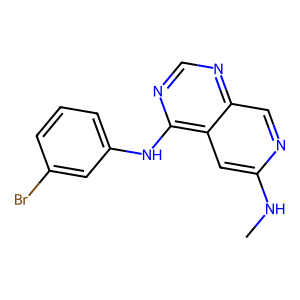

In [15]:
draw_molecule('CHEMBL53753', molecules=molecules)

## Question 1

How many molecules are there in the table? Which one binds the most tightly to the EGFR protein? Draw a picture of it

### Answer 1

In [17]:
len(molecules)

5558

In [19]:
molecules.sort_values("pIC50", ascending=False)

,Unnamed: 0,molecule_chembl_id,IC50,units,smiles,pIC50
0,0,CHEMBL63786,3.000000e-03,nM,Brc1cccc(Nc2ncnc3cc4ccccc4cc23)c1,11.522879
2,2,CHEMBL53711,6.000000e-03,nM,CN(C)c1cc2c(Nc3cccc(Br)c3)ncnc2cn1,11.221849
1,1,CHEMBL35820,6.000000e-03,nM,CCOc1cc2ncnc(Nc3cccc(Br)c3)c2cc1OCC,11.221849
3,3,CHEMBL66031,8.000000e-03,nM,Brc1cccc(Nc2ncnc3cc4[nH]cnc4cc23)c1,11.096910
4,4,CHEMBL53753,8.000000e-03,nM,CNc1cc2c(Nc3cccc(Br)c3)ncnc2cn1,11.096910
...,...,...,...,...,...,...
5553,5563,CHEMBL66879,3.000000e+06,nM,O=C(O)/C=C/c1ccc(O)cc1,2.522879
5554,5564,CHEMBL261238,5.000000e+06,nM,CN(c1cccnc1)c1cc2c(Nc3ccc(F)c(Cl)c3)c(C#N)cnc2cn1,2.301030
5555,5565,CHEMBL76587,6.500000e+06,nM,N#CC(C#N)Cc1ccc(O)cc1,2.187087
5556,5566,CHEMBL490510,1.900000e+07,nM,O=C(/C=C/c1ccc(O)c(O)c1)c1ccc(O[C@@H]2O[C@H](C...,1.721246


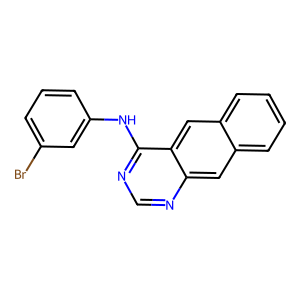

In [21]:
draw_molecule('CHEMBL63786', molecules)

##Calculate the 'Oral Drug' properties

A [famous paper](https://doi.org/10.1016/S0169-409X(96)00423-1) in 1997 proposed the 'Lipinski rules of 5', a simple estimate of how likely a molecule is to get to a protein target after being taken as a pill.

To follow these rules as molecule needs to have:

*   molecular weight < 500
*   < 10 hydrogen bond acceptors
*  < 5 hydrogen bond donors
*   -1 < logP < 5

Hydrogen bonds are types of interactions a molecule can make with proteins and other molecules - if it can make too many of these interactions it is unlikely to get into a cell and stay there.

LogP is a measure of how much a molecule likes to be in greasy environments compared in water, molecules need to be in the correct range of this propery to spread into different parts of the body without being broken down by the liver.

We can write a function to calculate these properties starting from a SMILES string of each molecule.





In [23]:
### Function adapted from TeachOpenCADD course https://github.com/volkamerlab/teachopencadd/tree/master/teachopencadd/talktorials/T002_compound_adme
def calculate_ro5_properties(smiles):
    """
    Test if input molecule (SMILES) fulfills Lipinski's rule of five.

    Parameters
    ----------
    smiles : str
        SMILES for a molecule.

    Returns
    -------
    pandas.Series
        Molecular weight, number of hydrogen bond acceptors/donor and logP value
        and Lipinski's rule of five compliance for input molecule.
    """
    # RDKit molecule from SMILES
    molecule = Chem.MolFromSmiles(smiles)
    # Calculate Ro5-relevant chemical properties
    molecular_weight = Descriptors.ExactMolWt(molecule)
    n_hba = Descriptors.NumHAcceptors(molecule)
    n_hbd = Descriptors.NumHDonors(molecule)
    logp = Descriptors.MolLogP(molecule)
    # Check if Ro5 conditions fulfilled
    conditions = [molecular_weight <= 500, n_hba <= 10, n_hbd <= 5, -1.0 <= logp <= 5.0]
    ro5_fulfilled = sum(conditions) == 4
    # Return True if all four conditions are satisfied
    return pd.Series(
        [molecular_weight, n_hba, n_hbd, logp, ro5_fulfilled],
        index=["molecular_weight", "n_hba", "n_hbd", "logp", "ro5_fulfilled"],
    )

In [25]:
ro5_properties = molecules["smiles"].apply(calculate_ro5_properties)


In [26]:
molecules_ro5 = pd.concat([molecules, ro5_properties], axis=1)

We can now count how many molecules pass the rule, and how many do not

In [29]:
len(molecules_ro5.query("ro5_fulfilled == True"))

3043

In [31]:
len(molecules_ro5.query("ro5_fulfilled == False"))

2515

In [33]:
molecules_ro5.query("ro5_fulfilled == True")

,Unnamed: 0,molecule_chembl_id,IC50,units,smiles,pIC50,molecular_weight,n_hba,n_hbd,logp,ro5_fulfilled
1,1,CHEMBL35820,6.000000e-03,nM,CCOc1cc2ncnc(Nc3cccc(Br)c3)c2cc1OCC,11.221849,387.058239,5,1,4.93330,True
2,2,CHEMBL53711,6.000000e-03,nM,CN(C)c1cc2c(Nc3cccc(Br)c3)ncnc2cn1,11.221849,343.043258,5,1,3.59690,True
3,3,CHEMBL66031,8.000000e-03,nM,Brc1cccc(Nc2ncnc3cc4[nH]cnc4cc23)c1,11.096910,339.011957,4,2,4.01220,True
4,4,CHEMBL53753,8.000000e-03,nM,CNc1cc2c(Nc3cccc(Br)c3)ncnc2cn1,11.096910,329.027607,5,2,3.57260,True
5,5,CHEMBL176582,1.000000e-02,nM,Cn1cnc2cc3ncnc(Nc4cccc(Br)c4)c3cc21,11.000000,353.027607,5,1,4.02260,True
...,...,...,...,...,...,...,...,...,...,...,...
5551,5561,CHEMBL75718,2.400000e+06,nM,N#C/C=C/c1ccc(O)cc1,2.619789,145.052764,2,1,1.92898,True
5552,5562,CHEMBL120564,2.600000e+06,nM,COc1cc(C=C(C#N)C#N)cc(C)c1O,2.585027,214.074228,4,1,2.13978,True
5553,5563,CHEMBL66879,3.000000e+06,nM,O=C(O)/C=C/c1ccc(O)cc1,2.522879,164.047344,2,2,1.49000,True
5555,5565,CHEMBL76587,6.500000e+06,nM,N#CC(C#N)Cc1ccc(O)cc1,2.187087,172.063663,3,1,1.59806,True


We can look at some distribution of the properties

Text(0, 0.5, 'Count')

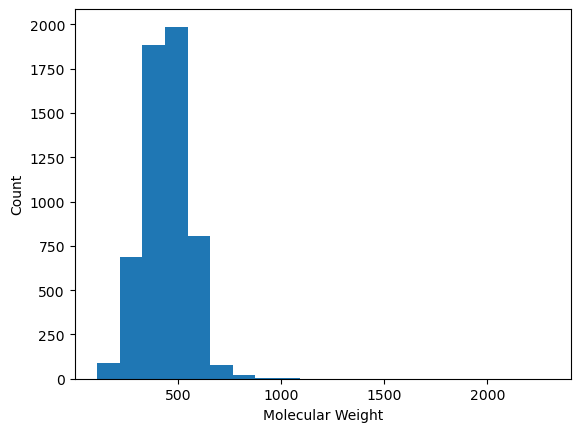

In [35]:
plt.hist(molecules_ro5.molecular_weight, bins=20)
plt.xlabel("Molecular Weight")
plt.ylabel("Count")

Text(0, 0.5, 'Count')

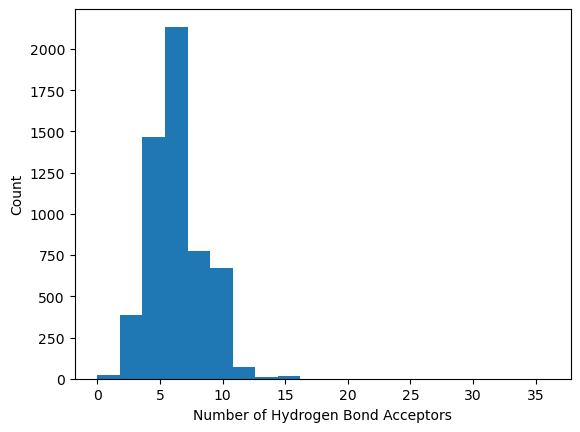

In [37]:
plt.hist(molecules_ro5.n_hba, bins=20)
plt.xlabel("Number of Hydrogen Bond Acceptors")
plt.ylabel("Count")

## Efficient binding
At the start of a drug discovery program it is often desirable to start with an small, 'efficient' binding molecule, which has the largest fraction of its atoms interacting favourably with the target protein.

One simple measures of efficiency is lipophilic ligand efficiency [Leeson, P.D.et al.](https://www.nature.com/articles/nrd2445)

LLE = pIC50 - logP

We can calculate this quantity for our molecules and find the most efficient binders.







In [39]:
molecules_ro5["LLE"] = molecules_ro5.pIC50 - molecules_ro5.logp

In [41]:
molecules_ro5.sort_values("LLE", ascending=False)

,Unnamed: 0,molecule_chembl_id,IC50,units,smiles,pIC50,molecular_weight,n_hba,n_hbd,logp,ro5_fulfilled,LLE
3899,3904,CHEMBL2221249,1500.00,nM,CC(C)CCCCC(=O)N[C@@H](CCN)C(=O)N[C@@H](CN[C@@H...,5.823909,2295.556975,36,36,-10.32610,False,16.150009
4062,4067,CHEMBL1200679,2188.40,nM,[Cl-].[Cl-].[Zn+2],5.659873,133.866848,0,0,-5.99450,False,11.654373
16,16,CHEMBL55729,0.10,nM,Nc1ccc2cncnc2c1,10.000000,145.063997,3,1,1.21200,True,8.788000
818,819,CHEMBL590878,6.27,nM,Oc1cc(O)c2cc(O)c(-c3cc(O)c(O)c(O)c3)[o+]c2c1.[...,8.202732,338.019330,6,6,-0.38150,False,8.584232
1508,1511,CHEMBL4282506,23.00,nM,N#CCC(=O)N/N=C1\C(=O)Nc2ccc(S(=O)(=O)N3CCOCC3)...,7.638272,377.079390,7,2,-0.60642,True,8.244692
...,...,...,...,...,...,...,...,...,...,...,...,...
4926,4936,CHEMBL293251,11400.00,nM,Cn1c(SSc2c(C(=O)Nc3ccccc3)c3cc(Br)ccc3n2C)c(C(...,4.943095,717.970742,6,2,9.49900,False,-4.555905
5428,5438,CHEMBL156555,100000.00,nM,O=C(CCCc1c(SSc2[nH]c3ccccc3c2CCCC(=O)NCc2ccccc...,4.000000,646.243618,4,4,8.72680,False,-4.726800
5449,5459,CHEMBL422540,100000.00,nM,c1ccc(-c2c(SSc3[nH]c4ccccc4c3-c3ccccc3)[nH]c3c...,4.000000,448.106791,2,2,8.78260,False,-4.782600
5458,5468,CHEMBL293986,100000.00,nM,Cn1c(SSc2c(C(=O)Nc3ccccc3)c3c(Cl)cccc3n2C)c(C(...,4.000000,630.071773,6,2,9.28080,False,-5.280800


##Question 2
The best molecule to use as a starting point from this data set might be the ones that passes the Lipinksi rules of 5, and has the highest LLE.

Can you find this molecule in the table and draw a picture of it?

### Answer 2

In [43]:
molecules_ro5.query("ro5_fulfilled == True").sort_values("LLE", ascending=False)

,Unnamed: 0,molecule_chembl_id,IC50,units,smiles,pIC50,molecular_weight,n_hba,n_hbd,logp,ro5_fulfilled,LLE
16,16,CHEMBL55729,0.100,nM,Nc1ccc2cncnc2c1,10.000000,145.063997,3,1,1.21200,True,8.788000
1508,1511,CHEMBL4282506,23.000,nM,N#CCC(=O)N/N=C1\C(=O)Nc2ccc(S(=O)(=O)N3CCOCC3)...,7.638272,377.079390,7,2,-0.60642,True,8.244692
158,158,CHEMBL53300,0.790,nM,Nc1ccc2ncncc2c1,9.102373,145.063997,3,1,1.21200,True,7.890373
2,2,CHEMBL53711,0.006,nM,CN(C)c1cc2c(Nc3cccc(Br)c3)ncnc2cn1,11.221849,343.043258,5,1,3.59690,True,7.624949
4,4,CHEMBL53753,0.008,nM,CNc1cc2c(Nc3cccc(Br)c3)ncnc2cn1,11.096910,329.027607,5,2,3.57260,True,7.524310
...,...,...,...,...,...,...,...,...,...,...,...,...
5518,5528,CHEMBL7981,500000.000,nM,COc1cc(OC)c2c(=O)c(-c3cccc(Cl)c3)coc2c1,3.301030,316.050237,4,0,4.13060,True,-0.829570
5477,5487,CHEMBL1254444,143500.000,nM,COc1ccc(OC)c(Cc2cc3c(N(C)c4cccc(Br)c4)nc(N)nc3...,3.843148,467.095687,6,2,4.67850,True,-0.835352
5470,5480,CHEMBL1956889,113300.000,nM,Cc1ccccc1Cn1ccc2c(Nc3cccc(Br)c3)nc(N)nc21,3.945770,407.074558,5,2,4.87632,True,-0.930550
5498,5508,CHEMBL1254286,253600.000,nM,CN(c1cccc(Br)c1)c1nc(N)nc2c1cc(Cc1ccccc1)n2C,3.595851,421.090208,5,1,4.67170,True,-1.075849


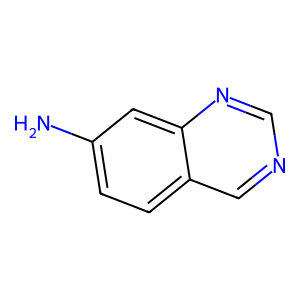

In [45]:
draw_molecule('CHEMBL55729', molecules=molecules_ro5)

## Question 3
Not all data in drug discovery is reproducible, often it emerges that there has been a problem with a particular set of measurements.

Imagine that we found out that all measurements of pIC50 > 9.0 were unreliable and these molecules should be ignored until they could be retested. What would then be the current best molecule starting point?

### Answer 3

In [47]:
molecules_ro5.query("pIC50 < 9.0").query("ro5_fulfilled == True").sort_values("LLE", ascending=False)

,Unnamed: 0,molecule_chembl_id,IC50,units,smiles,pIC50,molecular_weight,n_hba,n_hbd,logp,ro5_fulfilled,LLE
1508,1511,CHEMBL4282506,23.00,nM,N#CCC(=O)N/N=C1\C(=O)Nc2ccc(S(=O)(=O)N3CCOCC3)...,7.638272,377.079390,7,2,-0.60642,True,8.244692
668,668,CHEMBL4102886,4.87,nM,C#Cc1cccc(Nc2ncnc3cc(OCCCN4C[C@H](O)[C@@H](O)[...,8.312471,494.216535,10,5,0.89140,True,7.421071
1145,1148,CHEMBL3989970,12.00,nM,C=CC(=O)N[C@@H]1CN(c2nc(Nc3cn(C)nc3OC)c3ncn(C)...,7.920819,415.188049,10,2,0.67790,True,7.242919
795,796,CHEMBL3608434,6.00,nM,C=CC(=O)N[C@@H]1CN(c2nc(Nc3cn(CC)nc3OC)c3ncn(C...,8.221849,429.203699,10,2,1.16080,True,7.061049
941,944,CHEMBL4205392,8.00,nM,C=CC(=O)N[C@@H]1CN(c2nc(Nc3cn(C)nc3OC)c3ncn(CC...,8.096910,429.203699,10,2,1.16080,True,6.936110
...,...,...,...,...,...,...,...,...,...,...,...,...
5518,5528,CHEMBL7981,500000.00,nM,COc1cc(OC)c2c(=O)c(-c3cccc(Cl)c3)coc2c1,3.301030,316.050237,4,0,4.13060,True,-0.829570
5477,5487,CHEMBL1254444,143500.00,nM,COc1ccc(OC)c(Cc2cc3c(N(C)c4cccc(Br)c4)nc(N)nc3...,3.843148,467.095687,6,2,4.67850,True,-0.835352
5470,5480,CHEMBL1956889,113300.00,nM,Cc1ccccc1Cn1ccc2c(Nc3cccc(Br)c3)nc(N)nc21,3.945770,407.074558,5,2,4.87632,True,-0.930550
5498,5508,CHEMBL1254286,253600.00,nM,CN(c1cccc(Br)c1)c1nc(N)nc2c1cc(Cc1ccccc1)n2C,3.595851,421.090208,5,1,4.67170,True,-1.075849


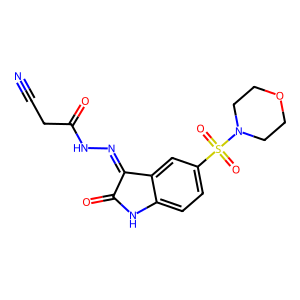

In [49]:
draw_molecule('CHEMBL4282506', molecules=molecules_ro5)